In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [3]:
def find_highest_peaks(x, y, prominence=0.5):
    peaks, _ = find_peaks(y, prominence=prominence)
    peak_x_coordinates = x[peaks]
    peak_y_coordinates = y[peaks]
    return peak_x_coordinates, peak_y_coordinates

In [4]:
def plot_distribution_with_highest_peaks(x, y, peak_x, peak_y):
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, label='Data')
    plt.scatter(peak_x, peak_y, c='red', marker='x', label='Highest Peaks')
    plt.title('Distribution with Highest Peaks')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.legend()
    plt.show()

In [5]:
def mean_weighted_peak_difference(x, y, prominence=0.1):
    # Find the peaks and their corresponding y-values
    peaks, _ = find_peaks(y, prominence=prominence)
    peak_x_coordinates = x[peaks]
    peak_y_values = y[peaks]

    # Calculate weighted differences between adjacent peaks
    weighted_differences = []
    for i in range(len(peak_x_coordinates) - 1):
        diff_x = abs(peak_x_coordinates[i + 1] - peak_x_coordinates[i])
        weight = (peak_y_values[i] + peak_y_values[i + 1]) / 2.0  # Use average y-value as weight
        weighted_diff = diff_x * weight
        weighted_differences.append(weighted_diff)

    # Calculate the mean of the weighted differences
    if weighted_differences:
        mean_weighted_diff = sum(weighted_differences) / len(weighted_differences)
    else:
        mean_weighted_diff = 0.0


    return mean_weighted_diff, peak_x_coordinates, peak_y_values


In [6]:
#CONFRONTARE L'OUTPUT DI QUESTA FUNZIONE (mean_weighted_diff) CON IL CONSENSO INTRA COMMUNITY

def mean_weighted_peak_difference_all_pairs(x, y, prominence=0.5):
    # Find the peaks and their corresponding y-values
    peaks, _ = find_peaks(y, prominence=prominence)
    peak_x_coordinates = x[peaks]
    peak_y_values = y[peaks]

    # Calculate weighted differences between all pairs of peaks
    weighted_differences = []
    for i in range(len(peak_x_coordinates)):
        for j in range(i + 1, len(peak_x_coordinates)):
            diff_x = np.abs(peak_x_coordinates[i] - peak_x_coordinates[j])
            weight = (peak_y_values[i] + peak_y_values[j]) / 2.0  # Use average y-value as weight
            weighted_diff = diff_x * weight
            weighted_differences.append(weighted_diff)

    # Calculate the mean of the weighted differences
    if weighted_differences:
        mean_weighted_diff = sum(weighted_differences) / len(weighted_differences)
    else:
        mean_weighted_diff = 0.0

    return mean_weighted_diff, peak_x_coordinates, peak_y_values

In [7]:
def normalize_distribution(x, y):
    # Normalize the x-axis values to the range [0, 1]
    x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))

    # Normalize the y-axis values to the range [0, 1]
    y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))

    return x_normalized, y_normalized

In [8]:
#communities = [['carlosbaseball7', 'charliekirk11', 'cedricknight12', 'rosaabel71', 'lbicommusa', 'buffalobill4729', 'broganmcmonigle', 'fridayorange', 'unifyforfreedom', 'algerithem', 'fangelico17', 'mikecurrier10', 'joeycawbs', 'gizman62', 'katzjunk', 'reachluke', 'staceyceee', 'nick_boro1', 'deplorabledad74', 'mickeypmickeyp', 'tracyboutelle', 'ralongo', 'reynolds_daver', 'poop_ville', 'lindaaubin3', 'tyler_nunnelley', 'bpratto', '3coshank', 'whodey21', 'big_bob_bos', 'apexkrk', 'liflngfanjw', 'thx1138logan', 'keepamericafree', '3catzmom', 'buyaolian', 'chuckranger1880', 'americanepilog', 'harlaj', 'johnvburger', 'pollam1', 'vanitynvexation', 'gmthompson7', 'fredstewart1712', 'icspike', 'mrscommonsense2', 'gerri_warunek', 'lj2626', 'fla8958', 'rawoods24', 'teresa82360646', 'lonesomelols', 'bokid2125', 'beastasmyself', 'discipler22', 'andie561', 'pjw59', 'vh18172951', 'royaltruthwarr1', 'jdeharo26', 'garyjay7', 'hkwizard3', 'idannyb', 'scipper_matt', 'charlie_69gprix', 'therealjamess95', 'ronibf', 'remmertrod', 'edwinq4769', 'ferdbrf', 'socaldb44', 'mycrittersmom', 'trexgma17', 'mimiknows1', 'thegreywolf1776', 'gnye56', 'cbward0374', 'glfrjohn', 's7bake', 'mredpilld', '2000_toria', 'guardianangelos', 'crotalidae75', 'whistledecoder', 'debk2020', 'scubacos1', 'isaacbryan18', 'sched13', 'aaronwl42', 'vcmom', 'lianar05', 'res43188487', 'johnbuck_usa', 'lookinbad', 'jones_giorgio', 'johnnyreb0101', 'tmvmom', 'jerryhull14', 'hollanddekeyzer', 'bogey7acsc2005', 'americanvictory', 'rgood64', 'gupdiver', 'donnamu07081383', 'oohrah1990', 'flbigbass', 'yesysisfearless', 'nancywalzer', 'aaronmeier48', 'gladys_ech', 'mrmike62250607', 'kale3nona', 'wellnesswithnic', 'bitterron', 'per_ann', 'will96617019', 'karen1234505', 'randalrukstele', 'jonag02', 'patriotsareback', 'pamdurant16', 'zawarlo', 'trishawillie', 'aarondewinter', 'ourchildren17', 'jedwardgriffith', 'vswan73', 'addy37088390', 'kkph76067', 'beverlyjk92', 'ed_ranz', 'cihak_l', 'blunt_truha', 'climateskeptic4', 'wiergeezy', 'mike82479147', 'gaynorgoldstar', 'lovescienceart', 'cindisabol', 'beau_rowell', 'aafmn9', 'jamiezi12108528', '17onspiracyfact', 'wendyaperryme', 'patriot_1945', 'mberg777', 'toni38054246', 'chrometiger_17', 'joeneto', 'wutuwantedtosay', 'petedky', 'jrock2456', 'txbob451', 'jsbbubba', 'dadisangry', 'kcmarrs', 'larsonandrewc', 'daveheaps1', 'fosheejohn51', 'dontletthesmok1', 'cyouloulou', 'vicki4880', 'readerima', 'chrisseegee', 'ellicojohn', 'weddingcasey', 'schumakerrob', 'huddyhayes', 'ccdeplorable18', 'baltz526', 'ktrumpgirl', 'beckynipp', 'pdossantos65', 'mspatriotusa18', 'russack', 'dellbel', 'womille', 'kneeboy12', 'mento7370', 'cutller51', 'redplanet4', 'jhopdog1', 'spinmomof5', 'zenmom1', 'larosabob', 'truetexanchick', 'matth2osii', 'mostainback', 'vintagedrummer7', 'sbbit1996', 'patrioticcougar', 'cydonia20627691', 'randybleyer', 'eriningalls', 'maggie74954877', 'magkir1', 'nancyal01565659', 'peten1981', 'bethemiracle910', '1_2_amendments', 'maryandbessie', 'micahmath', 'mirelotus', 'cskinkis', 'ment2befarms', 'nationalogical', 'kveldulf7', 'bettyle60527300', 'gracieloudotcom', 'jym_shoe', 'jphillips663', 'donscantyg', 'jshartle', 'eli80322094', 'dynomite94', 'spolitics1', 'rogerthatwtf1', 'lolli_pops5', 'zacclary11', 'badkid312', 'southgalmotifs', 'cartledgeal', 'nannid62', 'ejanactor195004', 'rwtalley1986', 'marksharpton', 'samanth94572263', 'jcanose', 'charliegkappler', 'jonmatthews1974', 'smbasschaser', 'mzee26', 'bbloss31', 'jwooten33', 'mcbred1michael', 'speemichael', 'rnhaap', 'sherrylowe42', 'kresl61', 'maryferra7', 'realwilliamwar1', 'don_reau', 'kathynd2011', 'nlwaugh', 'centristfuck', 'jmsxh', 'mbaker2157', 'padulasal', 'matrix_citizen', 'aforce4fweedom', 'drrickg', 'rbonau', 'freedomlovinga1', 'zagfanman', 'rockett2561', 'samhain8182', 'reverandjohnny', 'rightmomof2', 'jas880711', 'mrpaulgallagher', 'patnjak', 'loganremi', 'mick6298', 'bjcowan1970', 'marieelenapres1', 'paul_rey1', 'donjcast002', 'otisbt13', 'rabal69', 'catladyntexas', 'miladybell', 'mamaoma', 'jjauthor', 'regula_iuris', 'u2rma', 'bushwhacker55', 'eric33091', 'jimbodm', 'trumpsmidfinger', 'momatmom', 'gdcox1', 'onnoleecarter', 'hartdrea', 'generaltt', 'commonsensenon', 'th_harney', 'mndhls', 'jul_kut', 'missparklequeen', 'scootersangel', 'scottbe63836016', 'carmgoog', 'jodywohlenhaus', 'kenmarden2', 'softlinkie', 'pixies74', 'tbblount', 'adamcrna', 'pjmckain', 'packatt70003556', 'laworder33', 'usapatriot0013', 'jackieberger16', 'troublegy6801', 'lonepalmisland', 'radekinkennie', 'gertrude_lyles', 'charlesthefew', 'thebillyjarrell', 'embtrout', 'perdupa521', 'matthewwnimmo', 'donnamek', 'ssgwil', 'dkubaska', 'girlgettingby1', 'albg_mr', 'popsnmimis', 'deadpreacher', 'termlimited', 'yostman', '1kimsey', 'justjen220', 'jwolfej', 'tammy68789663', 'cgriffinrn', '1ruffrican', 'sccinc53', 'samjundi', 'chiquioliver', 'graciemckay7', 'texasflutegal', 'richgodfrey57', 'kyrose87', 'dreamwe90194079', 'pbennett18', 'joshua58339026', 'seasidestand05', 'page_kimiko', 'heidi_rasor', 'lisapri89070554', 'steelersrays', 'jimmythekiduf', 'rootedinthenw', 'yourauntiemame', 'mtdevere', 'jcdex1974', 'sahoward2101', 'sunnyokie', 'susielconklin', 'getrightcbd', 'brant_mansell', 'tdkkjk', '33butterscotch', 'robcao305', 'johnoco27453655', 'mfbirk', 'howheres', 'jerryharleydlux', 'yellowonion45', 'murf1955', 'esanchez751', 'zab20122', 'alberto41941952', 'tomkay05869718', 'reallyred1', 'kimberleyanva', 'grcavalier', 'dgarr22', 'jeffreyrbaker', 'pbach1911', 'kemosaaby', 'dawn_of_america', 'gggspur', 'kobyci', 'jlsandia', 'jim71469172', 'billhutto1', 'j94303156', 'advocateeve', 'actuallycla', 'randsizemore1', 'victorvr', 'kitty02122736', 'kaga60maga', 'janieelizabeth1', 'lecorsaire', 'slw2547', 'internalcontol1', 'the_rob_cat', 'john_koeck', 'matttaylor_la', 'student5520', 'lisaannega', 'drhoffman18', 'danielbrown777', 'gc2342', 'denise_tierney3', 'rykait0407', 'g_wilikers', 'pkpt9svaxev9b9j', 'hunterelias25', 'drumheller_rae', 'baccigregg', '67flyersfan', 'ltc2tluna', 'celegallardo', 's_soteria', 'sherrardsebooks', 'gtphonehome55', 'lynnnel58681036', 'hanchenxiao', 'redeldorado', 'kranmars33', 'deplorablemom3', 'joedaniels100', 'sonshinepatriot', 'birdturd1818', 'jes68418445', 'craigbarbaro', 'elizabe45314738', 'txjuner', 'brazellmike', 'biconbic', 'petertang609', 'davedjstrz', 'maxishel', 'bigmike1034', 'baggieshaun', 'belle64563701', 'john_n_mark', 'pat_crahan', 'kerrinhester', 'robyncatlett1', 'ilvosu', 'inscnc', 'hidingbyden', 'laurakr1010', 'towerguy1947', 'rnamerican', 'jo11635271', 'maggieestar70', 'kbierley', 'corzine_r', 'lanoumatt', 'macnetglobal', 'irishronan1', 'atomicnews', '5timechampions', '2molinari', 'sherry29692093', 'billyboysdaddy', 'h__krause', 'laurieever', 'trusty_ramona', 'simplylorilee', 'nancynaples2', 'roslyn10478423', 'sharonlerner11', 'yepsuzn', 'tcehreh', 'mariewalker', 'josephtrainor11', 'joannfarmer20', 'janjudd3', 'jlangei3', 'keavster', 'howell_ed', '69d8169ba760426', 'shannonspullia1', 'lisa_avery31597', 'elmacode', 'elvin_cramer', 'audradawning', 'laurelholub', 'derekle30414249', 'randygrey2', 'johnsaracco11', 'frassisi', '07620594106a463', 'urdutalker', 'wakeupandriseup', 'quest1743', 'kmf9917', 'cogb123', 'spa_nky74', 'rosiemouse', 'joan_hardin', 'michell6272', 'canadianyyz', 'brusslan', 'newportranger24', 'jettbobbette', 'boomercyclist', 'kelleyd50', 'mikeronin1359', 'marty58081375', 'withallmarbles', 'lucy64467623', 'patrioticrose', 'rumbelleion', 'debivino1961', 'jw_apachepilot', 'mkglrfpf2qsfonj', 'cusinoc', 'athudfumtz', 'coltfn1', 'jamieroderickmc', 'taxticaltoe', 'darren_d76', 'scottmc9', 'gamblegamble20', 'kpgroves', 'gtmac21', 'ggnalley', 'laurietotton', 'mary29593978', 'burnitin97', 'gigi410', 'markslinger1', 'joan39433805', 'kimt0024', 'deniseb3033', 'pgt1956', 'michaelpalmer', 'pennyr623', 'ik238', 'stephanie_cr71', 'jasondean227', 'sallyweeround2', 'patrici09344079', 'posillico125', 'gristman', 'scottburrow', 'alofslisa', 'kimdee2', 'twogirl91', '99godsgirl001', 'brianwi53755611', 'margie_meak', 'roxierolo', 'maryemmons10', 'gsmades1', 'wzey9', 'zod5150', 'dianewsexton', 'tr16963539', 'gmr1209', 'markwil72955497', 'myceedsworld', 'glasshalffull57', 'picardsa', 'jonstro43933750', '46kaydd', 'geralynann', 'anthonypk1', 'bjenevein', 'nick00751471', 'borgmankelly', 'sapereaude1947', 'janekennedu', 'jsoliz', 'madhula73460014', 'brando1121', 'rosebud101', 'dlea4', 'zawislav', 'dr552021', 'lazyfirewoman', 'larryedmiston', 'sbkaye', 'sean61987', 'mybrowneyes31', 'colleent74', 'pulv43', 'igobymdot', 'hlpryor', 'semper_doodle', 'tjpb1982', 'rekttreater', 'sharpiestate', 'jenniferbisop', 'davishirley1961', 'mcduffeytc', 'pappydru', 'illit5', '72chevelle2', 'bbharme', 'stephanielwhit1', 'kathyhaworth8', 'jen_bluey', 'daminous_purity', 'andyeggert1', 'pacflyway', 'pitycruzy', 'sherrih68695542', 'muffypih', 'misterf2020', 'sebegozwide', 'realarizonadan', 'norvr', 'glycomen', 'eg_trades', 'janss01', 'semperfi1974', 'zenbarbecue', 'dorunda', 'mattlhyde', 'robertt89252313', 'kbmgtl', 'rachelclucas2', 'mamatuck4bama', 'bellagigi4545', 'nuclearkeever76', 'maxhawk4', 'fcmc81', 'bobataustin', 'kritters921', 'gregflippen', '4x4tiger78', 'marcield11', 'czaplickirob', 'laciletti', 'trevinobill', 'jackcar90016844', 'georgin59405062', 'zoiecuts', 'kcroyalsfanatic', 'golfgirlrobin', 'iamforya', 'jimaverett', 'kingaj40', 'cosmotopper55', 'mjthomas456', 'ceasara291', 'libertyselfgov', 'barker2a', 'johnmsertich', 'magaseanluka', 'jenniferstude12', 'sukimoto1000', 'jodydelraybeach', 'willcleveland17', 'jplalo34', 'jlpitt2', 'shericl92411783', 'brittzter', 'utraditionalist', 'realteecee', 'nmmom4', 'berniereporter', 'luckymleather', 'hankybeth', 'franiepride', 'eddjinxedd9', 'kbweingart', 'naw1961', 'alwal34642965', 'chicken42147880', 'poohbear568', 'frey_martha', 'cullino12', 'rg729', 'lsferguson', 'grandpa123larry', 'wildermelissa35', 'boottmills228', 'tcmbrowneyes', 'taliasun0', 'mariama36787638', 'londonpam3', 'cajunshelly', 'geecee93167059', 'inesdunder', 'ready_for_us', 'rosemaynard17', 'rhummer48', 'karenminser', 'toddfryer4', 'pajaritoazul76', 'legbone06', 'conservm1', 'csnvest', 'dccalamity_us', 'pihong98', 'wyattferguson21', 'buckeye_guy2012', 'keel_breanna16', 'vickiemccormic1', 'miguelonlobo', 'karenkyia', 'op4ftdix', 'pkdelu', 'egersch', 'tosca22021362', 'gfromphilly', 'gregslack10', 'steveb71969175', 'arlenefarrowgal', 'jimmyb_1952', 'sherillp888', 'mag92160335', 'beckyj1961', 'hatenevrworks', 'stefannss', 'iaddison_05', 'salesman19621', 'coltsfanjlynrn', 'jameswr16739404', 'bebra_snyder', 'johnrchase', 'jbow45', 'cougar7mike', 'cindiew', 'ces2828', '23dwilk', 'gera23_vega', 'capiniajoan', '777denny_', 'greatestpresidt', 'evilemur', 'fgasparr', 'utahpatriot2', 'wazzucougs86', 'chicagotech27', 'k45cal', 'doug__herty', 'noxa_nonne', 'speckledsnake', 'rich48522244', 'track17k', 'pwejgt', 'aiaj89', 'jn_global', 'steveandlori1', 'ponyx4821', 'shsoab', 'erin777believe', 'veteransusan', 'atjovic', 'beckerestate1', 'ccbnutz1', 'butterfingers70', 'gwaunch', 'kpatriot17', '4daluvofcontext', 'patrickshowlet2', 'angellite48', 'jeannetteziemba', 'jebladat', 'depmelinda', 'tharuf', 'healthyvibenet', 'theicedkermit', 'deejones7965', 'kcs45art', 'stevenredding33', 'stoxman1', 'nerfherder877', 'mburt01', 'wiredterrier', 'greycole05', 'stpaulsdog', 'tinatrich55', 'rooney_in_wi', 'pathealyracer', 'alerstner', 'drericsparredd', 'ladypatriot20', 'borntoknow2', 'bigal92', 'scoobywooby12', 'jamesbarragan7', 'creammoneyteam', 'roneevans', 'scottharen', 'jimnter', 'naes_wolf', 'real_s_hurley', 'maddox_michele', 'theox07239116', 'j_9infl', 'darlenecookie59', 'cshaulter', 'gadhoover', 'lusterell', 'savanahlthomas', 'nnszp2xvqz7rlc5', 'ms_bizzy57', 'jonituttjoni', 'wpaul33', 'angelazulpo', 'juliachristos', 'trump4eva17', 'thechuckmartel', 'alexs1776', 't53sca', 'soxwillsuxin23', 'calibilly', 'niklaszoe', 'emmersophie', 'twp5253', 'keryordehgmail', 'ntrsrich302', 'nikwong89', 'josemarianelson', 'cropcarekev', 'julioscores', 'md90266', 'sturm_will', 'getahaircutnsh1', 'christinajobs', 'flipartist', 'disneybabes4', 'molokofoster', 'roundtablerock1', 'kormanikdaniel', '48_oiiiiiiio', 'jojojoperk', 'bjenkinstn', 'paratusnow', 'frankschiraldi', 'chic132', 'missthelmalou', 'zekegary2', 'bluesage07', 'klbelser', 'gmaruth57', 'ind_2020_', 'lwckatsfan', 'carlag1003marie', 'mikew33d', 'johnhhamer', 'gabssydney26', 'lisadot08984156', 'raghuaiyar', 'carol71418219', 'cdgar173', 'saljones309', 'hoguejennings', 'aferr18', 'bobbyw777', 'katzen83', 'jwervin', 'rodri_cohen', 'hobetz', 'wjbubba520', 'j_allen2313', 'mary49127424', 'momof579530224', 'ruthking907', 'kathyni93576935', 'nanacovfefe', 'bkey213', 'debbie1831', 'debramoge', 'djklarson', 'jennife79349532', 'dawnbuc72103554', 'duwaynewacha', 'davisdmnieves', 'memes_4_luke', 'dave_201_2020', 'spechtperry', 'johncla23552870', 'tennis4life2', 'mccainelvena', 'zepdawg52', 'hydrant328', 'sam92teg', 'keylor363', 'donof38', 'mrico18', 'linda_teasley', 'lelesayshi', 'mark_vasko', 'glo_mojo', 'marykeystone', 'alexrobertgray', 'kgrossnick', 'zchris971', 'pflamula1', 'crown_country2', 'gelvieh', 'mrcrjr', 'kevincrull', 'bbticmrm', 'wendym74883052', 'jleefer', 'fate74267847', 'kreifelsshawn', 'larryhunt777', 'hoosierindepen', 'carolelking2', 'jfh9042020', 'realistrach', 'mikelit78991244', 'dennisbohannon', 'bracamelody', 'jimmyhi01111408', 'rightone40', 'pamjbo', 'outlander66', 'charlene1939', 'joenatoli1', 'patchristophe12', 'brinkley4r3', 'atlaskairos', 'dianna85357641', 'elisabjean', 'jack84242662', 'rtownsend2112', 'garysmed', 'gwenjarrett', 'kellisw33', 'revjk7', 'vauxhall23', 'abarone245', 'andreahanna5', 'jim_o71', 'bitcoinvava', 'holly2360', 'iowafeedsworld', 'jameskyte1', 'katylma', 'avery55221334', 'freedomcounts76', 'varks3', 'pingan2020fo', 'jaustin2424', 'brianrussell15', 'tom43921822', 'kimbrow00458847', 'jedforesti', 'summerfontenot', 'randyhagar', 'pittsfansandy1', 'maga_nc_firefly', 'riadancy', 'charlie01106984', 'kellytmccroskey', 'bspjohn', 'bobbyjoepaul1', 'nsheroffice', 'cjr1969', 'jtasammy3', 'mr_jmburnside', 'brettba83030478', 'morningnmay', 'byronfromth', 'pushinon', 'scibadeb', 'bhahn23', 'slh65873749', 'cherir_lovelife', 'therealpetepro', 'dianecolette1', 'johnhklems2024', 'robertjwilmot2', '6irl6', 'kelly_melerine', 'kalolakini', 'razingk', 'alcazar_susan', 'phildeb1', 'iamrightofwrong', 'huddy82051871', 'jackjackpan1', 'cloudsuferdude', 'jeb3244', 'leezades', 'jrpinternation1', 'vintage_nathan', 'couchcoach703', 'lisarodrealtor', 'experiencebaker', 'nancylynn1010', 'boarder254', 'jengwiz17', 'dabanksterman', 'cmumps65', 'usaproudone', 'sheri24036754', 'maysidi', 'jbooker63', 'mailmanprl', 'winincal', 'nina54053525', 'butterman50p', 'macelibu', 'rossverba', '16_dreams_', 'sunnyranger1', 'joannab43506013', 'habz1959', 'kyleanness', 'efaasse', 'liesbychuck2', 'lanah06101225', 'brandt_paul', 'joannaad75', 'lauralush12', 'tjaynecurtis', 'justinmattern5', 'colinborgeson1', 'brenda516sano', 'ermmason', 'shannon15153', 'kimboj4', 'terrytlbishop', '4evrbrownnproud', 'rmji27', 'maidenoils', 'julse48', 'principemarie', 'tomwilk86849308', 'ckmichels', 'billwjohnson', 'mydogiscoffee', 'ellerkent', 'realjohne1', 'heaandbooks', 'hansen_jair', 'joyca13', '1princefan1', 'chargerfan11484', 'haim_is_life', 'jeff81370671', 'bluebonnets4evr', 'ftemhjbbopiojos', 'janicehopper19', 'trumpyoudahman', 'jimchristopher7', 'busterabbott99', 'geewhizzard', 'rosyberth', 'sara09643488', 'larssonsa1', 'daphilguy', 'nanmanning11', 'tubbs_susan', 'davidhsandler', 'hawkeyefbl', 'houcoog2581', 'nqgrube', 'hunter2baseball', 'lynnroman14', 'kathie_1960', 'rlo110', 'randytaylorokie', '1988baileypk', 'harter_sandra', 'jocelelyon', 'joegeebitw1982', 'flatbush4ever', 'yankechik23', 'brent95166815', 'pechindan', 'boboverstreet3', 'cullen_stone23', 'boomersooner', 'jmiller_0980', 'bidenreallysux', '453myers', 'kparsons60', 'haynesparker1', 'tplesh7', 'newtkobe7777', 'mimmulus', 'mtallman294', 'jflobeard11', 'lydialai68', 'carolyn09066355', 'stephan53774764', 'jerryb_42', 'cozy1614', 'johnwilmers', 'corabel05750505', 'snappah1', 'nbros661', 'lynnmrogers1000', 'janicesheppar13', 'tedblake1968ted', 'thejoelclayton', 'patricktrooney', 'rodnbettywatts', 'garland_marlene', 'barbaraegutier1', 'jsm01977', 'sirois_ryan', 'bugsiwhp', 'nonhero69', 'captbobdad', 'vedderfreddy', 'wdbronx65', 'stevesmithereen', 'gin016', 'esteban41580721', 'josevizca27', 'cody_hedalen', 'sjkurtz56', 'mikeyz2414', 'tmroberts1020', 'ibafishnfool', 'cathyr211', 'remenpriore', 'tim10763736', '_sere', 'larrycostigan', 'susiejustsayin', 'deniseforman9', 'teacherdkh1130', 'happyladyto', 'tlcash05', 'kathygriffith69', 'doogcap', 'uncg66', 'lorraine_symes', 'whateverklown', 'someguyinlimbo', 'carvellafrank', 'chaimweiz', 'brdchampagne', 'ann22332656', 'bonitajochambe1', 'paulaarton3rd', 'foolsball11', 'one_nj_girl', 'debbster_k', 'phatmommy3', 'irla1', 'mellisagylland', 'roses_655', 'msr030505', 'gatergirlkansas', 'neal437', 'jacquesmaravic', 'allyleelemon', 'ccochrane64', 'voiceoftruth202', 'mainegrampa', 'dawnrjones_5', 'swilliams909', 'camaro201088', 'gsmith93007552', 'shnbrdy', 'brightside172', 'luker7379', 'birdiebelly1', 'beardies123', 'msfletcherush', 'richardgermai10', 'td_rado', 'maria_mu2', 'twrobski', 'creakwood', 'davidkl2222', 'kkaelber', 'kimaholcomb', 'patrickddodson', '4evrhog', 'csunsetfarm', 'imnoman3', 'glendakaycampb1', 'bluedevilsreign', 'bshiller3', 'nancypulliam10', 'frankhaley11', 'hynek_paul', 'machineshop18', 'karencoyne62', 'kmpellegrini', 'marilynlevin6', 'karen530527351', 'steveefchouston', 'realbfoose', 'coastguy02', 't_barron20', 'marion49196572', 'usa_atlas', 'william91687455', 'bobdobrowolski', 'poppins1960', 'susanminarik', 'mboswell1977', 'djmidarezaki', 'chatojasmin', 'lisagrigni', 'broussarda', 'jjtjjones', 'jodycacioppo', 'skaimer7', 'themayor_mike', 'lmdixon5', '_justwriting', 'pamsta67', 'mattmatters007', 'eugenesimpson45', 'wiegs19', 'jastaylor15', 'suedeptuch', 'maggie85600274', 'sandyma92949039', 'mupchurchmike', 'yefk55', 'humphreys_garth', 'realdixienormos', 'ffmotomexmtb', 'grilldawg1', 'marc88sf', 'mymonkeynuttz', 'paulzona5', 'karendeplorable', 'nhcoco', 'tomladdus', 'kenwoods2ken', 'jgrills', 'voylestimothy', 'dgennaro', 'diverjim1234', 'kegscards', 'tjordon6', 'daledangelo1', 'william39940789', 'tommyellis314', 'keepangela', 'bevemans', 'lisamingoia', 'hesstruc12', 'littlebitsnbob4', 'cchristenson10', 'justsally22', 'savethedrama1', 'gobnait917', 'maxinerunner', 'danpike10', 'johnnieo88', 'mattboettner', 'khorton99', 'unitedminingal', 'mattcuomo', 'idonnotlikelibs', 'patrioteyesopen', 'janebond0051', 'dalesilver5', 'megnighthawkqn', 'daisyma60440542', 'bordenjoey1', 'brand614', 'kelly97417702', 'lizlovesamerica', 'srtreb4501', 'red_swag_32', 'tatianamatt24', 'itrtgums', 'shire293', 'hall_hillman', 'ownertproctor', 'cmbaokie1', 'sheriwible', 'jeremyfucile', 'h80241425', 'wvromania65', 'adeglenb', '2freeyourmind2', 'loveplantana6', 'diane50kelley', '80diane', 'rashlan', 'lizzer4truth', 'lanalu1963', 'jackieboy13b', 'templar1960', 'bebeamerica2020', 'bbrh123', 'missatweet1', 'mercyoaksranch', '417djthrowback', 'stephdixie', 'hedgerlaurie', 'jlenny78', 'guajiroriental', 'ari_kos', 'scottishmark53', 'twiez07', 'arlenegombo', 'mkh_akh_rkh', 'ladyemeraldstar', 'boomer69060018', 'betzkelly', 'lizzie18877273', 'csedberry0809', 'rmiltcvsmd', 'axey76', 'american_stevi', 'ca_dreaming73', 'tommygee43', 'twolongdogs', 'rebelconnection', 'kathyw1953kathy', 'jadamtucker', 'cmsueh', 'rbray471', 'slowasucango', 'matthewwa25', 'drennanfra', 'randomn39060274', 'jimwalsh28', 'randyyates7', 'fvkaduck', 'chrisboggs8', 'jerry_noloc', 'wtfhk1997', 'seanhayes24', 'bellpbell33', 'jakedenver6', 'd321debbie', 'rewalker6', 'm_a_free_a', 'joco_princess', 'rsteam212', 'norine49', 'karenlanningham', 'ronsams188', 'celeste74132621', 'eng_khalil_', 'lakebyrd', 'cannmay13', 'heidiv58', 'andrea82006586', 'jbc1203', 'nicolashaddad', 'larrybrownlj', 'dmaer1966', 'kathleenpya', 'dsanderville', 'cowboys1_lm71', 'momazoon2', 'jellyjeana', 'camaro_les', 'tracy_mcdonough', 'catwright17', 'derekfadenrecht', 'dwcanine', 'shumakerhill', '2_bluestarmom', 'miggielew', 'jbdod2017', 'jeffwilm', 'artwitch', 'jay87311', 'pattypmb37', 'texasbald_eagle', 'thomasgjameson1', 'logicallatino', 'laughwithmedia', 'linda08870527', 'wlfcamp', 'cindy757', 'tamerakjones', 'conservative013', '_pat12345', 'usrey_jeff', '49er4l1fe', 'bobmcmahon', 'gardengirl231', 'quilts5276', 'deerooter', 'sheila76383434', 'elizawithaz', 'jmarie2468', 'juanwonder', 'bossman048', 'sbrowneffie', 'brenner_colleen', 'buckmetal84', 'raemond15', 'stillondajob', 'rookie1937', 'dcarrolldaniel', 'katycha24266563', 'razorice19', 'n3w_wrld', 'georgen38599051', 'timmcke71814717', 'marycatron', 'dixie_kat', 'brucesilver136', 'katekna48363310', 'jamie86340373', 'anybodyguess', 'dyanks66', 'kellytalkingnow', 'livingcooper', 'fasthamrick', 'aolzinger', 'dave_frost11', 'dwitt216', 'kathysc84402748', 'danmorrow1125', 'luisbaram', 'scott_bwheat4', 'catheri96571424', 'ljblock', 'espowill123', 'shirleyw1217', 'bjm86037732', 'heidiwindham', 'timsboots', 'robinthorne4', 'klehmann63', 'michael_p238', 'fashionchaos', 'caroljo47418907', 'prayingjustice', 'cherylsbaby', 'bighouse77joe', 'jawbone22541591', 'cindyfeld', 'jamesjtibs', 'solomon_price', 'docsgt128', 'prescjohnson', 'locatio77042573', 'delynnreed7', 'okifish64', 'truthfirst7', 'texascnsrv', 'frankrichardst1', 'melissa00052557', 'cbarnett1717', 'jeaniapurcell', 'mattlawernce', 'muchkaman', 'sul1sully', 'tguamaco', 'beckypike34', 'thedanimal1977', 'basscleffun', 'knightofthetemp', 'lemuellam', 'susanscudder3', 'fiver56', 'q56953', 'stewabs', 'bacusano5', 'deborahbole', 'bbaker079', 'nadinel13206915', 'qyarzab', 'nanavotes', 'estuardospeaks', 'sunborn21', 'familymann8', 'nanaabn3', 'robrobmartin6', 'ollie3200', 'rchump', 'billyridings62', 'jamesst08393704', 'chaplain_guy', 'energylottery', 'heatherheavino', 'mike_mccallan', 'lorikan64116374', 'rian01', 'patrickboline', '17in_90fttroll', 'angelkd6886', 'nickram19930227', 'sogranger75th', 'gcampoli', 'srremas', 'kpitsmplstpd', 'gewalk11', 'the_right_girl4', 'gunsgritgod', 'salcorrente', 'mikemallicoat', 'amalott100', 'gkd13580', 'cre8vgirl', 'utopia71117gma1', 'scott25091261', 'chkadnky', 'avaziant', 'seauxldbygerald', 'daway49', 'dbp5775', 'thekid68176790', 'khaliddek', 'begann', 'b26rick', 'brendautkgrad', 'gijoes916', 'memtiggriz1', 'cltkprl', 'carolre39460314', 'michael_neely', 'midwestmama88', 'lamaca48', 'imperfectusa', 'theskydad', 'eyesrblue', 'marshallbturner', '42889na', 'paulatags', 'cajunetteabear', 'larindalaird', 'susan3869770550', 'susan6412', 'rfolk2', 'johnnydee27518', 'imadrc33', 'deefield5', 'heroicdiscord', 'rotobomber', '22norsedad', 'drejones735', 'korkee44', 'czock', 'billwade8', 'msmithppi', 'josephgeorgegi1', 'rih66633', 'vhbigslickaaa1', 'denisew2125', 'youtube_polo', 'terrykuhl', 'krotz31', 'armymom062013', 'mrsdmc619', 'pdxclone', 'mbsova1', 'pfoad', 'katfromtexas', 'bunnyknows007', 'edwinamccaslin', 'marlenegrim1', 'coachcwinn', 'texasduke2', 'jucova9', 'pauldelano72', 'ky_gregory', 'tvhilto', 'deb14927573', 'tperronne', 'chellestafford', 'svfd243', 'kat_mystical62', 'stormin3688', 'bill_puryear', 'ghparry', 'radams48', 'sherm00', 'ymm51213586', 'jeffbowden13', 'dlo91450493', 'winstonsmith50', 'kmarkviii', 'dclbeacher444', 'missi703', 'spaceforcetom', 'ellendemelton2', 'drisunique', 'connieakoonce', 'jollyan16841855', 'jamielsimon', 'kimclose17', 'eunicerea2', 'jahubr', 'rhowman', 'gregbindy', 'fleoni757', 'moemax15', 'anthonyjag1870', 'milehighmoyer', 'carrievb2000', 'mcguire49ers', '_shag_', 'asudon1982', 'jadecker1', 'michaelkitts6', 'andrewp80112740', 'drdfrierson', 'medcareers2', 'doc_rob38', 'janerea91825602', 'mikecoxcharles', 'garythorsted', 'cindiperez48', 'michele8921', 'killeraz123', 'sknowles7', 'davidba52213522', 'kbrownkatherine', 'lindast33071445', '1brightmale', 'aprildawngray', 'leslie95658165', 'shirry23', 'baldmantalking', 'jca_jim', 'earlofderby2ted', 'jbhouseholder', 'mprice0774', 'prosloper', 'r_to_you', 'jd67295110', 'bigg22177440', 'tonycinmo', 'dpk121', 'americanchic', 'mrcrman', 'randyallran', 'todd_h_225', 'debbieking351', 'fosterkidz', 'haypal24', 'dianawr48476186', 'aaxid1', 'dawn75900490', 'greenspanjay', 'lacampbell099', 'kingjhip', 'kapledavid', 'cfoman', 'awilda2020', 'trickfx777king', 'dicali007', 'seaboltdevon', 'rsthunder10', 'alwayssunny365', 'callkay3', 'r_schornstein', 'gabbertchad', 'popjr861', 'jaybabel1', 'fridamay4', 'searcyroger52', 'momof4murray', 'ltothel2', 'kyboy1847', 'gkpaynekay', 'sixjaxjackson', 'thieleterry', 'ciotolaf', 'chasd3', 'raddadmgerg56', 'tylerabs2', 'dannytiseo', 'talladelphia', 'scribbyone', 'benadams1969052', 'beavershelby', 'jsward1971', 'perales3345', 'texan4ut', 'pcampbell1205', 'jere82113878', 'pawnh4', 'moveswithgrace', 'texaslgs', 'rico74816980', 'joecmack', 'qspectre1', 'erikbrown154', 'evilone6', 'vstwitagitprop', 'mommak_c', 'aahlaw', 'justpray4usa', 'bmrh1411', 'ullionweb', 'tspinnerchaser', 'phillipuptain', 'joshua_mendel', 'kris4tea', 'glennhelvie', 'zing56', 'swallace101', 'twil4444', '_mika_x3', 'carbar196902', 'akmazz88', 'finsome1', 'nancyan73121734', 'lisastephan84', 'sierramark07', 'cuatromom1970', 'ryeagleyjr', 'ken20436529', 'kendall2heath', 'hoy2_hoy', 'mitzigattis', 'swamijonny', 'deanphipps6', 'cjgirl16', 'nowayhome5', 'janetandelvis', 'late2t', 'lidstrom25', 'tanmarino_13', '123susanb', 'ibboss123', 'anthony93672538', 'michelealberdi', 'jess_nicole739', 'carontimme', 'sharpharm1', 'steffilynnallen', 'slhowren44', 'leshart68', 'enstrom007', 'kangaroo_in_us', 'helenac65492743', 'jschuurman', 'monkeymom17', 'smitsy', 'missnyc212', 'maguirecherris', 'sentby3n1', 'molucy', 'ciaobella50', 'therealkevinac', 'bigmike61', 'teaboots', 'bighall27', 'americafirstduo', 'michaelljohnsto', 'raggedyann1959', 'noonie76466070', 'lunabuggy', 'terry517', 'ebbyebbyev', 'georgemwilson10', 'lauria_gina', 'stmontanosonia', 'junglecarbine', 'bambamjojo', 'redhotrob63', 'delrayaz', 'goeagles667', 'amcjap', 'divinestardust', 'pwr61', 'sasherritt', 'havnfun412', 'j_ex4444', 'bernardinitom', 'butch92', 'grh19481', 'kdog777', 'mrmatterman', 'devermichele', 'allenwaters17', 'fitterharris', 'drjimjam77', 'albrecht01fred', 'budbatcher', 'dawn62536182', 'kevieshea', 'aggiefuzzyfan', 'pfan16412', 'indpndnt1776', 'suzn1956', 'robertrickey', 'veritableview1', 'hondosantana53', 'realjason89', 'sjm1212', 'ralph22259884', 'blpresley', 'dewfu726', 'bigskymama16', 'raidernationneb', 'michael62098497', 'dorisbartek', 'goingbysophie', 'kevinobryan65', 't_robt', 'scala_dennis', 'terry0074', 'jim_talks', 'rickandjane12', 'heaston_thomas', 'papad910', 'tarabram', 'dee0522', 'qkimjohnston', 'guarinf1', 'jo_beaman', '1worriedsoul', 'btc4723', 'cartermanv', 'goodcookiek', 'cookielady444', 'cmteed', 'mommagutt', 'sactoflorist', 'andrewmikels', 'tobylanda', 'lordhelpus6', 'p4tri0tf4th3r', 'ladyseren7', 'azschoolchoice6', 'evelyn59668073', 'rbariekman', 'xuxa1925', 'tac1991', 'johnlbennett41', 'zoren30', 'poshmichele', 'willsaige1', 'troye23', 'pdemartino5', 'conservative195', 'adriennewinokur', 'texantide', 'allenma83503528', 'cadman150', 'shoekat', 'grove1jeff', 'mlonberger', 'lemanrb', 'b1kathryn', 'hodlbadger', 'inspireddreamz', 'jannas62', 'bigmamaangel', 'lizardeye3', 'roseann59734526', 'annmom22', 'terryeutsler', 'mary52639132', 'anthonymham1', 'oucappy', 'jmassa17', 'mjyates0311', 'ponderonian', 'team_willys', 'orlasteph', 'bobbi54641208', 'ccbrrick', 'scottbehm3', 'king21095356', 'susan_acs', 'sjohnson_5', 'smangle20', 'quantumfall', 'robin09178871', 'jch357', 'unopologeticvet', 'mattbuyscars', 'jmarshwill', 'arrowflinger41', 'zchmrkenhoff', 'lecavaliersean', 'birming6michael', 'tomviele', 'jamesscottbrady', 'flscalise', 'dondennis4', 'goodhope517', 'luchadora41', 'lukethedoggie', 'jlspeedo', 'tamilee64811085', 'ahikingtrail', 'aj13962042', 'smi38828835', 'tombartell1', 'cws5008', 'bsquared75', 'garylmcardle1', 'spintwin1', 'ghaimes09gmail1', 'mcbricaro', 'bdlolatessie', 'hail2um83', 'user239956', 'conradthresia', 'magicdog2', 'anney007', 'attitudefierce', 'basesloaded18', 'cottencandygir', 'taz_dp', 'realbonnieblue', 'gobluebrewcrew', 'tomcpeterman', 'swaggyd222', 'pricetermintor', 'barnabus65', 'bushee1randy', 'ronmolina', 'stellaluna64', 'rtonpolitics', 'frere1925', 'djsroofing64', 'kim56518065', 'maggiem32302679', 'trekseason', 'wnytammy', 'debhayes28', 'wendysmutok', 'brenda29race', 'heyjt55', 'jerryrsparks', 'bernierisbon', 'jeff_king69', 'gregorymcadoo', 'edmatik', 'cbrentwalker', 'john_galt_usa', 'specopsspeaks', 'mcgeesold', 'rwb1952', 'adougal82', 'nephillyliz', 'dickieb18', 'corinasmith12', 'j_zoomer', 'sandysm87067722', '52poolgrl', 'rochellepastor', 'gaeta54', 'gkohl532', 'bab2296', 'bondvillain007', 'billplamann', 'daniell92336556', 'jinksylin', 'tsar_vseja_rusi', 'getronheadley', 'phanelphia19', 'royalsfan71', 'mdew28810764', 'lucy0913', 'victorf1835', 'selena300', 'kellymi25953336', 'smoothhairfox', 'kinggeo03756407', 'jack_jack59m', 'sbdsllc', 'qutie41020', 'fwbmom', 'sapphire_sky11', 'spanojanae', 'micasth87', 'lorinauman', 'johnkaplanidis', 'chrisb010901', 'tenpin288', 'mspjaymac', 'wolverine9114', '1hatchco', 'jojomopac', 'covenantbuyers', '50eggss', 'zompopo_chuck', 'michaelmassey2', 'david_cosh', 'tamidun', 'bobtoye', 'steubs2', 'smillst2', 'goldiesue', 'hmtoma', 'joelle554', 'marcus80665624', 'deafwatchman777', 'jimbobwey', 'thebatman1_3_20', 'memropinion', 'evelynpjohnson', 'sanpolla78', 'trmrockwall', 'harepole05', 'franksamicoii', 'scbeach11', 'str8thinker', 'ginac0403', 'zulu_tango_1', 'jkwoka08', 'scrapper3588', 'sademyers11', 'kimnascarfan48', 'wvamarcum', 'biggog74', 'rowdydog4', 'hopenavymom2011', 'deplorablemoo', 'pheephifofum', 'thanks8j', 'cameron09929305', '7hchristy', 'caseycoley5', 'ckiel130', 'mngeorge1971', 'dtcarpentry1', 'vailrunner', 'annegoblins', 'dlb_4_trump2020', 'michellecalliha', 'ramoschris1010', 'psualum1980', 'socalipatriot', 'joywill22916953', 'jaeger2002', 'dae8alus', 'sparkyartist1', 'donromano27', 'nunusoto', 'loiseldoug', 'chrisduf12', 'jjjangula', 'ejcct', 'amywmigopteam', 'tuffylynn65', 'baugherhoward', 'jamesli29639278', 'tmpcorfuttom', 'mikebasbdi', 'cookysmart', 'the_anthony_c', 'wandasward', 'billhaley88', 'wboulandrn', 'gargespeggy', 'tonyljubicic1', 'srbeckett', 'chasesingleton5', 'slkone0922', 'richard59806127', 'teacherstuff54', 'soonermom3', 'efitzgerald313', 'makarena42', 'gailtalk', 'sheepdo76405587', 'domtri', 'sureshotshawny', 'gary37h', 'tarbaby87065348', '19dabears81', 'sspence46', 'manny74753217', 'ferozekhan49', 'harrislacey09', 'anita76034372', 'frostygray2', 'keithmc22233447', 'bareneecycles', 'jicagrandma6', 'pawlichm', 'tonynewport6', 'alanlilley9', '2836aboveall', 'scottbepler', 'stevepkaiser', 'dbrina77', 'ryderdane', 'imalleers', 'flgator193', 'baileybellax', 'brat1st', 'tjupinhere1970', 'bvl2014', 'amandaa22496183', 'jnmaro', 'dwayne8874', 'yolycol', 'onthesixhp', 'danieldutterer', 'rayduryea', 'kingjorgeq3', 'monicaljohnson6', 'mygrove', 'dons_deals', 'rickimchap', 'nowimpychicks', 'mikeclancy8', 'linda_pilkenton', 'huckleberries5', 'mikesmit13474', 'davidneely1', 'sean_hyman', 'marvshaputts1', 'jmitchell3john', 'dave_naas', 'sgarner722', 'rachelb70957818', 'denniscdholsac', 'cathyculp', 'frankenstratt', 'richbmke', 'afandouangel', 'mcarmichael16', 'ann_gds', 'ukloner', 'showe06', 'vamissionteam', 'billymo17359322', 'techtimeruuu', 'bridget86096185', 'gorrin3', 'rickg2429', 'machz83', 'scott_shaine', 'orkinbugman', 'attyval65', 'saandrews4', 'janramirez4', 'christo54249747', 'rickloyd3', 'b_clark0180', 'jodichapdelaine', 'benniederman', 'sfcoduckslayer', 'jps33600985', 'judy_wilmont', 'margaretannjac6', 'howdareyoudana', 'poseidom07', 'birdielovepang', 'willow39068132', '78vettewar', 'elliotwinter4', 'cheristired', 'lmo132', 'justisda', 'efg708', 'jjm97415909', 'lm_waldron', 'samuelpablito', 'carlosmlakes', 'designer_marti', 'goonerracing', 'jaswale', 'markschiariti', 'ellerbeepam', 'normalenot', 'elli7_c', 'kellyma36232552', 'naheedinboca1', 'marienelson208', 'rspraguegirl', 'mlam15', 'washred4', 'levonevn', 'justfoldm', 'bzalma', 'eleanorstarrle1', 'm_piesco', 'bobbie1992r', 'texasbabe2', 'bamamj', 'ginasseli', 'rich08011', 'lara79061320', 'avae73', 'ufp1964', 'hifly2sky', 'anna15marie', 'analevyhomesana', 'ilenemann', 'michelleflora4', 'whiskywarlord', 'themichelle_l', 'cprforamerica', 'pkgman60', 'watton4watton', 'designbyg', 'jaxjewell4', 'cdub23456', 'davidemoseley', 'thakur_atul', 'rballard4644', 'dakotagirl6880', 'coc_goodgirl', 'buddy5515', 'pitts1776', 'wildbillhitcoch', 'spazzras', 'stockquest44', 'chantilly56', 'sissystone17', 'forlatiina', 'macmomma123', 'mitzi95199820', 'vbirge', 'sherriscott87', 'b47444a53dc9495', 'bigmerm', 'lmsllu', 'parg1809', 'nplacek', 'captain14581946', 'kjoc33', 'rlmartinez11', 'bstovalljr', 'dmansfield3', 'fritzkar', 'tammetcalf', 'ideas_robert', 'sherihe57820955', 'terrillluhman', '0seasayala', 'rowannroy', 'debihay13', 'jdowning25', 'mag13f35bdriver', 'frankta69719593', 'alicat0727', 'j_mcateer2', 'skylarkblueski1', 'walterar_', 'parishhs2', 'mel19681', 'matthew91639516', 'popsdogbones', 'kenferrigno2', 'stacesmiddy', 'eagleflyhigh3', 'johnmregan', 'andresfjimenez', 'jhbear166', 'booonienash', 'akreferman', 'tueschi1d1151', 'tamiontheright', 'libertyb521', 'spec3939', 'paulie64walnuts', 'snjtown', 'willavanilla93', 'gl_winkler', 'granekoch', 'birdman28kurt', 'maggiesmusings', 'ninoots53', 'christi08950604', 'bobby41490', 'leah17171717', 'salvohi2020', 'pdracing1', 'luckoteresa', 'dickshines', 'kitkatzerozero', 'seavee72', 'gamecakeman', 'sandlapper2021', 'timelord63now', 'lightfootgary', 'marksasmith', 'jho1270', 'hellwig_dottie', 'michaelclarkrph', 'kao519', 'grandpaw141', 'willmelton2', 'dennisfields2', 'leizhou997', 'roserose3940', 'mxpxpunk008', 'mieczynskyjt', 'lonewolf9240', 'buddys_queen1', 'stewart_tanner', 'riotofcolours1', 'twarn6310', 'gvanhootegem', 'jimjimzen', 'melissa12891653', 'pappy6260', 'sharono11096452', 'lovesockwool', 'cbrumble', 'pete39217863', 'oxley_cathy', 'admould', 'whatzen', 'diannrr', 'greggreenttg', 'mariazu52577436', 'brusmallwood', 'donhall1967', '5mutmeg', 'scott79355409', 'tricityonadime', 'reelworx', 'baron302a', 'daranini', 'aweaks50', 'lini72', 'matthewcjester', 'barbarasmayer', 'fest13fest', 'edwood2412', 'sailingsnoopy', 'denise4usofa', '23greenpastures', 'tvcdreegielou3', 'melanoma321', 'sonofthekgc', 'jjm25713', 'clayhodge7', 'dla0318', 'hopeful_frog', 'dennisjewell3', 'hrmartin45', 'dtcoleman1961', 'chrisznc', 'dino636', 'averagjoeshmoe', 'darktimes1984', 'junedarby2', 'lane26kmp2205', 'sandyklaine', 'kbar30', 'brunenmonica', 'fancycnancy', 'khedkar_suhas', 'kvnman1960', 'tima14232989', 'baughmanrich1', 'moyers_t', 'jeffmedic814', 'philliprivers78', 'wood_lyne', 'mitchpa66228709', 'minarchist_usa', 'sharipoole1224', 'dpbjlee', '17zr2', 'coachtbbutler07', 'joyv54', 'alwaysteallc', 'smnavyc', 'findales', 'joelmar26279139', 'webnetter', 'semradcarol', 'mikewal57823152', 'julianutley', 'e_bedwards7568', 'gcwinc2014', 'archienme', 'dkarkenny', 'davidmo85176905', 'themanwithadawg', 'dbdalt', 'susandutoit8', 'georgej11898300', 'annettelouscher', 'bigbirdship', 'lifesabeach203', 'jrdennis07', 'eugenewindchy', 'kathy_kathyp302', 'hollidgej', 'cubbyxl7', 'gowmary', 'dschulzetenberg', 'kbseashell3', 'nhdweller', 'eserpajr', 'mlpdixon', 'frankss0184', 'garys1717', 'mickelscarolann', 'onlytwiter', 'craigcr48129029', 'mommabearlinny1', 'theresaahannah', 'mcmlstokes1', 'nursebetzy', 'bradhollis', 'solgold936', 'toyotagirl777', 'davidjcole5', 'aggielover12', 'brickrocket', 'mer8dr', 'paulaallison1', 'mancavedealer', 'donnafischer14', 'mermaid186', 'theresaforres19', 'kevinbos11', 'missrukiibaby', 'flyscotth', 'jammopub', 'elizpoll', 'larryjsboyd67', 'dave76951110', 'lamis1712', 'minnesotaminers', 'labunna', 'debgoldsworthy', 'christymadhouse', 'acolmanni1', 'allenesinclair', 'bunkergopal786', 'gregg2ireland', 'bradlidgesmole1', 'jeanett45542180', 'tstrns', 'franz_joh', 'ahlschlager59', 'hattanaalahdal', 'kkaeding1', 'tinasibinovski', 'bobfordenisebob', 'karenry85424614', 'cecyhanna', 'dre_odtx', 'dpatern', 'irma024irma', 'yngwie77', 'joesuggs8', 'amerigirltn', 'lisafulkerson8', 'cowboydrip', 'tickelsurfancy', 'chaynikanav', 'simoncalifornia', 'markcandrus', 'psupops', 'butcher9bob', 'billmanrique', 'onehootowll', 'lawdawg7008', 'toddahobbs5', 'nylady4trump', 'millm2020', 'mark_lopa', '1oldscalawag', 'hvwarriors71', 'dicktheobald', 'hipcwc', 'nbatchlett_b', 'rieglerbrenda', 'heyma28274936', 'slwagner73', '9kidsbob', 'mswackazoid', 'croakdiana', 'txcrusaders', 'janethazen', 'troyh41271', 'dentonreen', 'jrandalharvey', 'nebing', 'jdjohnson12440', 'anitajordan1961', 'capeharbourmar1', 'crtclthnkgtchr', 'protonbdn', 'kwagstaff19', 'richardnaylor14', 'paulryding6', 'maryshatrowsky', 'jfl37395243', 'markusj22274841', 'jerry20904107', 'cbwt1', 'howmenthink', 'adreg329', 'riveromanny', 'martysims10', 'mkthomas07', 'akman51580536', 'dealingdan1', 'krteague', 'no_pc_4me', 'greg80168111', 'laurie_foster63', 'karen45762067', 'anthonykatkins', 'emiled777', 'sqlalamodata', 'karikonopinski', 'zkazkb', 'colinhansen17', 'jonjadetaylor', 'artsandframes', 'robdenton65', 'itodd24230897', '4kristifroese', 'rhondakoch', 'megsmac0777', 'carolhello1', 'hrdb2dba', 'gbug62320097', 'stacy_lea', 'gayla415', 'hovaman19', 'island__lion', 'lvraybon', 'supergi97858695', 'cmdrmaxwell', 'alizan65', 'pambeachlife', 'teresam98989094', 'trock23', 'michael65862111', 'lb1427', 'joedemling', 'kathyaircraft45', 'yippeekyeyay', 'ellswor36277682', 'round_ground', 'izzypdf', 'mamaklams', 'yapatme', 'afreedmfyter', 'raynorris', 'allibstewart', 'ajcmorrill', 'simsburyjoe', 'annbweaver', 'xxdspence49', 'sadiegirl_55', 'jamesha72004881', 'novotraex', 'glp6200', 'goldengal_22', 'hockypro', 'robsbunker', 'melbrokev', 'hittherightnote', 'baseball_mom_3', 'firella11', 'ripagrda', 'beng3841', 'texasregul8tr', 'gumbandman', 'shelnutts', 'maryannschorfha', 'jmking1980', 'lynettestauffer', 'joanelleblevin1', 'rosesareros1', 'thomascharlton1', 'brucebarbet2', 'kennation', 'flyerrandy', 'tripawdaisy', 'bgfalcon67', 'ddsmith7789', 'frazzitl', 'terriececil', 'samcowley5', 'kcobra78', 'coinsocal', '2017thankfulguy', 'shopcrtemplet', 'bellanieve', 'cmg_48', 'jk1fan', 'mericamom77', 'blueskynj', 'blfarquhar', 'kingzodog', '1usaproud', 'grayd1961', 'olive13pa', '2_talavou', 'linda_wellmann', 'noangel5663', 'emilycragg', 'browncristy17', 'sooki62426464', 'dloussaert', 'jenkins_uriah', 'agilmore55', 'solid_maga', 'mike86446024', 'laurieannbaker', 'johnjohnomalley', 'sheilamorgan101', 'southlandrs', 'edgould64', 'dawn38757622', 'rhodesmarlina', 'billjr2', 'jennjasonrw', 'jackjill2590', 'robertomoralesc', 'xxxmoraldk', 'salingsusan', 'healeyfranklin', 'brutonchuck', 'bethhayden_2019', 'barefieldcarol', 'wayne_o37922', 'loveitorleave17', 'adams29lib', 'tina15625', 'disbrotina', 'fifer7783', 'fredada18435895', 'reduncan1', 'redhedbluestate', 'nancydobson1', 'pwdrman', 'brian__hudspeth', 'thefabmrse1', 'aaangelajo1', 'defendusinbattl', 'jmspdn', 'lborlandfarm', 'simpson0417', 'artemis__violet', 'blackbill1991', '13bjack', 'patriotjojo', 'graziella2149', 'jquirk2476', 'mishgal44', 'mjlovestx', 'maryjablonski17', 'hambone12514', 'reshas', 'veerlewright', 'marijoh350', 'ella52240985', 'cazocarl', 'mayan_lady', 'michellececcac2', 'itainteasybein5', 'bettiejanson', 'monkdawg85', 'telegaduke', 'jlilly1129', 'hopemrhodes', 'floatingskyy', 'bdjgs', 'ktlcjones66', 'jsherman376', 'lisajeana66', 'donaldsturgeon1', 'beartrees22', 'lafranciepants', 'lorisuzy_q', 'xmtstarman', 'hazardhazardinc', 'bryanlittle211', 'parsons_carol', 'leahbow23070262', 'kenneth45926393', 'tommytisme', 'bereasonable1', 'free_crusader', 'donaldarnold191', 'mhammer1958', 'patjblock', 'thepres2032', 'rollinthruspace', 'bilinga0608', 'td_505', 'siwgth', 'copprhead316ron', 'jtnumberfive', 'roxxcity1', 'meritocracyonly', 'grame465', 'bekhert', 'mtrsolutions', 'elsy1958', 'c8kin4', 'bhol94', 'pino8873', 'johnhupp4', 'djheck3', 'callifam', 'lisamar01514072', 'dottyg11', 'mmantong3', 'lindarossi7', 'jurijt', 'harold_shanks', 'wonderinggnome', 'prattalecia', 'tammyjo53704035', 'shinybumpers', 'alnichols2', 'bandit19777', 'belvuiab', 'daveranard24', 'scottaustin12', 'colneralways', 'kayfournier', 'hail_pitt', 'debbie4usa', 'akashicsoup', 'garyblizzard', 'underandalone', 'donaldjfelicej1', 'micropan44', 'chiefb_og', 'splitp66', 'kimbrantley3', 'cccookiedoe', 'gmtripp1', 'cabrussett', 'pres_elect_art', 'hairball911', 'trish_flo', 'damien881188', 'bigelsz', 'muricafirst1', 'lambsonjeff', 'rajeshk56733495', 'gaysieb1', 'michaelrockin1', 'staceym78844177', 'tripleddennis', 'mjfruth', 'dougie_fresh_24', 'longjunebug793', 'art30816102', 'dandekerlisa', 'jackied37161149', 'soccermiche', 'lisaman48', 'catesmagoffin', 'mochafor2', 'warddedman_uk', 'sheila1894', 'joshuahosler', 'haydenz4hayden', 'lil_tomato1', 'albertparsons2', 'albertbundy16', 'vfastner', 'jbthewolf', 'stevens08282188', 'anthonycapasso0', 'grateful_sp', 'amypjack', 'tonyb79', 'barrywray', 'tomramberg', 'morgancap', 'bobshanteau', 'joannebmoore', 'adolfomluna2', 'kathyboswell22', 'jerseyflguy', 'giddensrachelle', 'ward_charlied', 'sandie522001', 'bteagle3', 'atnip_norma', 'dianelosee', 'vana_sarah', 'falcor5811', 'brendag38323989', 'mcgrune', 'danny_mcl05', 'femgolfr', 'wendy06824555', 'storm_watcher11', 'blossomvinson', 'usameowmeow', '1ardentpatriot', 'nickciampone', 'realstickycool', 'hrndfrog81', 'jadockins', 'kellylpeterson2', 'jacksoncamp99', 'renecas52802867', 'hfc7507', 'cb_kinney', 'magamom4freedom', 'pegsue1177', 'jillsjewelrync', 'ara45064005', 'esha2323', 'shirkolics', 'redhed4ever', 'billc44', 'edgar_08ago59', 'jwg44', 'coy12mc', 'derek_wde', 'ken51252002', 'susanjimmy11', 'rksister', 'ex_lefty', 'frank_adamski', 'rjackman1511', 'renee_red2', 'th0maspa1ne', 'anthony15770398', 'libby070862', 'sasilva1080', 'jdvinsonusa', 'rrpokemon', 'craineanne', 'gruss70', 'supportheheroes', 'shannonfiore118', 'phil19524386', 'hoova47', 'ingmandavid', 'djhylanddjh', 'honestff', 'johnsomsheila', 'kpckent', 'drtoronto1', 'dizzydame', 'agustin76587734', 'bethneverhart', 'age719', 'dtz1772', 'yrwol7', 'melindavarney1', 'babradwaybruce', 'tanaseuphoria1', 'mvonminden', 'pl163899', 'cflrob1', 'brlmachine', 'indwoody', 'madeinpoland12', 'johnmaga2020', 'ronaldf50944193', 'joseph_less', 'samstoverii', 'jbodensteiner', 'harrysouthwood', 'realbillmack', 'icjaz75', 'dshavershaverda', 'mccutcheonlaure', 'linda39805269', '3ehavoc', 'jacob96203686', 'gtrump69', 'dwiddel', 'monacole67', 'denniswilliamsb', 'berthelsenarlen', 'alwaysthemama', 'dickdez', 'ryaneide2', 'heather23075455', '_steelecrazy', 'skeeb58', 'hobesound_trump', 'di_daisyistand', 'flippymcdougal', 'stephenharman16', 'wyman42', 'tonykline1983', 'susanyloils', 'hebenstreiterin', 'savvigirl', 'denisecolucci1', 'lander09218490', 'jwenzel111', 'druefit', 'lynnnmonteith1', 'jszot77', 't00skeptical', 'penelopelariv1', '313bf48cbf544ba', 'dennismckendree', 'bethdeclerck', 'brianwert13', 'brett1974', 'joeclarkohio', 'dax56001', 'fsnbblazer', 'jtuck1113', 'rbatdavid', 'highmilage57', 'dennisdenmed111', 'langbrad11', 'bunce0330', 'normatwillis1', 'sward1953', 'mimi60', 'cjoblake', 'facianeii', 'glenngat', 'dk102379', 'jamessirbnsnmum', 'rhom0408hom', 'terry_henson', 'schelluvsdave', 'janices51', 'jonsnow1975', 'jakecastagna', 'gblessusa', 'fja_kal', 'derekwallace47', 'thompson2u', 'kristiefischer', 'debbigayle', 'cocowal2913', 'forevere', 'savellifranco19', 'stanleypenny2', 'jenamcal', 'shawnforward13', 'h20mam', 'taylororumfarm', 'ladenemayville', 'rlrockstarmumma', 'mimiroseratlsxy', 'harleyneal7', 'connormbb', 'edc42', 'robin_slaton742', 'stanleymoulder', 'beuans', 'jjdj1187', 'donaldcooley2', 'cali17girl', 'busguy33', 'sism88', 'cwoemc', 'ca7vs5lk225gccg', 'jim6062', 'phyllusphyllis', 'docrazz02748', 'kfj72', 'arthurw32461306', 'nedalourdes', 'localakesuperi1', 'jakesjeep', 'jimwelker2', 'robinkroth', 'jaywall13271015', 'siartybartfast', 'carolin16720546', 'lived505', 'calliep1967', 'msaenz777', 'gmaryette', 'ranrace4', 'ilovemylordj202', 'bmeyer909', 'sandranibbe', 'vincent_berms', 'rlanderson141', 'judeyanette', 'randycstruble2', 'dobedobedooo', 'q00sbm', 'chukardad11', 'john2261', 'railsplitter71', 'woody2591', 'ron6g', 'annpost7', 'nawelch09', 'hipockets777', 'patricialator18', 'alicedant', 'cparada93', 'randydavteks', 'wendysue0524', 'frank20603', 'danstratton', 'mtpence', 'a_iwinski', 'karenmi12483464', 'kllorenson', 'bjkoeneman', 'owensoilers', 'galnolabebu', 'islanderfb16', 'ac_crago', 'h54jeffa', 'kathygmom', 'dilecraig', 'ctrain41', 'princss229', 'bnward101', 'mysteriousmom', 'bjvsrq', 'danrolett726', 'maggieking16', 'casseeval', 'lindacundiff923', 'marklowman18', 'jaxfcd', 'daroldmc', 'kl_horn', 'erikcade', 'mannycubano53', 'drcraigconner', 'ricktorrey1', 'deborahsantavi1', 'andybeaulieu1', 'gunner70947481', 'johnburpee', 'varskie124', 'karenanygaard', 'dsdubsky', 'sherri_wren', 'tanyaodonovan1', 'dmccolli1', 'gayle7106', 'pinkngreen3', 'patriotpapaw', 'dimpfarms_rex', 'amyrock46', 'kenneth08931663', 'trishcook19', 'basebal59014575', 'dannodanvers', 'sapper_1', 'zarember_cindy', 'gfb5u', 'justice15399648', 'eileenhaag2', 'sgresham1444', 'gretchenkrueger', 'danasstarr', 'debtimberlakey1', 'tigercharm2', 'dc442', 'satwerdnerd', 'ilovejpii', 'laram2004', 'kaerfi', 'repsorthe', 'faithtruthlight', 'cathlee93157628', 'gnilwodsirhc', 'susanwi78232618', 'hallman_js', 'were47', 'cheryl_sayer', 'simmzythedog', 'sathausp', 'plisaj', 'ugadawg87', 'stewartpowers9', 'sundevilmomof3', 'mad61mad8914', 'sanchrey49', 'astrossiempre', 'cliftonjarvis1', 'wiseguy402991', 'schoemankc', 'staubjr69', 'osubill1', 'jep4577', 'casaparadise8', 'stevewestbrook9', 'aduchinsky', 'briantrzok1', 'ansafje', '24chauncy', '88thesire', 'lynnepe48626701', 'aretheynuts', 'lilyandlight', 'cameroonpk', 'bluebird767', '912jewel', 'cletusmaccoy', 'caseytoneitup', 'eastpineapple', 'itsahockeylife1', 'eifertjoe', 'commanderwhith', 'stadlerstarr', 'jparker3394', 'sayswaytoomuch', 'clarkberteebert', 'iamcsn', 'jcv2toby', 'ronsimm96165756', 'xfesqx', 'spankytano', 'katherynekeller', 'mathatais', 'kenny_seidens', 'szparker1', 'mikeyod79066121', 'dfaucetta', 'kingkongwarrior', 'bbuesgens', 'allie2k', '0123cmcd', 'jeffbernard1', 'banditone20', 'vic_hill', 'tmoonpickems', 'sabernathy1983', 'swilford6', 'mikemc60', 'aureliuslocke', 'kdow5703', 'tigervanoy', 'mhop53', '5280zl1', 'putterhamlin', 'thesoupsdone', 'monicalibertin1', 'californiapatr2', 'kerrye123', 'kathyrivendell', 'topdog7706', 'redman34380251', 'bayrumone', 'tata42k', 'thomas5maga', 'muiskae', 'collmonroe', 'schadec15', 'kferullo', 'clubfitternix', 'timballs3', 'uawus1', 'talkradiop1', 'dulce812', 'petetrombley', 'brenda4truth', 'mytjake', 'thomashamiltonm', 'todd63martha', 'dmunk45', 'teresajeanmarie', 'mhoying1', 'patriot30131876', 'chris8780', 'gam11171', 'pleon67158581pl', '2020harleygal', 'romanesmargaret', 'tedshelton9', 'krisss1956', 'thomaskingclar1', 'headleyii', 'mmbg8956', 'barbara_crafts', 'msmith72978', 'nancygwhitlow7', 'sandrafreeman6', 'melemley64', 'bbreaux79', 'founders2_0', 'restorer03', 'irishguy1923284', 'pakeemer', 'mcoventry6', 'apk_ap65', 'wethepeop1eusa', 'tammysaldana58', 'boegemerlyn', 'mcbreezzy', 'boonme34415358', 'susielittle8', 'allebachpat', 'lmdavi0', 'dicoker1', 'smilyjul35', 'dan_tognetti', 'tristanwampole', 'bigwhis1634', 'clay41755740', 'joelmcdaniel16', 'bflat487', 'jshamie', 'wml1313', 'chagancraig', 'greatpatriot_ts', 'sworl552255', 'jessieleah10', 'geo1464', 'gw4594969', 'beckysfrench', 'smithka430', 'jimyahrmarkt', 'uwezows7javkd3y', 'davidw1789', 'artsebzda', 'dpatterson1006', 'lanacb', 'rmedinaenator', 'kehoe_ted', 'twood3676', 'msjche', 'rro316', 'pattymintard', 'gocndirish', 'carjohn9', 'winkalil', 'johnmappin', 'marcyrcali15', 'bktwofoods', 'doglady04', 'johnstarr4', 'fushi_denelder', 'sloshjosh2', 'mary61309701', 'rlloupe', 'oldmancloud', 'susanjo02176857', 'hoosiersuiters', 'pcreavis', 'kevinschooler1', 'phil_flanagan31', 'mimimorrison9', 'wiseblooding', 'danaboyce3', '_joned', 'tanyaro52935286', 'sblaylock1021', 'rancherhills', 'meemiemanchest1', 'denisej2468', 'iluv3puggies', 'tzila_', 'smallssaid', 'kirk_rolltide', 'janesin98236872', 'mamaisabell', 'kingme0023', 'liquidlunchtv', 'merliniam62', 'bbtsbf', 'pamgiardina1', 'danner2015', 'bellesaynor', 'katansley1', 'grainscoop', 'dewaelejohn', 'the_peopleofusa', 'karin44angels', 'dsrbaker', 'cjrjr112', 'janclar52823192', 'anndenny13', 'gatorace1969', 'a_m_voice', 'joekoyne', 'melodyman11', 'ellejmacamerica', 'r26t2', 'gindt_mason', 'rogelio14jc', 'latergator1941', 'scubadiva20', 'mrcoopk10', 'annadrennanins', 'italiandio1982', 'ausiray', 'trafalgar407', 'maritewriter', 'terrenceorourk1', 'realjoeybee', 'kevincash', 'darealtdt', 'chase2929', 'cincydok', 'bassman_1952', 'iamchuckdub', 'jwoods3d', 'vailed_970', 'jewel277', 'steelcheck16', 'pmcgraw1963', 'gsjarrett', 'darylwatts11', 'bendeshotel12', 'weldinjim', 'mikiedawn', 'bwanakihara', 'eaglereturns', 'joche00', 'anantucketlady', 'chrisewaddle', 'mzojb63badpy5nl', 'fritzloren', 'deadpammy', 'spiderjesuuuuuu', 'shanesims342004', 'gatormba2003', 'sproulsks', 'socha_mike', 'susietrumpster', 'nydirtfan', 'felger5', 'jdixon7236', 'beniciamichael', 'susprague', 'bobbivens', 'jadegreen0987', 'doradallas6', 'gringaloca11', 'pourdadd', 'robinvel1991', 'redpill29318067', 'arlydoll66', 'johnwen61091758', 'johnvickio', 'kelkokelly', 'karen_c34', 'cutruz', 'laura13103734', 'paulgrega', 'stonkguy', 'anthonyrace5', 'ozzykona', 'kysportspage', 'sunsetsandwine7', 'reneeheinz', 'snickermoo1', 'perrymi00926926', 'chihawks10', 'andycox18', 'remiller153', 'cinfulsager', 'anthnymazzeo', 'firekicks82', 'joestevens_usa', 'pharmgrl10', 'hottieballerina', 'larrabeechris', 'mangiamelicarol', 'riders61', 'mammabear143', 'alicerickert', 'daleraindale', 'danatcfs', 'hockerlb', 'sealbeachgene', 'beachbummaga', 'webj2013', 'realgoldiepuri', 'rjs22000', 'lindahartwig5', 'keithmugser70', 'eveynn1eveynn', 'gipsonroge', 'zippyjojo', 'witchey1964', 'kentminnette', 'miamirw', 'rgnwzgriffin', 'william31720778', 'ashot_ofwhiskey', 'jackhunt', 'boersma_patsy', 'mrsmarkfl', 'bouttebobbyj', 'craig84764576', 'eatmysheet3', 'theanswerisout', 'tweetgrami5', 'omgfunk', 'kevincr08956975', 'jbaroz616', 'lili_rose_22', 'mikecom88381702', 'maxmaksimchuk', 'ladydonnak', 'uopvb22', 'ph0enixris1ng', 'monet1279', 'billanstey', 'shhhh116', 'trueblue0107', 'gunking1', 'xbig6com', 'susanva85519771', 'merrylyn', 'captjon1nitkin', 'wattsteve08', 'um20691', 'danfloresjrgta', 'jane69698176', 'nwpilgrim', 'lcsystemsinc', 'audreygrace527', 'holt48', 'flamamajo', 'dprussell0329', '48wheelmanfan', 'ricknamybozard', 'kristebee', 'petrodog9', 'ronbrunetti', 'soontobechange', 'apgrip', 'toadieti72', 'fjclathome', 'bcwongsf', 'armandofunes6', 'janbaby54', 'wvgirlpatty', 'sicks_taryn', 'peacefulland3', 'cynthia21587180', 'marty73930560', 'johncline2001', 'yes_yesidid', 'justscott2', 'carman27', 'scio64', 'carboy_1978', 'kimsepulveda62', 'djdnewport', 'sharonf1001', 'catsandcoffee33', 'rosebud1059', 'kennrweeks', 'pablomcdaniel53', 'mrjasonbrookins', 'juicebox93golf', 'debmintx', 'red_jeep75', 'ph1r5tlast', 'spencer38delete', 'meljoven_', 'sockerjo', 'wendyginz', 'timschlichte', 'r37456681rivera', 'rwl68again', 'whytchocl8t52', 'huntermachinery', 'manelionessl', 'nurseemom', 'tjspit', 'jim_barce', '23heilman', 'davevigna', 'robertr36357246', 'joewildman7', 'paul_behring', 'ahhhpink', 'jennife87854186', 'kimberlykmonday', 'flubber58', 'oldchief30', 'sg_distefano', 'chadrutherford9', 'mcelwee_shirley', 'xqben', 'webmilton1701', 'rmck2bbc', 'patbrow15349921', 'cynthiameyerson', 'dy_blessedinaz', 'riohondotc', 'laurie26479118', 'lavertyann77767', '_keemttam', 'agstiris', 'waltgill2', 'mark13shaw', 'nickydalip', 'upfinnpower', 'dabolts6darren', 'rod28700656', 'deanhar92968592', 'ttopczewski', 'sgueegee', 'leebolden', 'dciniowa', 'thespiritof02', 'friendshipgal', 'carol57085129', 'america_amber', 'adaem123', 'mountainwriter1', 'barbaraslitkin', 'saspurs7804', 'gopherfoot01', 'barbara75327198', 'ivankinch', 'red9898roger', 'capescape3', 'cougars_21', 'fatlandallen', 'henryfox48', 'crazycarlsons', 'davidlovinga', 'mbn880', 'vanessastandin2', 'darlene43204151', 'stevieleo', 'thunderwig', 'rollypoly31', 'stevejohns13', '03mcquate', 'sempcheck', 'grandmadornan', 'jimhami54120483', 'dondeuce46', 'caveiv', 'iamzerker', 'peachiebommer', 'chloesmom63', 'saguarohiker', 'autophagey', 'farmtkt', 'becky77085137', 'clarkbob26317', 'trustheplan', 'freeholdtjg', 'ginalucia22', 'grayesally', 'metzgeorge14', 'ucfreddie', 'patrici41145351', 'demonicalovest1', 'davidcyphers5', 'bobcat77', 'jimmerjabberer', '50calholly', 'redneckcopswife', '8tescata', '31pipes', 'roseruttkay', 'dakotaheat', 'bill4_usa', 'jetdoctor67', 'annnovack', 'marksch45646156', 'spolo662', 'vivian26280040', 'jimjack92143071', 'fredo0006', 'chenerson1', 'tap33331', 'truthomasusmc', 'clarkcousinit1', 'winpreneur', 'papa_pritz', 'elnineoh', 'samesvegasss', 'swampthing33155', 'bigsher9999', 'twty007', 'johnmcl58326787', 'catholic4trump7', 'larwil73', 'jim_blohm', 'adaszmom2', 'perspicaciousxy', 'babycakescooper', 'shollystephen', '2redeyed', 'tommcparlan', 'mcmillan_sylvia', 'timabretske', '85cannabinoids', 'shannon_rauh', 'cathyma89042026', 'mikeowe45700513', 'dan24295871', 'andrewthorburn6', 'danhamann_', 'myasheet', 'hahmmarkus', 'tdamerican', 'johndoesoetoro', 'tkh1381', 'fdupwwashington', 'bocashores', 'ginac3570', 'countryhouzze', 'joycestutzman20', 'djmscm', 'momanthrop', 'sandrakrouse4', 'rhodesmarg', 'allison_jelenik', 'danicamarks33', 'americafirst411', 'emblakesdad', 'momofvjcm', 'usapatriot4trmp', 'tishcasey11', 'delbralindsey', 'angiem55972784', 'jamiecoleman411', 'artfunandstuff', 'adkinssharon777', 'jrbrad1', 'sanjosejane', 'smacalaster', 'boblbrown', 'sdrn30', 'paulashellenba1', 'truthseeker511', 'kiwi_osint', 'robinw619', 'inweaknessimstr', 'billw94941094', '_petitmom', 'ah19628684', 'gaysgunsand45', 'rueben10986418', 'kingstoneagle', 'alfredmeyers10', 'gigitexas2', 'mmuncie13', 'deadeyedave5157', 'sandraq21416819', 'mighty_educator', 'sharonlee81963', 'rcannon3roy', 'adiynoetsnu', 'gearloose47', 'uribistabruno', 'chippingclapham', 'grandmainct', 'imabutcher26', 'okrainer', 'fz1gabe', 'campball1900', 'jerrywa67208878', 'billdra52827100', 'normcfmtenn', 'persistpatriot', 'barry58607018', 'spoilsofbeauty', 'omahachiliguy', 'bclements73', 'hmonchik', 'grwagar', 'ballasjane', 'sandleraly', 'mcmacster11', 'mikebro09280664', 'lisaroselee', 'glaadhmom6', 'brunettesrgreat', 'jennife02356847', 'avila_024', 'kbabaduke2', 'edsmall8', 'ososa65', 'txpatricia1', 'heater1964', 'duag', 'c3heditor', 'lgeston', 'akucliff', 'taspillers4', 'americaturull', 'richardgurganu3', 'lynnrusso88', 'debbie99445560', 'game_changer1', 'wayne_wilkinson', 'davidherold4', 'dkrafft', 'beentheresports', 'smcd225', 'imnotjokingwtf', 'rani0714', 'jeff_morris920', 'magoos27', 'b4freedom1', 'pday59', 'buddahcab42', 'charlesmort1', 'ryan_ttu', 'sandyhutch1886', 'stevebuszka', 'goptexaschic', 'jpsenkerik1', 'sewmisc', 'zippybsn_rn', 'xrpwe', 'kevinkellyjr', 'kenny10685958', 'willjohnson08', 'lillian34296998', 'rafaelemolina3', 'sherireget', 'deb12233', 'tippi_s', 'daneichinger68', 'ansabesa', 'karmapolitan', 'estovirevans', 'dsterling86', 'dalesview', 'juniper_dude', 'silverbullet718', 'difrandc', 'politicatsayz', 'warpoetmag', 'jbmoore19', 'jasonmchone1', 'andreadelvecch7', 'shutupanddress', 'heathins', 'heathwoodwest1', 'nona_cunniff', 'mariotanguay1', 'lyndae222', 'degley45', 'mandibrowning', 'maxvyt2', 'mariamacko', 'deann17847203', 'monneted', 'alberta27209704', 'anntweetstoo', 'whooplash', 'puckpc', 'coachmc12', 'okie1701', 'pk70j', 'colby07318365', 'jamesaaustin3a', 'willytweets5', 'anngolio', 'fernologist', 'dewcityas', 'cindimaurer1', 'keepcalmswimon', 'anaroo111', 'adammsmith9', 'iluvfbc', 'davidfinucane2', 'conner_poblano', 'alwol311', 'concerned18109', 'gasper_zola', 'fredshelton3', 'bettyrubble61', 'cesarmarty85', 'curtsuzi', 'dkfoust555', 'debhendricks58', 'lizwicher', 'larryhnck', '2get2_1st', 'srae216', 'mayhughrmayh', 'alfwats09', 'eisteinray', 'crimson_maga', 'missymae27', 'lentulo1', 'chrisdudash', 'rsarcoxie', 'teresaannallman', 'laneymargot', 'ictwetz', 'c_herr', 'therealalbertc', 'karenschaffer8', 'tomkuether', 'bmega', 'mrcub142003mike', 'billroth61', 'venomousduck72', 'drapp913', 'lifter4fun', 'muldoon211', 'jdmman1964', 'mac64rae', 'm_k_yonts', 'dolannbecky', 'just_pascari', 'thomaswlazlows3', 'oldman24', 'irishcuban1547', 'cjclemens44', 'kelikelley85', 'karenfrancesl', 'spkupnw', 'lentz02', 'cwise1957', 'kristalynnterry', 'nickrecondo', 'gracebills7', 'scorv4', 'todbizz', 'ravisalemnovi', 'itsjoesweeney', 'arnulfoguerre13', 'jlhill15', 'nikkythevixen', 'jeff_vandusen', '56chevymad', 'careervelocity', 'chpcsp', 'bpcr1950', 'safetydude6', 'dadrollies', 'trumpbygrace', 'vinsaniti', 'stevelund13', 'scrupples27', 'chrissym1965', 'tysimbo17', 'ohquitlying', 'redcreekgirl', 'yaffasue60', 'alarosie_rose', 'madgeestenson', 'bigtodd2556', 'see_mask', 'dnoble2b', 'lero310', 'mylesmylet', 'heelsouttahell', 'dkburakow', 'paula_story', 'nlrauls', 'benbaca2015', 'euphornicate', 'fnbagency', 'marksweeney777', 'stinkbuttkoski', 'ronwilliamswv', 'susieqberry', 'jamesngriffin1', 'ggibson1957', 'sharonk32186311', 'steveshack13', 'naughty_granola', 'kim_4vols', 'thomas_bishop', 'bildwerke1', 'bostoned50', 'zebrisjim', 'wilkenscindi', 'cct1217', 'faith8383', 'lilith094', 'marktrzeciak', 'beschiff', 'goatroper12', 'dillardgerry', 'duejam1', 'judybodwell', 'rosiedosietalk', 'popeyesmokin', 'sbh023', 'jack080125', 'allenhedden', '21consultingllc', 'manuel02097971', 'fbrokenglass', 'ckita2020', 'msd3650michelle', 'sheilacmc', 'chicks1209', 'lety_bal612', 'leejay99x', 'rogerhansen1115', 'jeannekrucher', 'erickzimmerman6', 'wendimmeck', 'gchrash', 'johnnyo828', 'asherhastings2', 'ladinred', 'diane49844732', 'candrewb', 'carlynklute40', 'mace4osu', 'rstreichert', 'davidch84396067', 'scurry4him', 'cheito5701', 'everywhereroyis', 'snob_monster', 's_bales56', 'stevero44531796', 'sasafra90284022', 'wendywooly', 'amichelley3', 'warrenjbrooks1', 'davidmayze', 'sclark424', 'dohadebbie', 'sandrac42595084', 'targ31', 'baxterbuddy1', 'edwinjanack', 'mrr3261', 'rusteezeworld', 'sexyretzy', 'cindypaulsen5', 'youaintshit5732', 'cdallencounty', 'rsaamodt1', 'rickp35027553', 'fr33domfr13s75', 'cyberstuntman', 'mdefa14', 'lovekylie68', 'cjasoonermom', 'artyuy', 'gailtheresa1', 'fieldsy45', 'rkelly1972a', 'carrieh74742197', 'urbanz17', 'dlasseigne9', 'phyllisgreenwo3', 'electricken2002', 'dub22_b', 'ricap_dhs', 'bradsxlxl', 'danasha60099084', 'hashtagmethr33', 'darofomofo', 'rickzee9', 'dianegm2', 'rooster17980518', 'mizknol', 'steve_g_r', 'crankitloud', 'gbowe1', 'valthirteen', 'daribre', 'omaticman', 'jameslab5', 'chrisreuben8', 'roxy190826', 'gingerdee18', 'polping1', 'wv317537', 'grandlinda3033', 'joeldubay', 'jefflesaicherre', 'wingnut1013', 'birdieman9313', 'az_bonnie', 'love061309', 'retired_police', 'donniepinky3', 'beejay359', 'littlejimmy129', 'chrisrossetti1', 'deeinpg', 'akaluther', 'lexidaddy7', 'bevbrady12', 'fakechowing1', 'gracie61500724', 'auction_taylor', 'dinosan72093849', 'jsimp59', 'geno101959', 'ssheppard01', 'callme_jaworski', 'irishcrow72', 'ginabin71839375', 'brownpatriot22', 'jennjason9698', 'mamadhm', 'meoh01', 'tonyc601', 'dixiechickie1', 'breeatx', 'ltelemedia', 'rob_mele', 'samuelwang2018', 'mmoreira1976', 'zkb2015', 'devy_b', 'realpauliepaul', 'shanewalburn', 'trixiepioneer', 'russellscorpio1', 'kellybeason', 'sharongabert', 'ltro', 'aschermgirl', 'msullivan6969', 'bdr0811', 'nickthe60425519', 'ericadjango', 'louisevogeley', 'redrooftn', '22whistleblower', 'bradssocks', 'usafalcon75', 'jtejes', 'tamtamtrahant', 'maryjanewisdom1', 'fidosopinion', 'algjr', 'junita_johns', 'leelushina', 'wildincinci', 'tinarspencer1', 'tiffanyderksen1', 'davidpercy18', 'fanof09', 'cheflippincott', 'pilchmel', 'jhowarton', 'newyorker1010', 'eddennington', 'franksarni', 'jilltay68353863', 'jamesgo97628527', 'lindaje85003789', 'wkyhilltopper', 'mrsmomlady', 'cshore88', 'christygmom', 'barrettgirl04', 'prescillamarqu1', 'mysterypatriot7', 'sunny53780027', 'dennisdroberts1', 'l_yesgal', 'sutti_robert', 'carolbrown1234', 'phopawdooda', 'tammy4tx', 'roseannarosanna', 'janewayne2010', 'glennr101', 'ladyashboox', 'kindalingyak', 'charlot77337465', 'joannskill', 'hbrazda', 'blips1', 'franklin_sheela', 'hardcharginmom', 'mcgil123', 'christelvercher', 'kimbbear7', 'blazevszipper', 'evlu6', 'cindy73390279', 'maddy831annette', 'keithwgreen1', 'luckylady52', 'ldstenor', 'vickisuerudolph', 'tedkeaton', 'vote_depends', 'david_barajas10', 'merkleschmidt', 'ajemh10', 'jeffwells24', 'itsjezmyopinion', 'coffee_cup101', 'katz6', 'parmicha', 'hambonestallone', 'beth1972inusa', 'phinni1', 'jefferybeck', 'mburger15', 'prick75', 'mcolarusso7', 'dubsmn82', 'hubert_benson', 'taylorlake38', 'chadreeves12', 'tott1955', 'hoferjoj', 'michiganmike04', 'cleorose52', 'sugaminteax', 'donovankohn8', 'choltz23', '72zinger', 'jl4rider', 'mccoypixieloon', 'flipmex43', 'mzhax0r', 'jimtownsley71', 'khangvan05', 'guliv1990', 'rick_hackler', 'citrusnewsmo', 'ammconservative', 'earlyrizer', 'coker_eddie', 'jrbrand7', 'maveric28981366', 'blackmali51', 'foxsakefor', 'giaco', 'cmacie', 'robertswallen2', 'cameron08305818', 'thomasgahn', 'momontheright', 'lionnwinter', 'tiercejoy', 'michell10733005', 'rayyseney', '1veritasunum', 'bobbybentley1', 'sexytexygirl', 'maggie_pie42', 'ckpleon8', 'maxiner2911', 'tom00472919', 'jfairchild2011', 'gretasola1', 'protectionspec', 'exo14142', 'dylsmith52', 'tennesseebb', 'jillibean50', 'irvin_hugh', 'violaterzim', 'tammy_mccoy212', 'jenn_eo', 'andreapoulos10', 'dalowry', 'wandasuenc', 'ribrewster', 'windy202', 'jwb8890bastian', 'anthony62179385', 'tammy79855982', 'dirtymaxcine', 'marysisson58', 'x_l_a_johnny_x', 'joelmcninch', 'mgesparza', 'robicheaux_dave', 'jam8338', 'randygward', 'lindasflynn2', 'debbie23316200', 'riggiorosalie', 'coaward73', 'klittle220', 'cheryla21256837', 'samanthabratto1', 'mattredecop', 'marie81763397', 'carolepilon', 'bobrichards13', 'm1t9p50', 'fredbunke', 'justdebi56', 'allygeighter', 'marimar81208544', 'jcchumley', 'deplorablelori', 'joli08', 'edholm0129', 'sonofabeach4', 'tonyeffiekay', 'mikel_trader', 'usa_patriot85', 'bobbylou11', '22bvtemps', 'marcial5gaspar', 'paydirt907', 'rusticchic123', 'timryan555', 'jennann22', 'means_brett', 'clcruz1926', 'moschittor', 'annsnell14', 'stand4theflag45', 'dnunn14', 'vpreynolds', 'fleischmanterry', 'shane_reed', 'loveamerica58', 'kevmeistah', 'pappydyson', 'nesbitt_craig', 'the_al_hehring', 'susquenita79', 'carolyn52105', 'bdsmacker', 'jose_rawli', 'usaremf', 'tracypo20810160', 'barnesdand1245', 'onesoliver', 'djm21j2', 'john44jj', 'green_star1', 'swampmadness', 'stanleynogluten', 'nancyopal2', 'colney1972', 'nourishbliss4u', 'kevinhoagyn', 'les4prez', 'glendafaye10', 'hjhoosier', 'jlogan67', 'georgiagirl211', 't86308007', 'rldphilly', 'railfan4christ', 'dispatchvan', 'cammydeweese', 'zamericafirst', 'nasson25633238', 'resilientpsyche', 'walkerhays', 'kcaruso007', 'micgamble', 'nowa57', 'treygirl57', 'bondsmanortiz', 'ckyoung18878363', 'joe_kodiak', 'johnlam58512691', 'juliora21258913', 'reserve422', 'lorimac87', 'dinadduncan', 'dv652', 'andre_vukich', 'dougniff', 'bray200fred', 'jaynielsen19', 'kathyleatherma1', 'luisval88602288', 'edfrazi', 'chrisslominski', 'gabbydurk', 'sssuzannaaaa', 'mklinejr', 'booboooliver', 'saranitijoe', 'michael_kellner', 'creynolds26', '2scotties', 'jorge21335594', 'bvgandy', 'japan_kenpou', 'igbell2', 'coslift', 'lisajudy9', 'isduggan', 'alexqu', 'emailjayson', 'jessemullins', 'stevemcqueen777', 'christo07124205', 'jflo1140', 'deltacrook', 'realkarinaa', 'huskerdavedh', 'betterimage8', 'lifeissimple123', 'nanarevolt', 'benkoma3', 'collettamaude', 'blondiesfl', 'gibbsjag', 'jayhoward65', 'larrythebeerman', 'brogg9', 'brattonemily', 'godtrumpsall_17', 'richard89389448', 'oswaldomh1_h', 'brianlang1029', 'lulu265782', 'benaventefifi', 'eudeliojimenez', 'swalk42softall', 'szaracole', 'skulb94', 'drew_harbert', 'witcynical', 'lynnhartwick88', 'wmc2214', 'jwalker797', 'koondog43_', 'joemills123', 'kathleenmazza2', 'holly4610c', 'lailaboye', 'micahlanelle', 'xepllc', 'bondee2020', 'takenotesdaily', 'julann0503', 'arortiz27', 'hildcs', 'anthonysasso9', 'zxrssr11', 'thejdam', '_kbagelss', 'magacountry4', 'suziestringer', 'patsyg1961', 'romanjaworowic3', 'charles36021993', 'angus1600', 'harydog69', 'bilo112', 'jreed9592', 'gwensmi01448871', 'ru_rick', 'macnut1985', 'ianwolfe33', 'ann_sum', 'slovakqueenbee', 'hrichters', 'aronkm_md', 'conniea66398477', '1_heelsfan_1', 'pompanogirl99', 'greenalchsr', 'christyisrc', 'cham_dennis', 'lourdes84773122', 'jfarq6506', 'handballgmc', 'carla63485909', 'jenka0129', 'jltechgaming1', 'stevenp38177084', 'frogfanforlife', 'szzhal1', 'desimac13', 'fastfixanthem', 'funnyfac3', 'jimnjeanie', 'woodce80', 'lynne29297', 'nazarenewarrior', 'cbcrackman', 'tomengle7', 'bpc205', 'thestevetapley', 'tomftz', 'bill_tyler', 'godzworld', 'dennis27johnson', 'marciesmusings', 'stephstew1', 'goldenhfg', 'dianesteeler', 'gnitrebor', 'ringliberty', 'sdhunter40', 'jason_reeder72', 'bbraun6', 'bwolfenden9', 'carlee_chris', 'sheilalanderson', 'srbacil', 'the_gay_cnsrvtv', 'red5hunt1', 'giventofly1228', 'troynel97016559', 'marvlf', 's88022', 'helenefernand16', 'flipdizzy1', 'joygrace58', 'asmannic', 'wonidee', 'irby_cole', 'truthseeker_hn', 'donlaroche1', 'spirit1god', 'karenbarbaree', 'estacionhispana', 'chriswilliamsms', 'cwag929', 'elle_olson12', 'venicebrownsfan', 'jhpnjfb', 'dbmesa44', 'jeanetterobson2', 'sctitle11', 'bairescott', 'mopodede', 'charles98988385', 'dnkplus5', 'jesse46957563', 'vikkisueham', 'ttdina81', 'scotty__41', 'lab019', 'westbrookchuck', 'suzanmitchell10', 'spike_it_mike', 'wm_hammer', 'captaincoburn', 'auzilund', 'christi01834826', 'vickersb', 'mckiepatrick', 'skibama96', 'jerry08201957', 'mollybu71145725', 'mollyandtyson1', 'troypatton', 'cinbob357', 'euripidesmaui', 'basmarines', 'epoxyresinman', 'cforse1500', 'bwi1001', 'my2centz_1', 'washoutguy', 'ritageoppner', 'james_sherwin10', 'joebiro2', 'samennis17', 'kindbrew2', 'aubiewde6', 'ltlbhnd', 'justinajo', 'czen001', 'fdigiorgio580', 'jaredgaitan1', 'triplejbrandt', 'johnnie_sadka', 'bighornx', 'tonto051902', 'scottusmcnj1', 'darnie1005', 'waternut45', 'bcrace12', 'rji16', 'glondk81', 'hold_fast_mac', 'bubs1113', 'melissa_d_12', 'georgebranton', 'starrgerard', 'froggy97', 'gnushound', 'crownducha', 'ridger84', 'jstotter68', 'weewees1', 'eugene357', 'kingjamescode', 'ohiotommy', 'vickitmsall', 'joseph_agent', 'lwb2828', 'twin4truth', 'angiegiguere', 'michellelaclai3', 'lb1construction', 'davebundus', 'reallyreene', 'matt630moto', 'lindeld', 'hamlifematters', 'seahawkss1', 'k_arledge', 'aprilshrevans', 'alanalavelle', 'nftm17', 'jlkehoe23', 'medicconcannon', 'acoupletwotree', 'robert5996', 'michael55530143', 'deccarecordsltd', 'jdbish31', 'webman1776', 'neenie55', 'servant_ldr', 'judyc3366', 'oh_jeeeeez', 'thomga3', 'pcharms77', 'nmac_19', 'arlene_comas', 'thezubin1', 'nolan_hemphill', 'joydnl', 'kalkofenlinda', 'littlemikeh', 'foxamfm', 'jtalbert59', 'hammerheadjoe1', 'kayborgerding', 'godblesstheusa5', 'bwareham2', 'moranlori75', 'johnfamularo2', 'john16508', 'greg12664033', 'mikedpatterson', 'spampots2020', 'dorisncgirl', 'dennisbriels', 'iamnancyehughes', 'chapmom', 'radtam', 'ajobean', 'sashay03', 'renee_guthery', 'jakay63', 'nole67813429', 'mauijeann_', 'fnpvieira', 'isaacbmont', 'dilithiumcrys', 'bernerdeb', 'ferrreram', 'trbateman', 'squirrelymerly', 'noleinwash', 'elizabe55571875', 'trishairving', 'glaser_greg', 'laurawonderley', 'sandbox176', 'loribyus', 'lovethepines', 'robertp99106510', 'telleroftruth1', 'janenechaos', '72muller', 'dubbssally', 'donna_menesini', 'vikijwinner', 'cgesell22', 'dogmom0159', 's_d_mcconnell', 'michaelgreen77', 'dexterpugh', 'hockcentral', 'georgezeller4', 'nadsky', 'lamorgan68', 'bbgreco', 'draustinruiz', 'go1bucks1', 'sdenbo', 'jimnfocus', 'ivvsuzette', 'killerpony159', 'jorcrypto1', 'usa1patriotman', 'makutaku', 'lodgecia', 'jen81771', 'novaron01', 'pdqaccessories', 'dicstone61', 'lilann81', 'conniesuverkrup', 'godzilla7031', 'royalcanmoose', 'efaustbulldog', 'pamgarguilo', 'gkerry1944', 'therealoob1', 'fredbear101', 'lawcat_', 'glassgirl62', 'sre07983301', 'cgeorgelj', 'funmommylol1', 'yagyukuno1', 'crystal_joy_76', 'johnsea08446427', 'ndrpar', '1golferman', 'dazehub', 'dl040657', 'lovesturkeys', 'ku_jay1', 'susanurse78681', 'docksidedivers', 'catchumall83', 'trucksdue', 'ptc305', 'lb2425', 'norerog', 'bobzward', 'timschweitzer1', 'izabelgarcia33', 'pbj_on_white', 'donald_biden', 'jeremygunter14', 'bradoldacre', 'wyomerica', 'nrthrnfsuman', 'matthewevange10', 'nillaoscar', 'paultomsche', 'beverly25906173', 'jgartholiver', 'apachie58', 'john_lewis54', 'pdesensi', 'bkpw2009', 'markmor29610488', 'dbackwatcher', 'randi65ui', 'harmenbpersonal', 'clowney_ho', 'cheryle_hodges', 'mrsosprose', 'b2y6crvtxs7otdo', 'kelkloco12', 'retirednavywill', 'anthony48259018', 'mikebongiovi', 'joelarnauds', 'archer679', 'rhcoach', 'robertmcgowen17', 'ahapthf', 'atomicrick1', 'me_flannery1', 'ranchers_wife13', 'svistein007', 'charliewills', 'jcf55', 'sondramtodd', 'bangenergy1990', 'joelvirts', 'barbarameridet3', 'okienan61', 'li_persinger', 'jpaign53', 'wandajacobs12', 'brendahoneycut5', 'surfrun1', 'kmax04', 'jenwal1981', 'teller29', 'allanhcohen', 'elicohen', 'actvsword', 'brandiesarah', 'michael13694083', 'colfetcher', 'hamnitup', 'coumadin13mg', 'paulywa97524590', 'conniet97090398', 'hama20206', 'claudia_mcavoy', 'dhench66', 'jacobson5girls', 'collisionguydi1', 'seylt1', 'pwhaley01', 'laleedavis', 'dcshootscore', 'mroberson3', 'wolf1u2', 'marktur91754990', 'ron01708183', 'sherrys82458314', 'lord_takes', 'kbbrents', 'pmedicscott', 'babett1959', 'frogtoo', 'realityresider', 'twojjrs', 'dgamered', 'beastied', 'jeschreier', 'sherryp46423497', 'miningstockpicz', 'pjz27', 'writerwithin44', 'kermit82394488', 'jville01', 'cday44', 'fernandoamandi', 'thunderbasebal1', 'vmar58527683', 'paul_cra', 'charlie_bethea', 'sheawow1_sharon', 'dean_mazeska', 'clofconnie', 'johnecalter', 'tri_cori', 'lgpena', 'hjm1229', 'risellorbuy', 'lottowizard7', 'johnnyboyph', 'robertl47279724', 'pdxgran', 'mariabonanno9', 'irish_searcher', 'roxahudd', 'brettlayser', 'julia_sudylo', 'brojerrykennedy', 'mjoaniet', 'norab123', 'dfshadow6890', 'coachguida17', 'steelatio', 'formerbondgirl', 'galelaw91739791', 'jlsabatino', 'heidi42146', 'reagan203', 'grumpyfishing', 'mnbrunnette', 'brandoncee', 'roboticsmama', 'mrastm', 'chauvinclay', 'msrobinlw', 'nofreelunch2', 'toptasklist', 'dedicb', 'bradleycbarnett', 'tadgriffith1', 'markb1072', '2apatriotsunite', 'nationalistof', 'chandletjeff', 'ivette1331', 'mrmusicmike1', 'va_opus', 'dashiva108', 'mikewhelan17', 'jmntiger', 'rosanna_red', 'djmdenham', 'hofmannbrad', 'lukegriggs1', 'luisele86836201', 'kersh_shane', '19america46', 'scottmcboy', 'trooperofstorms', 'latgreg', 'queennancy2020', 'jeanquick11', 'alldonefosho', 'lazzarokathryn', 'xrepoman', 'btraedora', 'mariocfulco', 'nascentsats', 'onetwobree', 'dapi60', 'sandicoulbourn', 'mrgradys', 'jtbroughton', 'the_real_jamey', 'mossygirl83', 'zophiel1701', 'warren_in_htown', 'jacoats1', 'smgoods2', 'secretsqurriel', 'adrian_sancho', 'angelaamundson', 'madamex416', 'pattygroth59', 'kokomodreams', 'earnhardtsr3fan', 'twtkman', 'steve45602619', 'migntony', 'morgster99', '1wendyluhoo', 'brianseveska', 'freedomfisher', 'ucljr2', 'staerke1990', 'panzino_linnea', 'fred4canes', 'mrcoldshower', 'mrss_73', 'kaprykorn17', 'melisabryan59', 'seersucker1', 'cwolfe456', 'herynks', 'gkuper', 'ron_ramsey', 'alcart21', 'ancientspud', 'pegger1', 'jolieblonde', 'benjiebarham', 'smilingkcook7', 'gigi_texan', 'citizen_qh', 'dmk56974634', 'dannyvassar', 'tanya9275', 'jim_wahl', 'theflcitizen', 'hinshawmicah', 'coachgaustin11', 'cava_marie', 'instazza', 'dananamama', 'rhett_kukulski', 'whersmyshirt', '19barnesfox', 'john03958093', 'ksp415', 'pattins57', '7_stsfinancial', 'rhardgrove18', 'maxziffer', 'tess921', 'bojibill', 'mjones18930065', 'ttmelater', 'trampfast2go', 'rob70808509', 'torch100', 'cwallacex3', 'kenfoster13', 'debbie2u5x5', 'dkdoyle11', 'dfk46', 'mbnatsfan10', 'donna27248271', '_1216715', 'boonsnagle', 'ghergs', 'lisa_harper9', 'mcloughlintracy', 'taylorgroup25', 'johnsettled', 'duke1ds', 'dunawaydonna', 'pecansandies20', 'metalhead684', 'ron40580406', 'jayhami19893251', 'devoute', 'jean33780294', 'tina68324380', 'ljhaupt', 'pphillip123', 'johnqhyde1', 'winnie_kelleher', 'johnfbjr', 'rahul69396512', 'auntie_karen7', 'andycar59042394', 'florida_gal1', 'magafan70', 'yaks559', 'charlmn211', 'blonde193', 'dublinmimi', 'fattimaschii', 'sofia87240892', 'cassgreene', 'stevebohnenkamp', 'lapbennett', 'jboreyko', 'whitebull691', 'bestbeachrealto', 'skinny_teacher', 'oldnjlady', 'realspiderdad', '46andtoosober', 'c4darlings', 'steveaddison60', 'mjohnstonscent1', 'bampandabam', 'paspill', 'artandrew2', 'finsvcs21', 'rhondag01005922', 'erinhartmann3', 'tbaker1002', 'veritaslow', 'astrick07', 'datguy_therecj', 'mrbillconklin', 'marieperri3', 'daniellasofia7', 'tollendoponens', 'mercadeoglobal', 'davelyo78332221', 'bruceferrell1', 'cheryork51', 'rickfrost123', 'markfickbohm', 'lorigar65414492', 'pintailguy1', 'court5436', 'joydunphy', 'veazeyg', 'realansonfong', 'neldaewhite', 'rw19631', 'cutechica', 'mrstmboat', 'billyhalfen', 'valeriec0703', '_motorcycleplus', 'fred42786912', 'michaelbonddude', 'deb2nine', 'potter_dianna', 'noellechic', 'leland_rk', 'frankrohan6', 'nikkinetherland', 'hclavata88', 'jphil342', 'geoffstandridg1', 'nativeflowers', 'meredithtschoke', 'rosemary_tulli', 'tmartin0624', 'debp61969960', 'klingsor621', 'bigkkelvin', 'brianpratt77', 'nataliejowater2', '66_parks', 'sevans1375', 'jimlongball', 'heaymetal32', 'opleeze', 'chellayers', 'pilottierney', 'billadamsfamily', 'whlxlntc', 'gailzu811', 'billhudmd', 'plowman32', 'wrkboiler', 'mathteachermc', 'tina10004359', 'tinycookie10', 'cullengreen8', 'ericpags', '24dogarecute', 'jfigskate', 'sloanespringer', 'geewhiz__', 'drmarkcd', 'cct4au', 'pirate4004', 'leftcoastpeg', 'exwang', 'amyjjff', 'hydrogen5', 'bobby_lka', 'electrolysis3', 'jeremyyoder13', 'grindeltexan', 'alottapower', 'gokii934', 'cosito1horacio', 'strwbrrymn848', 'ohiogirl5472', 'volfanin10acee', 'mnhooksetter', 'addme32564603', 'hoosierfordman', 'mikmaqcanadian', 'lbellsnet', 'joearone2', 'floridanyer', 'americaarrow', 'aptosbeach', 'reelingpatriot', '71meatcookie', 'dd528kk', 'censoredbyforce', 'joshsirois58', 'distortedenguin', 'gretathegreek', 'chuchem5', 'nansof4', 'whitecrow1966', 'tx_patriotmom', 'meganreginarose', 'michell81097883', 'sparkwool', 'stevemtz79', 'ballylong5', 'paulcart315561', 'jim88522653', 'irvine214', 'kathymenard4', 'uganate21', 'trumppatriot90', 'pamelah76306667', 'lizzybeeright', 'soigonow', 'thomasheldt', 'janefos79679887', 'guywes', 'darsspot2talk', 'dennhardtashley', 'dpgiglio', 'growoldwithme0', 'dzedspipeline', 'ufool22', 'cezz1032', 'neilmoyer6', 'hargravesr', 'nsangregory1', 'flipper4455', 'yinyang18175500', 'thomasc_20', 'ahbustamove', 'zak0284', 'smbartlett5', 'ann58699845', 'moemoemamas', 'th3kingp', 'river_city', 'grinder_jay', 'usaformetoo1', 'david_quinze', 'georgemccaffre3', 'susaninpahrump', 'prtexasone', '12mel29', 'dgkkuss', 'caldeira57', 'thecyguyy', 'elvira90533142', 'danbowen715', 'justinsamson11', 'flamingrjf1703', 'randyblanton59', 'magakathy', 'shermthe2nd', 'gobluedc', 'galloway840', '500terminator', 'fairheim', 'sunnygong95', 'coldsooner', 'iamkingmcqueen', 'farmcarlen', 'naplesrocks', 'douceromantique', 'corlien', 'christo41740335', 'shotinlinecop', 'cherylrnretired', 'lindawhiddon', 'newtexashoneyy', 'sustain_urban', 'sodapopgal', 'squidhead89', 'scottwaller10', 'nissly_gregg', 'thespecklehen', 'john57775829', 'kenkocher', 'doodle2137', 'cindygthornton', 'jacknewelljr1', 'susanvance01', 'daveakpac', 'ablane113', 'nicoledailey17', 'ellett_l', 'higinioobando', 'gracejoypeace55', 'putzzer', 'gurneeann', 'imakidtoo', 'golkman', 'jids111', 'oldcatfish77', 'asales44', 'misterhoward', 'dianahcrews', 'rogm2011', 'vsolo771', 'jujubrevolushun', 'allenkrieg1', 'rogofagi1', 'koltkent', 'jsusaman1', 'scottmo91566874', 'mitch04111', 'tomhorn21107414', 'maga88781115', 'jamiellocklear', 'healthyheartmor', 'mbartonlaw', '1pilgrimseeker', 'justmeharmony', 'clydelutton', 'greggleasonadx', 'doubled_2021', 'nodoublestanda1', 'tonythemac1', 'srayorman', 'peppyten', 'carrilloh_h', 'lordbrunell', 'rired17', 'bluboy68', 'terris1986', 'ocboo1', 'hrt2know', 'vido777', 'frankcoulson7', 'krisnystrom1', 'andrewschmitz7', 'truthucnthndl', 'rsparks63', 'haroldwgreer', 'brin6963_john', 'hebrewsamurai', 'evansdodson10', 'kheidy52', 'paulette3416', 'pillbug01', 'ben_boyle', 'bigmamarider', 'shawno30', 'harpo90462851', 'marketronin', 'rosiedb0528', 'miguela02622204', 'bonebad2da', 'aaron49609630', 'sisterrootie', 'kenpgentry', 'edithri21199968', 'granstate', 'missmac71', 'terrylshelton13', 'jasonparry10', 'bigbaddad11', 'gunton_dave', 'kevinsettje', 'joelepire', 'stacycampbell0', 'swallingsford', 'elizabethriggs2', 'sgod52', 'eileensollars', 'heitbon', 'tkerrky', 'finigoodman', 'marla_j98', 'jerryg___', 'jmaustin1996', 'leg_out', 'adelelovesdave', 'manfredinat', 'sandyconnor2', 'tfledderman', 'originalfist', 'lilmisty', 'trump_woman4', 'jeffbeeker', 'barr74jd', 'coachdougevans', 'l11glas', 'barbara0407', 'libertylane333', 'sirgoogoosir', 'davidschenker', 'pjkabat', 'dimickgreen', 'eltoro189', 'bighoops33', 'christi54508025', 'gus16840010', 'dyekalis', 'kidkohls72', 'crackerdome21', 'jenniferanne327', 'christeld007', 'bonnocke', 'sullyeire1', 'realedcooksey', 'mamamarvel', 'rburtt', 'soccerd52206474', 'truebaritenor', 'jussayi56481818', 'shezamaniac', 'tkmissy', 'hollysorgen', 'deeksterinmo', 'niccimoralez', 'louiedadawg', 'spammenot4', 'kylebar33908934', 'dianewa63394874', 'ltrump20201', 'mauryauman', 'lanphererusty', 'julie61450197', 'borrowmanrandal', 'fischwalt', 'mena_nonna', 'cindycarlock4', 'dianertaylor', 'richard14547400', 'sstewart8484', 'michaelvancepem', 'dsgirtz', 'maxgull', 'cryptoknight75', 'eslate999', 'mumsiknowsbest', 'garyandres14', 'davebismo', 'brexiteerbadger', 'pete76401', 'pa47383142clyde', 'altum_teresa', 'tom16714438', 'victoriav012', 'ndluker', 'roadglideh', 'houseright73', 'michaeltroscla6', 'black_kblack0', 'blueboy19562001', 'drhuidc', 'ronrasty', 'margoz_1949', 'abuelo4151', 'realtateshelton', 'smays113', 'eileen59968188', '1bilrus', 'oxfordrebel1', 'trumpstersteve', 'helenvone', 'rymo106', 'wildcatbc', 'sarger01', 'lavon50', 'ehender79', 'txpatman', 'beccalcoo', 'jrsmith695', 'churchillterri', 'dpope2580', 'myppankd', 'jabatey', 'lisalis91078356', 'kenboes64', 'mrsamyw', 'javipatino1', 'slcook123', 'prabjot67411686', 'jjj36525648', 'thecoreyiam', 'colinschmidt6', 'annbfeigl', 'okimmie1119', 'browneyes650', 'pdowdel', 'klbunge74', 'isabo58', 'brink1111', 'maryannkrupins1', 'johnogden007', 'decafsabre', 'freddygutierr16', 'lennoxelgato', 'realkimayers', 'free_buffy', 'dk63dave', 'marycha81108828', 'steve81139267', 'piratenorthof40', 'dave02062', 'donnafreitas3', 'bamabelle2', 'stutsmanterrie', 'algarmase', 'martis24', 'countrylife418', 'l4logic', 'xdancingbull', 'coastalbreeze12', 'lovepepperh', '3gpeters', 'laniehinshaw', 'micharve', 'rvhcpa', '37rice', 'greenhead2010', 'jonathanstove16', 'anthonyblock1', 'shirley_neece', 'bobbypringle2', 'darlarae244886', 'silcockssteve', 'gsrohrman', 'deboraglorioso', 'rexsparks4', 'catherineflow1', 'aaron_winiker', 'dennisgaito', 'mbergenbush', 'coffeegirlde', 'venusnbella', 'chiefstevegeorg', 'tim_dina0615', 'searfi', 'rgarza97', 'doc__flynn', 'untchbl69', 'sparkypatriot', 'tvspeer', 'susanmott', 'l77054866', '10fourdriva', 'gaylindee', 'allancalvin16', 'patrici22992981', 'rebeccasisco3', 'theejimmywood', 'slipshot426', '122w37n', 'maveenthequeen', 'doreen30625948', 'mcnairyvol', 'bwmetts', 'peter_mendez74', 'kacklingkamala', 'covfefelane', 'conrad62181449', 'txdontmess', 'ragrist', 'dougpartin', 'rockyrevealer', 'tmwojtas', 'ldef64', 'wildflowereq12', 'mkind94', 'williamcrooks2', 'malxmed', 'vamusgrave1', 'tcb27575861', 'sfirenation', 'bobfein2005', 'cheribaby7', '75mcquillan', 'davidr524', 'kmfb4trump', 'susan58991855', 'davidbenckendo1', 'smthornburg', 'trudyelizabeth4', 'gallacious', 'alexisr12722298', 'carlbinz', 'jdavidduncanjr', 'tamomof2', 'ccalsun_etsycom', 'sshelto3', 'pegstir1', 'debbutl90103647', 'rule_51', 'globoyd', 'lindasp68748629', 'jz13742335', 'evilpa', 'coachlaolagi', 'derrick_lining', 'patsymccarty', 'gregsch33494942', 'victoria_roark', 'baylessgoldy', 'joebrpl', 'warmthinurheart', 'cjn_justhearts', 'gordonreginag33', 'kinga6121', 'buggsbunny100', 'xrp_king6', 'mrsstephyjensen', 'herbhawk', 'kagr898', 'tiffinym7', 'phattdaddygram', 'hectorbarriosg', 'paulino_sr', 'awillis_00', 'iggytech33', 'lpiscionecons', 'terrykandt', 'mikefre35438709', 'donslayton2', 'marmy2c', 'cannatellapam', 'appyt1', 'mattrieser', 'vicki07163407', 'van_lupe', 'kcroyalmary', 'gaorangeblooded', 'liasonmagic', 'dannypearson16', 'card2525', 'berkaustephanie', 'krngwn2', 'coventricity', 'crawfordbeach', 'annriley_17', 'mariespinner', 'aaronwony', 'therealbigmelly', 'diamondwings545', 'tjaysullivan', 'g_schmidt1', 'cmilasze', 'kayteetz', 'recoveringlbrl', 'kellyha64668016', 'relax17marc', 'mariguedezr', 'supert401', 'jr_tutton', 'enosgary', 'mollyhogen', 'txliz6', 'molineux_beau', 'caspers_taran', 'abigail_grits', 'bakertg', 'franktchiarello', 'sunismyson', 'slynohm', 'ellieinyello', 'nascartrisha511', 'parisgirl42', 'dorota1993', 'gregjayhawk1', 'mcflyboy1985', 'cynthiasilver1', 'bcarlineyon', 'chip_crocket', 'rudymun82752571', 'bigfujis', 'jwoodroof123', 'cookiesncrochet', 'denise21783004', 'aberdeengal', 'calvinota', 'devo1657', 'lindaclw', 'samtaylorrose', 'doug5window', 'pjleblanc_rn', 'shawnab584', 'britstirr', 'sarrafp', 'kenny53570346', 'reneeabshire2', 'winwarchr', 'first_upland', 'trinkie5471', 'miamipep13', 'dbatts13', 'katydid452', 'redhamilton5', 'bethwolford1', 'jdanmichel', 'jlsmt', 'dmpalermo', 'rodecompany', 'the_batman_17', 'hornungkaren', 'mikehart69', 'jtagdavis', 'darcypeek', 'siouxcityj', 'joshtaggart4', 'davescar1', 'randysh01159364', 'shapingamerica1', 'realsirwc', 'renaemourn', 'tknb1910', 'abraham_gonzo', 'chrisbarley10', 'judyucthompson', 'stacy14711802', 'howellfelesha', 'frthestate', 'wildwelira', 'meredithmcc', 'maryhowerton2', 'mikebeange', 'robquiverof7', 'tamuags1', 'lrobers47785091', 'nichollstwisted', 'bama_raiders_sf', 'surreymom', 'maarc80', 'razor55rae', 'mommsw', 'sportlovr', 'michigangurlie', '09brownfamily', 'bullcrapee', 'philip_milks', 'ififi1', 'liberty_set', 'soterialove', 'cottongirl45', 'steve_paley', 'clariceperry', 'roesebud1', 'charlene4usa', 'eliselo39645677', 'keeptobear', 'mikeaburdick', 'noliakaye', 'girdnerspk', 'medicin71168840', 'furtweng', 'tc85355782', 'jonatha04667045', 'mustang21179555', 'davidtomesdt', 'dmarlanawilson', 'jaxonrick', 'joyceegleason', 'knitprincess7', 'mobleyranch', 'judyfelkins', 'jetputt56', 'xbonesrider', 'larrygo55476017', 'frankj62005458', '1stdistrictgop', 'marcy713911331', 'jls21123', 'faithwalkin334', 'moorestu32', 'mollyh29', 'fenelyy', 'normnichols45', 'stxstargazer', 'hopereborn2017', 'mandistweet', 'panglobalist', 'erin715573631', 'qsoldier76', 'retiredbizguy', 'realitycktime', 'nannypie2', 'garyjenkin', 'terri_leitch', 'stazaruski', 'donlienhard', 'bjurcurtis', 'ttcalhoun1001', 'lsetmire', 'hammerman0206', 'bettygoodnews', 'margealmeida', 'melissasigmund', 'juliecarveth3', 'hardrai55520061', 'susansw22966650', 'dbrady_ny', 'cgoon2', 'deplorablerey', 'lori47695560', 'dexter42283915', 'dondi960', 'tojol57_tom', 'kac0765', 'texas_twang_', 'garyandjenny', 'martykonovalski', 'blumekimber', 'giantsfan114', 'garp770', 'bigdag67', 'dewtrolley', 'tupperlarry', 'markdeuger', 'travdawg172', 'texas_alpha', 'gomezlo59452992', 'halo4270', 'kestep79', 'daunhook', 'mcrealfact', 'fightersintel', 'james51811148', 'beckylanzisera', 'dolci47254804', 'jpalc', 'miamiguy16', 'luisestebanmon6', 'republican3698', 'mimimtaylor', 'cunni_munni76', 'raymond46650076', 'champijb', 'emmanole', 'sailfis63509532', 'dijama2566', 'tljinf', 'mmalone427', 'texasleaguer17', 'emveeh', 'dlm87j', 'lindahallhodge1', 'tired_old_fart', 'billyturnbull4', 'samuel57627534', 'nancybrooks84', 'fdiverhound', 'donnell_edward', 'mrvj_hello', 'realstevesimons', 'aushlander', 'greg_starbuck', 'wanderinggirrl', 'wildlindy', 'randybrent2', 'apad713', 'rwintheiser', 'bigj232324', 'rajveertherebel', 'cuz70646445', 'ozrosado45', 'laurenalbers3', 'tinagolden71165', 'chelsea19475890', 'benwieler', 'sandee_knudson', 'ewesley12wesley', 'lsarch', 'buddha00man', 'budman2033', 'minutia101', 'sdgriego', 'elainelucci38', 'burgettdeanna', 'bfg1969', 'rickleo06098864', 'in2themystic111', 'epsteeler12eric', 'johnnyworton1', 'jaggegm', 'wanderlustold', 'gu_johnnyf', 'jaysimp39551085', 'mattbelcher14', 'jeannej49037135', 'michael_prete_', 'mrjohnswim', 'johnholmes192', 'term_guy', 'babsonline326', 'armyman971', 'engleengle62', 'apotnc', 'memphiscutie22', 'danieldickie6', 'jgstob', 'taylorjm61', 'cmcdac_cary', 'krbgreat', 'dominicadeb', 'donnav07', 'lliberty11', 'jozohrvat', 'pastorjstaff', 'tony_vola', 'vickyschiewe', 'garzagarza1972', 'thiemecathy', 'grussegott', 'muchlove1st', 'crodney71', 'dennisjosephsen', 'suzers777', 'rusty_warner', 'realnatedoyll', 'cryptopriestess', 'westtexasboy55', 'bouch_dan', 'tschnall', 'jackielynn91761', 'chelgemoe', 'jmh_the_second', 'ahjort2', 'kathymnco', 'madlilidckr', 'c_proctor23', 'lynn47084995', 'marthalynn12', 'tgifderrick', 'walterkristen89', 'julsrocks71', 'emilynorvell6', 'andria86288035', 'rlovett1966', 'thejacibh2', 'colleen06919144', 'kennyphipps5', '1dorsetrd', 'tabatha57785141', 'ajmichbflo', 'nick7759762243', 'sassagal', 'anniesp84004700', 'russholmes3', 'toddmil78931830', 'tom_nilles', 'sherrydyerhg', 'wildangeltenn', 'damienwhited212', 'patriciasunvale', 'cpt_stanley', 'tony81836556', 'toddsowers2', 'carihamblin', 'kevmitt_kevin', 'allyscrap', 'billsankey', 'richardhpoe', 'zenolithtom', 'jomaeckel', '87rwl', 'bossigaga', 'christi21696691', 'danfitzgeralddf', 'x75ben', 'cold_thinker', 'wearyvet', 'mwildmon14', 'truthseeker3279', 'khmtoday2', 'wardtexbirdie66', 'jmeyers535', 'hotkrnr22', 'lindawinfreygm1', 'mattnel80848982', 'samdon50274408', 'janiceweinstei3', 'breezbyyou', 'msgib39', 'shamrocksmollye', 'papigrusz', 'entrenous0923', 'ginaginadp', 'be04256608david', 'johneckersley', 'andrew52949503', 'cvbryant12', 'jasonwa83411283', 'kliegersaurus', 'gary_matthews', 'terrijdunkley', 'sherrydetroit', 'robaug1', 'pattywi32545124', 'dennisfogg4', 'bjtschmidt', 'johnv58', 'tango_captain', 'bnoteboom', 'allinfortrump88', 'markdubarry', 'recoveringdem92', 'elleamerican', 'richdunn28', 'realkingd', 'jonhal0', 'ccayton06', 'theresamaga2020', 'padrepiofan', 'boxermom00', 'becmass', 'mischabi', 'dropsofwellness', 'jimwhatleyjr', 'annapea68541946', 'meritocracia10', 'ddks1031', 'lisamarielev', 'vlm1120', 'gerdtsmelissa', 'bostonpjm', 'kam4texas', 'carol24035539', 'cookeredoo', 'gebpsl', 'klutzychica', 'lagunagirls', 'saraspeeks', 'franz16mary', 'kathy20742723', 'poppitz_mark', 'akmudpuppy2000', 'dbf914', 'josewebster646', 'jennifermac3', 'jacobsabey26', 'norsewoman2', 'pcschaffer1', 'gingerhifko', 'rubyasgg', 'gururajrao15', 'sunnylizb84', 'deplorableznojh', 'drp985', 'krissiharding', 'get_taxsmart', 'jillinwi', 'mbic4135', 'bk2basics', 'paula_harris24', 'fitmamalou', 'roofifjzvabrjri', 'lmorganhouse1', 'vfl105', 'jkevinburbano', 'barbiebrox', 'rhayes806', 'sweetea_south', 'mrdgen', 'beckybgila', 'cjijajtj', 'lindasellseg', 'amill0522', 'hobbesmckay', 'covpepe19', 'anthonymichele', 'guidry_troy', 'bubrubwoowoo', 'joanne_devay', 'sonicblue80', 'jclunajr', 'missy22079976', 'margare92008132', 'lindacurrier3', 'garylam37932987', 'racer91', 'cathikerr3', 'jamestrumpmaga4', 'sboydstl', 'meggiehermosa', 'arthurandrew', 'alex21081806', 'thebabiesgg', 'loretta36943187', 'shuklaism', 'stevemaltez1', 'skips49', 'tsfisher', 'bubbagump333', 'sdgrayracer', 'roop_yyc', '2473_386', 'happy31791432', 'rileyremus', 'debbie40423303', 'cskeen55', 'farmer970', 'enoch1981', 'blombergphoto', 'skn133', 'erasmo0731', 'elisave98837636', 'bluex68', 'gstatlars', 'trulyloved7', 'dan09876', 'rabbitsteelfist', 'familynomad', 'letruthreign', 'tommybo01028705', 'dr_dlw_dc', 'coffeel20525643', 'marycla36511891', 'loondale', 'doreen_fiala', 'alexcain33', 'rrichards57', 'susansm62301023', 'chr8731', 'kat70722', 'bjorndstss', 'tryhardtrader', 'rick46811466', 'valerie152171', 'vicloyog', 'pattirich92649', 'wassaw12', 'nadined58815822', 'mikedfrisbie', 'wayne7615', 'beverly86418528', 'ceomerica', 'arthurmccann13', 'cldav66', 'adeline31259', 'sherryc77472236', 'sami2lamar', 'jeffbar35507955', 'maf1026', 'michell16033979', 'dyepdye6', 'snkbitten', 'coughlinshelly', 'stew3mom', 'burninghammer_5', 'joshuamrogers', 'debwebbhoskins', 'patrickkrepps', 'davefrandall', 'accidentalredn1', 'billpollin', 'veebsw', 'raad4rea', 'politicalchatt', 'kronosfed', 'gameljoey', 'trumpwonderwor1', 'bigchill1976', 'jacquelineleto4', 'jeffreyhughjon1', 'patsy53536752', 'riddlere', 'jake13222500', 'hernana91', '509tiernan', 'alexlaymon2', 'chiefsfan23', 'txpilotdad', 'shibatreat', 'chances_mudder', 'wiscoguy1972', 'nicks_nancy', 'campneil', 'realscotthays', 'dawnclrkstn', 'michael_lodolce', 'molson924', 'zohn88', 'frenckdw', 'craigtmonroe', 'dbplusstrong', 'hewell2911', 'couchqb61', 'mustangusn', 'msjeannerogers', 'tmu125', 'shannonmccaulle', 'archiered1', 'rebeccagravett2', 'mattyc72216156', 'iamcitaliano', 'theidahoguy2', 'dustinmingone', 'davedia98622441', 'rglenowen', 'joeldircks', 'cindyjo74015980', 'mmcgrace218', 'erinsutherlan14', 'victoz11', 'golf69ski88', 'par472054383', 'raygjr1012', 'chipgeorge66', 'tammywright1962', 'txgirlygirl', 'tigerband2003', 'stzz60', 'sharpshotsus', 'texaspammie', 'bensafa8', 'rockknocker61', 'salar118', 'ziomekjoseph', 'citall2012', 'joasvestas', '1mexicanvanilla', 'jijackc', 'f3rm0', 'n_vpolitico', 'raphaeltreitel', 'jefffarms2020', 'gmeyerfarms', 'bobschroeder17', 'werthy', 'shanthyer', 'hellrzr24', 'jams45226427', 'ozep115', 'jeankatty', 'rethink100', 'grainguy26', 'parleruser', 'alicemc17719610', 'daubrey83', 'tomwithadream', 'nancyhorvath3', 'canadapatriot1', 'byrondclarke', '1776california', 'flo4sho14', 'patriotpattia', 'white73737', 'jwlee1961', 'jeepalien', 'klgoodship', 'billkle89540030', 'fireographer1', 'rodney27488953', 'troyflex_', 'brucehlambert', 'auggirl77', 'colleen38008503', 'redhotrara', 'kimberlypark110', 'bretbutler12', 'cveranth', 'reber_jenny', 'lukemch50817366', 'joanner29877306', 'lhp5910', 'bobadamspe', 'jeankentj1', 'tjpowell2008', 'mmvan', 'chezburgers', 'sbekster', 'lyle_granzow', 'richie_holt', 'trinitytexas53', 'luckyyyclover77', 'kcbobbie', 'jimhook7', 'dawn_velvet', 'just1voice_iwu', 'moonlightnstarz', 'kerryfoust', 'afinkemeier', 'jh5592921', 'alisagary', 'leon982013', 'nasza38977220', 't28058389', 'the1sleepingdog', 'peggy_elmhurst', 'carlskrabacz', 'andee20165', 'knj728', 'amycoello', 'beverlyshavey', 'coachbingham17', 'colelori', 'brajaytee', 'susanha30930660', 'billywilsonaz', 'azartaji', 'johnny1gear', 'wlcrozier', 'southwithtrump', 'geraldrhignite', 'ronmckee3', 'melindafrazee', '1gracewalker', 'johnsmi35814331', 'lestrami', 'm291982', 'niquebach', 'patzuglez', 'nancyph60423550', 'jeffrey71187811', 'ellen_c_matthew', 'elk_ekeren', 'critterlover8', 'dianadobson6', 'sapphireslily', 'tee929', 'beckywood9', 'defiant1970', 'mary50144110', 'nickpalladino2', 'garytimm54_g', 'thicksmtts', 'katscatskathi', 'janet07972077', 'neekonick', 'kellyrstone1', 'kestner01', 'dueprocesskag', 'suellen11', 'hotpotatoe1', 'kenmstkenneth', 'karengr25788505', 'jennecameron', 'obryanlaura', 'tamerawatson18', '60ddt', 'cherdelg', 'carolmariebensi', 'msskyperez', 'crazycatsparkle', 'tayloryoung55', 'karbar711', 'lenskay697', 'typegirl54', 'baltrusaitisben', 'lindaco25164951', 'fmlyk9', 'harleygirl7500', 'mcgremlin60', 'ya_guy_tub', 'jboydaustin', 'caseyhadsall1', 'dianafloss1', 'nickevans1413', 'trishusa5', 'mamagrizzly99', 'barncats3', 'vhack67', 'mishelineshop', 'cryptobabbler', 'kevinbrand236', 'jhernandeztota1', 'pamclaughlin2', 'lin_strickland', 'santidanie', 'embyrd84', 'hurlbertdon', 'jmschwartzenbe1', 'ilovenyma', 'patriot303', 'kchapple001', 'williambuffkin', 'melissaarickman', 'whb093044', 'fish3dad', 'clarapatra777', 'solidpariot1', 'thegrizzlymom', 'xkrondonx', 'cindy_zemlicka', 'kcp2019', 'sheilajchun', 'pattown49975207', 'finrisk', 'mamato4andapup', 'karenc57875255', 'matthewdenney', 'whiskey_rye_11', 'schell_philly', 'jdm5601', 'burkemisti', 'zazusz', 'mom36722296', 'lisaapugh', 'mebrycetow', '0utdoorsman3', 'dawnzobel', 'rvmirrorsgs', 'hooah1969', 'kponcelow', 'ct_2187', 'freedomforusa1', 'rdeuque', 'mapepsima', 'scaffolderector', 'bee_geeh', 'peteward10', 'brianoconnell42', 'brokenveteran2', 'dreidshammari', 'boxu76613859', 'pueblo1951', 'moncymar', 'jltrouttx', 'tonydavis716', 'worleytimj', 'helenwestover2', 'snow65snow', 'smbpapabear', 'kristinaventuri', 'dhudsongdtrfb', 'v915albertson', 'philsmi12223311', 'adupree1500', 'focuscapplan', 'ldavey13', 'f3shortsale', 'micheleinglesby', 'riverreb52', 'jackieajensen', 'juliegiordano9', 'clarisseediss', 'bdholland1', 'anneehawks', 'lowell4bama', 'redheadofm', 'j_shainn', 'jmjamesjames', 'eltuobabbo', 'patriot_6899', 'deplorableinps', 'az_cst', 'b8ilee2', 'jrd627', 'larrylr9', 'venecia6110', 'slamzainy', 'colezspace', 'dop438', 'millerarlington', 'umaumatilla', 'slimwhit69', 'rldcarync', 'bradleyingram24', 'catbird2772', 'sheaffer117', 'patrice68495622', 'taririddle', 'ameernb', 'kittysocks2', 'kris_elmer', 'frankenfreak98', 'plastictiggrr', 'elaine_wigle', 'pampark67361464', 'wdano31', 'drirmaocds', 'dtbechtol', 'kpd96', 'countryboyjerry', 'colbyco55', 'freedom44913715', 'ronaldgadams2', 'dannymcleave', 'tanker363', 'i_am_b', 'rogermcentyre', 'nanrobb47', 'soscountry', 'malaysianruler', 'cannainsur', 'chichopacchioli', 'thehusker77', 'carmenlmolina1', 'gousfbulls', 'theravenswife', 'twigwings21', 'rpd134', 'gammyto6', 'john71496382', 'cariocacoug', 'ccwkcw', 'afrozenfrog2', 'pam1953wa', 'toledoteaparty', 'mikeswe12622826', 'soldierpoet1986', 'mc20681834', 'volk_sep_abgov', 'ivandudley11', 'deborahmcowart', 'tommybuoy', 'nancyri96508062', 'jay13fortrump', 'tammyrags123', 'kara771010', 'towerpalms', 'edgeworkskevin', 'goldenrule110', 'hale2uf', 'pompom88s', 'nzar_rusia', 'irina53946061', 'edgrurrutia', 'eugene66626', 'beachbum_38', 'j_stevens1985', 'delis_bill', 'ooscsouthoc', 'lauriesedlak80', 'jasonbaumann9', 'smaulberger', 'lady_patriot_17', 'dcollins5555', 'rengelking1', 'gdothughes', 'ashley_92r', 'abbyandleo', '7734joyce', 'grhoel', 'kholmes2003', 'pettyfan4398', 'smithtope', 'jojosliva', 'e_kane', 'johnjohnthecre1', 'lauraa19701', 'lunasstar', 'barandaz1966', 'sandylannis', 'elizabe14158604', 'trumpaboard', 'drhrose', 'my3sonsmsg', 'markcsaxelby', 'emiranda1951', 'r65raney', 'littlekev811', 'sandraboft', 'secureddatatech', 'ronnieruud', 'evanstaliesin', 'thewriterme', 'joanne_english', 'csorgie', 'lucysta48534074', 'pms5699', 'jenifermankamy1', 'alice_reaves', 'mmmfranks', 'harvveydentt', 'greenmachine_jg', 'glambsmi', 'tomlark09210706', 'maryswindell4', 'dispensaryeasy', 'sdpaynerph', 'susanquale22', 'grcaskey', 'ricktackett4', 'crannyp29', '01_hotchili', 'howardandbonni1', 'hasmikirikyan', 'vidiacosta', 'gravedanjur', 'barnesbarnes_14', 'jphelanlr', 'irish2171', 'dmkohler62', 'dkcoonrod', 'jxhnnylxve', 'sampragya', 'usfbulls55', 'bahram247', 'mathetria1', 'nyx7979', 'gayroge51881653', 'disgusted1950', 'allen_janeone', 'l_tsoa', 'jolene_mock', '152saint', 'rosebyr39497188', 'gidonpresser', 'mjazd5', 'ark50i', 'brandiwine2021', 'donna1326', 'undejj', 'tlicausi', 'prplcudagirl', 'debbiebotto', 'kik6090', '1776legaleagle', 'elesujason', 'donnamacphers11', 'inciarte_rebeca', 'khall1026', 'lhd197502lisa', 'rebfan4eva', 'johnstouder1', 'thurls_3', 'misterjj42', 'hvikingz', 'dber94099216', 'tillyrooter', 'loveca_greatla', 'hammerdownhanna', 'skrkrayz', 'fightwarontruth', 'jamienlv', 'alecvotedtrump', 'ramstein66', 'sdklabe', 'sandypeterson6', 'hz_manash', 'konturphil', 'mandy_tweetie', 'jkmac38', 'marssartoris', 'electricpac', 'kingqwcole', 'nixxnutz', 'mllaughlin86', 'mrsb503', 'lawdy_me', 'cowswithguns007', 'cichockicandice', 'alberteeeeeto', 'mika202014', 'filipito_m', 'bryansandlin4', 'kayleymom', 'greghammerle', 'sandrar88027352', 'janissmom', 'mgut2002', 'niekampdavid', 'swampstompper', 'apatriot1217', 'joeyroe36', 'big_t_in_the_oc', 'mammothrob', 'human_musing', 'defund_news', 'marilyn75766879', 'boobear4208', 'cal95687', 'jimboslice142', 'shredder888', 'spartan47711904', 'michelenorthey', 'bjhjsh', 'jstott67084907', 'bill04578650', 'peterbilt7777', 'angiemcan', 'droppedchevyy', 'mos0351', 'ericerik98', 'cookiepammy', 'badgerwriter225', 'magtrader', 'pepesilvia2287', 'suleimandanny', 'kenschoeller', 'theresas52811', 'morganl08158214', 'sandraj18578580', 'victorcurtis3', 'davidpo67766694', 'stevel7228', 'willowinski', 'seeorange', 'tbrown80817gma1', 'thymestep1', 'jon_1776', 'edwardstanco', 'mariasa93940187', 'rhondawatkins52', 'fritzy2you', 'leis_carol', 'tattoosbyjon', 'pastorrob2020', 'mary_hershey', 'kels7771', 'truthwinstheday', 'shelbysalem1', 'huzarskiann', 'dbennett0704', 'srb39', 'roseroserho', 'lowellroemer', 'jahamilton904', 'dougambush7', 'nokii18728840', 'richsuth', 'icansee534', 'harry5929', 'jomarczak', 'bigsballer', 'gtorcat', 'slrigyeliab', 'frankro92167889', 'hotdogfist', 'ln_master_hub', 'len_hubbard', 'saksaofficial', 'tortuga1984iii', 'magamartin978', 'janresendez', 'sincerelyask', 'leonard_omuse', 'hall4in', 'rockinminivan', 'dalmolin_gail', 'pcrcaz', 'marie903', 'pc72180199', 'cobi_67', 'rapissed', 'lcdarosealicea', 'sam3spicer', 'eddies32015805', 'dvan713', 'meric96', '7267rafi', 'miakki', 'billswiggart', 'nephewchristofa', 'marshaawilliams', 'carolita63', 'grizinator__', 'shilliard06', 'soel2013', 'josejuarez4905', 'pcppconserv', 'horsesavvy', 'gillwilma', 'bbegley3', 'sarahkirsch5', 'jake77415359', 'packersfan77777', 'mexmtnmama', 'dagrises', 'roseannwashbur1', 'sherrae1953', 'birdiemarie1', 'birdiesforhim', 'ocardavid', 'aindrevv', 'collette1955', 'lmartind75', 'vixen100365', 'pattyohashbrown', 'tinleaves', 'micsbff', 'triplejay14', 'jodyzizzi', 'phildawisecarv1', 'ahalcali', 'wgsue', 'cgreenj', 'igornazar', 'charlessapp2', 'freda17528493', 'johndlinde1', 'jr78373201', 'bolvindavid', 'aodsuncity', 'susan_metz', 'brnhogfan', 'antonio29114150', 'kent_dreams', 'jkes22', 'ericschramm1971', 'jnunez56', 'shyivan24', 'amandarocco12', 'hon46162826', 'bobvacanti', 'stevenmooibroek', 'robolivo', 'yuille_mike', 'mikeyj_42', 'rsr2u', 'bburn1', 'mvictorious7', 'lmc152', 'hennyzm', 'jettaandgina', 'nicolashoffman_', 'obaugh', 'dccain12', 'mamaindependent', 'david18677418', 'mary47418122', 'bowiesgirl_deb', 'dewaynearmstro8', 'alecwatsoz', 'gabbatte', 'royalblackice', 'craig_musin', 'dmgirard11', 'cryienzcatz', 'veal_terry', 'deanne78048467', 'sunghye12', 'vickihenley2', 'tye1tye', 'threedeacon', 'wujcioalbert', 'watdoinfolks', 'sandy2000b', 'kendrift2', 'space_ranger_99', 'skyeman07', 'stan_snyder', 'ewuao', '2020_trump_2024', 'ron_crshag', 'bryaninalice', 'davidka23726896', 'jbrowsing23', 'rlmgarci', 'downsouthlegend', 'ctaramore', 'gameropower', 'lisacarsonhoff1', 'theunrealpetec', 'lucinda192', 'barbiesuecowbog', 'shay2244', 'jimrfagan5', 'x2da4', 'blair_neagle', 'tboulund', 'jcron23', 'lanphiermel', 'lyzabug66', 'presleytiger', 'sheryl_gm', 'pauljac88537210', 'ashidaftary', 'sorinadurante', 'ndabruzzo', 'happygift', 'lynnintn', 'somedamsense', 'stephen70706737', 'scott61435607', 'x4g_hotspotx', 'hlclark44', 'whtguy', 'bufalobob2', 'madremiavzla2', 'chinkle87', 'zupfool', 'barbaragkelly', 'ehlefamily', 'usofabe', 'cherylkanere', 'inventony', 'cleoworks1', 'wentworth8022', 'candyk9girl', 'phedezine', 'k_anible', 'headqrtersla', 'loispalek', 'jsbshaw', 'crystaldawn1276', 'nodrog55', 'real_alok91', 'redpill92652268', 'jonserio1star', 'jameskeithcole', '69fonzie', 'kennethharwood2', 'doravela10', 'gabemendez17', 'chjohnlowther23', 'mcduff_jr', 'dcwishy', 'jmcwhodat', 'davidja507', 'cougott', 'darylgeringer', 'kmilesmy', 'realdalefritz', 'toddstear', 't_thompson2', 'eve44776413', 'troutfisher67', 'hallssimplicity', 'coyote1mc', 'bethshipley1', 'beputnam', 'tomgiannopoulos', 'dotus111', 'gdlovgren', 'mcculloughmj1', 'trapperann', 'dpedpedpe', 'tattiandi', 'arizonasjudy', 'jtaagency', 'dwilson3432', 'drakel62', 'miranda70837882', 'gummsusan', 'farmsweethome', 'sprintbunny', 'buterflyy40', 'mannymiles3', 'csbee1012', 'internet_ref', 'billyki91843208', 'rockmama20', 'jen45531212', 'enricopoli7', 'vde_anda', 'shortyhudson', 'jojodancer3099', 'deaction654', 'scdaniel2', 'ridenrthamerica', 'siggydee', '2023nuevitas', 'bswear61', 'cryptoviking17', 'donaldlutz03', 'sandycraftsalot', 'chappellee1', 'jmmcfarlane1', 'gloria_gloriela', 'tankerman389', 'repentnowor', 'vbm1111', 'jowiedholz', 'ddsdogg', 'jb1620833667', 'fekpabe', 'teambannons', 'bleischeid', 'dinamurad7', '46davison', 'grammytricey', 'richierich623', 'jeffberk3', 'desertdettra', 'nancnotes', 'lestermillman', 'nuages1862', 'donna62707698', 'vickimdonovan', 'jessica__33', 'gater_west', 'danielc81557805', 'davidsgary', 'christinakroge1', 'soniapatriot', 'cyndi7vb', 'patriotlana', 'rosie90201540', 'jerrywill804', 'caroroj5', 'freeamerican86', 'laurimi75044439', 'happydave9', 'kathyand1974', 'cjfontenot1', 'valeriemorger', 'southernsimple2', 'jameschimo', 'apromptdeb', 'peter51123667', 'lmatthowell', 'mrsblees', 'maria_olive7', 'heartfelt_times', 'sentinelranch', 'jmiller075', 'dynamattt', 'psakiberg77', 'sandraslotta757', 'tchrfortrump', 'stacysulllivan', 'rinzee19', '50contracts21', 'john24michael', 'sbevans07', 'lyndahoggan', 'crystalrn23', 'jeneratinghope', 'americanflatout', 'tomthegambler', 'cheriee3209', 'realubulu', 'olive514988', 'cynic_sarcastic', 'asg2112', 'rhol51', 'dena00596722', 'carlosh23048491', '1undergolf', 'lovingaking', 'sammie_mimi210', 'bamajessiej', 'simp4g', 'xxgrammarpatrol', 'angela22424540', 'headhun11333583', 'hubbstim', 'marcov6666', 'pauline38286332', 'ruizlizard', 'bachievable', 'lacarsat', 'desy46809692', 'tjmac80', 'gary42698123', 'timbuckland61', 'leahtassa', 'jmilana2', 'fiona06732795', 'jacobhafenstei3', 'dengjianjin', 'drg790', 'pallen761', 'pchaseg', 'bobmcge01401565', 'gary7seven', 'hschneid4', 'jroes8', 'ianbrown208', 'queenbeequilt', 'jodycraney', 'kgsrinivas1965', 'thealleghenian', 'proxypjk', 'bobbirebel', 'kc15509358', 'virgo6776', 'odderpops1', 'amarcos1054', 'bearden_eric', 'don340_4', 'amgilstrap1964', 'mikeamanek', 'connie_alderman', 'finman1966', 'larryr25187092', 'luke_alva1', 'annemcv', 'todd_barnes2', 'pithypatriot', 'stclassic3', 'trumpituponline', 'mrtweeterverse', 'kildee8', 'normankraakmo', 'marva_del', 'magachusetts', 'harryc2017', 'jayanderson57', 'helpdrainswamp', 'keviellison', 'carruth24', 'shelly12130862', 'poschenker', 'ronholt39354411', 'ewblanco', 'resident4563', 'freelancer1a2b', 'silver_usmc', 'cincydude', 'kenmineard', 'dfarrington1226', 'hickman_rick', 'lyannie62', 'hannon7707', 'imforyouamerica', 'woody_gm', 'vrwcmc', 'ctrlaltdelts', 'funcoupns', 'marysetoki', 'familysherrod', 'ditzyduchess', 'bruceedmund2', 'clevepike', 'annieoaks1000', 'malcolmsims16', 'spicypepe88', '1ofabev', 'superbecky1', 'tombeetle70', 'audry_lovestlm', 'annlewter', 'my4evermine1', 'peteyjohnjohn69', 'fridayjenny', 'alexiede', 'jdgraham16', 'joelishok', 'dedebecause50', '2248_540', 'jeffpjordan', 'neddavis1234', 'tracey51896845', 'lprokopetz', 'real_mk_ultra', 'jeffric34636901', 'bigdjohnsonn1', 'curtisroderick4', 'fonzie64982668', 'patrici69448532', 'janmadden1', 'burtongolf', 'ceem5', 'bronoske', 'bianca08525401', 'jamesco39459745', 'dagnor', 'whathawaymoore', 'kathiej98533132', 'rjk71896920', 'acruhl', 'ping03947033', 'par84321718', 'jb36875809', 'dorothystarks19', 'jazzyj1704', 'eliazabethse', 'rickcontn', 'vikingknot', 'brian_brown68', 'slucas571', 'kylemoore4usa', 'captsteamboat', 'alexpowers12', 'retrostar1000', 'gaylelane', '4dands', 'josiekwyo16', 'elvisandstella9', 'walts_joe', 'mbrow181', 'proudamericanzz', 'jenessa_k', 'sophiro23', 'sasky1959', 'no_sshh', '2006cairns', 'forgottonson173', 'powow5566', 'dmg1369renegade', 'bhmachining', 'lrmft', 'aletha_jolley', 'stacycrawford74', 'zhaodudu', 'stepstothebeach', 'matt355027751', 'alienout', 'happytobe1123', 'sue35037086', 'loridee80877482', 'frankied7123', 'phantomracer', 'wendyzzzz', 'ibbinky', 'theceomethod', 'ojim7810jim', 'effintimes', 'familyeyring', 'luigi_grilla', 'kathy81571', 'mama_moody_ou', 'b10_anu', 'davehabell', 'marcus_lieber', 'gres_mosra', 'backer911', 'mlyocar321', 'q_plq', 'mgreen102599', 'danquin53437048', '_hoosier_daddy_', 'renren15326', 'oxoshellyoxo', 'jenna5472', 'buesoivin', 'defenstech', 'kathy55877265', 'silviag717', 'krcpky', 'what44337682', 'blakepe55052477', 'harrietdavid71', 'lazyctecnoid', 'jclaire219', 'thenohohobo', 'johnmcm85916628', 'dlgyklg', 'mwaggs', 'martina36294754', 'robertr85279318', 'alegria_is_joy', 'kmpearson777', 'jxj00', 'billiebearog', 'jimlhamm', 'word_crafters', 'charbrechtlein', 'jackft20', 'loroadd', 'southernmak', 'sjoyrn', 'rick44448335', 'jeffedmo', 'line88man', 'stgpeppers', 'a1karebear', 'hershey57', 'grumpycat1989', 'mmsellshomes4u', 'sigruglock', 'gyuchangsim', 'dudeman007', 'kingpingpong', 'jamesrgarrett1', 'gordoffemt', 'lalovestrump', 'bavagamitrevewo', 'johnand55764242', 'dmaxwelltxmy', 'brendan54585161', 'defen_sorfortis', 'hailstatehitch', 'mikeydanger4', 'mgv3802', 'magpiesplace', 'madelene_andre', 'moreland_g', 'sharps_4570', 'sbjbree', '4hockey6', 'carolinacrazyd1', 'annnhancock', 'pease_eric', 'aliciavanauken', 'debbietugglefl', 'tonezat', 'metaspan', 'mdmtweets', 'dachshunddad1', 'carter94017784', 'charlot77699351', 'jeep_zombie', 'colleen_81south', 'beatam66', 'geraldamarshal2', 'davidpair3', 'rod_meriano', 'texan2a', '1heartgirl', 'deloresf10', 'mathewp661', 'ultimatejazzfan', 'jodieatkinson12', 'tomhunt08102326', '062ccr', 'llis_ton', 'pinkriver7', 'godkiller74', 'pwrsurgt', 'nanatammym', 'farmgirlmim', 'kimberl78888080', '22canuk', 'amcanaday01', 'carabayne666', 'johnwilsonidaho', 'ranch_reynolds', 'bonnievalladare', 'iam2busy', 'kimkevinbuddy', 'denniskoolhaas', 'evelyntlincoln', 'rudhratandav', 'robtayl54791649', 'jag09668772', 'aidenfc13', 'sidharthgauni', 'sepultaris', 'chrisfrankperez', 'juanesp59072062', 'marciatexas', 'robinad87022781', 'mommax10', 'kathymo64506993', 'gorillamurph', 'whitmrs', 'ladyonikara', 'lynnhayward3', 'cornerhorner', 'bossbob19', 'wenonahwilson', 'ojr1303', 'bbaggsannie', 't_bone1764', 'ckitoutpassiton', 'suziew411_susan', 'mrklean55', 'mlrimer', 'joeysanzo', 'zindle54', 'lianajohnsonvp', 'porkapooloza', 'drewhaug88', 'beckiulmer', 'msdy51364', 'erwinvanderper1', 'marksyros', 'thebagg28', 'aklambert67', 'theresaibler', 'jaxonfam5', 'calebra94200341', 'rangernx750', 'chucklynn7', 'wethepe04706304', 'mauseraction', 'kylecam25432066', 'kevinpeabody7', 'espurvoajoel', 'lrb0019', 'old_infantry', 'karenhackett176', 'sansreproach', 'estherh91651298', 'djegbert', 'mcat72michelle', 'frantarkinton', 'therealnonni', 'lorri34334085', 'athenazzww', 'wogdenc', 'sameason5', 'steveba90962113', 'fayemil1', 'pprayalways', 'deafmetsfan', 'mahaletkrause21', 'jscottsutphin1', 'trophymike71', 'austinkade', 'karin89783044', 'pcpammy', 'pastortycurry', 'iron71gallegos', 'lisalovesdonny', '20miles3', 'mj54309073', 'tonyblauer', 'nebarrios', 'curbyourrisk', 'lightitup_lupe', 'marks_inaz', 'vlad___p', 'hutzlerkristin', 'julesforfreedom', 'konnorneal', 'sj19secretary', 'ajayv80', 'jmac1951111', 'jambalaya', 'hiutung1999', 'quvana', 'djohnston1976', 'robbyn_3', 'ter2005ence', 'sinceth3eclipse', 'jimguar61', 'zalahee1', 'tommybarnard4', 'bwright037', 'nonamehombre', 'medowlark12408', 'alisasomeren', 'briannopper', 'brazosj', 'colleenkeenan5', 'cherrids', 'fazemamaw', 'sandrat32679906', 'tater3154hay', 'fragment8675309', 'nelope_cup', 'pamolsen57', 'otismartin15', 'parrotthead2009', 'elaplacador', 'ctowns68', 'sumitcitysnowmn', 'darla13131313', 'therealtishaw', 'scarlson01', 'conteenac', 'quankimberly', 'krissied4', 'auntieomaiclou1', 'brentsi60802132', 'robinmcfrick', 'jjs4tweet', 'stefanbotez', 'ranjam14', 'tazmanian5', 'lamidu77', 'mattchoobob', 'crandalljc', 'de0pressoliber', 'alman08', 'dur3robert', 'vancestone4', 'mark_henry730', 'mkimnitz', 'robertnathando1', 'magnusson_kyle', 'jim5981', 'teresakelly414', 'truthhu64134328', 'mechanicmarv', 'leerav', 'drpetschulat', 'reneereneew', 'dianetveter', 'juanita_lux', 'thepurity8104', 'kathyseline', '_williamwallace', 'annaxer', 'eresendez0207', 'lovedsa1', 'kevinfarr10', 'kuryvaughn', 'iamazonie', 'ceciliakayleen', 'ramonme33949666', 'prashan23900865', 'lisalweav64', 'chengoy', 'barroneramos', 'obiewun1', 'gwasirat', 'janetstudebaker', 'cogitarus', 'reprolady', 'begonenovusordo', 'rose75615649', 'shes_an_enigma', 'ericeg2017', 'notch_j_johnson', 'mrkwolfe0', 'redclayusa1', 'tigertail65', 'janis90505', 'cowdan', 'dion_derosas', 'bencivengogus', 'bill_6570', 'pacificlinder', 'amscopellite', 'dolf24801429', '_songinmyhead', 'scottyder', 'jgomez93415510', 'kfjelsted', 'jtgall87', 'queenkathia', 'digreggorio', 'imacoolkidfuq', 'pfrederick47', 'scammer826_cole', 'tmddyan', 'chopsunited', 'ericsoncodex', 'crzydug', 'toddw36916541', 'ltorch13', 'beagoode3', 'fulano991', 'thompsonnee', 'curttho28964890', 'chinooscarperu', 'nikolo007', 'hlinde63', 'elizabe37221354', 'carolvilla48', 'jordanisright1', 'widespredpanda', 'mammo74', 'johnnyshafto', 'towen54', 'costaskoulikas', 'andyjoey', 'milkaponce3', 'samjbiii', 'helenjnot', 'fitzsel', 'iron67mike', 'psalmsrlife', 'tentigers99', 'vinylyyours', 'shannonwelker6', 'dead42202229', 'bowsimon', 'dougjohnbully', 'rrteacher', 'larrywpatriot', 'ritaafajardo2', 'yellowshell59', 'dadpool247', 'sofia17946112', 'bolindomiss1975', 'manolotaylor3', 'musiclover70s', 'mrturtlegambler', 'savagec48933577', 'llyoung28', 'charlie63105216', 'zipnpose', 'skeptical1skep1', 'borowiak_h', 'garylperry2', 'annawaul', 'chiwallywally1', 'igor75196278', 'therealcoachrod', 'socalvalleygal', 'berndgermananon', 'lisarene18', 'us_grunt67', 'meatybones31', 'donna41887257', 'fastforward2024', 'paulfassnacht', 'sydvish913', 'anotherredpill1', 'alliedsniper', 'jonatha28222267', 'madrid1423', 'famsparkles', 'vfdefense', 'liljacksreveng1', 'evangelistbilly', 'russianbotnot1', 'queendeplorab17', 'suejohnston71', 'toyotapro23', 'neillragsneill', 'delallen_1957', 'judyrichardss', '2coffees1st', 'donnaki86960276', 'kmeadows61', 'geologicaltime', 'therealpsteele', 'hoddietottie', 'chrisleo61', 'smcdxxl', 'kledzikcary', 'dmiles16518753', '49conservative', 'mswuw86', 't_bone2332', 'martycbhc', 'rouxswannie', 'clarkkids2', 'heavenly_daniel', 'bobek996', 'valentinonurse', 'boxing4peace', 'semullican', 'rodscd', 'yeminkus', 'dameshowpony', 'braggphyllis', 'joygodinez07', 'advsubhashsiyag', 'seattlenatt', 'xpvsqopcwdayeu9', 'rothscha1', 'eagletweets4', 'derekskyya', 'marianahirmas', 'lundaysherry', 'nobody294', 'proscubadad', 'mafimisa', 'anthony20ken', 'billbroomhead', 'ktriani13', 'hailjohnhail', 'johncar93154903', 'silvermanglenn', 'aj268128751', 'iamgregk', 'priscillamays15', 'daseivers', 'succeednow', 'jennifer_sensel', 'jiggyty', 'mawmeeof2', 'righteoustar001', 'txgbnr', 'drd29291', 'robinskopinski', 'captsara', 'asg32909411', 'albertcaboboy', 'hawkpanther2920', 'kennethpcoletr1', 'mezca32', 'regal55999388', 'cuchulain09', 'jonagelo', 'gordondamaris56', 'marshad81670436', 'spacecherub', 'ana_respeto', 'bakedbeansjhb', 'fawkesmulder13', 'hanszuidinga', 'jonihah73400213', 'himliving4', 'donald56602445', 'kgtalktome', 'evangelistchan', 'mrwndrflxoxo', 'maxbondrocket', 'galmquist1', 'lynntaul', 'maybe58432417', 'philipkwong2', 'sdameeej', 'mystresmyna', 'trump_fann', 'diannew87985455', 'funnylol65', 'lelandbickers', 'lorelaymainea', 'selflesspride', 'carlgreiner', 'pupkitten', 'fabbri_jason', 'rkerrybritton', 'tyoung444', 'mciviello', 'fatimas66321932', 'nursemary5', 'shelley34370755', 'harveyscout43', 'starrcharmz', 'billstricklin', 'freeinsantee', 'jamesvock29', 'jason62392938', 'excitebkind', 'd_ghitea', 'roberromer', 'solponig1', 'shawn96625515', 'tankmanner', 'alaskatriguy', 'just_indy3', 'hapagirlmantha', 'capanoumberto', 'northbeachtoy1', 'bolanosiglesias', 'msm_isthe_virus', 'gruggles1', 'district_gary', 'lummer1', 'dbowey2', 'luckylju', 'richduejr', 'sixtolancasto', 'sbcroadrunner', 'elmernacianceno', 'paulwhyspur', 'mtsw4life', 'staceys11049951', 'simplegrace22', 'fltr2009', 'hashrate_inc', 'kcshay_nm1776', 'hinkphat', 'bourboncrypto', 'txpinkmama', 'gsus4life', 'cgrox06', 'clydeakaboz', 'jflaw', 'bernerturned', 'llcwvw', 'gst141', 'efraino56', 'andrewitz', 'truckdrivertn', 'yayabauman', 'nonationhodl', 'conserv44303699', 'jackortiziii', 'artoroville', 'mikebro30816865', 'matt_bogie9', 'karnes_keenan', 'paularitchie3', 'kim63404997', 'mochi1089083017', 'kc_kc', 'guzmandiego27', 'stanscott53', 'fkelly1112', 'donaldschwartz', 'kim_saldamarco', 'ispywithmy17eye', 'jonathanotcher1', 'margot_bellando', 'aaronbrubin', 'connielouvier', 'frank29650703', 'fortycal3445', 'efmurray1lt', 'maxpaxnews', 'gal_nyca', 'kaytysings4life', 'jenshaase7', 'fireflywest', 'hewholikesjuggs', 'rkeezer', 'gerryhofland', 'joesavageca', 'grifsmomma', 'btcountess', 'freetexan68', 'beverly91935899', 'gwenkilby', 'vincentschiefer', 'saifalawabed', 'satoshifart', 'waqaral15050875', 'otakuryoga', 'remonkey40', 'phoenix_kh', 'djduarte10', 'sundevilboxers', 'luluannie', 'kelli312', 'lrob462003', 'gantinggan', 'spazz_c33', 'randalgerman', 'depkel1', 'bugnurse970', 'cbg4lbc', 'karana2020', 'shinman345', 'agwjes3', 'bhanusingh___', 'matt51916644', 'leannbr57321949', 'bellomogaji', 'artistjohns', 'scottishlulu715', 'mimidearest73', 'larkspur33', 'studycosmology', 'duncsd', 'art_arlg', 'chaplaindm', 'rrhodeswebdev', 'browneyessandie', 'tommiezeee', 'becca20141', 'judithajenkins1', 'mountaineer2014', 'mbr19661', 'bgfalcon', 'ralphellc', 'mathews1015', 'sammarazzi', 'jojowantstohelp', 'grigonissabonis', 'rameolg31', 'jam62189986', 'mrsthinker', 'jeca2022', 'martin04199251', 'kanthakkarl', 'lasettam', 'buzzboxsa', 'rebeccacjunkins', 'jeff1farmer', 'enchantedbygia', 'widgette22', 'hfletcher639', 'cjcodrick', 'heath_graves', 'snowmiracle123', 'maria83323615', 'garycra53860415', '1finngal', 'fiftyfiftygirl', 'sasha13043803', 'dleveson813', 'aweznel', 'jhnmcky', 'kellysh40335614', 'ehcass51', 'drink__water_', 'tarafdavis', 'helenlfleming', 'an_american123', 'bigpp39pump', 'annmariemyacbd', 'ryan_letarte23', 'usawomenr4trump', 'wolfeglenda', 'mamafern21', 'jhordan92', 'dirklaufs2', 'dlongo0416', 'rt777777777777', 'bear30537637', 'angelkissed777', 'slicksamd', 'telcoin_bull', 'jobeaux79', 'socorro46656493', 'phadros369', 'chrysostrom', 'abujaobserver', 'gun4christians', 'stangme1957', 'urschel61', 'cali_is_nuts', 'jeaninezapear', 'tinaroseraglin', 'peteher58015339', 'lanishuu', 'maxcastilerm', 'juanjga81605008', 'timothyyerian', 'gmortonak', 'tmbrwlvkg', 'southerngirl_m', 'williepete53', 'irishharmon', 'yinping15', 'armant_kar', 'mdmmccoy', 'latinamwaha', 'avitabilejoey', 'buffalostryder', 'j3r034', 'cmv45413143', 'dianezajicek', 'boneinribsteak', 'm_william_1985', 'coletteverdun', 'momosmithw', 'comeonmydude_', 'rube_star1', 'plattscchris', 'shahin3213', 'amilkhan644', 'annette45711193', 'deplorable_mn', 'jimspears68', 'greenplanettees', 'william12311430', 'rosalbag', 'kevjames411', 'teresa_riner', 'johnfsalvador45', 'joerstone2017', 'the_apostle_', 'finbahr', 'tinasmit1', 'junebug1918', 'sooo_squirrely', 'statecraft_huff', 'delegarreta', 'wendimoffitt2', 'stephaniebacino', 'auuuuuuudrey_n', 'randy48210012', 'amez_jesus', 'oroffgrid9', 'cryptofilesx', 'ronrico911', 'marilynsossamon', 'gleniecel', 'brianco37864536', 'smundahlrodrigu', 'reneely93574001', 'lyndateaching', 'bettylake17', 'dpetts55', 'chuckl11111', 'hallcreekrob', 'pop6627', 'daroccd', 'mjbexson', 'mart73250670', 'lee032772', 'hzleyedwolf', 'viridislanterna', 'skedoosker', 'patriotcncrned', 'kungfu_cantona_', 'arrowoftruth116', 'coopermichaelb', 'limag45', 'smnavarro1', 'nmorcom', 'achayworth', '1deaman', '7clickstolz', 'tttennis5', 'validatedself', 'ray49694650', 'pursegirl47', 'hennesseybonnie', 'papachizo', 'twiitertweeter2', 'julie_merlot', 'figfork', 'kirsten6772025', 'edwindiekman', 'virgietoothman', 'jenn19500793', 'scoobydoo953', 'heartnotdivided', 'conservativeus8', 'burkettvideo', 'jmedic19', 'jasonrowland6', '262runrick', 'ninavinos', 'daverhoads8', 'maxwell_honor', 'tnolan824', 'samiqueen_sami', 'bitcoin_ghost_', 'sharpesharpeh1', 'inigo_montoya69', 'wyooilman', 'mingtianshisge1', 'chun_hyacinth', 'austine22698146', 'coqui013', 'jaywhip', 'virginiapereira', 'davidgalloway5', 'quietnomore11', 'saitrod', 'dawgfansupreme', 'bobodell11', 'cleepell', 'kobuck12', 'white_jerry30', 'marymo13', 'tearlessrat', 'trishyhappy8', 'beslssr', 'amnonish', 'jquartuch', 'the_apok842', 'larrylongacre1', 'tony94927755', 'fredbur67026414', 'goldenrmom', 'interceptus', 'kenwsmith99', 'brandon6531', 'lannie_texas', 'fiiibuster', 'adeptone', 'jargudo54', 'libertee__belle', 'ryan04262504', 'postalsage', 'dlindman52', 'geezie57', 'manthannayani1', 'yearoftravel', 'learlectrcboats', 'bestdoctorhere', 'chrisleeha', 'sghow4', 'coolcatjax', 'eddiewi30184539', 'bentosmd', 'de49458909', 'miregal21', 'ilanadt13', 'joa36540218', 'arnoldtm31', 'millieturner702', 'wanetadawn', 'charles66460231', 'the4thlupin', 'ontariojones2', 'jkzoie', 'valeriebrannon4', 'che_agnes', 'barnumwb', 'dkgart', 'charannedel', 'davidfi65527983', 'alex_fhl', 'climaxboopjaime', 'beamidd', 'beckyroberts777', 'pilotdude360', 'holmesbigtel', 'dsteffey', 'phuongn05671404', 'nikistar330', 'aziza_alnuaim', 'leurin11', 'johnny2020_', 'hazygravy', 'billcross5279', 'edgar_claudia', 'mike_newitt04', 'willbuffms', 'stuffcanwait', 'i__give_up', 'humph', 'losiramar', 'felizfeliz', 'teddy766', 'nikhilp12', 'volmd4trump', 'deeerum', 'mrwibble4', 'pennystory1', 'hillsstevieray', 'pipsburydoeboy', 'sarge_ye', 'adammfeinberg', 'howard5040', 'sandrasleigh', 'liliannetju', 'jan012748', 'rpenn7400', 'ngarziano', 'jacquel82405927', 'saul12178', 'beatles4me2', 'wonyungh', 'cvanderhoeff', 'kenteague3', 'sirinmi', 'lorilacorte', 'jvz1705', 'petegalindo4', 'lunahoneymoon', 'gyros53', 'sunny105137', 'seaofred69', 'sandram39242587', 'et73452495', 'donitaortega4', 'chi69054983', 'mt_t2323', 'jeffhopkinson1', 'sajindersingh96', 'randymo02978420', 'schultzsusie', 'therealnobama', 'atomdraco', 'kocoth', 'stavros101', 'randype31872108', 'kestlerpatty', 'docsisster', 'stargaz98500424', 'irishpale1', 'snowdragon59', 'michel52013397', 'doodoodayday', 'realrichardfon1', 'sallyann8885', 'mariegamelin2', 'robert26354', 'wagesgendon', 'angelva49927931', 'lunar_monkey', 'toddp442', 'jakeudub', 'hcdie', 'mnkybrd', 'luvscarythings', 'blupnut311', 'ronchofandango', 'jolufyn0yxt6mce', 'blueofficialmu1', 'rick75282693', 'therealmosesb', 'donnamaydolls', '75mountainman', 'cuprilex', 'uaedann', 'reapercat1222', 'yates_buster', 'mlpilkington', 'globegirl09', 'mkhalil', 'bob_grandinetti', 'ironfist_69', 'decidetotry', 'stevo_inco', 'misty1948', 'myheartsathome', 'nstargazer', 'its500pm', 'ydr1441', 'trevor78731569', 'mikemageeusa', 'marineofmarines', 'r90931566', 'cat1tom', 'japerez53', 'pittsmack', 'patriotin664', 'hockeynhorses', 'lukefranklin71', 'davyc34178487', 'josephm72590055', 'usaf_vet', 'indianbuyindian', 'joyg1737', 'walley1027', 'pepsima04673153', 'alex81504203', 'lou_louwhen', 'msalanacasey', 'fzdonut', 'vepuppyl0', 't4l_96', 'bwiedman24', 'steffiesmom', 'tony270027', 'earthrain34', 'hogfan_jh', 'tjallen2001', 'lsoper151', 'flogoggin', 'ar80145', 'riggsgeno', 'besttraderever', 'choolucia', 'peyrayray', '6ef9ae46f51444c', 'asboutwell1', 'michaeltavernit', 'bender_zvi', 'grimblesnap', 'johninuk', 'donpinson', 'larsdey', 'faithseer333', 'alvitadove', 'patrperfection', 'freemanking7', 'marysydu', 'satuple3', 'magda96401608', 'imstrngrthnu37', 'jcab1986', 'deguzmanfam', 'yeef_yarf', 'joefordbama', 'inday2u', 'muhamma31591998', 'christopherwbri', 'cartervol', 'badvoodooactual', 'sallydubinsky', 'ctandrosiglio', 'riseabovehate75', 'skcrr3265', 'macrotrdr', 'ninaoksa', 'strikeonws', 'yourhems', 'grnas7rb', 'monika1916', 'spindrifter176', 'heidsgermain', 'mike_paradise45', 'brucevaughan14', 'sassygreeneyes4', 'physics_jedi', 'hill_widow', 'brokerburgess', 'kromforhlander2', 'dsandrews1', 'alexa_amor_', 'qdominique', 'mrstomjered', 'vince46089176', 'theexhausted1', 'lilitlil77', 'huckphipps', 'dcc1st', 'trueblue2326', 'mcuanaigh', 'nikog158', 'smiths17688620', 'creeksidehome1', 'jaywbeasle', 'supersrink', 'jimmislice', 'jdennishudson', 'cg_sands4', 'brendawickham2', 'captainansarigc', 'laundslauger', 'ptmastin', 'darthobi', 'julia_faulks', 'warren_bebeau', 'boomerbilly', 'free_yyc', 'concord1683', 'godgunsgutsllc', 'pernudicleo', 'martinjdaly', 'victor_g0uv314', 'kjc52103862', 'corymc92', 'bigdog658', 'shawnhu65871392', 'losaltvboi', 'kelvinosunde', 'girol3di', 'arvizu14alex', 'kilig55', 'lady_2patriot', 'robertevery1', 'twistabout', 'smithbabridgett', 'lisa_upperman', 'jayadogra', 'drichards321', 'chevelle196', 'gingerorgran', 'nofacemaskforme', 'thnickers', 'tj36223719', 'gco39574', 'littletrumpers', 'marrzfive_amy', '_american4life_', 'craig_lien', 'carnut1957', 'carolyn78069484', 'pascow11', 'josephr28119167', 'geebeecb', 'bamastrong3', 'juliemu30388450', 'jgale4uk', 'wa_sunflower', 'carsanco44', 'vickie051366', 'belgian_blue', 'rascal_the_dog6', 'tusseymike', 'nursesuezq', 'vor41', 'brainmanswife03', 'koehlerbets', 'jpgembeach', 'chief5042', 'no128s', 'gara1st', 'terriestwocents', 'sunnyuko4', 'ravendon96', 'zieglerdanny', 'cbrooks1957', 'andydsurfer', 'sabinpopescu', 'raz_ma_taz', 'ksteven37', 'nelda_event', 'starbucksdude15', 'rayriley761', 'goldenb97620551', 'robertm33196023', 'aljaraad', 'bombquist2418', 'wolfordkarla', 'ggscircle', 'brummett_paul', 'georgep3438', 'myapple05lisa', 'lenskog', 'baddowmarbridge', '1203simon', 'erinamunson', 'k4freedom007', 'maarteng3', 'besenberg', 'christo16444272', 'hyltonshaer', 'melissemoehlig', 'quackcountry', 'miros2424', 'psdov', 'tallpaul_79', 'amy85863366', 'srfrdoc', 'czcass57', 'gbarker70', 'enisrobert', 'johnmarksteven7', 'petruskabrian', 'ladyhawk1650', 'newrev76', 'sunil259', 'janwagner123', 'dancata02656394', 'deirdre62421801', 'reneebrown1966', 'rolfkunen', 'richardctrue', 'lovemycountry37', 'crazymax134', 'dharti_raor', 'armyofgod7', 'gabrien13', 'tbarrall1', 'shawnposs', 'shubetony', 'patriotlea', 'billhorn47', 'tkeifer1', 'johnbar68152524', 'shiredevo', 'dhlsbdawg', 'grammywtf', 'bobdavi62082913', 'jeeper06', 'tso_sayitisn', 'ladypilot1962', 'yoyosanmei', 'w0none', 'treatsharon', 'karen85495901', 'dabedabedo', 'bigleague15701', 'halloffame_icon', 'denman21604461', 'hectorvsosa', 'junkiesso', 'kmmalic00', 'heldkerry', 'pfeighan13', 'bccl11', 'snmtraders', 'therealpapaski', 'jean6220', 'cshashibhushana', 'funkydubi', 'registrarer', 'kimmie_2014', 'justme52734458', 'tweetadoooo', 'clewinusa', 'kjpritchard4', 'triple6zae', 'bajajvivek', 'cevoltz', 'heman_asaph', 'lewcoh', 'pennydautremont', 'hopman8020d', 'carloz901', 'fsgsouthaven', 'phreddawg', 'realitytriumphs', 'barbavh', 'bobwilk20466917', 's59gary', 'hopkins4t', 'aticoh', 'baclarksonut96', 'life_elevated', 'charlesclang', 'sandysu61774719', 'lee34327442', 'papoose93968407', 't12canoli', 'onewonby', 'chris82258543', 'dcr56bbg', 'kat_claws', 'handyjim', 'orangemanmyprez', 'munsiejennifer', 'joanntorcasio', 'rsmithpa1', 'rickval64', 'mari_hlfshl06', 'paulalbeort', 'white_screens', 'saxons75', 'saif_salman1720', '67tuita', 'alexshotkoski', 'jkahut10', 'jimbofpo', 'mhatley88', 'forbes_copper', 'rustyblack', '1965ss396', 'vollmer_eric', 'beaanina', 'truthexcites', 'navyvetpa', 'lindamckell', 'cpuhlick', 'q50016', 'mmcd413', 'irishdee120', 'cmcmayor55', 'cubbiebear07', 'xgodzlionx', 'chelly1955', 'jmac9777', 'nancys2chance', 'graham77889222', 'egina194', 'hoppington_post', 'kagness1011', 'whoknows1225', 'reformedredox', 'prince_uchman', 'sheriffakee', 'michael_snader', 'charliewestpho1', 'txkym', 'dan_gober', 'axmister', 'tj_hun', 'charleswearing', 'sgtmg56', 'largebeefpho', 'kathyfo85906532', 'nelson6538', 'peg4cats', 'jimmybuffalo716', 'arlenestacie1', 'vinrose4u', 'jamespoff10', 'pep323', 'roncosgrove6', 'jeanhively1', 'strtnochaser1', 'anon5413705', 'jimmy_morrow', 'nemans', 'charlielamn', 'debbiesaulsbury', 'jsds4how', 'jack6man', 'dskaradzinski', 'bcomear', 'franvitale4', 'parkerribbs181', 'macphailla', 'notmralms', 'tommarolt', 'simply_joyfully', 'donnawe81070947', 'redlikeme88', 'johnh2621', 'nannette579', 'airabillfast_1', 'ab_cd_goldfish', 'alfredoocasio5', 'jtreed08', 'castle_lucas', 'larivieras', 'jennifercharne8', 'blkntvterraffvi', 'michaelsenesie2', 'keenerpatsy', 'yvonnew89111721', 'definoettore', 'mrintegrity102', 'cvehren', 'joe_kearney', 'jdjohnson1233', 'tired_n_crabby', 'superbravefan', 'jak18', 'dover_diva', 'huffman_gene', 'db20194', 'mrsalephhay', 'kenharter1', '421sierrahotel', 'truepat10161979', 'heinrichdrosler', 'barbaralydell', 'graceandhonor', 'scswinger', 'realwbtruth', 'kwhite791', 'socodevil', 'briansdad180', 'izukingsolomon', 'maryellenb67', 'c_cardwel1', 'troy05191006', 'lawnkwocha', 'steen_dsfcn123', 'leerupert5', 'maineacbagboy1', 'paulaa3333', 'jamesco46766920', 'timthevillages', 'hr4dan', 'lindapr28644551', 'riedelrondowopp', 'miffy532', 'simonp60', 'igwtfaith', 'christy24205062', 'jracpa', 'germanodanni', 'johnblo19073848', 'marshall0514', 'jr1_jls', 'ktimkatdol', 'riverjed', 'geno025', 'gailwindssandi1', 'bard_deborah', 'patriotcrunch', 'nathanw274', 'gatorair', 'johannkruger7', 'tcanedy', 'anil171171', 'hollywoodtoddm', 'henridelorme', 'asmithlouise', 'bengranger5', 'leroycorson', 'jj85350183', 'balticdiva', 'jhunternz', 'christi00492700', 'ck21439656', 'isellhealth', 'wayne55466858', 'jamesmu18994194', 'remfsd', 'charliestark9', 'rinnieroo4', 'annette3567', 'doublewhammyguy', 'tvskol', 'njfangue', 'tankgawlik', 'joandetrow', 'mratcliff57', 'triciaspeight', 'mont_lin', 'francokrolo', 'cantallbeme', 'bayboater33', 'vernoncarter57', 'rudymark72', 'susankmiotek', 'eddiemyboy', 'dayleygary', 'collingswoodman', 'driggswrenda', 'mattsbatt', 'cchaihigh', 'wsue929', 'adrenaline6969', 'marypylant', 'the_dr_is_', 'mrmoore5054', 'kathleenposey13', 'tomlyon56731297', 'gcl_71', 'rajputv_68', 'breyettea', 'wfetzner', 'heather10910382', '_grubbs_sr', 'biafran16son', 'wayneasmth', 'invictusarindam', 'bjstone_3', 'kellesong', 'russell18777531', 'steelhillvol', 'lukhow', 'netoarico', 'thejmarkman', 'thetruthave', 'maggimaa', 'gibblep', 'gune3r', 'reeseg65', 'crismiller12', 'warriordad7', 'dukemacdonald', 'mochagirl0401', 'vlad00277134', 'stacybella96', 'lawood109', 'cookee26', 'scott4williams', 'neverwoke51', 'ashrun5', 'aaron071315', 'belle1776', 'leodumas5', 'richardchaby', 'coachcandace', 'rphunter1', 'atransplantc', 'williem31800192', 'andy06593781', 'dlegge59', 'tke411b1gred', 'giacomocarupano', 'romatowskij', 'kathy_scheri', 'magjoy17', 'will0038william', 'atasteofcreole', 'diane21711', 'joewinstead2', 'zzzzz308', 'anderson_boys', 'arr5153', 'bluethrunou', 'darinmolitor', 'whiprealer', 'lmfl123', 'wvsafetyguy', 'maga72517205', 'hyper_trumpster', 'brickies2', 'nnanna1910', 'from_hawk', 'andyrhoads1', 'kblackleaf', 'delbertfowler', 'noblin_h', 'helenzh73621204', 'kcnla', 'debrabarker08', 'keneckdt', 'lmwojnowski', 'marcsandler4', 'davidahaight', 'mareme86', 'marrisalovecars', 'yellowjacket_13', 'ringdebbie', 'austelme01', 'b4dlord', 'jakespainting', 'roofmaven', 'dpotch1', 'dragonscamp', 'gowisnockr', 'a0cc05f3aee34b4', 'tattooedmetal1', 'towlecarolyn', 'russkettley', 'kathymchenry10', 'vortexhawaii', 'foodystephen', 'w_threadgill', 'souljahsingh', 'valerieedval8', 'phillip26679111', 'pamelarosen', 'cgmkucera', 'cody1959', 'giantmtb_275', 'lindalou121963', 'mmforfreedom', 'victori49979620', 'jemnj', 'stoughtoncindy', 'deegee38532672', 'hibmaken', 'soundblaster59', 'jamesha42546923', 'jameslud', 'driftwood10000', 'vincenzacalico', 'zdrewid', 'lcat0919', 'haroldw57976106', 'avacc20', 'm_borgnine', 'judiepo', 'vacchetta2002', 'blackhawkinc', 'pamalso', 'marythomason19', 'kimberkitty97', 'greenwelljr', 'thecadillacjoe', 'eversouthern', 'jimmiewillis11', 'koulrishabh', 'jo_mckinley', 'lk1776', 'jill78739123', 'randyarock', 'ronnie47407676', 'torrey21019943', 'bighinkleslim', 'bigjozz', 'ladliberty4ever', 'xtremechassis15', 'momtomaxmygs', 'bobmaxw60154650', 'tdplumbing00', 'crazyunclebob', 'thehitman1985', 'carolynhritchie', 'kimmylemke', 'lascrucesusa', 'alburgerfrank', 'enoste48', 'patrice2051', 'hoodlawcindy', 'danajsapphire', 'daddyrabbitt6', 'corbinabigail', 'charles77995879', '123voterid', 'hickrichie', 'nharken', 'inaremark', 'colleenblueeyes', 'drslonghorn', 'nenaw74420840', 'patriotofus13', 'davidpaternal', 'barratt_sandra', 'kenmcmanus12', 'doggy2965', 'chuck_stewart8', 'michaeljquinnjr', 'sbriversedge', 'cedricsalisbury', 'pauljuszczak13', 'robsbobs10', 'hopcollin', 'chowjudy12', 'whatsuptyrell', 'kimi14466008', 'ridobal', 'bevytalk', 'trumboni1', 'msprite6', 'harriso12832326', 'rickoehn', 'greggsm65820595', 'joanieg2', '1_patroit', 'marybethsmith49', 'jsolomo3', 'goingtobeanmd', 'semi_bob', 'maniac19691', 'walkonbeach', 'rife_5050', 'stephen30716325', 'gravitydefied1', 'chekjafo', 'pspauloneill', 'floyd_alan', 'slamphear4', 'bluecollards', 'maryjopeak2', 'mcgloin_james', 'calder_price', 'garsh15', 'mikebrooksoatf', 'bigc2288', 'danigrand100', 'edzsanity', 'eplrestroom', 'lisaa1961', 'colleyaryan', 'vanilladad44', 'calebkennison', 'campeanee', 'fkremerfred', 'chargossett', 'coryc4444', 'robb_patty', 'sonjiac11', 'granda_wil', 'thomasporfido', 'larnerrocky', 'danielg58900411', 'steveav34613283', 'charlil2020', 'jr75257170', 'mitzile00814430', 'd_m_r_g_76', 'kdnoel10', 'revs2300', 'okiedave8675309', 'mike_mdoninger2', 'sir_nisbet', 'mustang_flying', 'rm88881470', 'biskit01', 'jameskillman2', 'wendyb56551092', 'mrins1234', 'randyzweb', 'dontcare1475', 'royboy1153', 'mairnealachdha', 'donrobe58386099', 'craigdm63', 'twodets', 'waube', 'shabbs69', 'habakusr', 'grahamgreg', 'sunshine6410', 'bigtdamico', 'davidsdixon1', 'waynedlindeman', 'mike90118756', 'casskim2', 'debramagers', 'leviledford', 'janeite5646', 'scottmaples1437', 'dhystt', 'oneruffsea', 'tpacc88', 'phred_gee', 'krileyloyal', 'cgn40suppo', 'matthiesjanet', 'earlfullwiler', 'bigrt082', 'justloo41705316', 'reviewerima', 'tiredreet', 'dksafety', 'donnahbordelon', 'galaxy48373323', 'jankosko', 'tates210', '05slingshot', 'janetfaxon', 'henry_pringles', 'jayne15378560', 'raspyrat', 'ironfried55', 'cjnolan2128john', 'helloall2317', 'robmahar17', 'critterwrench', 'conniemccoin', 'ayantrumpsislam', 'usaeaglefreedom', 'tamsfitz', 'tkorourke', 'nemismom1', 'donaldg81800179', 'danswife95', 'letajag1', 'manewichpatrick', 'wrupp47', 'indy652', 'cin60119002', 'stevestruth', 'chapgolf', 'hotlips7520', 'pamelat18', 'waterwaynewt', 'aurm_nepo', 'dannymo63246159', 'willyangeloffi1', 'dryoli', 'elafontaine', 'todaysprofit', 'dannymasterso18', 'linge2', 'sdog59894364', 'beachcarolina2', 'ssjaques12', '59_workman', 'rhondah75714484', 'gunnardunning', 'swv1970', 'shanebopp', 'mentallifeguard', 'salmartorana', 'jwlawless', 'pianojunie_fshs', 'plymouthbull', 'itsjustronnie', 'fourdue', 'rosemar91566871', 'tcm25030205', 'jackdude20', 'randy_handley', 'htaylor9201', 'monstercatrocco', 'vallemom36', 'susanlovesho', 'jed_psalm_18_29', 'fairtaxchic', 'ubner7', 'alanshields52', 'softailyankee', 'chaplain183', 'tonywegerle', 'judgebernie', 'jerry_vanmatre', 'tsalliet1', 'lennie18477330', 'thadcook3', 'tony_maneca', 'robinsm86398738', 'buzz879', 'barthlowelaine', 'sschuma411', 'mscrystalshaman', '2soccer', 'connor_brook97', 'aubreysaunt09', 'loudsneezer', 'patricktanner_1', 'lynneandfranky', 'jimlizmanon', 'lee68649605', 'trixihouck', 'cbhood1', 'cupink', 'ed_bearsfan54', 'ikadamba', 'dougbenedetto', 'kimmatthewspa1', 'kj31757', 'darrold9', 'lisachalker6', 'victoriazapatos', 'susannebrassell', 'ranger22251', 'swenhome_linda', 'goodcook516', 'jrstewpy03', 'ecpcobra', 'scottwelch18', 'hugh83204187', 'eemersum', 'hankjohnson4', 'kaocean2', 'jxxxdoyle69', 'lthorvil', 'vanover_kelly', 'patriot_sparkle', 'mamec1958', 'fordsbush', 'david_broadus', 'mcgeehan1', 'garyrrichard1', 'kev4wi', 'tig61885', 'deandearinger', 'wpl1960', 'orogoperla', 'mariacr16233008', 'lisa_lapiana', 'bwilson49828362', 'mrdavidswilliam', 'scarlettdear1', 'dirkholsomback', 'culverdebbie69', 'joee75760762', 'bcargill1911', 'sonnemannbill', 'bobbolander49', 'tu2lu', 'undecided95', 'ronaldm78490857', 'timber97157797', 'peewitsugar', 'arbitrumny', 'sandragrimsley', 'beertaster99', 'bobv48', 'pekoduk61', 'dnrdavies', 'zode1962', 'lld1962', 'erickson_kent', 'slicksilverbob', 'rclosey', 'jimmy54136150', 'cbingham2j', 'sandra98259755', 'fjsands', 'jrosejunior1975', 'kenthomas3700', 'dnew3794', 'cindywh70026373', 'chief19471', 'bubba536', '4clearsky', 'vivianfarley53', 'cgoldy1', 'hector72380636', '62smith', 'dcriniti56', 'huffmanherman', 'countryoverself', 'hollyossie', 'cherrya55893558', 'volwdb', 'nicolewaddle3', 'davidis38719828', 'daddonadonald', 'dmpatterson14', 'hardypilot', 'ericdaniszewsk', 'lancebelury', 'jlnezbeth', 'librajudy', 'jeanmil74180899', 'jfhatz', 'nygfan4ever', 'joescherer11', 'cretefxman', 'wandagerber4', 'its_all_geud', 'cindyshortlidge', 'dwightf15', 'joecrim', 'aphrodite891', 'kacs_88', 'lopsidedrock', 'zachj2423', 'groundrod3', 'jim_koenig', 'pjs312', 'sissywade1244', 'bobt1017', 'jwetzel70', 'bjornsentodd', 'bill_opinion', 'jen80107882', 'josephtocchio', 'stephan85860485', 'jonathanpruitt2', 'kaydet81', 'chermagakag', 'truthbyjanet', 'grambamjaq', 'wivoutadoubt', 'chetryan1', 'jeff3bcm', 'ballin_tee', 'va_peck', 'robertj316', 'brendas81623844', 'kennylo32854329', 'gparria', 'jacolon55', 'kmh6856', 'papabeartg', 'fritz91078124', 'scotthleslie', 'thesoftballmom', 'ginantonic6278', 'brianwirtz5', 'thecowboyinc', 'floridasailor1', 'kathyburgess320', 'dpbeatcancer', 'scottbe36621960', 'jerrythompson61', 'jonklumpp', 'samdahl99', 'lawrieoh', 'cmchase65', 'jonny_m_weiss', 'malgill455', 'desautel_edward', 'ejohan09', 'ronwalker1958', 'horan_michael', 'martingrovdahl', 'kimbodep', 'rastafella', 'huntleynorman', 'mollywebb5', 'toddself1', 'nancyshotwell', 'libily06', 'joeguer84692489', 'tjreyn', 'mary_mcaninch', 'terrylisa2', 'lissett60919165', 'craigjfmb53', 'jerryrollon', 'dmoe1960', 'madro05', 'bradleyelehmann', 'andrewsrex', 'leeaamor', 'pattywri46', 'dsyoung7', 'zimmie55', 'akpleb', 'sean21852844', 'n4iearenee', 'dupui', 'mitchbeemer', 'jackcbs5jack', 'jpthornton40', 'ketofiedtammy', 'mankangaroo', 'gaylapower', 'nyfoxinflorida', 'emilemoneron', 'grogerson01', 'kkestenholtz', 'dougalbright11', 'airbrat77', 'kris_kelm1', 'david30883165', 'terrytcooper1st', 'denhouse01', 'th12262', 'aarriaga61', 'kwainwright69', 'ericvfl1', 'sarcasmburger', 'ragoodson5', 'paulmiller1963', 'stevenkadir', 'ckimps', 'karenjolley14', 'luisceba', 'kim65498992', 'a33367145', 'ciscojmejia', 'shorttopp', 'todd03946241', 'jcarusotti', 'rsaviori', 'call_me_kajii', 'kgorcyca', 'hairydeanbag', 'mrtpop', 'aaronta25702583', 'jattsc', 'opetemmie', 'ronthehammer3', 'patrickbfisher', 'hangonscooby', 'sherrylovesusa', '3vil3ddie666', 'jwat5', 'elconqstdr', 'grahampatti', 'dplib1962', 'bstevens0733', 'bstephen83', 'lark93104733', 'randymcnally10', 'for_brazilians', 'george_lns_de', 'fl17fan', 'lansinggal1', 'giocondacastel2', 'andreakyanniej', 'friesen_rowena', 'jfordgriggs', 'lonniespray', 'mozingocora', 'igetzwinners', 'wjrjr1525', 'stacyor14391354', 'mo_stroke14', 'christi84683500', 'cqc31', 'tallant1billy', 'cajlawless', 'sigman45acp', 'danielc70301385', 'dot62599392', 'udayakaur', 'biermanfaye', 'billturney4', '2acantbtrumped', 'hntplh', 'martaab11369380', 'z_ebicker', 'happyhobbit4', 'edishido1135', 'mbc10u', 'aster56', 'janet1341', 'keirstedl', 'auntbeegee1', 'jjccsteele', 'joannegilmour4', 'exactchase', 'magamom14', 'hguider', 'waltrkclminfool', 'rborn69', 'xantimcml', 'rjherbein', 'hubbprr', 'suzcalimer', 'frankgo74876138', 'kart11229', 'nistasal', 'chadschmidt3', 'jerrybradshaw', 'norfleet5', 'kathy44513631', 'ganders1', 'shanesmith2091', 'beftravel', 'gaobrien', 'evamalinowski', 'tamlia53', 'janglerwrangler', 'coneyraven', 'msmelinda_b', 'naptime09', 'bjl43640150', 'brelandcathy', 'terrybr82472432', 'irishterf77', 'rr27mouse', 'ed_happigolacky', 'stephen69453129', 'pat44206983', 'plemonsp', 'joshuas78355252', 'theonesos', 'wstar867', 'charley84331679', 'zegylovues', 'floyd_pickering', 'dawncastillo', 'azirayanu', 'deeprincipe1', 'bwalsh48', 'tracilbeaty', 'lkrodinger', 'andiharvey001', 'judithj35285088', 'pammc1965', 'dragon2497', 'chadwalden7', 'sofakingblue', 'contori66', 'johnnyt1022', 'georgef27152081', '3017d24ad514414', 'alanloc08728672', 'bogdanichrick', 'lindajwan', 'txkman', 'belize042', 'barrlj', 'tac296076253', 'wcassoc', 'hamadalmaz92', '132jerry22', 'robertd15530081', 'ssiverson', 'josephpetrone1', 'moepuglio', 'derekvmorrison', 'veem51999216', 'gayruss3', 'richard93460013', 'raulmed25638091', 'kconsaga', 'poolandpatiodec', 'trumpsterman1', 'rlovesamerica', 'cocogigi', 'barbster45', 'crutch1948', 'mcleonard01', 'sadiecook2000', 'turbomickey', 'merrikks', 'george6367', 'carolhoyt7', 'cmcr24777', 'rtbenn1', 'ronbellus', 'ftlewis2_lewis', 'miketx03', 'guerraruben_e', 'huskerrb', 'blm1001', 'bradkeasler', 'melinda20098204', 'bdc2006', 'shockereric56', 'jmg52cj', 'adrapa1122', 'odette32884504', '1smitchard', 'meetingbob', 'kimcarswell74', 'catheri20319885', 'reprr97', 'caestelle352', 'thomassteadman7', 'lmfattybig', 'vincentg53123', 'rich82744', 'srbo1_', 'sherwinvliem', 'mike41515269', 'artrosebud', 'pegordon73', 'johngleneicki', 'bckyshell', 'steveruder1', 'upshusker', 'jimgto', 'trapboi_era', 'orzelrobin', 'burnsworthallen', 'fireman5196', 'darkdonnie', 'thegrizz87', 'ckhosler', 'matthegr8one', 'dhavalhathiwala', 'abra26942770', 'kevsue22', 'toadsto53432241', 'peggy47222691', 'normlamb', 'loughnanephil', 'millerday66', 'denisemonak', 'hummimgbirdfly1', 'sandybutton0418', 'georgef38275367', 'richardwharmon', 'paulferschke', 'adsource1', 'deborahfindley5', 'josephmanzer9', 'amy19982105', 'tfnelson091', 'colel5', 'dsbaker0325', 'joshua99956364', 'conniedevine11', 'ejray1969', 'delahuntjeannie', 'dogdazedtxn', 'jerry_jmurphy', 'edhandel1', 'canesteve', 'srhannan0328', 'rpoole_iii', 'punkycarlos', 'jhanslik', 'jl38058821', 'madees04', 'vtflyer06', 'francesmarion18', 'gloryseeker3', 'onlyobvious', 'coonjc', 'mrstret', 'michonne_dixon', 'jocjr56', 'nannakrat123', 'wsccpro', 'smac06296924', 'margueritestat7', 'nathandailey1', 'barbiem432', 'katecameron1', 'ezdreesy', 'socalsportz', 'mayankpatel9486', 'dbeavers13', 'suzetteshelto19', 'jimiemma', 'lindabmd', 'richardheil8', 'bradnilson', 'stukinc', 'richard82010576', 'grpacon', 'lisa67054874', 'arizona48', 'heyhanheytli', 'robemiles', 'clarkronda', 'gcremaldi', 'ftyrrell05', 'atomic_writ', 'ebltd123', 'victorc72', 'flaz79ta', 'terrymc58088237', 'ap88081', 'sandhillplum', 'seabass9099', 'marystu14480494', 'susanlawson98', 'tennistrix', 'angiesh54769734', 'mreid215', 'tompooler2', 'shawdj', 'maynor_randy', 'kdharris21', 'bendrews_57', 'mfajgenbaum', 'chrisleuck', 'wmleeschuette', 'matthew19541391', 'walterbyrd11', 'dennisw31759680', 'jeffkir59606423', 'craneeveland', 'kevinhaddad08', 'brenda28666698', 'nikkoblu', 'larrycrunk1', 'proud_patriotga', '406bobby', 'churchrooster', 'macnjkeller', 'scott56786749', 'vanman724', 'debrasteffes', 'kkachline', 'carrot2soup', 'movie2099', 'gaspiecindy', 'carlaallegro', 'shraderks', 'kellyarceneaux5', 'a7x_tml_fan', 'kathyblome1', 'dlr2019', 'jeanmariewright', 'worldviewdoc', 'debbieonrice', 'darlenealsdorf', 'sandytwohig', 'hopelane14', 'jp_texan_915', 'tmississippi', 'dawoodguy', 'nomashow', 'michaeldferrell', 'dlwkjw', 'kagness', 'edwardj9988', 'sixpacmr', 'gfrohbie', 'inclined2chaos', 'jsnyder1968', 'jamesdaddymac43', 'heartfreedomnow', 'henry64576976', 'craigph03046722', 'dblank172', 'rsgetsigned', 'bennettmemb', 'southcoop', 'the_fullmonte', 'shurunclebob', 'cgg331', 'annjeanbs', 'penneybetty', 'susanjo51213957', 'trackman1966', 'seasundancer330', 'alansmith1206', 'we3pirates', 'karengo22004319', 'dalsx19', 'stacymorsegroup', 'rlang210', 'iramzednem', 'osufan64tim', 'lordmarooda', 'shozeph', 'funkhouser_dan', 'william31775051', 'rxpbj', 'mcope1969', 'paul12672', 'voyagestotake', 'marilyn42855759', 'mommariellen', 'lesawhi68767801', 'sc_bbq', 'guitarsmike', 'peters07115498', 'clipper6181', 'jimtaylorjr', 'nolibtards9', 'mariacblaney', 'kronct', 'mike56lambert', 'sowersmike1', 'kdespain6', 'gregfor91380931', 'headswimmom', 'mike_lee9', 'jimhance', 'pharmersalty', 'sylcrom', 'timfrate', 'lloydrawn', 'lewisp13020491', 'hagandarrell', 'michaeldonofr16', 'lastdancewith71', 'dvkvision2', 'justdooky', 'dauphintampa', 'nogo_1965', 'tierraliberada', 'donwhite99', 'tlpounds3', 'pawljl', 'toddjon66440478', 'nancypetraits', 'jeff_zimbuildco', 'jack87007385', 'dlboyd151', 'djtisamazin', 'lozano_marylou', 'stumpygeier', 'pf_aa2', 'falconhook', 'moor59347918jim', 'tammykueltzo', 'dang39950355', 'davidselko', 'fuzzyf3', 'stuartmciver2', 'scoutsout55', 'davepick777', 'phyllisfredi1', 'jrzepinski', 'mayo_deb', 'maddden', 'pupughstinkyman', 'spencer16786874', 'beachbookl', 'kdnlovesgod', 'jodyhal77671115', 'trainmall', 'ggladwoman', 'usfbully', 'mstrmort1', 'tjohnh19', 'stevecr07257869', 'dhetz5922', '_stand_for_usa_', 'luanmuoi', 'domjr24', 'maddmol', 'charsam2468', 'tj98114621', 'shockwave6976', 'ratemystout', 'bree_kins', 'mdvandi', 'whirlygig01', 'smokendon', '3kdsin1yr', 'wilartman', 'richardjgoode', 'stevesmithfam', 'jcockfield', 'robtodd4', 'evelynbrady1', 'fracc_s', 'franciskinsey10', 'birosellen', 'dianeg729', 'lindalmn1003', 'fork052', 'azadin777', 'sm257', 'rustnvrsleeps11', 'kykip11', 'natesmama1128', 'crowasso', 'puretpk', 'jbtweets1', 'icemancooling', 'autigerman94', 'champabaycarl', 'julie46725673', 'sophienhenry', 'dustin_n_mccoy', 'donnast54988603', 'suarezjrfelipe', 'daveysallen', '098765098765a', 'ozzmanzanoni', 'glockaxis', 'melissavascone1', 'davidbi94798452', 'ict_dnel', 'lovemylord777', 'kalinainkona', 'sandyj1228', '1bgreene', 'angelazimba', 'lane_jes12', 'jltucker5508', 'jmasson13', 'fauncey62', 'dogcougar104', 'painterchatt', 'nicole92978306', 'jerrygreenxu', 'pasionpais', 'bobharrison63', 'dixiereb18', 'am91819789', 'coldlomein', 'vdvbrainmd', 'lindaro39629410', 'mom11229', 'clickyjaw09', 'nickshannon_', 'sherrylcurtis', 'longhairedwb', 'hannaheyvonne', 'mematothree', 'mms22556', 'bernermom55', 'jamesjmlanky', 'tammysi71527598', 'bob_monczka', '4ccnjb', 'glbenfield', 'mvasquezmd', 'shadandress', 'blanchjohnson', 'kenshin0111', 'craecrews', 'bammyoncapecod', 'bholvi', 'bsbushart', 'flannerywade', 'snaponwife', 'jimmydgb12', 'klwadington', 'rotorhead82', 'joeylewisnhs81', 'deevermom', 'anthonygarofal4', 'palmbeachfood', 'csvare', 'sunnydais538', 'margare86397159', 'kathlee87521853', 'therealdsad', 'frankambrosia', 'albertcastro71', 'zdop6t', 'momoffour7', 'pasbless', 'cfreggio555', 'offshore1125', 'xu_zhengyi123', 'banzhafmichelle', 'bellstarbc', 'jeffwindish', 'paulaa3955', 'bettyknippel', 'sarniatoday', 'labmom14', 'kenwelch1', 'marywoo59101006', 'mike_hef', 'w00ds2', 'lbrondel', 'bob_freyer', 'mikeraygallery', 'grandmargaret', 'onerightjoe', 'oldsold07092971', 'dawnand80681193', 'nicksavu', 's_knode', 'changeamind', 'pjennings19501', 'maeblonde1', 'plindsey101', 'clemonsgranny', 'ruthran45717104', 'batesdmb', 'penny15680737', 'lhiggo9105', 'xjarhd57', 'ed_turner', 'gutteryrandy', 'yazdogyazzy', 'tenniethompson1', 'ellenba48291190', 'gregory_s_muse', 'emmonsdwanda', 'brianmysliwiec2', 'rougesapper', 'skunkapegar', 'a7xgirlz', 'kmikehunter', 'cuberefugee', 'mjp9360', 'uncgirl1968', 'dgs2hgs', 'darkron9', 'yas65633409', 'squishypat', 'coachdawson25', 'enrique49714882', 'francesconuccio', 'alabel', 'eer2001', 'alanreitz', 'jiujitsu_freak', 'susanwh50349983', 'cathythrush', 'khakisills', 'sofresh02', 'lisaeaster15', 'lj1776', 'thereal_seano', 'susanwnorwood1', 'conarylee', 'colleenchartra5', 'truebel45693776', 'cpc3dad', 'johjhg', 'terrybali1', 'prwilliams55', 'dothardlaura', 'stum1016', 'codyevertsen', 'denman8754', 'soboma1', 'calvinw56507016', 'kriskaiad', 'kathygreen73', 'donigill', 'wburke317', 'atozrx', 'avery1twins2', 'a_yochheim', 'rrick47685774', 'history_geek98', 'lms7737', 'rig_rich', 'sblm2311', 'w1tn3ss77', 'michaeltramuto', 'do55debbie', 'beachgirl45fd', 'virgil44891153', 'adenosin', 'hankdone', 'sgbenne', 'jjhicret', 'ilove_coke24', 'les72117293', 'lpirata13', 'nonneman_bob', 'joemulwa11', 'peggimontreal', 'love_america2', 'brown_cathryn', 'themood11', 'homerhaze', '_laurentantoine', 'dwgplanner', 'juslookin2', 'donniewilkes', 'cdouglasw', 'amiller67361', 'margare98114710', 'drwelbaum', 'planeadventure', 'cherrybombs00', 'falba_woodard', 'thelma_mccrory', 'ccm2244', 'jolittlejoe53', 'pr0grammer', 'alex75746990', 'coachcanine', 'drrylldv', 'dieringlorraine', 'mikebarks4', 'teresal77013541', 'spikerclifton', 'someones_person', 'opinionatednob1', 'richardnielsen5', 'duane90767771', 'cjfanning5', 'annelorraine617', 'elisearbow', 'amiejschlaud', 'mollypray', 'ivyowen56119022', 'cot89991533', 'cinzi10', 'claycollins3x', 'zulukop', 'lindafinnegan11', '2ncmountainlife', 'craiggofishguy', 'tdunc25', 'sideline260', 'rick21783071', 'michpiscatello', 'ryan_alan17', 'hogfaniceman', 'rodghormley', 'karencoxham', 'ripleysdad11', 'norristerrig64', 'c_tnt', 'robertu865', 'susanevernon', 'reginatownes', 'northenlites', 'swaggypeek', 'teekay6000', 'wells43123', 'jeffgiedt', 'chuckcmy45', 'jb06115', 'cpaulmcc', 'stephenhmilfor1', 'fl_astro_fan', 'garyward53', 'teresah52313653', 'jeff_worobel', 'heymisty', 'havejules', '69haze69', 'anndeangelis1', 'brensdream', 'drgeraldfg', 'snyder_double', 'deana_carter20', 'ussgil', 'carrycourses', 'missus13', 'lmirone777', 'jaswigart', 'gregobrien1901', 'jacobsonmotti', 'dr4kidz46', 'mattjcwanek', 'mario19483', 'b_medina_13', 'iflylow64', 'peggyferri', 'wvagrl', 'johnmmschop', 'estherw48146651', 'joannep22378154', 'ferlinsnell1', 'dlmingus', 'dinb47', 'pattyhurley1', 'singleovertaxed', 'barbiebryans5', 'spuschnig', 'jshudgens', 'knowingisdoing', 'golfer671', 'rcbseven', 'pbgiv', 'adribibby', 'sonynascar', 'aflint57', 'juliero94951761', 'jubex16', 'garrabranttim', 'vnmarius', 'littonerika', 'kchimamanda', 'luthervan1967', 'misbay0814', 'eedd16', 'katherinekonic2', 'kerchjudy', 'ahuggins0528', 'jeffreycschrick', 'sherrillmcmast2', 'tomwor', 'jerseyshoremam1', 'clbozz', 'mtarlow2014', 'pagnamf', 'entatejr', 'kathi12481745', 'george28258546', 'lechrum', 'luckyme365', 'talkstoangels7', 'myboston2014', 'idealistme2', 'stevekapla', 'scollier748', 'followthepatri2', 'guyfromfargo', 'karisuedavis', 'lancelongo', 'carlossimancas', 'stedward13', 'makingchips', 'jvondras', 'deniselboggs1', 'jeffreyguilford', 'mikepcorrigan', 'surfergurl09', 'carlcaulley', 'blitzkrieg6679', 'msoapy101', 'winnie_ward', 'patrickmoulton6', 'kristindeputy', 'robo1951', 'conradmains', 'rlentz6', 'sbukosky', 'dunwell_dave', 'hondarider599', 'johnnyt97598910', 'hrockforte', 'volpster47', 'kayos01', 'jrbachelor53', 'dawn_fish14', 'josephdethridge', 'babsny14', 'dcroz2', 'dhansen7865', 'zacharygwen', 'babble_marcia', 'clhammett', 'lynelledickey', 'mary_jo407', 'hastruder1985', 'prlagana', 'ivanbro45678858', 'exelarid', 'pattybison1983', 'mrsubvet', 'jabennett1165', 'meesterberrong', 'jrangel53', 'stephen36955408', 'chrishfdbkr', 'cjpruitt05', 'andyq1986', 'mrvegas2145', 'dorrettas', 'jonfinelli', 'islandboy1686', 'gpeofflusa', 'mw2000_', 'dranne26', 'broglinjana', 'reneeegan', 'christineukleya', 'randyratliff_', 'boggs1connie', 'pbrockway3', 'brendas53865761', 'constitutionba2', 'tc5859', 'mess_knows_best', 'jenbrummel', 'jpzirk', 'jlneedwards', 'tkaylor2003', 'bettysu55097581', 'foxygranny521', 'cherylhooper66', 'san42bri', 'rosiegrace01957', 'karenliles2', 'rntndndo', 'patriceholling', 'skiier7767', 'tommytankerb32', 'laurape14718353', 'oneteam1776', '55stpete55', 'rob51613492', 'walt_woods80', 'irphal', 'az86170951', 'freddybigdad33', 'oinesstuart', 'wittsheryl', 'djm1964', 'ohiopolish', 'kirkseysid', 'theamer23109740', 'jlwolff54', 'pattty51', 'pconnie1776', 'franciscojtruji', 'carol43275623', '99_trev', 'rjs7237', 'not_selfish819', 'coacht4', 'jjudge95969522', 'preselectpaige', 'arien092', 'dossowski', 'dmumaw', 'cbrooksh', 'danny_dockal', 'keitemiller', 'colleen79877006', 'deaniehdunne', 'fpau4', 'wolskisr', 'jay_latty', 'sudden_ncrease', 'myblissjourney', 'dmp11181', 'rcartan', 'fbshenson', 'johncollierjr1', 'keiththompsons1', 'dosseymickey', 'reallospalmeros', 'billjac79390386', 'wmingley', 'debbiej84945795', 'rummel_ron', 'idk_les_', 'jimkel923', 'wjh_rw', 'zayeta1', 'mrssalcido', 'vtseal', 'cguderyahn', 'mitchg67', 'deb030656', 'makirks1', 'ittut', 'chrisbridges213', 'laceytmp', 'sedorcekgolf', 'mmviet1956', 'dropnoel', 'jimboguits', 'jillprice67', 'joled17', 'brianhogan10', 'monamest', 'kscott2016', 'jp9541', '_tombright', 'rolandalbertfra', 'kbell8653', 'kyderbyroses', 'rfournier7882', 'g_hotcoals', 'lgcomin', 'brewergmail', 'sandy46112', 'txmc32', 'terrawales', 'roboto54', 'jellis21065', 'jeffheck1', 'albodden', 'danley_kay', 'jenn351', 'texasnana8', 'seandowker2', 'hjfiske', 'martin96069809', 'fasonk', 'elleduggan', 'momsawinner', 'ebersolerandall', 'kgoode256', 'warren60341760', 'fahd99668713', 'elenaemerson17', 'greg01081954', 'chconservative', 'janiceh20', 'ericclark87', 'sethshirey1', 'litsypittser', 'jay_wondering', 'earstohear99', 'dotdotd62883823', 'podiodi', 'aycock_lord', 'c2m1ll3', 'klbh1717', 'carolynhbc', 'petermu04014385', 'carol21965175', 'shudrocker', 'chuckwill00', 'peterloux', 'amilla1', 'nutzbuster', 'janetwa60862720', 'pattysuebridge1', 'mmmmmmmmbeer32', 'sandman97928768', 'jeffreyshelms1', 'pollyworkman', 'nmmc2020', 'rhonda_gomez', 'juansoltau', '93footballguru', 'dfferguson51', 'rogerbeaulieu2', 'davidthilburn', 'millie53196613', 'winokurpots', 'ucbigdave', 'gmpolk', 'kangtejpal', 'eblakerealtor', 'dcsh3david', 'dawnrominger', 'wilcon4', 'laketime5624476', 'shawngoble3', 'anthonydepaola2', 'rclinecloseouts', 'uncleg3cko', 'danacseifert', 'kperryfidy2six8', 'beach27a', 'marilynmcqueen1', 'lindcoleman', 'nancijeanw', 'smstyletech', 'hawk1card2me3', 'massrealty', 'heathermely', 'corahoward55', 'marylee01775295', 'marthafal', 'crgun', 'brett4711', 'jamada52', 'dstephenson2019', 'spadafore_dave', 'journalistmac', 'fengmartin1', 'dbld9', 'karenad20708587', 'rickybrock16', 'byeoldshire', 'sz38210879', 'loren_bell_', 'bendove89285404', 'horinejohnny', 'barbarastiers', 'paulmwalshsr', 'sanjay25_', 'coachjammer', 'pjwatson4', 'robbelics', 'larrysi97357456', 'jennife62050129', 'jdnyrangers', 'hannrobert', 'freesebob2', 'msmall48', 'humansale', 'donwilliamsstl', 'shell94117370', 'jwhite_59', 'empowers1955', 'barry_wright75', 'bgranger', 'evanmuller7', 'georgiotesta', 'carkas1', 'catpylep', 'jimhilger69', 'hart43p', '8773lis', 'lislejoyeux', 'seikowatchman', 'jhadley15', 'rnas6425', 'killa_kam61', 'lrpartridge', 'sharonj80118133', 'piumbellator', 'mikedward1969', 'wandalclamartin', 'bisonfred', 'patrick_moyna', 'weeziedee29', 'alhazen618', 'isaacjsedillos', 'jomarula', 'jenakin09517677', 'williamwwhockey', 'swillia620', 'jerrydeese5', 'whynot8154', 'texanusaproud', 'jossietico', 'tabatha68363859', 'daraz49', 'rick_nelson18', 'lineman461', 'outlaw1sammy', 'bill_huizenga', 'tr1shop', 'hotzlerlaura', 'jddempsey65', 'saratoga612', 'smurf043', 'rjones177', 'jtysinger1100', 'maggiem14182944', 'prophetic67', 'adele43310496', 'tfelt_1', 'rebelallways', 'denwolly', 'joeciofani', 'marc62013408', 'colemanb90', 'miles161987', 'zacanudo', 'habiel23', 'anatorga1', 'jilliannbean', 'bobprodus', 'theresapolis2', 'lallielou2', 'jonell17805346', 'paulbauer21', 'ck27640', 'urbanwarfare1', 'good_fella21', 'cubsfanmark', 'stack_jennifer', 'wille_jay', 'briance71', 'kelliecevans', 'ldhandsome', 'clcash86', 'mrs_shaw03', 'finc98667377lee', 'dmzsixtyfour', 'bcjandz', 'mamasplicky', 'sprskip', 'rdub33', 'davedecaire1901', 'steinerhse', 'ckwatts41', 'cherrylbethel', 'nateavari', 'wvmott', 'bj_dancing', 'cobes17', 'clintonsrape', 'busbroke', 'bleesedl', 'jenwardprus', 'sqrlvr', 'katrinagulick', 'cdhotte', 'darnold82', 'cathyvilhauer', 'gorczycaandrea', 'fi_jennings', 'sandysmartass', 'penny_yeomans', 'maryjanson3', 'mikeguscott', 'happygi02882704', 'niborlag', '1941oldguy', 'jpants6', 'jaygaudinier', 'sharon95360090', 'starshi66670510', 'tonyamo93037001', 'rickdodnavy671', 'bradwhitney7', 'stdempsey', 'burn133david', 'thomsendean', 'valerie37667180', 'teress52589271', 'druffra', 'cjones_mwlm', 'charlesholton', 'dianecheshire13', 'loolouladybug', 'mramey1st', 'baddytraddy', 'babsthinks', '06jannaid', 'elainieft', 'susandraper777', 'cc_qban', 'jenisonbrad', '2tallforwords', 'toodles717', 'josephbrunk2', 'chinny_todd', '303johnnyc', 'jjussely', 'patrick21577471', 'shu4916', 'kimsavage5', 'ddsteel', 'shhhman', 'rob63368164', 'fountainejay', 'labriepat', 'kf89551181', 'jenleighglover', 'normnetready', 'roth_pattyroth3', 'corgimom67', 'wineguybillf', 'gkdad9', 'sos_fraud', 'jon90500211', 'debbiekirklan17', 'sherrytabor', 'generohne', 'st15721', 'lorijax', 'michaelpcolly', 'rellimreep1976', 'silverwolf636', 'anmirla', 'levil501', 'ceemee9591', 'aktotx1', 'stevelxyz', 'cuccionilli', 'jaddux', 'bnmartell', 'kullamary', 'eye_greg', 'delano_sherry', 'ejarsaunders', 'depunz', 'daneil_olson', 'spicoaster', 'ridercoachr1100', 'ungueyogurtu', 'c76gillian', 'garrrich', 'woodmary524', 'jjustanotherday', 'eboniright', 'thomasmcminn8', 'rafo2', 'mgreen2002', 'andygar17859256', 'emlynk29', 'kathy49974761', 'jesusiadoreu', 'kathykordes1', 'louisekingston7', 'kcfan4lyfe55', 'larrywi52935938', 'trumpstruth1', 'sisterkate1961', 'gburpatricia', 'forevertrump7', 'theresaeasley4', 'mddams', 'michelle_poovey', 'msc0822', 'markhearon', 'boopydoopie', 'wulimaster2k', 'maganda67125649', 'qlugar61', 'myersfeagan', 'mrsdmunch', 'realtorlorisd', 'lisaspragens', 'smrob39', 'beachbreaz', 'mcgeorgepat', 'michaels1585', 'noel_roberts44', 'tblovesmms', 'mrlucky152', 'tjptjp1234', 'bradedmonds', 'gravedigger2007', '_msgmak_', 'vbhankvava', 'garymills47', 'qbensys', 'lexijo50', 'haycocknelson', 'judie861', 'keklakmary', 'reneemaurer3', 'tunie858', 'mahettinger', 'dontestani', 'shirley36474465', 'th3creepyvanguy', 'support_todd', 'arkdiablo', 'mj2ko', 'suehoffner', 'moravitzw', 'chezarae60', 'mccoycher', 'mattgitzen', 'cracker36120594', 'pamkelleher', 'bigbobulinsky', 'bobs28935667', 'donholland44', 'jschau11', 'ae995tony', '815wrldtrvlr', 'swishsolecle', 'lh443034', 'bobrogers071', 'clay53414527', 'crabb_jim', 'terentiavarones', 'uc29dc25', 'mitchkoconnie', 'amandap1623', '2ndhalf3', 'minbulpear', '_anofficerswife', 'speaks4_liberty', 'zestyitalianca', 'dniner', 'xecukc7010', 'colmleahy6', 'sailingbjb', 'manginileo', 'fido3salazar', 'cindyb97773288', 'reykineard', 'rgriffin1031', 'mikesmi69413510', 'paulaspeak2', 'ggprez', 'tracitesmond', 'michele03537909', 'dianedunbar1964', 'mtatromark', 'rightscifi', 'seaveyd2', 'migthornguitar', 'mcniffjr', 'ccp_destroyer', 'jenniferlockwo8', 'bubechukwuzor', 'muttley04', 'cyndicdg', 'davehoffmanaz', 'stephen54510709', 'bonaticarol', 'brock_gary', 'kirkdkirk11', 'ricksherrick24', 'fiedlerj', 'gladyssmith_cat', 'old_doc1944', 'skh8920sandy', 'rondeauglenn', 'mummstang', 'buckbendetti', 'rickb813', 'darlapw', 'joanday1027', 'trilla57', 'cathilger', 'nicks73619882', 'rewilkins', 'pswerdfiger', 'hanks6515', 'trantran49', 'sheena83492984', 'robertj47351823', 'tariamillsaps', '___ha___ha___', 'nychat', 'jimmyro69', 'kennewman5', 'ronirb1', 'chupo27528424', 'billkin28402585', 'pamlovesmickey', 'kgplus2', 'sandra21399438', 'wjod2', 'slaterbrowne', 'bridgetjankows1', 'george66014123', 'barryrydell1', 'tammie84571889', 'mecolemolina1', 'dorij6', 'james10753868', 'cyndinic2016', 'chris2168', 'kgarchar', 'bballfutures1', 'theotherdeaton', 'jac3mom', 'pmpatin', 'jscroggs1533', 'successnbeauty1', 'bfd323', 'sarawestms', 'rcoletti19', 'pastormarok', 'mpb2525', 'coachcos17', '12hdagwood23pb', 'mikehill_3', 'nhavink10_nancy', 'redonyx71', 'mariesarasota', 'jeffarn69901490', 'joanhodson1', 'gianmonacomaria', 'gjh27970535', 'colonelreb509', 'westsidekevin', 'bluefoxpatriot', 'txcoachshaun', 'beneaththesalt1', 'thnx4reading', 'dmax2175', 'lauragnb', 'mariaha58410304', 'breakaway777', 'janeenright3', 'eleanorjay3', 'edmoore55717575', 'findthestride', 'michael351sc', 'thecelotajs', 'retluckylou', 'prubenm1234', 'sephorakelly08', 'kentuckycowboy7', 'bubbe55716579', 'patriot_of_god', 'brown31559', 'meblestme', 'missbeahayving', 'marranacookme', 'i_fn_dano_i', 'wpear', 'plumlakecs', 'fiveohwi', 'doc_atr', 'nancyedavid', 'rockportmare8', 'ric16dan', 'grba2020', 'contentogolf', 'jordansgranny', 'verystrictmom', 'shailastewart1', 'kendallphillip3', 'ajhall44015257', 'sylviacaliendo', 'jpma99', 'conrobi1', 'caballerobueno', 'cindyfoltz2', 'espressosip', 'glyndaeder', 'gomezbabilonia', 'judylaybourne', 'sacorbinshelly', 'm_citrone', 'sallyda20148353', 'feelmybass', 'jonestonia', 'vogtdan', 'shlarr', 'terribergman3', 'warrensworld22', 'tallybrillembo3', 'jmarkwilliamso1', 'al8ex2000', 'brettmartinazzi', 'crossmeandie09', 'kfwelds', 'gloryvessel', 'jimmypresley9', 'druryanita', 'stacey79035381', 'charles15611403', 'jaydoctor777', 'josephg88794735', 'gopfield', 'daveyrox', 'eslatten', 'kelly_kellyard', 'spradlinruth', 'theresajordan19', 'or82eilly', 'reskemarybeth', 'troybenson', 'don83727167', 'griffisjan', 'fedup17762020', 'kimplummer1', 'pragmaticm', 'alexrit99424314', 'sendme93812558', 'robinsowder', 'tonysan35143700', 'patriciasarge18', 'pnugent68', 'ellien789', 'pattimanera1', 'slingshot850', 'tonystubbstn', 'cskeller07', 'wayneterrell71', 'bigshafe', 'jamespe45507977', 'herbballard', 'johnkielty', 'fitt_susan', 'idcwbyfan', 'wesrogerson', 'brooke_embrey', 'dpmerola', 'cindy_rn_icu', 'eileengallagh10', 'memalovespayton', 'sqwillyyy', 'jmrivers17', 'js43453032', 'tammerskay', 'bongojoplin', 'rodneycfd02', 'briwndeborah', 'okokgal', 'legorejohn', 'howiehawkfan', 'aslmimi', 'joshras75938059', 'billgibbs10', 'barb_samodame', 'gonzagadad', 'daves29661139', 'txtribealum', 'kjbw2', 'macstewart88', '_nuelike_', 'fgruca1', 'freebir50098545', 'psualum1', 'timmermeyera', 'megonman', 'larrylovelace3', 'cwa_nc', 'missailmr', 'danbretti', 'schoolbird617', 'alwaystexasprou', 'diannerascia', 'brian_winrow', 'dr_davis', 'ahergert', 'paradise1686', 'zandar09080348', 'marubellido', 'melanymesser', 'prezelectmonica', 'chaostheory028', 'dsmack', 'ramjet3', 'marcell41941671', 'jbjfanalways', 'led_low', 'jeremyasher316', 'noelpinkard', 'shadows42195773', 'judycar17896038', 'kay_ballou', 'krisdudunakis', 'craigandsuzy', 'efcjerry', '1016gaf', 'lyndastreich', 'melreyn74', 'intmidr3', 'springler17', 'lorigle71692035', 'susaninlaguna', 'gailmccormack2', '_roland______', 'freighttrain48', 'fire_roasted', 'hellogreenbird', 'coebird', 'lorihal32931434', 'jimthegasman', 'huskysfor1776', 'suds83278807', 'rayray535', 'walks33', 'poof810', 'ohenry412henry', 'robo70', '_dkpatterson_', 'doctornaveen', 'jasonfriese3', 'rogerth73509437', 'goheengarrett', 'jefferygriggs7', 'mdheinzer', 'edlyn2017', 't_hull49', 'ghvwhistler1', 'brucetaylor1611', 'dpmikek', 'bauer177', 'bryanritchings', 'awoken36', 'staton1968', 'janetplanet64', 'jettyefrt', 'gismlie', 'hwzhangwc', 'dawnrol39235696', '5chrisc5', 'ragloficial', 'afatblackjedi', 'beanbeanmom50', 'mcmxlvman', 'atkayshouse', 'kygranny59', 'violetadavalos4', 'jameskennon1', 'wolfpackboss', 'reasonthroughit', 'jerrybryson8', 'michaelkoneill2', 'crashamp13', 'bethbost17', 'stpaddy51', 'tvacmini', 'cfpejp', 'nelsonj67805062', 'michellemroque1', 'coursl1', 'kroshau1', 'kbk3n3', 'ramblerx15', 'billmarquardt_', 'realknm16', 'angelia227274', 'sarahthomsen5', 'dlw20161950', 'rbfinkelstein1', 'jbirdj77', 'acelongford', 'philam0523', 'ricky_higg', 'mandosoftfrank', 'eagleonin2', 'jeffpooch', 'pamwallaolcom1', 'irishk35', 'bobk3921', 'michelisnicki', 'adrienn42232686', '237mingoranch', 'algross4', 'ultramagafogey0', 'aceduce6868', 'joyce81595617', 'steveheinecke77', 'gardengoddess11', 'mootiemeister', 'kleankar1', 'adelitatribe', 'matt__thomsen', 'momaustinbradd3', 'udcmr', 'josephg52831268', 'canna2', 'oomojo', 'graffcarmandy', 'ectower1', 'seconomistk', 'lucky2_bee', 'patriotdamn', 'ts5smith', 'annemw3', 'bonnieany1one', 'beach4mekay', 'regiegp', 'patti4cats', 'achrist476', 'woodard1391', 'loopender', 'mudflap57', 'ellieofa', 'glenallison12', 'mjvonstrohe', 'mcb826', 'aaadebl', 'raymond97812483', 'docfranchise', 'maisonetmelissa', 'parsleysage2020', 'jbigdaddy16', 'holly_love2', 'cocksmack11', 'foofy1316', 'rosizapatos', 'midwood49', 'winetheif', 'stephaniej915', 'sdkebrown', 'rosebud46607781', 'mo7112526196', 'hatefakeguy', 'logan16059045', 'noybrady', 'sheliaredfox', 'tweettweetpina', 'gerrysankey2', '175ridge', 'deacon9133', 'connie_wish', 'theproudmcleod', 'lebergm', 'crusier89', 'p0wergrid', 'miked3367', 'lindsaya45', 'shirleyrnorton', 'jhfjerri', 'ty_lyons1', 'dmaga101', 'dawnoxley8', 'donley_raymond', 'sassybarbara12', 'robb_4664', 'joyce39830209', 'rutzbl81', 'shep938', 'ffsniper', 'adammichaellite', 'garymur66077167', 'docholi08664725', 'joesmimi', 'ssmithgary', 'sarobards', 'jdaniel565', 'wgperr83', 'paulnormandin7', 'greatflood1', 'alicia64141049', 'maryculhane', 'robertl40606975', 'dnelso23', 'mstxsusieq68', 'mosh4059', 'ladourian', 'mikeatmdn', 'texas_grrl', 'cphtncp', 'danbroekhuizen', 'stevenr45896226', 'deniseb46188603', 'willie77016347', 'kellycl19806671', 'capedorybound', 'mlstlouis', 'mfurdog', 'redwoodsemmy1', 'discerningtruth', 'tayboy42', 'buddhastalin13', 'martuska_g', 'richallan10', 'joef93340604', 'gzakrzewske', 'myrrhsmom', 'tkshemp3', 'tzetzogoranov', 'tim_n_marquess', 'voofie4711', 'joehigg71499796', 'rojogamo', '1shil_j', 'wheat357', 'daruher', 'benjeffliberty', 'linnysferguson', 'elocinelohcin', 'h_u__g_o', 'tmh1115', 'raineylee4', 'opiethegreat', 'robtperkins', 'shcnab', 'rockthat62', 'bbrown30200779', 'nomo9000', 'jackjhe42', 'tfkmagnam', 'maestrada7771', 'conservjean', 'dgiam1951', 'gmaraube', 'kvguch', 'lancewilson474', 'herbnow', 'warmfla', 'lscrews2405', 'doug_texas', 'donsawhill', 'r0darcher', 'susankaymccann1', 'dbone79428799', 'dannywnealsr1', 'esherm11', 'diaz7franklin', 'hemplemichael', 'bandhransome', 'rjg8tr', 'kcredesignmme', 'murphy4004', 'joelloera66', 'joeygilbertinc', 'gayloyd', 'justgetitdone3', 'slightw', 'qwokeme', 'mazzmerizer', 'tnwalton', 'patti41407516', 'loisreedy', 'joecami58276961', 'jamesan78324109', 'texian1834', 'jlange1967', 'jacquimaryj', 'holliehall20', 'keithlmartin', 'ivanher20134764', 'tasithinker', 'lksmith59', 'chaddeplorable', 'yvettet72', 'cwdavis3', 'aaronwild33', 'bradley_am', 'carriekawa', 'sandygail22', 'freedomrd66', 'thomasj17578658', 'gwoodyard747', 'lisa_kinka', 'flyersfan1111', 'spartan3020_', 'marshalllaw13', 'amyjohn35896673', 'dlmillertruck', 'martinson_cheri', 'georgieoshman', 'naperville_q', 'pegfromparadise', 'heringthomas', 'itsa025', 'eddiec28894211', 'jeroldmarlow', 'golfhomeguru', 'jameske15975233', 'crambed3', 'denis_djpdog', 'lisamoosie13', 'j_pjblanc', 'erinjean84', 'fighting4usa', 'rhondajrathje', 'paulsaysfuckyou', 'dusty_turk', 'rosemar55098828', 'cayhtd', 'robertb122854', 'chetz99', '1234deanr', 'coachplh', 'passineaualbert', 'howellndog', 'kerigirl123', 'charlot38927993', 'marilynsmith6', 'stevecoppola1', 'rayray77887505', 'titricst1', 'cybergug1', 'pivpovline', 'shirley69836175', 'katheri93664925', 'donnajackson541', 'fdspounder', 'cameron_lovely3', 'mahta_mahta_', 'bigz_music_inc', 'scottwglas', 'lindleyjanet', 'sherri93596888', 'valbrow30162214', 'hautpool', 'rick02673292', 'greggk47', 'm_boyovich', 'jmel1980', 'realrichardlazo', 'craigmccormac19', 'itsinthahole', 'norny4775', 'grammarox', 'jim_rinaldi2', 'bagroffgroff', 'mitchell_nutt', 'hookhenderson', 'coachrobertward', 'jeff31950058', 'quietly_scrolin', 'kincheloevern', 'urbanhawg', 'zelepugas', 'mlz0071', 'gale_loesch', 'matheney_john', 'birdman6110', 'cherokeepeach', 'hanachan8778', 'eli_mccraig', 'bonniedeshon60', 'quesoconloroco', 'd_heit', 'parrottcolleen', 'janice48627160', 'retselyrag', 'bugs325', 'donba15', 'emspms214', 'lazd03', 'melissa54700654', 'annadeleon247', 'boxers3314', 'petrowskycarmel', 'njharleyguy', 'marcienugget', 'brentlittle20', 'jakeronan9', 'bigcln', 'kropp_henry', 'dustinicholas', 'robert_brengel', 'celtlad84', 'maurielloal', 'joesala95217543', 'mckeanlori', 'bernattsue', 'dan_sheetz', 'philipbillitte1', 'marishkaa17', 'kcmackrva', 'jhnguyenbird', 'tgrahnstedt', 'hgnmex', 'hawleyw00d_', 'happydrummerman', 'bparker2337', 'mflessor', 'dougsjohnson1', 'henrymach', 'kingturd63', 'azsuperstitions', 'arrellebee76', 'tigerfan311', 'lucas_lewayney', 'kenny57706711', 'donemum', 'donnapa12717258', 'azrchrd', 'gideonhenry', 'mike35699174', 'kimwhit30387940', 'srgrayson', 'jrgenwo1', 'jeffall31744920', 'andydamm', 'atlanti02114080', 'thirteenrake', 'fredhildet', '13camic13', 'bublhead654', 'chrisciolino', 'petebronco', 'rayzzor67', 'flurrer', 'derrkbor', 'icecarver2000', 'buddingpatriot', 'kjknowles', 'lorrained888', 'jerry64338285', 'tih2019', 'josette72835147', 'waldenlowell', 'kenkridgeway', 'fiobaio', 'monicago4', 'anthonyleteri', '99fierro', 'mikehaase13', 'bjarens66', 'weeressandra', 'lanereasons', 'patriotj20', 'hefeplata', 'etttrump', 'mcclallensteve', 'swiftyswifty007', 'hargravemarcia', 'anaimanes', 'teetee_cossey', 'mark02161932', 'smithscott20', 'therealmrmoroz', 'geozsimmons', 'mysthopper', 'cumminsdgd', 'grocjr', 'solidmomadvice', 'straycatmama', 'david_bunde', 'tantus1965', 'thunderdow47', 'ryanmcc00895032', 'mcdanieldebi', 'followtheflag3', 'woolley1969', 'miguelgacet', 'cjfrost04', 'rlfoley', 'dragonflyteach', 'susanne75458381', 'kandrukat2', 'riccio475', 'pr0j3ctmayh3m', 'libbamcenery', 'stephanmariani', 'c_flyover', 'tammycl55635656', 'grampaw1', 'nachomomma1221', 'jennifer_iorio', 'buggie2shoe_j', 'bleedbl32487430', 'kristystamper3', 'catholicgrammi', 'robcortthomas', 'kim_prestidge', 'florenc37566671', 'tripod__', 'davetennvol', 'marcia39887708', 'campkevincav', 'semental99', 'jim_5712', 'mike_kildom11', 'stocarla2000', 'tony1barth', 'rightmsmagnolia', 'nanderson603', 'lolliedoodle', 'zoomerright', '_salvitale_', 'rebeccaweiss16', 'ameritran1', 'shannosteve', 'lindawr88710530', 'ndavid2016', 'cisppetta', 'aluecke', 'trymklausen', 'trbokrtatl', 'kendall_p_87', 'adamboswell1998', 'jeffrig56724115', 'joycele43164250', 'kathygrimm', 'pandypatriotusa', 'possom1963', 'fredrik_thorne', 'lancelsyoung', 'christinefelto9', 'itsybitsyellie', 'vickyrumfield', 'michael57621770', 'jerry44mag', 'tanya_rote', 'polishguns', 'johnmadi', 'debra30162296', 'jeh_ed', 'billmarsee', 'rjbucko', 'sirmarquez1', 'guznlou97', 'otherjo2', 'dana_mcarter', 'childressj', 'sandraj75160867', 'rdhoops61', 'skyler_cutter', 'roscarbear111', 'murphy931339211', 'barbequemommy', 'bootheeler', 'thebrianjoyner', 'islandg66076242', 'coltspacers_fan', 'jennfermitchell', 'mimiredner', 'jigsaw237', 'temaman44', 'zomgtweets', '098765587_r', 'harolds90390468', 'joerarick', 'stephen93147988', 'failing_lou', 'davesteep', 'gmiller06698349', 'margaret_harden', 'jdj1112', 'mporter331', 'peggyr11', 'sharonbelcher10', 'haleyjhaley', 'turbo82mkii', 'lm9th1', 'carolbusche', 'd_boelens', 'konasky', 'dhanks03784696', 'oakfan1108', 'edmgail1944', 'pandavercher', 'kent2359', 'janis16299850', 'dredgeitup', 'e4zz8m', 'midwestgram', 'tzyq_had', 'herdmanmary', 'patrickf042854', 'girl77dutch', 'theeqman', 'paulstott17', 'jjk51346026', 'granmanh', 'bengarcia2', 'asurtees1', 'fishslayer5150', 'ekm247', 'ronhead1613', 'dwain518', 'jazzoi', 'phta16', 'hikergalcarla', 'mizner_cheryl', 'joycestec', 'mamamarsha1955', 'pschmidt111', 'jimwalk77562739', 'noel74816115', 'foxtalk55', 'bjslama', 'ldervartanian', 'ledfut40', 'michaeld54', 'mefloyd1', 'charlesrkimmel1', 'papahudson', 'hdoyle021368', 'fadedmisses', 'lisafra48468660', 'garylee14', 'fltcurrie', 'ninnamae', 'gracekleps', 'rougaldougal', 'hedwells', 'texasstef', 'maga4peace', 'ff292d44e7ac401', 'gw_19', 'hoke99', 'lisaslade20', 'lpn17', 'robpligrimsr', 'p_beshai', 'jad4314', 'jb_slice', 'annaannajunio', 'kelly_global', 'michael40672548', 'slvrandblk', 'wagner_elsa', 'beths3129', 'reid_sgt', 'inluvweles', 'jomiro70', 'greeley890', 'gunsinnokagoari', 'tree01973505', 'gossettw', 'billiedee16', 'x1titan', 'ddg25', 'bonnie48771718', 'juliemu81993199', 'usn_4_45', 'richieneu8260', 'tn_cynthia', 'helenbetts19', 'singerbiglake01', 'kcayton1keith', 'handletrader1', 'steelmanfan07', 'jpwilloughby', 'psoheren', 'jormob', 'clseebeck', 'cubfans7', 'chaseg927', 'lorimichele04', 'lindahmullen', 'pennell_lee', 'bobm2016', 'shanbox9', 'christy122567', 'mkukish', 'digdoug5', 'rudyphs16', 'mitchapalooza44', 'roly482', 'vslitcor', 'johndoe9114', 'ignoranthillbi1', 'marxismishere', 'jpc40300164', 'rafrancisco2', 'nani4trump', 'smicone921', 'seanseanfenton', 'nastygirl1805', 'xinnspussybiden', 'wiensjulie', 'skh5ds1s', 'shoemakerbrian', 'spacecowboytx', 'franr52', 'wanless_richard', 'flightnovel', 'johnfin19020520', 'larryhn', 'jazz04660880', 'lisaschneider50', 'andycapp48aolc2', 'busch477', 'countyroadkk714', 'rockyjennings3', 'brd1_39', 'arklady2', 'srburgo2', 'deltige', 'long_beau', 'drtchristian33', 'wjcondonjr', 'mickeymcq', 'shirleysddragon', 'stonejille', 'maresail', 'jeffhnaz', 'bill_glassco', 'azmama17', 'borowski_pam', 'minikim24860465', 'djangojosh', 'gammyone', 'no_joe_and_hoe', 'austing19304321', 'diane_hughes', 'mikemoo71057886', 'oilqmc1922', 'lrwaibel', 'nancycrandall10', 'never_fear2020', 'jaredkirkman', 'junkiques', 'monobirdramona', 'sharonh98588364', 'franceschinian2', 'gregmeridith', 'mlmudd42', 'judyteddybear1', 'bigkedog333', 'nettieptuscany', 'patrik64565311', 'pensstlrsfan', 'mattg72064657', 'mariaba24532212', 'cindy19170109', 'yoe33', 'lmpensch', 'dawsam8', 'sandicrocker6', 'oldyeler', 'frankp7763', 'billthompson37', 'pajump57', 'lantern74', 'kymberlitengel5', 'anatoly72579926', 'sherilatkinson', 'keebler26374031', 'amyaimsa', 'dawn56156984', 'walterboro', 'davidbo08799573', 'coach_wilcoxen', 'shirleysview2', 'echoturtle1', 'samseay34', 'marymarygalasso', 'cisega', 'xxdapperdanman', 'richard88363183', 'cgold1en', 'rebeccaznfern', 'txagtm', 'gosouthterry', 'theelect1972', 'brewster2126', 'helloxactly', 'stadeparcjarry', 'khoward1162', 'ffsever', 'deafbible24', 'eleisatt', 'sillytiilly', 'rezamossavi', 'gbachen1', 'gaye_gallops', 'krahs221r', 'daddycat8', '6dasher', 'chrisboydbrew', 'jamesstefanatos', 'gstdpd', 'larry98720447', 'wannahateme_', 'enge_larry', 'dequattropeter', 'swindler1017', 'mbj84', 'elizabethcobur3', 'blatantsockpupt', 'cyndilevine6', 'ajs_number5', 'pelon05042187', 'rickpublican1', 'rzentzr', 'prestnow', 'admoss22', 'mohamedelhenaw7', 'arcticrick99734', 'parlatomadeline', 'patryl1982', 'yperez0805', 'gabaree19', 'cnthrasher', 'fisherman1980w', 'brianmartis2', 'dean_runntri', 'joeyalowe', 'krissy0104', 'j2thej1', 'halographlibby', 'carol31257840', 'whitewaterseth1', 'pearcemichael', 'samy6717', 'jkslimit5', 'rvernon32', 'pattyw87415454', 'snowfall007', 'ac25656341', 'sandrasisemore', 'mgali4fun', 'kbeau19678683', 'bellamia1913', 'trd1', 'rachal_fung', 'paydencash', 'candace07385655', 'strickcolorado', 'ncqueen', 'awrudolf', 'dayers77', 'knowsey', 'soloremote', 'rmunday_oh', 'mommasgotworms', 'dmmcglynn', 'michael68950564', 'susanthomas1776', 'mogambob', 'spec2re', '912stand', 'txlori24', 'ezavery', 'bkdrosemary', 'teresas08295028', 'jen65509892', 'djmccue19411', 'sillycrochet1', 'kcirillo3', '_msdeplorable', 'kevhandsome', 'angelwannahave', 'boydrobinson14', 'soccermom7981', 'anthonydedeyan', 'twitergee', 'brooklyn4648', 'marycas14286522', 'cazziemac', 'marymat94938882', 'falconbjgbrian', 'simonrj01', 'mmarti2ken', 'ricksmithga', 'sharp2905', 'hwt_jr', 'shorepaws', 'aliceboogirl', 'buerotony', 'linda00322917', 'nomadcoug', 'ggobely', 'zavalajudas3', 'westerman_laura', 'becki1971', 'aizzo3171', 'timlawr01521593', 'evelyn96700631', 'phyllis47212884', 'alanste75898462', 'marie49325711', 'trinitychooster', 'jeepnewbie24', 'racingthurber', 'bob19726645', 'foxy496', 'millermiller2x3', 'carolebarklie1', 'dmillsg59', 'dand911', 'mclaughlin_pj', 'berniem72446049', 'wrightcraiga', 'imeldakelly44', 'dg_hamblin', 'robshi352', 'fallenangel7776', 'xpresurfreedom', 'richardwransier', 'anotherdeplora3', 'baumerthane', 'annehsimmons1', 'ajwith3kids', 'emorowati', 'cmsunil', 'suebnunn1776', 'mstvnmllr', 'phrozyn21', 'ahopfer', 'bmac11355', 'sbuttler3', 'margare07044366', 'ligress129smith', 'christi76303318', 'william25951492', '47gingie', 'broncroc_duane', 'chaliecombs', '48counts', 'pattaff', 'punshr2099', 'robertc92379627', 'stuffithinkbout', 'daycday2', 'realmendyk', 'huijiang88', 'jefffra39769627', 'jackiel9861', '46judeds', 'veterans_r', 'joe21802914', 'opcoog', 'wdwpassholder', 'houghtonocean', 'cathy40459495', 'ginny_zoo', 'ampnn9', 'parsley_rick', 'doriske88806995', 'koolodom', 'ftstamarindo', 'bionicgama', 'priest_bobby', 'donnade99055561', 'robin44132578', 'mtrealtysol', 'judywal27949520', 'memlock', 'suesampson64', 'caseyube', 'fireandice910', 'crusemikecruse', 'dalenaharrell', 'lksanakin', 'hammockmadness', 'stewart21282855', 'frannyettie', 'rusconsr', 'allapaint', 'conniew96289550', 'bobbieraes', 'jbonadiosc', 'artluv5', 'mimicitateresa', 'darknbroodingm1', 'noonantrades', '1969shosho', 'fernduran710', 'phaydicky5', 'bizzdawn', 'johns0823', 'drawdoowusa', 'mmontanez59twee', 'zofiamarias', 'jeannanorrod', 'candikane220', 'larrymcelhanno3', 'oldmantop', 'dianaro47454261', 'quentin81215801', 'super5477', 'anotoole2001', 'jonmandolorian', 'realoriginal23', 'soleimani20201', 'schilling_velna', 'vbanosov', 'cathylovesrafa', 'briankjennings7', 'kimcarranza8', 'davidpritsky', '4bmojn91ebovvv9', 'auntjoann2', 'marybonnar51', 'sheryle43943162', 'bulldawg30563', 'richwillis64', 'sjaction3', 'karencotter14', 'shiningchar1', 'kyrobman', 'pawfish1', 'recall69', '01soundman', 'kgirlpsl', 'julievandenakke', 'msstarannie32', 'joseph_wade400', 'rebeccawitt1', 'pksullivan9', 'hale9bob', 'cajundad2', 'suejameson1953', 'deadpoo47450034', 'georgef35186107', 'oboiukov', 'exlegion019', 'thedarlab', 'candbw', 'rwech35640', 'herkle_merkle', 'frenchilady', 'cupcar94', 'blankenshipjonb', 'deniceshearrow', 'patriotrvz', 'kievboy1', 'eric_welin', 'jimmyja18576754', 'bucharest98', 'pittsfansandy', 'matthew22308573', 'brenjphil', 'kathycorley9', 'jayillinois', 'pattishort10', 'hdog41', 'burgandu', 'stevemurphy64', 'dairymanold', 'bushgeorgew', 'grammync', 'crystalleenam', 'jeanhebard', 'krbbburris', 'gt984us', 't51b1', 'kutchster', 'dreherdavi', 'betty7736', 'iamisaidiamicr', 'beb2291', 'gwennleonard46', 'sailorq17', 'myteslamodely', 'karlant25126461', 'bradley89551', 'devsshw', 'jmar01marin', 'tacomamma1', 'flashtime18', 'anglingail', 'nolagringojb', 'squashkent', 'rebel_pilgrim', 'trishbohne', 'partsman_wayne', 'jacobspray4', 'gordon96884363', 'revbend', 'ree8281', 'witham_brian', 'bv9999', 'scoopjudyftown', 'dskings28', 'lolasosa80', 'lorrainelancie2', 'davidgandossy', 'tinkster117', 'diva12739499', 'gary_lewis54', 'minterballard', 'vfontano', 'jimstlouisgolf', 'kaythom75477672', 'nfranks1211', 'maryjhamilton', 'vikkimalaga', 'donnastone6', 'yocrisostomo', 'benedictsam8', 'ltmcgill', 'ngexp', 'usatime2unite', 'exnymike2', 'schiftyeyeballs', 'larrysm35510046', 'sierra_oracle', 'dakotamelania', 'schuettedf', 'michael99283826', 'pittsteelerman', 'serlmorganl', 'glennmcelhenny', 'america10673788', 'friedrichwisdom', 'lwillfollow', 'jameschhetri7', 'golsteynjulie', 'debra66517715', 'lilamorgan68', 'boydurie1', 'miasirma_irma', 'margareterickse', 'winter115431131', 'attclaw', 'dante31478', 'spacewench1', 'unschooler', 'patrickbrady23', 'ryensme', 'robert64809521', 'blaylockcurtis', 'lovelygigi33', 'johnmac7737628', 'bmwriderken', 'mdmjdmba', 'ponder_bill', 'khguidry01', 'adamchurches', 'chantilly1223', 'quanatus', 'jlramirez7tiger', 'dsimptx', 'synystrsoul', 'cavucharlie', 'deborahh45', 'rando413', 'wrighy_robin', 'chip_imharrisjr', 'patriotgirl5365', 'lizzyd619', 'grannynannie', 'debomonkey', 'rogar457', 'decadentpencil', 'tommy_disanto', 'dpittmanjdp', 'jackb37526334', 'lars1966dk', 'paullan04286322', 'goldy_13', 'rltjr2', 'scottkaspar', 'davidkasprzyk', 'john4ta', 'cherity00568751', 'biekerannie', 'peggyreedy2', 'travelers1960', 'florencelouise5', 'pward41180440', 'omarines', 'millsboy25', 'tammirogers1988', 'danbudzyn4', 'billnatali1', 'steave10101', 'jackrabbitx2', 'magalyzela', 'juliepsadler', 'scott99682545', 'bonzy383gail', 'tntplaster1', 'akcantwit', 'loug18', 'tenn814', 'loudjakesports', 'voluteer', 'crzyrock', 'betsyblakney', 'pl14486265', 'magicaltime2015', 'lvwoody', 'donna_phillips7', 'melmike661', 'michael47244688', 'kldawson66', 'brendanorton42', 'grammatweets', 'javajunkytracey', 'awaketheasleep', 'chimera1x', 'gramps1971', 'skyabbuhl99', 'lindaro15936876', 'kime49', 'abdullahfenais', 'akaltungo', 'william45242308', 'p_jaynes', 'richardnowak2', 'bert_vergez', 'markh1797', 'fmiller26', 'malcolmbengmai1', 'realizess', 'rbrianpope', 'kflargin', 'deplorablyhere', 'jesusaves50', 'tammieavery9', 'claire37_joyce', 'trekrider1963', 'buffaloboy80', 'gagemonkey261', 'tonybrainerd', 'mdpsm', 'injcsgrip', 'rochfordj15', 'igobyilly', 'gibbysjob', 'plumdog1993', 'qsuziq1', 'jay50625317', 'lezrajjackson', 'tnsheep308la', 'againstthewhine', 'anga102211', '13xxx20', 'russer081200', 'greenchick2', 'howardminshew', '3da1063d8b28423', 'smokey55', 'homedziner1', 'lmachado1966', 'larryenglisby', 'auble_dwynell', '7thdistrict', 'pebblepup2', 'lambospur', 'poprox57', 'jstew2100', 'timtuckerre', 'bobhislopphoto', 'raju8310', 'adostrom', 'rodneyb68217441', 'blaisepanella', 'perrylk08', 'cynthia96682360', 'berk071165', 'spcled1', 'mrsc49626274', 'julgsmith', 'dutchkph', 'jlenoslieb', 'bobmart54034291', 'kagsupplyco', 'jessepate7', 'mntwnctyz', 'kpues4', 'loyalgamecock', 'atticus45041661', 'cclare1clare', 'di_bet', 'bafrienddc', 'jlee19481', 'catcp729', 'jrmiller45', 'kellysw81177318', 'mariadipinto5', 'lucky1383527286', 'gabrielsen_', 'hawkeye27l', 'kirkgolf1', 'gregg13309686', 'jackedtnt', 'anthonyedgar294', 'debbieh40707944', 'rushin_wallace', 'marciaboland54', 'scottjengel3', 'barbaradbarba', 'bradleyquinn24', 'cvg7471', 'susanfkeefe', 'pjflynleo2015', 'artistswriter', 'rukidnmebro', 'diannemaeder', 'jrerving', 'bobnboon', 'csjohn1c', 'domerz', 'officer13792', 'rickwinniford', 'billwburton', 'papernyjennifer', 'mamatolduso', 'rickstump1', 'patriot2020sbj', 'cultcovfefe2020', 'kittrellgary', 'shergol26', 'jamesleonjames', 'jim_donahue9', 'davidju12556528', 'mikereiter37', 'gitpickenfool', 'kb_conservative', 'gregnix', 'myother_vice', 'michele14796786', 'george_hendley', 'barolobaja', 'brendagrussell', 'sylviegnyk', 'lalanfear', 'dennis83785229', 'oddboone', 'tonyboyd40', 'njp1964', 'taznaz123', 'skotea73', 'yetleyb', 'hollergirl4', 'annflocco', 'jacoover', 'bruraider13', 'marina_0234', 'juniebelle48', 'duporgordana', 'dina26906734', 'debbieweaver3', 'marizatsipuria', 'procoachman1', 'jit4rdj', '2458464', 'neverlosingagen', 'lukesmimi1004', 'candyhazenbell', 'glbrantz', 'iii_curran', 'mypetittresor', 'gstirushnik', 'royhdavis34', 'duckhook79', 'jorgesands98', 'terrygturner', 'lashundalharris', '44doug', 'pjcallen', 'osco81x', 'fridmaneugene', '57parkerbrown', 'janiceelrod10', 'mary72544444', 'fitchettfor', 'skoeyk', 'christinedroeg1', 'pdcounselor', 'sharonblazer', 'ryan50757415', 'kathy02748123', 'hockeymom83', 'carrelkatherine', 'bertpalmieri', 'mimcollier', 'kathyd1113', 'rgvv_67', 'mcsneezle', 'mays_rickey', 'toniamanning330', 'marydein', 'flynm', 'estelstamps', 'jtmcdermott395', 'denicesassy', 'markmck13926292', 'nostradumbass_', 'debshaw8', 'jlinsicombe', 'dwikblom', 'cjl1500', 'cfrumkin', 'michaelkobseff', 'sandpthomas', 'teresac85286760', 'lindagump123', 'sabatman4601', 'jamesbo26445798', 'marylyn61463412', 'walter_welsh', 'tydo51580_janet', 'maureen45100688', 'vaborn_', 'thepetroleumdad', 'areck12', 'mskoi954', 'susanowens12', 'jennifer_truska', 'cookievan60', 'akash7malla', 'mmark016', 'fabbaba6', 'cardsonthebat', 'xcintric80', 'dianabialkowski', 'kurt_bostrom', 'scottyg1366', 'sguerrero3738', 'nycconstrux', 'dominyangie', 'jmpatr1ot', 'sloliving', 'katharinebd', 'fitopea', 'gmmoniot', 'joeweber3', 'dclassicman01', 'mdifondi1', 'patandcathy64', 'tabryant1965', 'kikigirl2006', 'thomaslavalle', 'gdrobb59', 'conchbar17', 'stachheather32', 'oe3234', 'brandykersting', 'lesliec89915035', 'coachdbarga', 'cheryljackman', 'julmcw3', 'mossunny247', 'aprilballin1', 'sherrywall20', 'jackgardenguru', 'chadmills8', 'mendezj_02', 'chrisvines191', 'kiperholly', 'forourcountryus', 'beauu812', 'linaa_pcb', 'rushmom22', 'johntimberusa', 'joanne46408333', 'smithalishads80', 'seizedfs', 'bobpsu', 'jackswon', 'lovewolves53', 'jack_jnh31957', 'yubs7hinda', 'chuckbrewingto1', 'bjseagrave', 'dhallnole', 'gauravchoudhar', 'bigjack2829', 'richardmadair3', 'gaylemartin55', 'savemnmine', 'dwdsr51', 'nickwallmafia', 'jacobraylawson', 'imberw', 'andersonvt', 'smcelroy343', 'ragnomichelle', 'drantchdonna', 'joyfulhandsther', 'suitecaselife', 'pattyd22243372', 'bulldawgfan4eva', 'debi8lark', 'mike_bigley', 'rachel37162942', 'albertreece6', 'jenna02577104', 'rayvan67', 'lawlessdems', 'sahof1', 'lynchurg07', 'justdan21756801', 'gary_kenworthy', 'barbarasensenig', 'mwaeghe', 'shootzcuzz808', 'domenic83153239', 'obichukwumbelu', 'edp_dancemom', '51sails', 'joegrito', 'danscot83747782', 'deanniedurant', 'jimleroy13', 'karrial01414761', 'ssmillikan', 'trydagata', 'patykayks', 'dacd52', 'shoeloverll', 'ussoldiersmama', 'drleemeyers', 'outdoortracks', 'cynthiam27', 'mikeberumen3', 'missybellesmom', 'apoztl3', 'sannacali', 'stevenb49075405', 'bowen9sharon', 'omegaglory1791', 'rogerljackson3', 'volvicviking', 'caiazzo_marie', 'donahuepatric', 'bulldogpuppy2', 'h65heloman', 'bertanderson', 'bwzimmermanr', 'teresa998877', 'wewintheyloose', 'brendagurley4', 'elitegasinc', 'jscott72414456', 'afluckywife', 'jjswainson', 'thormarson', 'danimalmr', 'mj1atwork', 'clluomala', 'white123cl', 'quadrider9', 'kitgrant', 'trodello', 'luckynwachukwu9', 'bscr62', 'packoffive', 'momoresi', 'nate_castor', 'scarnormdi', 'dwightleeper', 'bradybneaveill', 'texanterp', 'racercutter', 'pringlekayedee', 'phelandebbie07', 'joe_stapes9929', 'parkison_wayne', 'tsdickson64', 'joellander3', 'flyngmblr', 'fdilasci', 'savannahgnat', 'zhangxingvegas', 'teebeeschmoop', 'glenisthamenace', 'kidchaosss', 'richard112468', 'quinmarquez', 'natytwin69', 'jillymack2020', 'katiema92339935', 'judyannwalker3', 'tctxsweety', 'stevenstroup7', 'tgoepper1', 'georgannep', 'lisa549800721', 'dscwildcat', 'p89224036', 'kathleenmcgra10', 'gelliemac1', 'wil85614767', 'denise15209250', 'hermanator0618', 'joanwri16980637', 'jammliston', 'dammitjim2330', 'mssteph83', 'dlrsjtjs', 'garyeng52035734', 'loubo00499407', 'waywardford69', 'bobgibs54051129', 'kunkelkag', 'kathleencont12', 'fishpek', 'cruisewmc', 'jimd2411', 'ngodethuan', 'durleyroberta', 'jasonbluaz', 'dbslkitties', 'drbroussard', 'mdgonz64', 'kaymarlowephil2', 'ryanryan1980', 'jill42388', 'craigabeer', 'dixie57dog', 'heartprintgirl', 'barbpaschke23', '0smudge2', 'annieswick1973', 'mrswittywonka', 'marcoeames', 'macjiktidbit', 'beccabirkhead', 'keith64438163', 'elliott_correia', 'timmygutts', 'bsumption55', 'hdspringer1', 'obinnaie', 'davie_joans', 'wtfpeepole', 'keith01875732', 'ddutova', 'bcoveyjr', 'ramcomulch', 'ibnali909', 'd021950', 'ddonalds2233', 'tammey11901437', 'john_fetko', 'dmgullett', 'gerguts', 'lynn93315956', 'sedoniaf', 'karenfaylong1', 'vasiliki789', 'ignemetaquam', 'audralind69', 'jezca3', 'kreger_judy', 'twanomatic2', 'srebubjose', 'fanofcars', 'grammyheath', 'joe_sunjoe', 'cathytabac', 'ceeceefive', 'elmore_shirley', 'woodyc47', 'lori55698199', 'deniseamado18', 'mbig2170', 'code7subj', 'pastorjeremym', 'fmfguy', 'captainagent_', 'hockeytexas', 'mattysmalltvlk', 'sstoked88', 'bgmdad1', 'truthti50511243', 'bsmitty95926266', 'hankshaw41', 'wittywonkavp', 'rich13149', 'cobalt6d', 'saba4t', 'diloreto_rick', 'nhpaff', 'richardbrant16', '36fitz', 'gubayn', 'pwilli3765', 'davidbrennanpc', 'vol_star', 'thescratchman', 'aliceslaughter2', 'usa_is_freedom', 'metamancer', 'ohatchus', 'adaygeron', 'patrici15265616', 'timjordan186', 'billygrass9', 'anncatlucile', 'horner_nena', 'troydaugherty14', 'j_simmerlake', 'mrmazo', 'jezika51nrjiuzs', 'kingjohn5022', 'emage_11', 'mortgag43274783', 'steveputnam6', 'c804383368', 'ygpusa', 'laurapinzonmia', 'navajonino', 'jon_tennis', 'patrici19382290', 'pachskchja', 'ann_postt', 'terresalynn5', 'amishcase', 'tdc1950', 'bonglastrilla', 'marina00886449', 'brazilianathena', 'chiefdave892', 'donnapa36694288', 'larry72611401', 'hawesshane3', 'hurleyman51', 'jimhagerty4', 'larrymercer88', 'annieoakleyrox', 'jdpiper215', 'iseewordspeople', 'sayhber_ca', 'jnj_xu', 'cringer29', 'ettieeden', 'ghostgunn1', 'tomnathe', 'carolconstanti1', 'lm_vance', 'chiefjimb', 'allrmom', 'doublej627', 'billfell31', 'sommersdoc', 'sue32954291', 'extremecarnage1', 'kathleenritch18', 'edmunds4918', 'di1952', 'sdixon38662917', 'ridemilkman', 'bunny14710879', 'belinda72509687', 'seadog256', 'boywonder1950', 'karleegas', 'bluebirdger', 'lendog172', 'ljh05698909', 'wufpacknc', 'tbtexasfan', 'qlinacar', 'ceceem4', 'josisti1', 'vivianrivord', 'htx_mudbugs', 'brandon34555051', 'lizabethacombs', 'gerardo41516273', 'aliciamloftin', 'noellehriggs', 'anitagore2', 'ladycqi', 'teesabell71', 'josieha71566735', 'emekapa17986775', 'bettertondianne', 'knightschil1', 'mnabramson', 'saturdayomueti', 'janeeio1', 'markiebass', 'toby_wager', 'jskilton62', 'edrussell16', 'trippedr', 'trustproverbs', 'lockrobster313', 'dawnwright275', 'jamiepruenca', 'markdan43677865', 'telecom_guy', 'mothershoe10', 'jmf82370', 'liberallies1984', 'marydlin', 'ala1124', 'schamba1_facts', 'wadebradley5150', 'jaycookingham', 'jonesjonestoo', 'marriedwith3', 'rebajarvis9', '92946barbie', 'jan_kimbrough', 'realjoeguzman', 'gatorjim8', 'quintanaa_jose', 'cartayadiana', 'rljtamu', 'jshenry001', 'mikenannie5756', 'ralphres1940', 'snowmema', 'jfonmac1', 'purplekookie67', 'latortuga19', 'stevehilton20', 'reallukekelley', 'bigregas', 'steph_striegel', 'pamela12632553', 'lynnhpierson1', 'notwitty30', 'melba16462767', 'kenyoda60', 'brownman631', 'timcarter51', 'joeparham3', '1119petra', 'luiseva06989845', 'gmeda72', 'bekah_langley', 'stevensg1best', 'ddolan1955', 'yanxi667788t', 'yanconelli', 'cathyre92997494', 'jeeperjones', 'mmartins2014', 'timirvin2', 'lagreywolf', 'rtblade4', 'martham60950950', 'laughingtwodogs', 'oz04436590', 'janetmi2018', 'lynnbailie', 'stephgswisher', 'omnisleuth', 'fxdwg9', 'luellawagner18', 'sallytca', 'realdealaxelrod', 'sparrish8', 'brassupright', 'nicolaipeggy', 'mgags71', 'suzymlpj', 'andrewmillerhi1', 'melmacdiarmuid', 'zuzudaisy', 'howelco', 'darladeeds2', 'ljwrn94', 'jpinkney3', 'mcdougalcarolyn', 'joercrouae', 'archer_man57', 'mmmonk53', 'robertearlphil1', 'brentbe63731004', 'verbaljudo71', 'kuster_l', 'kennyhatmaker', 'kimbrellrobby', 'screwthis124', 'brucegraham19', 'marengretired', 'brickmaster3', 'cosmiccaleb1', 'dmathews22', 'az_jumper', 'geovanny0720', '612_fuman', 'lbates702', 'bromdvm', 'correiaaugust', 'wolfon66', 'j_thimas', 'donjack25056671', 'linda3993', 'skumarpn', 'vbxyz9875', 'gotoparlernow', 'elizabethcamp15', 'johnsaw92834452', 'conniel75458578', 'doodlerchirp', 'sharonmunson9', 'gordonfans24', 'hviagas', 'yo_elguacho', 'alexander50gm', 'kimgeorg1', 'missjudy7', 'mzid57', 'clcowan1969', 'stelthq17', 'dmblakeney13', 'jlgsaved', 'greerbower', 'shankopottamuss', 'tom62682598', 'robynm1019', 'trump2086314495', 'meadows_44', 'pamelaspecht2', 'danbirwin', 'cmarielo', 'rogueq5', 'mary46235431', 'hope_andrej', 'awmarcks', 'aoafam', 'poeticpotion111', 'annie2323232323', 'texasjasper', 'sherrym24567125', 'vinniemeuse', 'joegiardina17', 'djw275', 'joe72shipbottom', 'bpephin', 'baby_smurf_nl', '58steeler', 'realrttlsnk1776', 'gailcam24868243', 'pompanoequip', 'stella54994003', 'masond3', 'saber_smith', 'xzombiex79', 'odelia_too', 'penovjohn', 'mensaforall', 'patrick72343497', 'realtyfan', 'declass4us', 'gran4702', 'marciatcarter', 'jd_skinner58', 'thomasleemurphy', 'crystal_night20', 'awildrose60', 'frenchfortrump', 'itslitiantrevor', '2johncline', 'frank_oldaker', 'urhero007', 'jlarryhanna', 'nowthinkagain', 'cheryl55210667', 'magarover89', 'egcigarguy', 'petespewpew', 'voljeff', 'dxmjohansen', 'omuluivudu', 'bestinshowbis', 'beadlejuice4', 'logos144', 'ghill62', 'mosaic_love', 'codyyat39246233', 'wotuupto', 'laura_bernie6', 'jbuf178', 'sidgwicksmith', 'annaannaanna77', 'lindaferrigno2', 'joseph66600953', 'gingergiacomo', 'wick52wick', 'ryanirelanjane', 'karres1', 'dweightlossblog', 'pj_captain', 'wjhebert26', 'pitamasima', 'socaln8v', 'liz56692792', 'lefty749855377', 'tonyrutherfor16', 'philkurtz3', 'princesssdawn', 'michael94766261', 'mm1palmer', 'tj58600238', 'rwhladc', 'chrisely64', 'teresatrice5', 'weroneamerica', 'kinmancare', 'olga22481803', 'ex_supra_9', 'srd820', 'oui_tweet', 'rand49335346', 'sharon65526534', 'beeryoda1', 'ohiopictaker', 'daveturbohawk', 'nealquigley', 'mitzicole4150', 'tsbarnes89', 'smetrius01', 'bethanie4real', 'heartiedee', 'landry777tom', 'rttwu', 'nardis_dominick', '3dhyrsky705', 'seniorpenny1', 'i_me_sandy', 'lauritsenkelly', 'restore_newyork', 'valemadreelpedo', 'jeneanezant', 'beachlife0312', 'aimmamabear', 'lisamariereed13', 'trump_look', 'cattalac1', 'cherrykhrystal', 'kb9vzu', 'tootsie1477', 'andivenezolano', 'casper324b', 'paullkush', 'wingofanangel2', 'mooncindylu', 'srebelguy', 'adoreusaalways', 'hedgiec', 'kelli_mi', 'ledouxterry', 'agradioguy', 'datsc1989', 'marburell', 'calusacoors1', 'gigigunn', 'aryrosario3', 'guns4life53', 'bigsmoothwtf', 'pamelas49806175', 'tintimmymustach', 'whistler12341', 'trump2020voter1', 'gailh26918692', 'iyare_omosefe', 'mward567', 'slmother', 'janicelrose1', 'georgec95582297', 'jamie132324', 'jackosaurus', 'usatrusttrump', 'canvasfourwinds', 'tracer85933667', 'alanfriscodiego', 'nannie169', 'amazingfavors', 'pat986542', 'team_ashraf', 'mamajgates', 'myshribone', 'wefishhm70', 'markspringer753', 'reconjohn4', 'truthse53556512', 'gregory98972779', 'paulacronin11', 'paulinetrahan', 'j2180just4', 'kimbrame', 'astrocerf1', 't_zamie', 'arnsherm', 'mm_305', 'jevsorrentino', 'roberttherson', 'britten90387299', 'sissypoohpah', 'maczoomre1', 'howardmarsh12', 'leslierenonev', 'smokey11792040', 'shellyhughes01', 'stevenlaststraw', 'lifewithtanda', 'jacquieott7', 'johnjcinq', 'michaeljr55', 'mcfgerri', 'seriska81', 'rangerdan11', 'carolsheets17', 'rhcp928', '7genamerican21', 'csbritt63', 'lorrieuscitizen', 'ethomas1bo', 'julioseeksthet1', 'ringman3', 'gcooley8', 'tigersfan24', 'chrwpj1', 'sarariffkindavi', 'mikhuz77', 'bdlibertyorbust', 'susan77237285', 'timoniumbill', 'pattigillihan', 'johnuzzell1', 'com1cbooklady', 'shelley3950', 'trimblegator', 'tracyfogleman', 'pattybutts', 'jpharrah67', 'jblightner58', 'buckleddown', 'steve_aunkst', 'tommishoe', 'franksake7', 'surenderporeddy', 'gordonmaclean3', 'woodrowsweet2', 'auction_queen', 'vanessalaud', 'fredan186', 'drewgrey', 'pebbles90413927', 'rizzozoe', '4d5x5', 'insanitybreeds', 'kingdomupholste', 'buffalobob232', 'werkundrfut', 'gersariel1', 'eliza33638378', 'goldeegreen', 'johncapper3', 'ronnie_holm', 'laurnzo55', 'saintfan1918', 'amrheinrachel', 'ljfront', 'mommagopes', 'atlantapoprock', 'bigmeanie72', 'jflextech', 'tommcmann8', 'bonustag', 'jamesmitch290', 'xjuanmed', 'dburton3', 'patriotmarianne', 'funkibloo', 'dennisdroll123', 'tuanhphan', 'skygal', '63bfa6fa1e2c4d2', '2473_443', '777cuddy', 'tbfkam2030', 'jimmieearle', 'bozidiane', 'bigtomnyc', 'lprososki', 'patriot27037659', 'danieloric', 'lthsthrowers', 'mankind88888', 'rustyspoke1', 'rita40433343', 'atp542', 'missy46', 'swt1864', 'saber1885', 'rexmyers8', 'davidviking8', 'westborough62', 'mukfire', 'swaimdestry', 'reggmurp', 'mar10alm', 'syuling_h', 'qsupportman1', 'rumpelratte', 'rn549', 'b_radkb', 'landenbergerlex', 'esthers79967219', 'lorenaclaudia85', 'pherr31', 'mannyhatt_', 'mobeycash', 'chris122766', 'jackejones123', 'svenradio', 'jabs611', 'finaltouchfini1', 'laraina14', 'simmons_bs', 'simplyso65', 'cactuscat236', 'tinknockers62', 'bobp210robert', 'matchettal', 'victoriacummins', 'fisherhaven76', 'mikenomad62', 'nfldolphins2408', '80sanalog', 'fsundayluke', 'calebeshoe', 'spawnagainone', 'robin50728043', 'beefyfarmer', 'brianjkelly6', 'kimwestbrook20', 'jimpolk', 'bsand100', 'tone712', 'protocolxpert', 'ashley33665339', 'dreweryjo', 'char_cole7', 'markreed1776', 'okhorsegal', 'bevjbremner', 'theyellowrose6', 'allentraylor4', 'stassi_karr', 'brrnow1', 'truthviking99', 'metasuzanne', 'joe85594309', 'grammamj', 'casperinie', 'row45755729', 'ikepeck3', 'swingbat', 'cnoevol', 'lynnmark6', 'ramonpacheco191', 'patti_m_moss', 'gpnavonod', 'javierh2000', 'brandonletsgo18', 'heleneshaw17', 'msham54', 'johnstubbs09', 'pengilleyian', 'stacychen20', 'screamingfiasco', 'joe23494358', 'pamela00999060', 'malefic_lady', 'yourlife2000', 'johnkilroe5', 'mohrmanwisdom', 'logiclender', 'flyfishinz', 'sharkbaitseayou', 'tbracinggirl', 'tm_funinsun', 'sugarco19566492', 'akmark1', 'phil39087571', 'vegaspatriot2', 'michaelluccinew', 'smilek87479095', 'arationalguard', 'barbara2011a', 'zslantxpost_88', 'jp19_91', 'garythebrave', 'ladydispatcher5', 'nikitaanne77', 'iluvjewls', 'gregg7493', 'mccarthydodave', 'goku_ezio', 'docwashburn', 'jackwinfrey4', 'a_smitty2013', 'jendoc3', 'nelson__king', 'canoocheecreek', 'rhonda23194796', 'rajupaneri', '3mgary', 'cathymo14607690', 'ryliecat', 'satisfied_one', 'corkerjohn', 'jimbrown1964', 'liathfaol', 'joel_treadwell', 'arturosambuca', 'justinnova9', 'angiekaye999', 'is13_my', 'blakedover2', 'rgcombs', 'smith_rondha', 'pacificnw777', 'waverider1186', 'truly_southern1', 'sammalo17033089', 'milliemouse9', 'michael62680322', 'cummins_kay', 'law_arnie', '2guysview', 'stormofjustice', 'swisher_frank', 'lindaun13417890', 'zer0ducks', 'elfinmirror', 'pnchills', 'rothfarms', 'carole34653', 'alliefreeca', 'ltucker8044', '4kuhaylanarabia', 'roy_byers', 'calilindak', 'anniemae1000', 'pammi92420787', 'madraijamu', 'ruth04125244', 'trumpguy45', 'jay9hinch', 'patti_thunder', 'brooke39125437', 'dlellis45', 'clydecrusilla', 'iawaqe', 'usa_legionnaire', 'lpniki_09', 'woody9508', 'kelli15922012', 'keith36996810', 'foxygirl571', 'myraash2', 'robgolf4', 'couke2001', 'ed122672', 'laneybaby004', 'htmcg', 'myplace4u', 'jadevikki', 'carolbonds4', 'bobbarbw', 'bustinglips', 'claireglazbrook', 'vanessa65956129', 'tvgiovannigilb', 'judydiller', 'a734me60', 'argelio_leon', 'levieamber', 'michael81826505', 'dana_bndana', 'susan58128393', 'judyflys716', 'jkbgigi', 'bonitacleantis', 'fireball_lady', 'laddawan_r', 'tbone888covfefe', 'desgracia_en', 'sig_rasmussen', 'falliveneedward', 'sapmcdowell', 'shmartin48', 'legendarythevic', 'rubydoo75177926', 'hobbyshoptech', 'mary_prell', 'virginiabone', 'ra_boyle', 'dawgdayz11', 'jwall1955', 'roxycolon17', 'cyrus457', 'annstory8', 'js4uscongress', '97musick', 'lehughey_leigh', 'chrisking152', 'gypzie7', 'jkp1787', 'kaeandersen', 'haleylonna', 'captactor82nd', 'revachristina', 'trappedinnorcal', 'burtsempire', 'villegasjose11', 'woodpecker002', 'dark2_q', 'texas76087', 'potato6512', 'fallerlawrence', 'hulk_american', 'sunkencosts', 'lt_misc', 'badgerjer', 'mridgaf22225076', 'mmasonesq', 'mellodie7', 'sandy99047279', 'foley_darla', 'ritamiller2001', 'sgnc42', 'hey_deb_21', 'grider_betty', 'jerryjarrell9', 'patricias7553', 'debformad', 'ddc20762475', 'justfateful', 'rose26572157', 'cynthiaabato', 'jose2rivas', 'elsberrymichael', 'doubleh820', 'andreamichels', 'jimmycrenshaw6', 'wade_4usa', 'gwhill6', 'karmaal2010', 'nystate0fmind', 'jennydubraska', 'godsgra35121383', 'phillica21', 'brunoegloff', 'richard_case', 'albertgrimenst1', 's_taylor_70', 'fadboo', 'corymichelman', 'wvcherokee', 'shakeurearth', 'feistytrumpette', 'luiseblancol', 'texas_belle2020', 'trump2025956751', 'oahu_comber', 'toddhaleythe1', 'gus_1954', 'scott_4trump', 'zory_58', 'glyon007', 'frostybluefarms', 'edrford1', 'special_kj21', 'tr1018', 'cristelaop', 'rogerrogerg49', 'charliedude77', 'soar39057128', 'agoodmother40', 'dmichaelcline', 'thebarracuda', 'barneystoneage', 'bettylstanley72', 'amonstersmom1', 'nonstopmama', 'denisedry3', 'babi916', 'yankerrose1', 'gusfaris1', 'goodjuju19', 'davidhu99795467', 'lendavis3', 'fearthegobbler', 'jpkp747', 'molly32933124', 'indykirk21', 'ruthken33927114', 'mamabird35', 'maverick42251', 'italianfoever', '1maddpatriot', 'jebf07', 'nanapatriot123', 'tommuck1961', 'rand72488061', 'realamerican_69', 'hockeygirl910', 'realbrunop', 'ronin1021', 'pfcarter', 'hornsup4texas', 'kiti4u', 'silvestretovar', 'jdhartman', 'bigun13', 'bhollars71', 'crankywinelady', 'bugandme2', 'tibbetts_debbie', 'pattiallan1', 'magared7', 'mariannemcfee2', 'kittybrendell', 'jody5tamarack', 'believe_n_usa', 'blendsofvino', 'jfbott', 'lauraco07728570', 'chef_shar', 'wisboy123', 'pinkletter', 'anitataylor702', 'sailorjohnny47', 'gudmk99', '4betterdays1', 'pa55782103_p', 'lisephoto', 'gregory71023709', 'sherronmaynot', 'richard93752856', 'jlipa', 'littlebootsg', 'daddyonine', 'godwinsmaga', 'aubieforce1', 'jakeprp88', 'screamngeagle', 'rudyvgranados', 'sambwa4', 'jdwarren14', 'redstone620', 'judie83580293', 'robertdm07', 'katenowak0791', 'marle_land', 'jennyg752', 'turtlepunkie', 'terryvernonsmi3', 'mythac10', 'bostonsprtsnews', 'roribenka', 'gregholman3', 'luckypitt23', 'riseupmoms', 'sla77yer', 'grimph1', 'dianeth1616', 'home_mary1', 'shebulldog', 'brilliantbit8', 'noelarmourson', 'acbcryptoboss', 'fixxiew', 'sparya06215125', '2087kma', 'mrgbrowninfla', 'lesliej2016', '2sweetgirlsmom', 'hamiltarg', 'melissakayvonfa', 'organicapples63', 'patrioticrepub2', 'maria_dales', 'jgisovercovid', 'tom_larry2u', 'elizabe84800584', '66_dlking', 'fn92', 'leftycosta', 'sherrilld87', 'briley13380305', 'lt474150092', 'kylezoomzumbach', 'usafirst4367', 'wolflarson1', 'saraloya1950', 'tamjo1210', 'stevekloscak', 'moodyme555', 'bunnehbooboo', 'bigmfer35', 'rodly17', 'hankclausen', 'djbigd7', 'mjefla', 'rjem1010', 'mrobzoa', 'texaslady6252', 'mercedes3915', 'patriotmom3dogs', 'christophertodd', 'bunnyhopturbo', 'jmrdon', 'hilarywaugh', 'loissto39724355', 'lovely6rl6', 'jameskhaywood', 'sonic_kag_2020', 'cmegaro', 'mdtiptonmd', 'nicolearnhart', 'granaeinstein', 'lisamomentor2', 'doombringer3636', 'larrymarcey', 'dj_jordan38', 'phoenix4life69', 'tedbartley', 'bballkansas', 'lockeddome', 'badpanda122', 'mwingard777', 'joannepezzu', 'nvania', 'sheriakasolana', 'bamaracegirl1', 'msinuano', 'daveg87727892', 'birdsluvflyers', 'fadedjeans63', 'pedenmary', 'angelmomtodana', 'deedeesaka', 'thebluevi', 'mattmo101', 'leslienezumi', 'jennmac415', 'stoner_ida', 'varose5160', 'yvonne11972', 'drwilda', 'dlhoyman', 'ruth07006076', 'joey4500', 'jazzlace11', 'clueless1deux', 'pattys0033', 'syoungfoxy', 'dukenukemm2001', 'amandathigpen4', 'tweetsoul', 'krankyparrot', 'takamitsusaigo', 'rightredrtn', 'wbfoehr137', 'tru61570276', 'smok3y2020', 'kevinro14180364', 'slancas32057560', 'maryfrommarin', 'hellsbe90499889', 'gillis9rose', 'davidlmiller18', 'sandi_619', 'countrymoney', 'monac3', 'bullbat13', 'cowboy29607', 'greenst11371958', 'dama55', 'mbelanger227', 'mombelieves', 'eggiesfamily', 'adnill555', 'stonerwolf69', 'rogerw07576017', 'mama65424561', 'patriot3111', 'stopcorona', 'jt_2020patriot', 'doodlealldaday', 'mograce09', 'doug19040146', 'deplorablefiona', 'bbbudget', 'dysfnctnl_vtrn', 'reallyoldladyz', 'eileenc96245740', 'davidiwinski', 'runwithfaith089', 'romanoramirez', 'mastershield', 'faithalone777', 'jujulexangel', 'sham00500500', 'murphymaura', 'nanabertie99', 'cyrbones', 'aliallemand', 'natanjosue', 'the_herbig', 'northern4664', 'michael58076808', 'mktwehous', 'cathyweston6', '12retiredteach', 'fightforlibrty', 'markrroberts21', 'smith5ds', 'silly_fritz', 'cheleeastcoast', 'sparkle6892', 'jeanter82510682', 'davidhd74025963', 'carlos27480217', 'nrwiv', 'flogrownpatriot', 'b777barb', 'sandyharvey2', 'lisarob85331908', 'kidcampbell7111', 'comeongetyouso1', 'evattfc', 'angela21439315', 'romanayllon1', 'weslodeus', 'lauralandtoo', 'michusmc', 'pimpg18', '2_tts', 'cavin63', 'hannahe02495865', 'saxophonethe', 'marycreech77', 'glorielle03', 'jmcase35', 'storm_chaser82', 'ron45239715', 'notbrownband', 'greenhat11', 'crushiti', 'ange___1', 'stormvondeutch', 'james14u2', 'bobzygmont', 'louisba78612460', 'bazookajoet', 'kfrazier3365', 'elitedfspros', 'baghdadjimwade', 'maryclaire1111', 'trump2091648472', 'jdallen67006654', 'joe_berdine', 'lucyrosepetal', 'markboldy', 'reformedbritt', 'jwmallette1', 'mokkie13', 'webb_carrie', 'fitzjan317', '1321gypsy', 'ocseraph', 'vodkanancpelosi', 'thetimnavigator', 'democratsblow', 'badrabalala', 'genialeonard14', 'realrangertrain', 'merriemarie', 'vicki_lemonds', 'jimmy1rodgers', 'metalivy74', 'beingsobserver', 'rick1741', 'johnste71092650', 'partlyspartan', 'keepcalm_honest', 'thewirerat', 'of_guner', 'hova1066', 'cwl2017', 'okcvalk', 'cincycraig65', 'ronskitchenz', 'upalllnite', 'pamelanunleyje1', 'maryspeer16', 'jeannem23943220', 'mspamela77', 'susantaapken', 'cliffor95293715', 'eddiepa71411431', 'jobill40125525', 'smethvin', 'malhushaybari', 'garybolyerart', 'reneequinones', 'robert15718542', 'breezinthru757', 'eric02736660', 'daisy3072', 'mylindalu', 'jvalan7', 'juby44528844', 'rickwross', 'schoenbergrob', 'scottshelton991', 'gomezrochard', 'anicabudimir', 'perryb5885', 'joannaprile', 'kecocat', 'truthstorm66', 'awesomness33', 'justplainbill', 'davidmc07956401', 'dznutts1', 'violettemontiel', 'zipithippie', 'scottjasper2', 'kathlee57006424', 'sdbmkm', 'my3alexandra', 'ravennalamb1', 'nobles22343254', 'aerogirl09', 'fogoal1776', 'harveygirltoo', 'njmadeline', 'sigstarget', 'beneathhersmile', 'beerburch', 'usanmac1', 'lindaborland5', 'woodville29464', 'nomadswanderer', 'brian_sword', 'txkahart', 'scampica1', 'catecate1', 'elgarnero', 'rlguidera', 'shtivb', 'opinionboob1', 'danaowen1', 'jhazlett24', 'jan_meyers', 'judyv2233', 'itsme_4793', 'vincentdebi', 'ynocenciojassy', 'mlrupps', 'christinemarieb', '100khfollow', 'tim2naples', 'us10130701b2', 'freedomusa15', 'ajmack0520', 'yellowbelly8', 'shafrahai', 'tadams1234bg', 'kamilotapiya', 'johnmaddoxtx', 'singingdrumpam', 'rnrflorida', 'pbrown9024', 'ninjakitty555', 'liarcnn', 'nancyledford2', 'pixiest6', 'n_friesen', 'sbtx2018', 'dukejdiii', 'scottgalichus', 'yurself', 'realgringo2', '3catgone', 'beresfsd', 'conniepaul2018', 'fseabourn', 'roco476', 'deltalt152', 'mariadeliasofia', 'louisamarks56', 'lfaris14', 'jzaso59', 'timhumphers', 'trump4e96670342', '', 'kalli1110', 'stevescalise', 'gopleader', 'ilhanmn', 'my_apinion', 'tgf318', 'jlpa86', 'realdonaldtrump', 'vp', 'bretbaier', 'billhemmer', 'donaldjtrumpjr', 'jhogangidley', 'brithume', 'pdoocy', 'seanhannity', 'tuckercarlson', 'benshapiro', 'marthamaccallum', 'teamcavuto', 'edhenry', 'kilmeade', 'foxnewsalert', 'newtgingrich', 'realdeancain', 'sue24982388', 'housegop', 'senatemajldr', 'mattgaetz', 'jim_jordan', 'mommaj2533', 'didaly54', 'bigslick', 'ryanafournier', 'fbiminneapolis', 'fbimostwanted', 'jimsmit57781969', 'wlrlwork', 'freedomusa4', 'ilhan', 'jct5555', 'nytimes', 'oann', 'iamhereinmich', 'brokendowndart', 'anncoulter', 'caroldy42663660', 'kngsport', 'flipped54', 'roxannewimberl2', 'gop', 'kerrikupecdoj', 'thejusticedept', 'dhsgov', 'potus', 'yapaholic', 'martinmdcclxxvi', 'speakerpelosi', 'senschumer', 'like', 'mykidsezmom', 'dhs_wolf', 'arackobama44', 'elizaaware', 'mail', 'fatpedlar', 'ajzeoli', '4eversioux1', 'noblemusicnyc', 'ingrahamangle', 'dbongino', 'liz_wheeler', 'grahamledger', 'hotmail', 'dorothyyonker', 'a_r_westwood', 'joseph_mcnally', 'repmaxinewaters', 'msnbc', 'cnn', 'kamalaharris', 'newslwatcher', 'buzzpatterson', 'jeff_oldknow', 'chrisplanteshow', 'icemannyr', 'johnnystill1', 'repadamschiff', 'macmcdermottiii', 'mattys1200', 'karrinw', 'iidough', 'lvmccomb', 'miahsokewl', 'gregamoscoach22', 'betty10731', 'jaxsurfa', 'grandmaluvsben', 'gigglelyturtle', 'srock910', 'kraig1970kraig', 'ezwebco11', 'hammerjuan', 'mgranahan79', 'rosiepetite', 'ccolsen23', 'etzipporah', 'jodel39646805', 'sgtgriffith', 'fj60cruiser', 'kenlights1', 'brendacovop1', 'anne04260426', 'ajvonh', 'acspringsteen', 'jarred_small36', 'joeewilliams01', 'kevingillispie5', 'dorothyblanken3', 'anncpet', 'asiancajun985', 'drproactive', 'jala1jala', 'nursegaby52', 'jenilogan6', 'betty10172725', 'bootheelcrazy', 'jeannejellison', 'mark7even', 'randoo49er', 'sshugahs', 'jetsfantwo', 'randski1', 'st_louis_coog', '2015jacobs', 'bkphldc', 'eddiefe05535867', 'eric4family', 'besmith_smith', 'mariongunnels', 'johndeereguy77', 'patriot_137', 'rcnice1', 'dapsixer', 'rangerider77', 'bhelmandollar', 'kimfrese14', 'clairelmcfadde1', 'precmax107', 'squarefoot213', 'lkkay511', 'schiffer5656', 'texascoast', 'roberto43874486', 'emma7018', 'kristicox27', 'gg15890', 'dsesle', 'rondamilla', 'ryux4x4', 'dmartel12', 'ska_texas', 'terriwa94059844', 'clarenc74010917', 'ronda25975438', 'flaxinwaxin', 'profqawagstaff', 'christy36033735', 'drillinone', 'don4792', 'mtrudnich', 'jacksymonds9', 'noracovfefe', 'keitha2012', 'clydesdales22', 'snnanyelug', 'dsanchez1669', 'wethepeople4us', 'jbrien1965', 'calleigh0523', 'rudyg49', 'buzzzzbait', 'susanmusser8', 'joestallings19', 'kyone45', 'jsti17', 'debibdecker', 'jackiecastaldi', 'meklmiller', 'corp_marxx', 'goodness218', 'abzgvq4', 'kcadams111', 'rickr10069234', 'mreflavio', '4merindependent', 'forgivengreg', 'nathanelizarra1', 'yobai', 'partons5', 'allenhalstead', '888jimm', 'tbaron9206', 'ldbirdywatcher', 'coachjkrob', 'annekantweet', 'kabat_jordan', 'ls77938', 'karen_m_fl', 'bborror', 'armyguysc', 'motmar69', 'mbahl70', 'gonzjgangel', 'i4itoo', 'pinkhouse60', 'hartmann51', 'georgianngrove2', 'bwestbee', 'olemisschic', 'fordblue5', 'ajspeer59', 'swmcconeghy', 'lancecec', 'dennis17viper', 'patriotmike131', 'cindermomma', 'stevenw60318987', 'bluecee4', 'nanamomforever', 'lolnuke007', 'jehoover70', 'cynthiamjacobs', 'harpe2010', 'guysloan5', 'hisketttami', 'diann_bell', 'thejasonmosley', 'distantlaugh', 'judyphopkins2', 'lorettapentaki3', 'jaypneu', 'scottishlyn58', 'siss6763', 'mama_cat73', 'gainescrumpton1', 'reidgerman', 'minnetonkasquaw', 'pabandj', 'mixterms', 'ginanas79300444', 'consuela1805', 'daddionbailey', 'willygbagwell', 'icebreaker13_', 'mac66230402', 'bertyoung3', 'bigironranchpop', 'lorree_m', 'ewnapoli20', 'jasoncann5', 'kelishamark', 'patwoodsfrog', 'countryheartgal', 'victori19601', 'stephenstriker', 'michael07261959', 'wmcpe1', 'rm10orozco', 'dawnbuschmann', 'thollis907', '3nails4jm', 'crowdercindy541', 'tomklug1', 'adams10nicole', 'nikkirnva', 'suzini_h', 'raptor_master75', 'jpjustsayin', 'roxie32819', 'pallen18paxton', 'jasines65', 'jerzboyusa', 'travc79', 'jackiebdupree', 'mlhudymartybh', 'manila_bay', 'encoreroof', 'created3de', 'teriteric49', 'pnw0411', 'lonewolf614', 'vzmdivine', 'ronjbrad1', 'pvyce', 'thisisjennsblog', 'tbbconservative', 'meatnagy', 'clantonmiller', 'jeancrosswhite', 'barbradupont', 'richard54400057', 'sugengharyono70', 'cfire917', 'jamesinvegas65', 'jenecastro', 'terptoo', 'h85_amy', 'trumpisforthep1', 'bevsq64', 'aronan6', 'christiannwos20', 'larryljbrn', 'mdavenia5', 'tatka150', 'tracker017', 'israelnewslinks', 'lyndapt72', 'sonofajoe', 'kevinlucky7', 'kstir2', 'freedomwatch5', 'wvgrandma007', 'garyebert9', 'one_putter', 'erickraft12', 'dennis_henley1', 'campbell_burnet', 'andyweston5', 'lauragustafson_', 'whsewilly', 'bubg08', 'iowadonna', 'hortenciatorr13', 'zkilgore87', 'robertmeetze', 'baywolves', 'h7fliess', 'jamesan77531542', 'jimwill_kag', 'jaxsiren', 'smalltownstyli1', 'caminorandy', 'chapmankatyrose', 'godblessusa18', 'janetke19002909', 'nathan_iren', 'parkerw', 'legalimm', 'coachyock', 'debrawe70689809', 'canterburytracy', 'shesalaydee', 'rlkatzman', 'tim05804742', 'stephnons', 'stokin', 'rampantkam', 'rgr8tcountry', 'goldja1958', 'dukejjjjjjjj', 'jtu30016', 'teleman66', 'taralovitt', 'ethanmercier1', 'cgs_wrangler', 'debbieh35854212', 'spmaccarthaigh', 'campbell3197', 'bradbre', 'dholthusone', 'conniegruenewa2', 'sandiv11', 'lisa_b64640477', 'manningsmooth', 'apayem', 'michael44709764', 'dconnor47', 'jeffreylyon72', 'ursula12130828', 'ngamningwar', 'robchell3', 'kisselt19', 'daemon118', 'sandymanczuk', 'mewzuk', 'codymb8', 'matrat38', 'sissie110909', 'kashi9', 'momforvccandjcc', 'sanrome1933', 'fbantlin', 'booboo4056', 'tallahoe', 'spudfootball31', 'hotforhavasu', 'michellepvrg', 'maitto70', 'dean20056', 'slblaylock', 'zzsheyn', 'becca64392249', 'plcd22', 'teresawhitener2', 'marcbrass', 'sprangermary', 'proplossconsult', 'doctorlynch', 'tavie1970', 'mtp1025', 'oslund_susan', 'frickeg4', 'excalibur1151', 'jkschlom', 'sharon98315606', 'suebnews', 'anielsen1972', 'patriot8113', 'petie_brown', 'adajbeasley', 'joanm_williams', 'tjballew01', 'hfhempfarms', 'neesietweets', 'teresal39119919', 'vcrocker50', 'lbug86', 'mimit0103', 'eaves_samuel', 'annruggerio', 'pstratton9', 'ddr1262', 'bobslater18', 'conniejpalmer1', 'karenstaub8', 'blakebrowning13', 'manningazmsnco1', 'belindarn', 'deanashe777', 'shanemerritt103', 'rob3boys', 'alydahaack', 'djljr64', 'ecbs8', 'brewtus', 'juliehulick', 'suecox54', 'loisljgood', 'frusciantepat', 'margala317', 'tbdillman', 'ninaandbren', 'bruceno12000', 'memasnack', 'kathiegibson11', 'merrilclay', 'just_joe88', 'pmil16', 'stephenlavery3', 'dolly87282230', 'beckybr05066697', 'denson40l', 'barenkampbill', 'bradfield_law', '22zat', 'denivram4', 'keennelson', 'silky_blues', 'sheepdogrigger', 'bonniel27773370', 'marievonastra', 'chelbel20', 'patriciaarau1', 'happydancingaz', 'deanad19633539', 'protrump1952', 'cliff11828066', 'hometimemom', 'gunn53', 'dadwon_jason', 'kathrynwashbur6', 'michaelcroft61', 'barbarakedzier1', 'ladycrusader1', 'atomicpunk45', 'trumppentce', 'ingloriousbhere', 'troy98433945', 'mr_martzs', 'domainer78', 'vfigi1', 'robgerundo', 'dickmorton48', 'king_broly94', 'mpmontelongo', 'thejokermouce', 'emilyhornick_', 'cgpb', 'blh8287', 'adameldridge13', 'govzvuoft3jkjtb', 'hackdaddy820', '10collin10', 'lujanj096', 'kybred54', 'bobcatpapa', 'crockett_nathan', 'jollenus', 'troofmaster', 'sniperguy111302', 'jimbrick6', '1major_domo', 'johndavis1966', 'dubosephillip', 'buford330leon', 'tonicoreyevans', 'steveme73069150', 'johnmanos2', 'joe_jmn', 'janemiami', 'bewarefools', 'rey_david', 'ronkes', 'paulied55', 'raquenel11', 'mammoth_trump45', 'ron_kemmer', 'ugagrad1988', 'adamnkarp', 'djbangkok', 'db777', 'sumtershawhomes', 'theoakdawg12', 'mlgarlick57', 'ahl4sports', 'jason_brandvold', 'laamerican2', 'mawnells', 'johnsim16973761', 'mnsuep', 'richard98423450', 'engebrechtjodi', 'godcountry1st', 'walterlange8', 'rushinwallace', 'tanyanikola', 'servivigiledeus', '757wedoit', 'accidentalikon', 'cal_galin', 'peggyannmayo1', 'jodyc27', 'newth_gerald', 'bwencl', 'kenrile06734765', 'jhalldoc', 'coll61490833', 'gary18856285', 'cooljules', 'markgal34130268', 'peggymazzanti', 'timmlee1', 'freshbleupkg', 'bchildersjr', 'gxliving', 'kat7sieg', 'dr_doppler', 'phyl062870671', 'robyne4trump', 'sharonetti', 'oklahomaoilman', 'sunshinedasie', 'freed0m_l0v3r', 'chuckgreer6', 'ronflight400', 'north_usa', 'no1mate', 'jayhawk702', 'janet66748463', 'patlinetweet', 'keeneyterri', 'clolynn7', 'joy93902099', 'amiga_4000', 'chikalili', 'pink902', 'lindalcwallace9', 'huffjune', 'beverly57588614', 'cmallory77', 'tim_bunch5', 'nrb549norman', 'deedee_cicero', 'bonniem22985235', 'johnbarone6', 'mitchell_lib', 'igotsohlins', 'okiejcw', 'jaydlynch', 'rixon_tk', 'opreacraig', 'dbolstridge', 'oscar2521', 'kylepatrickeith', 'sarahwi24514121', 'dcastle1', 'stonestumbling1', 'tydenobrigagma1', 'rink_wollman', 'jason65898429', 'd_roadx', 'kathlee71068501', 'stephanierudge1', 'joeebrownjr', 'rusty10142', 'larrysgustafson', 'slange1945lange', 'kaneclan', 'hmwalsh17', 'themullet6', 'cheezycat802', 'catherinehundl1', 'jah20132', 'trumperforever', 'robinsondebby1', 'laurahu89111243', 'youmatter2082', 'renegade_times', 'bohorustica', 'rosiechihuahua', 'jcandjc', 'jimrobertson7', 'plumber711', 'nosliwnylarod', 'jolantak62', 'lucasrobald', 'larrydhilton2', 'levia148', 'pamhash3', 'dpanasewich', 'rosieoconnor', 'thefloridarose', 'martinbakerman', 'deepintropics', 'xopek_i', 'christopherorp1', 'mtrushmore2016', 'marshal81943627', 'muddycreek5', 'jackkaj3', 'misstozak', 'tjconguy92', 'bourbon4me2', 'rick_maddox', 'danyellh1', 'liberty4mankind', 'libertyfora11', 'prancinghound', 'atlandium', 'dgatlim', 'willkay2013', 'carter7raymond', 'circusmonkey168', 'ulrichrothaus', 'annheron41', 'garethabbott19', 'roobeedoo1', 'iwontcalmdown', 'carlhaycock1', 'janetgay1406', 'rkovacs2', 'allmercy007', 'goingforsilver', 'kayden36480552', 'ahtlam', 'adkersondonnie', 'annbank41695841', 'linda62021459', 'cf6386', 'carolknowlson', 'schumacherduane', 'wjack76995', 'rospay15', 'briankirkland5', 'jimhowison', 'gunzeltheworld', 'daseinsystem', 'alamopong', 'isabell56416820', 'karengilly', 'cherub_rock_23', 'idgaf_alaniz', 'maxjag7', 'piersmorgan', 'geeeeenz_', 'hillaryclinton', 'deckard6_6', 'johncro67300259', 'alexizedm', 'qpharmjj', 'shepard78531323', 'timothyrmcnall2', 'rioskeca', '1213trebor', 'lisanie', 'anthonyturpin12', 'kikaltz', 'waynomano', 'ann_sechser', 'treep52', 'mizbanks', 'sea_of_red2020', 'miller197', 'cjshaman2', 'wolfconservador', 'righthander30', 'curtis_weston', 'outdoorsygal35', 'alicial90867371', 'suzanneorlandoh', 'dunn19481', 'sirdrano', 'dean64gagliano', 'leslie86468963', 'feydenanda', 'soybean61', 'chefdispensa', 'prinzhasel4590', 'sandyhuggy', 'eriklachette7', 'shershot99', 'talkabili', 'magaundrgod', 'salesgoodbad', 'christiancamara', 'joyamia00', 'ajack_08', 'loretta15772798', 'flower03163374c', 'cbjapan1', 'c_j_evy', 'jannykmak', 'donnamcgowen32', 'daytonhunter10', 'firefox704', 'ynmnhope', 'vickibc68', 'realkevinmha', 'schizoretarddd', 'marymagdalen777', 'woodspring2012', 'txpsyxpert', 'jeanneyoung777', 'luchoandfriends', 'noahwiswary', 'rachel31211661', 'realmediamouse', 'lonestarmango', 'sowoke2018', 'andreinilla', 'sherlockrae', 'barnes1laura', 'cornbreadwisdom', 'lucasballknower', 'jd05ins', 'heath3c', 'alexcam83903694', 'capitalistjohn4', 'carorella12', 'hultmanmatt', 'willxie82', 'schypha', 'martinfraley57', 'savannahtony', 'skywalkerplc3', 'hathearstohear', 'abusa2020', 'pamt817716', '40whatsup', 'adbb037', 'sandrasandlc52', 'lon467', 'hamannlily', 'kaleokalani17', 'therightside01', 'howy333', 'eagleeye18', 'hawkeye99716065', '1davie1', 'rondab20', 'rickpollyjlz', 'boazduane', 'marquinaclara', 'mmonnaww', '953ramon', 'mariercynthia', 'charis_thorsell', 'hereandnownv', 'howweexist', 'jeremyp20785828', 'sheekeykarolyn', 'lisaenderson6', 'tessmaefree', 'lush_cmte', 'aetechy18', 'jumaryteacher', 'mrondael', 'nylk1992', 'foxtrotkilo39', 'theshofarblast', 'domgzinyourear', 'misikinjohn', 'alejosanz4', 'jesssilva1102', '13dougj', 'pwaddell4891', 'mariet44894557', 'jan15616538', 'michele55872184', 'acosta_imai', 'newsgirl_63', 'trfdbruner13', 'dallie_payne', 'deanama02861553', 'proudanniee', 'sondraheidenre1', 'alozapc', 'henry_j66', 'holly1547831', 'fern_60', 'babineaux311', 'demoout', 'jennwolcott', 'rasing1ray', 'specialdee4', 'informingme', 'michael85890783', 'murrywaters', 'hawker351', 'hollonrupes', 'abbagails', 'daweave', 'brandondefran', 'redacted_69', 'influx_divine', 'itsajeannie', 'hyperalerts', 'michele_seaside', 'bmt1023', 'mbergice', 'jmason326', 'sharaiyan', 'dancer_thunder', 'danarojas113', 'thegota124', 'basedinfidel', 'william84912647', 'djfamili26', 'njzhough', 'mighty_follower', 'jennabellblue', 'lagolaspen', 'mama_arroz', 'hedkandigirl', 'pprior7', 'oilaman', 'panoram38280538', 'lindagarriss', 'johnny_liberal', 'isabelr25226226', 'brandontitara1', 'nikoleoncruzatt', 'traceyaynn', 'maggie_fizz', 'millishazz', 'alexluc13004246', 'billyberry1', 'jimtaylorsays', 'timpinon', 'rannecom', 'muozpedro7', 'toman61', 'ragdollsmama', 'alexisstoner27', 'dlowe133', 'jetta330', 'pooleytufts', 'steverino1997', 'marcandelisesh1', 'sassypatriot68', 'steelcattx', 'hcfdec', 'johnpward757', 'jesusis15160891', 'v_minnich', 'phord88', 'pete_crzing', 'gorillatoe', 'lori17058951', 'angiemoiram', 'glenwoodfin', 'rl30620277', 'presbo', 'marie80337432', 'b4jc2005', 'patrici20972314', 'emmanuelkaka10', 'quazardragon', 'ampchabalgo', 'elel67779854', 'gorinanu', 'thorbius7', 'funny_mmman', 'wellofthoughts', 'fanfdc', '4joachim', 'noisyinfamous', 'amy17126981', 'ktiger97338157', 'godisgreat64', 'ericgra05586981', 'sjharmon22', 'kwinfrey45', 'sandraw341', 'rgpooniya', 'kyguy65', 'jiksonsule', 'burnsbulinda91', 'westand2011', 'alsmilez1', 'dudeneyn', 'cameronhunt01', 'denniscarothers', 'studpardee', 'us_1st', 'drdhanrajkpard1', 'saw_scroll', 'ttrapczynski', 'redmom18', 'gamesofwarn4all', '2027dante', 'bret292hart', 'maksbury', 'stevebreh', 'bctruthmatters', 'saltedlime65', 'dragonpuncherel', 'lesliestorres1', 'zawdzkip', 'whiskeydevildog', 'pplenkie', 'fit4queen', 'therightstuff13', 'rebecca72379614', 'jorju5', 'paulaspinall5', 'rewoodky', 'bevmindscbdaily', 'debdenise123', 'cory43907158', 'annforliberty', 'bobv777', 'annetterealtor1', 'auntfannyspants', 'ebernier4', 'arjunkumar67', 'lamia_baeshen', 'chris55245', 'leslie_weikle', 'stevec86255283', 'pamgaddis1', 'celesteusaproud', 'pverbeeck2', 'tadconservatore', 'tammytabby', 'nuggetml', 'slogess', 'glassfish007l', 'trinitite', 'mgtexp', 'jarad4', 'wyndwhisperer', 'mikem47426755', 'wimrosl', 'tarapendergras4', 'jackie_mcmillon', 'conserpendent', 'bidentheloser', 'ryanajsheppard1', 'csloan19811', 'dawnddodge', 'lschulz01', 'mq8778', 'susanjo34441302', 'riverlynn', 'ivorbiggin9', 'colorado14er22', 'edwinja08', 'mcrick03', 'isabelp93926779', 'sastuf', 'mr_rebellion_07', 'treymatthews10', 'chelita12', 'mikesoulis1', 'marienoellejean', 'maria12276796', 'katburttoo', 'mesteve16', 'precy93650996', 'hd283271', 'omentando', 'curtfernheiser', 'eniodaza', 'ralphjo03993087', 'yogananny', 'schair70', 'timothyfire', 'bigdlux1', 'mattbusbice', 'eldon_jm', 'juslogue', 'cwooten5', 'brandon14903494', 'patriot7842', 'karma_ghia', 'austcnn', 'zeebeach', 'leehilliard12', 'grammy620', 'auctnr1', 'bethshandonay', 'edeancmfgt', 'lolaspinola', 'topdawg37654195', 'paulc74039264', 'taojindendo', 'annfarnsworth', 'dammitbritt', 'muncy330', 'alvin02522254', 'njpatriot2021', 'davidcu19013712', 'ironmtnarmory', 'hodge2018', 'noregretts', 'paulasherman1', 'caraquenito', 'corbettdebra', 'michaelbrucker5', 'josiahnaraidu20', 'b4heart', 'yesterval', '2002913fri', 'breitonmom', 'lpop881', 'andresnunyez', 'sheila52310734', 'bevand09', 'jeper912', 'davidjshort1', 'ddstoneking', 'sadeytiffany', 'edwardzsong2', 'jackattackii', 'ramseykasale1', 'sharonshatney', 'jimmysjewls', 'leigh13354730', 'chickenbaconran', 'cwisser2', 'patrioticpups3', 'newearthmwga', 'gigi1955derose', 'ronmckeel', 'yupitsmeelaine', 'lizsmith63', 'scottcorbin1', 'udvtanbgkh9nqth', 'rowesesarered', 'missyhilliard', 'dboxsley', 'thomaslasalle7', 'sprouttube', 'tiwmills', 'wvtravelfree', 'lisabarksdale3', 'monicatrump1', 'corykaye75', 'mcgrealpatricia', 'kariblack', 'dperez058', 'oliv3r00', 'lucymax111', 'jennalo', 'texlady2', 'rthomas937', 'brian34239241', 'dking5858', 'jimmullinnix', 'samoht23', 'jackiepr10', 'jackjuju1', 'danharrod1', 'deankruger11', 'cbirdseyevuze', 'putahelmeton', 'rs92935321', 'ams0035', 'jrougeou', 'getvertical86', 'santasvilla', 'be55812852', 'coldfeet927', 'zimmkz', 'maryt24trump', 'brotherlogan', 'tim_deraway', 'sallymaetexas', 'paperjobs', 'iriscrane15', 'lisacacciarelli', 'barbiharv1', 'ejlite98', 'dukespcr', 'maziprosper1', 'nesssslo', 'emilys2424', 'miu_tony', 'okiepatriot_76', 'sheetansht', 'barneycopperbel', 'mikeale20447853', 'jaker22williams', 'lineyrvs', 'bitalex5', 'lkat1356', 'gaboogle56', 'jonatha20056622', 'laurencummins8', 'jlhoyt60', 'john70981096', 'mpfaff63', 'dinotey', 'tbmainaz', 'dreamretro', 'doubleabdalla90', 'isshutisshi', 'bigberrsa00', 'gerardo_caldera', 'dan_dtswood85', 'pennypenelope8', 'mccsuzan', 'csoconway', 'rebacardoza', 'bankakatarzyna', 'nottodaybiden', 'jameslanding1', 'codeezra', 'denisecarmour', 'fallenskye7', 'raymondmiley2', 'lance4usa', 'nomoresilence80', 'nnamjohn1', 'phillymusclemen', 'kate_szk', 'patriotwithinus', 'matt_wilson28', 'jjjjwww', 'gdwinc', 'shelley2021', 'v_hogg', 'theunitedspots', 'dhairyamalhotr5', 'ijack_isaac', 'joe_marraccini', 'tigerbyte0', 'terisaadams', 'wkybigblue', 'keira58807065', 'wwffd11', 'rosebud79004902', 'kgrimaldi7', 'davidma52395713', 'rrwfort', 'filipeamorim82', 'kc_sherri', 'deb09100307', 'bigmoe16574013', 'jeannettehawke1', 'flgirl722', 'katruss5', 'wilson_ricky', 'grannyjeanjae', 'patriotgamer77', 'mrsullivan96', 'davevelmosky', 'kathycr04931249', 'kornegay_danna', 'rcanonid', 'ratbo43bob', 'michellechenca', 'marianne2breal', 'scot703', 'mec02081229', 'lindalpainter1', 'chinwikechukwu2', 'robint58742437', 'timmoc00', 'manofvalor555', 'lochardzachary', 'zzzdeu', 'bobzhang999', 'deedavenport66', 'sorensw', 'gid22_', 'marcard95', 'ccezenwa4', '64navy68', 'carolin14447380', 'nalib6', 'josie78263856', 'rolandstedt', 'stevensressie', 'lucilleyonce90', 'concym', 'akyinnana', 'paschallgm', 'lra1995', 'qiangtc', 'kelley57931289', 'anitatawww', 'yasielguerra', 'puravidadeuces', 'tatiduz79', 'kellyterresa', 'mdbwill', 'grungy24', 'labna31', 'prithvitwenty1', 'lumezgo77', 'vickieg50618173', 'godemperorclown', 'williamchristn2', 'cmbsoccer', 'kamiltoubia1', 'neilomoah', 'trishawagoner1', 'justingarska', 'lovesmdd', 'scotchnutz', 'carolyn76121476', 'synguyensaigon', 'antidictadores', 'zackhaynie1', 'mattterrell2020', 'dawncampos', 'chrissp33630375', 'slider_17', 'kimvideon', 'shominiuk', 'gracecongming', 'hereph', 'k24anson', 'udehdaniel6', 'gallantstreams', 'charlesbolt6', 'realdanielliver', '5qvstttsb9la5fh', '1freshtake', 'wduffield5', 'djt202016', 'mehuntwr', 'bjoeedwards', 'blobuk_11', 'bchi1218', 'lil_squeakss', 'lekkom53', 'jmmp78340550', 'twjpam', 'j_market1', 'yungbreastmlik', 'matt_manna12', 'lostone76407679', 'brandonnolfo33', 'jeon_jinah', 'kimmoor20918476', 'tish47patricia', 'akanyijukacasi1', 'danaschoonover1', 'chill_its_jj', 'pjdumpertyahoo1', 'cindewatson', 'busters2215', 'heavygungriz', 'ajmcguire2', 'garr1simms', 'dgdonnagf611', 'bowlingderrick', 'stevejo93220734', 'debbiehunter37', 'markmajor16', 'illuminatialfa', 'bobbiepemberto1', 'dixiedurastanti', 'drkisekkamarti2', 'insightfull101', 'hannahl66315049', 'jeromeseraphim', 'april67630913', 'sarafulmer5', 'jie42806114', 'mindysuse', 'noneed2impeach', 'janetjanetd6', 'imbhaveshv', 'chwiterbot650', 'nightowlloves', 'julie68740111', 'dangnutty', 'real_granville', 'jimbond95', 'officiallyunrep', 'mcpeterson5', 'gm_navarrete', 'borntoprep', 'anneleezer1', 'aynbluefish', 'pjb535i', 'aiya_20', 'kingdeanpriest', 'trumpopinion', 'arkamagic', 'jimcooley11', 'uycp', 'hopeizbak', 'hktroubleboy', 'hajjiadavis', 'secpompeo', 'gr8fulsusan', 'annbeauregard', 'inevitable_et', 'saracarterdc', 'lindalife1', 'michelerwright1', 'statedept', 'fbi', 'cia', 'icegov', 'nsagov', 'deptofdefense', 'commercegov', 'deptvetaffairs', 'gopchairwoman', 'senategop', 'whitehouse', 'jaqttq2020', 'kennad56', 'hrenee80', 'wyzgyztweets', 'typicalcon', 'garyscotlad1', 'garypack5', 'pamelaannsnyde2', 'mariamav3', 'ronilyn91195630', 'chefmarkyi1', 'retiredfromwfms', 'johnmar12156471', 'cbelcher6711', 'julesrolltide', 'scottdalton98', 'vanda_sep', 'sarahb64505', 'ampstonebrick', 'denhabr', 'jeffgricusj', 'sselser', 'bballinger6', 'prov23_7', 'hereincolorado', 'friedasmom7', 'psrpsr555', 'allan26059651', 'shultz_h', 'iiappalachian', 'realvincentej', 'loomismurray1', 'cyruskairos', 'sanrous2', 'redapple1960', 'bettym85', 'carolealbers', 'q_woken', 'michellestengel', 'marklofthouse5', 'tonyblazintxn', 'val09950640', 'diana80246553', 'joan47270579', '2050bobbyb', 'ihelpu2c', 'laurie_tamez', 'reisyankees', 'kathyfast', 'wasphopper', 'rez7070', 'arjen_geijsel', 'rockinwave', 'kiko_es_kool', 'alandea04607944', 'paul_tyke_62', 'danbrow90540094', 'voltaires_ghost', 'jabbawithapen', 'madhatt46230332', 'jk_rowling', 'womensaid', 'mylifeasmanos', 'breitbartlondon', 'marilynleebaker', 'barryfuters', 'pitpony5695', 'lindaluvinlife1', 'qtso4s7vbxdv5av', 'ged_2345', 'fjordman1', 'true_logic_13', 'martin_1273', 'theresa92911982', 'julie34479', 'therealmickcla1', '0xfbadbeef', 'inquisitivefela', 'ubipages', 'jcvanhoek1', 'thinkingintime', 'tgordonlarsen', 'rightleaningrt', 'hammerwitches', 'johnwal97336150', 'borisjohnson', 'indierockhead', 'michael_heaver', 'godfrey28482926', 'cornockstehen', 'drummersark', 'hotmightyone', 'michaelblowfie2', 'david_david1968', 'digeeza', 'suffolkroyal', 'shiremoorpotter', 'anthonyad1215', 'triplegggx', 'ton_blind', 'loofah57060', 'taylod61', 'dadallover77', 'milsomgillian', 'mcviey', 'andy_brexit', 'basfordmaggie', 'simonmwreilly', 'bruermorris', 'joncreid', 'rogerhelmermep', 'mramanna', 'philhmitchell54', 'mummygirl', 'jojones2762', 'karen33589301', 'adrian_______48', 'anthony88203751', 'greta57027343', 'barbaracox1951', 'patsysantos14', 'mark_allatt', 'allydoc2', 'loveleslierui', 'togetofftherock', 'andywells7', 'dss66', 'woodrangers', 'knighty_007', 'karanlemay1', 'drmand1', 'lizauk3', 'cptron4', 'filo11097944', 'thorpelynden', 'paddytaylor11', 'jasfranpaul', 'davealexbrexit', 'vickylittlewood', 'gjn2401', 'dlin2709', 'paulste67312330', 'magicdmw', 'patriot6112', 'neryswfj', 'jeffburtle', 'spiteful38', 'dansterling89', 'susanmerrywther', 'hurtwoodsun', 'blitzplayer66', 'mb25877547', 'johncurd1', 'davidakky71', 'iharding51', 'petuniasforever', 'christi43970007', 'alastairdick', 'moturn17', 'timjeff86485236', 'christi73224817', 'geoffh25', 'keithives1', 'captainbartlet3', 'brexitcommander', 'marleneprosser1', 'staralgol', 'richardking633', 'tarajewell6', 'brade7777', '101hulk', 'geoffwa12883798', 'julie229404878', 'gatey1701', 'juneh49', 'sarah65370591', 'richieboy244', 'mark83849613', 'susanmerryweath', 'anthowcwm', 'kenclaytonmgr', 'etbusby', 'howwee', 'mcsw201', 'fedfin090', 'stephenhawes2', 'wilf12339264', 'mikebates04', 'd5_rss', 'barbara28648976', 'futureking57', '10downingstreet', 'fordyspurs', 'oliviawood0706', 'johnoak14879483', 'billcllr', 'ermal1973', 'jmmdubois1', 'antieu2', 'lomedivrit', 'edadoj', 'janetwhittake19', 'pauljepaul', 'dvatw', 'great_veronica', 'neverth00130861', 'toomuchfandango', 'valleytimes2', 'boningmugger', 'hmcs_hcu', 'maryltrump', 'vinceholmes9', 'shaaaang5', 'louise_katz', 'brknanda', 'transit125350', 'ray42827150', 'aej58', 'jayd_63', 'khelan80', 'barbsxyz', 'johnmark322', 'nick_byfield101', 'wazzab92', 'tilley2shoes', 'theanysena', 'chrishardy999', 'gilljames54', 'ddawn0', 'deedy2201', 'nickoftime125', 'barbaragoggin4', 'christinemoffi2', 'ivryyoshi', 'thurlow222', 'billcrabby', 'heather222429', 'backintdales', '0606green', 'screieck', 'poirotad', 'handler66', 'vivek32155236', 'reformedmr', 'jackand59146658', 'clickertyclack', 'dtudekar', 'dairymaid1', 'beingvick', 'wild_coconut', 'craigro08975336', 'rajkuma35047301', 'nigelthegoat', 'georginamay2015', 'san300138dian', 'vishalritesh', 'richardwilson68', 'elainecoulson58', 'lynette67746779', 'barneyedmonton', 'golfing92', 'bobmoor33020935', 'davidcockerham', 'joshwild23', 'bordersolution_', 'advsachindra_19', 'eur0politico', 'russcooper2', 'jwkirkham', 'nickclarkesuff', 'kennethlea1', 'disgruntledpat1', 'rrockyrider', 'chrispacket14', 'brucey1950', 'gertwba', 'traderchris5', 'margaretb2107', 'connect9800', 'scotlandjock1', 'davidst13924217', 'susanmayr', 'satisht1967', 'vltiger', 'gerster_kaylene', 'edwardnorkett', 'royal_russ', 'maynardlord', 'secale33', 'mpclarke213', 'williamjohnand1', 'harjivansoalnki', 'lionse9', 'parnellpp3', 'darlingvivien', 'jillloveatlas', 'killwick299', 'blizzardjoanna', 'lakshmianand96', 'kaushiki2604', 'ihategreedypeep', 'philip_tompkip', 'clearthought65', 'duffie_mark', 'jeff48023215', 'fieldfieldjen', 'jamesgibson1138', 'godfreydesain', 'robertctaylor99', 'gyourys', 'v4victory12', 'simon_oakden', 'i_issward', 'pauleva93416111', 'orielgb', 'mahna5g', 'marinaman12', 'meelassie', 'bhakthlokesh', 'barkerbrexit', 'jdjack1', 'paldron', 'manishmaurya61', 'susie23451hjk', 'grabsomewoodbub', 'salywebster', 'pkrajeshpk', 'knowfree59', 'johns00000', 'billyg267', 'jamesfogarty2', 'trevorwgbiggs1', 'clivestringer1', 'danieldalpra85', 'medwar93', 'mgrounddog', 'nlz2977', 'nickstubbs01', 'lsrlinda', 'jc4india', 'boco4422', 'angelaripan', 'olgachristie', 'dawnlever', 'punam1punam', 'shoop_judy', 'karen21strong', 'georgec64612524', 'zterfuk', 'm0xom', 'kyberman4', 'johnwil15033691', 'davidspicer1964', 'jgk1700', 'ddz3494', 'ladybaker6', 'brianda96085335', 'shirleymadin1', 'annasunlover', 'rob_kimbell', 'johnaferguson', 'boblublow', 'thisengland41', 'tinkernurse', 'the_uk_needsyou', 'the_crookster', 'billybootlace', 'cassthestafff', 'joseclements', 'ccampbelljack', 'michael45533996', 'unibonder', 'jonashcroft3', 'skopal_robert', 'thelamarckian', 'pandit35987445', 'hindustanunited', 'pablo_869', 'mrbsrealitymrb1', 'ninnyd101', 'markboylin', 'errjustsaying', 'cilvrnum', 'joem261', 'trish4leave', 'tony59589591', 'philphi1a', 'ranadevang5', 'julpaul57', 'susanlo03399918', 'pmevans5', 'rulebrexitannia', 'alienstoat', 'kamalnay12', 'karen1732', 'boddingtonboy', 'archieb48709437', 'fernevak', 'genocidebob', 'stronggohil', 'patricksdevils1', 'ssandra33142520', 'cub_judes', 'richard63869513', 'michaelcook001', 'jackiec5225', 'chezbennetts', 'leeawarren', 'godfrey_davey', 'alfiegrover', 'ftf19', 'patersonlord', 'vicanall', 'chrissi27616221', 'jongolding', 'moggda', 'gramyc44', 'nigewhite', 'tezcairns1', 'johnahale', 'dnellstephen', 'daviefae', 'lanebutts', 'amberjack1904', '_aware_citizen', 'michael28135781', 'howardhopkinson', 'captainkeane73', 'garydav34090845', 'pmroxy', 'avadevbh', 'henil_vora', 'wafcred', 'bazthefisherma1', 'sb_shetty', 'namitasaxena19', '16suse', 'garyb602', 'william65541257', 'timverse1', 'sandra4646', 'isacksjohn', 'stevemills1953', 'gumnam_hai__koi', 'harridgepike', 'kenroberts112', 'ann_kernow', 'bully_bulmer', 'alan_lingwood', 'bogdanade52', 'uisdeann', 'ramtajogi_saggi', 'yashpaldewangan', 'adamprihoda', 'davidpedder5', 'sjaakvermeulen1', 'fearnsterry', 'greenripple2', 'nonamebane', 'biedaboo', 'bhardwajrakesh4', 'sschaaf28', 'brotbro2', 'leialululu', 'superjayteevy', 'annalonggadgie', 'dj772014', 'markcarroll20', 'ianbrow97534170', 'ohfred08', 'philipson1979', 'stewarttippin', 'frankdeadly', 'drscrummaster', 'rubychi21', 'manish271087', 'policematrix', 'jamesoxby', 'chriscull55', 'jceet1', 'martinhumbersto', 'joinukip', 'aprilinparis49', 'nicnacpaddi', '58_lyndylou', 'abxpat07', 'allan_allikat', 'tridev48440559', 'langley17_joe', 'clarkgewan', 'dorothyhesp', 'ossien1', 'atulsubodh', 'wm71662342', 'tishawoo', 'sixoftwo', 'kumar_arvin', 'lineside1', 'jimsomers5', 'vron52', 'garyj_white', 'gtcheshire', 'sdtweedy', 'fbureaucrat', 'nick26215', 'balwenboy', 'jjbrice199', 'andie1105', 'gloriadumfrey', 'keygassy', 'irepaymydebts', 'compactors1987', 'sneddon182', 'soulofgerontius', 'petergrey5', 'shireen0705', 'eviegemma7', 'hemanth84kh', 'michael7215', 'afcgrandad', 'malcolm40130317', 'dellig4', 'carolmackay15', 'larrykah14', 'barkers65', 'shalomshmeckels', 'trevnonumber', 'lonewolfanomaly', 'monty72street', 'sittingbulldogs', 'aritrac1984', 'lillisgam4trump', 'schiziodjeans', 'doreenpercival', 'brigid_ire', 'neutral77233862', 'simonjones1949', 'jcharrison', '1vicmeldrew', 'grafter_micky', 'peter_bucksey', 'alycialeah', 'tarryn67067762', 'speedy111r', 'pcisfinished', 'scarab1965', 'mioewing', 'sparky_michael', 'ashmorepamela', 'cathy679932331', 'ralphwolly', 'kevin0u', 'wisestreligion', 'torquemadus1', 'rk2639315664', '1967johnw', 'bryncadnocobs1', 'bb4global', 'trev_bulldog', 'thefuriousgreek', 'satyamjethva', 'greed_90', 'cartlidgejan', 'fredasmith40', 'daveyraveywavey', 'mrichie10', 'davyjon57909913', 'nigelroots47', 'hgc481', 'shamniraj', 'kmriches', 'nigelhpeet', 'derrick219', 'lililapis30', 'justcosit', 'freddiejbradgm1', 'kentonmaika', 'mann_ike', 'johndmtb', 'chrissieann444', 'englishman2020', 'mce_sdpuk', 'petermac7', 'william86434670', 'jillyhar2020', 'hall_gregson', 'xander1952', 'bellamy1946', 'framhelper', 'tosca58861695', 'sheelaghg', 'ffrackers', 'kath21_field', 'eaunan', 'bigg0b_', 'rahulll_0', 'truthseeker130', 'trevorgoodwin54', 'brianpa42887083', 'adamstockers', 'justtakeaminut2', 'dennehyjim', 'pastiedumighan', 'chasfxb', 'lcraigx', 'seancorourke', 'carolinehutt', 'iasandip', 'starblades', 'evo0978', 'fredgeorg2', 'paul92280621', 'kevinpurdy16', 'm0nkeysh0ulder', 'beckytemple11', 'buckland_jan', 'david_manak', 'wiberlywoberly', 'rb211e4ip', 'zebraqueen1969', 'mickslats', 'no1duplicate', 'johannehemsley', 'cb16249carl', 'stewartcarr2', 'sarahfa65761964', 'kellybsmith', '_kindling', 'catherinebp1909', 'karenrussell010', 'jerrylawton2', 'lrbvirtualpa', 'julessunbeam', 'therhinos06', 'tony61bennett', 'alisongillingh2', 'gtperkins', 'tothemo83592350', 'hghoda', 'aipcjtx', 'mac46100', 'susanhankinson', 'andymcwilb', 'robert07298335', 'rita686475', 'grahamgtk1954', 'yawdrah', 'chrisalexer', 'honormaughan', 'william17241751', 'jayballin81', 'allan3_marshall', 'dennisalexg', 'blackray1960', 'shaapete', 'jonjon01039527', 'roseandirvin', 'mikerossuk', 'chrisbullen14', 'sportsm75289953', 'harryhole1955', 'apace41059638', 'annbull1', 'louiebertjoseph', 'paul43471534', 'jailer50jailer', 'jonoskews', 'catseyesjohnson', 'joeinwakey', 'tmthywinter', 'mac24435', 'saintbarca', 'joe1964bjoe', 'dennishammond', 'gold_fox22', 'anncrush4', 'john90986414', 'quentindesign', 'brurfc', 'karmamum1', 'jimmydar54', 'daveboden8', 'hopwood_keith', 'killymag1892', 'bigstan1london', 'steveas10397311', 'johndnewton', 'paulineohara12', 'euphoguy', 'janet42957897', 'dunkythebrit', 'mouldssylvia', 'markmilner8', 'south_coast_jim', 'kent_keith', 'shooter_1946', 'john50213207', 'sabymaity', 'peanut_astro', 'cgse1805', '19531066b', 'tcimarketer', 'denis44556327', 'noodle48892170', 'rg_woodhouse', 'raw6922', 'goodyuk', 'martytyke', 'richieadams66', 'fleetblue', 'godse_avi', 'ludwigcromwell', 'zurditalinda', 'kenwilkinson8', 'trevorr17385782', 'boblister_poole', 'rchelseacurran', 'chaleeman', 'mascord', 'davemeanley', 'barrygranados', 'catherinehall20', 'safeintheuk', 'figginsm', 'johnsmi97184270', 'victoriakingf1', 'bam57581565', 'susan55749782', 'helena_pigott', 'doboy110', 'georgevdragon', 'lemonwhisper', 'snowflakemelte', 'idm59', 'norman64848455', 'ulissemail', 'cloister7', 'britishsos', 'rosemary_coats', 'ladyjan67', 'angusthedog3', 'booimback2', 'mabozaritchy', 'elcontador2000', 'keithalexrowe', 'rossthomson26', 'gfj1251', 'ramellajay', 'woolavy', 'patriot276', 'sarahisitme', 'powergenetics1', 'boblea21', 'mickileeds', 'andysofficial', 'diindespair', 'sh0reditch', 'ward4749', 'tedtootill', 'nod65', '3heckmonwyke', 'ianlulham', 'mysteryvisitor', 'dyer_pj', 'iantomorgan3', 'raf1955', 'thealmightyquin', 'hmitchell0', 'johnaread', 'jskooiboi', 'sodergurli', 'simonno11628824', 'thebloodeagle', 'davenicholas555', 'linmagic', 'curious5875', 'mrs_jeannie', 'ianpaul86', 'grancake', 'weekgeek24', 'welchalbert', 'tomthehammer3', 'ayudhik_', 'henryhenzan', 'gnomoeoffice', 'calliewalnuts', 'jaelmolew', 'suewr24', 'jan_sabin', 'rob683', 'iabfe', 'psychowitch81', 'sandancer60', 'darrenmay11', 'sugnanagol', 'mjw_dc', 'graysink', 'jennicrystal24', 'fourthofoctober', 'billthinks1', 'vasantkvk', 'trwill10_tom', 'fatboyjimjf', 'jimcreak', 'basilewitch', 'noseystafford', 'foreverbrexit', 'tinaell61718881', 'marionwelchman', 'johnmwking', 'silverfoxtheram', 'nico37285641', 'amanita_virosa1', 'ctsian', 'mickgreenhough', 'forthegoodtime6', 'migarubia', 'arnab_officiai', 'joebiden', '_ashwatthama_', 'icc', 'ajamesw2', 'greg_lw', '1stcollingwood', 'kanobiob', 'angelab99089599', 'ecb_cricket', 'richard93783516', 'timjsheard', 'ninarosenwald', 'silverfox177', 'pkgupta_26', 'j20140172', 'jonharding77', 'girsaharsh', 'rgaddy1', 'anishdey_18', 'sanjaymshra', 'mcmahonhendry', 'somersetbilly10', 'garyhandley6', 'mozzasean', 'sv_03', 'lifeisa99061252', 'bizmanic', 'thesnapperjack', 'trentprice112', 'gonefortea1', 'terrytmcgookin', 'susanandaston1', 'rwaterer', 'chrislamb33', 'annie81305231', 'steveel43720661', 'kamal_kuntal', 'douglas85795014', 'nickybeansmith1', 'tinalena56', 'magnus_ella', 'mcbdave', 'margareteden1', 'dawnbusby8', 'bumpaman', 'mercurious8', 'bakersground', '23phillipmartin', 'womanonthebeech', 'tomhumph14', 'guyfarmer1978', 'miriamdavies4', 'runnischapel', 'mebuzza_me', 'jackieclarke56', 'daisylovepoppy', 'bullchrissy', 'wilks1950', 'because_other', 'julie71lees', 'garyhulme1812', 'in_a_flap', 'michael13056654', 'karenwi35901019', 'speakoutsodem', 'nickyp47301131', 'skieurope1', 'adefundthebbc', 'davejen79', 'saddlerlad', 'the_badpuss', 'welefttheeussr', 'potsy24378355', 'mrbluesky99', 'chrisn82393974', 'andydal02045409', 'srv36109686', 'msdhoni', 'automan49_mike', 'barnesj98', 'tomstableford', 'colemans1', 's97nishu', 'jpsanand1', 'nagesh051', 'avitri4000', 'raosreepad', 'dessijutt', '_ankahi', 'abhinav40021013', 'sandeep_author', 'arunofficials', 'skull_0077', 'shantanu2511', 'anoopsuri4', 'suhasmatiwade', 'drabhaykumarpa2', 'lkant65', 'thehinduyoddha', 'sapnamodgil', 'jtjerry1403', 'rishisunak', 'louisesargent', 'realhansard', 'gingerwand', 'pamdoyl50115890', 'jenniferchelley', 'ceeblue55', 'scorpiotiger77', 'shelltop8', 'sileer', 'tweetonpolitics', 'fakeborisjohns2', 'merciansaxon', 'migrationwatch', '55massey', 'grash29', 'secret_lake', 'colinwalters443', 'treehug23986751', 'heath6789', 'geoffreyclewes', 'jaycee1001', 'brifothergill', 'debbiee46116279', 'weenestie', 'binarymap', 'cia262', 'davidrickelton', 'johnmur65685942', 'huckle_paul', 'icemanpip', 'rickmoore111', 'daviddunville2', 'bristolcomsense', 'barber_jeanie', 'trulyoftheyard', 'michaelariver9', 'thepoordears', 'tricia713', 'gillispratt', 'jamiebe21447073', 'beverlyera1', 'tyrelle123', 'maureen_luggar', '49glyn', 'dddirkdijkstra', 'backwardworldj2', 'janjay_j', 'edamianw', 'bagpuss2019', 'mayosoutheast', 'bloodnockdavid', 'kheatherbrown', 'd1222221', 'ga_richardson', 'gordkay', 'doodgiecab', 'reg_rover', 'megsleymajor', 'milindaratnasur', 'balldog10', 'hughcampx', 'jonnyboy2021', 'soutarman2', 'lencobb3', 'westminstermole', 'black_author', 'raymond_wood1', 'awakenowready', 'degz88842355', 'sempertyrannis', 'drbasedjase', 'alg_writer', 'jadaz76', 'davidea61704055', 'rosemaryhaywar3', 'daveparker62', 'plattypuss2', 'didoaeneas123', 'kkx3389', 'clivepashley', 'anuk_ca', 'pelinoregeryon', 'truthmeister01', '3572rob', 'pascoemarice', 'robkingtish', 'john96961john', 'cinnamonbear14b', 'blakewayjoanne', 't_pressland', 'consumer4you', 'garyhesling', 'alanree25606923', 'tegoarcanadei', 'lilyenglanduk1', 'malcolmrynhart', 'gordonl45822272', 'seanfrost1867', 'faysy1', 'jamesonwolsey', 'stov_shepp', 'annmary44', 'tayleredwards6', 'pritipatel', 'ukhomeoffice', 'wsussexbrexit', 'auntyeverything', 'stevew_leave_eu', 'datchettrainman', 'lbc', 'oster986', 'helosrgreat', 'ickleflutterby2', '1ittlesanctuary', 'karaokebonkers', 'skintflicks', 'marcusrashford', 'ziva2010', 'intravelerworld', 'pritpatel', 'theband1tt', 'dominicraab', 'molineux4eva', 'fmwales', 'lorrainepenning', 'dannygeez23', 'deadcert', 'conservatives', 'peterv3006', 'tellingitstr8', 'ken62394852', 'darrengrimes_', 'iromg', 'gordon_998877', 'speakoutprb', 'no_id_known', 'ghm58', 'kennyandhattie', 'beestergee', 'iaindale', 'odysseanproject', 'sgred06', 'davewood16', 'johnnofuchsia', 'peejpeck2', 'glasthomebury', 'mat50051342', 'vikinggoddess3', 'dd_hall', 'williamsmkh', 'lindaar84840452', 'peterberg261', 'wisteriawitch', 'vampire__knyte', '4mikelitt', 'macj1984', 'stephen45640977', 'cusstard', 'jacob_rees_mogg', 'michaelgove', 'brianambler2', 'louisep22207636', 'clements_mandy', 'petertaffy', 'gavinjhardy', 'kimelizabeth57', 'welshladycymru', 'owltan74', 'berolblade', 'ukfree2016', 'regentmanadb', 'anotherfinetwit', 'asitis50274149', 'mrmasonmills', 'seaeagle197', 'brontecottage', 'andrewm94414487', 'smileygirl2706', 'suzannefrancess', 'kerrypr76343809', 'piratesuburban', 'jpinckston', 'seasidewriteruk', 'jgailnelson', 'leodochertyuk', 'fawlty07294227', 'skbytes', 'bing771', 'shivamsbisht', 'kaustubhup65', 'shekhardev23', 'rcmannotra', 'vivek2019singh', 'undercoverrowan', 'mark45dominic', 'dkkarankumar', 'supergringopaul', 'truthexplorer20', 'reasonprevail', 'sanjayranjan', 'sanatani_bharat', 'delie67', 'nikhengr', 'vijaydaryani5', 'keithkaith', 'xyzrandom1010', 'soumyaparhi', 'debuggingworld', 'chasbarter', 'jaytweetss', 'shashuk19', 'ddimitrakopoul1', 'z_starr', 'tedjoy71', 'hallaabuta', 'marspioneer', 'grasstokingnow', 'a5a2a335e2fa44e', 'rayas79', 'sylvestermog', 'ijinalpatel', 'ronnieressler', 'boblee33408589', 'xytweats', 'rambir95056934', 'alexandracurls', 'modifan20191', 'landgarten', 'askarnab', 'celticblood1959', 'englishpatrio12', 'victimoflifewa', 'isibams', 'danielle_dailey', 'meeknoi', 'andy_webbo', 'billyki88394399', 'nickgriffinbu', 'drumcodeuk', 'mike092013', 'jasspin1', 'd_shelf', 'hopenotpc', 'kimmariarobert2', 'ant27248938', 'dave737667', 'pterodactyl1984', 'victorykn', 'hadrianus14', 'welsh_scarlet', 'dailymailuk', 'conduit172', 'tpointuk', 'justaguyuk001', 'biffmcfly54', 'luvabioticfuel', 'anthonyfroberts', 'sinhthiennguyen', 'camilla35913032', 'alanso_moseley', 'hamblespin15', 'mingusmanblues', 'onlymywayworks', 'tanyaserbia', 'jankoslavm', 'yymods', 'eitreb1', 'theblackkeo', 'chris5547', 'valley77boy', 'pretzelo8', 'chrisu234', 'ietjefietje', '_measly', 'thomassndbk', 'klausmaria14', 'diamactive2001', 'lordsraffles', 'willlholcomb', '20mbswilliam', 'suemcdonald342', 'davcol1', 'shanshambles', 'bluearmyfaction', 'tony67438501', 'murray_33', 'crassandras', 'gmeeshelle', 'icarus_studios', 'sheilac31644123', 'vlatko_niko', 'dustbun34131693', 'andygrace2', 'jamesdelingpole', 'dbreban', 'stevenmeek2', 'tan123', 'darrenbellreads', 'john_poulter', 'mcsharry_jim', 'dentonrobert', 'spookey74', 'freedomthistime', 'sarahgrif773326', 'williechunderan', 'pandapie102', 'cudouglas', 'duncanphilps', 'petermcc66', 'avonandsomerrob', 'drbrucescott', 'aboyandastick1', 'ms_duckworth', 'donmanchu', 'elliedionne', 'jimlockett6', 'jamesmfahy', 'paulgwesson', 'sinead08380397', 'mowbrayjackson', 'boyceh00', 'rtistinhiding', 'brexitlalaland', 'holtdaved', 'ianmcnamara4', 'joethebaron', 'piratelch', 'samar664', 'peteh678', 'chadefall5tar', 'th16ghmn', 'fenbeagle', 'florasuntzubee', 'carol_boudicca', 'tania_jane1966', 'francis_hoar', 'shaytantruth', 'pseudonym45', 'uisgy', 'richardselwyn2', 'cwsmith1', 'engineer4health', 'elainecox11', 'keftyron', 'adjuk84', 'edlaslett', 'stephentyler18', 'placebokarl', 'classiclibscot', 'phild1970', 'toontweeter', 'thebordercairn', 'dannymarsh1167', 'robertamw', 'karenlondon9930', 'farkem_hall', 'dreamer10384678', 'bigboybubbalulu', 'qukjjwilliams', 'barneybuik', 'likeycrikey', 'ranxius', 'foxyvillain1981', 'irockyian', 'volvogirl974', '169nomis', 'freeasabird02', 'paulphi30339728', 'patrickstretto1', 'alfmegoa', 'meganne121', 'johnmbray', 'glassfinderdude', 'burnsidenottosh', 'boredvicki', 'janiolkowski', 'suedcy', 'gadgetmanbob', 'thethingcurrent', 'lonsdalekeith', 'alfjrogers', 'mrsdauber', 'mindserenade', 'mrdave1602', 'cityground321', 'phantomsby', 'danltcr', 'peterc3011', 'basalangler', 'leighlines', 'buckleylad88', 'andysto68671597', 'paul62nw3', 'sukyspook', 'juliehollandba1', 'commonsenseasap', 'fsgs_joe', 'originalginge1', 'thomas87410484', 'barriej80807363', 'suepdragon', 'loftussteve', '2020visions3', 'jimg747', 'dennis_rothwell', 'mattgunner32', 'jimbobrosso', 'darrenfelton', 'pllacey1', 'manwithamop', 'margieblondon', 'johnstretch', 'hobbitzombie', 'welshwiz1', 'geoffjinbucks', 'jon1918brit', 'marc_bronson', 'samtheman_51', 'theretroexec', 'typeradrian', 'chesterwriter', 'dan63uk', 'brunohoutenfaus', 'rejointheworld', 'tbibberwine', 'feargalthecat', 'dianemo87846011', 'sueelli16344338', 'barbaracantalk', 'lyndsay_hopkins', 'jorjun', 'jimmcmahon3', 'neilbaker8', 'alaninwinton', 'sengeezer', 'lewtonserena5', 'shinyhead69', 'donifordace', 'andrewcsalter', 'cheaproomsuk', 'silentdinosaur', 'waterstone236', 'taywil64', 'surferobserver', 'donpearson60', 'redamberblack', 'nataliehats', 'darren47256328', 'russtresearch', 'kenviatex', 'veroan_rs', 'rstillredjack', 'mccarth94', 'surfaceskimmer', 'irene48', 'santaklaush', 'annetow84880951', 'caromitchell1', 'robertjmawson', 'sirdanofc', 'siivolamarkus', 'johnston__g', 'irenamc', 'morus123', 'cavillamarinp', 'lionesslisah', 'ottopardey', 'dun_ad', 'celinavdv', 'richard93111191', 'alistairhaimes', 'fhsmith6', 'joedwar18472234', 'justine_heaton', 'standupx2', 'piers_corbyn', 'blaiklockbp', 'abridgen', 'jamesvhart', 'skepticalhusky', 'jeanniejuno', 'donhectorhogan', 'linda_nobull', 'sterlingbaht', 'hewitsonstephej', 'the_kyzer_soze', 'ft', 'sarahoconnor_', 'meppenbrock', 'sapaud', 'leaveeuofficial', 'carlyjay20', 'tnine473', 'no1nls', 'lathamphil1', 'tedkelly4', 'johnphillips67', 'harrymenow', 'yogagirl2021', 'arden_forester', 'niconacho12', 'fransbierings', 'rooinek12', 'harrisonhickma1', 'indoishin', 'sgh_guitars', 'beez128', 'montblu1', 'allanmcarthur2', 'notonthespot', 'booty58', 'arnth_velturu', 'sligfo', 'johnhop33682862', 'russ_morton', 'blackcountrybcn', 'counting_54', 'norfolkgirly', 'fergy1999', 'iantighe', 'grumpypeet', 'ianfabiam', 'jdminiatures', 'kt_000000', 'pauldbowen', 'yamunaoverseas', 'terrywilson10', 'babsmcinnis', 'andy_in_the_uk', 'downtherange', 'matthew_lees', 'bennybongop3fan', 'andrewjfishr588', 'ch_gallois', 'pasmo7298', 'claireh38655873', 'gmaslowsky', 'zachsara', 'ladytyke49', 'howatgary', 'dorothylove', 'arthelow1', 'thisisraysblog', 'paulhwilliams99', 'minxyminx1952', 'vale8283', 'franzk41367609', 'olizim', 'traceymackenzi1', 'tvrtuscan_480', 'piratejack40', 'gespachio1958', 'mobile_homme', 'mickandmaud', 'goaliereid', 'lealbennett_dlb', 'bharatmaarising', 'newarkhudson', 'libbiedog', 'crowyles', 'maureenstaite', 'wombat120mm', 'northamackem', 'billsboy9', 'dougie_pascoe', 'peterhaynes2709', 'linb2198', 'frances_perring', '07_smith', 'ashtoninv', 'coffindodger007', 'dnumpty1', 'bee00100', 'bodkar1karen', 'sensus777', 'cazbo35', 'maureen38435167', 'rkillingworth', 'leaveeubradford', 'france_libre_74', 'gibax', 'darrylmagher', 'bobkingsbury', 'cheriton230', 'festa197', 'paul__craven', 'g5pr', 'hocquarda', 'oilman4345', 'loreign83', 'kantikshah', 'munro11munro', 'r0bertpost', 'olga03713154', 'stuartlancast73', 'tonycory152', 'marshmyst', 'davidsaddler6', 'roxanne21021', 'auristeloii', 'egenekerrkerr', 'simonxj6', 'mayalldavid', 'waratah1909', 'blenkinsopwing', 'smurphysunshine', 'bigedd63', 'nomad738', 'jimmyhanlon2', 'daninspain70', 'velianaylor', 'gk5336', 'billridleyphoto', 'tracywilliams13', 'stephichick', 'joybell93493480', 'jennertime', 'sheenalong17', 'ajakajak1652', 'pettyjames1', '1cjh20', 'ngaiomarsh1', 'rudidobson', 'coburn4ukunion', 'stevesvan3', 'valoakley25', 'ccjcroft', 'bedfordeer', 'martynlongsho36', 'christi53994860', 'denise02384592', 'barrynsw', 'oxford100', 'aerialbolero', 'geraldi29057903', 'oldtyke49', 'gob441', 'cannonburyn5', 'hopalong_tony', 'charles_drouet', 'jorgensenflinke', 'anne_mummag', 'xxtracey66xx', 'lookup365', 'skillcentre41', 'andrew__watson', 'grumpygrampyray', 'tarquinsmith3', 'cgrepton', 'eclatexcel', 'pauls4016', 'abonchamps', 'yahyah56', 'hughjon41586897', 'elibo_17', 'davidhedleytodd', 'greenoz123', 'cryptotrader150', 'michaelmunsey1', 'berylhylton', 'buzzs78_tony', 'anthonypallist3', 'drmikebds', 'lordcolley', 'paul96donovan', 'brenaissance19', 'pussycatolly', 'wamburt1984', 'lawrieg3', 'lambeth4leaveeu', 'tommyrobins5', 'lizelen1', 'psnappy_peter', 'marlenestockbr1', 'jimennisunited', 'mark_the_god', 'wolsinghamearl', 'costaseas1', 'superfoot59', 'lizcurt29380995', 'carrickinwhu', 'petebah', 'mrhod45', 'frogmella101', 'craigch47696121', 'roverrobbo', 'bestiecataholic', 'mancity19589', 'reflect_regroup', 'wellingboroughc', 'johnpaters4', 'diygirlshirl', 'telx100', 'wndrwomandp', 'amandagleaveaol', 'elliemcfa', 'nigelschofield6', 'johnash70316450', 'boshmekoo', 'board5john', 'moiragr81907950', 'ozziecjs', 'tiller_joy', 'vaschegn1', 'hyacinthbucke15', 'jesuistinkerbel', 'benellis55ben', 'fbear999', 'dtierre', 'alankel89244102', 'ps6512', 'rogerwlawson', 'wotnorain', 'harlandderek', 'medi3', 'cinzano29922499', 'joshmor62346956', 'taskerdavid', 'ajk_2012', 'tlshields85', 'nichola54000131', 'penniburling', 'hkaunz', '1957buck', 'alangeraldward2', 'martin_weedz68', 'richard49501386', 'jamescoveney6', 'suecane', 'bybrexit', 'rokyjones', 'warriorbrexit1', 'afcb0271', 'michel_oordeelt', 'kindnessxx', 'leeedwards28', 'dave83779822', 'dagenhammkiii', 'tarzanboydaz', 'navyfire111261', 'annettehofmann1', 'edwardswain1', 'mikehol74749801', 'johngbarnes5', 'prema14', 'jayjthepup', 'larrainewright1', 'wayne19claret19', 'bobbydarre', 'denzillewis333', 'dollyheywood', 'richardtricky67', 'lizmackwoman', 'harkenfinancial', 'n3wzh0und', 'samuelhfletcher', 'ajmat2985', 'bazzak65', 'paul9705', 'gw1pnd_phil', 'hardsmark', 'villanova27', 'dalewood', 'shadowdeboosted', 'gibjedi1', 'bradd_james', 'arlene8022', 'theresehirst', 'espaniab', 'dee_v_h', 'rogersm68372315', 'ianhsmith', 'richardtayler4', 'annette56341407', 'andywigmore', 'tonypigott', 'geoffda43977399', 'paul12269604', 'simples169', 'paul_willy_will', 'ray11578980', 'trev336', 'alexblx', 'berniepalmer2', 'dixiefive', 'carolharryloui1', 'theo_786', 'suecresswell01', 'jac1066', 'beatthesystem1', 'glennhutton', 'marcellobotzo', 'sandyhill1', 'adwallt', 'obryan_billy', 'neveneve3', 'oldbutthappy', 'threadgilltc', 'guszilla', 'hazellmary', 'passmorestephen', 'fradeealex', 'ewigley4641', 'lordjuglugs', 'uk_engwalsconi', 'scottf59', 'greg_madrigal', 'larenceinglan', 'avondzon1', 'biffrbear', 'rickypaige121', 'willblackwater2', 'the_cynical1', 'swam10056', 'andy_smith59', 'starminer1965', 'joe5678901', '3112mel', 'dikkidee', 'frexitl', 'andy42uk', 'john_bromfield', 'ispaz82', 'suemitch2017', 'beddoeroger', 'magman55', 'gajones10', 'parkerterd', 'pwtrea', 'annafbeswick', 'robwoolley15', 'daznonumbers', 'katywin', 'gopalgtgorur', 'joel_margot', 'hennymchen', 'fabu_bean', 'ianseward', 'corruptbritain', 'rapha47634881', 'worldwide31', 'bourgeois_q', 'john_rorbach', 'boating_bernard', 'mralignit', 'gaffer101', 'barbaramaryleva', 'elaine44790574', 'trainairtram', 'giongior', 'johnfinlayson6', 'hjarndyce', 'davidghfrost', 'kevinturveyrip', 'ap_rhys_cymraeg', 'frexiteusebfc', 'nino43251198', 'etkphotos', 'toniring4', 'jeremymartin45', 'chung26861988', 'adeaslan', 'phylmyl', 'gymsue', 'drcryptotony', 'stevenywma', 'peonyrose234', 'kimferg80891185', 'jackspeak56', 'fannychoy3', 'fefifofumb69', 'davdisis', 'allsopp1carol', 'dianehu54605701', 'verharen_wim', 'englishsparrow', 'gilbo57', 'johndea16599593', 'yjpeters', 'doombarnone', 'pato_londres', 'bobsami21', 'nigeladams2015', 'tonydagooner', 'bobdoyle15', 'moe09568943', 'rayungerer', 'lcrvy', 'bpkephas', 'zeryejt', 'rm312', 'rardway', 'willoughbyvaug1', 'airwolfhawke88', 'katy_scarletta', 'stevemilner1960', 'pestkypooch', 'seras_pete', 'judithseward', 'redeader', 'bobflemming2021', 'mjbr00ks58', 'docuterror', 'davidbr45804289', 'kevinmo50710363', 'jeff92801694', 'billyke86932499', 'ianscooper', 'fraserkeeton', 'splodgerb', 'david18966767', 'chippiejohn', 'monicathefairy', 'speedyjohnd', 'diane_boyle', 'maltonview', 'britannianew', 'davidzullig1', 'robertwalser10', 'ezralevant', 'dev149178486', 'algander', 'airnathan119', 'zubymusic', 'jodilynnwalker', 'hussgaard', 'jaysabur', 'captainmange', 'peterfleming5', 'jamieshep0', 'ayaan', 'jg_sadnormalguy', 'dead_as_a_dodo', 'cortina190', 'tiger4me', 'wendyessery', 'kerrytytherlei2', 'teemcc2', 'jonny7272', 'bakarwall', 'bonitapip', 'martinryan968', 'donnaariner', 'me40750436', 'dianne_heap', 'elliottheunread', 'natnollid', 'j_stockdale3', 'brunshaw10', 'dhakarog', 'ihindubhakt', 'robertmcalpine1', 'spencer82006310', 'tag1872', 'mickeyd44314901', 'dowronnie', 'walkofhope99', 'vivienmiss', 'danielmcavoy9', 'jjcwow', 'chihaidong', 'jelly1352', 'dswift352', 'josh71w', 'jopublicuk', 'bluebellebetty', 'igiveup326', 'natasha_b9', 'brianbeny', 'petebur23287142', 'philelviswilson', 'anniemarkssong1', 'chevyguy666', 'uthayak26688385', 'sambo60s', 'alanb296', 'metpolice', 'tommynielsen2', 'sadiqkhan', 'trickytrev533', 'jimsmit888', 'fa526364', 'janemarie7650', 'jimwarreneng', 'kate94793608', 't0mmytwot0es', 'themusmag', 'wutmspain', 'iant3217', 'tipbrick', 'wittywise3', 'rogue_quant', 'peelo73', 'iluvmybharat', 'snicklin1', 'astenev', 'dottimillotti', 'seantubegaming', 'stigkarlsson18', 'optrusteelg', 'mraspire', 'sanddancer9', 'alfiebengal', 'sukhi47696939', 'franklythis_', 'jaiekling', 'pvt1862', 'lesferguson8', 'kotooshu', 'jr55www', 'diegoeduardoda2', 'youheyup', 'ace_critic', 'edvinwin', 'tonyjenx', 'maggieth64', 'iyergaru', '58paulb', 'thehinduecosys', 'shaunawheeldon1', 'kazmc39', 'shaddyforth', 'kris09275575', 'ukpatriot1965', '_stormypetrel', 'keshav_equity', 'stories4allages', 'jo_mariella', 'gary1dm', 'drhousemd2020', 'chingboy4', 'geez_a_diamond2', 'mumofabitch1', 'yorkie1950', 'barbleman', 'delboymk3', 'osmanlind', 'therealvicz', 'pully8', 'dullember58', 'underyourtree', 'iamqmcgds', 'patunleashed', 'keithmalinak', 'glennbeck', 'censoreddottv', 'valentineshow', 'scrowder', 'stevedeaceshow', 'actbrigitte', 'jessiejaneduff', 'jessekellydc', 'saransh23', 'sylviannecruci1', 'zxace12', 'andreeisit', 'thistlethinking', 'metpoliceuk', 'leedssceptic', 'scibloke', '156v6', 'xtanthewanderer', 'peterward1', 'welsh4isreal', 'short777stephen', 'russ634', 'ccponte72', 'akarnious', 'treshc', 'wroughtonsarah', 'kavvasakiman', 'theface34', 'taylor48671221', 'phil_invest', 'snaphanen', 'forrest31880437', 'abaturrama', 'jburmeister4321', 'merrychild1', '__ptah', '_theoutpost_', 'christinelem007', 'mariakatsme', 'sc_scot', 'keeley_dorothy', 'sguitar50', 'steveintas', 'learngreeklang', 'properdemocrat', 'mayoroflondon', 'bjambard', 'harveysausage', 'juliahb1', 'danieljhannan', 'matthancock', 'rarebird67', 'jsledleyisgod', 'suryavanshigol2', 'tonyhorabin', 'conscientious1o', 'jezrandall', 'atticvs', 'jay06898147', 'addisoncfc', 'samson1176', 'macallan_l', 'wageslave42', 'maniboopathy5', 'bbcnews', 'gmb', 'ardinam1', 'emanhus69098208', 'tommasontime2', 'levihamrick1787', 'whileitravel', 'tiredvetschmidt', 'facheuxsympa', 'mspicklesp', 'lebontravel', 'davewhitmore7', 'stretch2018', 'onegeorgiapeach', 'thunderup81', 'missauspatriot', 'sgtangry185', 'jgzgurl24', 'xiomaracanti', 'for_viv', 'vollrathtammie', 'jaford57', 'paige4bear', 'graysabre', 'tiggey5444', 'imanimuna', 'boaz5150', 'dianaseni9606', 'juliemaymn', 'kansas_sun', 'chbun820', 'ajaxzimm', 'sicula76', 'mattwruff', 'beaglelover35', 'danreev15041687', 'alrich39richard', 'greenetoo', 'lisa32686', 'lsuarezlee', 'seanymph1950', 'mkasat', 'joenunna', 'yasosplatflute', 'sasha_suazo', 'young_dee7', 'juliew38138', 'wp32dive', 'queenmumqueend', 'jaredcrasmussen', 'cowboynatedog', 'freitagusa', 'cortstar6', 'benrat_', 'pborgal', 'idawhannadoyou', 'tolstoy1985', 'gemmahodgson7', 'jmajic1', 'klphipps2004', 'seizerpouncicus', 'elmsurfer', 'shroomraza', 'textfoolish', 'flexameri', 'wallypastor', 'tammybegg', 'msmagnolia0913', 'busternadebra', 'biomcanx', 'drrichswier', 'right2liberty', 'l_onlyl', 'krisanng3', 'loxodonta_s', 'motheleo4', 'mdnsoca', 'outhere', 'kuchypatriciak', 'dottiefincham', 'hattoncurt', 'k1erry', 'husrtmimi', 'loopyloo305', 'reacoltrhodes', 'stupidshould', 'linked333', 'clevelandchip', 'carazariah', 'hellnk', 'dlaws99', 'maryd3087', 'bill_trump2020', 'bwsttn', 'tootsmag1', 'timburke1997', 'vallidawnhart', 'kfocht1', 'annielizlulu', 'genereuxjoey', 'anniegranny8246', 'tmc1332', 'cowboytroy321', 'anacventilari', 'mommycx3', 'jdkarma', 'richangelo', 'charheb11', 'pdstevenage', 'jhard53', 'k16joy26', 'harleemama', 'binysch', 'mishyvee', 'bwdreyer', '67sanmartin', 'focusedonnow', 'aimeejasmin', 'precliner', 'janewangjian', 'zafblatt', '1womanatthewell', 'calexander3636a', 'vietnmvetdghtr', 'sissywillis', 'k2b4u', 'osbourne601', 'cuppy1', 'hellman_jesse', 'davidjones19455', 'auditorrhodes', 'michael_szumega', 'phyle17', 'taco_lv', 'tepperson0101', '9911rusty', 'ktb62', 'dawgincontrol', 'ejandjr', 'maryannrenner2', 'findingtruth01', 'trustbible', 'lyle_schott', 'gjtiii', 'canadab1967', 'prayful_pepe', 'iowagirlpatriot', 'gibb88fan', 'rbthomprt', 'rhondag57', 'cmudoh', 'stephaniec7257', 'lynnswan64', 'donnag96900106', 'michael63983431', 'momagran', 'charlot39964301', 'ofsbarbara', 'kevinm13', 'shellinnsb', 'myamazingrace', 'pjmugs', 'flashingfinn', 'bettinabettin10', 'damianpwalsh', 'irockdotnet', 'meruotax', 'jeanne87204995', 'r_kraft', 'thathowiehowell', 'som_bill', 'divine1127', 'jaduzzy2024', 'curmudgeon47', 'antoniogary44', 'saxman2727', 'ccphotocap', 'patrici27004423', 'morschmaryjane', 'yo_stros', 'mzblueyz7', 'redtrain7', 'bonniejospencer', 'chuck30a', 'paulaspaulatics', 'heatherjo47', 'alanbradley49', 'tony19542', 'kit_hunt', 'whitehurstann', 'uncarich854', 'rsnoeljr', 'sadikleida', 'cf_hokie18', 'treylebrecque', 'angel59garcia', 'careasonable', 'ferndua', 'eternallyam', 'phephiphophum', 'adrianepierson', 'tjb719', 'dustincrowther', 'sweetamyrenee', 'insan3_a', 'smbren007', 'kanimarial_n', 'mpambanzengamwe', 'lindalo15856970', 'padtwo48', 'op29_asdur', 'ktappel', 'evrythngwstakn', 'buzzycaldwell4', 'jasoff_', 'garycha59572561', 'cnnthefakenews1', 'bmadre', 'amylockton', 'bubbacoq', 'julesusa6', 'skuba3386', 'rubyredoutlook', 'bigbosco8', 'headshapers', 'tim_diehl', 'bandit848', 'gm2dm', '_little_whittle', 'vegallboy_2004', 'gbacon20', 'mauldoann', 'shinedog28', 'patriotess1976', 'chukwud08764218', 'magnoliaahg', 'missylee1967', 'brianmgc', 'athenadellacro3', 'trichbrown', 'o_such_apresele', 'lisad47713021', 'lizbethjoy', 'jochnelsanders1', 'donnasm52030221', 'cindyloulabell', 'johnschreiber8', 'mikebatkins', 'michael03116801', 'puknut', 'fishing_tx', 'jackhauman', 'bama_girl2020', 'kroekertony', 'patrici51108894', 'burns1159', 'angelastadalsky', 'dm0898', 'bryan700', 'nlnarm', 'mountainmen429', 'paulnewell4', 'mowens321', 'burnman11', 'race_2020', 'dcbuffkin', 'billgwhite1', 'ackmanscam', 'conniej45572641', 'llubas', 'debleg50', 'starspangledfan', 'felipelas24hrs', 'holyspiritfan', 'brown8192', 'cindydurno', 'jason_bourne404', 'missimod', 'edgoecke', 'roberts1robin', 'katenac', 'raiderfantoy', 'ulla96491593', 'novotny_debra', 'mrtholian', 'moefalls', 'joanhun58415364', 'maj4america', 'theresabetterto', 'senduckworth', 'chatliekirk12', 'nateadams741', 'tolstoyterrier', 'dailycaller', 'tpusa', 'plumwdhse', 'elizabethmthc', 'robynlbarnett5', 'mike88010483', 'realalanxavier', 'slayerofmemes', 'dtannie', 'secondiusacct', 'sepsinn', 'blank4m', 'hillary82663792', 'dsford4', 'mikekellybaker', 'nancyumcanesmom', 'iibianka', 'wjbstack', 'sheila14all', 'nancyboricua', 'evangelosmilio1', 'crystal99646320', 'amafera', 'ramblingmother', 'roselittlefiel3', 'kimhislop', 'sightseernw', 'roseenglishusa', 'pfahlertj', 'carrollpeterse6', 'serafinos', 'carlajofletche1', 'paulahochman', 'n2goo', 'tuesday7595', 'crlegalfunding', 'jardinekari', 'snarkyredhd', 'mattrelli', 'mitsyarty', 'londonnev', 'jakderippa', 'brexitfutureuk', 'ruraloutback', '_theenquirer', 'lynnelunn', 'brexitobsessive', 'cironoeuro', 'contegoelite', 'markrmayhew', 'slim_douglas', 'richie_1994wale', 'staysafelondon', 'gettingoninyrs', 'patriciaapicel3', 'janie_175', 'howard_dove', 'pennylongstckng', 'glasterlaw1', 'mary51021110', '14e999b0989b4de', 'samslater30', 'zigm0nd', 'noelhug32462142', 'kt_scott88', 'colincl25129494', 'jollyredrum', 'jamesanglosaxon', 'simongardner18', 'malcspencer169', 'joanna07681552', 'coll44_22', 'marylgharris', 'porterscoffeesh', 'mahelenapl', 'petergrant19', 'unionjack1707', 'water_mermaid1', 'annphipps14', 'phaedrus_l', 'rivieradan', 'stoner1968', 'freedom_2004', 'paulgregory31', 'tag268936252', 'sioban_sioban', 'peterwilliamde1', 'mamatha82258864', 'susan_nufc', 'vividirectlinen', 'evelyn24287876', 'copping_nicola', 'keith4uk', 'neetneet4710', 'jta1497', 'geoffreyearl', 'gilfoylejohn', 'scottstryver', 'brianho51998635', 'zaranick1', 'inmonopinion', 'clarioncall18mi', 'thesun', 'adolfojgonzal2', 'barbaralawrene', 'failandblue', 'chesterfieldeu', 'silverhead61', 'hans_obermeier', 'mandygiltjes', 'nchnancy', 'eclectelectric', 'jamesladbroke', 'loladeantonia26', 'speedyreidy11', 'doomz__dayz', 'joyannreid', 'donlemon', 'thejuanwilliams', 'thereval', 'attorneycrump', 'morningmika', 'yamiche', 'jeff_styles', 'nustepping', 'briankarem', 'presssec', 'yankees4mehotm2', 'ugagal28', 'geraldrev', 'arron_banks', 'brugesgroup', 'defundbbc', 'marquetteu', 'ukip', 'jackposobiec', 'reformparty_uk', 'politicalite', 'amymek', 'voice_for_india', 'owenjones84', 'silvervoicesuk', 'kurtschlichter', 'england', 'altnewsmedia', 'fox_claire', 'carolecadwalla', 'laeeth', 'toadmeister', 'speechunion', 'rebeccabutlerm2', 'paulkrugman', 'calvinrobinson', 'estherk_k', 'heartsofoakuk', 'nicolasturgeon', 'mrrbourne', 'arifaajakia', 'andreajenkyns', 'benhabib6', 'dickdelingpole', 'ticerichard', 'keir_starmer', 'rnli', 'itv', 'winstonpeters', 'talkradio', 'daniel_friberg', 'mrjordanjames_', 'spectator', 'chionwurah', 'who', 'lizkershawdj', 'allisonpearson', 'afneil', 'beccyryan', 'westmonsteruk', 'iconoclast1982', 'bristolcouncil', 'bnp', 'sajidjavid', 'yardleyshooting', 'danjukes17', 'mrsmthatcher', 'bbradley_mans', 'britisharmy', 'royalairforce', 'royalnavy', 'tomhunt1988', 'pmoindia', 'gavinwilliamson', 'gummibear737', 'simondolan', 'telegraph', 'claudiawebbe', 'malala', 'nzfirstnews', 'mrsnickyclark', 'shaunbaileyuk', 'dupleader', 'yorkshiretea', 'nike', 'lewishamilton', 'greeneking', 'torygrassroots', 'jacob_rees_', 'zatzi', 'davidkurten', '8pm', 'theofficertatum', 'gretathunberg', 'metrouk', 'bbcindia', 'ramiranger', 'humzayousaf', 'nba', 'lukeharding1968', 'peterjukes', 'damiancollins', 'guardian', 'benpbradshaw', 'channel4news', 'jamesrbuk', 'gemmaod1', 'bttrfld', 'sgewali', 'unofficialoa', 'tomhfh', 'barrysheerman', 'nickbuckleymbe', 'rakibehsan', 'dcsandbrook', 'imrankhanpti', 'cmorrisonesq', 'barondaytrading', 'miqdaad', 'twittersupport', 'elonmusk', 'trumpstudents', 'wileyceo', 'jeremycorbyn', 'dawnbutlerbrent', 'ukblm', 'sunetragupta', 'judgejeanine', 'northantschief', 'clarkemicah', 'antmiddleton', 'thecitytroll', 'alliance4unity', 'trussliz', 'scholmos1', 'delingpole', 'jameslyucel', 'otppinfo', 'complyadvantage', 'jack', 'breitbartnews', 'twitter', 'archrose90', 'imteddybless', 'avasantina', 'khamenei_ir', 'thetimes', 'malcdelingpole', 'catherinehoey', 'morrisseyhelena', 'cawthornfornc', 'essexpr', 'marksandspencer', 'tortoise', 'truthraiderhq', 'sercogroup', 'helenhayes_', 'libdems', 'westminsterwag', 'adamboultonsky', 'tzipihotovely', 'karenbasstweets', 'mrandyngo', 'brlmatter', 'martindaubney', '_saveourstatues', 'stevenedginton', 'simonclarkemp', 'inayafolarin', 'waitrose', 'stevelaws19', 'oprah', 'johncleese', 'miss_snuffy', 'equianoproject', 'biasedbbcblog', 'bbcbitesize', 'nml_muse', 'georgetakei', 'matthewparris3', 'robintilbrook', 'shelter', 'zarahsultana', 'kirstymallsopp', 'cosweda', 'brent_council', 'electoralcommuk', 'cphilpofficial', 'johnamaechi', 'boardofdeputies', 'anntravers6', 'aileenquinton', 'robertbuckland', 'dreyfusjames', 'fordhamnyc', 'senalexander', 'pattymurray', 'frankpallone', 'billcassidy', 'k_niemietz', 'politicaliteusa', 'parler_app', 'madz_grant', 'rachelriley', 'glinner', 'rachelrileyrr', 'novaramedia', 'olly_connelly', 'benandjerrysuk', 'bigten', 'preetkgillmp', 'britindianvoice', 'b_hq', 'jimmylaiapple', 'patriotactive66', 'jonholb', 'nigelfarage', 'sebdance', 'skynews', 'uniliveruki', 'senkamalaharris', 'tonyashai', 'stanford', 'unitynewsnet', 'leovaradkar', 'timfarron', 'unileveruki', 'simonjonesnews', 'evolvepolitics', 'salisburyreview', 'cocacola', 'washtimes', 'uklabour', 'stevebakerhw', 'johnnymerceruk', 'mitchellvii', 'iamcardib', 'thethreecolts', 'ankitatiima', 'jamieoliver', 'douglaskmurray', 'j_bloodworth', 'tobiashubinette', 'bbcbreaking', 'anandmenon1', 'kent_cc', 'garylineker', 'shellhicky2', 'genfrexit', 'ofcom', 'daily_express', 'kilclooneyjohn', 'fionamflanagan1', 'defencehq', 'afuahirsch', 'goodyear', 'councillorsuzie', 'toweroflondon', '_helendale', 'netflix', 'suellabraverman', 'hassan_akkad', 'benedictevans', 'brlm', 'nadiawhittomemp', 'kathyburke', 'bbcproms', 'dontdivideusnow', 'lozzafox', 'sebgorka', 'nationaltrust', 'majorgauravarya', 'jimcorrsays', 'bbc', 'gopconvention', 'hontonyabbott', 'mrjamesob', 'garethmalone', 'amazonmusicuk', 'littleboats2020', 'govuk', 'opholdwaylopez', 'kingfacef1', 'childreninneed_', 'marshablackburn', 'premierleague', 'benwalkerfabs', 'coyleneil', 'mahyartousi', 'catrionalewis', 'buryfcofficial', 'brexitparty_uk', 'rupertlowe10', 'peterhain', 'mcgiff', 'realdenisewelch', 'theeconomist', 'jamescleverly', 'fosterfriess', 'robbiegibb', 'conservative', 'oliverdowden', 'calling_podcast', 'blmuk', 'bbc_aroadshow', 'michellemalkin', 'tedwheeler', 'liz_jolly', 'postoffice', 'aaronbastani', 'jackhfross', 'femi_sorry', 'peoplesmomentum', 'davidlammy', 'thecriticmag', 'defundthebbc', 'jonsnowc4', 'tobias_ellwood', 'anthonymangnal1', 'easyjet', 'martin_durkin', 'narendramodi', 'aarjanistan', 'xrebellionuk', 'herschelwalker', 'hackneyabbott', 'harrietsergeant', 'mrharrycole', 'lewis_goodall', 'johnredwood', 'coopuk', 'stopfundinghate', 'bbcbreakfast', 'duponline', 'transportgovuk', 'sunpolitics', 'mailonline', 'seawatch_intl', 'xrlondon', 'americanair', 'theatlantic', 'skysports', 'mtgreenee', 'kayburley', 'leehurstcomic', 'charleshmoore', 'veteranlittle', 'times', 'itvnews', 'michelbarnier', 'nhm_london', 'julius_s_malema', 'hazechu', 'jewdas', 'tedtalks', 'peterboghossian', 'conceptualjames', 'jolenebuntinguk', 'ashleybanjo', 'bgt', 'extinctionr', 'peterbradshaw1', 'londonlabour', 'thedragonfeeder', 'hector_drummond', 'pastordscott', 'davidjonesmp', 'chopperspodcast', 'gelvidge821860', 'aleshaofficial', 'questionofsport', 'edinburghuni', 'neilukip', 'ed_miliband', 'reasoneduk', 'mrhenko123', 'labour', 'jimmypage', 'speedster50', 'garystreeterswd', 'syco', 'simoncowell', 'allisterheath', 'ozraeliavi', 'jimdofficial', 'emmanuelmacron', 'brexitbanter52', 'oflynnsocial', 'brandonlewis', 'mpiainds', 'pl_form', 'liamfox', 'philipdaviesuk', 'aspolice', 'kimkbaltimore', 'charleshymas', 'geofferyrogers', 'eamonnholmes', 'ruthieel', 'trevorptweets', 'stoolpresidente', 'frankhaviland', 'goddersbloom', 'airstripone84', 'jonahdispatch', 'joerogan', 'dkshrewsbury', 'peterboneuk', 'nazshahbfd', 'darrenplymouth', 'marklabbett', 'herdyshepherd1', 'grantshapps', 'lordpearson', 'uksciencechief', 'travellerstimes', 'gypsytravellerm', 'tyson_fury', 'hesmond5', 'marstonsbrewery', 'holland_tom', 'brexit_biscuit', 'darrenjbeattie', 'dominicfrisby', 'metpoliceevents', 'barnabynerberka', 'ruptly', 'steverayson', 'frankieboyle', 'sophiedukebox', 'billetheridgeuk', 'breesanna', 'etnostra', 'gmpolice', 'rt_com', 'realzoestrimpel', 'i_williamson1', 'johnmcglynn', 'andyburnhamgm', 'thefreds', 'bernardjenkin', 'aroberts_andrew', 'benirvineauthor', 'lilleypeter', 'tomtugendhat', 'bbclaurak', 'newsnationnow', 'nickiminaj', 'andrewslawuk', 'davidmorrisml', 'flotus', 'timothy_stanley', 'thejeremyvine', 'jeremyjoseph', 'ianbrown', 'spittingimage', 'carolinelucas', 'bbcworld', 'bbcpolitics', 'andy', 'mattchorley', 'poppylegion', 'fatemperor', 'washingtonpost', 'mike_pence', 'angelarayner', 'johnmcdonnellmp', 'teenmd', 'slpng_giants', 'theresa_may', 'sherelle_e_j', 'jasonsmithmo', 'sharrond62', 'bbcsport', 'guidofawkes', 'theboltonnews', 'mayor_anderson', 'soas', 'adamgarriereal', 'runbypuritans', 'richardburgon', 'nadinedorries', 'richpoliticscom', 'rwtaylors', 'danieldaviesrpl', 'nypost', 'liamhalligan', 'climatedepot', 'andyburnham', 'campbellclaret', 'senmcsallyaz', 'ramspacek', 'montie', 'tellmamauk', 'rudygiuliani', 'pierscorbyn', 'bellamaria1776', 'neildotobrien', 'goodwinmj', 'richieallenshow', 'churchofengland', 'justinwelby', 'devoniangunner', 'lugey6', 'michaelyeadon3', 'dominiquetaegon', 'sacha_lord', 'cgreenuk', 'boltontories', 'lawyers4britain', 'stevelaws_', 'kemibadenoch', 'emilythornberry', 'kingsleynapley', 'howleyreporter', 'nationalfile', 'fareshareuk', 'patriotsflow', 'kingbingo_', 'rogerbootle', 'paterindomitus', 'sammonaco4', 'oneruleforthem_', 'indbusnet', 'socialservices', 'stellaparton', 'tvkev', 'rowandean', 'melanielatest', 'andrew_adonis', 'stevehiltonx', 'nextrevfnc', 'mrmarkmillar', 'desmondswayne', 'opendialogus', 'tyrant_u', 'bardisciple', 'beno_ldn', 'jamesgrickards', 'sirgrahambrady', 'camillatominey', 'esthermcvey1', 'afentonhewitt', 'christopherhope', 'charleswalkermp', 'bjsaunders_', 'stevebaker', 'kattykay_', 'lperrins', 'edwardjdavey', 'matthewlesh', 'fleccas', 'libertarianblue', 'realjameswoods', 'timfprice', 'progcontra', 'amandaeliasch', 'toryboypierce', 'dpjhodges', 'mrsbengay1', 'drpaulgosar', 'richardgrenell', 'futureradiofeed', 'mrnishkumar', 'nick_clegg', 'yiofficial', 'maherronan', 'sidneypowell1', 'stephennolan', 'nickdixonitv', 'jackhadders', 'ramshaaleeze', 'foxnews', 'andybiggs4az', 'charliekirk', 'briefings_brit', 'triggerpod', 'barnardos', 'gammons4london', 'rumblevideo', 'prwhittle', 'mcdonaldsuk', 'timloughton', 'camanpour', 'chrisloder', 'sherifflamb1', 'kathyconwom', 'joebasrawi', 'javedkhanceo', 'michaelpdeacon', 'jadelouisept', 'ggreenwald', 'histenvscot', 'jordanbpeterson', 'grasscutmusic', 'studentripoff', 'the_tpa', 'timesradio', 'nickymorgan01', 'oscarpablohl', 'qantas', 'ukcolumn', 'thesnp', 'rattlergator', 'awmurrison', 'lozza', 'toryprogress', 'eton_college', 'rcolvile', 'capx', 'cpsthinktank', 'nadhimzahawi', 'theconwom', 'mattbraynard', 'jonathanpienews', 'chhcalling', 'paulembery', 'mayoradler', 'millwallfc', 'tesco', 'tesconews', 'spectatoroz', 'rikkidoolan', 'missalicegrant', 'joeharmony01', 'lewisbrackpool', 'daviddavismp', 'lamaralexander', 'bethrigby', 'spikedonline', 'benjonesboxer', 'lib_thinks', 'vanessabeeley', 'deborahmeaden', 'lizbilney', 'guyverhofstadt', 'lewis_brackpool', 'leave', 'boozeandfagz', 'unicef', 'davidgauke', 'gparagone', 'dennisprager', 'ethanbeard11', 'franceintheuk', 'simon4ndorset', 'konstantinkisin', 'commonwealthsec', 'catharinehoey', 'zacgoldsmith', 'instagram', 'rogerkimball', 'douglascarswell', '_m_a_c_c_a_', 'epochtimes', 'fishingforleave', 'realjessgill', 'alexmaccaroon', 'derinda123', 'paulful01280700', 'rossjournoclark', 'cartoonsbyjosh', 'brexitalex', 'marksteynonline', 'jolyonmaugham', 'stellacreasy', 'jongaunt', 'lucyallan', 'tommyhicksgop', 'zemmoureric'], ['junacrawf0rd', 'ithinker2022', 'grandnan224', 'tomedmonds2', 'blendamerica', 'ot7754801', 'candiglaze', 'marco1989ruiz', 'triplelll13', 'diliabarron', 'chuckr49', 'lindalougarrett', 'dreausa', 'vent_podcast', 'tx58ces', 'whatsbestforusa', 'darlene_dardar', 'b8heather', 'deltacure14', 'mxtw5aibhwig8fa', 'blgaethgaeth', 'pearls_and_posh', 'wilsoa2000', 'derekhall71', 'melanie1953', 'moore9moore', 'anneanamerican', 'sbearringer', 'kodex51709114', 'andrea43963243', 'kimconw52320370', 'brianaspeer', 'bobsommerkamp', 'markpaps73', 'stevenb26743986', 'briannesgoda', 'markwag18', 'johnn95888660', 'randyma88546335', 'brownyasmine', 'ldga123456', 'marcelosimas3', '540856', 'slaster161', 'roxycsp', 'melindafowler20', 'toppersouth', 'shelseybel', 'dangeorge48', 'd2_augustus', 'rmarkconti', 'eduardo37247987', 'isaiasd76855377', 'strmfam2', 'beth_bethann33', 'lovesosa01', 'n_an211', 'theoddblackduck', 'robertmcfee4', 'kawtrvlsdaworld', 'susanla35976841', 'ndirishlee', 'themom519', 'perrypannyl', 'fishstick5451', 'hammill_will', 'grammyteck', 'shannypants_', 'johnrobertfinch', 'debjonmc', 'irenepaternost1', 'papago1996', 'baran67226602', 'patriot23blue', 'melindapalotai1', 'chaconapoleon', 'joycemilroy', 'bigbrothernut', 'sheila19614', 'rich60deb', 'howellmania1951', 'berylhi96604326', 'samspee39077935', 'jolis2007', 'soniahi27303526', 'davidahoward', 'robert425', 'scootergirl9600', 'tapowers01', 'mina22857240', 'sophie55179587', 'alicia94433364', 'owenkdavis', 'klr_rdr', 'vanpruitt5', 'charteroakie', 'philipzuba', 'jhasmund', 'terry_mcnemar', 'darkhosis', 'gregwbond', 'josetejeda7', 'stevenheinrich_', 'first_america', 'hasseyrevel', 'cr_sterling', 'peppermintpatr1', 'koerper', 'breadsacker', 'momlitt', 'janets61569854', 'grainofsand2020', 'areeneena', 'fortwiser', 'don91365101', 'wonderfulgreek', 'lou122louiss', 'christinerohlo2', 'ackmytwit', 'hateisevil', 'stephen93044676', 'jbrownlee19', 'sweatofchrist', 'patrici39890501', 'sofreethink', 'jleaware', 'jesusbr17138510', 'marilyngirardi2', 'bradyj33478825', 'dlandrum07', 'wyckoffathome', 't32319915', 'chrismahan14', 'margaritababe', 'val02570274', 'theleightons327', '4truth2017', 'shariclark1', 'snowy25013743', 'ockellygirl', 'belinda56663933', 'clwriter47', 'tuckerpaxton', 'barbara02198417', 'jazzymsc', 'robertjules4', 'kyblue23', 'deb_sadie', 'usabetsy', 'fyuseffq', 'catacwon', 'nanasparkelz', 'iwdaxa', 'spencerkatz6045', 'answermam', 'mickjj', 'mizjac123', 'carolinagirl648', 'lee19522', 'haalloowman', 'rv6440beverlyhi', 'dwoodams', 'nick_dimarino', 'milanpavic', 'paparenn', 'duaneolson55', 'cryptodds2', 'jakec77', 'marieatackett', 'politiwars', 'jack_paranormal', 'constitutionuss', 'dawnkchandler', 'hotrider293', 'staypufd', 'mga_oden', 'bthom72', 'awineknow11', 'cookcountymike', 'connoralex6', 'charlot35060083', 'terri_capelle', 'thehorrordude', 'surferyoda', 'karencrisci1', 'powerswj', 'dahlstrombj', 'tampasueg', 'dyewhiteman', 'dougie_sr', 'indyspartan32', 'tweetypickler', 'mimialoha6', 'cathyhayes11', 'cucumberdance', 'shemellee', 'pasqueflower19', 'bbsquirt24', 'joet888', 'xxstay_wokexx', 'shaneta61723916', 'swordofgod75', 'marjakrywko', 'debraco18403408', 'bartolion', 'bartrulez', 'annahoa03245441', 'americafirst60', 'ilekach', 'flanagan46521', 'america81115184', 'beth0214skal', 'mzukowskisr', 'annhelena3', 'navcub1', 'kenna88899464', 'darrentbryan1', 'billformor', 'jasper_jiggs', 'kinermichael', 'fasting39', 'mdrogo', 'auntkaty', 'onlotuswings', 'markwbbr', 'lexilou2514', 'martinmaola', 'mervin42', 'tarkan291', 'wakefieldgirl2', 'thomaspatrix', 'anarchyisfun', 'smack9277', 'nockit1', 'cugregersen', 'stamperzu', 'aaron85771613', 'updraft22', 'williamvecchio', 'hughblackburn2', 'fkbiden78', 'mammamas', 'johnniegarner', 'dtt04874822', 'bperez65_luis', 'dudujoao', 'cali_pierrot', 'gkennedy023', 'txfmj', 'abk010', 'jeffhin69292681', 'onecauseatatime', 'calvert_sharon', 'jimboazil', 'bonjourshayla', 'ivelissepau1', 'alycek2016', 'ronnieholcomb8', 'thereallarocca', '_marcos73', 'lerouxtamara', 'akmac1111', 'roperf15', 'momrocks_mr', 'dagorosso', 'magausa3', 'mdad2010', 'brdenndenn', 'katekennedy17', 'cwcm1', 'bamagirlzrbest', 'roxiepurgatory', 'dlindsey2', 'realkitchenzink', 'hawksaffair', 'janfrye', 'sarahla58350888', 'wesreid05', 'csthayer', 'maria00044641', 'stburrows244', 'frank16797109', 'chooarahlisa', 'marilyn35262574', 'terry58054087', 'bigly_winning', 'scannerpaul', 'hecfsu', 'firebir72093743', 'thatz2bad4u', 'george_t_l_3', 'assume_not', 'nursejennifer', 'previouslydem9', 'jantxnc', 'mkools3', 'bmacdou723', 'bryanvickey', 'cfeike', 'lloydwross', 'lynn_b04', 'lkimbr1062', 'l_brancato', 'srdijk', 'ep4309', 'jimruth45703375', 'jolanti_ula', 'tmanndc', 'tammy_killebrew', 'tfgnurseflorida', 'slmclawhorn', 'merkabah31', 'gypsygi45977906', 'theposse10', 'lilliambrice', 'stutto2012', 'chareneann', 'haroiris', 'bienvenidamcca2', 'randywaller13', 'greekprincess6', 'mustanggtfran', 'isauroreyna1975', '_igetzitkraken_', 'elgochoman', 'cogdisturbance', 'michelemarchew2', 'jbaker32213421', 'tootsie1101', 'adabiscastro', 'lynnbruce11', 'lovemyusa702a', 'goehringbill', 'annabanana10010', 'terriri59639607', 'padgett401', 'stormforceman21', 'charlamaigne', 'lezllee', 'lizzie_rat', 'coelho_john', 'mikedoyledoylem', 'vivianjens', 'catherinegoodh2', 'pdpfacc', 'nskully357', 'logannortheast', 'tomnels89160228', 'cindymellinger', 'lynnsco54450012', 'bkm__01', 'maverick02881', 'ahawk9111', 'jerkcalled', 'maryfox1958', '4discnow', 'virginiaromeo2', 'lizbanks31', 'cbrowni87704187', 'rosierebekaha', 'dancefrankieh', 'dtrusmith', 'kkyoung50', 'deplorableinpgh', 'jblue3', 'rusteddusted', 'irncity', 'cecilia77089852', 'pepperlesszzz', 'talk2felixy', 'anonq1111', 'vent2theworld', 'golferinalabama', 'mrscores521', 'lifestooshort50', 'cathieferdoncrs', 'darcerellaj', 'uclegalgirl', 'kelleypevans', 'araneojerry', 'freelassie', 'mandy42896722', 'dasboot1962', 'ameuniot', 'charles90542553', 'shirleybedsole', 'asksusansusan', 'butchmailhot', 'latigbo', 'cindy14876913', 'bulldoganderson', 'sholly1holly', 'kell218', 'franlaughon', 'mbeard63', 'catiegirl111', 'beancounter2001', 'patriciascrens1', 'mike71914654', 'jpride10', 'njwoman2', 'aw_zito32', 'proud11american', 'mabomm1', 'planotxmimi', 'mcfanngreg', 'rocket54441', 'ericdarrell', 'jeb1149', 'leeckorman', 'jcdragonreborn', 'rinaldoandme', 'gazzo83', 'atensnut', 'jennnilou', 'flmom4freedom', 'rhonda1716', 'thedreamer4now', 'ken89740599', 'mattquin911', 'queenbeeofaz', 'sandrayozipovic', 'homiegreene', 'crankeymonkey', 'maddie412412', 'jgarcia_ms', 'bbobb47', 'talikka', 'matrimonypoint', 'guydeanbenson3', 'sharlene_cortez', 'yapuda21', 'carolfr28103471', 'shirley16000123', 'maragold12', 'hdcoyle', 'pilgrimz1', 'trumpwinwinwin', 'tatme123', '940rocky', 'shelleyfranks17', 'joellowery7', 'kendoschmit', 'mvoelker_1', 'binniebird', 'benangelovarga2', 'freenewyorknow', 'suemeg2', 'mcsharar', 'cmeand3', 'thetruthdragnet', 'jstacanadian', 'michgister', 'diospatrialbtad', 'lunaonearth1', 'ktheshrew', 'marietweetss', 'stewpei', 'bakersonpeekay', 'larryfi58205287', 'est_1964', 'peggyunderwood8', 'dianemayle1', 'cajuncowboy14', 'chichabeaker', 'brendam41129782', 'vand_terri459', 'danabak50247388', 'roses111112', 'calvinj27560', 'conserv54558871', 'mdniteowl', 'mjohn55', 'markdol68941768', 'edsoc11cer', 'knoxvillev865', 'waynedoughty13', 'rdunnflorida', 'happyflowerlady', 'robin17748254', 'digino69', 'ttunshell', 'suzycampbell20', 'btsanford', 'shtthts', 'solmtio', 'cmg0520', 'mbarminski', 'dog25big', 'gaucock', 'hfortunator', 'g_eternal', 'mallieme59', 'joycee_lisa', 'chrisdtexan', 'carroll0761', 'anongelat', 'aisabel1965', 'leighc72', 'wavereiter', 'hollowman777', 'mariero42183995', 'cordemorza', 'z_watching', 'kbsmarketshark', 'bernard587nick', 'jennifer32lit', 'jerryoc02696745', 'jesuslo07763910', 'christy56609860', 'jojocreasia', 'tickmeofffhays', 'ldanethomas2', 'vals55', 'mikenova18', 'lazzarotom', 'limitgovtpower', 'farmgirl521', 'amyslicer1', 'vmcaylor', 'lisacalloway11', 'earl_tracey', 'reginab1961', 'bobber_kath', 'yamidingdong', 'kevinbosley17', 'vet_warrior', 'mariaelena_vega', 'joyjoy15719548', 'adeling92923808', 'sassyladyfromva', 'amcaff89', 'rosemar64068680', 'hometurff', 'maggiebnkr', 'jeffysgutcheck', 'pambusc55722116', 'robindanapoint', 'fredhen23741644', 'missbrans', 'laallin', 'cowgirlup1845', 'ashleighmd_', 'redvine808', '51westview', 'singer_kelly', 'newsaletheia', 'bevsauer1', 'daisyma79483185', 'zzprosper', 'johnrho22373087', 'lmedwards8714', 'sfryecapt', 'jack75904773', 'johnmic18', 'hulk0025', 'claires81610943', 'josweetannies', 'texansgrandma', 'sduqu51', 'appleofhisi2', 'wangfu4eva', 'mrjgpozos', 'ronny_willborn', 'joebidendandlin', 'billtaylorny', 'arlaynethomas', 'gwaveflbuckeye', 'chrisllayne2', 'rbaerwin', 'loump24', 'susanabaron', 'railsidestudios', '12bubbles42', 'billpoindexter1', 'tamandarec', 'j_d1776', 'watusicrypto', 'smakdaddie', 'vman925', 'john97869680', 'jerseygirlkmm', 'rhavholm', 'lenesemd', 'lucymaudmont', 'tonih50454236', 'warmmountain1', 'j04677099', 'jon01570928', 'melinwy', 'deborah06268062', 'jkjohns591', 'firstjasper', 'jaimieazvedo', 'ringleydon', 'louchiej', 'mapada1', 'shimasonnie_64', 'ivanpllaurado', 'joannepetzold', 'mom4trump48', 'mom2gbd', 'jerbbbb78441085', 'usmale7', 'patriotcjd', 'gtemplin2', 'barbhaugen', 'lindarasell8', 'clarein_cali', 'rebecca82589361', 'cjcemc', 'excele12', 'misspinkydinky2', 'gigi419', 'jordanphotoszoe', 'missfunsize724', 'carolbyrnes1414', 'tkadrie69', 'andrefisher5931', 'horacemann66', 'beth_canipe', 'rockywon1959', 'bryanfleming11', 'gpatrickrep1', 'middlerightusa', 'ardis16881236', 'sarah79473855', 'mishymoddle', 'jmaverick56', 'sylvie_carey', 'lucresiaburkeen', 'cucchialuis', 'aluvsue', 'wankawildwilly', 'dsurretsky', 'migitymiguel', 'thecynicogue', 'liunet12', 'livinglight1188', 'margare40992737', 'rid078_rid078', 'riggs4585', 'wenchtoo', 'markmizeur', 'penny_beckman', 'evsanson', 'lauriegiwoyna', 'pvik13', 'ducatist11', 'udntseeme', 'sandie882sandie', 'texcis', 'jonauc99', 'radajjoei', 'sea3monkey', 'floinh2', 'donnalahoney63', 'lnair123', 'zoestele', 'tiffanysanski', 'lilychef8', 'nouglypantsuits', 'kephafan', 'antoinotabot', 'patbeach551', 'le679', 'yamydogknows', 'sarahcreamey', 'shannd63', 'noni03527571', 'hrod112', 'raven_fifi', 'crimminssherri', 'nidaki', 'paulclaudiore', 'larsfermi', 'leemarcus17', 'kenobi427', 'orthokoinonia', 'kerrykreutz', 'fasteddie516', 'rawsonrowdy', 'njvasquez125', 'gadowsandy', 'ldprmp', 'eburton419', 'raghuramlsp', 'iknowrightk', 'rowhom', 'careylauren334', 'memequeenbritt', 'romancegodess69', 'marklmccune', 'ronaldc11962155', 'rachaeljato', 'sleepnsnow', 'horse_head53', 'trueamericanoh', 'pmgeezer', 'mannydesantiago', 'parkerlator', 'hankinson_donna', 'vfvthemusch', 'dniece08', 'kjkpelletier', 'jcconley2', 'mamawslickett', 'barbiekayb', 'stevegentile10', 'cbonem', 'showmemack', 'practicalkingf1', 'carolromine16', 'donaldlondquist', 'debe191', 'truenorth02', 'terryhammons1', 'd_holt', 'davepitamber', 'theoryofevery14', 'raregospel', 'thevietamerican', 'namechange7', 'drew12397282', 'tommyja47720696', 'miles_schofield', 'ptrish1012', 'jeffbow09404136', 'jspowell', '_wood_u_', 'lboeke', 'rliberalskiddin', 'masterpiece59', 'maria21364', 'darealhassan', 'ericfranklin87', 'mwc22918720', 'midniteflyer1', 'lodaox', 'bitcoin_fan2', 'holywell_john', 'danichel60', 'ginalazarus153', 'jacbo45', 'instiches1', 'davemc1776', 'tiathile', 'robertw31360486', 'victori40207969', 'ssgarmy954', 'tamrasample5', 'lyegiyants', 'gilgamesh131313', 'cappinmofos', 'boomer856', 'pc_free_zone', 'mmahobej59', 'olorunjej', 'lisapowell716', 'rdrgz_l', 'thundergirl61', 'necrobutcher24', 'scottth04152768', 'deepervidz', 'giacconejr', 'tjgarci41649017', 'conservastache', 'o_koveiro', 'emhaeberle', 'fab4lovenpeace', 'ronniesoprano27', 'haveyoufoundou1', 'audrakat', 'denniswinchell1', 'zsolt_ka', 'tefu2011', 'siddhan54984897', 'rcotero7', 'tsinard1', 'govols37872', 'uniquedeehan1', 'globallove883', 'bkp34611318', 'campitos47', 'whereswally77', 'hysgjf', 'cabgsurvivor', 'mikestockmusic', '128beatspm', 'diane_1024', 'yohaskin1', 'adamlawyer', 'jacky12158931', 'alycegoodale', 'trescherc', 'ericbaker2', 'rdtbook', 'diplomaziatw', 'cabezasm3', 'thetruthspindr', 'sandrinito', 'peachrosc', 'alexrogan4', 'coopernotcoope1', 'michele111332', 'ftddan', 'gail_kadrich', 'mcdinaras1', 'nicoledf', 'janetparks3', 'finnrussel2003', 'mooj32749836', 'wm_carney', 'nuc2020', 'mark_11_22', 'momma_riebz', 'bearclaw2459', 'moges52', 'pattimotley2', 'rob5161', 'amyy010', 'candeecastle', 'scottefc', 'junkfixer1', 'ansteedeanna', 'enewsuk', 'orcha4', 'patriotpromise2', 'lightdemup22', 'ariesspyder', 'analalsr', 'hallinmia', 'hanstar07', 'robert79176577', 'scottygsw', 'shirley45513485', 'miriamyakobi', 'adrienczerski', 'debbie_setten', 'tip_o_the_spear', 'billhurtig', 'jimbos2002', 'jason72818532', 'steeleburke', 'scottyj54', 'charleslaurenc8', 'fidtradz101', 'mrlizard74', 'lilmoedawg', 'ajaxbass2', 'pattily79084071', 'oleblue42', 'phil_gse13397', 'sucher_walker', 'lelee40918628', 'gwenann_lane_', 'sannylwb', 'kingheartfelt', 'peter34498974', 'w_marjie', 'fraticat', 'perciyoung', 'man65923', 'qayla45', 'bbpolan49', 'ulisescurbelo', 'petriepetrie2', '_stewartjd', 'stack116116', 'bob_bobpaige', 'usbornnraised', 'mickmjh', 'solidsnake2962', 'leighlee60', 'mikaym', 'dani05996259', 'barbhinton2', 'bertsalazar', 'vickieboxby45', 'ballatbgirl', 'jostrognai', 'everlynwang', 'shrand1', 'roxlynnc', 'jinanglasgow', 'scott90911', 'pennytweett', 'rickeisenhut1', 'kevinr3326', 'jphefferon', 'kathleen_ruger', 'cairbuster1', 'con_gray', 'kwgominger', 'billyha46738936', 'zenmanxxx', 'dean_1957', 'mdtt19', 'repubnyjew', 'timtomfern', 'daviferreira187', 'rengolf2', 'kathyrichey', 'darlene_geller', 'binc2161', 'n3bbnone', 'rw2004', 'grizwaldtc', 'veraciouspatri1', 'neoteamads', 'rparker80', 'muymal39', 'sladetennis', 'crillpop', 'tmarch8', 'ahr81537663', 'monseuir', 'lindsaylawellin', 'daviden55962466', 'kelly93516408', 'fatsham3m3', 'hollysharp1111', 'cubanpit1', 'brucecoristine', 'dej388', 'enole28', 'oldbobjh', 'sgl121', 'davidedgar1538', 'dorothykatrinka', 'tommytommyyeah', 'bjf08091961', 'juliet18048345', 'barbarabarry121', 'ncmike213', 'jopollee', 'katiarpds', 'nemodog1011', 'judybal27430954', 'moonmaiden69', 'juliep311', 'rbalsamo38', 'stacyparmelee', 'melodeetwo', 'momoney0814', 'jiggsmcgill', 'gosnell_debra', 'mtnlover111', 'shannonwillifo6', 'ricky_low2', '1laconservative', 'marianmonk', 'witt_witt17', 'denisejhd0743', 'bobzo62015', 'bmb31503640', 'tlud1002', 'jnickclark', 'puttcoach1', 'richardlsmith77', 'hollisrealty', 'mgreczyna', 'jpmh606', 'this12after', 'momalley11', 'heb4265', 'whiz6059', 'dietrichschube1', 'cocacolaonice', 'yan71715297', 'open_8008', 'fredgeorge02', 'wrgreymon00', 'raven1370592004', 'prousa2', 'garybrowning2', 'stephenmasco', 'mdshavano', 'trew1trew', 'luvuall11', 'hcheryl', 'patinocva59', 'regi91307449', 'jeffcajuncowboy', 'bluegirlvi', 'planetearth1313', 'carolynd72355', 'danbligh', 'skooner6', 'jlafrenchy', 'judykbutler', 'jonathanneely6', 'jewishlawyer1', 'tricia_1984', 'lswetel1', 'jennife10306581', 'rosemariehcraf4', 'amoiren', 'jasonty27066604', 'burnsie1968', 'debbie_stegall', 'cdorr15', 'simplify77', 'volwaysgbo', 'greco_james', 'donarkarp1', 'dd_johnsisland', 'rspinks2004', 'norseman1020', 'gwilli1143', 'thumpybones', 'showapamela', 'justright09', 'jasonmidgett80', '1_gem', 'kalijam2', 'robbulous', 'walkergerri', 'silverfoxy12', 'josecue45292721', 'wildrosetreasur', 'christinamann2', 'mkhunt1066', 'judyeads3', 'jwayne1405', 'romeolindstrand', 'hoskinskaren', 'kbrock9999', 'cr627', 'carisa29332476', 'texas_chris_w', 'bladez_edge', 'eetomit', 'goalpostjoe1', 'therealteetank', 'margaretokca', 'reyjr1968', 'bobclasen', 'plisken989', 'cohrsh', 'evans1_1975', 'carolmcwill1', 'reefgalaz', 'nancyamerican', 'cofveve61', 'wlocke18', 'kimberlyes19', 'carpetdepotman', 'davespencernews', 'zachary_davis83', 'bibby1123', 'irelandrocks24_', 'nde_0476', 'cjws6950', 'diannet06564576', 'lf1madptr', 'vliu2010', 'gayeparnell', 'gpik44', 'jrherndon89', 'jonwolf96888221', 'kristin34197851', 'artsyfartsyokie', 'truthse75671997', 'arabishaq32', 'patriotbowman', 'msbishop702', 'jackdun84787289', 'deixatspreds', 'thomascagganel1', 'raytrainer1', 'dangrassman', 'ems2613', 'tomatom00303649', 'donotbeajerk', 'tina_young102', 'brownemercer', 'lazyyreader', '256903', 'kathylandoni', 'dedoc9', 'nanabestever', 'mikehall6565', 'haftalaff220', 'byggtee', 'vanessamelgoza8', 'ozarks_girl', 'lewispuller1', 'cindydivita', 'lcoker6', 'americadreamn', 'trumpdynasty1', 'mercyrainz', 'tedpeine', 'coeurlionheart', 'edqrichards', 'dscot41194', 'calroady', 'luvsdogs12', 'jimbeattie70', 'gamer_kr4zr', 'bonniembates', '1962pjm', 'myownth51677338', 'scm021374', 'robindavison89', 'aasmom1', 'thecircusrider', 'bigalgochcd', 'tomtndean', 'debh63951470', 'catborden', 'mosier623', '0rosemarie0', 'itsamadmaxworld', 'mkulab', 'haydeeromano1', 'childoftheonet5', 'lewven', 'abbyduffy17', 'puber_pmp', 'kathy_tatom', 'laf20181', '808alohadeals', 'jeanett85934637', 'gmercier8', 'fisherluvlife', 'teresalharris', 'zorn17', 'mckelveylarry', 'ghaggard110', 'calmdl', 'chipedin', 'pappados', 'jeraldpowell', 'ladykerilynn', 'tavobear1', 'shahirab1', 'telerunbra', 't2themac42', 'chriswi84595557', 'boilermaker7276', 'matthewpoznasky', 'westinehrlich', 'rona_104', 'draintheswamp98', 'suerbeale', 'folicepuck', 'powley_gordon', 'brenda59077434', 'dfpn10ac', 'oregonnative2', 'bjdrwenski', 'willisracing', 'kenhendon', 'edithkugel', 'pau23653945', 'michael86252529', 'justmeoneopini1', 'eltrow1', 'debbiehartsell6', 'ssbn619b', 'crystal92075604', 'ceomko', 'guy369jupiter', 'veronicatalbot9', 'farnanstephanie', 'bsanders3321', 'creese59403939', 'maddiem11536801', 'pak5561', 'joekool14137637', 'barbarafussell5', 'drseim', '3beebeebee3', 'mrgbb', 'henk_leon', 'sonjaeversman', 'devonleighw', 'artist85122', 'agata01337882', '01splcheck', 'lorelfs1', 'americanmade33', 'w122480', 'christi19330557', 'karl_cobon', 'carlson75111', 'sharonmackin2', 'avantehandsfree', 'kikileemartin', '100lbplus', 'bethfau15373098', 'philipaucoin1', 'crophugger', 'green_eyedrosek', 'joetank1089', 'bchras', 'debbiem51488829', 'digsys', 'rocbodybuilding', 'theresaasteen2', 'electricangel69', 'dragoncross88', 'stefkdt', 'chrisru10', 'paulrhaney', 'giftsvart', 'wendell_sherry', 'unfilteredrg', 'sweetfreedom29', 'jaffy23h', 'gopgetabackbone', 'cobycovfefe', 'gavin_b_hayes', 'dancingflippin1', '4annegs', 'jlarkin1113', 'dennis13638586', 'a54gwen', 'law_of_oneness', 'keeponfracking', 'braleycpa', 'pilgrimipatmos', 'doitseriously', 'ckossakoski', 'the_real_mommab', 'askeen13', 'bth_beth', 'arnieboy411', 'thecrippler3', 'fxm123456789', 'rubeeye127', 'melissawsadler', 'joegome08217953', 'justin4md', 'cexecutioner', 'beckybower651', 'kristawriter', 'lovesdianna', 'ray_van_link', 'tre_advisors', 'magajeff1', 'memphisblews', 'ululvar', 'felynerose', 'marshallwarren6', 'russell58775070', 'proud_marilyn', 'mommomrita', 'g_lame3', 'rhodesgarden', 'allendyer6', 'hulahick', 'perchance99', 'johnwt263', '9musasina', 'willslyn', 'polulis', 'ladydshops', 'sandy_corning', 'kimkurz1', 'johannadenton', 'juliewinkler19', 'stevejahnke3', 'dreamweaver61', 'ivalla1128', 'nvkaren', 'jolady42', 'jaynemachacek', 'otpeyjiektm8ezv', 'farkusscott', 'jg0atman', 'bobsworld20', 'michael55370154', 'rokbuck', 'sueannbrockwel1', 'billyphoenix15', 'darlenereilly19', 'penny20035', 'craftykid2006', 'the_granners', 'loraditchvern', 'delorose', 'gretche42423277', 'b1worldproject', 'patriotlouise', 'robert27475000', 'katydidlt', 'marydrake5', 'henrybo65451630', 'stacysangel', 'moretrash4me', 'robgalassini', 'johntrumpfankjv', 'spindar7', 'kevinleversee', 'jamesbucc', 'cwalk1972', 'rae0718', 'wachinunow', 'execulive', 'aniakp', 'imrandytoo', 'sinnersaint39', 'anoma1yeth', 'a1a697fbd80147c', 'puffnblow_at_gp', 'jakehasfun777', 'ktmommaut', 'cajunsarajane', 'trump_jen', 'tanyaattebery', 'mkusasteakagain', 'lyncarps247qdds', 'patriotyrruc', 'hillelgruberger', 'ginorevan', 'itsthekungflu', 'freemarrero', 'michaeljknowles', 'michaelscmc', 'mcdave7', 'hollister_rafe', 'nth_dimensions', 'susanburrough18', 'schottgop', 'ballen454511', 'gmail', 'cindyvela12', 'pipolota', 'jaybender14', 'aoc', 'thedemocrats', 'turboj67', 'rwpowell1966', 'cairbuster', 'backbunker', 'michael73168342', 'blaisdell_gary', 'carolwebster125', 'worldofmacster', 'rdch06', 'wymanca92', 'lindash35269291', 'debbieruggi', 'leatherneck50', 'timothygreenway', 'debbudda', 'jeremybg17', 'lomadezaza', 'garry65681995', 'sadeskitiffany', 'michell24756180', 'akusia', 'togden46', 'myinfofrangard1', 'robertmerrylee5', 'thelg9', 'eu504', 'oude_lap', 'mauimeg', 'logic_thought', 'goodbyegirlmae', 'jamesmu67992670', 'abrown_byrd', 'jimmyd772000', 'gregkoester', 'prisonplanet', 'alejandrosbasso', 'bernardoproque', 'gayerobinson18', 'winchesterkane1', 'shelgas', 'big_boss_al', 'atlantaliberal', 'chrisbarber13f', 'rightwingmedia1', 'texianrising', 'landmarkcarol', 'hearthefalconer', 'selahh6', 'bamaperry', 'getliquidized', 'aukletqd', 'kathyfisher10', 'kttheorist', 's33kertruth', 'ariuniva', 'resistpcsjw', 'libbusters76', 'msfaers', 'nvmev1', 'westernpajon', 'bcmarino96', 'suetayl14911306', 'alajosvida', 'denis_perreault', 'weldtowrite', 'waunekajoann', 'themichaelhammo', 'elissaas84', 'bostonchris_', 'americansvslibs', 'the_daily_bleat', 'jogman308', 'zooonpoliticon', 'treysetzer', 'dkougar', 'quirantesmirta', 'vunderfool', 'valeriozach', 'zerosiro', 'grtwhiteraider', 'mickbrenton', 'annstew80895938', 'capncrash', 'winniegustafson', 'leelenton', 'skinny_pete_', 'lostboy1331', 'matthewgutmann', 'dale_gribbs', 'p_acrc', 'bam4lifeap', 'eaglehig', 'williaminca', 'iamdave_thebigd', 'infobears', 'dark_star_ent', 'tellthe77758962', 'revel7272daniel', 'barbaren7', 'shatteredangelw', 'geof_johns', 'vasarahammer', 'erica4ou', 'crzyredhead2018', 'alpha_omega_pax', 'peter217945', 'marinkokordic', 'enormecagarro', 'sakuraadrift', 'terry803', 'owsjr', 'ladiesman16789', 'fouadboussetta', 'nt001', 'ashilynr', 'wasteoftym', 'nervencid', 'fridryk', 'jimik76861467', 'elavoie', 'gatorsdominate', 'hector32z', 'murideeg', 'vgfan2012', 'hondo67831607', 'bluesingincat', 'punished_viper', 'mocoffeesa', 'boogiesunlight', 'sandmanactual', 'rawiemer', 'teamkag2020', 'lb23849506', 'cheemswifnoname', 'dawnearlylight1', 'dr_peiner', 'castile_eleanor', 'felixanchor__', 'surferlake', 'janie_st_k', 'rwroyper123', 'phandwright', 'x_bucket_x', 'perpetualjuanl', 'markfle93532733', 'garthgodsman', 'supercuntz', 'blaugast', 'hacks4001', 'thewhitelarryb4', 'trebbuchet', 'john_kain7889', 'kronocki99', 'primealias', 'navillu00123959', 'swinny198', 'thebigboyintow1', 'mapsdontsurf', 'mart1l', 'marcofuentealb5', 'getrektkids1', 'gothamguardian1', 'alternate_attax', 'chilldudelegend', 'bbellgam', 'cstorm1166', 'thirtysixmonk', 'gaielletalking', 'kamii_nii', 'cra5hd0wn_3_2_1', 'dumbassscooter', 'kcdeeznutz', 'abrahamdablink', 'sgt_yoda', 'icicledisaster', 'davidthegreater', 'giceliafelix1', 'liadpgarcia', 'gnb_cultist', 'gamerjeff30', 'spicegirldoesn1', 'blitznexus', 'jgdeporre1', 'thelogos5', 'rosedaddymike', 'farmerboy501', 'theriseofrod', 'themarchhare7', 'jakethecrazy19', 'mikesmi20979210', 'seeofdogz', 'slayer19978', 'delengacartago', 'boogeyman_42', 'fr3city', 'unicornfantasy5', 'angiealbertan', '_freelander', 'stillgray', 'doofgeek4011', 'keithydotco', 'alexsaba_', 'fairlyscunnered', 'porkshake', 'nchornet', 'joaomiranda', 'ricardodelgadoo', 'donlitt12482658', 'neilwebbs', 'drmom25ma', 'theogmigs', '12emma30', 'qpointassembly', 'luv4stt_stj_stx', 'lisacosmo', 'w_ait__wh_at', 'linigle', 'badernacast', 'lisamagakag', 'fredcardita', 'sl_surfer', 'jhoao', 'njchinese4kim', 'patechinois1', 'paulibabba', 'news__consumer', 'kizmet18', 'kkingdomtweets', 'kathrineashton', 'riskographer2', 'kw_blues', 'h3h3_mur', 'd3_kell', 'gordonburton', 'edbusoni', 'ibroxxxx', 'jaimepurvis', 'rjf71_', 'kasubo', 'riseoftheproles', 'shaftan', 'mipommom', 'nancylane23', 'thomasflory8', 'douwsteyl', 'sylphonian', 'jonny_k34', 'owegasylvia', '_g___2_', 'nothankyou26', 'alchemyismychoo', 'rynokjb1611', 'mickleschris22', 'johnjonny1', 'kimdodson66', 'smileyblanto', 'epsilona01', 'rodrigorsantos3', 'jimmyjohn_56754', 'mybiznpolitics', 'larryfineshair', 'mspatane', 'ccgrillmaster', 'kmgvictoria', 'lori_clydesdale', 'tels101', 'angelia56302313', 'tjohn_tex', 'unscriptedmike', 'socal_su', 'chuckd1776', 'lkovalik', 'crazyaboutbook7', 'doctorhavanese', 'bernietulsi2020', 'suzieq89280535', 'mukulagarwal66', 'androsmoreira', 'loverswannalove', 'coollood', 'kirkkadish', 'johnwhi10611815', 'mayor_cobblepot', 'getdickoutdave', 'vote_ukip', 'brandiusn', 'uscanpatriot', 'com_jam_pot', 'bigyblue', 'bocajoes', 'jmar1172', 'heeoengh', 'jonemoretry', 'spetsnaz1986', 'bluemngo', 'superswingfire', 'clairenewton79', 'mrslatford', 'cryptoscoopog', 'jamilemon', 'russd365', '911noplaner', 'edeysal', 'mike975', '_doradoradora', 'semia_x', 'jules369369369', 'jman42028', 'mubasharizvi', 'siriustiltskin', 'flakeybrunette', 'milagaai', 'doremind', 'asia742', 'kemp98738262', 'geoffrobinson', 'troyfauber', 'acbe', 'invaniam', 'boobaloo', 'nebreho', 'allwaysfunky', 'guy45acp', 'whirledpeas9', 'baylow25', 'barryesharp', 'whatley_brady', 'natacc2016', 'juansgalt', 'sue_meadows11', 'lardconcepts', 'robbie71w', 'cfc_isaksson', 'erinastrosfan', 'politicat1', 'theyemiking', 'spacefeudalist', 'ayreon9', 'sallyblackledg1', 'darksider555', 'ukipnd', 'koltynwallar', 'waterpennyw', 'sar0n14', 'dontcompromise', 'dozzler49', 'ruthhalleran', 'newstem61', 'vfc_c', 'irenewa45168212', 'election_banter', 'victorveritaus', 'mirrorwave13', 'drorugbani', 'inkinsl', 'johnnycanunk', 'olgaleonenko', 'theuglybeard', 'vpicsmania', 'calmremaining', 'infingermelody', 'eigabrlel', 'sofiaicarbone', 'ajconte1', 'indikur', 'usgovtc', 'milivilla22', 'zp916', 'labeachgal1', 'delisseetta', 'ajax2847', 'baneveryone', 'joelguidry3', 'toddage_cheese', 'joycelaudable', 'stlcards4life82', 'brittasbits1', 'bluburbs1', 'sriffick', 'johnd91394640', 'kotmyrzik', 'stevestorie1', 'starrezz', 'creepyhuntsman', 'anamarchetti', 'davidbugnon', 'mhvp9', 'drizzt317', 'rlh_319', 'moonchildbu', 'jehovahrappha', 'carolinecoramuk', 'citizen_usa1', 'bazmundo1st', 'jeankanuto', 'finn53157685', 'mpmomok', 'danrandolph10', 'echo2323', 'leahcheyenne021', 'rnietom', 'searesmarcelo', 'iambane_yt', 'clororata', 'nikslijktwattis', 'madd_serv', 'rgozombie', 'deepbunk', 'd_mo1701', 'dahgus', 'bigplaincircle', 'malakejr', 'juliomej49', 'lilcliffdweller', 'debcharmac', 'tygrefyfe', 'rmt834', 'oclupak2', 'itskeasus', 'ravben1989', 'schlambonie', 'buddymac13', 'not_from_here28', 'jared_mango', 'fairly2odd1', 'officialcshane', 'dirak3000', 'bigdaddyvet', 'andre_liliane', 'skifflegirl', 'lbc360', 'sirrapture2345', '2tymez_', 'gibbonsfall', 'johntbrown95', 'upisdownrighti1', 'freethought777', 'vanillainjapan', 'lulu99882995', 'betty0674', 'ajuix', 'johannalean', 'eyevey', 'bolsotrump2022', 'slewfootermn', 'caldwel_dean', 'browngravy_93', 'pure_n2wishin', 'mommafivemfive', 'jewel71077864', 'f1rondinele', 'argottv', 'lllaurenzo', 'scottderengows1', 'thehappyfella', 'splatanero', 'adamczykbjorn', 'kickboxer313', 'brave_linda', 'bigbadant', 'warowlett_5', 'txpamalama', 'olitasdmar', 'astro_can', 'susanmswanson1', 'mdr_chop', 'ariana_carioca', 'lorylovesanimal', 'ravishankar_iam', 'weaponizedsoul1', 'sirlavoie', 'vlv814', 'paulkel34808498', 'tmac12_88', 'chimeracub', 'majowski1959', 'pjbienfu', 'bette_ellen', 'conqueringlibs', 'deniwerk', 'matthew3787', 'dmorgan175', 'realitybiasnews', 'iansinclair14', 'thecnyfamily', 'osvaldobraga6', 'rockyc13', 'officialosasuyi', 'mouktaralbert', 'adrestianwoes', 'fordmustangfn1', 'ou812fifty150', 'rrncummings', 'corydice', 'dodo_po', 'dmd_1234', 'benge_isabelle', 'krowrideout', 'jessa_ana', 'cwtkns', 'deplorablemike4', 'blokestokey', 'charlawash', 'pansywincey', 'mandalynn0410', 'vlad77333286', 'notfrodo', 'kcm285', 'reallyfouts', 'sforklr', 'sofloachilles', 'funktown6', 'lynn36383402', 'debbrat', 'vrbantony', 'chronster02', 'brahhhedgy', 'seldonheard', 'lytle1776', 'allidoisjeff', 'leleandra1990', 'tennesseeprick', 'patriotmedictx', 'drbucebanner', 'mariamcbean', 'ggianon31', 'joyamcken', 'sidljon', 'jayjayteejay', 'lbcberniecrats', 'drivebyesamurai', 'maythewords', 'greatestevermd', 'proud2support45', 'kellielisee', 'phukawf', 'heidiune', 'badbobby41', 'bslylass', 'babehonker', 'brandjosh123', '_rammies_', 'rizzerables', 'drzoegrey', 'ritafa', 'kvuamvssvdtl30', 'herfarm', 'salosso', 'aracelli_ms', 'missdemean', 'lululexie', 'kanalunotshmalu', 'papahris1967', 'jbisright', 'willsdarlin', 'real_dewey', 'morganmay3', 'npmedellin', 'kw07038391', 'donsai58105890', 'rhenley41939371', 'john_rhode', 'bparsons66', 'cms116', 'nine9od', 'mccyangel', 'libertygigi', 'kimsparrow13', 'basedgodsgirl', 'my3ternalgarden', 'getaclue77', 'ag93120155', 'merlinsimpleton', 'mouse3466', 'e_teton', 'harryhandsomman', 'huxleycolin', 'glennvector', 'cwxmeo1', 'donalddean9', 'jeffhanson9', 'gordonhoski', 'fucxxxxx1', 'thegainspapi', 'opinionherehi', 'mashedpotatojk', 'michel_f_henry', 'g_ozzy', 'drlipe82', 'mottster', 'occamsrazorcuts', 'dreameronhigh', 'cantbemyoldone', 'summers618', 'comeong_uys', 'dnixonwiley', 'megaraptor18', 'johncorbett27', 'texasgal_andy', 'ksg01217293', 'jsaccente', 'mudblood54', 'christo78744146', 'alannah_sarah', 'redbirdright', 'spacemtndude', 'titotorres2', 'jillybeangibson', 'patriotnewsnow1', 'walnutdrummer', 'crucialthought', 'chemtraildaddi', 'tigersharke', 'seanstblaze', 'bugrblooz', 'jamiemedinger', 'supersteamy', 'kristafr', 'klaatu77', 'liberty4realz', 'ananonprivate', 'silvamarcosrj', 'ogdave_o', 'mariekemph', 'jefflawson441', 'arthurflavio', 'dagur_i', 'cirk162', 'strak_n_bake', 'ninjaman1994', 'somerando84', 'gerkius', 'geekformusic', 'ukengbigman', 'dmmasesso', 'jkeezel803', 'kym_f', 'zappafreak83', 'warrenilling', 'neviriven', 'apfns', 'handle_this2', 'lbastura', 'wisterialayne', 'plumeyer', 'nimbysep', 'notanswer_', 'maluabayreiver', 'roy_millwood', 'finlaytait6', 'wtfchannel2', '69funnynumber', 'annmari18816534', 'kurganonlyone', 'ablegoodman', 'christcleo3', 'lauriejcannon', 'cashsteph19', 'avrettkaren', 'dalek1984', 'elissrebecka', 'unbound_n_n', 'revelationfinal', 'midgets34', 'ronaldppinheiro', 'octagonwins', 'newnightcity', 'ndnd033099', 'patrioticsjw', 'politicritic1', 'goufay', 'daws_hog', 'boozeymcflagon', 'knolanpj', 'dcl471', 'rororotororo', 'jcw05887206', 'menbearpig1', 'overtonfugitive', 'achilles_healed', 'tracybaxter11', 'chris_vonharten', 'bigdogfortrump', 'hyperyota_paul', 'laehcarae', 'midnightcowbey', 'matheusluna23', 'gavotron', '1776forever1812', 'tweetannylee', 'equine4life_21', 'hispanicrep1999', 'gonzalonunez98', 'sbkcinnc', 'stevearcher4', 'stgeorge86', '2a_12_15_1791', 'alexi_starr', 'shbearia', 'vandegriftbilly', 'shiztwitt', 'terrazas716', 'deplorabletk', 'ligotramon', 'andy82867031', 'j_jones024', 'gameoverulose', 'ncslhalloffamer', 'ggermanovix', 'michelekroemer', 'darwinrulz', 'feistyrealist', 'hulkcolossus', 'earthan68290500', 'sabatraveler', 'prixx_piu', 'therealyo_ozzz', 'classicpotatoes', 'bales69', 'era_var', 'mikenapier5', 'swc24601', 'lawrence_rv', 'kostajan', 'forwardt2', 'opedwealth', 'beaverstrayed', 'firebossmike', 'blackpearl_cptn', 'theonlymshann', 'theamazingfluff', 'andrewblades777', 'kevin_barrys', 'jacojvr', 'opt1mu5p', 'agingboomer1', 'brian_inocente', 'jakewerner77', 'headrecruitor', 'jessiciech', 'tibbs_angel', 'sheepdog_iii', 'katzapp', 'hissavinggrace1', 'sgtwoodybt', 'rodrigo_gean', 'siouxxsieq', 'atkinastarling', 'socalmxracing', 'sauterrory', 'nameswhoneedst1', 'truthtoprevail', 'mipoelsu17', 'ivanajvr', 'planttrees', 'ladykelldiva', 'irenejaeger9', 'ppe_sale', 'mary4trump2020', 'shav_shiva', 'denise_vandel', 'doctorvagrantyt', 'attila70260000', 'matt_bo4', 'atypicalsheep', 'jamesajames19', 'therealzfont', 'd_star79', 'jean_doll', 'sandrac44972089', 'silveiracrf_', 'sfreemanva', 'lindatraitz', 'livnundaatyrant', 'poi30302519', 'knkstumpy', 'jotpaolo', 'mharry860', 'himynamiz12345', 'rodriguezstpha3', 'loyal_ladii', 'vetforp', 'joehilarious', 'albadragoon', 'tylerdur6', 'kenuslies', 'ntriquetran', 'bestofbritish2', 'faithearizona', 'addictedtau', 'leezah422', 'aliwatkenz', 'berserker13', 'sethgc2011', 'pauldalzell93', 'inuconquistador', 'jimlahe66397316', 'rock2171', 'nldtmv', 'adrientaylor47', 'sielanii', 'mariasunflower', 'rgrayua', 'nvfr_', 'use4a_no', 'fasterglock', 'parentchain', 'imoresi', 'malenfant_eric', 'peaches_melba', 'susanemekg', 'magamedia_llc', 'dkp742070031', 'mouser530', 'reneedahl5', 'honkusmcghee', 'multihrndsheep', 'marie_12111', 'basketofjenn', 'limadoc', 'jetteburner', 'bob_loblaw1970', 'sxejack9', 'schwerepanzer', 'viteesco', 'mysnowballkitty', '_marky224', 'pokboomer', 'henrylemarin', 'hednokr', 'apostolicmary', 'patricialuetke2', 'ccs_gfy', 'misoraryuu0921', 'debdeb24', 'misogynoid', 'jevaughn_brown', 'steverbridges', 'definepopcorn', 'shalomgoldberg1', 'tmraye', 'reallionkingd', 'fraviddum', 'marlenetaborda2', 'aetius757', 'estebanpizarro0', 'kamiphenonymous', 'aka_cbass', 'lizzseven7', 'csnreport', 'michaelbarger1', 'nat2023z', 'baitcrimes', 'driz72', 'trev_protrump', 'rory70383470', 'milick74', 'waterworldplumb', 'madirae01', 'toastinuk', 'realcanuck7', 'stephelbe22', 'nondack78', 'greatestgen41', 'idhairya', 'queenofretweet', 'acutsinger', 'peterplny', 'francobresil', 'therabbitandth1', 'americanlatinoo', 'mgon', 'german32941180', 'nilix', 'rogaldornable', 'mariognicosia', 'angelsspeak2020', 'puckberger', 'deweywoodz', 'galareiver', 'gravitasshortf2', 'groundzero1984', 'leeleegibson22', 'nanawildflowers', 'sonofbharat2020', 'philiprichards5', 'edward39003571', 'olorasocarrim', 'hyperno18721971', 'suebaby_frompj', 'zuccaxerfantes', 'fyzikar123bs', 'ianwilgoose', 'karinnaball', 'brown24thomas', 'planb1975', 'georgschwarzer', 'n0predators', 'xhiricana', 'daletoney', '52vincentblack', 'rugbyulster2016', 'chrise1291', 'mshep04257048', 'toast55948516', 'darlaindallas', 'davey56jones', 'clyv0id', 'simonlerosbif', 'si_d50', 'mardballjr', 'silentslayertv', 'slaughtertrades', 'wiederdaichbin', 'yutuf_indignado', 'jeff81ryan', 'absynthia_dark', 'benhustleny', '666witchfinder', 'luiscast_23c', 'debrakbenoit', 'martinjdwareham', 'aadvantagepaint', 'xviiixix2', 'spacefromgreece', 'tmanqz', 'jeffjames49', 'poppygirlsh', 'blackarddan', 'niffler_85', 'mrstone0856', 'angelfa15432819', 'cocktailslv', 'ericjorem', 'rzeff33', 'obrienlana', 'strataghyst', 'berttaling', 'jimsatala', 'kelly_t_mac', 'muriminjoroge26', 'heidiec5', 'mortlach1', 'lennythepen', 'natsu_batsu', 'k3yi5n0k3y', 'cathlx', 'sardarkhalsa1', 'lowspaconeneigh', 'grizzly712', 'sgromova79', 'unjustguvscot', 'loosefeed', 'charles61003013', 'beth62103361', 'jesse_z06', 'drastic213', 'azuolas26813281', 'fergusmkpherson', 'willowispish', 'igruska33', 'cricktsfromleft', 'tigertitova', 'ryanwaynemartin', 'christianxroth1', 'm42calhoun', 'inndexinnsltd1', 'liwenliangahero', 'mamafrann', 'legitim74053400', 'ordinary_bloke2', 'bosko_stephen', 'happytoberight', 'patrickuzor', 'warspring', 'opuruicheu', 'curticemang', 'hugh_says', 'rocksolidhorses', 'emilbaer', 'aliciakov', 'peter_gaitho', 'carololol', 'tarzanwannabe', 'toliveirafilho', 'mtndwn', 'theinfo25518787', 'inverchris', 'jrserbia', 'oldtoonloon', 'mobius____one', 'blazer55', 'doma99099', 'littlebit5812', 'rhondadeeconn1', 'crmssssa', 'rose_of_spring4', 'sah20grace', 'aukefeitsma', 'mitch8569', 'geek04405120', 'jerehalttu', 'joel19875', 'destructobadger', 'richlin11a', 'dannybreal', 'trixiboy', 'faeztosh', 'drake108_', 'hughhonorato', 'mumblemews', 'm_ueberall', 'karendowns33', 'ofdoro3', 'sangrerayada', 'boreale57', 'x_silli_x', 'austizzle98', '_saying_it_', 'petermcgoff', 'southernxgiri21', 'schrapnelli', 'exskinnygrl', 'nicsother1', 'paulozaffari', 'smoakie976', 'builderbear617', 'clobmcstrunk', 'lavender11415', 'ekalavya_n', 'cptmphil', 'conservativeje7', 'ableartist1', 'is_taxation', 'thecasman91', 'sdonatangelo', 't2rantor', 'ecrivainspecial', 'michaeljbrady3', 'karencrow6', 'ryanmoore001', 'beachix', 'watermelonman34', 'obinnaobianyido', 'chooarashed', 'asthmaticautist', 'biffabow', 'radma11', 'majeh19', 'mattweeday', 'sandyowoo13', 'jeffreywmesser', 'testaclease5', 'dlhobbins03', 'matthew08880828', 'stephanevrai', 'bernardtheriau1', 'marie_chabaud', 'eduardzavgorod1', 'toolmakerthinks', 'brianaosborn13', 'carriecarrie01', 'jaynegoldi', 'blueyellow_bird', 'daphne23vii', 'karlracist', 'urireo561', 'reillocnaes', 'polym00d', 'seatedpickle', 'pensando_um', 'timcondon15', 'pablo_nc92', 'austyfive', 'yeller22', 'dlc352', 'gmampike', 'gigi25881374', 'moraghamilton12', 'spotshopmedia', 'realeagle_1', 'always_on_hold', 'strayenglishman', 'redwavevoter', 'tamarablevins14', 'realestmcgowan', 'carla_ryman', 'growupswelcome', 'quemadura2', 'sandsun2017', 'jason8v92ta', 'ert02794711', 'sassycheckinin', 'kurtisonly1', 'robbo1992x', 'mark6569', 'lindasomero', 'derrick46117731', 'donisetesilvei1', 'tswindle48', 'robsonoa', 'wilkespete', 'ranevijayprakas', 'william16288541', 'gilcoleman', 'aqoetwo', 'kl36925041', 'flytime93', 'admirathoria', 'juliuscaesar69', 'iowayran', 'mateus89887558', 'daveliz007', 'kipster20', 'dawnsmyname', 'bigdrew_95', 'aquelecara', 'ro__ds', 'tanstaafl_texas', 'joseph55118101', 'carriea14748855', 'intenselogik', 'tachyon0011', 'bh_6x6', 'roberto_ruiz_hb', 'callsigndrdoom', 'julkirk', 'charlie86432795', 'clickclack1', 'stoplosshunter', 'vegas870', 'liam_cleary_', 'slm554', 'kelseiabreu', 'kerin_wotsirb', 'talia_schwager', 'kevinwe76361823', 'toodamnskippy', 'robertoak4', 'chaves_jordy', 'nullagh', 'thenederlander', 'helge_thomas', 'mnbobster', 'libertywiccan', 'hockeyspaz62', 'pal29501', 'lynenob', 'si_not_8_digits', 'maga_usmc', 'wmcds', 'janainabsb', 'testing1twit', 'fraserneill1', 'doubledittos', 'hg9703', 'sgamericangal', 'gab76e', 'evers_oak', 'trumpsters45', 'mommypenny1971', 'xformed', 'crissia1', '7tsskid', 'awakerubes', 'glennbr80467751', 'flkrew', 'yougott25656772', 'beastynewall', 'skiiryne', 'luxancta', 'coloberg24', 'kellert80', 'drarrynick', 'osmarsilvabr', 'bos1791', 'ajohnso50141696', 'dansmit21326682', 'twetzel21', 'ann0553', 'notleftyapprove', 'ereg2016', 'ticcer', 'kennyken699', 'doembon', 'chaplinskisusan', 'ampsbrain', 'mark_e_noonan', 'cliffhangernlv', 'greg31521939', 'quantummatrix2', 'pauloaabel', 'cmojomama', 'bigreg38', 'no_coincidences', 'tonyedward78', 'mariborges', 'rangel_romao', 'busguy43', 'malb0r0_02', 'jonjoct1961', 'jennifer7162', 'ryanlayne17', 'erlikinkilici', 'andrewjmpreal', '100percfedup', 'kefalonitissa', 'theymightbegian', 'state48patriot', 'carolpe33277298', 'neganofpolitics', 'paulabo41489742', 'slfribeiro', 'zaitunireinaldo', 'newazamon1', 'laurenann371', 'bigjase73', 'bjorkenemil', 'watsoningeorgia', 'the1wildrice', 'phdgamesbr', 'debbier46131256', 'ericdavidcass', 'liltruthseeker', '_clone_138', 'wakeupuk2', 'kenw6005', 'jonhigh5', 'mr_butterbee', 'asugarbackwords', 'joycenj9', 'bobby26991509', 'dianekern', 'marcinarndt', 'adam_moody4', 'kekistanpatriot', '_bnn', 'kdbuga', 'dukenuk84228349', 'hettinga', 'pink_lady_286', '_schwangsterrr5', 'clarembaldo', 'jeffhop84407602', 'hufilar', 'bwscurtis', 'izabadura', 'h00ray4b33r', 'iampat61204643', 'renlightenment', 'justiceprevai15', 'shagy305', 'gurugnu', 'rrveggie', 'heathersims2', 'gnaudt', 'yes_thisisreal', 'tonidelight', 'mmm204cold', 'jeaninex9', 'roberts49459297', 'peterssendana', 'pfc_forever', 'mlivengood1', 'jwinmill91', 'azdandandan', 'james69065388', 'bnhunter3273', 'jeannemullahy1', 'lararalston525', 'tlara77', 'sandra71005599', 'anasteja6', 'shqiptar_krenar', 'danielemoltini', 'gelvezarmando1', 'c3p_h0e', 'roswell2001', 'renityre', 'michaelmajor12', 'thenewguardian2', 'saidintime', 'shawnjulie', 'jjcevering', 'jesse_thistel', 'roodgridance', 'marsol60119450', 'kerriku1', 'theslovakguy_', 'lcmarsh2', 'hlazard4', 'materomateo', 'arl51', 'ericix', 'biggyrat3', 'slomanzoe', 'randalllroot1', 'godstar60', 'dancaracal', 'rina93396929', 'kwkm36098801', 'misters0et30', 'lisa_deplorable', 'relda99', 'gabrielfoley', 'alcibiades450', 'annerink', 'kristine29ha', 'weneedfatima', 'apracticalmind', 'knight4christ01', 'beavowen', 'jorge_ldc', 'clrowekamp', 'grammy_111', 'realmathew', 'luedeckesean', 'thoughts1984', 'dcycling', 'junglbouncnyeti', 'crbcpastor', 'khankaiser13', 'zlyczlowiek', 'siboriqua76', 'missrubypugslee', 'dillinger_sam', 'laurabusse', 'nobodyxbbb', 'socal_norse', 'magamagick1', 'ausinkiev', 'dede1015', 'right_wing_punk', 'purrpatrol', 'nat_nati_natina', 'jayneforeman9', 'jakewilcken420', 'destroyinglibt1', 'tuffyt28', 'spseansp', 'kmcmays', 'timothy_fig6', 'thestor07484946', 'macmachado57', 'luisauguti', 'mycubiclespace', 'nicobart1215', 'cherishedsolace', 'maddazza101', 'flowerpowerlab', 'bigreenturbo', 'lucyngop', 'princssbridg', 'agapolam', 'gmcmackin3', 'richmopar', 'freetoobject', 'judgebredd1', 'stayathomedad01', 'mikes197131', '9000russia', 'snadp', 'nickvillano004', 'fr8762103197', 'tbonetouch', 'yuppiecurious', 'nietzchmeister', 'rorobin1', 'theo1972', 'kukulkasue', 'purepolitics', 'gazmanire', 'pissedoffpatr15', 'cinder951', 'glitterwallsuk', 'stuartrtipping', 'zochil2012', 'fosgate1337', 'kenjlthomson', 'pollo0316', 'voliaalmeida', 'spechumbug', 'wjchristian77', 'domenicoserrav3', 'els6253', 'nancysc78098894', 'vak25', 'p3t3rmr0z', 'therealgmoody', 'stevejh48', 'lyndacsmith', 'eriikjacob', 'mckrackin5324', 'aqakayhan', 'olekskilgannon7', 'theseoblogger', 'r34lbeanz', 'silvioteve', 'marazul71076936', 'lpjv851', 'derob135711', 'motleyson', 'americangirl04', 'cazhaz007', 'gregand89662737', 'ladydaisy_usa', '2a_toph', 'bdjma2020fowler', 'michiganpk', 'hfbshhlayqteuqo', 'nephandus', 'generic16792684', 'gooddognigeloff', 'lady_devildog1', 'janponiz', 'alenkamajsep', 'dochartdc', 'ricepaul2010', 'cryingoflot69', 'mario196403', 'addisi_raphael', 'sandyridge33', 'bebopinfj', 'barrysshitpeas', 'chubbydaniels', '_itskent', 'cuthruyu', 'culttture', 'kennethmallor16', '2catsnatortoise', 'brianabrittber', 'kathy_arizona', 'nert639', 'unlearninglies', 'pruynnancy', 'bigredkitty7', 'adamantis_82', 'buckeyemimi27', 'rdeoliv777', 'kiritozsjl', 'gwenmillie1', 'hollywilhelm4', 'sherrykochmail', 'poker383', 'epsteindead', 'daniscib', 'jellied_donut', 'carjengland', 'thereal_foreman', 'chickenkievs2k', 'delsuth', 'satchconsult', 'cristianaolive', 'massa_cristiane', 'preschaddybro', '72rien', 'carbonwhitey', 'sooner1944', 'gailbee', 'advchaser', 'j_dubs_07', 'printingsharon', 'warrior_aar', 'cosmo44', 'ashers2a', 'pegregax', 'redsquire1111', 'marjies1949', 'strangeangel14', 'highesthorseman', 'connieg823', 'suznolan67', 'drrachelwest', 'james_taps', 'lennypunished', 'markmarkhize', 'marciapanico', 'schonerhirt_gsd', 'justlivinginldn', 'free_uremind', 'thedaveykins', 'nb9211', 'thebig_bil', 'lucykel95620275', 'ghengiskhan88', 'bobbystanton14', 'camden23175895', 'nosturbo74', 'christi82838002', 'erikmohlin1', 'twitiyapaa', 'adkinslinda740', 'nick_clamorgan', 'kroy88', 'j_miks', 'junostarborn', 'ntx_vdcrx', 'pikameelover89', 'charmingman93', 'noahstanfield28', 'realsaibot', 'lordrizal', 'sh0ckz_', 'knowledge_o1', 'lordoftime68', 'imkillintime', 'sewpc123', 'loganjanie', 'rockpb33', 'plsno1998', 'heddynajjar', 'utsapornerd', 'realianlong', 'joselito1918', 'bowtiedmachine1', 'robynz_sense', 'seldengadawgs', 'trusokoff', 'klooten', 'honkeybarrel', 'assfruitloops', 'exohunt07', 'jolteon2394', 'thefallenrat', 'nutmeg33_us', 'jukakaju1', 'republicanobam1', 'pasherf1', 'oz84063020', 'tuffdavi0291', 'johnnymooremate', 'bernieloser', 'fernandogeth', 'brooklyns_us', 'hamel1776', 'cfc_wizi', 'magaillinois', 'trippyliberty', 'xavieralarc0n', 'smileychrisraps', 'dys7777777', 'muffin_soup', 'blackknight_147', 'gamefiend', 'haaaanzel', 'toiletfeller', 'darkmilsa', 'svinluv', 'thekodiah', 'deucalionblood', 'kbenkjn', 'luisdollar09', 'vaushv', 'fizzydam', 'johnpa598', 'darcygoodwin16', 'princetint', 'pauldapainter', 'jimmy_geraldo', 'xintric_', 'thejakegood1', 'noah846', 'gunmetal20', 'chesthairington', 'mordecai_cohen', 'boomsbusts', 'orion_eagle', 'shangrila500', 'mpsto', 'bolderthanmost', 'cavecarson1', 'wom4nrespecter', 'jimboman3000', 'mcribfucker69', 'robohoss3', 'sweets_sparrow', 'codyvasy', 'bitcoincaty', 'socalobserver', 'alecwri93681582', 'xavier_br', 'earaliehs', 'crispytongue', 'dolphieness', 'josedeynes', 'bail10361', 'flygrl520', 'john31628601280', 'tami04527232', 'bobvaldezsharps', 'msaenz87', 'wtech16', 'just1forfreedom', 'wildmaresnw_b', 'jmbcosta', 'johnnylazer4', 'tweetiepie11111', 'marjaapm', 'jennifer_0780', 'rose_bergh', 'azlatinapatriot', 'kathy66543391', 'snipercop21', 'willettewise1', 'dickenseb3', 'cmonte313', 'scottkuzel1', 'veganvecoh', 'sandy21957', 'kathy_pretti', 'bevdunn514', 'nocbc', 'ajoza', 'benny37227810', 'realadamb1', 'mierkepatricia', 'richardshadow1', 'mcandrews_mike', 'terressapierce', 'susan63137254', 'jaketipton13', 'afliechurch', 'jimsand1718', 'lairdsidious', 'grace2bfree', 'jamesbuchannon5', 'daveoanderson', 'diamondsinoil', 'maga2arights', 'tam16601', 'queenhummi', 'jamestench6', 'tropicalpunch01', 'gbky1', 'goaudax', 'pseybuck', '36coolbeans', 'judee42114895', 'trumpwins20_24', 'nikkinthames', 'kubicekmirjana', 'sather_barry', 'locali_made', 'patriotinmo_usa', 'raybarbj', 'kalangtha', 'alt_rightee', 'jamiesm17226983', 'strangersat', 'craigth43222433', 'jb39474626', 'livingston4az', 'wyatt_marlowe', 'roni7759', 'senorrv', 'donbeckbronzes', 'chief1860', 'soxwschamps', 'voiceoverperson', 'ftsunshine4ever', 'yike_m', 'arturotherrera1', 'davelynrobbins', 'sam59889860', 'geegee60955649', 'sandyi1379', 'fayerya45713700', 'rebecca_shifman', 'awakennotwoke', 'kirky861', 'mjk_1975', 'ttofrog', 'votedegrammont', 'revivalwaves', 'barbierntweets', 'chrissyha03', 'wulfnemesis', 't_murawski', 'jdhcap', 'kerryg1016', 'brizo52', 'enlightenedhawk', 'sepulveda9721', 'theneedledrop', 'gabriel_gabdiel', 'dawgalova', 'shitpostbotmin', 'talios_h', 'mhouser98', 'begoodorelse19', 'eddy_machino', 'nuffiesofauspol', 'cptdavidbreslin', 'gravityconstant', 'greekgothgf', 'subversivejared', 'jimmyskin2', 'dalton_hugar', 'basedmonkey1', 'vognid', 'showcase_skill', 'ginnarsolaegui', 'mehmet13375', 'briefspelican', 'hav151', 'justduggan', 'drugsgunsyoukai', 'me_brirl', 'priv_caleb', 'vomitpiss', 'fr1ghtn', 'anphoria', 'wariogaming2021', 'iwashedurdishes', 'sheevvvvvvv', 'ahdeeoh9', 'faulbchdt', 'gvmhllkd', 'bakehatesithere', 'giokeepit100', 'spencerdog1', 'nerfdipshit', 'repofavillain', 'flammenjung', 'ugotbtfo', 'ilookatthem', 'fribhello', 'thesesekriri', 'lollpia', 'reneemize3', 'yungvoltaire_', 'tammyyymexico', 'domathplayps5', 'jonclem310', 'lazybones954', 'axo_da_hobo', 'fuckerofworld', 'father______', 'utilitym0nster', 'gamorreanjedi', 'bronzeagebussy', 'uiucb', 'sorafgc', 'tonipaisen', 'foroxgui', 'peanutbuttr762', '_mc_kale', 'fella_sound', 'realevandothin1', 'repmycityx', 'clairacoffee', 'toffeemoose', 'thelonelydalek', 'c_hoffmanni', 'galahad1822', 'totedgo', 'bovrilpill', 'w_sportler', 'radicaladhikol', 'waytogo_alice', '8eyedeel', 'greenkushlord69', 'molarmelty', 'nxtroglycerxn', 'toassociation', '50shadesofhendo', 'twilirevelry', 'livesinteasax', 'nancypill', 'dgsi_officiel', 'colton__carter', 'finnmead77', 'realltyyyy', 'catgirlsuicide', 'ymcadilf', 'ryumakou', 'woodstockssb', 'massiveaneurysm', 'k1chdotnet', 'some_boring_guy', 'wolfbeard6', 'soulsoup3', 'emmettflannery', 'gasklord', 'shitpostingjust', 'celedeath', 'brenden_doran', 'omegatomhanksfl', 'esperantorising', 'bladerene_', 'jacobstallcup', 'mewtailv2', 'doozerjohnny', 'crispy_345', 'vriskafortnite', 'akus47', 'ithurtstowalk', 'rechromatics', 'im_going_goth', 'sympathyforlife', 'astervoid9', 'cx_hee', 'kyrkcb', 'eugeneoppa_', 'kinoreee', 'reflectuponit', 'acoghaver', 'joredd311', 'lerougepetrelly', 'brotar0', 'realbigtobz', 'jockohomosexual', 'beastofbuchan', 'la42_la42', 'michaelmfb', 'loyallogic', 'yamurai987', 'mrbeckmo', 'cola_ghost', 'wcjack2002', 'robin_acacia', 'serildavrc', 'twomad', 'fluffysnowcap', 'mrchubs', 'ihatesociety777', 'legobricc', 'fanastically', 'tvmashnya69', 'prettykaty_blue', 'jerbivore', 'darkdemist', 'loonathechard', 'bias2theright', 'shirefunposter', 'imaepicgamermom', 'shigar3tto', 'nazbolcech', 'arenten_', 'joe_lars0n', 'histronicmonstr', 'gregnefarious', 'yani_pod', 'tittyluvr2', 'aja2137', 'clawgripper', 'epstein_lives', 'pronounsinmybio', 'patriotsenclave', 'thepatriotsenclave', 'harangerish', 'whatfunnyfriend', 'michaelprimz', 'jodiiwatts', 'kingcry44', 'vandaliansystem', 'kpopgirl2231', 'abd1rahman', 'bigborregobrand', 'theebonymaw', 'ssksksklmao', 'queen49210464', 'livefreepatriot', 'gnarlyhammer', 'heraldgardner', 'hjohns15', 'grubbstarva', 'iftach17', '7jacksonusa', 'cockyman7', 'sorcerereugen', 'eternalcringe', 'jen_mypsalms182', 'jamiesrad', 'mkultrasubject', 'jasont42', 'abcnooz', 'paulodoamaralc1', 'l0rd_b43l1sh', 'alexpigeon', 'rmgood82', 'painterlips', 'soapl3ars', 'jmh_rules', 'aioisoia', 'rmz18492926', 'versecannon', 'ltnrkz', 'talenant_02', 'bamalaker', 'xertyo90', 'evans_kej', 'plasticglass909', 'snusgore', 'quintongodsell', 'dougy12121', '04rrrrrrr', 'rockdad1990', 'noen94', 'callthedarkside', 'optymista_', 'msobx', 'biggerbennyboys', 'mariahe06979587', 'kodaiokuda', 'tylerjosephcody', 'blackkurtosis', 'luizorwell', 'neovocis', 'revhaz_matt', 'groupgault', 'cyb3rninja666', 'wardrobe55', 'f95_frank', 'aladdinonvhs', 'manelus', 'heurist', 'mjc_cook', 'antraxengg', 'bullbrandtw', 'thagame9', 'musashibishamon', 'saintalecz_ttv', '0xsagebomb', 'remix_olly', 'sgtmaj05', 'tigrezzfury', 'itsartorias', 'odysseusnot', 'deiguerrieri92', 'gokuljb2', 'lefty_mcduff', 'tarranium', 'veryhotpsy', 'cuda1791', 'clownworld2020', '_am_ne_sia_', 'jdsummerfields', 'leaguewinning', 'frankyblade1889', 'cmacyt', 'theleadhound', 'blulizmusic', 'littlemissgilda', 'kookienyo', 'tachiiido', 'theonemma', 'andybarrphysics', 'soupoftheday4', 'kenkillkerny300', 'adampowell45', '4noaruin', 'punished_beee', 'huey7724', 'uneed98365639', 'mooseeuro', 'maiknds1975', 'dietitiandant', 'imperialbriton', 'reichla22', 'radioactvbeans', 'lackofusername', 'characato22', 'h3h3productions', '45for2024', 'kunoichi139', '_81570', 'bowser1233', 'youtube', 'syke_its_nik', 'ryanpaulwarren', 'eddiehearn', 'mr_house_268', 'muttsuriri', 'stevenpawlak462', 'omni_punch', 'angel_ishmarkus', 'dudepeace3', 'ed_unwa', 'zielonyornot', 'sirsmoggy', 'faultnews2', 'lumalinkala', 'akinanitam', 'xthemusic217', 'aldozestevez', 'siweijose1', 'endlessroad17', 'lemon_squeezesp', 'brad2061', 'wesgg_', 'josephmdodd', 'ssjyehuda', 'simpleplananon', 'descartesdragon', 'wiebitte3', 'sam_wagmi', 'crespin_alfonso', 'trump2021186738', 'koolaid710', 'ttalonek', 'mrleifdoesntski', 'typingtyler', 'ena52480261', 'geranthony2', 'niko75798707', 'perfectionsaid', 'smith1066john', 'lipidiii', 'kerietzagli', 'faryfalangista', 'breakfast_tacos', 'shinra1942', 'massenz01', 'moderntech__', 'mini__mini__me', 'sleepin51767128', 'sidman2591', 'mawymanutanut', 'herrhusten', 'madmanonly', 'chrisla33409407', 'ndependentjake', 'lduck623', 'painsally', 'speckbella', 'miakakuroishi', 'casalamoresp', '_pyrettablaze', 'mon3yca', 'leoshadowrain', 'superhumanplayz', 'skytyler', 'madwizard612', 'karlfischer_biz', 'pxstelrae', 'notdiogocastro', 'jsmoore_', 'peterroger17', 'lapislazuli234', 'threadcrimson', 'tradbritgroup', 'allectus99', 'panchomartell', 'dannyod57573271', 'jollyheretic', 'bladey23', 'sean40393189', 'phaedo11', 'george_q_badger', 'matsvinnaren', 'alan_loftus', 'hughesmarklive1', 'vetusdeorumvult', 'vivaespana123', 'heathenstanley', 'h_neanderthal', 'rogerkulmala', 'd_nd_l__n', 'whosfibbing', 'itweetcolibri', 'roseenglish101', 'bagpuss1980', 'the_retired_phd', 'prismebleu', 'statesr', 'esbpc', 'bukharicorpus', 'snarkybobo5', 'chungusmagnus', 'chriswhite593', 'sirhgrey', 'pieroventura5', 'salaoliber', 'jus_sanguinus', 'georgevrill', 'bratfudrecusant', 'grizzlysaxon', 'abm1247', 'erikatcr', 'balticdanny', 'netwars1984', 'mike__oliver', 'paprikalady', 'mellefluous', 'dannycrosby5', 'beautyon_', 'bonbuf60', 'victorshannock', 'ediwey', 'adamwoodford', 'suffragiumx', 'simarkuk', 'lesliebenn1', 'wayneadderley', 'theboyjai', 'exatheistus', 'russell51371835', 'madclam1970', 'mckinleyfr', 'gracero95193774', 'leighlangley212', 'pookmookie', 'lauradiebra', '74oldgal', 'terencehooson', 'robertlyttle16', 'davidbent1948', 'darrell1460', 'ingsa62', 'rikkeyed', 'hot_georgie1888', 'woodsmoke14', 'realbarryngoma', 'essexproduce', 'jeanjean246', 'riot_rebecca', 'troy_gfc', 'truthseekertks', 'tasleemmulhall', 'justice4otzi', 'russell_konradt', 'lesbinns', 'constantinsthe1', 'limeton1', 'staffordcalling', 'jolimetz', 'extractormann', 'aydoneymang', 'johnsmi91244570', 'berstijn', 'dredekia', 'wood5sarah', 'awayrover', 'euexit', 'daviddsmithson1', 'wiillsjd', 'rogerbeynon1', 'jimmyjimmy1054', 'jim050269', 'richard26172', 'ppglane', 'bigal424', 'gillianamy2911', 'scottdale_wales', 'witchend', 'funky_tweeter', 'stevebangkok2', 'susanstanwix', 'caffeinated_tex', 'lythamliving', 'lgenki', 'rodlufc', 'caroleh00575762', 'frankweldon1', 'kevinatp', 'onlyafewcows', 'chris_moyler', 'positive4uk', 'mrenglfb39', 'teflonsteph', 'susiesale6', 'gull_sir', 'gingy_t', 'nodbear', 'europseudo', 'git_ware', 'galileutefodeu', 'gnrsmiffies', 'patwhu64', 'hosking_rob', '2_qut', 'ion_rat', 'hatcatfat', 'spongeb26421118', 'arthurcarling', 'bob261048', 'linfield_fan', 'spearofliberty', 'nobbyclark2014', 'yvettehenson', 'bev526', 'lindaje79892317', 'brewskicsp', 'againbraine', 'scarletpatriot', 'sebastianjaffe1', 'princessofwails', 'wildweaselv', 'alimarray1', 'instantkarmanow', 'barnyowl', 'kongkret_', 'cliffcliffybabe', 'dezza1007', 'puddles26', 'katewms', 'mug_modnar', 'cuppatokyo', 'mckgrainger', 'stevesball', 'glenismaz', '4carloscardoso', 'marion1_alice', 'mfctricks', 'nigel_farage', 'megatwingo', 'ben1jam', 'thetruthtrolls', 'dl9255', 'noseypeople2', 'ec_leb', 'shamroc76159237', 'flojack300', 'gastonesabba', 'anthonytrueman8', 'carol_hulme', 'gtklday', 'miraforeman', 'blueblock17', 'colrocolr', 'bynxjm', 'blondekbf', 'peter22759428', 'starbrite_girl', 'robertwestberg', 'davidpoulden', 'curtisjonny', 'nc_24', 'adam_shian', 'eztruthtv', 'locknutremoval', 'jillydyer1', 'nz20191', 'chrislswood', 'miele_rodriguez', 'jonesles25', 'ricky_k67', 'peterscruff55', 'alan_martindale', 'quantumexplorer', 'peregrinegoodf1', 'az_desertrat', 'davismarcuk', 'normasaggers1', 'graham63227548', 'eleni_hellas', 'jmh3rdone', 'stanm3', 'pamelacairns3', 'tintyd', 'msallehuddin05', 'freddiescovell', 'madywaterer', 'sandrariley15', 'mmsmichclark', 'asa1992scott', 'valleysrob', 'grumpybiker1969', 'annselah', 'rampton_tracey', 'cja172', 'gred415', 'deano4alex', 'truthswarm', 'gurdv', 'yandrew1984', 'chrisbocon', 'gpalmen', 'batuleybaban', 'garyjohnstonmba', 'theclancat1', 'deep_glamorgan8', 'theajr22', 'emulato22578875', 'ntmarketscom', 'davis44carol', 'stee74444758', 'rob1178', 'cmy1952', 'pincharputram72', 'annemar96038452', 'fionapanc', 'simongoodall64', 'markjon05050701', 'ilgattochicco', 'bigd2996', 'johnthedraw', 'joe_willetts', 'unitedkingdom76', 'truebrit100', 'glynnpowis', 'cybergenerate', 'escene_it', 'gospeloak8', 'returntothetlm', 'marsman1258', 'kwil6', 'banburyyid', 'vince_007', 'eu_tips', 'lyndse123', 'stinkybobdog', 'baronitaigas', 'britishcommonw', 'whirlybird69', 'sunpoches', 'malinka11563704', 'miavest66', 'karl_downey', 'keithbutler01', 'fredbig60', 'daisy_ljmartin4', 'pimpmachimp', 'giannamarriotta', 'buildingonlife', 'dorothy97638586', '_s_0_m_a_', 'michael73493476', 'joefrance90', 'brendaorla', 'philmcc9', 'michaelkyriakid', 'achiare', 'tricia41', 'phillipjfergus1', 'thomasneill2044', 'elainebinki', 'giorgio_talate', '1cliffgordon', 'bontfaenlady', 'rosswhite87', 'neil11103402', 'lecygne23', 'paulwil66314121', 'liz_brown2610', 'rarebir17759393', 'brexitletsgo', 'tw697467758', 'abumarkovic', 'wayneasbestos', 'zigmansara', 'jamessm79356044', 'greenwood_mr', 'wmcfadden181', 'davideaton51', 'gerfome', 'lee31942380', 'makerel_sky', 'amwireless65', 'maggieanneh', 'ianalanreeves2', 'mathsfactors', 'fandybarder', 'jaywhy4now', 'xeb111', 'shirleymilton29', 'berylmarie100', 'pamelaenameller', 'girlfromoz1', 'matjames431', 'wincentsofia', 'tfowkes02', 'seneca03', 'tinkerbel12346', 'canacrosswinds', 'full_beans', 'littlemick52', 'johnjon58311322', 'deborah1874', 'gargoylespanker', 'menzel57', 'marktenjag', 'shirleydove7', 'axosaja', 'favetelinguiss', 'l109', 'patriciahalste1', 'eventsearth', 'daveraggettyah1', 'idsmashit1', 'zoestroud1', 'jerlon3', 'snadger', 'alanroostan', 'robittybobnob', 'anonymousvzla13', 'biglebowski2018', '67duplex', 'noworinfive', 'izcohar6', 'johnontheisland', 'trevtyrus', 'bjanne1110', 'savetheuknow', 'eileenemblen123', 'keznday', 'kuntakinte565', 'philcarvey3', 'allinsondavid', 'talarana89', 'terrymctoods', 'retepseveer', 'michaelmcburni1', 'chantal74151351', 'phildecarolis', 'johnhar72558795', 'lynpritchard2', 'tillymint85', 'annbull64', 'linda_burbridge', 'vincent180n', 'whitstablestev1', 'authorsasplus', 'alanhal97853487', 'stevorocket1', 'jimhaley17', 'thirstyworks', 'bigandyuk1', 'kcpaddyjoe', 'tommygop', 'nostrom78936211', 'stoppcnonsense', 'field111111111', 'rwhite09449729', 'peteh81', 'o_g_log', 'iloverealtalent', 'michal1980pl', 'nichoward6', 'tinabr2', 'stevestyles15', 'kjelll1', 'rolandbasilides', 'summerbee002', 'mrppottz', 'feasantface', 'jamie_wyatt', 'giovanniportel8', 'chattyman9', 'takemeh68921551', 'garyfurness', 'grahamnaylor201', 'notgaypog', 'the_iron_lad', 'johnpoweris', 'thegingerpig', 'dangribbin', 'majorityrights', 'chiyo1', 'fukwef', 'wildwelshy', 'lfchubble1990', 'odie_rd', 'chiahan1', 'jano_top', 'jethrowtull', 'mikegattuso1', 'proudmancbrit', 'rschneider333', 'thedoctorxxx', 'anton2060', 'mackintosh765', 'ferrigankelly', 'capstickrufus', 'mctwista85', 'pjacquerie', 'wholefoot1', 'fiestyhedgehog', 'colindavies42', 'carlosvalnicio', 'mrfriendlyhappy', 'vikinganglian', 'nosugarpop', 'tennvolunteer', 'elizabe90736128', 'mr_ordinary226', 'penblogger', 'ukmemberships07', 'yarakbritts', 'healthcoachkim3', 'jpangel96', 'trrestrreser', 'd_e_n_i_s_et', 'davidshanahan42', 'jayconley1', 'mrscr1ghtw1ng', 'wedholmen', 'lived15', 'jacquimilward1', 'rosiepete3', 'vinbarboza', 'cathie212', 'lyn_mu4', 'sajaluca', 'ethelunreddy', 'graffo69', 'michael78057207', 'anthonybrown83', 'goosedancer', 'iady_marian', 'francolinie', 'dawnanndawn', 'brexiteerrob', 'bitzathisnthat', 'kat35769753', 'lovemactrublue', 'csmatteson', '_vanderante', 'peggyfagan45', 'david_bushby', 'hazeldalgleishb', 'symondssally', 'eckoblade', 'hisdude89678093', 'bijourain', 'peterpjotrx', 'tjpollen', 'briannicholls77', 'rogerxmathew', 'namegoeshere772', 'irinabenjamin8', 'jobaldwin9', 'merf_inator', 'jujubeankin', 'milesferguson12', 'therealdoctorc2', 'john74244709', 'louisrossilevy', 'canadiancarol1', 'zak2096', 'bill_weightman', 'wendersthanos', 'johnmcl55891863', 'oxforderby', 'phil_woodhouse', 'donnab5125', 'citizen_o_world', 'mtguy9', 'markeaton999', 'trevormalsbury', 'citizenstayn', 'eakszt', 'warmblood', 'limeswamp', 'kerryhenley56', 'pharmapc', 'spindleshank519', 'athol94519002', 'halliwellenid', 'annetwilson', 'burge2u', 'dailyrider89', 'flixtondan', 'persephoneston2', 'grahamchell', 'blowfeld7', 'scottguest7', 'rmbt52', 'oneofthesilent1', 'd_embers', 'kimthedanish', 'darrell27320694', 'usa_watchman', 'laxmusgrave', 'nik7318', 'ppeterrobinson', 'clive17564', 'apascoe33', 'lizzydee2', 'amara5500', 'jbircher1', 'rolivier', 'spencerhills2', 'tactileopt', 'pcowles', 'doddies4', 'bridgetmcb', 'lwarby38', 'carlrogers2003', 'scottpn75', 'herbieharrow', 'tonyngu08850936', 'les_manc', 'sethrobson1', 'andrewwatt3', 'bill_hadd50', 'olderbolder1', 'drhutter', 'adyb82176144', 'hughes55555', 'joanne27_jo', 'skibum170', 'nicolal75978674', 'pansypotter56', 'maureendew2', 'randomwavefunct', 'mollytara', 'rosehaven69', 'francisdelima', 'seobelfastni', 'dfrederique', 'boycottfamilylw', 'ceobriefings', 'mucholderwiser', 'accalaccaboom', 'daveanddenise63', 'bridget93382510', 'davidja81480109', 'bomd66', 'trimblesam', 'simonystwyth', 'curtismaclean', 'noleftwingers', 'adam64716495', 'f_wisnt', 'drweitl', 'sylvie18414124', 'kezbenitez', 'dieterjamesguy', 'heatherawwood', 'carolin43698718', 'greegsysburds2', 'ivanajpavlovic', 'chris_louth', 'trevorredden', 'forjoie', 'boxingnewslate2', 'michael89655714', 'mariahutchings', 'stephen41122101', 'eddtsk', 'jkbtrading', 'maeve41963761', 'suemoxon50', 'bobbleuk', 'pinchinlinda', 'p_hannington', 'ptweeeets', 'wingmaster169', 'auricmedia_net', 'markpensarn', 'defret42', 'phil_hunter', 'hammersmith78', '1keydonkey', 'hammerclevage', 'mightysprite1', 'bollythetaff', 'frankreid37', 'trflagshagger', 'norticusnapham', 'weasty6', 'smallloudgirl', '1alexsutcliffe', 'h1bh4visaender', 'alisonj34870374', 'ystein_klever', 'peterjones2021', 'karinlane12', 'melpemberton19', 'maria44866317', 'ejones962', 'carollovestosh', 'mfogarty__', 'cbriquet', 'superbikeal', 'scottycollins15', 'marcelgalban', 'formanorderly', 'teresammurphy4', 'mr_spiny_norman', 'rogerta19057908', 'ueeeevo', 'ugorevenge', 'elvievin', 'mccook2david', 'saxonlarkspur', 'northernline1', 'xuezhou_yang', 'e0pxbz2z7jukpw2', 'sayinglind', 'shareme4all', 'itsgotastop', 'airxlv', 'white_arrow_uk', 'carthag90184426', 'robmanchett', 'notamused666', 'wildinggrace1', 'worldsgonemaddd', 'walthamlouise', 'flora34921110', 'tdishion', 'twisted_nutshot', 'kuriousgeorge4', 'lizatthecottage', 'glenvilleth', 'jeangoodyear2', 'greatpoets', 'p1verstappen', 'edwardgbd', 'jans_glover', 'sandrak989', 'stevebates64', 'bernard56ish', 'philipcrook9', 'ninanordship', 'tiinany', 'tjalm', 'masiejayne', 'fionnamcfarlane', 'edllondon', 'gladmirputin', 'greenleaves123', 'b19bry', 'yeoldbank', 'haveilostheplot', 'martinwwicks', 'bushwalkinglite', 'bob59177308', 'worth_cents', 'jaxoak', 'xiitaamendoin', 'karenlennartz', 'pepethetailor', 'christi54021292', 'pcp68908616', 'superdupedoodle', 'p_whiteman', 'jammypants5', 'chips_n_sauce', 'badg3r1977', 'aliasmaxdekat11', 'maryrainbow46', 'djrobbw', 'loolabalars', 'redpilled_jay', 'sandrag43221048', 'owls_4life', 'aquiste1', 'soyoprincess', 'cky30091704', 'txhealthman', 'dcrighton', 'peterukcs', 'zittaas', 'sarawallace50', 'chauceruniv', 'niknikmoore', 'mrselizabeth38', 'mscontrariansci', 'johngar57760738', 'helenspencer02', 'dean1926', 'brutusww3', 'reecyb2', 'allan1cas', 'jem2355', 'barryv223', 'mrsalvenstadl', 'flythestgeorge', 'johnwil91457271', 'trebor199', 'upamountain68', 'mjsb0334', 'navystrongbaby', 'karljenkins46', 'grandpatoby', 'patmillar7', 'shazzie_l', 'gunhacka', 'ptaylor63pt', 'goldwynbird', 'wilkingshire', 'patrick57093801', 'naiveukborders', 'davestitt01', 'rosemarykirk', 'ncs992', 'chemtrailedsky', 'annetay92225740', '1bjdj', 'maggiewhite1978', 'davesenjoying', 'a_noumenone', 'smeemartin', 'mcgarritypat', 'ceruiti', 'joannaturke', 'goto_gab', 'crossredand', 'glove831', 'slimbutfat', 'suesaffa', 'nowokehere', 'jmc19711', 'leonmendip', 'talsartz', 'jlj060453', 'artbrown99', 'anywherebuttn', 'hawkwindsean', 'michell55612332', 'thevoidregular', 'pmitch1001', 'zalespawe', 'ronlynn53', 'raveroldskool', 'r_de_gerber', 'thausman51', 'thedarceagle', 'div54', 'viewfromher', 'garyturley8', 'a9000d', 'donttreadbrah', 'daft_doughnut', 'paddy67a', 'richard25972121', 'martinpalmer351', 'trevorgriffith3', 'larouti_maga', 'antony29694350', 'marcoranieri72', 'themaitradee', 'coley_steph', 'edmundofludlow', 'goonermike93', 'kozakghost95', 'andrew54372356', 'johnhunterni', 'citizenjesq', 'chukwuafu12', 'twiss47', 'wallstcopywrite', 'hangfire357', 'russrollo', 'belgium1649', 'pekalalaw', 'catherinejonk1', 'jimmympf01', 'colinj7', 'bodmartyn', 'jarendon_', 'claron76', '438cce3aa39940a', 'snowypatch', 'kazbar100', 'katieleighxox', 'caravaggio1604', 'ssjjmm00', 'ikkehulp', 'stevenrolfe5', 'trickyfocus', 'maca_13_9', 'richjohn999', 'michael407931', 'parronear91', 'grahamp46045713', 'sheanderthal', 'dicimania', 'maszaina', 'thetree_man', 'ladygrace1997', 'paoloscorpio', 'freyanightngale', 'joanna_starz07', 'sharon444martin', 'sodagrrl', 'mheanes', 'clairebryian321', 'john_jdjohns60', 'jazz60904526', 'potterwhiting', 'politics7eco', 'danielwoolnoug2', 'antherricheen', 'solent_charters', 'democratworld', 'mspread10', 'compact983', 'ridgesniper', 'sgallow24265347', 'poppy_1233', 'spike27183146', 'pat_livermore', 'pwcwright', 'emmapoo72590869', 'ewen_tim', 'asdasd26700831', 'guffergriff', 'wildbulldog', 'angelafirkins', 'andrewpitkin2', 'tomclark62341', 'gapundit', 'scott94565775', 'mcrob89', 'kbonkev', '4leafhammer', 'wakethesheeps', 'ijboston', 'paulkirkby3', 'rechtsvandaag', 'isleofwhy', 'suani_pilau', 'ella1898', 'charles32262082', 'jjbr64', 'petronellawhite', 'chestnut_daniel', 'grahambright10', 'michael75934891', 'basvazjm', 'pleasenostupid', 'sirsomaliland', 'josie88238954', 'judithbowman111', 'dianegr92519409', 'seconperson', 'spex357', 'cornergaff', 'belfastbuoy', 'hamza48477145', 'breenybreeny', 'abdulhai23', 'suekeen1', 'kimbelcherangel', 'joyhartone', 'pamelabunnymad', 'markhaynes66', 'blackbournlinda', 'teh_axi', 'fletchmz', 'james_young61', 'beproud16', 'syemonicus', 'fernmcclenaghan', 'schorpioen24', 'richardangel1', 'freerightnet', 'kalesonybraun', 'ivmid', 'hazedoran', 'mxcliffo', 'utdpatriots', 'danieleydmann', 'thomasw25661710', 'klaagblondy', 'keyiimegreens', 'scugnizzo60', 'soph8888', 'ronin_doc', 'rcpittman25', 'alfiecourt1', 'paulsmith061059', 'englshgrl61', 'fakenewssky', 'turandot2016', 'shellsxxx', 'baselinefreedom', 'techpig1', 'dominiestemp', 'stevepureblood', 'simplepics66', 'patriotannoyed', 'brijoyce', 'terrywi36381644', 'fullofit62', 'ltmvalley', 'colourvision2', 'amaddock4', 'giantjackrabbi1', 'sharks1334', 'jeremywild2', 'wrysmile9', 'thehirstcomment', 'yockeywendy', 'scotlandwakeup', 'craigwa24930566', 'imron215', 'lazydaisydoggy', 'bibleapocalypse', 'sylvery123', 'edwards_juli', 'exileinengland', 'omniavincit_76', 'baldurboom', 'davidbr44261682', 'googleagorism', 'sarthoria', 'karlhjunghans', 'pinarel48', 'thestaunton', 'mikeleigh33', 'ljilloak517', 'larusticapizza', 'beatrizbigott', '888moonraker888', 'niemandalfonso', 'cholatera', 'chplt', 'robdunk', '_rolander', 'johnjames_1993', '19hope60', 'davidariley1', 'ulstertimes', 'martinprasil', 'roef41', 'jcarr40054409', 'ntlafeir68', 'johnnyusa1', 'patriotosorus', '_t_r_z', 'tchatchwork', 'hellawelljudith', 'get_ginvolved', 'earsbrainmouth', 'maybeal5', '1974vintage', 'gmgd1971', 'tmeadow2', 'k17hun', 'bostonlambretta', 'sylviajames17', 'punched', 'davidhoyle16', 'buttsseymou', 'sleepingawake5', 'jancatt', 'jtskips', 'b263543', 'samwrig71995349', 'lchenery', 'suesusan706', 'dylanrufc_', 'suebear63701735', 'cmonmannttv', 'nickedd1', 'zannazyu', 'jes931', 'cliveh1', 'freddiehobart', 'theresa00729131', 'keithsonofhod', 'thesusanhenson', 'zigzagpromos', 'sp3nc3rmills', 'michell39598471', 'johnnintendosm1', 'routeandswitch1', 'andariann', 'michellecouk', 'micknffc', 'a_amazonian', 'dix7566', 'peterhirschfel4', 'davidbues1', 'realvictorad', 'basedamerican', 'jackief22675421', 'whorulesme', 'wally38573405', 'elliewhittingt2', 'lucidarosette', 'prorobbo59', 'rebeccamireles9', 'esakhaei', 'commanderpaul1', 'annehoo77837961', 'kprfc84', 'nacilia', 'ttu1990', 'jrparser2232015', 'marianmallon', 'allotmentman44', 'patricioapaadk', 'alexrob15191047', 'lalskinner1', 'louwat2', 'helendugdaler', 'paulfarristx', 'vidas72500828', 'missmim12386042', 'kurtwells15', 'kinsman1of3', 'adriann62729285', 'davidho34435012', 'ronreg0807', '360create', 'samjenner99', 'sandrasparrow2', 'jaynemazzcazz22', 'daviediehard', 'mmcore1', 'dalkhalsauk', 'nimrodinstitute', 'sunnyclouduk', 'princesszps', 'richie_1515', 'jan_leeming', 'bigbro84297738', 'haas208', 'evaiow', 'janegar80728738', 'redial999', 'drystonesonnet', 'peterr2808', 'althedal', 'bishopinstall', 'lithuania2009', 'miked29988538', 'stecad2', 'bldingtbettrmt', 'dabchickgolfer', 'ffrazz68', 'mikeyjmay', 'brendabest06', 'ijsatterthwaite', 'ellechristense1', 'warriorqueenthe', 'movinghousedjs', '2021freedom1776', 'ferdieboy11', 'hardtrail101', 'bobbarge', 'janebharrison', 'sallybaloo', 'brendagotobed', 'andyukanon', 'paddyx_an', 'a7x_will_cky', 'swissoldo', 'trumpocrat17', 'reneemc51028854', 's_occurring', 'leechjoe21', 'westisbest10', 'pinkavis', 'lorraineninorc', 'nick24933176', 'jodie05625116', 'brandshatchcar', 'arquer12', 'jackie_168', 'shoebhakim', 'mosbynicki', 'z_chrissie', 'astonblade61', 'dcreesy', 'vix000', 'gordonpickerin6', '5teeev', 'dld19791', 'bob_latham', 'simonsadviser', 'aloecab', 'goody_mrs', 'me54569217', 'totoschilacky', 'stephen95964307', 'andrewgstorrie', 'summer13518493', 'surridgesky', 'b39___', 'lizzywales', 'judith24041960', 'violetl33935675', 'neil_sherriff', 'dr_asifmirza', 'tomd68644419', 'montblancsummit', 'fjeb88', 'timholmes426', 'jon69595', 'dfraser81', 'jamesdocherty4', 'stuirish', 'hirst_west', 'zanchirobert', 'curiositorious', 'pe_carlsson', 'emmaocallaghan9', 'gordontag1', 'nealalogan1', 'martindn1001', 'lesleym93753836', '1012fairydust', 'da_wilderog', 'marionmurray6', 'mexico1978r', 'jacjax60', 'drthomasbruns', 'sharonsfeed', 'carlnevans', 'angela00735714', 'aelyana', 'seahaze55', 'danield81645058', 'nannyanny', 'myseasoninhell', 'maggieknox23', 'angieb9263', 'jojot33251523', 'jhp1912', 'seancodling', 'strefonis', 'danielle14444', 'cinnamon201718', 'eefje28', 'alejand31003664', 'jpwdogs1964', 'vickylarter', 'talategiorgio', 'iandavys1', 'alterlevel', 'deanivy3', 'capttony11', 'york_matthews', 'phoebejoy1611', 'imoless', 'dehsverre', 'serahung', 'sbb1x', '1873marcr', 'surelymissed', 'isobelmckibben', 'lesleyanne14', 'stephen28759131', 'davepar73417021', '_christineroach', 'somedaygirl', 'sloberdobabob', 'lynnjackson57', 'will_e10', 'jim05968494', 'lolcamm', 'blairs2blame', 'wewantourcount1', 'derekcoates', 'polishview', 'hhelenakhl', 'onecrusader1', 'mrspycore', 'kingston_elaine', 'legna128', 'michaelbrodows2', 'kiradiju', 'davidjhwelch', 'querfurt_von', 'thelifeofnorman', 'deene20919373', 'garyp65', 'sazzlesara', 'janicemarian7', 'rubygalaxy7', 'jamessteel2008', 'goodtruenews', 'markpotts9', 'lyns106', 'thebigfella73', 'paulgclements1', 'shortbloke', 'louloulouelsass', 'dlfparis16', 'steven29o54o5', 'natalieelphicke', 'heloisepatricia', 'kevinken', 'deoccult', 'yagewart', 'rogerv52', 'conservativey10', 'iapples3', 'skibebi', 'battleforbrita1', 'glenp16', 'notticaldo', 'adrian84176039', 'halfpennychew', 'barry65429109', 'diannebrown128', 'alicetrevaskis', 'goonerdave123', 'stubosquire', 'zjeff10', 'wilcommonlawuk', 'william65273746', 'seandent83', 'mattwood2012', 'cacqueray2020', 'bazza_90', 'embrylol', 'jankfuk', 'billiodav', '57mo', 'victoria76', 'linda224422', 'mfox469', 'beonix460', 'thisstevealdous', 'eileen55433130', 'kerrygolbie', 'firstrodewitzer', 'ajgfive', 'katecalvert11', 'montecr94908945', 'steve1211', 'cozytoes22', 'crawforddave1', 'rossendale21', 'nufcengland1966', 'susanfurness8', 'libertarianrocs', 'spooner80287217', 'sideways57', 'news_view', 'patrick94784166', 'macca1969uk', 'mehdi80750168', '9casey99', 'amaranth64', 'moregrass511', 'johnstqcey', 'mromzek', 'fleamag', 'engpatriot', 'jackyh712', 'colinsatwit', 'pilkington_tony', 'bikerbilly2017', 'angelakitchener', 'travelmoons', 'ladydutch5', 'dawn13435452', 'jack25443610', 'kaydm49', 'helenmuk', 'debcameron3', 'melanie68203489', 'val_leave', 'mrsthomp2', 'vintageoldbird', 'houze_kat', 'malcywhitehouse', 'daibando5', 'alexaaryan', 'rathsachvon', 'betterinsides', 'gd66915352', 'orion_penticton', 'sarahfi97992373', 'jasono13', 'derekjhilling', 'dwcharityrace', 'ukbeleaver', '2434tc', 'hansdek35828687', 'spandproudofit', 'queen21639557', 'mauricedeen', 'tangroy17', 'frum_maidel', 'jamesbu58454877', 'chriss25', 'greysteel', 'lulabelldesign1', 'butterworthj6', '0bettymowery2', 'geztour', 'glendaless', 'ianleech10', 'n4th4ngordon', 'timsnemesis', '2020smiles', '4awtobrexit', 'photogmike01', 'abovewater2', 'matsuuranaokimg', 'smithwinstona', 'evelyns51868235', 'ajwelsbyandrew', '12fv123', 'rachelbrexit14', 'jeanett49751382', 'unityisstrengt5', 'gerardbattenuk', 'furiuspertinax', 'softcrush', 'realpapayaka', 'irishenergyblog', 'davyjo2222', '888algc', 'harwood_su', 'assissicourt', 'milnetlc', 'lucymarley5', 'brianstwitfeed', 'davidcoppin3', 'moormolding', 'tompeace22', 'of_denbar', 'whitsjnr', 'taiyou_kuroi', 'taraeve0', 'markgraham155', 'johnhidd', 'cynicalsidalan', 'amalfull1000', 'cat3183', 'reelconquest', 'stellarimbaud', 'lordofliberty1', 'john31569', 'sun0369', 'ravens_thunder', 'chase_2100', 'jack__patriot', 'krazyowl', 'nicolaforbrexit', 'agitatedman', 'lucille77316971', 'briant2039', 'aelsie2', 'minxky999', 'missy8114', 'matt06180566', 'guisilv22214851', 'wizecrax', 'species_x', 'without_crust', 'rgbeanz', 'ghostoffanny', 'haquers', 'dalebow54243415', 'starshipalves', 'thepersecutdone', 'davidco28327476', 'kirsten27510890', 'the_99th_monkey', 'kessler_younger', 'freyjaalves', 'brumlee73', 'oladapomakinde', 'neildajew', 'socialmerc', 'jameswagner1', 'respectedwenger', 'dracancwellend', 'hollatchao', 'tony_million7', 'moodyrowdy', 'jyacek', 'tatjanafesterl1', 'shinta38794828', 'edsalazar12', 'buffeversmoke', 'laalaa2woke2', 'pokeabear2', 'rokija7', 'fabriciotst02', 'sr_tomc', 'ladyawake1', 'profdedireita', 'noobamac', 'luluzerozero', 'ariadne38', 'lthomps54', 'leonine35', 'sammily47174512', 'hexxis', 'pain_through', 'fanetotmp24', 'crusaderoconnor', 'allouttz', 'katemike0310', 'carl_marois', 'madamhunt', 'ingejusta', 'heartlandchris', 'cryptometal', 'isaiahloveyou', 'stasia1173', 'danielsthomason', 'cavemanplatos', 'cydoniansearats', 'razzvan0', 'barnes_law', 'acl27', 'ginazhg', 'iliknaitzky', 'lenmquez', 'ele9061', 'mattmoore872', 'randybrewer1955', 'aruntoronto', 'hoodyshit1981', 'blendenblick', 'jackpowers59', 'treekirk', 'lolli55', 'buddhakyva', 'ramsamgab', 'valleforge1778', 'carolas90402049', 'drtomas17', 'misswanitayyc', 'chs01916618', 'diblazewis', 'heyjarrnold', 'standforright', 'chiaa96', 'alex_urbex', 'daivalaniratyci', 'rubycooper007', 'john_brewer', 'johnhun78546016', 'dazmaddison', 'll1872', 'downloaderbot', 'xxxgeortacion', 'garyoflancs', 'justink89980826', 'ghost_wales', 'durpdutch', 'aricofabricio', '_k_i_n_k_a', 'lagrandepeter', '1976penguinfan', 'ceb_free', 'zoedog95748428', 'mt6green', 'gabrielm0rreu', 'dspepe1962david', 'batalysta', 'cmdeaconblues', 'mortuusbestia', 'josephacalhoun', 'reconquistarec1', 'rhodarode', 'tmvlex', 'logankworkman21', 'plisskenhimself', 'brorichysistrly', 'subrbandisciple', 'light_library', 'paisano', 'jpck72', 'autistic_egiri', 'eva51153016', 'heemin__', 'dgventers', 'tnewberry51', 'filterfreeme2', 'thehuskytwit', 'tillisted', 'ohpowpow', 'dakedohappy', 'session_sue', 'hollowaylindsay', 'amadeusou_', 'searogueventure', 'skye621', 'bonfouca1', 'vadorblue', 'awfullapses', 'thecuriousapeyt', 'michaelrae_h', 'nobodys_inn', 'pierre018', 'greek_baptist', 'femcelk2k19', 'dreowyn', 'lost68', 'franzfurdinand', 'gregmendozave', 'alienlordi', 'mtnmanmerica', 'bigcrower', 'mattamywatch', 'pecbeck', 'cheneylink', 'johnfromcranber', 'harshbj', 'eggys0ul', 'lorrainemcguin6', 'johngrandy12', 'sebastnoa', 'darraghobroin', 'snoddbadd', 'dwarb5', 'nevermi00093587', 'johnrealsmith', 'anthony06511880', 'ratty1957', 'davidstrikee', 'eileenbuck13', 'kassandratroy', 'jeaniefaetroonj', 'patricia_rattew', 'diane_whiteoak', 'vince_lydon', 'countdankulatv', 'dru1875', 'glm910', 'stellerextv', 'crumplepoint', '_perspex', 'dreamakuma1', 'brigadorfrogman', 'drawncutlass', 'dark_splodge', 'silentpassion18', 'matrix07012', 'vflinden', 'vibhujay99', 'totalsnore', 'venomstrike', '_epsilonalpha', 'pnm_79', 'juigro', 'jcobayy', 'wotwitwotwotwow', 'gaetorcreation', 'godblesstoto', 'jjversion1', 'leoofinator1', 'schlagattack', 'onlandadrift', 'binaryexplosion', 'junk_hunk', 'phdindankmemery', 'averykimball', 'fixyourface', 'riley39999', 'ovrbrokinggainr', 'james_stonne', 'jawzs', 'officialdjsoru', 'masterofpunsv13', 'the_cluckmyster', 'arceus227', 'halfpintspoint', 'kori_notsees', 'cypherbut', 'vairik', 'mistermcmuffin', 'directorarketer', 'jhlillevik', 'normaldenizen', 'ditkoshill', 'sjwbush', 'jokermanza', 'laromanbomber', 'spoggy0', 'shuttlecock7', 'coleperson123', 'chrissiemayrsb1', 'joker_dakota', 'hobbhammer24', 'orangeagent21', 'infernalhammer', 'ninmaggot', 'viralvillain', 'djayu4ria', 'jakeseagrin', 'santiag87507989', 'kiwi_calling', 'hammy_vii', 'slayerofdragon7', 'djxls94', 'the_cyantist', 'nerovailin', 'groundtoh', 'theprissann', 'ledgeeer', 'ya_boi_ziggy', 'sylosonscloak', 'pragmaticpete', 'hohounk', 'arminius2332', 'monado_oshawott', 'al_mon_', 'daxdiv', 'innsthomas', 'e_megas', 'luluminal', 'happiestaku', 'thebenrussell', 'nitroxitytwt', 'rose_of_dawn', 'benbreece', 'generalchaos6', 'oceanwater365', 'philomenarumple', 'headofbrocolli', 'theelson101', 'luckysharm19', 'trumpropriation', 'eloychavex', 'farzoosme', 'moonlitturnipyo', 'ori0n7', 'savileaurus', 'edeot69', 'cromwell_vtuber', 'hippydippyhay', 'homework8mydog', 'dadjokecenter', 'uslob', 'miasmaeternal', 'liamcruz9955', 'dialaride665', 'dergyros', 'crow31darkness', 'metalloner', 'velloso_c2ls', 'thetossing', 'youronlyphil', 'marky612', 'sammy_stukes', 'buckbreaker9000', 'themessychefy', 'gspellchecker', 'creed531', 'tobydrum37', 'ggmouate', '2khan02', 'zacktaylorfa', 'unclegrandpa98', 'mmmblake1', 'ovanvinte', 'tyjanium727', 'invaderalex', 'sortascouse', 'bloomsisi', 'nafreediyaz', 'tuafasa', 'raihanh98', 'farflungdung1', 'emanunpluged', 'mega_autist', 'ebortedl', 'katakirex', 'pillarofwamuu', 'dominykas0706', 'johnnykaguya', 'havelthekerr', 'alzarsp', 'handsomeh1pster', 'psychopiggaming', 'alexcolechin', 'kevindragon214', 'fruitlooparegud', 'ursa_doom', 'vijli', 'nwrmbing', 'rayneronrde', 'noxgm16', 'masamuney12', 'dakotahansen13', 'yeolfatman', 'blakintosh', 'stepsnake', 'zurinduu', 'profesorleviosa', 'the_lidless_eye', 'jihadijazz', 'jamesjt235', 'keithmagra', 'emperoraxe', 'ravepigeon', 'its_ted_bedbaby', 'orvan', 'libtator', 'evan_rowe_', 'bobbywhyted4c', 'senseisentai', 'insane_drunkard', 'thestigfan', 'lopspartan', 'jdog_13', 'draconemo', 'icer107', 'antonistojak', 'i_the_person', 'yeetgod44', 'solo9257', 'zajuts149', 'egg_fucker_69', 'vladislavpaizis', 'theaugustangel', 'whodatpanda_', 'evildrcatfish', 'karasoth', 'omnimook140', 'bussymagnet88', 'chinmayafoxtrot', 'saltysteele', 'paulseesall', 'hullcity1904jd', 'cactusthemelon', 'glamgabber', 'olliewollie666', 'blubb_blubbi', 'dust_foot', 'epigeneticforce', 'drogegaming', 'zhanatos', 'smugrukofrom', 'assassin4rent', 'birdlikeman', 'death4adder', 'problems_14x', 'patients_zero', 'lazysnep', 'diehardtexian', 'divide_by_5', 'united_boy2002', 'livinginaperiod', 'araruined', 'infinitumananas', 'kashima357', 'panzerhexen', 'duskquill_team', 'mattycrsn', 'shadowharbinger', 'rat_la_morte', 'myotismusic', 'kieranmay9', 'tom_manley_man', 'gregthecoolnerd', 'actualbeefheart', 'thecynicalsir', 'dankpeng', 'sanmon17', 'monoblackzombie', 'habeascorprus', 'dolores_flores', 'rispera90', 'larsensethe', 'curbygc', 'shillforhillary', 'royalist9112', 'yamaken726', 'dk56265683', '_xeldan_', 'philophite', 'therandypanda', 'yameus', 'basiertersilver', 'son_of_kuze', 'mymymymysherona', 'basedmidas', 'thabigredcliff', 'murdercube', 'van__guardian', 'lis_lewisx', 'mexcontrarian', 'johntwok', 'abhimanuwu', 'futuristdog', 'valkyri98134550', 'honza7476', 'scottymcshotty', 'npc01945', 'abuffseagull', 'dennisbroz', 'kingkaisher', 'coopbrundu', 'deathkey3', 'clamanath', 'hihungryimdeath', 'ryanstrug', 'jonas97face', 'x4vi0ur', 'wingedswine', 'mrkasrgb', 'keesjan', 'not_pavel32', 'alexobr1989', 'kylerees1993', 'jmasouffle', 'nevertr74704466', 'is_toxicc', 'springayn', 'microwavedmayo', 't_jesuischarlie', 'godeyes0', 'meanyhealy', 'stem_mad', 'kbefriender', 'cleanpulse', 'littlelenalarue', 'harleyco2', 'cacophony2000', 'elrocco19', 'twelvehams', 'caledonianlibe1', 'thelastnodos', 'sirjack528', 'beggarsbazooka_', 'growlingchemist', 'disabledcel', 'blaine_politics', 'bullyhunter480p', 'noblecondoboi', 'mjfgd', 'k1ng_fenris', 'nukemgood', 'insanitynowhere', 'pseudo_crusader', 'erroljones15', 'cptbwni', 'janeemsy', 'philthatremains', 'kobayashimaru86', 'tylereidt', 'psymin', 'slider12312', 'andrewdoyle_com', 'moicerv', 'leogowing23', 'notkevin909', 'coachschoen22', 'jgall3gos', 'illegal_memer', 'inesdealmeida90', 'theboydingus', 'im2not2cory', 'rarelyinterestd', 'reapergorgo', 'namomnetempus', 'tonytodd1977', 'zach08941821', 'citizenmanasseh', 'd3m0nr153r', 'rafael____s', 'downnice1', 'codedsoda', 'leumasleu', 'tanstaafl_lxvi', 'copra_equus', 'wellesleydow', 'toefisch', 'totally_not_dr', 'megakid999', 'pandemonium3x', 'the_cultist_', 'gamingnihongo', 'blather_s', 'ffnoodles', 'russjensen5', 'derleblosautor', 'barrettwilson6', 'logicrulesreaso', 'michaelalvare20', 'winsmith1984j', 'mmatylander', 'chuckbarclay', 'chainswagman', 'jamesdown98', 'smug_coffee_man', 'alexwood900', 'xanthan81', 'brandonorselli', 'tholadar', 'heaventoyou', '_one_eye_king', 'corruptionsick', 'mattdidius77', 'dasangros', 'bkrugbytight', 'thilannana', 'thatthirddude', 'baddestofmen', 'kelvinsbp', 'lunaticpaul', 'exothinker', 'robertkirchner', 'mcslightlyfunny', 'fuck_hegel', 'memelor86648595', 'neutralmate', 'clawz161', 'vaknama', 'nerdynathan11', 'stickizonline', 'aquamaninaz', 'wise_ox', 'taylorplus2', 'unburytruth', 'otkazstend', 'isib06', 'lightningbiade7', 'imrn45', 'jordanxbrookes', 'skorpionmouse', 'wfomentar', 'deplorablemnrty', 'fierflecc', 'rageinsomnia', 'bright_ichiban', 'deplorabristol', 'ghoulhappiness', 'allidoismix', 'stormyskyz1', 'eric_womer', 'boyebob1119', 'justcallmejimi', 'seriouslyabk', 'xivrisingtarot', 'tontodummypiano', 'coommaster', 'wuhan_john', 'doesnotknowname', 'vulthk', 'valzone2', 'lpettro', 'hayve90', 'indacoconut', 'mrnacho097', 'ohlroseann', 'joshasselstine', 'lewiegee', 'benoverbich_', 'colgatecowboy', 'suzymccarley', '_nutbunny', 'davidjtelles', 'jamesfryan2', 'qualvim', 'robertniedan', 'penitusvox', 'portbot3000', 'fathersandia', 'celestialwitch6', 'machamp111rm', 'motch_ey', 'radicallib', 'bored_octopus_', 'k52raider', 'derelictcruiser', 'matthewjbacon1', 'thetubbylife', 'stup1dnoah', 'islero47', 'paldren', 'gordon_pasha', 'bigbriandavis', 'alexwhalewolf1', 'gagedecker59', 'betemission', 'dylangilmour', 'hallic_hicks', 'paulfelixkelly', 'getlevi', 'scottpe54768703', 'unisoldiermua', 'ericdonnermeyer', 'yukim_1927', 'andy_lcc', 'billpudding', 'briansameverto1', 'drucurl', 'luneslentejas', 'thorn_z6', 'arya_sassani', 'javier_borrayo1', 'nicktsolakis', 'anonymous4835', 'guy_jin', 'shipwr3ck3dgamr', 'qbeck01', 'teensiefreedom', 'asguardian_arms', 'elastaslastine', '_reallemonlime', 'christopia4', 'joebradclaw', 'trevelbond', 'tomato_ultima', 'ravenkey126', 'oddhanfoo', 'waffleusrex', 'ipaarsa', 'eschatyche', 'scoopsfgc', 'radicalsalsa', 'texianhoney', 'raymondcuttill', 'hackiep', 'tijmcvq', 'thereal11p0', 'roofindian', 'zeroarcman', 'ssjtoad', 'thaddeusbooks', 'ghostboy1111', 'liberaelementia', 'honeymoonbass', 'davidsm34691921', 'londondocdave', 'somecarpenter12', 'billystones4', 'valvolinori1944', 'morgenmogus', 'darkra144', 'soapsword', 'mcb_oro', 'jaegerhunter00', 'it2spooky4me', 'thekircheis', 'edboi_l', '0_invinciblity1', 'brokenxscale', '6ft5man', 'dadio08493218', 'retro_history_z', 'twittietister69', 'patdon801', 'wejblock', 'fernsong2020', 'supershoku', 'donnerpriester', 'nayroftownsvill', 'rubens_lilium', 'thedragooneer', 'liddy125', 'scottishcon17', 'carloshiatt', 'gear_t1', 'tim3048', 'zimmermanjoel', 'xz314159265', 'kekograd_mayor', 'offshorebella', 'xuriousmusic', 'busbusbusbusbu2', 'kaiserinkitten', 'vixenrogue', '_cyclownus', 'taco_sunrise', 'dazextralarge', 'mercmint', 'baka_raptor', 'roseofkali', 'moltymolter', 'bleachedshoes', 'mrpomegranx', 'mighty_thorvath', 'peakw4nk', 's_tiger_', 'jansteifer', 'thorssmith', 'fantastic_grim_', 'randkaz51', 'deletethenats', 'bearded37601738', 'rentfreenowbois', 'dendemigod', 'soulcollectoral', 'cedric_alpha', 'yakovmerkin', 'd20_highroller', 'rowdyfrowdie', 'missysunshinefl', 'khaosanima418', 'flying_scotsman', 'dj_zephyr102', 'gold_dust110', 'kaijarukojima', 'matsurisuri', 'irishbardamu', 'mycah_e', 'yourmom66714002', 'hotsauceenema_', 'garyslatter45', 'jvnusthegod', 'd_ndamagi', 'cryptoblizz', 'sincry0', 'maria62640456', 'm4st3rsp4rk', 'kind_of_saltye', 'oldmanmag', 'thekujoshow', 'crusader_sk', 'therthonjackon', 'retrodel65', 'magnusgeiger', 'tahdeetz', 'gabedoesntexist', 'thesandity', 'mynammajeef', 'radren76', 'hmcvie', 'jst_rei', 'arealcupcake', 'theschneck', 'eorr321', 'willwal55674672', 'deltabaymatt', 'electunes', 'olof_falk', 'buildviable', 'janetsyoung1', 'swcfiction', 'kelvincampe', 'greg_bilotta', 'enemy_88', 'seba_r4', 'greatcirce', 'cwillobilly', 'xskipjackx', 'mythinformedmke', 'leojones8675', 'thathojoe', 'zero5urvivers', 'timmorrisusa', 'doctorcrabtasti', 'pokemasterluigi', 'silasnightlock', 'zardsman', '3rchard', 'brimshae', 'liamjoseph86', 'iamthewaterman', 'zaneloix_psn', 'gravelordc', 'wavefront16', 'microwavedcffee', 'admiralstevan', 'the_nujedi', 'wicked_ninja123', 'kritical_error', 'impalerofturks', 'chemaelbeaner', 'johhnalacog', 'tunnelvisione39', 'tweetattheboy', 'ninjafish', 'punished_meat', 'sonofscotland70', 'metalotaku5138', 'thejackbrowne', 'redroserevolver', 'theantiverse', 'niko8809', 'robot554', 'ikhauvonaap', 'davidbtay1', 'gabrielmg_teo77', 'zikimura', 'debonairtarra1', 'kasderan', 'soup_store', 'imadandylion_', 'abbott19julia', 'cjlegalbeagle', 'countderpy', 'ernaptrigger', 'bigreese445', 'quinlanryan4', 'amoralexandria', 'a_illegal_alien', 'charles_44mag', 'bengnmurphy', 'danthegreater', 'enlightfundy', 'zillanothere', 'milo_the_spike', 'mrx_uni', 'waxpants', 'hyper5pace', 'therealslugnut', 'doheyemist', 'cormacoconnor8', 'jamesecoop', 'jaoheah', 'tlusis2', 'mafs95', 'katastrophekit', 'fsbossfight', 'graff_graf', 'sarahkwilliam', 'stamos121', 'snegglepuss85', 'sandm6n', 'blakwood', 'zerot_h', 'seanwhite83', 'klimklamm', 'cheeseman20202', 'gruffdonaar', '1peterino', 'kasteter', 'radionoise91', 'balthazargrimm', 'gretakae', 'frozen_luciole', 'bobafett533', '_theeric', 'xxmr_macabrexx', '_alex_longbard_', 'wykoff_robbie', 'duuudebro', 'sarahjanesquad', 'vaporshit3', 'sarahgabbard4', 'attiads', 'cute_scientist', 'odinsnivygunner', 'germanmacaya', 'fami9x', 'qzack3', 'joljolio', 'chiefoog93', 'pilot_spooky', 'goodnesswfists', 'zanderilmagno', 'socialnomadrach', 'oldjakeolddale', 'forest__floor', 'unknown__cipher', 'whenm2', 'smokerscough1', 'euphoricangel91', 'nilsbrown', 'daveorrdavid', 'jewishmememan', 'reiajade', 'ww2_gal', 'c_collins16', 'poxy77384473', 'bobdole2k16', 'angrybrit_pole', 'the_andredal', 'franzifeast', 'ronkbonk', 'privateye27', 'seanczambel', 'ianlopez1115', 'tekkyentity', 'pookiecms', 'bamberxerxes', 'bearwaifu', 'kzrfaust', 'gunthbeethoven', 'chufdondejuan', 'cnovelo66', 'twosmee', 'redneckmotorhe1', 'yuanti23', 'kalebstevens9', 'can_i_get_uhhh', 'jonny_vercetti', 'markzzma', 'thestrat0sphere', 'besqpin', 'aesthetefanatic', 'chibiyunogasai', 'omgtheviking', 'negquantum', 'lolnolmao', 'chasenbryce', 'oswacv1', 'capeworldcomics', 'ainrehtea', 'aethlex', 'k_space2726', 'kekerthekingkek', 'gabrielbelmondo', 'mlo4home_marina', 'iamjbr', 'joejawsome', 'colonelbased', 'dbnathan', 'admomof3', 'reelrhoades', 'drherculepoirot', 'alatos_diogenes', 'ultraferus', 'coolkiddsklub', 'gaymerfluids', 'night0wl2060', 'nytloc', 'anime_trump_us', 'thatoneguyjamie', 'fingayle', 'gojoepalmer', '_gar_gar', 'sumdoodondaweb', 'lyanna_md', '1sbrvn', 'loliponycunny', 'vantilsdeman', 'rourkey76', 'leafeb', 'e_veritas_unum', 'cruitarrow', 'dokevilgamer', 'rokuterra', 'nymphadoraishot', 'dutch2g', 'chlaang', 'smokeydogg777', 'thefatgrub', 'politicalayex', 'soranosterreant', 'yaboisebb', 'rustamkhuranov', 'drakes_left_nut', 'itsamemoto', 'enochnievesva', 'trekk12', 'prettyinink_fv', 'yannmoussan', 'grazerite1', 'hollowdragon231', 'spicedred', 'braden_trivett', 'sonofzook', 'skyhawkmk_iv', 'bobbyghipps', 'tesco3654', '_haikusgoddess', 'kidz257', 'paint_eater_', 'jmg_3597', 'esharpton', 'houston_failure', 'willcovi', 'thatonepolitic1', 'fuckthingy', 'angymothnoises', 'anticannon', 'cris_renegado_c', 'bleeds_for_gold', '_daniher', 'amoneywilson', 'angelarm1110', 'tsunagiw', 'travisseirer', 'floodkotton', 'thebrandongame', 'jfb509', 'babyhulk_93', 'j_i_g_g_y', 'villeda_wilmer', 'benjaminnutsack', 'sebspecks', 'brianadey', 'adamerogers', 'rinajerjay', 'yojimbo_coffee', 'cptporkchop', 'awsomtieis', 'brenttrimble20', 'kyle__callaghan', 'mrubqts', 'lola_mn9', 'thegothking', 'coolaidjammers3', 'dennisisok', 'ayeeme123', 'doctorsekzi', 'thebrandonmorse', 'kilgoreki', 'spazzleradazzle', 'francismastromj', 'nevillestclair', 'eldfellashland', 'mistergunt', 'klendagort', 'mickeyblue1987', 'orcinbob', 'shas_la', 'mondrial', 'supernic100', 'nothinmattersyo', 'jikooknamhobi', 'thejackelop3', 'clownpilluser', 'th30thergal', 'taidaug', 'baddragonite0', 'loudgunfiring', 'cyberlele02', 'fullmetalgammon', 'zaviour98', 'aydennice', 'fortengon', 'andrewjdante', 'ethancampbell6', 'scottcmcleod', 'bbqsauceonbell1', 'coolmedina117', 'luis_pieras', 'gavinosull1van', 'bonestuff', 'lurker971', 'thekomradtom', 'underforest101', 'iliacrosefor', 'woelf20', 'tsathoggua__', 'moribund_apollo', 'justfisk1', 'invaderxev', 'arabian0nyzk', 'vlizardman', 'ironboundglobe', 'blue_dingolf', 'ripley270', 'kill_bigboy', 'kris2011c', 'mcghostguns', 'draconismarch', 'arieledelstein2', 'zarren364', 'spjk', 'realvmp3', 'dattwitting', 'kieramyatt', 'britasticuk', 'bassjimmi', 'liekpancaek', 'toymak3r0', 'destral_', 'arranjatrabalho', 'deadman_cyanide', 'sneave98', 'ackchually', 'bettygeller9', 'ryutuvon', 'username_129129', 'yukikurete', '3sellers', 'redpanda1045', 'benconnell97', '_aodin', 'out_sall', 'timkingrepublic', 'basedsarge', 'sonofkorupt76', 'mynameisdido', 'andoregami', 'ter_jez', 'mans3x', 'thejerseyside', 'renovatedlee', 'guyyy23756577', 'bonhartdraconi', 'nomuru2d', 'jaybay810', 'warsywarsy', 'rickslamu22nj', 'iserlohnrefugee', 'tag_not_found', 'shoolirules', 'arthurbiver', 'garougothic', 'thef0xdievirus', 'gutzsant', 'titanwarfare15', 'carlitobronson', 'visthak', 'r3dpanda9', 'erstlecocq', 'alecsofa', 'schwingcat', 'heterosocialism', 'rppokepower', 'daddywarpig', 'victheslickg', 'hepennipacker', 'at0micamerican', 'kiteandrew', 'punishedsound', 'doktorphoenix', 'adudefromnowere', 'vijaywaye', 'troublesome_tom', 'videovader', 'clone394', 'ledindonrequin', 'majorbear640', 'xenogear50', 'youngrocketbear', 'freckles_jpeg', 'n0_name117', 'ineedcaffeineiv', 'senecav2', 'filthykulak', 'tozth', 'yebegtibs', 'hazerion', 'nkmls5', 'cidertester', 'trexmansweeney', 'c22223333', 'rei_prime', 'el_cinto3', 'j3eyondthegrave', 'sweetsajar', 'damienx247', 'clovertorn', 'imgoingindry', 'reviewlhu', 'hbsharp123', 'open_mix', 'ethilimia', 'peterli87273323', 'zoaric', 'fachanoir', 'markcromwell', 'bsvunlimited', 'guynamedbrown', 'lin60560003', 'megadeerdar', 'nightwing003', 'valto97', 'nickmarinera', 'angelwhoring', 'avalon_fierce', 'greatcollapse', 'jigglemac', 'vermontattorney', 'onerdsmovie', 'skylady1963', 'prez_pickles', 'democratsfunny', 'was_teen', 'timnielsenday', 'gurulidar', 'silvythread', 'shotgunshotguns', 'eternalinquis', 'climat3alarmism', 'acetriad', 'antinatalist', 'siegemeister675', 'kepodraws', 'pasm91', 'vargnatt', 'therealzunigaju', 'fuckyoufilip', 'thenickestnick', 'nobodycares146', 'rabidticat', 'darkemper0r', 'benliddicott', 'bassgs435', 'enpeecee3', 'austinhinkle97', 'goofproofgrunt', 'mapplesyrup436', 'joseviztessey', 'proudbritchick', 'thrashweeaboo', 'jsynyornqc', 'bexsive', 'droowalsh', 'juukuchi', 'mofoq', 'thehatface', 'heather_hear', 'meinos_kaen', 'loneredwhyne', 'nickthompsonqq', 'sirbasilbrush', 'jamesmglen76', 'shinlad', 'crispywaifu', 'blackhawkppd', 'judipopsicle', 'redhotblaziken', 'm3taldetector', 'sojaaoyaaar', 'narrativefeeder', 'pnt_pictures', 'valdishoo', 'leepunzel', 'robertd91049607', 'skwimfwos', 'brent_c81', 'nevlak_', 'ale_elviro', 'purppenguins', 'shithawks69', 'exfizzixteach', 'bubbles_a4pd', 'comixfree', 'bored_idle', 'josephhay92', 'jack_s_wolfman', 'neontaster', 'msmsknight20', 'wetflipperwhip', 'egglorddanos4a2', 'libertyprime666', 'capnkirkland_1', 'honest_pervert', 'jc_136', 'putzfimel', 'phantomjoker5r', 'c_grandmaster', 'saintjubilee', 'adveniyoko', 'cansadocaff', 'glassamtweets', 'scaredofclocks', 'carmerella1', 'haunted_backlog', 'the_barking_emu', 'canadianrm4', 'tx_joey', '2570118772', 'jecdonaldson', 'bountybugjumper', 'extradippoppa', 'bigspaghetti22', 'the_red_ned', 'claudioea123', 'lawnmower_mann', 'razor21345', 'zachlong23', 'killersm1l3', 'marsh_randi', 'talldwarfs', 'zachg444', 'alexthamonkey', 'slav_dragon', 'corey90394096', 'thehebrewotaku', 'mxelast', 'cameron_denton_', 'davidwally18', 'judgebigmansion', 'nb_winston', 'pfeiffer_mr', 'mikemaccana', '8ryant_420', 'ronbaer67', 'sparkingcider11', 'salty_mutt', 'theecuriousrose', 'samuraibatdork', 'lifeh70', 'monikabestgirl8', 'zerodayfault', 'suzint16', 'dylan007reed', '13_7_1878', 'clockletone', '_natalia_ruiz__', 'aedinbelmont', 'dvendukgb', 'burando_bur', 'wuntedhumpus', 'ic3w4tch_', '21_unkn0wn_12', 'niteshader4114', 'harptheradmod', 'gryphonboy', 'miika87000', 'sambola84', 'i_gflorez', 'adiabat79', 'suncatxiv', 'dabsowo', 'fancenox', 'ready_to_fish', 'circumspector', 'srainkler', 'brodiegoldenman', 'blackwisegaming', 'somerando_guy', 'sir_finky', 'littlebiged', 'androouk', 'tj668', 'lithiumxfalcon', 'mardukofyourmom', 'john_gray_uk', 'direwolf1994', 'nadjiggle', 'loralots', 'psbfmvalxbamav', 'boise1932', 'cretinkekers', 'qqemonte', 'dark9viper', 'spark_kat', 'kekistanithot', 'catqueen93', 'tkinky69', 'thehelpingchan', 'nellinson', 'crim_thought', 'ftc_2022', 'barryjwoods', 'jghstar101', 'mr_pink13', 'anon29541836', 'marieusa79', 'charlesmartineu', 'slothking2', 'suizidromantik', 'godkingofzion', 'he_who_hunts', 'jakethedog38', 'buildslord', 'natalie0280', 'roboclis', 'reckno64', 'npcarts', 'tugsy', 'elbasado_', 'toastboi27', 'lugermaxwell', 'thsilverserpent', 'kingpinthawne', 'stapelchipsyt', 'jessusvel', 'lunararchivist', 'voiceovthesoul', 'summie_time', 'metatronfanboy', 'legenitus', 'jimmytvu1', 'jaden90west', 'daicheal', 'cassidyphoenyx', 'creeperjr5', 'dontdoxmebroci', 'jordanlui44', '_the_true_duke_', 'batesjulia', 'brewersfayre1', 'mlp_ba55line', 'ah_screw_it', 'themoonshepard', 'ghost_on_fire', 'kris820406', 'doitdone1', 'kyle4anarchy', 'jtkiri88', 'lowgamerenergy', '_hellgoat_', 'lovejuggernaut', 'adwintle', 'randomlyvibin', 'birdcommie', 'long_it_luke', 'keenan_clough', 'marrohive', 'ian_34south', 'mardibum63', 'manishpamwar', 'kai_feuerbach', 'realforestelf', 'raging_duck', 'firesongffxiv', 'dagrumpi', 'chazzrz', 'orphmoon', '_sh00ting_st4r', 'hellsingangell_', 'sovietqueer117g', 'fierysalient', 'welthatsnotnice', 'fizzycist1', 'tommovxr', 'pantslessgamers', 'cptpriceismydad', 'mr89james', 'dairoberts85', 'chungozungo', '1stplayercarl', 'yourmrgold', 'i2ob1n', 'reloy_', 'tiredgeekdad', 'stabbityrogue', 'singhash', 'coneburgers', 'anxiousfurbii', 'mighthavesight', 'tychywordpress', 'nikkistix55', 'nicohockey14', 'longwalktoott', 'slyrage', 'mishraabhia', 'themack666', 'dantedemonarm', 'bostzu', 'buzzworddujour', 'kryptexghostex', 'ol_manjenkins', 'bthbcrmy', 'redtailcomics', 'ifaravid', 'crypto_franku', 'biketaxiguy', 'eloang1', 'canaantoward', 'pyrrhussolaris', 'blessedhart21', 'canute25966807', 'raskolnikov134', 'kriso737', 'lonesome_tea', 'heinoderzony', 'schweizermag', 'judevwbus', 'moonhunt128', 'katimusha', 'dimitriosotis', 'magpiestars', 'rajgala03132441', 'liftingnreading', 'willtheboredguy', 'heavenlyfb', 'leparkuhr', 'jeanniemolloy', 'notnightosphere', 'magisterdamask', 'tlitb', 'nobuddynow', 'adamperkinsphd', 'tillery711', 'ohhfourfiveone', 'azouliel', 'slarg1', 'zedthefatone', 'rad_alien_boi', 'mikey_does_art', 'theflexington', 'teralyri', 'suqa_madiq12', 'suehulk', 'jackmills360', 'steezymcsauce', 'pilotjones87', 'madshark85', 'pizzamann05', 'rip_peterkay', 'jims_jams56', 'mechanic_king', 'toilet__milk', 'borkboye', 'joelstimmons', 'ball_emu', 'petejpjvale', 'pete_mielke', 'truthse84833901', 'leighto55168145', 'paulbradbury30', 'keepmfwd', 'taira_tomomori', 'pds322', 'mummy_fran', 'sentacampos', 'mafaldavnzl', 'redpillrights', 'anti_fembot', 'grizzlyrobert2', 'whygregwhy367', 'wifehusbandrain', 'rmnev21', 'adinoetm', 'arnonjr', 'joetruthb4feels', 'word2yamotha2', 'mihaihristea', 'tbearois', 'ponysoldier2020', 'dawnbuesing', 'marijodibuja', 'spartanbuddist', 'mucachi', 'daenzymes', 'liberty_mehbro', 'respecterofbtwg', 'fpydd', 'barackosama42', 'stevesaikatai', 'quiquex61', 'restore_us_now', 'tekla26566546', 'johnwon40292896', 'jonnybehere', 'marcoscurci', 'paprika_im_blut', 'katterlesean', 'steamer9456', 'kariemueller3', 'cidiavas', 'domdasthreads', 'unsheepled1', 'mybeautifulgems', 'bealovelylady1', 'pa_tricia10', 'ross_cop', '1goodshepherd', 'frankbull19', 'grimmgrumm', 'corey_swankie', 'erinyevrah', 'nachtsagi', 'shangorigannos', 'thecucuyo', 'oliver_luv_', 'mrjimmyheyes', 'berserkerj1', 'wanzerfan', 'jackathlon', 'vashy12358557', '10_401', 'priestkristoph', 'dancenorigins', 'loweffort_', 'glufo1', '0utcast19', 'turtle', '_boyohboi_', 'nevermorebozz', 'kaoszoup', 'thonasgareth', 'v0l74g3_h4ck', 'the_eviloctopad', 'datshitkrae', 'thatonehunk', 'thebstardesq', 'original_shroom', 'dscreech2020', 'rawrcakes12', 'aldredmolly', 'telemachvs', 'casdesespere', 'beansandegg', 'commanderface', 'moistcheeseits', 'tadzvevo', 'asnowbrick', 'harrystheworst', 'jtorr3s_7', 'gobshite_gedi', 'gravysearing', 'streaminshout', 'deanricketts8', 'manymushroom', 'sonolafson', 'dave_blackadder', 'essyromaine', 'nothxllow', 'm4ku_lol', 'dinobam100', 'smaedude', 'goblinofhate', 'basedelisabeth', 'thegylander', 'asgertandersen1', 'jamiehw7', 'krakitoa', 'dequondrea', 'ungavonbunga', 'ajyounggun', 'sirbearby', 'girthypillows', 'kuwangerboomer', 'robotlynxx', 'psychictyrant', 'granttorode', 'jaxek15', 'urahara454', 'zmugridge', 'axlatiax', 'weh71621339', 'jmduggy', 'xmoon_goddessx', 'trgetdown', 'potatocouch6', 'amialinara', 'jsl_03092', 'donohoeethan', 'cowrelatedname', 'luke_dunnington', 'andersfbjrke', 'vqoomz', 'tamakicoss', 'ezlomacks', 'shadow_ofadoubt', 'kingsherratt', 'drossk', 'drunkenbavarian', 'herenaakuma', 'joshywild_', 'lemondinogreen', 'slick_jmista', '_nevereven', 'snootytwooty', 'pumpkine305', 'boopmysnoot', 'thiccboisinc93', 'loder_kole', 'mannyrohee', 'sr_gideon', 'averageuser10', 'thrust_hawk', 'gregsharf', 'bellumregis19', 'emperorceasar12', 'boismycat', 'dariancross777', 'bellethefennec', 'batz_karl', 'cathalsryanting', 'zeroclimber', 'doomvlad', 'flyingbun', 'thosha56', 'britishlad83', 'catheatl', 'tttt6271964', 'rtvusofficial', 'joelibera', 'ianjackson1967', '__moscowmule', 'harvmeister83', 'bigbertiet', 'wmeijer4', 'sagren6', 'buddalish', 'ali79596850', 'gamechangergirl', 'arlmcginnis', 'g20van2', 'vilpetrus', 'arokowska', 'sr0413', 'jufmjules', 'dianapeterman4', 'davidweingust', 'thaiscll', 'dgcaresaboutusa', 'preyeyinkore', 'oneandawakeup', 'jbjovigal1', 'brianwillmot', 'pjlpatriot', 'imaginax_pro', 'thesaoman', 'gallantbl', 'realty566', 'chad_pitcher', 'matthewloop', 'ochiefmaster', 'russosimon', 'dtomcati', 'junkmistress', 'aurelio_cuneo', 'justinssg2004', 'aleixo_pinto', 'kittentheonean1', 'damienesu', 'knobetter', 'r3aliti', 'darmamar', 'kristenhinkson', 'demetrelontos', 'diddybop1', 'big_simp', 'yorkshire_53', 'trueam0', 'chuckfi16663284', 'jschneid33', 'notoriousmom7', 'j3b3b', 'madmizzfit', 'basedprepper', 'jimidubb1', 'richard75111115', 'daannnyyyyyy', 'lifestooshort18', 'streev51', 'laurentinom3', 'socominky', 'freemarketsara', 'mnhockeymama', 'obnubilatee', 'aramis_chaparro', 'liliblancs', 'jameswoodsfan1', 'treasa45', 'marte_casa', 'gosens1165', 'ciarokee', 'patriotg3', 'zeurscary', 'financeguyrsa_', 'charlot56256625', 'shaolincard', 'smokeonome', 'lacarretje', 'edge_emerald', 'strange_vera', 'musicmaker', 'guiseppegenove1', '_splashcity_', 'hennie94049187', 'gizelle_prado', 'clublang', 'basedlexa', 'mr_no_body___', 'a_woodman68', 'vochopunk', 'mills16dean', 'christianmama84', 'jasonwmangum', 'justinczas', 'h2211c', 'lilianalolasana', 'lisajanelamber1', 'pressresetearth', 'beppe_picaro', 'ebony_sunrise', 'von_mistont', 'callmeciejehero', 'miracle_1123', 'michaelspiderb1', 'karajavuori', 'heathermcelro19', 'counternwosquad', 'cdb_dbzb', 'wil_johnson1', 'angiefletcher', 'mikem_liny', 'anoble63393050', 'pegsterone', 'jjon1982', 'datsdabod', 'cronofrog', 'bobbook64970762', 'mrhermetica', 'dankovich3', 'shipdistant', 'serenitych3', 'batatapalha_', 'themasonmusso', 'mlander87321751', 'apeguia', 'wi4liberty', 'mattmillard2', 'paraleksi', 'cryfreedom7', 'bevevinojohn', 'alene_pedigo', 'monarrmono', 'savagenoble31', 'revo1776', '4evrmomof4', 'justinewichita', 'angel_duke_', 'anitabalaski', 'lbenstead1', 'deja_visite_', 'suerorock', 'barry_soweto', 'aaron15756688', 'tecigurl', 'padraigh45', 'johnwodarski2', 'tonycoke4', 'lighteningbug95', 'hermanovichozo', 'dokctord', 'michaelinmi', 'glindathegood7', 'nostromo242', 'byz_gmz', 'll_cool_bmoshe', 'nolarixonyt', 'boobsandwhisky', 'robertt37701297', 'theseek32477697', 'mynativetweets', 'veracity45', 'anonbot7', 'lanternblue2', 'gettingtrump', 'zst1989', 'jenlynnoh', 'onyebuchukwue', 'jameson_daniels', 'wakoppa', 'studiocitydonmc', 'djpublius', 'rickyjames1975', 'pinkski67', 'aldrrob', 'thezookeeper23', 'speaklife595', 'virus1977', 'diana102252', 'dietcyanide999', 'illuminated871', 'msuhajda', 'mofobeastsystem', 'groyperyang', 'tomatopotatom', 'jeaner08', 'atabmo', 'nicole_insley', 'europaphile', 'mhb1070', 'esterlincooper', 'shannon4t76', 'lisarosedemaio', 'thebigdoink_', 'based_somali', 'lizybelle65', 'mbs952', 'asianpoodle', 'robkearney1981', 'riche1964', 'sacredgeoint', 'rnjen27288', 'ahgasesporgot7', 'igor82ferreira', 'nrwno', 'adamfer95849246', 'nevadachrisy', 'mobojo78', 'franniehow', 'sucurlei1', 'visionaire14', 'tarr_vanguard', 'dj_who_is', 'novaxnomask', 'stephen_antolin', 'mclibertea', 'nickconsoli', 'crickie99', 'missmichellerae', 'politihub_', 'ba_ersea', 'billynighttrain', 'leechy43', 'jaxdaygame', 'lyle4thegipper', 'msluv2spin', 'solaceofenvy', 'stillbigo', 'eli_richter12', 'bit_n_bob', 'sunnyda90250898', 'shel23817156', 'cocogsst', 'winstonkateract', 'arcon_ryan', 'man86_cool', 'jk90949608', 'al29434039', 'wichard24576tic', 'maryspes', 'topdawgpyrokush', 'j72337828', 'wehrme_awake', 'snoopyanalyst', 'katrina021914', 'anita3402', 'alltemir7', 'thesassywitch1', 'divine_count', 'andy70223201', 'icanplainlysee', 'mamabearcz', 'planetary_ruler', 'kanyewest', 'dgonzalop', 'vanrott', 'maedacataca', 'gwynbleidd_teo', 'pcnoncompliant', 'alice_ghostp', 'paige4freedom', 'sportzshark', 'echopeus', 'melchizedekoof', 'bigred707wilson', 'tammyha80186778', 'shredded_jay62', 'gcontrarian', 'linvascanvas', 'suerte718', 'rogerdodger528', 'rj30891624', 'noahlavigne', 'mickeytidewater', 'pomnisebya', 'tomanderson978', 'melaniariz', 'luciofffffff', 'goldbuff', 'jorgelinasanto5', 'mobilejbw', 'karlespo', 'southendsimpson', 'hedj_weddings', 'yronladi', 'muralilarum', 'ushamurugaiyan', 'vjwilling', 'lrpq2', 'lovelara', 'cathyfarish', 'shizmoney78', 'paul51892781', 'seekinganswers0', 'archistanti', 'rogthedog2', 'kamisquad_x', 'anne_vis', 'judieweeden', 'deelzebubb', 'sh3llavabeach', 'purebloodpr', 'naturallyimmune', 'joepeppersaid', 'tennisfan1963', '17americantruth', 'wingingwest', 'franxo45409610', 'emanuelthomars', 'agrandier', 'sandersonnoreen', 'godgave2a', 'sugarshadez', 'henryvlii', 'gorinoripley', 'amberb1964', 'drewchung1', 'patrickwilson55', 'kathleenandres8', 'ancapepe', 'peristerara', 'honeybadgr556', 'nodesi2', 'wppc4ever', 'dirkchaos', 'scottmccrickard', 'smoggyindonny', 'cobol314159', 'zakasw', 'catholicizm', 'ravingguerrilla', 'maxterlol', 'nathaniei_03', 'cheloga2', 'gene_comp', 'blazeglory98', 'cptmcsandals', 'lphanlon84', 'cuckooblofeld', 'struth92701547', 'oskrzamu', 'heydost11', 'brxxiian', 'realcandaceo', 'thelogicalcons2', 'akrightontarget', 'angryoscarlove', 'iamjanique_', 'maltoma73', 'jhartley61', 'mike_tomi', 'sammyc3p', 'ariellebc90', 'trinko', 'jadanhoryn', 'tommasontime', 'steelbonnets', 'quiksilver122', 'repsmile', 'helmut0', 'janegal00036592', 'avihu_', 'zanghi_lillian', 'mtp7737', 'realvotered', 'judeccauchiha', 'cali4az', 'djcrimmy', 'athena_q17', 'maiku167', 'shut_tfup_donny', 'rupertsimpson6', 'dawna48664870', 'vaughn31064099', '8simon9', 'joe92065', 'splendorpepe', 'rebbecahuhn', 'tex2063', 'testing1957', 'randallrichman', 'eclectic601', 'aknowing', 'jeffmc2011', 'loveflowercita', 'sarahvotetrmp20', '4gottnman', 'thoolou', 'etrep4', 'corsarioscout', 'kojonomai', 'zjones4457', 'mikemaneth', 'mrwhiskas24', 'troylezlie', 'bigbillyb', 'kierrereeg', 'johnx5555', 'dzilit', 'justin_wollard1', 'reaccionapr', 'johnkokousa', 'cryfacedblchin', 'dakotaleedilley', 'voice_for_usa', 'louiskasatkin', 'ofpatriciazzzs', 'jcain25', 'dan79640482', 'davelew63', 'silvermanmarkj', 'madman146', 'all_hail_eddy', 'klb145', 'mk8271286125', 'martha_lanana', 'dkf1011', 'dawnmariesaid', 'gmjacqueline', 'tarotfairy', 'thestoneturner', 'viengeofficial', 'cvtrumpifornian', 'christian_gy1', 'susanfisherand1', 'marywilbur93', 'flhastings19', 'eastcodiesel', 'yitoli', 'settistej', 'luv2fish2017', 'slappy333', 'lancesyrett', 'jt3431', 'ellemarlowwrite', 'parrottf', 'sayinwhatever', 'maisermurray', 'stevegraff66', 'mackkennedy8', 'kingbill44', '69gigabyte', 'jacquelittle828', 'dorothymontgom4', 'yonneh29', 'christianrorg', 'da1ulove2h8', 'ackermd65', 'al_alferreira', 'koa_zar', 'springhorn18', 'talluahteapott6', 'martgrams1776', 'kath_keaton', 'pierce_tabby', 'nerditupnation', 'micaelatacconi', 'patriciabellomo', 'marymary72703', 'illmakelamb', 'htis2020', 'linthorn1', 'kerriweiss59', 'rightideasblog', 'ajg119', '4e93c4b107fea2', 'manic_joe', 'martucci_peter', 'mingblueteacup', 'tyrone_from_atl', 'mbove12', 'robert02389017', 'incredi_india', 'themartimsilva', 'bquicker', 'jbreezy0012345', 'davidsevern7', 'lisalanettlms', 'uncolacola', 'total_chach', 'naturegirlraine', 'stargmom', 'blitzer850', 'glocklover1776', 'nightpain4220', 'artputney', 'honeypatriotmom', 'minnes197811', 'calm_ye_west', 'yatyas1776', 'boneshaver', 'sjdutko', 'livepddave1', 'valerieharwell', 'tc_infinity', 'jaesp368', 'reneepatriot', 'tommyjo33624688', 'matt7patt', 'nate_deep', 'johnsebastion1', 'jerry_stoklosa', 'emmert_joe', 'triggeredsavage', 'ohio_buckeye_us', 'lwescott54', 'bluestoneash1', 'jonny5008', 'jackievasser', 'joesanders33', 'johnnyc75', 'dcone7', 'restoulian', 'prestoneggers', 'mafarley', 'canadianpatri15', 'theodorebuttonz', 'bazooka_dave', 'claudio_mfilho', 'georgeboosh13', 'markinsandiego', 'bampack', 'rob3ddesigner', 'tsicsafpelosi', 'queenofquack', 'hart30158', 'faridameade', 'jdaglas', 'crimsonfire365', 'sarrlob', 'firecoil', 'pandaeatspeople', 'randallkeeslin3', 'godsgotthis45', 'beachrose71', 'farzyness', 'magamananon', 'uwakings1', 'me10he', 'monigeorge4', 'itdarktialight', 'mountains', 'amillerstephen', 'cristina_lee_', 'jtfarrell6', 'hutchfry', 'cullison1', 'ann902', 'john_a_ward_ii', 'amandaluvsroses', 'charlesmwhipps', 'taupeisha', 'betzlaplant', 'jake_mager', 'ktbffh0401', 'flare5699', 'kkarinnnna777', 'armandojaguilar', 'hoosierhappy', 'glindneer', 'shek4mike', 'jimmyhammers', 'asha_of_eden', 'ohmelodylane', 'villagechamp', 'awilliamscomedy', 'husbanddadlife', 'treefarmer12', 'denniskneale', 'braillepro', 'btfit4him', 'huerfanit77', 'rayshelby66427', 'maroszkimberly', 'marmalade2209', 'jgomill', 'majordalaw__', 'notoebandito', 'goklipjames', 'eblingjr', 'juddliliha', 'thomas_noe', 'queen_of_kuvuki', 'politicalcritt1', 'davidmo50860521', 'adamwooders', 'vggeorgia11', 'heart_of_aces', 'themicrokid', 'frankiec_says', 'jerrypbury', 'gosvenerwilliam', 'merkleyd', 'frankstephens5', 'critclthought', 'qustionevrythnq', 'mikeyb98445', 'marklacy5', 'kazoohart', 'jmcbtx', 'jojolovesusa', 'grantgwensmom', 'dungeon_rooney', 'introverted123', 'mary_thommo', 'mrs_bvivi', 'abnerdignadice', 'liveyourbest4', 'learningfromhi1', 'allycat15779', 'saltfreesukey', 'robertchef77', 'dan44cuse', 'jtrumpjtrump', 'time4secession', 'alkaiibser1544', 'lawyerdarth', 'pitnthependulum', 'fercho5', 'jmeniates', 'marcus1320', 'tracy__grace', 'nonpccounsellor', '000_00_0001', 'judy25313160', 'farnsworthdawn', 'jg_haynes', 'team_cervantes', 'msavaarmstrong', 'stand88truth', 'admortemfidelis', 'scott_maga_kag', 'lmbaron10', 'smkymtngrl1', 'irenemw008', 'cdelvallejr', 'jhswfl', 'jekra70', 'gonzoajg', 'notta_democrat', 'angelainnl', 'quinly4together', 'rt102937', 'mishamakaver', 'm_j_low', 'watboy86', 'davidalancoia', 'maxferrari', 'nottiredyet_', 'trinawi58986361', 'venusstarchild', 'hbomm13', 'fishforwrds', 'kettlecorn1234', 'jeznachmatt', 'danjaal1', 'valphillips7', 'jonanon8', 'jvflannigan', 'svinolup', 'pfilipivich', 'susan__rr', 'justcheeseninja', 'kevinwaynehamm2', 'gennut', 'btmanbro', 'cmatchuk70', 'degoyable', 'a1psychotronics', 'hellfireone8', 'hilemarka', 'helicopterpage', 'gekkeikan10', 'jaquanpass1', 'adamjrcorbett', 'right_hippie', 'dalesim92054677', 'richie_k143', 'liltwitygirl500', 'marc_montana', 'tom48392184', 'arthurhill9', 'nem_rl', 'lapopo90', 'ritamcquaide', 'awakene44042307', 'truthdwellsdeep', 'billcraven10', 'johnmul76850756', 'iamlistening6', 'michellmybell1', 'gambler1647', 'rbrown7718randy', 'realsavings33', 'acoustamatic', 'wonderfulwi1', 'piocqua', 'r66tacademy', 'stephenfoxhq', 'shmiley1long', 'm_fox10', 'candycane1d', 'baugustyniak3', 'mem_allofgrace4', 'jordanbrace8', 'ratherbiased', 'adoolan34', 'kipblack', 'realkufre', 'stayhumanlol', 'sictransit74', 'ivangutz99', 'iam_seshat', 'bobmoreland6', 'thecukiemunster', 'rory11', 'jfdiazr', 'randyjo29576452', 'terpolska', 'ariesvibez', 'freakout861', 'beateyjohn', 'kaycy', 'justthetweets17', 'adamschiffismr', '1powerslave', 'shawnlarson23', 'john8_12_', 'jimflags', 'b_phillips21', 'se7enmac11s', 'nyy10453', 'jai_ma_bhagvati', 'bahama30', 'j0dy_b', 'davidhe01887491', 'rblev777', 'bluelakesmc1', 'wolferinoooooo', 'rhondacarlisle9', 'charles27710945', 'quixote_ag', 'caspercoetzer', 'callmehutz17', 'sheelaprahlad', '92_vital', 'ssmith_713', 'janjdiedrich', 'torskeconstllc', 'm_p_2012', 'logicalbroham', 'jwilcox111', 'therealugom', 'benharris1690', 'tifparks', 'pbcauley', 'f7b07641b8dc445', 'bobcobb1818', 'barbara67524730', 'acitizen999', 'rasheemalisha', 'gene_sury', 'rulyandnikki', 'hindu28997213', '45_trumpster', 'indyrules2000', 'genz_4_trump', 'harryjacobs77', 'flutiedawg', 'ifilonczuk', 'bukedebell', 'marklettau', 'teko74015463', 'jpaulson49', 'book_bubbie', 'dallinbunnell', 'thescri76057990', 'bella15663058', 'renishfairin', 'coachjwel', 'reinderbb', 'dickface2020', 'aliceballard27', 'snowlady09', 'gen_x420', 'yes_trump_won', 'dzivulagube', 'truthtruther007', 'krissykay03', 'elcermarcel', 'marcioferro1', 'roderickhender7', 'rosmau2003', 'marketagnostic', 'jrdenatale', 'sossityx', 'antimarxist2', 'scoamt', 'amuhire', 'godalcove', 'perdiemservices', 'chris84962023', 'the30observer', '5wswwwwhow', 'jnsfdjndjksns', 'schoencm', 'rocksoroxo', 'johnsthg', 'faferr52', 'qu33nb3314', 'rara8155', 'reaperoftruth', 'brogtov', '5n00kdraws', 'chrismaddow', '_ny_deplorable', 'rsan37', 'impaulrnelson', 'linskihoratio', 'sasscer12', 'ohhk_ariana', 'whaleyville5', 'leo_bandana', 'libertasbs', 'ginghaa', 'penelop22157678', 'jaromirverny', 'shawnquinn83', 'b_gberg65', 'tech__fournine', 'happaney', 'metal86227114', 'paul_m_edwards', 'thepubsays', 'marcelo74057456', 'rafaeld47154142', 'commonsensejenn', 'drcarlpatrasso', 'aaron74jones', 'anthonysinagra', 'skyezeda', 'imapatriot101', 'fulk_fitzwarin', '79mroc', 'carbgraph', 'jkg1964', 'rob_roos', 'insighteur', 'eric_freeman86', 'mr_phronesis', 'wynnetha1', 'rorysbrown', 'johnlon00934758', 'jcjohnson86', 'joechiefs7', 'vlabarum', 'suzieq088', 'schwumubru', 'georgejohnson52', 'herzbergken', 'gon_just', 'chuckbaldwin2', 'bricehobbs', 'rightface1', 'dealmaker_7', 'shipoffools13', 'sheila42414249', 'billmccombs3', 'megsmom316', 'thaysvols', 'max16676606', 'alphadogspartan', 'wa_mulenge', 'bharatmata_ki_j', 'jevans3113', 'asampson777', 'stephenjenks7', '73mpark', 'maureen49480103', 'patrici61234022', 'therealtravis5', 'kandmmaterials', 'joshfrpottstown', 'jwilandcan', 'chymeodins', 'ocneal', 'manily02', 'mike24450018', 'alonsobailador', 'kimwende', 'davidby67496669', 'tcat2760', 'br41806241', 'kallietinsc', 'nurse_kara', 'ghop123', 'katiemadden64', 'davidphooper1', 'low_mathieu', 'daanbarnard', 'lufelara', 'boxhall', 'granville1977', 'jeffmmat', 'dominic37722798', 'jtl_morriss', 'tommyshelbyarg', 'gamm_dave', 'liane2552', 'jag7265', 'trisha37040417', 'jkrew44', 'blessdaddy10', 'buckeye36', 'roadtrip421', 'metconeprac6', 'seanainsocal', 'getmygoat1', 'klasniot', 'vipers2468', 'rosesapphire6', 'ed_krueg', 'benzou420', 'isaiahharris99', 'donnaravarez', 'willavant', 'jbrawhide', 'knoxvillekc', 'brucegreen615', 'darkmatterva', 'robsmithonline', 'tothecomingking', 'refiningtimes', 'disciple_4g', 'political_busy', 'spacpersn', 'bloodtypepuddin', 'konagalvo', 'janoucek', 'venstek', 'hagermancassie', 'jewbaby57', 'gabby29970118', 'julioblank12', 'roselane007', 'michaelyoga79', 'jaymeb1962', 'arlenwms', 'vassilipatapoff', 'allycynwndrland', 'mikezuckero', 'callicarpa4evr', 'figward', 'skitstropp', 'rolamister', 'kmoody2003', 'entitlementc', 'hunchback718', 'rosestrobel1', 'todd_haworth', 'garrythfc', 'qajrz', 'firefighterpar5', 'hiphopthinker', '66halfcab', 'nomadcovfefe', 'realdeankeyser', 'aligabileite', 'nanbumhall', 'nworegon', 'ericfromcq', 'rust_dave', 'uss34mlb', 'dschnarr', 'mferris67', 'stjohnsonana', 'zygmoscott', 'icecoldapathy', 'gal2pc', 'themexicanrepu1', 'wensyel', 'bold347', 'rtautomator', 'ow1the', 'j20280', 'jsblcb', 'louiefied', 'coolriverjoe', 'snake_plisskin_', 'aajj1105', 'mbryanl2', 'complieandlive', 'kovichinda', 'pdphillips2', 'izzybaldwin2', 'silverlover6', 'theoneseine', 'blueskyz22', 'corsangu3', 'jdpels', 'magabossgeri', 'vickideejay', 'kelemencari', 'itsme2833', 'crystinabudde', 'laloenriquez23', 'ccsatlanta151', 'tankandsam', 'crytay87', 'country35742918', 'lilangel2768', 'gaines32229250', 'gigikay84', 'christinzionj', 'a2zplus1', 'zulumuster', 'mcarsonaos', 'doctrane', 'leoboyce7', 'tabbatc', 'chrisjamesmma', 'realangela98981', 'lonewolfrap47', 'vashtiy', 'mark_greenspan', 'galaisejeff', 'wizzleteegs', 'distelvink20', 'conservativeker', 'lminglewoodl', 'suzannedecocq', 'jon_jku', 'quegasmbbq', 'marybethfagan', 'mikehaas', 'johnazander', 'nicyuc', 'slimjimnorm', 'bradstanley20', 'barbnotbot', 'chargers_donald', 'marcattack_', 'johntrux', 'mspen219', 'bobj15_6', 'sachxtom', 'tossilou', 'timforone', 'djdagdaofficial', 'kenelli47378131', 'carush99', 'dussel1608', 'louisvaylo', 'bob_haire', 'monika_kuta', 'wilhelm_husk', 'peg61090818', 'bov1', 'wm_smitty', 'fekraft', 'primetimefredo', 'hinck07', 'louie72537118', 'rachelclem11', 'marthahigh', 'mick12346', 'jamesmaddenn', 'maynardgcrebs', 'freedomshow1', 'alanprotek', 'brendaaponte2', 'agurlinga', 'chooba_hoo', 'tiro87820996', 'mamabear_jones', 'justmejill', 'yungkone', 'yeagerarlert', 'donnagudrun', 'swemerson', 'realbigtastybig', 'kentvera', 'penneyvc', 'sgtrocky27', 'papaholzzz', 'keeyang92', 'larry_longmore', 'firedude258', 'bfuller300', 'laurarmalone', 'thedaytrade', 'jcup4321', 'hardroc39347898', 'algernonsea', 'richardcaoue', 'sandral57667915', 'rww75081', 'coynefamily', 'engeladt22', 'wazuberance', 'joojorgesilvei1', 'chicchan', 'moses22316', 'barnsnoble2', 'hamil7on', 'phainesthai3', 'jay77376635', 'arctic401', 'moscorose', 'cleobutler14', 'peregri01323423', 'johngkepley', 'gretcheb3', 'kizza_marxel', 'sanfran_972', 'teaorteetime', 'charitycapri', 'sailfree', '0openscience0', 'fl0rflorian', 'saulcalled', 'eric_theviking', 'larlie6870', 'neemajoe123', 'socialcrumbs', 'zebrafinchlady', 'janlinnv', 'erickratz2', 'edwinagili', 'italianlivesma1', 'jenmood13048449', 'josephw72327824', 'bloodsworthjim', 'garyleuba', 'kyngbills', 'buegemac', 'shaundellis1981', 'captaincalling5', 'bunnzora', 'blckindependent', 'richardstiller4', 'joseph65102920', 'deadnessie', 'sherism57970161', 'galacticwahldo', 'uwschwindo', 'jem_books', 'padgett730james', 'ynotynot1957', 'cockpin', 'hopefulreb', '4timber4', 'christinesalb', 'branaxe', 'reggiemaxsteel', 'yourtime2start', 'kambearoz_rocky', 'alvariuux', 'tristanfosberg', 'radarzone', 'panamazon', 'deborahdiltz', 'landonjoyner2', 'circleback1988', 'samantha_roee', 'nolan517', 'tanstaafl_muc', 'charismaincbass', 'dromeoj', 'woulddoe', 'debsie53', '0hi0an0n', 'cosby_jr', 'realbrysongray', 'captngeetch', 'usalulured', 'therealbp65', 'parker_reis', 'roncoco10', 'hoganpupps', 'danlew274', 'tomgalloway83', 'bob74131297', 'judsonb', 'jbostonbaby', 'g_gfcd', 'nosson117', 'ronnie_martinez', 'bill_schult', 'baderdom', 'jasonballentin7', 'adybetambeau', 'flocastorama', 'actingmom2', 'rothbardiangirl', 'birch30', 'roger5513', 'alanmurphy6279', 'tonyd1234567', 'bigrudi58', 'trumpisnow', 'lisama7lisa', 'gelatomooni', 'paermian90', 'rwfay51_fay', 'pldeshpande3', 'oneputtpatrick', 'rebecca11261', 'magatrain76', 'bostonjoehickey', 'bw_libertarian', 'nobodysharpstic', 'newsclippers', 'parmely_5', 'zep_faye', 'sunshine22672', 'thereseandpio', 'jessam3lia', 'gizmo6661', 'je_garcell', 'ruthlessreikoku', 'lvanhoe', 'isisguevara', 'jgkande', 'beingbuddybrown', 'warlock388', 'peekaboo218', 'racingjen', 'kittitaswa', 'ellisk26', 'coachedboyce', 'exemptmenow', 'califcaro9', 'indycolt78', 'notmyna82083181', 'douloskaren', 'boldnorthjm', 'grantalessi', 'sharingxstories', 'ramb0133', 'dolenc11', 'jch54555473', 'hildabaughan', 'sunshineleedos', 'loser5655', 'rdossantos', 'samuelwhittemo3', 'heavenlydrumme1', 'brucepicks', 'naynay31', 'jamesgmark', 'alannavc', 'aguyjbdn', 'paulacroy', 'jerseypatriots', 'scott56128261', 'tss701', 'mona44186113', 'georgehcraven2', 'veritashaqq', 'pray_4truth', 'blairpg77', 'heisman286', 'nicky_zwan', 'charliebare_km1', 'coferrichard', 'cindermacey', 'rrtheis81', 'kimsunshinefl', 'domducharme707', 'chaelterman', 'withjasonli', 'tommylambertokc', 'philanisikosana', 'tlussaxxx', 'regjagger', '907alaskanfern', 'paulnorth19', 'lang2007', 'suesrants', 'alexcassy', 'cinsmith1', 'jmcallister3', 'dotphil11', 'rosaa_yo', 'legendaryenergy', '2007muggles', 'ericnwatson', 'tat2billyed', 'classicliberal8', 'brucemsgbw96ret', 'michael33607037', 'bellefurious', 'letsbex1', 'hoopla215', 'susanmichellen', 'mattressking55', 'dtabaka1', 'scruffynerf23', 'patrick19034194', 'pkrueger1959', 'wbill1776', 'bissellle', 'jp_0037', 'me202055', 'higgy_59', 'zachary_joe', 'deplorabloracle', 'digibd66', 'daz_stocks14', 'shenana99314729', '_david_hammond', 'stal_miller', 'vincesun92', 'kurtbberry', 'jonny_pgh', 'krasnitz93', 'annophrie', 'noley9799', '1ywmcknight', 'judtech', 'i_livefreeordie', 'judy_wilker', 'trumpicans', 'steve_n_cindy', 'wtf_nerd', 'tci92', 'anotherlobbyist', 'marvelgirl27', 'dawnsmission', 'aloneplayer', 'ceekamie', 'gringz', 'charlie05428742', 'leemuldoon', 'sullywt1965', 'jeffowen43', 'misssugarmoon', 'asmith9011', 'meemaw2013', 'lowlowzx10', 'midnight1618', 'jojapro', 'brpgtim', '_mecella_', 'outlanderfan33', 'neshuma', 'hopeisfree11', 'jimhockersmith', 'timiakegbejo', 'neaceoneem', 'laurads_laura', 'u2wdhzlodopl03p', 'maludh', 'djsippp', 'alanemeyers', 'mchicon', 'wethepeoplehav2', 'rob66402420', 'thelatestbs', 'blackburn_kari', 'jferwi', 'edereron', 'leighanne2014', 'domiricanlonk', 'santinocorlion2', 'rick77745', 'crisscasteleiro', 'jonny_trump', 'stephenkmaple1', 'nancy_parsley', 'decafalmondmilk', 'siaayrom', 'kcarrol96775021', 'donboy_7', 'time_java', 'loriblaney', 'rspbryjazz', 'jordanconing', 'highgrader9536', 'mooreski42', 'noplanann', 'crlibertytn', 'debele1901', 'riwired', 'luchene75', 'theandrew_m14', 'mitzifetch', 'distrumption', 'setslavesfree', 'schnurdenny', 'chalreem', 'stryder777', 'josephayates111', 'victori61183419', 'clearwaterface', 'jmlongton', 'marsdm', 'krezmien', 'bakabev', 'fakenewzmedia', 'darleneiacoviel', 'ottomul', 'theunelitist', 'denise_marie5', 'matthewmoore119', 'patiisjaks5', 'brurose20', 'oscarblume', 'cmcleod0528', 'reese61506409', 'bhalern', 'otter2231', 'parris70', 'stopthecoup2020', 'robbyrebelval', 'dannydcgo3', 'brucelamb693501', 'sndvl1999', 'jsotuyo', 'zeelandcap', 'lerryrubio', 'buck54', 'suzette_johnny', 'patriotmom2911', 'bznzzknt', 'thia_ernst', 'pennyzarw', 'charlottetombli', 'benbell86931876', 'maija_lipasti', 'carrol1969', 'kspeek2', 'joseffmedina', 'scotbt26', 'tondrecarol', 'pittstracy', 'rigs__1', 'seabees1822', 'obaronc', 'thatguy24646391', 'ricamika', 'jarrydpacesmith', 'quantum55', 'baileydede', 'jackieduf', 'ndhimmi', 'georgie_jam', 'margo22625116', 'yumyum111777', 'southrnjabber', 'elbon02', 'technosus', 'lannister66', 'jeqt_____', 'jeremiahsonoiki', 'oreileyjen', 'joe94131552', 'midwestcane', 'caryschamberge1', 'mark10766402', 'christinajobac2', 'berry2318', '_helen_marie_', 'phillipshayes', 'eileenkenney', 'rl_rljackson59', 'floodbill', 'pjepwidget', 'saynotocommies_', 'hudson_chad', 'sbm_2020_amazed', 'kittyboyfloyd62', 'meces29', 'taipan30', 'plumpdogface', 'sharon0613', 'studentyang', 'thedumbcabbie', 'harrytpk', 'thankgod4karma', 'cole_tucker_mvp', 'aeg0717', 'corklebery', 'jkgrant1984', 'dubals', 'mma_realist', 'tjnosweat', 'gagegorman', 'atlas51838045', 'carterhadassah', 'catfishmaneth', 'lefttoright_usa', 'eppyga', 'knowinghislove', 'francoromax', 'emilyanne289', 'joklement', 'j3m3j3', 'nellie_patricia', 'robbieharrison', 'catpurkey', 'nbdjdancer', 'adelita7', 'chancla82398948', 'gdelafuentemty', 'khs123_karen', 'libbertarrian', 'mikash888', 'afrog02', 'calijerm', 'spear2012', 'leaf_1130', 'tinazarcone', 'lambeau_nations', 'sullivan1pm', 'rod18247759', 'acetwothree', 'davefarleyca', 'tazpatton', 'maureenallen170', 'brian5608', 'jsblenz', 'esmelaw7', 'brittron', 'betsytanner11', 'adri14290', 'frenchbrunett82', 'redviper_2005', 'cachibibi', 'aribzo', 'jonnyboy4life', 'kinetic007', 'hm_sthim', 'jonhruthhangman', 'johnruddick2', 'elderberrygirls', '2xwide_dreaming', 'htownharold', 'brentcomstock1', 'his_onny', 'smilininthesand', 'darjon1', 'hotel3_', 'lionssss101', 'bearstatetac', 'mashie66', 'becky__kelso', 'isaaca08', 'realliltrump', 'antedote2chaos', 'garydwolf', 'sozialistenbei', 'mmc3332', 'jenniferlyn12', 'jamesb007sir', 'rych_c', 'mypapasvoice', 'chrisnycyankee', 'teufel9191', 'mtroell', 'obamatheturkey', 'fedup1232', 'poynordavid1', 'cje7363', 'creeper_gate', 'chaselove1234', 'kohho', 'sir_farticus', 'gustadoloz', 'sivan1040', 'michaelbswitze2', 'l_kragie_md', '21lawmartin', 'action7kids', 'therightworks', 'haleyneuharth', 'miltonmjseg76', 'pianogirl5059', 'tigerdawg87', 'sewinthyme', 'sean_quigley87', 'rhondap20107593', 'db7230', 'thejoeybass', 'scifly23', 'darkclaymore422', 'kstuck93', 'josiacobby', 'dwarffrandguy', 'judyjabb', 'dgirl_luna', 'kikilauridsen', 'offor76', 'betotheclown', 'anitamayers', 'lynnmarieh', 'pamelas99694909', 'dentehnicholas', 'sandi19771981', 'manuelfarias05', 'swestlady65', 'csmorr1', 'mvalentiner', 'srogerhs', 'xlsopx', 'kingadrock9', 'vtalways', 'indulgetherapy', 'rivernest1800', 'newmandavecf', 'amasterofmagic', 'temitopeohassan', 'tom_trotts', 'tpmikej', 'neekmill', 'sportsnpoli', 'lindacree', 'lynnkuennen', 'hollymarieb', 'tacticalsage', 'fireball913', 'bondsora', 'fcrackr', 'covertgal', 'pennyarcade7', 'mamasabe1', 'theillusivealyd', 'fasteddie7391', 'atribecallddude', 'bukkas2', 'veritasbrian', 'alicesummerton', 'hero5406', 'jeffrey_brewer', 'aintwesomething', 'lala3pop', 'jebcasey', 'pusser_rh', 'cbonfant65', 'loso858', 'joanpumford', 'emvidal', 'bradspeak64', 'jimbozoson', 'sftballhr3', 'montgomeryb004', 'jamesl31', 'joycenana10', 'vadims55', 'anytime_u_like', 'jafariz96', 'ncpinetree', 'ohhelln14332498', 'american15proud', 'dragonprncss1', 'pinkskipper21', 'hobbes76669521', 'fredrickapollo', 'andyj19988', 'jikkiecarp', 'mikedomenech', 'packy_ryan', 'razorpack65', 'danii_laughs', 'iamit4life', 'lonebikerx', 'bluecrash86', 'chumaike', 'boargator', 'aaron31762679', 'fore_warned', 'imvakingnow', 'cindyfoust2', 'vvs_80', 'daintymae2', 'grownupin40s', 'herberth_chicas', 'indyharpman', 'harjoe504', 'juno209', 'daraledet', 'sonmanvb', 'carpenter2791', 'menges_anthony', 'goqivana', 'dlueking', 'edfinan', 'foutyjonfouty03', 'onenana43', 'specialk186', 'lneilson8', 'rowberry444', 'navysp3', 'crickywilson', 'is2021overyet', 'ethansouders', 'therealcupofjoe', 'siskshane', 'jeromecaz', 'pattybr29979596', 'wtfhapind', 'joey571', 'pal59paul', 'smith99penny', 'juansalvo345', 'salomnm', 'wellspring_home', 'cindy54732854', 'led21776718', 'shyamkh59613505', 'crazycanuck61', 'nmsubballfan', 'sarahkharas', 'earned_strength', 'trtlsdadnc', 'michellepecora5', 'ddillard007', 'freespeech0075', 'stockbill1', 'urmumghey69420', 'imagepositive', 'stageset2', 'cindyc6066', 'flaviogordon', 'davidmorellijr', 'fuzzyduck133', 'nazido', 'marcorvt2857', '1111liberty', 'electraevoluta', 'libertygems', 'trayne15', 'billybowling7', 'stecot24', 'emsitoirtap', 'southernmix33', 'merileemerilee1', 'blazinthoughts1', 'bensspectacles', 'anameri63598034', 'happyface1973', 'spillertkx', 'dangerousgrunt', 'xchief1', 'i86824126', 'beverlyirons', 'mistersam01', 'tony5avguy', 'markjon15530138', 'markyomatic', 'krystalhiller', 'trr081891', 'pupspurjeanette', 'lingojack', 'mra_saas', 'annikokokoro', 'badgersandgb', 'carm1394013851', 'savnini', 'hellcatdad', 'tiffanymjones33', 'thynamepatriot', '__yimika', 'jim_slip', 'elena77493', 'isa_sangi', 'wowieboy23', 'gsalasgreg', 'melissardonato2', 'magamclaughlin', 'antonsverige', 'usfbullssp', 'hpovercomer', 'mpbs_sheila', 'toki952', 'athenean1975', 'libertyistruth', 'an_droi_de', 'orlien', 'srussp1', 'kimmattox', 'l8rryl', 'conrad09747516', 'friendoflossie', 'drewoo7', 'janjanuzz', 'deebs842', 'hothwampa24', 'swesbutte', 'aliwojo19', '74truthteller', 'mimimamawlife', 'americanpiebbb', 'carolosullivan1', 'kraemer151', 'capnmike', 'pjxport3', 'genei95', 'lisaell1980', 'fullofshitzu', 'gloriaw67', 'estadidadomuero', 'ljpelfrey', 'timgrein2', 'erpedrini', 'jimlongo63', 'leighmayhall', 'honestmeabe', 'the_goat_hunter', 'craigarensman', 'lord_why', 'rubyredrose8', 'kunleolayemi', 'paula_duek', 'carlgobelman', 'jr_pettaman', 'carolv98', 'pdelis13', 'heidi21035954', 'mdjamison', 'kyugoeshard', 'dubandme', 'teledude54', 'linette_kgm', 'bghert1', 'tylerjohnpratt', 'wmoravits23', 'petermcginnes', 'dcflovesamerica', 'makingmericagrt', 'taftermath2020', 'oliver_mause', 'rbarton68', 'jefrokatai', 'jgarzausa', 'pippelle', 'brotherdavid19', 'luvthmgators', 'portersumari', 'plainasj', 'weerdo808toots', 'patgill69033215', 'pearlk60', 'rodneyspeegle', 'writesmyranda', 'silc_nj', 'stumblinginn', 'dwnbythrvr', 'rockelk3', 'fleurie2407', 'angryamerican_1', 'kennakate4', 'waynemoranphoto', 'middlet20590833', 'finsnut13', 'auntpumpkin', 'wingnuts420', 'char74able', 'soonchurcher', 'deborahlove016', '_liberaltears_', 'maureengomersal', 'vitotttttt', 'lktoelle', 'kbaum1977', 'lawrenceory', 'liberty_uno', 'llvllagnullvll', 'thomasfarina7', 'zuluomega', 'oddy4real', 'hotsaucetrixie', 'carolyncrowthe2', 'alvaro58321293', 'trumper_terry', 'ranchgirllil', 'nra4everusa', 'markscrowe1', 'basedlordduck', 'scunny01', 'beachlazie', 'jeanine_wilson1', 'joemonteleone6', 'keithmosley12', 'danielmanning18', 'johnmatx', 'nonzomb', 'racquelfortrump', 'branbrybrijuju', 'amyrrawlings', 'brian_sanders3', 'ckc21572802', 'monger_truth', 'larryl729', 'mrsroboto10', 'prevail_god', 'ghknight18', 'schasslersteve', 'ptcrave', 'jacquel74753429', 'megck44', 'shadowmustpass', 'pet_papi', 'pampeeps', 'browntawny', 'elvisfever', 'dallascowboysnf', 'rhale19', 'orarnp', 'dicrowthers', 'drkroomparadise', 'innernetted', 'jamesgordon4th', 'gregyurkovic', 'sal66709353', 'buzzlightyearz_', 'sergeantdee', '1fiddlinman', 'bella_mariee25', 'jameshebertjr1', 'gaupekloa', 'penguin5cs', 'stole_my_dreams', 'ghoulhand', 'preggyc', 'causeofourjoy', 'pushingoncws', 'tobyvado', 'rangerg2152020', '76jrpress', 'suzannematick', 'flybabymoni', 'tricianienna', 'megs_usa', 'biotechinvestor', 'cybercents', 'gpgailmp', 'rcw_vnv', 'lostmyillusion', 'olegtom', 'lveronicanorth', 'carrollev1', 'amornormese', 'antonioavilleg1', 'mikeonthespotny', 'cvmyerslv', 'tubbs_renee', 'evb05034506', 'tg1963gkay', 'mooseyfate100', 'brianburridge', 'drpatriotdogdnc', 'davidthomas38', 'army_veteran__', 'nanahooten', 'efslink', 'mulloydave', 'ew_yhs', 'spalmiter1', 'clarebear_1974', 'dianebederman', 'tjmallon66', 'csharpner', 'teresabob', 'alanc098', 'raragirlinohio', 'wier_the_people', 'dmarscout', 'zerojayne', 'judymcmillian', 'miguelpuenteusa', 'patrickczapla', 'sebael5', 'realsnoopbailey', 'weightlossdna1', 'kelpac', 'michael91642802', 'jland828', 'agoawuikec', 'quilafa', 'deplorable10830', 'stewartkody02', 'msbb52310', 'msrattler57', 'stewdeplorable', 'd_aylon6', 'arijk7', 'blacviruz', 'lifessoldier1', 'thewargrider', 'realitycheckxl', 'feelingsvs', 'khex44', 'r5eileen', 'russelle45', 'omskoo', 'hughchase5', 'dflowhoops', 'num1cboysfn', 'ericschiszler', 'cathy54covell', 'aimetbott', 'mikemor89357107', 'srheffe', 'allench26096841', 'metafunny', 'darlenerossi', 'franktoniii', 'gunnar2977', 'msrissa2000', 'tracyburgessny', 'calconcerned', 'hbpb92109', 'maritza64861827', 'flowerpower1955', 'jerrycd46', 'ariellefunshine', 'brittinihunny', 'chrbeltran', 'riccoharley', 'divinechi123', 'gw441', 'phys878', 'k_renee_47', 'ukgirl420', '_coby_', 'gwenlmckee', 'kevinspeele', 'presleyjaxx', 'sharipica', 'comkemfy', 'xyfii_', 'lqlarson', 'chastopher_rt15', 'michael26591937', 'sirhenry_', 'edsonteixxeira', 'evelynwjones2', 'nkassheimer', 'slm2009', 'kcunningham971', 'sandi48626947', 'frost_bite13', 'joniakjeff', 'statsdude', 'calimashimaro', 'ladyalcestis', 'floridiva', 'curtliving4', '31bjn', 'jean_selmon', 'crusaderanon1', 'skafatos_', 'jerryto57674758', 'icp8yeargang', 'chellybutt', 'sethrisenmay', 'bec66', 'treyl22398974', 'falcon0971', 'kckiddug', 'dumasalexandria', 'envisioning_e', 'jeannetix', 'barelyamericana', 'lizholmesvoice', 'emspd1', 'deiler65', 'no__monkey', 'smitty50496761', 'hook982', 'freedommetz', 'santos201979', 'damitmc', 'stephenaii2', 'purtsakelyk', 'lordyupa2', 'jayrock86', 'branislavo', 'nomoney_____', 'josephthomaswh3', 'artistjcompton', 'truthbetold62', 'caarlich', 'blinglady548', 'greg_deegan', 'saundrasmoss', 'jt557777', 'chrismb66', 'jehovan1', 'brandonw025', 'pauldtooch', 'magnoliafarm', 'm_grhoosier1', 'boonewindage', 'rick_ellis6', 'capehenlopen', 'everewarr', 'luisbon67258735', 'magacheers', 'tinybowyer', 'andysfolly', 'kelvin88661', 'aparrenj3', 'libscorcher', 'tatudjt1', 'bluetrapband', 'maytaro', 'jsguy2019', '_savannah_b', 'seainmyblood', 'freddybagger', 'truthburgers', 'scott_platts', 'savemelo48', 'pdean93614864', 'waynelong1', 'jayr_ced', 'crachunek', 'jamesholmesdds', 'dreaendries', 'ag4lyf', 'brokennfang', 'baller_0420', 'sumalu7', 'margo_thiebaud', 'captflint86', 'trulygumaer', 'delraydeborah', 'wanderer7453', 'itiech', 'johncrane62', 'cosmicmemories8', 'canadajoe10', 'grefesean', 'elizdavies0', 'r0d3s', 'tweetyb83876096', 'dfready4rapture', 'chef__hugo', 'bricktoppigfarm', 'donnny29', 'krmainevent', 'tandeme11', 'klthompson66', 'mimi_florida', 'stacilv2', 'thebakeman', 'fireonthehill64', 'nocrust', 'btl2424', '3dpixie2', 'allnightcreativ', 'jim76960437', 'captkid5', 'tobiasturner94', 'pseudep10378039', 'edwardjrblack', 'politisourced', 'roziebird', 'littlemsbitty', 'michaelathanhe1', 'theseus2323', 'ninanichols69', 'durgantim', 'katyacreates', 'sbutterly53', 'diana_wanjikuu', 'edleddy66', 'oliviaoutside', 'redneq', 'samwilson005', 'johnrojas5', 'jack29101216', 'charlesofmi', 'ruffy1877', 'skilawnmusk', 'raider_7777', 'gifareply', 'krause_6', 'martinplopez2', 'antileftist5', 'haka_2', 'thislinden', 'oner001', 'michele05106904', 'joscaju', 'cannonbalkid', 'billstreet2', 'christo05647043', 'ishkoss', 'tigress21', 'theodore_bendon', 'benyomin1', 'uthus2000', 'geoffygeoff', 'foolarch', 'fhobgood', 'cagoldennomore', 'lmbps', 'reallatinx', 'terrencewinfie1', 'el_gordolon', 'adrianmtzornel', 'jimhancock613', 'timoschenkojr', 'larrykilbury', 'adoileturner3', 'human_person221', 'drayden10827715', 'rhondaellistx', 'bigbrother_afro', 'randallmccaffry', 'manbehindcurta1', 'alexh60088669', 'coryrove', 'matthewlasko', 'cbrack34', 'yaiyai_meyers3', 'stephennagy', 'tide2222', 'alansco96402186', 'questoresther', 'levishb', 'powertoolmen', 'pschwiter', 'pyroren1124', 'francinekirk', 'enki99', 'bgallagb', 'huntermurray99', 'stevemu96910293', 'smooths01', 'thinmint117', 'suez51', 'nile_lash', 'traditionalme4', 'wheelbarger0917', 'citizensalt', 'barbarahenley3', 'barbarambennet1', 'cheliqob', 'fredfredderson1', 'hankbermuda', 'rkcctx', 'magic1x2', 'irishrick3', 'cactustrumps', 'waitwhat3017', 'desertpuma', 'jaketcasual', 'purifoydebbi', 'marcsandov', 'alexechenoz', 'cmilanian', 'tjb123_tiffany', 'legalsonlyinusa', 'khalid_who_else', 'stepalex', 'jrmag01', 'publius_7_1776', 'witchhaven1', 'paulajo74437945', 'dhat58', 'snoflaketrigger', 'jasonstonenola', 'mewoke4', 'anastas0423', 'paulgre05158719', 'aridavidusa', 'gscottlaughlin', 'mrsfentonstew', 'easttexascons', 'clarissar2003', 'jeffrey72586805', 'benjaminyukon', 'qshellykir', 'mikeam68', 'zorbah05', 'infinityforu', 'beckyho51498048', 'howardfinkelst2', 'libroqbicqlaris', 'durniatr', 'aa_trevino', 'mnchrisp', 'mst_foxhunter50', '___dutch__', 'betseyross', 'elvd99', 'elizabet0841', 'einerdrake', 'blankspace2024', '28_jayo', 'solangelemieux', 'jayoh7549', 'fpolito459', 'ronrobinson1944', 'sheep_finder', 'ocsamuelo', 'sal_the_rattler', 'randyno99540131', 'myinfo342', 'peggytubbs4540', 'nellepatron', 'gmlatulip', 'jpetes6', 'sanudist', 'enordye2', 'marioargenta', 'upclasscoonass', 'battleforusa', 'tommyjshort', 'binacamp', '2nd_usamendment', 'sa_like_it_is', 'bamareb56', 'sewellmartin', 'ljmcknight', 'realjennyprice', 'mamawstarr67', 'charles87995000', 'nicolle0000000', 'blessedhope77c', 'lakezelda', 'nailsbytracylaw', 'lynnallan7', 'ericmichealral2', 'lourenjr', 'mbridget21', 'jerseypatriot23', 'wendythepooh63', 'srbentley', 'elnino550', 'mariaffreedom1', 'mrrseriously', 'j_aidoo7', 'kinghigh15', 'bobhayssa', 'classic_mama_', 'clydemck', 'a242623', 'floramcshortbr1', 'sinwaldd', 'mancad3', 'israeltorahjew7', 'robbie67910750', 'dave01ross', 'bk_christina', 'motherofchaosx5', 'dougcam65284', 'hanifsahib', 'swoodr', 'patrici69900957', 'nonchalantlyc', 'kapingcolby', 'afine79', 'alexfusheng', 'dfl8022252', 'egor732', 'steptothefuture', 'mj72804966', 'raewlrae', 'sage_opinion', 'kojack1951', 'strydershadow', 'mary94749174', 'toneee2323', 'leonidusxx', 'breadandsalad', 'pvoortuin', 'dawn_haggard', 'stephen_simpton', '1rapscallion', 'lindawi81416666', 'truth4real', 'legnam', 'kingofdaddys', 'nedwilber', 'wilrbyers', 'chovanesjoe', 'tomscelfo', 'claudred', 'ralpherussell1', 'broaddus_kim', 'ajprebjgp', 'nance3690', 'terra_lukas', 'stevelaux5', 'sutorgreg', 'apdssabot', 'lexiepurdy', 'pennymccrary', 'lisa_milicaj', 'beachbum_251', 'bettywi11396930', 'iggyrock2', 'larry83572268', 'gonzaleztabn', 'jimsch3150', 'bucksrq', 'antiquetime', 'g67nomad', '12_manfinson', 'abbiegr78739712', 'mnnice14', 'zzi46494869', 'gmac59908821', 'gypsygi18281856', 'elyseforpeace', 'dmnaylo3', 'ashordekelaita', 'everydayeagle', 'wyomek', 'dianecushman2', 'positpoint', 'bburke9swag', 'kyddpatriot', 'tubewor16066429', 'jiggajenu', 'terry26292262', 'whatsquinkyeye', 'professorplum96', 'gostateisu', 'luluberlin7', 'ananormav1', 'jthetech', 'williamkbeard4', 'romulusdefense', 'ggrimaldo123', 'joe_analyst', 'bhh_stig', 'kimmay0921', 'hepcat76', 'edwardw44890922', 'janiceglitt', 'logan402', 'alleyj71', 'renaudandco', '19_gazza_84', 'andrewneese', 'captdpc', 'califlo_ijo', 'johnath94777079', 'blacksuit78', 'scoundral_days', 'schubert_ghost', 'andrewstasiak', 'spaniergreg', 'kxixnxp', 'mrsshelby3', 'bidensdad', 'searches4wisdom', 'burnera66306849', 'barbaranapolit9', 'akmi921', 'nikicniki', 'light_powered', 'kdf_kim', 'wmdofthegop', 'elbowroomshelly', 'lucasnormanmack', 'bl0ndevalkyrie', 'reddragon692', 'maryshriver5', '1nyconservative', 'holyfatherjpow', 'govea06', 'patsywilliams1', 'bigmack600', 'brongreen3', 'nursetek321', 'keblerkarl', 'bpet5460', 'liftedpeople', 'veritascarl', 'guswasright', 'greganon54', 'popebjpope2', 'npembly', 'mmalgadey', 'keeplearning2c', 'paulconnaghan', 'martinezritam', 'sw1774', 'jossfren_guzman', 'bigbadbruins69', 'mwm25', 'lanell_maga', 'henrietta0190', 'nonwoneeded', 'mike66442', 'msmccright', 'helsenberggg', 'clakeyjr', 'bfspencer2', 'elizabethwoodv3', 'gloriafade1', 'godsdesertrose', 'craigdadoflila', 'artrayburn', 'gschroeder17', 'casperg11857820', 'anaferrerm', '_nighttrap', 'blazenpez', 'twittsux22', 'joeysthedad', 'pennnichols', 'royalty_eva', 'kimmarai1', 'hstowit', 'wildcard_1776', 'hornigcynthia', 'willistobin', 'dsergio87050436', 'soapiii', 'jmszer', 'jayba', 'moitol', 'dkdarce', 'colesooki', 'tonymontana1963', 'hogenboomdina', 'mandersondavis', 'ppapp54', 'kagsundaram', 'sen7q7sen', 'aynathko', 'ajtherealist1', 'xiaohongchen52', 'dalton22571990', 'jl7508', 'ashleig14203465', 'gti_guy_', 'blakethecpa', 'tezzles', 'marieke0205', 'henridarocha', 'caroltwin62', 'tcotlatino', 'ramrod2015', 'xpplumber', 'cpalmitier12', 'commonsenseval1', 'vee_mwafulirwa', 'sclantz75', 'gitte35', 'tpmckay', 'myjoecard', 'russelltwise', 'briannj1989', 'melbuffington', 'jennrush', '777qqt', 'brucethebear61', 'dr_jclw', 'blexitisnow', 'gogoxoom', 'kshigh474', 'sullivanstanley', 'noneofy88049470', 'kingfreak491', 'gtaroia', 'grandson_david', 'widkedjojo', 'wilsonqu11', 'rigdont', 'deplorable_mark', 'jazzyruf', 'forced5ilence', 'annmarie440', 'freenotwoke', '359isa', 'infusmed', 'fmralskn86', 'gojira1701', 'lanvic6340', 'kingsley_ea', 'apexviper__rko', 'normanbryant', 'debidkruse', 'born4thismoment', 'nj_trump', 'lori32166', 'mati1393779', 'dlallen83', 'kelkat64', 'emilioyitzhak', 'phil15xfit', 'sumsky2', 'nyitrotz', 'hoppydoggy', '_cmieres', 'callendergirl91', 'msfella', 'dakotastanton9', 'steelersteven', 'carmen_smith_', 'pedroyzf', 'smo_risingup', 'lwo1f10', 'hrhmaggie', 'blessedm0girl', 'lifelearner344', 'diplodocus123', 'allamericanatt', 'justiceegwu', 'liberalunmasker', 'brian65854424', 'willieluv2016', 'karlake79229277', 'ronhowellnc', 'danagus97074835', 'mbrunello1', 'georganneseeley', 'iheartpowder', 'jateeth', '13degan', 'aanaaxo', 'therealpitts62', 'turnacliff', 'vtsumura', 'cherokeechick68', 'y2thek', 'iam80101722', 'maryjolou', 'mrstno5', 'deb4liberty', 'dcal2121', 'stephm741', 'jonc2513', 'te_valeiras', 'manu11576389', 'katiepetti', 'wurkoshtabriln1', 'gelrivera90', 'kwaku_maestro', 'rpc47332182', 'eotpd9367higs', 'marcustrueheart', 'ricottaan', 'heathertappel', 'saeckart53', 'candida19091556', 'butch_mcfearson', 'philly_brown', 'saveusafromleft', 'krebbsmichael', 'peopleschamp_45', 'zoetnet', 'gupmac', 'jessica97670127', 'lilybellrogers', 'conservativemon', 'ldvbu', 'yuliedorado', 'rick_almeida11', 'gwentthompson1', 'benedictine131', 'jarboekay', 'misterhirmas', 'gofiguretoadd', 'neilhun96678598', '61702king', 'lisarodela1', 'fatpappi70', 'monica9707', 'drsdeb5', 'dmg3597', 'speedygen', 'denisemd111', 'kentrademacher1', 'cuznzzz', 'sallyjoy_isfree', 'kevink77401', 'americafirst160', 'starrbasket', 'phyllisnibe', 'whippetgood1', 'jacobasbury1', 'gingercorrine69', 'massoudbozena', 'jimsmith_be', 'adilaw88', 'neilstradamus', 'jessa66511479', 'csruss65', 'jstearns73', 'evandrobandei10', 'i_am_el_beardo', 'viesturslucans', 'hisholinesstom', 'boricioshepherd', 'ashotjan', 'robwww1', 'resident_elect', 'dnttrdonus', 'donnaalbro', 'surfporn', 'lwalker768', 'jlmesman', 'apazzia71', 'no_reimerreason', 'pacheco11german', 'realjayparker1', 'theresa30781649', 'ggjg14', 'freedom194858', 'vlparzyk', 'magapatriot85', 'fjmunomunoz', 'rabiddogsbite', 'wackywales', 'houstonsupertec', 'gionetta58', 'nycknow', 'mikebright74', 'romans_116', 'kissmekateok', 'jillyjjones', 'jacobbeehn123', 'innavladova', 'akoptimist', 'gary_mcgurk', 'dpanza4', 'austingisriel', 'nikkiusa7', 'vthunda2', 'indanow', 'derapalje1623', 'ymmotnosredna', 'tonyliu09130603', 'hirolla67', 'jlvulga', 'inishfad', 'bays_james', 'jeanseibert5', 'kermike', 'aad101192', 'bsoares90', 'jordon_vanzile', 'scottthomas2624', 'conservative890', 'xsarra_74', 'constanceregin', 'charlesforshort', 'jragette', 'etjackson11', 'dixonsider1', 'helloiamjroth', 'davidha77647773', 'khickshopkins52', 'leslie32264132', 'gridhello', 'jlhs2009', 'bcunningham2004', 'jbgnon', 'rachelgallo16', 'resolutepatriot', 'bradmd', 'tedsnyder19', 'planb_usa', 'legacy147', 'hneicher', 'slickspade', 'tessieally', 'whatsupdavis', 'chadthe3rd1', 'dna4463', 'nwrona', 'beesmom272', 'libertyearth', 'pcrb1985', 'marktsu18', 'jimtomwilliams1', 'dannybowen', 'blacksheepcool', 'constit23764978', 'uconnhuskytx', 'leeleeraider70', 'jessica191965', 'janet55064325', 'csmit590a', 'thejeffberg', 'pippindad', 'scottwoodward38', 'pasquale_toni', 'stevegoing', 'christscrusader', 'iberriak', 'cindy315kag', 'carlamorotoli', 'afarv6192', 'repub13845', 'tara_gaede', 'tmcneill2005', 'mehanrachel', 'mmartinez1776', 'gorjeoeningles', 'gmaddelson', 'backtheblue76', 'kielkid4', 'bleu88005384', 'papensfan', '1fubar', 'livinbythelake', 'myrian05617933', 'zadrina2', 'steven14841051', 'tachiaigjnj', 'passman47', 'gethd', 'thedeuc53946128', 'heatherr9111', 'starinne', 'rickheussner', 'factsar00527247', 'thareal_don', 'snowmaidenskadi', 'yamatotakerui', 'unrulyywill', 'rebekahwainwri3', 'david_hines13', 'milliemandie', 'robertekh', 'roger61485468', 'critica18495985', 'therobman7', 'cyixiong', 'sus_e_', 'lvalencia562', 'david_456788', 'eponine1949', 'smnewmark_', 'chloebu13', 'alpha8609b', 'techjunkiedad71', 'ramfam87', 'cortadinho', 'sam_holle', 'marina52354596', 'gregful', 'terry_trainor', 'superdaveo1', 'fasongme', 'kimmyx2bb', 'todo1tema', 'dmilet', 'john_gravino', 'eagle575', 'onealharmony', 'mscs57', 'defsteph13', 'runderwood2', 'andyk185', 'sukiravan', 'kay_gump', 'inayiks', 'phatbackbeat', 'paulbellavfc', 'cloudhaley', 'ludy730', 'stoutopinion', 'cmdlbch', 'sbamisebi', 'samfunk13', 'rodeowithsamijo', 'reedalexander20', 'kerleytandy', 'joelupo14', 'alariclabrie', 'nomadic_gam3r', 'hello_kar_', 'kent08795493', 'laurie_bricker', 'michelle_utley', 'redball69', 'julios1580', 'cecaywood', 'the_real_o_man', 'amycook88vt', 'yl2087', 'bonairlady', 'acegranpa', 'nygmoney87', 'rupptheripper', 'mdd0027', 'mscbboots', 'rhondaathompson', 'jmgallagsr', 'bob18065969', 'vanuitert', 'david_reynolds1', 'pgunn64', 'reggieballer45', 'ma_france4', 'annfraz24303094', 'savedingermany', 'joanbro39810376', 'ashcaswell', 'rtkinsdland', 'patituqui', 'firtreemanor', 'oliviah61828408', 'jatind3', 'derrickc925', 'h_max_c', 'nsikes64', 'fatalradel', 'ebslayton', 'indydeb55', 'evetsisnthappy', 'worstpresever', 'lamplady19clara', 'aramrahgozar', 'damnoldguy', 'zoilaphd', 'tedcox1234_cox', 'newzsync', 'cuban2hot', 'hk_47_b', 'anaflex5', 'travisbrueggs', 'ga_undrdawg', 'gotpips', 'notaroman1not', 'thecoffeequeen2', 'ant110974', 'deplorabledoug2', 'gallissar', 'deplorabletere1', 'minloaf', 'ginger_lozza', 'casey_gionakis', 'mazey_wayne', 'diegonoriega187', 'dragonsmoke90', 'annriordan6', 'alm7094', 'tim_tatum', 'hl1975', 'leonora_ruybal', 'one54us', 'starr3333', 'youngstreete', 'maureen36424204', 'mommysbigmouth', 'gunnerotto', 'sawyerbrittain', 'trailrunner1035', 'lane_holbrook', 'vickyb02013212', 'wooplecalrisian', 'stingstruth', 'carpenter_old', 'drbucknasty', 'edgarsalaf', 'dbaug57942', 'stopneoleninism', '911_watchman', 'finlan_vicki', 'eyesope16268747', 'tsalagiheart', 'poldochust', 'breezybree1990', 'theventus3', 'zorange11', 'joywarriormom', 'mikeyates2011', 'richaelmichter', 'sstaggs1887', 'bellandrade4', 'butlersgbutler', 'aaron_xalapa', 'cpthempbeard', 'jasonsc12030140', 'clarencovfefe', 'timothybknp', 'beachcity55', 'robaltoft94', 'tracicaspinwall', 'msach69', 'aschnell3', 'shawn54656200', 'secretsazer', 'stevebayrd', 'megalomegalodon', '_heaterbox_', 'notrump57', 'alexandra_jam89', 'indianp18185226', 'blythjason', 'gogetemboy1969', 'sherisaccocio', 'domlicci', 'kbreitholle', 'rai_723723', 'karenhuff7', 'douglas41734832', 'pjlea28', 'commongood2', 'jeanett92092731', 'msbbz79912', 'jarome782', 'b4dkarm4', 'crabblue', 'beto_in_austin', 'payingattenti14', 'onemartymac', 'rich_den', 'dlh0404', 'free2speak6', 'treebeard64', 'bryanfo89129488', 'grady75309012', 'gizmo_fire', 'sebastianmoya14', 'environandeco', 'welkat', 'jennife63050036', 'irsully', 'snyman12', 'klickthedick', 'jeffandpatty79', 'perpaul17', 'factsonlyplzz', 'bospradley', 'baconat79806803', 'katymcd44', 'ericcampbell67', 'lisabateman13', 'lshi10839', 'ebennet18', 'robertsondad3', 'nmharley2', 'jacobburnett_', 'shortsalways', 'korincollins', 'jamarold', 'lovearedhat', 'jacehart', 'muckyrayker', 'msr12789', 'freja1974', 'because93', 'tux_299', 'mfinley2011', 'roblowry13', 'mcraggan', 'ruralgrubby', 'nirmaljeya', 'richanthony76', 'basicwon', 'tonya00519705', 'weldon_sylvia', 'chiknhed757', '1956kobe', 'genaughton57', 'zipweigh', 'ellie43563755', 'bamzyayobami', 'markstrouse1', 'brianmc58066492', 'miriambuzz', 'cprice72', 'rpramston', 'maga_engineer', 'papai_po', 'jchamps211', 'maurici02996294', 'jasonan82140039', 'gavinharrill', 'cdavidroberson', 'ljtcu', 'stradldsyspak', 'trerighteous', 'micalight', 'shiffysays', 'sims_sims123', 'mexizuki', 'joycehouser1', 'rjdowd', 'lillybug2302', '77_zipper', 'doubledebo', 'yolcuatmom', 'jennjennmarie', 'georgec757', 'farryisreal', 'tedtmancarrie', 'rockets9394', 'msalazar1950', 'eternalcontrol1', 'onebigham', 'garciam4', 'gannonj3', 'miguel76939609', 'katielohden', 'wsmith6423', 'generaloveissii', 'julieannjanson1', 'bradrush14', 'sammi2000sm', 'dandean14701', 'heidibeal1', 'donnicasey', 'user80125017', 'thegreatadvent6', 'headlessinfidel', 'dhts10', 'gwing21', 'its_slacky', 'coleroberts19', 'connor_burley', 'cody_zepeda', 'menachemnelson', 'pardyhardy93', 'yachts60', 'lil_brown_dog', 'josepefox', 'debivice', 'christwithay_71', 'slp1919', 'remaxnancymoore', 'chluke1967', 'robincobb53', 'kl_wakeupnow', 'godislo12939564', 'msrm1', 'jordencollins', 'cufarmer', 'rddjohnny', 'theredbluewar1', 'michelewilson5', 'beverlyc2', 'tulmkr58', 'kkenneda', 'igweigwe71', 'jessie19688', 'down_is_up', 'litalianovero', 'julesr_n', 'jmilero', 'jimrowe90459762', 'ak_cheese', 'hadassahmarie22', 'utdeplorable', 'pierrerobben', 'o_mariawalker7', 'mitchsibs', 'alexbour2', 'fultsvernon', 'lukeherting', 'ngati_horana', 'kachavacha11', 'gfquinn68', 'therightmelissa', 'berthelet_c', 'rottmanned', 'cantudriver', 'jonny95303', 'rickyleeprice1', 'angelaj987', 'hanksmith209', 'matthewbarter', 'ktyrky1', 'scrawwnejohnson', 'kenstradamus', 'pniccoletti', 'ianparvess', 'nsycan', 'sandramaffett3', 'rbretire1', 'often_n', 'rednotblue20', 'vmetu', 'singnring', 'lochchesney', 'whynotnow11111', 'jedrice1', 'davidmo98345733', 'michaelpaycer', 'paulrlanni', 'dickiebunn', 'taraknl', 'mcrosbyjr', 'successdaniels', 'dnow34', 'robertn82317', 'runningfromdc', 'mariadeportuga3', 'vfoshion', 'pitbull506', 'anaya_jesse1925', 'michaelrayrose1', 'russiantexan', 'randolphmantoo2', 'larrynolobsterr', 'partainii', 'butforthe', 'aggienation97', 'tksallknds', 'kwall__11', 'nozick1', 'pixiemouse', 'cdakorte', 'aaronaskew2001', 'elizasees', 'warrior050505', 'mbguardian1966', 'gmckinst', 'janagriz', 'flyingfungus68', 'trktstr1', 'mlong2872', 'richard__1961', 'klc4_trump', 'rodneybrady5', 'brianhibbert', 'deirsue_dee', 'modhgil', 'libertariangc', 'jerry34880577', 'heriyoel', 'bad_ass_gma', 'lexusa15', 'leestrothma', 'brenda40058280', 'eva_tobias1', 'warstimursti', 'lurker_tx', 'rusky28', 'bebekellyrn', 'spendy55933178', 'anneofgreenhar1', 'markuspbell', 'boltonmanor2221', 'manavdaby', 'irishtexan2009', 'notyour28981739', 'tbierly', 'nhcavalier18', 'althalus8', 'jani81540528', 'tara2773', 'larrylsherman1', 'jamilynn123', 'daniellemerrim1', 'lanettagirl', '21allegro', 'lonestarpov', 'rp1518', 'eraf', 'susan90005584', 'cwbtex', 'ashleyj44754907', 'davidm57997692', 'suzylocke2', 'coachdanmoore', 'pwill411', 'tbarr71', 'cleveiandohio', 'quietsolopursui', 'novartis2012', 'qandamamma', '__end_the_fed', 'kathabelle1', 'trevor55532940', 'threepintsplea3', 'nikvonhampshire', 'truthiseternal', 'nightmare20202', 'kenzimmern', 'drancosta', 'derek_gentry', 'platod99marin', '916lumpyjr', 'pammers60', 'robertg45047249', 'kayson60497026', 'kiuchos8', 'jdmaddox72', 'chrisr61654621', 'trumpsoldier_', 'alimu51', 'philcsmith105', 'reallpbarb', 'ragincajunwoman', 'nickieveroexpat', 'zanixx212', 'katdb56', 'udeigiri', 'carylacaryl', 'annempage1', 'avivgadi', 'notadrobviously', 'mashalieba', 'jscookjr', 'truthpatriot66', 'glock9745', 'rickintennessee', 'pjr4oregon', 'lross1776', 'oyamaalmeida', 'garybushwacker', 'cassanbridge', 'missy__martin', 'lisacritchie', 'feelthejeetness', 'sclymas1', 'panzeradier', 'lgsshedden', 'davidgsd1', 'ddonfon', 'mlw03652629', 'thomasg52634048', 'cetypebalance', 'tbonez08', 'nolan_ma', 'billoxenford', 'jrjalapeno', 'scott_boutte', 'tigersman991', 'bigdog00891350', 'buckshot6560', 'ronaldprovenzan', 'jayhaller82', 'sharonj11572053', 'randytroy1', 'richcat308', 'chicagostags47', 'jwolf330', 'paulmsj', 'cowtrump', 'douglas63613618', 'motherstorm', 'stanleybeckham1', 'keesa_robinson', 'markstoval', 'jjroadmon', 'botshmot', 'spfstjellyfish4', 'hnegutierrez', 'khreso', 'zn03201', 'varpezjones', 'tempio_joe', 'tonygarza81', 'charlie575757', 'cmillerefriends', 'dbarsgrl', 'bootygodjayy', 'denyceweyker', 'surfrelaxer', 'kevin__doerr', 'patrici71676542', 'mp_strunk', 'ksmith8253', 'brian37075656', 'okcthunder45', 'edwardobondo', 'beneleo', 'jkldr', 'jjp2263', 'bob64284183', 'philzlike98', 'sarcasmic321', 'dr_ussliberty', 'hoffmanspry', 'meme14plus1', 'dreg_society', 'nicoleehering1', 'davidsam777', 'revolution_eyez', 'hawktalk88', 'madammaga', 'freedomguide321', 'inspectsean', 'jourdin_j', 'cwwhitt25', 'badolatopat', 'cwr67', 'tedtalevski', 'fixie2work1', 'latininamerica', 'pjlark', 'mrs_drt', 'jedrevenge', 'hammslicer', 'sleblanc918', 'mercy56737266', 'emeraldjudah', 'thatbenpeters', 'bullfroghrr', 'bobmaluga5', 'eroomg', 'yvette_360', 'jedipd', 'jamie_longman1', '4heritagemoms', 'renjay23_jg', 'rfhank11', 'vinoamargo1', 'the2nda', 'sam_rozzwell', '_howwefail', 'banyar6715', 'peel1965', 'indigobunt', 'wwmitimom', 'breizhcryptos', 'hockeydude8487', 'patriot011110', 'wrichards228', 'realdeannabovee', 'ok_patriot4', 'genemc55', 'luckidraw', 'tomgreene2', 'tamaramichelle5', 'cindybroyles4', 'ben_g_ia23', 'vinniekolb1', 'ciljcsalinas', 'chrishagan2015', 'ou_trec', 'gonz4socr', 'mommyinaz', 'barry_mccokener', 'todd983', 'katiemaroney2', 'jumzyrau', 'therealvolk', 'more_taco_pleaz', 'kaysomuah', 'bigbody96', 'gtenhulzen', 'smcanall', 'butch_hoffman', 'magagirl45', 'sadeghibehrang', 'gusmac2', 'sharonm4freedom', 'scoutgrunion', 'verum_ultimum', 'bfigueredo', 'roshan_potions', 'range_grass', 'trump_is_2020', 'weshamel', 'jennyteng5', 'djdj8888q', 'd2mart2', 'badandy167', 'dennisabreu4', 'mriverlife', 'lorettasbat', 'colonelhum2', 'rukusrowdy', 'fatherhoops', 'robert_koomson', 'guionmarcela', 'irisluna222', 'persistence4you', 'richardpe67', 'kindness_love20', 'richonthefarm', 'waverider744', 'stacybushman1', 'powerposting', 'mkp01394123mkp', 'timtel61', 'patriotnh', 'americasimpetus', 'grjs_warneke', 'hsagreg', 'hygoals', 'jc_74', 'gpphilosopher', 'whensler63', 'blueandblack4me', 'badkin5', 'notxsteve', 'mklmrtma', 'marlincone', 'sophiadivine19', 'aj92143388', 'scarlet56al', 'dymondnoirdoll', 'dirty_dan385', 'carmencammarat2', 'tim81609135', 'nickisuz', 'nannyanj', 'springsteps', 'coachfiske', 'jd23j11', 'shakenalamo', '4rd4x4truck', 'cribs1987', 'dentalgiorgio', 'horrormoviefan9', 'cdmw3', 'markaimeedean', 'alwaysakidatha1', 'bkitaliano', 'annabelle1989a', 'pippincold', 'dlb1us', 'judydmoore1', 'jazeemom', 'xrphodler9', 'nyr30fan', 'majort2tom', 'mizericaamerica', 'markwayne52', 'c_acfreitas', 'prudro01', 'suzyd68', 'twinkieinky', 'tharakdeanious', 'dale__shelton', 'tjchism', 'doctor_silky', 'leon02jay', '2ewo2', 'endtyrannyyohio', 'rachelcopelin', 'mattjones505', 'mgmeisch', 'jeandaw61648876', 'forentav', 'kevin_h_brooks', 'mfluder15', 'omgimavictim2', 'lazermclitty', 'ssullivan315', 'susstooge', 'victorh0311', 'blazecalico', 'krischandler5', 'dbarton05', 'hmcwhorteriv', 'redvotesmatter', 'fuhweber', 'oestadoque', 'drake8351', 'gtheman11', 'oscararielresto', 'azlipsticklady', 'laughterjackie', 'songofjoy53', 'dyerc2012', 'supernit69', 'leahspeno', 'captoterofabio', 'moonjellyfishy', 'dlfield', 'kensmassage', 'formiker', 'barelypolitix', 'itsmsss', 'ladywhitehawk13', 'theuclan', 'olivelovesred', 'akukariasa', 'abbaeema41', 'kid_eclipse', 'wartimemom2022', 'npallas4', 'panda_rabid', 'konaboy', 'markmonroe233', 'billofrights2a', 'tchyntia', 'eaw40', 'confidenceghana', 'bokrims', 'scientist0203', 'sportfisher23', 'simoneyoung515', 'elyay252416', 'rsnake21', 'nancyeisenbeis', 'askpastorp', 'tylerst34686360', 'prageru', 'starman5779', 'rebekah930', 'john84448901', 'ty_donotcomply', 'antiechochamber', 'christi44543430', 'joejoemunsey2', 'ltphotog', 'kittyloverneil', 'machellelbartr1', 'alexandria3244', 'jettieg', 'kirkp31369321', 'koszyka42', 'greenehouse29', 'djhardin5', 'akoach', 'rice1181', 'dragonstang1', 'eaglepostng', 'angela72825448', 'kurtvincentrobe', 'deplorable_g', 'vargasdyland', 'ocmommy8675309', 'ammonsblair', 'kbaileyortho', 'cashflowgroup', 'beverlyartis6', 'rmarscatan', 'tiberiu95316704', 'liqhtwqrrior', 'wirralpix', 'sweetkisshershy', 'danr7966', 'barney09294882', 'socialismsucs', 'luiskokomo', 'johngal83864828', 'realrea12355268', 'vgmet89', 'dijk_caspar', 'yulbito', 'brennan55777', 'emrys4210', 'trufaxrbtr', 'mizzoufan265', 'kate09809150', 'jdoveyk', 'silverblogs', 'kstralli', 'atcsusn', 'pjm95161451', 'smith3131jenny', 'nickg7286', 'travellinglizal', 'bmerigis', 'cjbj731', 'kcfan51', 'sheltonlance', 'jfjf64', 'mamab_l', 'tonyblueowl', 'johnyc46', 'elisaabby1', 'petersgjr', 'imoisilis', 'jacqbnimble71', 'two3rdsn', 'laser_drphil', 'gps4themind', 'alaina00558763', 'ricbano', 'realdebweaver', 'cqz2020', 'randimamabear', 'djohn4587', 'bergwaara', 'sdonna1', 'heidipierce6', 'gtea118', 'mundellrobert', 'cutler5051', 'bettyed94267090', 'lindajo37797985', 'alfinsane', 'yogimainecoon', 'vanarpels', 'shawjanice33', 'datapath01', 'koreyedwards6', 'carytrudell', 'jeanguntersmith', 'mblatzer', 'texasgandalf', 'njpatriot22', 'cristyt73', 'holdsworthdaryl', 'sane__asylum', 'chrisscottblais', 'supereb', 'rick_immel', 'bookas86', 'blubriggs', 'usmcmom2016', 'jimcollrealtor', 'mattdepp', 'truckin911', 'goldenoldie910', 'patriot_1776us', 'tammerawright5', 'eddavis7', 'lilannie1965', 'fseptique', 'spaceforce1776', 'screwsdavid', 'jklillp', 'gregory52230449', 'itsaxelfoley', 'auntycorruption', 'markbel50450285', 'colleen88822694', 'am69trans', 'andreserraa', 'paulofernandofl', 'execgq', 'boricua96ca', 'guascoa', 'tira6627', 'gcanwin1963', 'jan_benners', 'coralgabbles', 'bocam2au', 'terrystithem', 'mollymist2008', 'jonyz20695820', 'mn_ke_rry', 'jessica_1174', 'chikagodsway', 'tmeyer5567', 'akazo', 'biglycanadian', 'teknique70', 'patriot_pat1776', 'sandibook', 'alexmurphy1824', 'kerolnew', 'blueghostq', 'bahamamills', 'fakenam83116412', 'az_defender', 'mrandmrsnaples', 'chickawokski', 'gloriapbuchanan', 'soopertrev', 'panic_in_dc', 'khamel94', 'phildurling100', 'leben_frei_usa', 'dens_miles', 'deplorabletech1', 'robynhodge15', 'tonymac2133', 'bsbct', 'wsk007', 'jddoug', 'ziontrain52', 'darrentermlimit', 'newsguy2010', 'carmens59062083', 'mac18858677', 'jimnallie', 'lynnob57', 'annadunks1', 'seuffertp', 'macapone', 'derflugeller777', 'davidbevil1', 'qwpga', 'goowillhunting', 'mazi_tochi', 'rolyat99taylor', 'bankermike721', 'winndizzlew', 'gregclark5', 'dogoodtwenty', 'carolruss65', 'jomalley61', 'nina202000', 'rebecca1720', 'joseph_brackner', 'heimdallknows', 'jnewman7', 'nvmk', 'rlukens32', 'johnm33212391', 'realjessrussell', 'rhazep_ekponta', 'waynebruce389', 'ceetee72', 'd_deplorableme', 'meganogden123', 'melrae72', 'robbieknows', 'luvazquez1', 'fdevoyer', 'sgcheah', 'erasto_padron', 'huffzerozero9', 'support_smart', 'iamdevinallen', 'toto602612', 'jackielrussell1', 'niknucullaj', 'capsr152', 'radfabken', 'norvilgirl', 'truthxbextold33', 'thenigelious', 'agronman76', 'friendpopkiki1', 'gbusa27', 'bamabo', 'therealkaonashi', 'blandf3299', 'ryans681', 'devlinsports', 'waterpoloman321', 'debbieschwander', 'serenacasteel6', 'gwgeorgeky', 'margiegarrido', 'anniet07414108', 'panofseamen', 'cheryl500478711', 'jochefla', 'paupiang', 'mario_presario', 'alleynechris', 'wenks_susan', 'mrduderguy', 'tschneuder', 'facts_betold', 'nina20385565', 'coolhandute', 'richardb2969', 'mariancastrover', 'kre8changesc', 'randymuc', 'ulysseuorem', 'timesrchangin37', '1deplorableanon', 'hansconser', 'davo_az', 'maggiojudy', 'odabbey1', 'inizarrelm', 'cet586', 'foxlee16', 'maureen96298305', 'ryanmezera', 'stevennorby', 'lerk80010880', 'jkcarter24', 'orwellsright', 'russnewtonjr', 'torokndil', 'largen_j', 'viriathusbtc', 'nwrsheila', 'danjh20', 'carolallthetime', 'nelsonsdr', 'brendasbeck', 'gidget0381', 'samedmund2020', 'ryguy1794', 'archkennedy', 'zalbritton23', 'danelvis6972', 'kmconnor01', 'brendanbracke10', 'hyperionmind', 'tkbaseball', 'justpetra', 'artcuffari', 'betterthnbatman', 'bombshell_blue', 'pistonbeat', 'kag20204evr', 'deb2156', 'juan_c_quijano', 'jtm0216', 'heather41495', 'brians440', 'laurens49135590', 'jamesfree52', 'riverking_a16', 'amgirl', 'kropija', 'twilly62', 'constitution__1', 'nyoungman777', 'alxyore', 'jillene8990', 'bucktoothraven', 'mike76139', 'jimmylad86', 'peteswonenine', 'brittleylorne', 'sylvielaflamme', 'motomom128302', 'martyschaub81', 'nancywalloch', 'superusahero', 'sawtooth349', 'factsforlibs', 'r_walters59', 'betty01299245', 'brake_thomas', 'jssumner2', 'spacekadance', 'tropical3333', 'slettenwendy', 'flexible_mr', 'singingbush', 'richard58411935', 'bolidundee', 'wlpollard', 'andersoneba83', 'awelper', 'whatsthe4114', 'geremiathomas', 'barbaraleeburn1', 'allen14312959', 'deskdrawer12', 'agundaleonard', 'josh17588132', 'danschultz2', 'freyjamoody', 'gr_dona', 'ghood19', 'helenlove013015', 'brettlogan19', 'jimmer1258', 'bunch1243', 'kec2450', 'realcanucklib', 'jmfitz84', 'lrmcguire', 'suesbats', 'apatient1960', 'gagalooie', 'laura_says_what', 'blkstonewolf', 'melinda37523676', 'brendaswordz', 'brinton_karoll', 'myketopal', 'j8_4', 'swervink', 'lillysplace1', 'invest040', 'va_girl48', 'mimi3grandsons', 'rickybo22997750', 'jwhite0316', 'freespeech__usa', 'chubbs765', 'jamesba14785318', 'eliminateh8', 'thelegendary64', 'emmetindisguise', 'akvet6', 'midge5x', 'lbow19', 'peinadojair1', 'sammi221us1', 'gusgarciaiii', 'milkman9230', 'raerae_232', 'dawnmar11785261', 'thewatchfulmom', 'bandit653', 'everettocampbel', 'alexandraauran', 'rltyler65', 'magueyq', 'thejoebryan', 'altinowithtrump', 'actionscript3', 'richkellycpa', 'pocket_pistol_', 'yeshua_is_alive', 'mdutzy31', 'the_follow_up', 'proudusanjny', 'holley5_d', 'tajjones191', '_i77i7i_', 'rentjkl', 'codyburton23', 'debra83becker', 'buvii', 'hunternorton1', 'viviannewolf', 'campj67', 'alexmenachin', 'bernardogouvea', 'mywishko', 'geosiselbelle', 'standsrong2021', 'ronniecain10', 'iasunhawkeye', 'trupatriot2020', 'opeyemiagbaje', 'doggosmooshy', 'coleen12519085', 'emptynest2020', 'poste83338371', 'heartlandhannah', 'jmacbean', 'nakda40586', 'edcapista', 'taralynncromp', 'janicelovesusa', 'questions331', 'fuera_carrillo', 'vivian7godlove', 'atiskandar', 'filamdream', 'dws316', 'dukeskywatcher', 'jordan_steckel', 'nomadicpundit', 'paulgambill1', 'douglaswcooper', 'markton77182893', 'badgertista', 'billfra69713300', 'colinsmith8465', 'stingirl1', 'alwinrichaards', 'stacey_deery', 'handinsidepant', 'oogabooga09', 'talkeetnakid', 'jamesdejong007', 'apegator', 'jkc1776', 'janrich49999606', 'donwaltergmi', 'thebigbengal', 'douwetrant', 'bro3ndog', 'someguy022', 'ayseere24063190', 'philadelphiayrs', 'jeremylaszlo', 'fernmaury', 'lizkarma7', 'chwysanch3z', 'dc12tx', 'jerryruffner', 'uhmrunn', 'beth_kasinga', 'springerash', 'greyer_13', 'jacksondiane35', 'avondarcye', 'rexrizzuti', 'blahster30', 'suzieryan16', 'elle94903015', 'jmats7', 'canamerican4', 'dullwinston84', 'jwarrenstokes', 'ariannaaaaa23', 'ultron1983', 'jlberealtor', 'lw_lanae1970', 'nuclearam', '98_hedgehog', 'hbergsjoe', 'princesspuff17', 'ekajderf', 'alexcnto2', 'pattenphil', 'jonnyap02622519', 'michaelslaton85', 'emtimes2', 'pavemilo', 'pushudownawell', 'kstoneark', 'hawkinsainsley', 'billkoehl', 'smilinjag', 'swimmermomma', 'nancytaylorcal1', 'shilooner', 'harrytraylor4', 'leshaigh08', 'gvstavosk', 'westtexaslivin', 'renebray1', 'sadejustic', 'hollywoodscu', 'chandlereclipse', 'dhardage99', 'kimav12', 'rory67222817', 'ciamaicheloa', 'idiocracynow1', 'iteachauto101', 'irvin68', 'velasqu10008013', 'nahum__', '371_254', 'hunterray', 'sra_amg', 'gop_france', 'black_crawdad', 'lookatm13512528', 'truthproject4', '1962steeler', 'cookiesox3', 'derosejosh', 'jesusbolburhan', 'conservatively9', 'sherryruys', 'destinationfun1', 'ivotearizona', 'politicalorgasm', 'dakotamoak', 'fabianangarita', 'artvandellay2', 'adamdow98863325', 'robbielavon', 'eyeonhealthnews', 'susan34359498', 'trippygodswagg', 'jpro1014', 'ilgesj', 'd_aniel_o', 'watchmoron', 'cdn4trump', 'larrybr22754685', 'michaelziemke', 'scottwickman', 'based_arizona', 'rkrrmann', 'jerry1838', 'mar00624162', 'emilyallen127', 'evenhandedlefty', 'sarahsanovich', 'iwantmycountty', 'rakurabu', 'contactimprov1', 'sdray505', 'drader29', 'john4ussec', 'hamchuc', 'gunzny', 'khanflx', 'fergpaint19075', 'spinner34597875', 'taikishil5r', 'austin_r00', 'williams_ronna', 'rgf26', 'pjgoodwin1', 'witleeuboer', 'steamerjonesnrt', 'george_willis13', 'alex_kimina', 'shelley_redding', 'd1f29e72326546a', 'jholder_5', 'bookdweller', 'lib_nonsense', 'dlenardson', 'andeane2015', 'judisteiner2', 'annacountessk', 'thndrdude', 'geliasflores', 'alexnogueras89', 'jniemanfarm', 'csando6', 'raddracing76', 'sonsofthegods1', 'theryangilmore', 'leanderaugustt', 'nikster4040', 'teresaromary', 'pigsswimming', 'ezelotti', 'jokingjargon', 'evacigarlady', 'dayenu2020', 'sam_luani', 'cindygearhart5', 'cjoliver1', 'rachellouise021', 'zumbrummy', 'xianmc', 'nbb26414033x', '808bloom', 'yurid_designs', 'vinrubert', 'miriam_raz', 'todddouglas51', 'foxeelady57', 'reinharzsusan', 'cindy16122408', 'dann2nd', 'zehra_m56', 'wyomingrose777', 'chilly1949', 'glorylin007', 'socalamo', 'josesanchez1356', 'elsicario12', '73jason', 'wayne_huntlee55', 'nathane017', 'zanmatt2', 'brololee', 'jamesselwood6', 'jamaulski', 'bmwndiamonds', 'freedomfrayed', 'qmanquackster', 'smokymtngal12', 'labeachgazer', 'snv_deplorable', 'sfbayareausa', 'ramonita0708', 'hnatow_linda', 'deo1949', 'robburningbush', 'gsielert', 'czeszel_dolores', 'onelateralus', 'grapa24250', 'mmarcialeigh', '_jbd_7', 'slstevens24', 'evey_gwendolyn', 'mistyblue20109', 'zerrusen_chad23', 'melaninq6', 'onlyamy24', 'cobbstevenj', 'rosemar82366542', 'atrustsd', 'hexheadtn', 'oshosanya2001', 'fraker51', 'sewuniquebagset', 'jwilldog', 'rampage357', 'ironspur2000', 'ctrobinsonmd', 'pdraigg2', 'mickey_cru', 'mr_jk6', 'leigh72062814', 'concernedmarcus', 'rob_larry3440', 'anonymityone', 'victoryontap', 'magasupporter4', 'juliaslockhart', 'usacit1970', 'sawilike', 'kevinrobison0', 'randyphelps43', 'nymes9', 'spoonzus', 'mkarinoke', '_gabialexa_', 'hottakeswithtea', 'gu3rguero', 'jerad_huep', 'frelks2', 'johanna_krj', 'therealoneta', 'ptownbilly', 'moonstarrluna1', 'followmissak', 'satirist_indian', 'metalheadraven', 'noah__sean', 'pearl63660', 's0nyausa', 'jeffrey73461531', 'cmom2012', 'billwestbrook', 'au_pt45', 'libertybelle86', 'brestmilkpapi', 'ninipeggy', 'steveelc', 'ursinho45', 'rosstd12', 'tyleraenglish', 'skier017', 'indyspanglish', 'marceloalexand', 'mkjkimk', 'virodriguesbik', 'theodwest', 'chris_leaving', '1blackcovfefe', 'dianalizgeorge', 'lattaruloanton1', 'potterhead_20', 'happyskip', 'shmeggie1', 'golferlb', 'mrsmom2_2', 'tinycat78', 'jasonmn', 'campbel1w', 'cstewiek', '1mrdrysdale', 'godschild618', 'alanwri39513603', 'retiredman01', 'gesykahsings', 'realtor_tammyo', 'casamagdalenaco', 'bbbongo', 'peterth20654938', 'ercm', 'djmcdougle01', 'johnny83120814', 'missymatrixx', 'mgtschaal', 'theresapavoni', 'kjnelsonnelson', 'angelgrace1313', 'krovere5', 'deathsurfer2020', 'joefontenot65', 'waringck', 'godteam7', 'kileylex', 'andycriscuolo', 'jillban82897896', 'mpukita', 'kpen', 'joshzieglerr', 'remo366x', 'shirleyfulton15', 'michaelsall1', 'jimeneseverton', 'spin_assassin', 'leporelisa', 'adriennenadia1', 'jay86mm', 'saveaslave', '_lilthunder_', 'v14pet', 'donnyj43065901', 'stacyvaughan411', 'allman_teresa', 'dedondenohay1', 'infragilistee', 'mundscstang06', 'parafivesh', 'cryptokeeper87', '1mikestreet1', 'rick988', 'bigdaddyhalvee', 'x7yk2zkopqwczrl', 'patriotmarine5', 'dmk14', 'seanlynch33okc', 'fathertomhoar', 'kevinmblkbrn', 'thrashsuzanne', 'lacysheila', 'teebirdtony', 'annemidgley1', 'bobbysummerc', 'bocajoyce', 'bobnap20', 'frankiecee_', 'zzaavveenn', 'chrismattix', 'bernadettecomm1', 'kimmiintx', 'yourrhetoric', 'lpointer49', 'truth_n_writing', 'zoom81', 'felixarriaga8', 'gonzootero18', 'baugust12', 'lindaestell2', 'olise_emmanuel', 'lorinaumowich1', 'comnsenscritic', 'angelopontello', 'de_void', 'sarahj_lambeth', 'maxsteorts12', 'michaelharter19', 'telli999', 'therealgood1', 'kimkmcdaniel1', 'whats_a_gurg', 'bski19d', 'johncaplinger9', 'pepsode21199063', 'cheromex354', 'kevinfady', 'cyclonesister', 'srta_iozzi', 'bclod118c', 'blueincanadano1', 'eric426hemi', 'mombydoodles', 'andrewowusuans3', 'alasswithsassss', 'ride_or_die_818', 'bbcruz20', 'seriousfunlover', 'summittouch', 'sandyschaper', 'yorkie19631910', 'sgriffith21', 'ale_galo', 'naeem_oba', 'mihawk33563', 'dwojtazczyk', 'samuel_cl144', 'boobourbon', 'badeauxjoe', 'senergie_tech', 'timmcla68915959', 'swamp_pv', 'tjsaharbor', 'aaron71642229', 'lemmy_za', 'soldierpoetcat', 'willie54lo', 'stmoritzr', 'willliz1', 'carolca31359187', 'barrycside', 'robrc7', 'jamesflhx13', 'jasonhellawell', 'luckygreekgirl', 'nmickeyblue', 'marybiniek', 'southerngrl333', 'randy_s999', 'jaybrandon4981', 'handshottle', 'rltheking', 'xrun320x', 'regriffith1', 'yellowfender69', 'robertjotero', 'progress47', 'historys_truth', 'jimsputerrepair', 'danari82', 'real_housemd', 'cherylaki7', 'manny1046', 'boergerglenn', 'dandecker16', 'okay_then', 'haydenpolston', 'bunnysdaughter', 'conserphilosofy', 'daryljo65873166', 'nurturemore', 'lrc1608', 'ayoyachin', 'brent_badwolf', 'lesleym91733192', 'davidnj', 'mistervegas1957', 'vidortwitt', 'checkekerama', 'gooselucas', 'kevinj_meehan', 'tylerbakertb3', 'aimeechristine6', 'brudda_ringo', 'russhiker', 'bobspa2sta', 'jjreed64805090', 'jtssp106', 'antoniojrosari1', 'pandorawhatsin1', 'blainec59', 'michael94915702', 'fanofthegame49', 'daviddaniels79', 'car20annie', 'norjae04', 'stevewi79128318', 'sickie88', 'nonawlynwinni', 'annat_hun', 'ginavery', 'wrathoferic', 'lumitchellu', 'maustine69', 'craig84880', 'dominicanoculer', 'j0esm0w', '4allpatroits', 'bernardkom1', 'peluques', 'san_daygo', 'rottyfan', 'frankfdz', 'rzuko85', 'alco_pa1', 'tweetsjason', 'thecandytray', 'colebec01541900', 'rstockiii', 'seeingr27721339', 'suze2u2', 'boo114g', 'pietrobianchin8', 'sanders02_', '_lumberjackedpr', 'mike_sciore1776', 'rotellynn', 'greg57588605', 'leebellar', 'lightall4', 'shellys83837885', 'geoluvgolf', 'ghostdark10', 'callanlee17', 'davegoodin1', 'pklady22', 'street_rat_ali', 'olderwiser4', 'jasowens2021', 'lindsey17358617', '1nonextreamist', 'wallyperko1', 'ginaeburns', 'gregmulga10', 'cjenk77', 'aliwelfare1', 'tkfroni', 'iiishamus', 'stevenressler', 'tjpee07', 'hit_me_epi', 'dirtriderxc300', 'toyotomi3000', 'courierkevinrva', 'tdoc471', 'bethika17', 'libertyofthe2nd', 'ruanurd', 'g_unit00', 'flyinchicken92', 'mirrorcognition', 'b_folvarcik', 'dimitri2020llc', 'travis69270465', 'kevin_lofstrand', 'jff801', 'digikenken', 'sf49ersfan5249', 'finandy1', 'darthnick3', 'gazlondonboy', 'enigmas0793', 'klow1117', 'steelbutterfly', 'doctorcherokee', 'michael11438597', 'yezeniasanchez1', 'pericleselytis', 'alextorresjr26', 'cinnamon305', 'orlandousa', 'bkhan198', 'rodncatj', 'wareaglegirl3', 'karenallen711', 'rstantono', 'fractalistic', 'policeportly', 'tinafinley1', 'thelarsonteam', 'rachele63117687', 'realshekinahh', 'franctalk', 'mkcmcg', 'bmc126', 'matheusdias_uk', 'j1turn', 'therea1dirtydan', 'realbengaudry', 'fanny_bertoni', 'minardmike', 'turner1151', 'xitillia', 'joehens32696762', 'kimberleyjayne4', 'ritotheck', 'absolution0630', 'holloway923', 'hindsterrence', 'beth__connolly', 'rideonwarrior', 'mcbidis', 'willemdax', 'annahor74696676', 'desineuron', 'castlegatefilms', 'keevinmccormick', 'dougpatey', 'rinseandrepeat2', 'whatnowtim', 'gailacornelius', 'dixiekoch5', 'mikejon78824031', 'robkosstn', 'bamavillian', 'mzquixote', 'modzstation', 'catheri71092992', 'globalrama', 'siravo24', 'peerinvestment', 'hermitledge', 'johnpatiot48', 'bbrowndfd', 'billingsart', 'mistyc482', 'bajparry', 'logical_too', 'joshuarushing12', 'thomass42198368', 'kimberlylay2382', 'suchhate', 'popejb89', 'lighthous5', 'gluca1977', 'hugs2ya', 'captrgutz', 'stacyrossetti', 'b_moretim', 'jon_wall82', 'carenkatzenber1', 'amrwvu1986', 'articleculate', 'casebas05', 'mjomurphy', 'tatumite', 'staudtmax', 'karenwh8', 'accardi1921', 'rolltidean', 'diana64832355', 'arrestjoebiden', 'wdriffle', 'the_patrioteer', 'codynix13', 'ljtg4ljtg', 'shaylaroof', 'wildride1313', 'martin66_triorb', 'veritastrader1', 'briankharris3', 'georgiana_smyth', 'ukjmatt', 'usasoldier1', 'toxnic', 'sheepdog120', 'matthew52802818', 'hodkinsonlife', 'axiomcatwalk', 'wrir2', 'sassyriversong', 'rafael7gf', 'cjcarlosv12', 'noelpolin', 'justsomecanuk', 'hornbacherpam', 'firstcoinclub7', 'zoeeelyseee', 'amnootsarcastic', 'jester498', 'pal5477', 'msrl43', 'chicago86776131', 'oakparkexclusiv', 'teamhansen', 'rairity', 'zeniadie', 'beebsmagoo', 'curlsmombarbara', 'l2z44', 'edglomb', 'mimisue518', 'susanasawyer', 'commoncents1234', 'myselffandco', 'frogroast', 'fatherof3andpr1', 'jeffreyrago', 'fiorellagambini', 'mademan43466788', 'thierryx', 'nietopape', 'robmack986', 'trpt2honk', 'aljabryawadh', 'brannonzile', 'digestdetox', 'sparrowhawk76', 'rvanmali', 'notoaityranny', 'sfnote', 'beckiesweet', 'nomadjl1977', 'stevenrwik', 'afrooomedia', 'potatosmug', 'geopotassium', 'skimp1996', 'seraphi47347704', 'denarae7', 'nmw110', 'ariellabatdvora', 'jaymattt', 'kashinout215', 'christiancnserv', 'pmull7', 'buckeyesaint80', 'marek38', 'serfonteintony', 'stephenhoxton', 'karine10268893', 'effidiots', 'woldjackie', 'pleviner', '_ohbeone_', 'bakkeguy', 'fisherfank3', 'fancastride', 'dd214alum', 'harleymikeg', 'billmidkiff1', 'runsentom', 'sanderbakkerx', 'kaugusta60', 'cpds58764422334', 'balancedale', 'kjklassy78', 'clarissaroh', 'markbodine', 'gasoutherngrace', '777kid57', 'kathlee39691581', 'jhtookmyhedband', 'gideonprime', 'airedelapaz', 'loritmsboo23', 'dickdastardly85', 'leonthlion80', 'fatbaddieonabu1', 'dave4biz', 'pcisnewspeak', 'pkwalker07', 'healbysteel', 'miketackett7', 'girl_from_wawa', 'bonz202011', 'bigi1886', 'stampedingncali', 'larrymohler1', 'frankd_de', 'houghtalingjan', 'brendamullis2', 'pablothenerd', 'madvolatility', 'who_am_i_3005', 'yianni88', 'nutzgrant', 'hash_undefined', 'jimmahoney5', 'killiontere', 'davidmilton65', 'rgbneves', 'e009bdirs8', 'victoriadurha19', 'optigrabsales', 'switncool', 'sherri289845901', 'midwesttoad', 'aetm68', 'respectourcops', 'pendergrass_pk', 'cococabinda', 'wokesocieties', 'terricarcelli', 'mystery22932666', 'elsalusa1', 'dgibba11', 'elton_tripp', 'amirault_james', 'creppswindyacr1', 'johnwal61428838', 'djamessmith110', 'gissatwit', 'nickscf_loyal', 'wendy_7473', 'donaldherring11', 'qknuckles69', 'eddiegsmith3781', '3generation_333', 'queenvelyn', 'diehlwithit10', 'phillanzarotta', 'lindafei3', 'janiceoleary6', 'danny_citizen', 'just_oliveira16', 'msmacattack321', 'jtstone2112', 'zendga_steve', 'shybutforceful', 'alphafalls', 'vicktoryad1967', 'jocko571', 'djrumskin', 'franzhavigalic1', 'matthewgbecker', 'docjmelzer', 'delwilkes', 'grantnielsen12', 'sarahandrews77', 'year_of_covid', 'ryantorsschoon', 'jmill2836', 'blong308', 'tuycoon726', 'dcblossomz', 'glash101', 'jamesth92746818', 'renbartony', 'churchl97805038', 'joyousabyss', 'manuelm21736554', 'freydrik', 'peterearl12', 'tom_rakewell', 'cullen88813866', 'spccmvjc', 'ladydriver15', 'melissah1120', 'dutchhumanist', 'sheshed5', '1jhos', 'pf_83', 'douglambe', 'jennypsalms121', 'woodleydan', 'redsthebest23', 'rjkalmansr', 'mkb34039', 'mikenyr2499', 'slicksantee', 'juliala13328626', '23jamesscott', 'dudleydidrightv', 'rosen_johnny', '253coug_', 'avoicecrying', 'gerardvongevers', 'vincepampetrucc', 'titanzach', 'starla_is_awake', 'marysmi36126717', 'adromedashun', 'bklynn20', 'auntb_free', 'heffyrod', 'kimtjoa', 'rochashenia', 'shirley4america', 'penrad53', 'kayleaalyce', 'jason94362557', 'dmartin22', 'mskimber99', 'jjc1jerry', 'covfefebelle', 'troy_anchick', 'annroth11677547', 'cputnam851', 'redestpill', 'ladams1940', 'jerryl09707754', 'krp1112', 'waynelehtinen', 'jayschoolkid', 'mountaingrl2', 'wanderer711', 'paigeel97633187', 'johnjustice12', 'coldcheese78', 'peaky_tom', 'siffermichael', 'donpasta1', 'ericjaxgumby67', 'odddna23', 'sgttiny', 'tigersith68', 'olhoaguia', 'heathjoplin', 'justharikrishna', 'veropat7', 'butterhund1', 'segovia_mora', 'pikarasukaru', 'lisasmi16458511', 'looboo247', 'sanityreign', 'mountkidd', 'allisonmathews', 'superdavetn', 'rschgeek3', 'dobiemanengland', 'cgfisher', 'mapleandelm', 'richcolleyii', 'cathyanncornel1', 'szucrm', 'spicebombdotcom', 'tahiramaria85', 'emyparramx', 'suzanneranger2', 'itsjustjess2020', 'jennycountry611', 'sephigroth', 'aaron38063592', 'albflu', 'mustangcol1', 'marcywin4d', 'darlarclark', 'bluewater22', 'michailidis99', 'd412341234123', 'thesixpack6', 'rushdugger2', 'jennycolquhoun1', 'mysticbalaa', 'jamesmkag', 'eboyd74', 'rightparent', 'jaku314', '50grey50', 'praetorian000', 'ressabuffington', 'rsamartano', 'alvnnis', 'amp2496', 'cesare1949ron', 'obama29689832', 'wideopen50', 'kb853', 's_anikoh', 'sammik2u', 'jenniferstrby', 'ramiejlavergne', 'courtnie1999', 'gegebebiii', 'maureenfromny', 'pilukpeter', 'lovelyleejones', 'danabrooks3908', 'eisenbergsandi', 'lolasebas', 'bernardoho', 'bramirhonda', 'puelo_azul', 'howiebye', 'blazebrice', 'mickmontana', 'beverly73910482', 'alienjunky69', 'lightndarkside', 'j9019684', 'jennidbell', 'greeneyes2176', 'lisalabarge169', 'thundergarden10', 'linda_her', 'drdleh', 'swaa88', '56dwight', 'briank03215355', 'jnetwood', 'mikebiggiz', 'shreffster_25', 'roserockwell8', 'kkochmsldjflwkf', 'paloma_bella', 'liveoakian', 'bobm56930602', 'lmkp54', 'bettythekid', 'zneenja', 'afonsotheman', 'turbosolstice', 'xianjon91', 'a_truly_indian', 'brwatters', 'absfefe1', 'cathywv5547', 'diagonal567', 'barrybye', 'j48702233', 'timhartshorn', 'alexxaa77', 'amadeus182', 'sueamidon', 'cat26sailor', 'joseflo02432627', 'zankcou1', 'yes_tale', 'blazer2469', 'jeffreycownby', 'dandytigerofva', 'walerikus', 'stankeyankee', 'bal29571', 'truck19611', 'barry850', 'nateswright1306', 'aisiaruniaa', 'aigkim', 'freedomrings44', 'melissa80074227', 'tonybtbone', 'r_r_holmes', 'bravanojb14', 'american_a_f', 'eddiefuschetto', 'papenning1', 'liliesforlife', 'whomperjawedca', 'jn2msh', 'theprog87096882', '65_range', 'herewearethere1', 'craniel_danford', 'robroy11593101', 'land_of_dfree', 'clarissa_s_73', 'lyndape61673112', 'ypeace21', 'ovites', 'trubius01', 'veltielg', 'ronrichardson1', 'annmarieamerica', 'cory88984544', 'keith66633988', 'viniqueiroz', 'rudytrbovich', 'america16620222', 'magachic13', 'mooney7dl', 'jpiraino21', 'john_schertz', 'jhughes3939', 'joumoore', 'adamslyndsie', 'nessakaye1', 'vernbannister', 'darrel_caldera', 'terroristelimi1', 'alphasenshi', 'brenda_cuccaro', 'kldrad', 'robespierrewoke', 'politicsdaveuk', 'xineweber', 'lisascience6', 'bilbo161', 'kennybays2', 'greggrubisich', 'bullcesarr', 'fornsby3000', 'justeducateme1', 'yarnellsheila', 'cardesi5', 'dukeshoppe', '619_403', 'maryann78941091', 'lavellegerald', 'chevyguynw', 'fred53289240', 'izannemaritz', 'tsonon888', 'susancgaysingel', 'beckymccaleb', 'bolt_speedmann', 'braysheila', 'maggie_the_chug', 'zac12321', 'tashajtucker1', 'juk5252', 'clearan68740760', 'davidjpalmerrc', 'survivorl', 'sol_smilez', 'bs58b', 'maewestobsessed', 'garykauffman77', 'chrisbekker1', 'ovalofficecat', 'trumpnation2050', 'frenchmarine1', 'hanshoz', 'pen4u', 'steelnsuede', 'toolman6971', 'theleast3', 'realpaige78', 'melissadittohed', 'g_davis2', 'idiedin1975', 'themissmanners', 'ledbetter1_jo', 'theerealarturo', 'ashleyiannarino', 'mikey_veee', 'saintsfan2014', 'ugolinipat', 'paristaniaparis', 'kittybarb1', 'red10221', 'jwalker772', 'warteem77', 'teddi99495077', 'holamylacor', 'reussmichele', 'tay_n_f', 'hawkeyeinaz_sue', 'han_banan_solo', 'nolanw35979882', 'diannaf08193325', 'krustykrabpie', '1think_4_self', '06mamaku', 'them0foprincess', 'diana_teytelman', 'angellcalderon', 'iampat_g', 'goodfella44', 'scubanerdmiami', 'louisvv15', 'latvaamanda', 'ffilipe1754', 'kevinleeward', 'nateholmes', 'southern808', 'metalmusicchap', 'mikeand51048472', 'klvonahsen', 'mburlo1962', 'seakriz', 'jerrysfoster', 'attyajoneill', '26csd', 'pixelboo', 'allan4tr', 'stephensummerli', 'susandporter470', 'asullins5', 'vegitosama1234', 'santi_garcia48', 'tomgoss47', 'tony4516', 'weinercob', 'hnbc1', 'ellenbe13635312', 'thewaproudaunt', 'n0nmundan3', 'ericmac56478124', 'laymansliberty', 'mariostefanel15', 'surgicalrn', 'mccauley6k', 'r13815l', 'marcusrowan20', 'britt4jade', 'sprcc_', 'dannylgoodman2', 'bucksandbbq', 'kmcaton', 'leana_riteway', 'michaelebony91', 'twain_fan', 'adelekebabafem1', 'kevzak22', 'somedaymyg', 'sean83969713', 'popartnj', 'edward17406063', 'janthea46', 'stand41swhocant', 'rotundamama', 'chris090858', 'rhetoric_urban', 'isthatboi', 'chandramerryman', 'mills_uk', 'sha50343350', 'suzannepeterso3', 'dylanmyers249', 'annhowe43532210', 'wonky_2000', 'r0h03', 'notafra67689516', 'bamagirlpamb', 'jamie1613', 'mamagnomie', 'mybarra78', 'jsarge82', 'franklucas76', 'mountaineers_', 'belsumy', 'omsteadb', 'thereal3_jt', 'hoosierhick1', 'justjoe777', 'amg1923', 'woodman8181', 'greggrpiper', 'bsmith3020', 'rafaelm93663633', 'hoomayounj', 'ibibiouwem', 'cristea_b', 'fkgamer', 'fedupwithlibs1', 'braxtonthulin', 'karmatooling', 'matthew10life', 'wyattquest4gold', 'mistercolumnist', 'lrothgiesser', 'jp48az48', 'tweeetgreen', 'lilithsblackro1', 'magab07910508', 'dcmcrawford', 'grrrrraham_king', 'ddemw4', 'dragrace_dave', 'supremeleaderak', 'macman0905', 'jason2wavy', 'txnmoxy', 'kararich1121', 'opokueugene', 'consvteacher', 'hayleymusto', 'steelersandye1', 'soylentclean', 'bootsielarsen', 'gcbilly', 'kweyambav', 'tamor12', 'gwynne38', 'jgonzalez505', 'joebidenblowss', 'vrijsceptisch', 'j_reich', 'emerlindap', 'dianeno54901680', 'saskquo', 't_k_diana', 'adrianolas4', 'susanlfleming2', 'enosjseyfried', 'bigelep07844131', 'grandmamababs', 'teresa_hajek', 'tracykarch2', 'gavinross23', 'chimpimpin', '4cardriver', 'mamadecheverito', 'cla40824883', 'qqbb2009', 'rlgordon18_ruth', 'belisadavis', 'daytobehappy', 'gavoterwithid', 'suzyk1954', 'footloosecarp05', 'jcerdell', 'priminius', 'vrivain', 'darktolyt', 'gbfan42', 'lastson_61', 'patmashaa', 'mybabyforever10', 'francisteam', 'carlosfvidaurre', 'donnietheraven', 'roseoshar7', 'erlacofd', 'johncredeur', 'jamesfmacri', 'germanshephrd41', 'pronexusvidal12', 'danielvdmeulen', 'keithmo87532058', 'johnsheaffer5', 'wry_be', 'socialismsucks2', 'joegreaves504', 'lazcano_rosario', 'dedanby', 'roblaporte2', 'gumby3993', 'adrianinnorcal', 'chooseyour_news', 'san_diego_jeff', 'jscenga', 'jdbhojani', 'tfmau1', 'catlady2099', 'sparksrepwomen', 'susan_suememaw7', 'thegreatreset3', 'nhoj_thereal1', 'victorcubes', 'mavolity', 'meonda_downlo', 'ruby_8385', 'trademark_david', 'natalielucas52', 'jeffhunt', 'mwl241229', 'ahywychild', 'babydoll921961', 'sarah_hill97', 'ericburgoyne', 'peggy36878805', 'marcioem', 'gremio_bcn', 'freedomkat2', 'd1234rhonda', 'robbennettiron', 'florencered3', 'warz0r', 'auldways_sr', 'leowife122', 'janetmu57382918', 'helentuttle', 'authority25', 'mccochener', 'lolokathym', 'aangtweets', 'novodoce', 'antonymmartin84', 'rayhart12057643', 'headshotgiver', 'mariolazzari30', 'thall311', 'fredtol55', 'rsharpe1968', 'kennydeplorable', 'bud13579', 'davidar82330391', 'dixiepackaging', 'jeanlampley', 'robertj70644495', 'jjimmy1776', 'jeffrey09078047', 'theprettypixie', 'romelover2', 'juanibarrall', 'slick_willy69', 'cadaver_a', 'truthseeker248', 'kitchen32scott', 'larrytinsley9', 'seadoves24', 'vaughn_malone', 'millsomtn', 'hedgewitchpagan', '2flownthecoop', 'farmingtonav', 'highschool1723', 'imherefortrump', 'lindabedger', 'rikmachunts2', 'mclarson34', 'judithdevries7', 'finallyrising', 'w161610', 'os_pil', 'omadlom', 'dimimitch', 'blackgirlinpink', 'truckercarlton', 'jamiedyte', '0gee_11', 'pezzi42', 'maryluc777', 'beldeang', 'detroithustlr', 'c_a_r_s23', 'mbelfica', 'us_conservatism', '1peter214', 'thaiph00n', 'trump159095726', 'matbcarvalho', 'gmanusofa', 'charlie16969950', 'smartcharlie3', 'chrisnabors4', 'nicos_ca', 'barefootlotus', 'akording2hoyle', 'oasiscm', 'bostondetective', 'catherandrock1', 'neilgibson27', 'amarcherrunge1', 'ruthannstone', 'bigeyegraphics', 'tderski', 'w19573287', 'apa219', 'ceplenski4', 'scottalvis72', 'tonybeef32', 'kenluke', 'chrisw575', 'jrmanoel_', 'ant_kenyon', 'bordersusa', 'nicolas_a_k', 'lexie7703', 'papiyiliana', 'swirud1961', 'soopy67034161', 'bvilleds', 'mcanadaunited', 'dogg714', 'mliberty09', 'matthew_lanfear', 'spencerg_harvey', 'franceafrik', 'terriatl', 'botacco74931169', 'bea_n2015', 'sprcdrsmr012917', 'brettrichards67', 'williapa81', 'trinka_xo', 'davidadkison8', 'harlihunt10', 'grimmace71', 'ismaellbc', 'truthse04668634', 'fatpuddytat', 'ticfile', 'hollisstory6', 'jhouseleveling', 'wtony_tony', 'synthdrum', 'marthari4', 'joeerotic1', 'dbrin62', 'rich33865722', 'sam_shiva2', 'dayanbr', 'clarkxde', 'rebelpolitics76', 'cottrelltimmy', 'bb_icetime', 'jules_marre', 'rmfmm_regina', 'kpjaibur', 'billkoenig7', 'playboidarti29', 'bradakkerman', 'bryanalbarino', 'madlorbee', 'walttgato', 'mobrien36', 'dwsedona', 'woman4trump', 'pinchecampero', 'mjmbooboo02', 'vicky38336024', 'getthenet145', 'illinoissos', 'lkrfan1980', 'daviddhoff68718', 'timbobclark', 'bfef4651', 'aug813', 'alicesheppard19', 'cin552001', 'manasco_lisa', 'pafahd', 'jimdodat', 'l5140801994', 'bluethuglife', 'kimmikitt', 'chhb_wrld', 'armando68655941', 'penelope_pj', 'cares_matic', 'soledad45478789', 'mcmillenpaul', 'smower15', 'julianpar4', 'davemorris9', 'taylyn101', 'evangelinebles3', 'pbsmith70', 'djohnsonize', 'diefree0r', 'generically_kev', 'congrats_usa', 'justinhammond9', 'truthpullin', 'davecarter59', 'herbert_findley', 'magahulk2020', 'benschmrk', 'nlive69', 'dihaggis', 'garyarlan1', 'joelphia', 'cd3947', 'iteego_', 'lawrencehnelson', 'patrik_fast', 'frittsbarfnfart', 'janenoname0', 'grey_hair_boi', 'libertarianchap', 'paul46029267', 'kenayat', 'tr1al11', 'beachshack101', 'tejaschaos', 'luk3the_drifter', 'outdooradvny', 'sweeneyuk1', 'reecmurphey', 'djc830', 'kmowery4', 'mttowe', 'fedslave', 'kimcut007', 'lizlovestheusa', 'hazydrp', 'akira_o3354', 'antoinemercer', 'shannonhorn', 'david02035', 'susanrhean', 'davezitny', 'vernahazel', 'davedanger_80', 'maxking145', 'johnknow14', 'wilbusby', 'dawnegray3', 'denisbuchan', 'sherinotes', 'brocamdad72', 'shewillis', '50plieber1', 'tsquaredintexas', 'hp14768886', 'benignradical', '7lonelyfathers', 'dealwithit001', 'markw988g', 'cellfishazzhole', 'dia_eighty_two', 'rodneybridges16', 'altenasjirk', 'aaddrreeww', 'jimmywalsh88', 'davidinsearchof', 'bostonbev71', 'flamescanner', 'julieamillard', 'timetowakeup0', 'rn_christy_', 'josie84505194', 'pupsdeb', 'gemmababiie1993', 'alitate43', 'josef42601914', 'gaylema48821478', 'karenlongserre', 'mike28707130', 'ryuk30000', 'mamma_ging', 'greeneyedgalxx', 'calebrythem', 'nical1163', 'dawnbro13931725', 'lovthegame2', 'nadineelhindi', 'fearthtruth', 'jwinrc', 'davejyoung44', 'mantru333', 'kwedge53k', 'scottishfemme', 'bnmaui', 'punimatagi', 'edmckwoke', 'lies69616541', 'patrioit_david', '_the_virgin', 'francisastewart', 'estrell23732428', 'blanes108', 'tannerwilburn9', 'thedawnshow1', '_a_l_e_x_a', 'gigiiwaszkowiec', 'pslack15', 'shondawarren9', 'jimmyzwu1', 'lukasjohansenx', 'sheddiwarrior', 'baileymarthena', 'statcourierinc', 'kshutt_up', 'chris399399', 'janettxjnet', 'ldmalone', 'strosfan78', 'cesar76643698', 'ringo1256', 'justinshuy', 'mikee322', 'sr2eric', 'stevenmwolfe4', 'ethna_mary', 'jaywest516', 'pkatarinaw', 'debunny34', 'becky382014', 'baizuobu', 'ronwagn', 'kevinwr35514785', 'realgspatton007', 'snp88115240', 'menonstrike', 'mraaronarnold', 'lundbergjames', '1coldnightinoct', 'daleholifield', 'loganfredo', 'tommy_kf', 'fireman_ted', 'cranky4ever', 'fibarda', 'toddrkeesee', 'simple_man50', 'rolby99', 'ethan_lopez10', 'garyhueston', 'fredsalami', '76arn17', 'abundantlife63', 'artman48', 'triangl76228575', 'dspreckerhis', 'markaduncan', 'gearheadalberta', 'rodericksherri3', 'doodlesbird', 'luis1960r', 'mauraguirre0', 'oldtankerphil', 'tmendoza73_tina', 'kellyho02428773', 'barbpathead', 'lisalalexander_', 'finlvrrjh', 'gkcfan21', 'renoredpill', 'bentwrench', 'gwgwhitten', 'kevin_g_jr', 'lordwimborne', 'ewolj1970', 'elreystadesnudo', 'ubotitjayne', 'wilitigate02', 'chixfriedbryce', 'bucklincolleen', 'rena1266', '3809ps', 'tacticiangirl', '1red_white_blue', 'gersins', 'juliayoung777', 'valleyblog', 'moeva18', 'kimeldred', 'usaalltheway6', 'blvckpatriot', 'fallenangel_deb', 'the_right_half', 'gregrussell2015', 'jeniferbarron', 'cassand94814750', 'nickfrescia', 'mgcartman', 'xbullz3y3', 'yawto', 'daasianwhiteguy', 'rdavidson64', 'forgedus', 'kylbuck', 'thandrise', 'maryckatytx', 'ginachap751', 'support94149144', 'abbywhi62850038', 'mickey_irish1', 'kingchicken007', 'goodexists', 'willycruzh', 'adivi_shaw', 'deemarlin17', 'jkapla4', 'diannemberg', 'donnaho98262815', 'jsnook13021170', 'metalsandman999', 'johnybirthas', 'taggartrearden', 'jnor49587886', 'decapitarevivit', 'dawson_dusty', 'ken_nova', 'paulardez1', 'judy_s3', 'swisssherbear', 'rubiarri700', 'templarsway', 'gigikva', 'vonlauriddle', 'girlieq24', 'jwalston9', 'hovlandroland', 'nolivinghuman', 'ona32087148', 'jfelixneves1', 'nedpickle', 'mdmounts', 'larryday2893', 'mamalizhunter', 'cbandercoot', 'stellalorenzo5', 'sspiewakowski', 'collard_george', 'pattykc1', 'tblanchard21', 'tracey32857508', 'daveduniversal', 'twebb23493705', 'the_bradyman', 'bldeviled', 'gunslinger1127', 'nevergiveup21cc', 'chukwuagoziem', 'issherrylong1', 'markcla07523411', '17cajuns', 'alenachladkova', 'millsmom2nine', 'mattparsons24', 'banjo3232', 'buffalobuck', 'unaspirate', 'saharasleuth', 'sdevgray', 'zosiama23', 'kazadiemmanuel', 'yramsalkin', 'chauneciag', 'jalaguardia2', 'saveusfrom', 'dugas56', 'jnicki33', 'calupho', 'gallahad93', 'aprilndwayne', 'charlie17087', 'kcmjra', 'stanleyoftroy', 'bobwilson617', 'tyleruu', 'tom_alban', 'swtartstinton', 'kanyorke', 'ryanjcooney', 'ngc2656', 'kznskh', '425_grandpa', 'mgreco2334', 'smehiel', 'adielatorres3', 'poncho_hooch', 'amglive', 'tanmvn', 'baldwinbunch1', 'adityameattle', 'stefan63288894', 'zach96436994', 'jimmyshi18', 'jumbo_cam', 'wdluther', 'celindac', 'dee_ballet', 'teresab87382470', 'zioinfiltration', 'diceyruthie', 'mikosifunanani', 'matthew38909599', 'texasamerica', 'bigv1515', 'greekital', 'blindbluff', 'ppad65mills', 'ross50100191', 'gingermalcolm', 'blfogleman', 'pirula1315', 'anthony_blkgop', 'gloriaoldsurfer', 'dev2girish', 'mindoniel1', 'josh_rowe2', 'frannycleone', 'abifreeman', 'chainsaaaaw', 'findmaleficent', 'anthony57787565', 'deanhorner7', 'lovehealinspire', 'eyeluv2laff', 'olatoke_', 'sandraw61630249', 'karenjdf1', 'jj_shalom2022', 'rense_1', 'duckmansasylum', 'texasrighty', 'keith_ology', 'lane141161007', 'averyhardguy', 'mediaisdisease', 'deniseannhb', 'rmindedpatriots', 'realrheartbreak', 'cristhpeterson', 'ericjanvandorp', 'subtope20882818', 'andrewffisher', 'carnesmason111', 'texlong48', 'bitcoinvick', 'jarry_sailor', '_pnwpdx', 'elizabe05404432', 'drod1381', 'nct_jxm', 'rudyvill0525', 'kiwinoda', 'jmletennier', 'darrylhowell7', 'scriptbitch', 'ada60416802', 'bertspost', 'azilgath', 'likemydreams76', 'deadletters1', 'theshadow2go', 'patyarqt', 'suckysword', 'friehlingbonnie', 'castermechele', 'bonnie71703908', 'katie_815', 'abierubin', 'alexmayerslive', 'army_of_israel_', 'jrvizca', 'defiantnow', 'ev21921246', 'noontyme12', 'eod_medic', 'madhuskerfan62', 'apg_rocks', 'puppylove8188', 'mcatr22', 'thehouzi', 'mandystake', 'nick92789135', 'andra_ostergard', 'davidfilms', 'margie71blue', 'notmedidit', 'natelawrence', 'navstadt', 'cleetusj', 'magadeplorable9', 'timothy_greig', 'mar0809der', 'desmola', 'blazethunder3', 'bobbybo38818419', 'noahstoll4', 'mug72042923', 'sohocarti1', 'dscchipman', 'whymezed', 'leleina_', 'hanssonsteve', 'statusunknown_', 'joyceriviere', 'ardalporto', 'salliwhite', 'debbiel125', 'sharonh29664935', 'jane07728206', 'usartstar', 'kleegrubaugh', 'jabcomix', 'prashbtc', 'thewarrior272', 'harmeetashwinm', 'colleeneldrach1', 'almita1963', 'anthonysiddons', 'nancylee2016', 'forsolace', 'raysr1946', 'janusalacus', 'cmdr10henryret', 'fayjones1966', 'lavelle_stephen', 'johnnad89308985', 'kevinmock', 'rushnomore2', '1koolmikey', 'bobwarder', 'emetsimcha', 'robert32500998', 'mattsim41164787', 'metalhe47073408', 'pamelaq43091079', 'jd38295383', 'jimvitola', 'peterpalumbo1', 'mississippimac1', 'hhyyatt', 'justmalcolm2', 'anonymousbwd', 'anotheranon711', 'charlie11123230', 'mrincrediblex', 'deplorableexdem', 'c_82l', 'hillytrumpeteer', 'southernlady44', 'pike942', 'mtnoyes17', 'dlbmaga', 'erinleighmurphy', 'fleischmannova', 'genoscarvelli', 'dcowboys4lyfe', 'ronwilding', 'pduncan03', 'copyqueen1127', 'classy_leyah', 'clarkseiler', 'davwyn1', 'moonlight_miles', 'lucidtf', 'doug_jaxson', 'mrsblueshoe', 'trooper61173441', 'kory_kory01', 'tcgolfer1313', 'brendonhu12', 'kaysey6594', 'consticonserve', 'marymjupiter', 'drscott_atlanta', 'trishblake12753', 'saintbellerina', 'annebee0162', '___j_a_p___', 'burrowsjon', 'jsparkplug', 'knightsofwallst', 'cujo2211', 'muddybuzz', 'ima_wa_ame', 'shapoopy555', 'troypri', 'wheatmickey', 'trimblerc', 'p3chris', 'mrtnzfred', 'rinnahhope', 'wonderland_sin', 'johnfunatake', 'jgiles79', 'rowsell_ian', 'believer_79', 'tomroten', 'gr8daneoperator', 'hummingalong12', 'uncancelabl3', 'tasogare_crep', 'zeecork', 'papi4481', 'kennykenny412', 'lovetrustobey', 'russlt1965', 'clovemartin', 'solotp14', 'thomasmowry', 'realrandywade1', 'tylerwilley15', 'deborah11189', 'oohfa', 'dannybe28654775', 'dfromdc', 'leilaxcolon', 'trt20201', 'lisabb62437368', 'c446591fcb1a479', 'redlundr', 'georgeassi', 'yahavyonatan', 'bianca44174898', 'nikhilshiva7', 'kghcarol', 'opropriowill', 'mulvi_dr', 'imatmywitsend84', 'wallyk020', 'heidibiz', 'opuj', 'vecherd', 'alaskan8917', 'fluxcapacitorxx', 'mlorraine620', 'cshutch1985', 'stanwalkermd1', 'jmp8164', 'shelld1234', 'wolfgang374', 'timtompkinsjr', 'bluejaysinthe6', 'emb43859844', 'kelly73739605', 'marlenehudson2', 'southernkindne1', 'bberry1971', 'lchowe49', 'kace_the_free', 'rockysanders', 'realstevejohnso', 'eastball59', 'litobo2004', 'lgeorge68', '4divots', 'sheathemetfan', 'horusrisingson', 'elainecaputa', 'joeb3477', 'rankinritz', 'deniceshingler', 'kyndhsouhl', 'unconqueredmind', 'm_0rph3u5', 'madface110', 'lawfetui', 'robbie_vb', 'harddraw77', 'andyblandina', 'jeannesapp', 'caite_d', 'dancesportatx', 'blondie21122', 'joe19578920', 'tw_aub', 'twohappybees', 'elbeskoz', 'melvinbentley18', 'handmaidolord', 'janicefarris8', 'chrisbr56343239', 'tammy4light', 'wendyan06053762', 'reanna_poynter', 'fatherthyme59', 'pljax1', 'rothrichard', 'hollywoodhillsv', 'xolotltlaloc', 'sherry65063640', 'slushpuppy154', 'slmurray61', 'j_j14500854', 'splovesjp', 'tweetypuff2u', 'baker_rules', 'em4_556', 'david07169351', 'bradbarnesga', 'economicfreedom', 'petsonthebay', 'cook2kenneth', 'stevecl60668378', 'jhmiller12', 'krystal68491167', 'conversationmaj', 'apotropaicsoul', 'lividlovera', 'susanviemeister', 'sloancynthia', 'hardy_wightman', 'k_eckrich', 'billycrop', 'rjdiepenbrock', 'rupeliuf', 'geohyde54', 'thinkreason1', 'stevenw99451879', 'nyathiman', 'gonzaloapozo', 'liv__kenney', 'johnm21371574', 'fredjon85779957', '_incognito32_', 'bob31685906', '1944_pat', 'perandelius', 'briannasaunde12', 'sarcasticmagaq', 'k_dubb_80', 'jbabic11', 'deadlyputter', 'kimfolksie', 'thinredline101', 'denacelesta', 'dundonwayne', 'snipssn', 'dyklewellyn', 'stevengarcia536', 'crjerni2', 'wbuckpage_page', 'nanushkaphoto', 'jillymoorefield', 'dewysmack', 'lisaeh_rl', 'j_fred33', 'mroutch8', 'jugglenaught', 'ericalab6', 'theperkygrouch', 'jymestrada', 'therealjoemc18', 'hrodic', 'exogenousbox', 'jaded5643', 'ccathledge', 'quantumabe', 'ddswanepoel', 'jberda1', 'quasidancer', 'gypsywarrior70', 'gipper1981rme', 'brandongc2021', '_unforgiven_34', 'graciejjtylertx', 'cabalexposer', '_migatron', 'aucbcat31', 'mastersson_jt', 'schicklingteri', 'algorhythmic92', 'karenpaulsrud5', 'josh_bruh70', 'charity64945916', 'sirrandygray', 'falcon__001', 'sjessesgirlskb', 'winwithlynn', 'tlyles77txgal', 'piscesgutt', 'dpgrafix187', 'tronman14', 'ymaslavi', 'massarimom', 'j___garrett', 'beginthebegin12', 'tyrel_pitts43', 'acamara0728', 'kennybkp', 'trumpflorida1', 'cecilia1518', 'nathb711', 'iamhe1025', '3deplorable', 'tamkyn', 'rborrelli', 'c_rwest', 'johnurbania', 'armanjill', 'allison67133645', 'aced12f8924b4d0', 'jackweb06567809', 'efhale', 'zcbaldwin', 'frisbeetarian', 'gteresa9', 'thunder_waithe', 'angelabiddle6', 'talktomebaebae', 'deplorablemell', 'winniemanu', 'idontbuythis', 'echo369ss', 'zingzang18', 'filbohbaggins', 'waadoowho', 'laurenelaineeee', 'dawiebadenhorst', 'gospel_of_life', 'deanpete', 'cwhitley315', 'clawdella', 'mrsski23', 'kerry_rodsaw', 'ednoral1', 'kapes1776', 'robintweets247', 'chasesgram', 'nigerianstrump', 'patriot_girl_tx', 'mpoday', 'pen_revolver', 'lizzyb720', 'therealdebrak', 'excelsior72', 'yaboijoe32', 'fatherof5', 'invisionak', 'billday2day', 'nuyearsday', 'janesurm', 'liberty_7376', 'nancynsch', 'nc557193', 'janetlee93', 'jamesearlrober2', 'rodchorman', 'jaymann34', 'flaviofslopes', 'david19248629', 'warlock1113', 'sysobserver', 'toddklopp', 'julidupont1', 'donnapeterson47', 'pastorjonheath', 'traci99263081', 'prestonattisha', 'iluvgolf323', 'pstaskel', 'linleepan', 'nettie7294', 'santiagoslatter', 'kungfizzle', 'garyf_', 'randyla08080524', 'shortthrowstick', 'melaniejay4', 'chadchanson', '4256apple', 'briansouth10', 'victorarchibal2', 'windblowninnc', 'longboarder_uk', 'tfuvea', 'liberatorthema1', 'kevindalton83', 'justokaytweets', 'nicolelarosa923', 'candemountain', 'berniespofforth', 'michael21915684', 'joehrasna', 'jlaw001', 'sjwpuncher', 'kartesen', 'jakzmea', 'au_properties', 'taxpayer_q', 'drydrunkdunk', 'treborklow', 'tdigital', 'jpowell88', 'justsayfkoff', 'dtrain89009', 'andrabrito12', 'ank_cwb', 'tormeykaren', 'joeyartist', 'cryptooo4', 'dljmeier_donna', 'misslilli4', 'joyceco89250572', 'u2enigma4', 'kllnja', 'kevinkzl', 'smasherpotatoe', 'soynardi', 'wmfclaiborne', 'djt_kenya', 'blackzeddie', 'pharmon2461', 'lplbc', 'jimmiewolf16', 'michael03401798', 'jeffspe23615662', 'kathyfisher1313', 'enitsirhc47', 'pg_rant', 'karen11358032', 'brenny1097', 'mamabeasreads', 'holyhippie44', 'ohcraper', 'sincy_varghese', 'clappelcarol', 'zippypuke', 'ronaldkajuiter', 'melrosekey', 'zomm_j', 'bigjimslde', 'soulfire82', 'nicknichols41', 'kobalt746', 'pro2aguy', 'edmo06', 'fhmonaco', 'earwooddiane1', 'got_ur_six', 'tatumwillhite', 'heckerjb', 'nicholaskokoli6', 'reagancharlie', 'lil_lightworker', 'mariahstone99', 'ofsqr', 'timelord420', 'momy5ca', 'rantingsl', 'jimbotrivette', 'porrsha', 'sbeshears3', 'kveragas31', 'maxapenny', 'yayasview2020', 'jeannebecudub', 'david_jodeci', 'anthony17776135', 'dustinpg11', 'bucsect5', 'jjradiopirata', 'blueyedlvrgirl', 'suefromcanada', 'trumppride1', 'nmgnocchi', 'rorrin17', 'moulton_anne', 'hutch304', 'nameisleanna', 'catolvedo', 'dianaha31981161', 'jml3025', 'edwinto79703232', 'not_pressed25', 'aggiej1016', 'davidarichard06', 'ccheryltrumpgal', 'mikebarry_lynn', 'jillemyers16', 'deanz923', 'jenni19203', 'cindrianna', 'timmypete78', 'rhm823', 'whiskydoor', 'nutter_kenneth', 'trtwaynelaw', 'the_dc_5', 'jja1958', 'koolmoe21', 'pat_bd3269', 'raidofjade', 'jermalerm', 'clcjcm', 'prugtiv', 'chicagotomcat', 'kuansara', 'kamvtv', 'ninenewsnancy', 'deanna_earnest', 'iamkashprince', 'louis_zarzour', 'aberkathy', 'ddiamond411', 'maximusxtremx', 'wds555wilson', 'ltdcfp', 'gmchbuw', 'cassiew16', 'kikegav84653750', 'nightcrawler852', 'mvitale198', 'niko_pa_ko', 'whatsonphobos', 'georgiasalvo', 'matt_makdaknif', 'jjofv', 'ranpic41', 'tronnesdeborah', 'abb_fan71', 'edwinjcolon1', 'godawgs64', 'timmyc35', 'brandy1137', 'justjoshin_ya21', 'mokerhard', 'jennco5280', 'yiddawg', 'donald_rawson', 'ckenned20cheryl', 'jubagolfarch', 'jackief42642119', 'inkjetblue', 'chachacharlie06', 'texotx', 'jonleogane', 'rickmsimpson', 'rocksauce22', 'luayailabouni', 'robbierulh', 'cbreiden', 'cleepip', 'ydirre', 'utahdesigner', 'rangersbraves', 'rissmillerrm', 'cheryl_p12', 'oz_con_il', 'drmile_', 'lesleyb82066173', 'laurel54068206', 'equalrightsandj', 'yanathi', 'jarrettmarstein', 'fukengruver', 'independent2029', 'sweeetkendra', 'lowrancealice', 'mmstwells', 'giancarz', 'kimberlyfix1', 'ccb6028', 'annlongon', 'jmalerk', 'jemsnatural', 'nitzachicks', 'dhinshawmy', 'redminnesota11', 'ceskynut', 'miahannahbloom', 'blazebrandywine', 'langmanvince', 'kperlie3', 'barcamaaaan', 'murtlowvirginia', 'nijdamjg', 'ellebelle723', 'cassidywinter20', 'janhue', 'jamieowen115', 'jill13258346', 'zendeni45', 'getovermyskis', 'interstellarboi', 'stacyishere', '214_horn', 'gregs292', 'bonesjohny', 'justlistenbro1', 'milloes66', 'cherittomike', 'n_orpheus13', 'christinehu88', 'kcosemunu', 'cheyennemay19', 'lorrainelujan7', 'nanakatfish777', 'robdbob1', 'nsuranceagent', 'awsumgenie', 'desire1angel', 'priglch', 'sam7usa', 'maisvalia', 'bryantclarence', 'zpjr', 'blitz204', 'wistercat', 'constitutionmd', 'alan_guggenheim', 'hoggord', 'mo51696240', 'michigan_maid', 'johnmstubbins', 'telloarevalo2', 'dralmavillegas', 'known_identity', 'mer_1135', 'martimunion', 'theaateigen', '101mukiga', 'liamrebel2', 'dsimons5', 'jredsaint', 'janinevclay', 'hommel_d', 'werner_tyler8', 'manuelsilvio5', 'realteaching3', 'kd001', 'libbyz7', 'iendis1', 'dsubhaga', 'f09047075', 'queeerpotato', 'maureenmckeon3', 'catherinemucci1', 'lion2me1', 'martinredmonddd', 'gunnarisholm', 'isabeladios', 'general_ging', 'markfish99', 'mrmccall7', 'depplorable33', 'bernice77434175', 'pointtoyourhead', 'flrs_a36', 'mark_schleyer', 'dcronksr', 'ryanfromtwitch', 'theelifeband', 'jackv773', 'russacosta6', 'cravesyvonne', 'lulubell2141', 'manny21622755', 'emmalhasa', 'marquezyonkers', 'levangelingne', 'maricristy', 'kstyler3', 'glvr88', 'therealdriplord', 'aukeandreas', 'michaelsolu', 'camiller105', 'jailbreak_duty', 'therealvadea', 'liarbloody', 'taxexpress1', 'nodnarbwel', 'dawnstutesman', 'urokiamok', 'robertamay10', 'oreskovic1221', 'shanepttn', 'teriturp', 'svdeerie', 'cccleavingcali', 'lorraineloudon', 'mc_covfefe', 'markbun00554737', 'violets01214020', 'freddye1975', 'dtruthiness', 'realjackhall', 'winterdegruchy', 'raywatts', 'erjeliza', 'garod2204', 'steven_sargeant', 'whattha8', 'theroadyoshow', 'ncj537', 'jimmyc7007', 'huskcyber', 'tenchiskywalker', 'sugarbuga', 'lewisc76312375', 'jasonau1981', 'cinnamonboy97', 'lucas_05', 'moonfried', 'priceless1again', 'guyfromneptune', 'banquozpost', 'happyfer22', 'truthtell21', 'curvebaugh27', 'sensicality', 'kra1954', 'pivonka35', 'wyckoffjane', 'kathymcauley3', 'st373n', 'conchshell11', '_brenditahh_', 'justme73forall', 'baryugin', 'terrymills75', 'naturopathtiff', 'americanwomen12', 'axelzdg', 'thoward63', 'ratmanrules', 'paulsdaughter6', 'mano_rey', 'maresolitude', 'kimberlywiseman', 'redpill4socal', 'evonowe83727713', 'sexosion', 'truthe_sayer', 'rogerjames55', 'csiblonde', 'gec716', 'sandyk49395430', 'michaelsayre18', 'terrye_', 'deplorag', '13ecos', 'tashacss', 'antonybones', 'mj1199', 'stephksharp', 'crookedchair69', 'afdspringer', 'daleterry57', 'markest21859318', 'bigtee_borneo', 'didi84204227', 'magawon2', 'sikunszt', 'elizamfreedom', 'mariahaydee39', 'p_gazazyan', 'jcunninghamllc', 'dbaylog', 'joseram26543677', 'heavylifter57', 'carlantoine', 'ram0667', 'nan929207', 'gopher_angry', 'hrbs567', 'frndthduvel', 'blackconserva17', 'deedeebartley', 'turneronquality', 'chadwikfrenston', 'billyc6', 'killiansdad66', 'nicklas_jarl', 'pro_enforcement', 'golfer30nk', 'peanutclock', 'jebrosso', 'jeffehen', 'rickosborne2', 'scottysaber', 'markusbincali', 'sopis007', 'dorisruffcorn', 'wynsumly', 'leeberation1', 'marioguirados', 'sokie11', 'hsfolk', 'raider6161', 'kelliwardaz', 'janbrata', 'penworks11', 'smcdonough4', 'rj_lewers', 'rubymae76', 'mcapri_o', 'stevelusterjr', 'gonestor3', 'deeeezzznutsss', 'momwhalen', 'alleykat2', 'mike_usp8riot', 'john3v16to21', 'brandyazusa', 'dman461949', 'bill03051', 'byerly_m', 'boyden31', 'aki_new2019', 'qtruther2', 'jeffmas19808016', 'cartonem26', 'jblcu', 'w2wtod3wevaifnu', 'callonjesus2', 'biguglyred', 'jimcrue75', 'magicwolflady1', 'tanyafoxjunkie', 'kimtheodd', 'lisadyoucan', 'billyja27658659', 'acossados', 'rollonbigd', 'repubfan', 'vrj2r3qc', 'tkracht', 'tkpoe13', 'guysurfside', 'gjthanzacmom', 'melindaabernat3', 'oldgeez11927996', 'sfed5777', 'kristyday1', 'loverofsteak', 'agam681', 'agcaporaletti', 'anubistroy', 'dampen1992', 'frank_negron', 'funpilot', 'dacrazyndn', 'drufause', 'brushfireorg', 'patriotpizzaman', 'rockyrules1234', 'povoesupremo', 'e_vol13', 'realcarola2hope', 'theemartin1', 'markhpalermo', 'apprt', 'illiana777', 'kamper_katie', 'chopperward', 'reallouchampion', 'mwdiver', 'alipine2', 'xxrp313xx', 'paulrya20097776', 'psddavis', 'lovinlife911', 'ephraim_landau', 'surfcityjay', '3dancingmaidens', 'lockheartkyle', 'lookdavidlook', 'cpursup77', 'intangibleal1en', 'chrisiswrightt', 'george361', 'charlos79', 'boulton_kathy', 'duhrail_1', 'mahmud_880', 'dannynflfreak', 'ntibbs267', 'mark_215_', 'kumbakoo', 'nailasmithpark', 'chitown_burgh', 'wiml2', 'kittysf', 'ericbolling', 'matt21624699', 'newdawn2day', 'benlloydchuka', 'ragnvaldhoel', 'dthornton65', 'canberrab8', 'cdwilkie2', 'angelamoreilly1', 'betsyboo81', 'j0a0jr', 'ilnd1', 'trudawg0070', 'veritatem13', 'dairydoll', 'melissa19011684', 'cryptogolf82', 'jf_pry', 'anncainotr', 'lovelakelife822', 'rwlehoux', 'jacquayoctavis', 'skipwood2', 'yrpbrinegar', 'bbdaaz', 'anett4749', 'silverstar109', 'dddaved99', 'didihopes01', 'misty1923', 'trumpnone', 'yakiniku_pon', 'timmcfa26139907', 'coltssoccer6', 'kathleensmith4', 'odyssent', 'sherrycash247', 'kevin_smithjr', 'sutker', 'jpochman', 'lisabethdonley', 'thevapidone99', 'sofia15087123', 'duke_garage', 'faithisthevicty', 'statoncl', 'radi0activeman_', 'vonevagab', 'tnationmesshall', '55elkhunter', 'jjmonroe2020', 'woodyw00dlegger', 'dtempleton_smb', 'sarge131', 'stella_rondo', 'brenlall', 'ppemade', 'iidever', 'zurichtimes', 'lewisbo68063286', 'fullacre1', 'kungkoolster', 'mlott11', 'michaelpala2', 'lindalou0207', 'kittymazzola', 'rvsrivatsa', 'epp133', 'martinolazzeri', 'gmwameripatriot', 'rick_denu', 'robertm02016186', 'batman59713216', 'deluca_dustin', 'replicatemedia', 'wes_471', 'tigervidmar', 'canaaniter', 'draderdarth', 'jason_hicks7', 'drink_wild_air', 'primumpacem', 'cavorca', 'orangebirkin', 'mellisa_belk', 'riley__johnson', 'miedlstefan', 'pootzer1', 'chrisnygren7754', 'rachael77', '22heytony22', 'dianezeigpt', 'kattgirl01', 'tr3yk_47', 'weemsshawn', 'gina52g', 'derzirkus', 'mepriis', 'thekodydorris', 'fabiolaalbach1', 'jwags2277', 'bounty_jeremy', 'docdi98', 'niteowlmom3', 'loriallen9', 'ec_onze', 'mmcclv', 'brobry18', 'lyoung863', 'ataylor1097_ann', 'axelkrieg18', 'obviouslyabc', 'lewpeace', 'cavie66', 'madiballin', 'fcane232', 'kittygodeanu', 'billinwv', 'beagee_paulita', 'mslo70188561', 'tonyg241951', 'cambconservativ', 'scjo3', 'clayadamsband', 'thepsalms_ng', 'srinarasimhan', 'rudejustice', 'donsill', 'nickristel', 'pretanni', 'bonenado', 'nvehecnycrrcom1', 'benny_blacklock', 'coach_hellwig', 'cmonman46', 'httjoneses', 'commonsenseguy2', 'davidrussell65', 'barrieweiss', 'barb_vera', 'lindainnj', '_matt501_', 'msbabs02', 'ericntyler', 'octoberfest123', 'gail_betsy', 'ediesteen', 'superjointritua', 'cruzattevelyn', 'project21news', 'bethans03', 'johnlee80675371', 'hypeman38976925', 'r_boba23', '1957hkf', 'repubtillicus', 'sallyvent', 'jhuggs34', 'chris47520179', 'bigdogprop', 'reaper66051', 'keating_eleanor', 'lifeshort1952', 'richard94801350', 'keywestbound28', 'theporkyman', 'factsnonstop', 'preppypat60', 'walkersgirl41', 'jeffthiessen3', 'tfdoherty', 'earthstray_', 'watchingredwave', 'tweetmeright66', 'shelby1a1', 'tonyben93913791', 'disciple275', 'mskathlean', 'jtenney24', 'chicadehumofb', 'imzertexx', 'billradicchi1', 'steelcitymaga', 'jammasterj__', '93monaco', 'charlescnoggle', 'furrystoat', 'sylvestermcduck', 'sglawrence', 'rgfjrs', 'dancin_gabs', 'luckyjoew', 'baileylinny4', 'hehimselfjbbrus', 'mikesam777', 'bent_grass', 'jtaalk', 'mark_e_shaw', 'bariclark2009', 'mcbirkholz', 'ma_building', 'americanoptimi1', 'stevieray2013', 'odogwudozilla', 'nolmarker', '_johnbro', 'illidari93', 'dariusl859', 'ajg56831432', 'luschlaeger', 'jamessphillips', 'mmpdx', 'litzamatthew', 'jdewberr', 'vwet28', 'emonkey79', '_kaeru_de', 'michael13904249', 'unsilntpatriot', 'gal_gio', 'charliejgarrett', 'stormpatriot11', 'nomorbama', 'theswampfox84', 'gp3ach', 'docb1', 'kaysuede', 'tmh24602', 'jadpike', 'deborahshany', 'bizzysims', 'bodyforlife2005', 'louchardsergio', 'sicsemper8', 'dls3612', 'dewik2013', 'lovetogarden', 'maxscalatore', 'jamesmechley', 'russelltstone', 'michaeljdallas', 'yona_mengo', 'montser8a', 'alinavirguez', 'marialena76', 'jcufab', 'realnnamdi1', '1versionofu', 'bob4ut', 'absolutelyafri', 'bebbszz', 'usry_jo', '_sorry4thewait_', 'wattlebee7', 'andywhumphreys', 'claudebandana', 'ewartpauld', 'umiluvz', 'awlin60', 'kilalaci1', 'demarkedavid', 'tonydarby88', 'orihuela_javier', 'g80819', 'darrochwave', 'casaljay_jay', 'dotcom_ep', 'james6foot5high', 'gran_tx', 'kenmeach', 'rabel17patricia', 'jamminwithdonna', '1frustratedame1', 'cooneybg', 'jstran69', 'onevoicecarrys1', 'fjc17_frank', 'nuency25', '81504barb', 'hogan22499655', 'huconserva', 'ernestgsr', 'paulbar72221819', 'jstmyluckdfs', 'sallyha06074170', 'unchainedlatin1', 'twistedcomputer', 'gardenerbobe', 'krygaad', 'drlgdeep', 'wakeupcall58', 'rsantopi_rose', 'redeaglealb', 'aaronli32319674', 'alfreddole', 'porcocanebesti', 'needpatriots', 'krisbenway2', 'medec602', 'sohappy33', 'darlenekrause35', 'verti_noone', 'bucaneropr', 'cmalietoabrown', 'ohlserik', 'mattso26401109', 'snipermania', 'coffee8lee', 'dstan19', 'large_areolas', 'psi01', 'hendrick_jamie', 'cockofruuse', 'jonbonjadams', 'membrane55', 'charles_brown8', 'diiaannaallyynn', 'mcphersonaifd', 'grea_day', 'nosnowflakes20', 'jchobs10', 'rlamartini', 'cherzim7', 'marcia14993315', 'barbara_cazes', 'edms0123', 'rraby1', 'realhankreardon', 'bodymindsoulfi2', 'charlieboy1865', 'esosatribaldos', 'theresalrosa', 'edithconkey', 'witchywoman722', 'apmorris9', 'richwhite_guy', 'cc9754', 'jbalberdi1', 'ivamonki', 'tiredofgovcrap', 'ketorican1', 'crystal_neagle', 'blackomen1', 'sandy_milan_', 'jillysharrison', 'm2011joy', 'realjamesmather', 'guiseindisguise', 'steelerfan19661', 'chrisgiallongo', 'johnsonderek454', 'janices21444391', '_72_seasons', 'willmorris077', 'horlajeyday1', 'bm55441316', 'logosbacker', 'irishzorro2010', 'greg_gvp', 'jchinski', 'blondjewels', 'stillurmama', 'janesmi69565607', 'siqueiramariela', 'missvalca', 'wks3099', 'donplants', 'petercawthon', 'hypocycloid13', 'steve_brewster', 'clickitybang', 'evowebnet', 'dakeb_mcfc', 'sportjacket', 'drrichardmoss', 'elcalvo09', 'senkard44', 'anonyval', 'lucretius153', 'raeeitel1', 'sheepdog_57', 'cm5t9ac8', 'cyclicprimate', 'srtorrengabrent', 'lindasc48', 'pokegama7', 'rwlovesjesus15', 'sarahannwoodfie', 'fishmj77', 'donaldabaker66', 'karl_marble', 'jmsweatt', 'catheri25917322', 'grammygayle1', 'mfultz11', 'mikecokere', 'rachael18843806', 'voluntatemdvns', 'rodriguezeyron', 'derikmackey', 'sophia32512665', 'randomyoko', 'bmulhap', 'cantrellr', 'cliffordtopham', 'deplorableann', 'wiseguywickett', 'krs8822', 'annaseigler', 'ben_2020_', 'azdanine', 'crazyazsbitch', 'rachelb54040911', 'lumiba12', 'bamaboy441', 'ladypatriot43', 'savreardon', 'firojkh01186275', 'tpeterson54', 'henry_hammack', 'getoffm11515504', 'janastarr', 'craftbeerplaces', 'hbghoopster', 'hermanncadevill', 'nilegilmanov', 'paztor', 'thealicesmith', 'thomaswooden10', 'veritasmatters', '23prime1', 'tadian44', 'hodge16jim', 'veronikita58', 'lewisco48759466', 'thechadman4chad', 'baoerp', 'reececofer', 'sovereignd3', 'fuselieremily', 'dhartsr', 'gabahatcher', 'big_clell', 'khswan24', 'bperras12', 'shebranty', 'melinator', 'usabookclub', 'garyroundman', 'goldglovrmolina', 'gruman_jan', 'stevewightman1', 'carlladale', 'lindabeaumont15', 'mamakmk68', 'barbie84999641', 'mmillertexas', 'renedercksen', 'dawghandsome', 'jennifer_heslip', 'joshuas07039403', 'constancefilzen', 'thekarlagalan1', 'darlene49916798', 'th3cv', 'dixieantebellum', 'ocamericans', 'arn_ski', 'landon_keim', 'cup_of_jo__', 'marlaopenshaw', 'bassey___', 'mikeandteresa11', 'rfalbert52', 'sherrybossmama', 'b767kash', 'mckool19', 'cortezkiaba', 'omgallnamesgone', 'dailyplanate', 'greg_in_az', 'chanton2p', 'dawnedemilto', 'yumanbeing49', 'isakpersen', 'harvey2077', 'dragonhutch58', 'heylynnk', 'jmcalla', 'rikijohns', 'cbyer48', 'davidholesapple', 'tijoc721', 'vernonb48', 'jackjoh06620008', 'ebytim', 'n10lemd', 'rdaviddupuis', 'duece1967', 'jweinbuch', 'americafirstdjt', 'air_and_sea', 'geoffreyvanwyk', 'pcolabucsfan', 'trmigr', 'corki103', 'fastwebgmbvideo', 'truckiepete', 'dennyhenny1', 'jpratique', 'earthquake2011', 'rjormazabal', 'kaypereira10', 'cornerstone1894', 'njgwaltney', 'blognificentb', 'jediagents', 'animeshmohanty4', 'pancheetooh', 'joshua_2448', 'txwbo864', 'pkerwick', 'red1m56', 'cece_depp', 'ohio_outlaw_330', 'pbrosmom3', 'jpssrf1787', 'ena_fenn', 'robinnatalie01', 'jaldth', '7_2_shea', 'woodlandhil2431', '_isotm', 'longwhoa', 'maximil47651338', 'j2ads', 'philjagoe', 'er360pry', 'susanbedell', 'wendlingdianne', 'mattjaymes2', 'roostertrading', 'bryantleroux', 'dramsaad1', 'pin_happybro', 'cranttila', 'danamarrocco', 'tarapulse', 'pltime2', 'bbb232323232', 'drtgr02', 'jefebueno', 'wendellcagle', 'hjbhatt', 'mtclifford84', 'jackshit136', 'olemuricanews', 'michael31709215', 'adamjlowy', 'ttfitnut', 'dancelover252', 'sohos1963', 'lowlandsb', 'jamesa305', 'dadymandy', 'natrually', 'masonmason44', 'brainyant', 'drscott01', 'warpedwillie', 'estherp4141', 'missanne44', 'spvati', 'trueperspicuity', 'womenfortrump7', 'jrhunt1964', 'nm_cebisa', 'thebiz1967', 'thomasbilia', 'utahsnowguy', 'cdsteffens', 'socal58', 'elanamram', 'bryanjo11417859', 'fleetyavfc', 'hammerhead256', 'guire22t', 'judythiele1', 'ebethrees', 'bohayesrdson', 'chikwithtude', 'pokerdealer29', 'gailrcollins4', 'juliemcmillian1', 'orwell2017', 'robertbobbyrq69', 'greguk98', 'demonwillori', 'tobyanca', 'pamelaaparis1', 'somchaibkk3', 'russ8979', 'daltonegger96', 'millpug', 'shellyann62', 'noguchitom', 'melbeasley4', 'lesley_stover', 'herbert19larry', 'shirawmail', 'mebeblacksheep', 'mlive3now', 'jonette61', 'jazzlm54', 'senormet17', 'ryanjacques20', 'vladijoukov', 'jolodibenedetto', 'eyebleedblue77', 'jmsm1225', 'gailgadawgs', 'ronraper', 'jmims3', 'coachdad01', 'dorothyhodgeson', 'pepesuntzu17', 'gamercats', 'metaxas115', 'worleygirl57', 'jerryo1029', 'foramerica1', 'millymagas', 'dixon5000', 'jdlamacc', 'bywatersrobert', 'revjimyyc', 'kimpete95352673', 'bobswensen', 'stefswindell', 'davemuldowney1', 'mazerick88', 'ellebottoms', '6deplorable', 'amystan76665994', '4dogshome', 'moemoe1970', 'treerex51', 'joepedro19', 'commontruthguru', 'screamqueen2020', 'robcurnock', 'davede48vaupell', 'cbrag1212', 'dekarian_brooks', 'lymtreinen', 'mattwigs14', 'cadillacjoe472', 'erin23616734', 'oneofeachbrown', 'ritaborgman3', 'lalitamathias', 'where4artthousa', 'itsemily51', 'jayweber3', 'jessuppi', 'pritchetthollis', 'michealstarlar1', 'grismond50', 'colinbh', 'charmed719', 'freethi92692416', 'thepeoplesamer1', 'enzocnit', 'meandtruthvsyou', 'mgscott121314', 'cindylb56_black', 'william27598379', 'cynicalbastard1', 'mark_lab1', 'warwickleaveeu', 'angela_mae1988', 'coltplayz5', 'saffie_girl', 'j2bsing45', 'cshirvs', 'libertarican', 'realtorray', 'erinulshafer', 'librecapitalist', 'flatironzzz', 'lpcbuckeye', 'stevenwasham82', 'jwinningreece', 'bijoychandy', 'wrcpar72', 'anne_cis', 'schuelerronnie', 'mybell0068', 'susan67910862', 'alexanderinatx', 'apologeticspete', 'thomas10166968', 'tompig123', 'bugsnooker', 'laughableisntit', 'manidelrosario2', 'debatefully14', 'mbeags66', 'astongreer', 'russell74451650', 'maggiacomoj', 'michaelcaranna1', 'thewallace3', 'scottmac1955', 'sunny29189536', 'vlogster4', 'mytime0004', 't_mctavern', 'giginqn', 'emranimd', 'ralphba26887000', 'kathy41511154', 'statsjpmartin', 'capri29gt', 'gregmc49', 'ladybug5443', 'kim59534342', 'stefanloffler', 'bubblegum_all', 'regionsfrance', 'diamondsusan59', 'jordanthomas_48', 'katesharon11', 'yitapearson', 'otitamspeaks', 'nra_tacobowl_ms', 'rosebthorney', 'martinmazzantti', 'giacobonecarrie', 'devansdede', 'aixpert1984', 'hood_doylehood', 'mikepilafas', 'eddiewidner', 'yesaaron2015', 'bjpronk', 'tedderbear123', 'floyd_midler', 'a_stachybotrys', 'manteonc625', 'effie12kb', 'ms25prad', 'artbenson', 'richstuard', '420mode1', 'nrdvidon', 'mountaineer2626', '10_tanker', 'kimerker88', 'x_eyed_soldier', 'anitadh1', 'magicalthymem', 'robertplewis', 'amyl_co', 'johnehart2017', 'borussiakun', 'jmmadisen', 'marksch74067866', 'bocavista2016', 'irocsteve', 'patrieric', 'freebirdinseatt', 'carlissa_k', 'tracey_seymour', 'minimum_eff0rt', 'gl232345', '2latefortears', 'retroroberto64', 'nickelniece', 'joella_flowers', 'foxford2016', 'brickbymark', 'phillipvjones', 'bermondseybeach', 'oldvinegar', 'strettersutton', 'marko_skitzo', 'karenc4freedom', 'kmeyer2023', 'hfcbob1969', 'starlola2', 'camille_cam510', 'lesig17', 'mrsmmtbeauty', 'alwsbord1', 'tburton9', 'trollz5050', 'thinkerleo', 'dustymcc', 'lindawa53201017', 'wyomingforever', 'bucupbuttercup', 'wefight4truth', 'smurphdogg29', 'consuelolop', 'teetwogrn', 'bluebell2201', 'porchepaul', 'anthonyireland2', 'debbieduvick', 'daz11211545', 'dbronson', 'davidgodman', 'javadisciple', 'dibba75', 'bobsoovie', 'wildbil52054595', 'republicisdead', 'lynn972972', 'somwhere', 'garth_tab', 'robobbie413', 'dalecramer10', 'usborndreamer', 'wattsmine34', 'jerrysh25657848', 'mike_preston17', 'greenbaymma', 'akira_3283', 'harry96777', 'liberty4mn', 'divinediogenes', 'samanthaad45', 'jimmygkey', 'commishy', 'anna_boyer1', 'capnsteve39', 'kissthetiger2', 'lisa_mcgosf', 'ffaditch', 'cetwi', 'bcrider77', 'merchanttodd', 'mlk20182', 'tammyteague10', 'freleandt', 'brianrogers73', 'briancanfield17', 'microtaro', 'seek_findtruth', 'milajames1013', 'isupporttrump20', 'blank32907202', 'irenejoco', 'healitup1111', 'tomntempe', 'shannon_tripp', 'myluckyme1', 'mattiequte', 'calvin76460219', 'ginap4462', 'mggrond', 'nicolebentzen', 'daneaucker', 'roy4usa', 'sedsia', 'noahabshire2', 'stpdtwtrname', 'jam2250', 'youngfernace', 'bretrelitz', 'mezza227', 'okorosong', 'davehaw02765127', 'possdoug', '1kevingrubbs', 'monster4trump', 'mrsmith621', 'djkevking', 'dedeckermark', 'm477h3wt', 'tw41761688', '65a74f6c7ba747a', 'war_krimez', 'mikaelsm15', 'oldslewfootsam', 'business_pasta', 'vernswifevickie', 'alextberg', 'truthwinged', 'mrsdebbie2', 'lyndajean21', 'pines_co', 'leikili', 'slavll', 'musabnashi', 'wilsiano', 'manerelite', 'tracipatriot', 'goat_lord', 'rhonda17071468', 'shibtoshinobi', 'vickers1971', 'realsloboantic', 'imissdogstango', 'jamieubersox', 'curtcovill', 'jillybean2410', 'phinetune', 'gardenro1', 'chrisma01694782', 'georgecarrasc0', 'suehand9', 'ty_fried', 'c__rat', 'daniel43646936', 'roarkbasham', 'gracealone87', 'ycuzzort', 'successmaker6', 'sftsm1l3cath', 'kdresden', 'iheartmybugs', 'bordersit', 'pfund_24', 'inmybluespace', 'kathlee31004818', 'silichili2', 'dragonarch07', 'jefesosa_', 'steve_mcmenamin', 'cpcrown1', 'tiredofthesheep', 'tinyshoes3', 'cnn_sucks_', 'hahatdog121', 'joeypipes71', '1_old_charger', 'redpillmrm', 'snowflake_not', 'robdelong3', 'mcheinz57', 'wildworldgear', 'israel_btzur', 'bollinger_50', 'ashley59272775', 'andreca1994', 'foyrex', 'debwindish', 'popesaralyn', 'grennanbarrett3', 'freedomformoms', 'koreywilliams23', 'rene85532888', 'drjdonn1776', 'rwj64', 'america32746945', 'frankesharon', 'craigbrien1', 'crunchy1112', 'lcbfirst', 'nanaoxford', 'lakonicliberal', 'user12312312347', 'sattiabdalla', 'kuss_christian', 'rentalgoat', 'mrtom91640627', 'eefinweefin', 'west_debbie', 'wildwillyjackso', 'stoicalphamale', 'rickmiller53', 'itwasntme31', 'peterschell19', 'cchiazza2007', 'giocavagnari', 'nomeeli', 'filamleis', 'nicksodmont', 'we0mt', 'garygilmore1', 'ompastor', 'dwwolverine', 'realmjs92', 'jdogg4839', '5pixiesmom', 'jamieglazov', 'zadesmith4', 'rxr0809', 'gladysmeneses6', 'lv116292', 'interimspace', 'wanyke', 'kristasmith74', 'h00plah00', 'rlyoungamerica', 'brookebaldwin21', 'tygerina', 'gay_hispanic', 'lectricice', 'madmax4755', 'reddog4340', 'glendap49753824', 'chuchoverde', 'j_burton8224', 'rocksstephany', 'victorbassett', 'demskaag', 'booseale', 'csteven', 'donaldean1', 'allnakedbitches', 'elizabethrz007', 'michael03441890', 'deevan97484735', 'rlasagna27', 'brandimbarton', 'marydbruce2', 'najlaaharley', 'veteran423', 'letsg0brandon24', 'blackdagger95', 'timb5274', 'etherealmimi', 'cvn96_', 'kareninatl', 'qampfer', 'jr_button', '1roboben', 'jamesgilroy2112', 'therightlh', 'thompson2249', 'ttlaurent', 'cupempty', 'sonsirita', 'rn4truth', 'pzbooth_', 'america46861168', 'severino2lavega', 'bluesjack42', 'reallydrsam', 'hardensherry', 'donfernando123', 'xhugs_for_drugs', 'nesmith_j', 'patrickknight52', 'dianejo40168560', 'bolickjr', 'storinojane', 'koby_imlay', 'sharonpembert13', 'seagrovedreamin', 'gabbyflores76', 'appstrever', 'anastasnj219', 'andrews2633', 'mikecriswell1', 'adamgorney1', 'terober', 'mitch_sensei', '1cgirl2', 'tawhirimatea19', 'theshankadoo', 'specialks9', 'edmik95', 'alex7104', 'prenan99', 'clt5064', 'siege1903', 'f2messina', 'wfitzbcbw', 'deathball13', 'lyjiah', 'jmack407', 'sfredenburg62', '319hat', 'rguffey61857', 'codeejade', 'mrmatt408', 'tom343i', 'deanofcountry', 'oet_gelaen', 'annanyc6', 'bryaneshull1', 'zinzuwsh', 'buffy1759', 'flechette19', 'allison97228038', 'goingtogetworse', 'elliotbsmith', 'silverialucinda', 'cynthia53286214', 'vogel2100', 'tinanielson', 'agentseanmulder', 'ladyaessedai', 'salteone', 'nickelson20', 'redlamb', 'jmkinthehouse', 'katsimpson98', 'briandees', 'lostsou01736726', 'face075', 'wanda37911677', 'seanprenger', 'wickedwitch7171', 'sarifaninja', 'wpwendykay', 'thebarrydogg', '4ac7s', 'saint_209', 'red__dad', 'd_hellodolly', 'think_use', 'fite2bfree', 'evanwgarrett', 'kimberl05306327', 'foranewliberty', 'powerofchrist7', 'karr_mich', 'politicalethand', 'animezoey', 'hippyheart4ever', 'jeffhorn518', 'dondon44jo', 'emrysozymandias', 'maagtorres', 'jose28752660', 'baronbill96', 'blucollarpat', 'jamesrpenningt2', 'frankgarbs', 'peters_carol', 'wideopennyc', 'lengengel', 'einzbern_tweet', 'maydewight', 'ljbrott_lj', 'roderstanley', 'nnamdilng', 'proudokie62', 'bretgrossnickle', 'waynebrown40', 'barbi_mt', 'amunetcyra', 'judemor77838919', 'lisaannscott96', 'michael06244661', 'ereh_eman', 'jen4park', 'kikipatriot21', 'jscotk', 'hirambiram', 'coffeee_break', 'zionistvaughn', 'fleekirony', 'jatalon999', 'slezak_natalie', 'cheryl_junkins', 'deborahamundson', 'michelleleon92', 'lockhart54l', 'ttamstrebor', 'amefg_t', 'encarnacaogay', 'eyesopenintexas', 'mariaerw14', 'kennethmilburn', 'accrecruitingxp', 'mcaeserist', 'vikee', 'nartiles', 'kpjc57', 'johnmx649ers', 'the_realjprince', 'larrykelly64', 'drscifidweeb', 'cgbattistini', 'mpchristensen1', 'm_lists', 'champ25251', 'rob0719', 'barbara_varona', 'dorindadavis5', 'finozin', 'sdklein1david', 'huntersailor', 'ant0513', 'donjuan2be', 'jerrywstone2', 'sierraroads', 'lorieverhart1', 'haveaheadache', 'wyndfall2', 'concern88970712', 'squareblair', 'scottm99229462', 'lgriffinaiken', 'wcpiazza', 'robgonz1023', 'rockycarmer', 'charles85315641', 'greco_eddy', 'bandyt88', 'tony_bailey01', 'shalseywba', 'redleg2014', 'bornon4ofjuly', 'chief146', 'johnmcc54275019', 'devon_wright35', 'jashley_cline', 'whatmarithinks', '1truth_1love', 'princesst89', 'roberty44', 'adria76503975', 'spilia1962', 'prommie_d', 'radarzzz', 'pollygundy', 'sandytow', 'unome600', 'kitchenermike', 'trumpgirldenise', 'rickbdlane', 'vannugteren', '1969fairlane', 'benth90', 'cass849', 'jessicadelgra', 'dirtydiana671', 'gray2_linda', 'divvy28', 'arizonamule', 'lbpruitt', 'walanwilliams2', 'thejoker5789', 'johnmay17836770', 'mayflowerbabe', 'mickeylamar1', 'dustad1', 'cookforhillview', 'johncla593', 'millertime4real', 'hyperion1844', 'dsitzel', 'hgb102619', 'b_flattttt', 'evanakilgore', 'cheryljansen3', 'helen_aavik', 'purplebanana93', 'wisepeckerman', 'john_outwest', 'palosouz7', 'pepperinvegas', 'laceedgedlife', 'carlbogart54', 'mikereed82', 'ohioyallers', 'dixiemoons45', 'thoughtbot1995', 'j_osvath', 'zorichcd', 'aramis0903', 'waltchristoffer', 'aasonka', 'pfdavis1', 'anticommuniss', 'neighhay', 'joemaclaw1', 'sthathi', 'marleneslabaugh', 'god_trump_pence', 'johnochai2', 'goodjerseygirl', 'sendsol', 'jimmyjamesroz', 'tikitique', 'nylndtx', 'pbvsthestate', 'kwcannon7', 'mysteque1', 'alan_r2a', 'rrbblair', 'michaelwaithe4', 'jacaldwell19', 'godwinstheend', 'dankeefe13', 'anger_king', 'starnut87', 'gahome1', 'bellevuepilot', 'zim12mc', 'destemnu', 'invixter', 'youseff_247', 'peterklinge', 'memrachal', 'fla_mom', 'tilerpaul1970', 'seamus692', 'cologrc', 'victoritx45', 'bill2tall', 'dougjenn2256', 'ryanshepley', 'bmikajohnson', 'timscripture', 'iamamaltesecat', 'watchfield33', 'jrjs829', '3rdnod', 'takecourageisa', 'mikmarshall80', 'princesskelso91', 'juleshulce', 'joshccali', 'farmer113george', 'anderso37121896', 'mikeorlandpark', 'lucas_cherri', 'omg2together', 'chuck4289', 'kevinlandreth', 'lutayae', 'nfbjorkjr', 'titus_bruno', 'bynsel', 'jalen_cordura', 'beamstx', 'kfreebersyser', 'wepreston', 'davek3057', 'zoomzoombye', 'realwritewing', 'quozdrummer1', 'floridadave61', 'ramblers92', 'scarshayla', 'asjah8', 'myinfocharlene4', 'heinrichmertins', 'robintkatch', 'tomb6582', 'hopefulseekr', 'opsmanjoe', 'joannej10468639', 'denuchterheid', 'lynne1961', 'gallopgirl70', 'laratablog', 'schatzdaddy', 'douggra66842852', 'suesuedear', 'swz2000', 'bigrig_04', 'rehabchampions', 'greenherbiez', 'sandrakent38', 'r1v3r5jr91_xbl_', 'marylouiseweav8', 'hdheinz0589', 'graciergraham_', 'jeanm436', 'gary46239589', 'mdefilio', 'mercie5049', 'rebecca_buzbee', 'uch3919', 'ampatriot1776_', 'toconservative2', 'ingpeeters', 'paulwolf76', '5conspiracies', 'relay4trump', 'realredwaveinc', 'sweatypits84', 'autumnalbaby', 'chelerandell', 'berylhesh', 'mwball52', 'trista_jeanious', 'talk2myra', 'based_bruce_', 'jcsmith1974', 'obi1_shinobi', 'stockpicker95', 'sosouthern19', 'rlopes12', 'kindagyanga', 'ligets0u812', 'totesan0nym0us', 'jvrjason', 'oscjay920', 'stohlerleslie', 'chrismchickey', 'bern65', 'raymond82120634', 'joe_edge4', 'shirley_friday', 'stephenmark15', 'captmaddocks61', 'wkingdomrules', 'radabaugheli', 'gitmo275', 'wisconajb', 'cjgr04', 'victornhoward1', 'fannonkathleen', 'anesi_emfanisi', 'jacqueline_2532', 'ichharv', 'blainehansen1', 'borthwir', 'toon_mom', 'manipulatee', 'veritas1776', 'dugasc01', 'zaraphyn', 'dcprice63', 'frankieboy1926', 'linda_lindarose', 'netherysteve', 'juliala48591081', 'elspartanews', 'tigerlillie714', 'yrekalion', 'melzintune', 'cj85716012', 'katiopanews', 'lowonz', 'jaydangerexp', 'michael60835938', 'bevywolfusa', 'micahxs1', 'magatink', 'aarock1', 'rancewedel', 'radsdocdancer', 'baker56faith', 'mirajuan2004', 'eddie__randle', 'keithamccluskey', 'caninisinfo', 'reglamaria82', 'pers0nan0ngrat0', 'musictv123', 'merrittva', 'sa63179988', 'davycrockettdmz', 'l_ramirez17', 'rickbct', 'patrick72655674', 'laurelrunnels', 'diogo_tavaress', 'charliemonson', 'kabktb', 'scottergate', 'lydiajdover', 'clarky_82', 'mandygoxhill', 'rescholz1', 'chase2para', 'vic51539943', 'iamjeluiz', 'w08098264', 'nintendo_shark', 'ctjeeny', 'sandravieira_', 'scrambom', 'rsech57', 'r_wethereyet', 'dutton1charlie', 'angelomaiamp', 'lyntastic_', 'lamar70683350', 'marybeisel', 'boris_fli', 'bootsymccall', 'auntiekar', 'slhorn01', 'superwes68', 'anitajreaves2', 'mjap1012', 'happycamperkat', 'michell98047813', 'raymond_rice_sr', 'elizabethcav07', 'cyclopsalbino', 'david28685512', 'kellysuziekelly', 'jeff99998590', 'bussellpaul', 'roxlaw2', 'micupoftea31', 'sandrasouther2', 'wendell543210', 'bequeathliberty', 'pabloroay', 'patience2accept', 'freethinkngman', 'romeodelafa', 'stephenoverly', 'vitorhu', 'rstrader73159', 'dark_saber78', 'debbklett', 'johnmar96265738', 'vascordonez', 'migugu', 'willricecook', 'rhondar27472076', 'infowarsbx', 'awpearson', 'darkgrayknight', 'mikeinnh1029', 'conniebeaver1', 'dunerdan', 'thiagovs', 'cbrianwillo', '1jewel7', 'cynthia62597760', 'cl1ntj', 'jacob_211', 'treeoni1', 'stergiosboko', 'frenchiefrench7', 'bethhall256', 'anthony_muzzi', 'markmcd39664405', 'clusterfutz', 'terry_hartwell', 'lowell_burt', 'ronaanvan', 'cathy4416', 'donnagurba', 'hammerbite18', 'rhettmoore__', 'factzverse', 'rick96143480', 'drags1010', 'fredbrink3', 'esjesj130113021', 'halhooper', 'loves2giggle2', 'ayarefifteen', 'rea_rea12', 'johnnyr40821566', 'gildaguell', 'eurdsc', 'edwardsweeney5', 'hwarrior0204', 'lucyschultz11', 'tomgoyette', 'dawson585', 'brad60437027', 'steffyhurkos', 'nuggierain', 'louisianatimes', 'kocherttom', 'isntleft', 'kkamriiiiiii', 'zademineman', 'ar_eq_72521', 'keitheric93', 'karla_switlick', 'kerryro08167585', 'colleenvarner1', 'landraiders720', 'ridered117', 'turandot19', 'mco3991', 'iceman12186', 'ginnyginkb', 'debraroper11', 'banana_joel', 'garyweissert1', 'ginarocksu', 'tracyellen1963', '1soniaf', 'vfoxert', 'rad106d', 'michaelahale', 'rodrigogmontal2', 'lindamarie59', 'bsale14', 'sarasotagil', 'missbadu', 'deacon72poole', 'ni4weint_35', 'johnmoldy', 'kjbsoptimum', 'valerieverscho1', 'leesa96384207', 'pattyjones5129', 'jphamilton1', 'augusto40658681', 'warriorwatcher', 'cianciositina', 'tonloc69', 'l1v1nth1ng', 'stevehrmn8r', 'bliss10606', 'denny_lynn12', 'kristamhilton', 'patrioticpurple', 'tkthrdpll', 'eddiegi60425601', 'preadyplayerone', 'gripeings', 'stlouieachooie', 'securerob', 'mhemmerex', 'salslc', 'paulkwadams', 'elijah_cdtc', 'dodgerdog55', 'ribbonman006', 't_vkeller', 'jima6to4to3', 'dushkonick', 'porta129', 'garbage_rock', 'isaacnewtonrd', 'basha_botnick', 'hoeferlinjoe', 'johnopatriot', 'jayatk13', 'freedompat22', 'lindageary19', 'breezybroker', 'donna_eplin', 'socrandall3', 'momisaverb', 'kingragnak', 'bubunemawu', 'bermp', 'watchespaintdry', 'metzgerdee', 'delilaicerlily', 'euristic3000', 'chatch1972', 'cusmandebbie', 'dalec10r', '__steveo2020__', 'bill_murph04', 'bsherrie64', 'connordunleavy5', 'beckybeck73', 'ericflegel', 'saintlager', 'revnagimato', 'ejmempin', 'strudelman', 'elisha37593757', 'nathansmithh52', 'cooksusantc53', 'blackcatsavage', 'russellhaightjr', 'alextfreeman', 'lisa39469106', 'leejwalker3', 'bobbiel06869689', 'behtwo', 'camandres3', 'onewaymatt1720', 'tdwilliamsrome', 'jimmytorkelson', 'ritareal', 'sandermark', 'rebeliousone2', 'benjr5339', 'schmitzparker72', 'lfarabee', 'edwinja12324539', 'carolishii1', 'rightwingnutter', 'lynx00718861', 'gynocentrism', 'jo_ci56', 'alibabi33', 'donnywilhite', 'redartkcotsbj', 'hamnchzmachine', 'rogerwalsh11', 'heidiyung5', 'mariami33093572', 'erma_worcester', 'patrickstar619', 'awe_tami', 'hart_trev', 'claupace', 'dawnscrawford', 'cdelpilar5', 'iloveperfumeso', 'lorrain25211303', 'gfmelo80', 'sempernole', 'shutterjockey1', 'mary65378333', 'libbycherry411', 'bjfazz22', 'cahernandez24', 'joacossss', 'wesolesen', 'serenehighness7', 'wapdoh', 'smakdaddy422', 'stephan95661695', 'marksmithgolfer', 'jimofma', 'juanhs17', 'meatloaf320q', 'arrilat1', 'nydreamer8', 'nbr10shark', 'krissyj15475919', 'bnsnacks', 'alessacanada', 'cpaul012973', 'saucenuclear', 'pagantri', 'lynn_j_r66', 'aubreystringer', 'sproggthe', 'guiomarrodrig14', 'tvmbanna', 'hmh1497', 'theresamarble', 'mrvwaire', 'wesmantooth79', 'burgercomiteeu', 'matthewakay', 'lmiccolo', 'thegoodlife4us', 'chuksraphael3', 'tom35519523', 'bari_and_beyond', 'debbieshelley4', 'gb_lmt', 'vickirutk', 'aperson411', 'madmax1076', 'ktdidd53', '1964dwclark', 'bob74794984', 'angrybi70435254', 'forcornwall', 'trumpforcewon', 'guytha69', 'agimpsey', 'xmellynnx', 'princeibk_a', 'apostolicbaptst', 'ladydi122', 'hayed58', 'realjoelstanley', 'trinityfire3', 'killicktw', 'janneal00552889', 'hoosierreb01', 'daxseven09', 'volney2', 'joannee69600498', 'joeb23', 'therealerod420', 'mayogator', 'carlmac79673051', '3nailssetmefree', 'paauilo11', 'mrs_achevarra', 'gjr38706061', 'patrickmccull14', 'devinhudson41', 'raymcguire1', 'b_macd', 'johnmatthews85', 'stumpy1258', 'rgmacel', 'lsg_lsg1', 'oldgunnerbc', 'rightlax1', 'starkindler', 'redflipflops', 'ispowe', 'coachj11', 'sparkx56', 'pete_loomis', 'davidmartinjr4', 'bruceski22', 'damatahercules', 'wildbillbrian', 'dacookers', 'geritano', 'cliffpollon', 'saramaybennett1', 'cmtsue', 'davismomof16', 'bryanakers5', 'elhefay80', 'rudziksteve', 'davidlester78', 'surf_r1ght', 'bekun19', 'lizard7391', 'bigmargle', 'jennylea68', 'mikebeat', 'wendwalk1', 'garymartin1981', 'patriot_couple', 'joesmit71615209', 'spencer97313600', 'enchanted556', 'jerrymetcalfe', 'brendanstaples2', 'metallectual', 'pistolpig3', 'frogadocious23', 'gwynnhallberg', 'firefly_235', 'mikejay89234340', 'jdme77', 'woodenhandsicle', 'maryosb36485285', 'bc10162', 'dodgerblue16', 'murdawg5', 'jon555648', 'janiewelborn1', 'kalanonvicz', 'lydial41a', 'fda365', 'melanieofoz', 'kathlee63883621', 'dmvboog', 'samuelmcallis17', 'ladydurr', 'norforsythhomes', 'nosp0on', 'eagle_force_555', 'sayitisntsue', 'matthew72869653', '2delecto', 'mattlevine123', 'therosesharon', 'juliajenson25', 'ohmfish', 'cheri_acmlove', 'leslieserg', 'bryanherbejay', 'shafroblshafer', 'truthtalker13', 'blackhreport', 'loadthewagon21', 'jay_lopez31', 'james84clay', '1967panam', 'edwardperez5', 'kep5571', 'elkahristovaeh', 'raginglight247', 'soccerjohn15', 'z4three', 'jack_willoughby', 'hawkgene', 'renatrevv', 'jsmutko', 'fkenn27', 'isherrilynn', 'allenmanes8', 'bzilla4u1', 'lorijunebug27', 'listroli', 'cashpetti', 'cynthiasusanno1', 'tornadopatch', 'bmitchell2226', 'm14812199', 'fixbolingo2', 'jamesco32221232', 'lfries63', 'biigpapag51', 'pamboettge', 'teampapuforever', 'panon77984432', 'jacobygoodtimes', 'ipock_wes', 'javitirrico', 'armymomruth', 'followme2truth', 'hunch88591341', 'gzr87', 'carolin01852223', 'pouring_coffee', 'cliffhop', 'jimromeo5', 'rwb0764', 'itsmilton254', 'oofrancis', 'erin98830116', 'lagun_martin', 'justicenow503', 'thurmandj5', 'a_spatriot', 'tader9', 'lsastv', 'truthanon17', 'braavosa', 'scottsh71677394', 'rcbag', 'serafine7777', 'd_plascencia_', 'plevski', 'okrickety', 'dl0300', 'huttowj', 'msaekc', 'ericholter97', 'plohrentz', 'cdawghall', 'anna80077263', 'nicknhutho', 'carolina1on1', 'bestroadbuilder', 'burntvelvetcake', 'jp_silcox', 'jeffe82095', 'dmaynard24', 'inboundk', 'ayeesenyitko', 'cinziabor', 'stbaguley', 'daw_60', 'justabitd', 'itschantalll', 'lolomn123', 'graciablauw', 'cabrona714', 'elizabethwiele', 'paulwilkes', 'frattigiovanni', 'mommahen5555', 'bkar1018', 'matt_zepplin', 'nona_tetah', 'jackie16501546', 'billytc11', 'culvert_j', 'imation761', 'heatherceltic', 'okhunted', 'kkdfkk', 's_miles2005', 'donjandro', 'toni_sunshine26', '7pitter7', 'childofgodusa', 'tv65377118', 'drcarolhenricks', 'janetsm68867285', 'sasquatch_cb', 'garguilorobert', 'jaaotp', '2horselady', 'charlie34712635', 'mennes13', 'kevbutterworth', 'anthonyjon6', 'shanahanahawho', 'renedelamar2', 'usimmunologist', 'nodramamama18', 'patrick03290903', 'sogal1986', 'jrzladyvjs', 'richcapozzi', 'sleeepydog2', 'citizennotslave', 'xoally278ox', 'plowmanvernon', 'chloehamm', 'debra0827', 'casey94810758', 'ericvaughnmo64', 'colorvibrant', 'gadjimmy', 'harrypalmzz', 'rotoiti17', 'jstrine10', 'jamesawelch', 'sersereyn', 'honey_marz', 'lindado68447446', 'gusgal3', 'gunnytweets', 'irisundergrace', 'lmsassy', 'engelbertdana', 'lijiangcui', 'asxxvb', 'superstaudt', 'richard18962719', 'dspencer1952', 'alfieval2000', 'lrb1164', 'maganugget', 'bottomdiaper', 'bornon1776', 'gforces476', 'mslots1', 'richgabbert', 'carol_wils', 'dogtheliberalh1', 'virginiavfl1', 'rozannekenney', 'deplorablewill3', 'smoore1966', 'hbpackerbacker', 'biglovetx77', 'bonafideadalis', 'celhwl', 'lanzilla2', 'igornikonov9', 'joanbadarak', 'ronnysgirl46', 'chrishertzog2', 'jessica47835903', 'lattykyress', 'soulseed7890', 'alhagee', 'contrarianminds', 'vbjfair', 'getwrckt', 'bbrez9', 'eanelson15', 'pathick62694809', 'holmesbobbe', 'wayten6', 'beltz_pam', 'jnels87855', 'jill_bartolotta', 'dblight', 'mason_goettl', 'pitutimaria', 'tweeterfoofer', 'unexo_tnewkirk', 'oracle_1967', 'doubleedged2016', 'codypullen13', 'mar_cat22', 'geniereal', 'fogwog', 'plwomack1', 'efecanayan', 'debbobsmith', 'salehchris36', 'johnteffer', 'usapatriotdd', 'susanke95616427', 'blueyerosa', 'bonski66laney', 'jennaj', 'mic43406304', 'calvese', 'onitsway', 'lukehockey88', 'standupbarrel', 'kcingram50', 'jenn02837355', 'buddyballiew', 'hillaryozor', 'karmakazi10', 'pflobster', 'alex70884196', 'wndsrfer', 'andrewpjburns', 'nikyc3', 'sharkeytim', 'valabrooks', 'carymercedes', 'godsgirlnj', 'libertyxjustice', 'soursweetgonezo', 'outcastcolt', 'ojaysanya', 'jwillem3', 'mr_retrosonly', 'sejel', 'juliecc05', 'rickgra32055072', 'wjw440', 'usaphotog', 'carolirene89', 'palgotz', 'aquawilki', 'robertt28705897', 'pat_p_b', 'mylanja', 'dscorrupt', 'jimaw63', 'mossmo73587541', '__latinoheat__', 'samcl', 'richardzuecrew', 'smbjork', 'lucylawless04', 'dianenawn', 'scott50210', 'dougan_joanne', 'shining_city', 'mogicrz', 'annaelainew', 'marctaladay', 'ogfactsmachine', 'wildcatbuckeye', 'eaglefire1971', 'mom3ccc', 'sherrieleep', 'aida362', 'crdwino', 'pborch1', 'jet457', 'paulyfabulous', '1realkidd', 'tillmantweets', 'joseph_elfie', 'ecpr43', 'philmor38386543', 'chyneeta', 'realps20', 'ritatanguay', 'horseloverincaz', 'wayneship', 'mpatriot76', 'fasttquick', 'bsdorazi', 'arcane1229', 'khopersberger', 'darinkessler1', 'sgtbswife', 'patrici13454123', 'mikefriendt', 'real_talk_news1', 'jennymoldav', 'twizzlersizzlr', 'kathyusher1', 'maninthearena61', 'kymistyhollow', 'jillfrosenfeld', 'drcharlesjacobs', 'sixthdayvet', 'mbend61', 'sandi_que', 'jskyryan', 'viveinelouise', 'nightowl7271', 'sexycapri', 'savetheusa4', 'loosecannon8282', 'aloyalpatriota', 'lewismum2spunky', 'jhstringfellow', 'rbny4', 'fmitsch', 'cheleasmith', 'frankgalvan7', 'mikeh328', 'manuchinada', 'jkrohsmann', 'karokepi', 'ktball74', 'jessikahagedo12', 'michaelhertzman', 'bozduguay', 'deplorablegene', 'vidawright', 'blovestrump', 'mommysnuffles', 'formermarine201', 'tav144', 'deannad64', 'terryjedwards1', 'brickwahl3', 'carissahansen92', 'ceelew101', 'bd05926', 'boltsfan67', 'mikehunt278', 'jobliguts', 'lilirskinner', 'truetopics20', 'dolleez', 'akbibinjac', 'soleshoeman', 'cmmbmaggy', 'decommit16', 'navigatingthes1', 'jvdmusix', 'thetedtalker', 'zeuser24', 'bostonianbatwa1', 'godsplansbmi', 'mattattack715', 'povtogo', 'tomwood23217643', 'mcranagalle', 'jdarrenk', 'dotsoop', 'melinda10021957', 'gabby_d2', 'floridagirl1976', 'foxyroxy516', 'oscarsanmiguel', 'lightstuart1', 'rotter_michael', 'rachaelmilla', 'frankbarone43', 'dseibert8', 'antisocialistoz', 'bastiatspen', 'boiseoutspoken', 'elizabe06227947', 'freedom52418436', 'k69937147', 'rrmcp', 'meshell122', 'greenfi49038616', 'jaasak', 'marilynj88', 'jo_usa_', 'oliviaborden15', 'cprmymushromtip', 'bereasonable5', 'dasikdude', 'dbc603', 'reesycake', 'shoppertalented', 'gymmom85', 'nevitt_chris', 'ebluis01', 'bminesinger', 'hunting2016', 'marciogfranco', 'csa1776', 'binaryview', 'jacklrice2', 'ustriamble', 'shaanarene', 'jaktwita1', 'higee14', 'gopusername', 'danryz1', 'christinialane2', 'pjmcward', 'frank68158859', 'robertjolley', 'joey_rosa_', 'rebeccajillg1', 'edhyperlinks', 'aabamarolltide', 'dennistobin', 'literallycantev', 'whatwasithinki1', 'ifeanyigrandy', 'cynicalfatigue', 'krmin77', 'joshuahadden7', 'l_kalborn', 'annielocin', 'iunvailyou', 'louisianahotsa3', 'yance17953250', 'phil60291327', 'patriciagrohman', 'afordprincess', 'tim_healy321', 'litehousemashel', 'philliptotty', 'anthis_chris', 'jimbob31099684', 'stonewalrus', 'nikki37151940', 'beerlawsydney', 'virginiascully1', 'pugpenny', 'bendontom', 'ugasportsman', 'trumpncellphone', 'clarissabomfim', 'tigergal423', 'abhi7ate', 'rodas_alex90', 'redhotandrollin', 'chs255', 'eva_keen', 'gvebve49ers1', 'coppertop138', '78sondo', 'freeflyer00', 'deadtheologian', 'tgfjm', 'wygid', 'conservativeal9', 'ricc_cava', 'bcatwarriorfb', 'butterfly2ocean', 'pierinishirlee', 'gjmf41', 'healthcoach8', 'cuttin_g', 'tightboots', 'isupport45', 'breakaway100k', 'machsantos', 'hmasbury', 'frankzal4', 'beingmarcusb', 'ifeanyiokonkwol', 'u_jerry', 'eegray03', 'braden_lloyd', 'abiker23', 'woodybf60', 'royaltywealth', 'chuckgable', 'billyg1992', 'rudedog747', 'fileman12', 'ddwhite', 'veronicam423', 'lennoxbethel', 'marymegallen1', 'clingtogodngun', 'dthegoat93', 'keruxonjcj', 'marcatdel', 'mercywarren76', 'maryanne2424', 'lwerne', 'odemevol13', 'jgray1221', 'veloso53113195', 'albemilana', 'laferocebete', 'emmanuelskyking', 'jackie3marie', 'thesteve12', 'aldresser', 'emhstewart', 'tammyelliot', 'kellerowl', 'gobeyondhealthy', 'ladybugt', 'roaddogg800', 'sdavisz1', 'scottth15148277', 'informedwoman10', 'marycra28338898', 'ruthieredsox', 'gailski4', 'darrellbegay', 'gj87587976', 'jesseybarra9', 'blessedmom5boys', 'lady_lykke', 'spegums', 'brandy56923370', 'riversongms', '_alexjajayde', 'lhanna96068859', 'ranalli2195', 'jbwatson7', 'andrepitre_lux', 'cantrells17', 'farbco', 'shriverbob', 'nankpax', '1776tamara', 'markscofield2', 'mhan099', 'gregheffleypar8', 'kempstep', 'shanahad', 'jennyflower8', 'delisle_donna', 'jessied9988', 'shawna_m_p', 'lu73511250', 'tab1791', 'stuntmidget', 'cathjhoyt', 'deborah_bivens', 'davidsolberg11', 'grammiemhc', 'laafena', 'wirefoxsarah', 'shriver_robin', 'chadmorehead3', 'mrmichaeldade', 'biffbaffboffboo', 'davidktruth', 'tweakthetweets', 'jheckerx5', 'tucksmom06', 'drscottberlin', 'mallorymillett1', 'jen_true', 'sherrybridges17', 'jennmcclain', 'ivcooper', 'aconspiracythry', 'themiareporter', 'burtwinslow', 'kc_lukow', 'herb_lewin', 'johncan99', 'bigjp71', 'therrera789', 'westerngirl125', 'ftesta2016', 'leidwinger', 'javusa57', 'christi68888163', 'peterrobins350', 'sweetloutiger', 'sob916', 'crazyassericca', 'resolutepost', 'mcmahen_t', 'the_hatred_666', 'sonnycaf', 'darci51', 'francois_asongo', 'venicefire', 'joshuar_143', 'dizzle113', 'daniel70977985', 'thunderchild73', 'aliettie', 're4lity_check', 'hchad3', 'morganmavity', 'jennife79367303', 'thyen3my', 'joeysdub7', 'caligurlgen', 'samanthadelvec1', 'bostonshadow', 'davidal52350988', 'mshope0621', 'josemac46918788', 'hollybe28811612', 'here4reason121', 'danford_heath', 'trump1982', 'sandyspencer', '_proud_patriot_', 'gmailisdown', 'thetonylyon', 'timefora3rd', 'heath99151653', 'angry_kraut', 'wallwatchman', 'nancylclay', 'ascully68', 'hareally', 'thegrandolflag', 'raysummerlin', 'crisredex', 'zoxqify', 'kvabva', 'mikenyc1983', 'hansmast', 'americandee2020', 'abnormal_san', 'littletujunga1', 'wisebuilderseo', 'nito19531', 'papa_lax', 'korblimee', 'eagles512', 'nangorman41', 'dpdvcvmvu3rxulb', 'ponderous621', 'vikkieagle1', 'rrgirl1313', 'rensampson3', 'km52674131', 'jerickr2', 'roytazz714', 'malcolmkeneddy', 'stykem1', 'mwlonne', 'yontzwill', 'onyebuchi_nonso', 'danwig65', 'lvaropinto10', 'robertmposton', 'lortzdebra', 'david_efaw', 'rojascesar_', 'bigbinmd', 'mpuno1', 'tymascarenas', 'sdrepub', 'gsmmountaineer', 'matthew52338399', 'trustin_truth', 'greatgarlou', 'kazoo1944', 'macster88', 'kevin_mcdevitt', '1bayhawk', 'candidcarter01', 'phil123philip', 'tamaralynn212', 'danny08258523', 'kurtschingoethe', 'litown1', 'davidcarneal9', 'janeorlean', 'la700', 'danw2002', 'denisejacob17', 'rightmexi', 'ogdarkeagle61', 'bawlaw99', 'fredfredlopez8', 'frankwxxp', 'marizamoreno10', 'marynason', 'thesainttwit', 'chrisma17863820', 'agenfatguy', 'jorgemadrid55', 'niktherabbit', 'mmagno_63', 'jimi971', 'piparanormal_jj', 'kathleenmckeon6', 'exsydney', 'morphed7', 'mikeoflondon', 'megmgmuir1', 'polish_baker', 'sdspolice', 'cb55uic', 'kgirl921', 'kkaymccc', '1955noel', 'patrickmadrid', 'oldsalz', 'thepressisfake', 'polmplm', 'kat24xi1', 'jourdainjud', 'cjam96309361', 'perfectword11', 'prelagsmom', 'mamagerka', 'allibednarek', 'marlow_watching', 'jimrile74214272', 'keklumpp', 'jamiesp54723809', 'usabest1forever', 'aiminvest', 'rjnana1235', 'davioadrienne', 'dejean76', 'ollokot_', 'lordparasit', 'cristyrawks', 'yerbamate71', 'joeljon20092275', 'decodadesigns', 'dizzybee43', 'lisam02184', 'thomrayne', 'soniathered2002', 'wraith1001', 'tiberius444', 'rjf_jenn', 'niosiginny', 'jewlz23mailcom1', 'elisetrobby', 'frank_martire', 'berra_carmen', 'fernandolimad', 'zampos', 'josephm80134156', 'mikeradford6', 'marialoves_usa', 'lawrence_furman', 'demos_unplugged', 'jrosas6470', 'randallzeamer', 'joshyt75', 'leandroviana85', 'roberiaferreir3', 'dash_pauli', 'unlikely_some1', 'royamasaki_', 'nataliageorgak2', 'andrewohuddle', 'scbarbee', 'katyvaux36', 'darkwebconnie', 'samuelusa2', 'rtrsmc', 'michael76170684', 'filpipwoteva', 'sjshelties', 'jacksonfilhon', 'mtwilson', 'alexand21677475', 'myocz', 'youkeepthechang', 'its___reda', 'cassiocassiano6', 'rosivaldo_alves', 'ibjshwaaa', 'critical2think', 'clodoaldogarci4', 'jorgevictorsoa2', 'rintegrarh', 'itajk', 'sdeslav', 'twatterrandom', 'grp273', 'profpaulosabino', 'strahlerika', 'viondarubdy', 'kenpachi_rg', 'potedeconserva', 'jk2435', 'eduardo34803352', 'bi17707409', 'cvm512', 'crankynan', 'obviousthoughts', 'yost_mark', 'pradzworld', 'catkidchris', 'jadenudy21', 'magajuless', 'jkingsforjesus', 'changefac', 'spinkerton1', 'johnweekley2', 'bollen3', 'polprincip', 'phillip_poulsen', 'disarray2017', 'tommienash4tn27', 'herejodie', 'evaknott', 'edeboere', 'maximus5todd', 'airgunb', 'mariamcdaniel1', 'reneeha29980663', 'stonejd', 'gammarays1978', 'tom_genovese', 'johnny10091952', 'adamskeely99', 'cheezyborger', 'mysterbobc', 'rain_send', 'asheborn57', 'mr_viking67', 'lodovicovolponi', 'sitycent', 'howievernoniii', 'conniekays3', 'phzrbe', 'denverpower', 'chubbymonster27', 'aiyannabanana', 'mckenzienoel17', 'aafilip', 'samvanrooy1', 'blueiri87053542', 'jonesthepoet', 'wideopenhrva', 'jacobp150', 'texaskat2003', 'joshuah31296149', 'jds44894884', 'mcgophers', 'retirednbored', 'wariuso', 'edverheijden', 'ojustgrammy', 'scottsmith753', 'darkwinter2022', 'chukwudubemigb1', 'sparklegirl59', 'nicksantoro19', 'dicinandspicin', 'truth_texan', 'i_jay_', 'kimberlybogo', 'gwcokc', 'missled2u', 'mu11igan', 'swirlygal', 'remescarvalho', 'unifyusa', 'publiusnv', 'ilenetjie', 'loliism', 'ram_dano', 'vb_lord', 'grammayayam164', 'fabinsm', 'gemini369xrp', 'katchase', 'magicscraphole', 'johndav48148088', 'furnessjoe', 'moxfulder11', 'bethsmithkenny', 'anne7779', 'mamacita4life', 'odilia1202', 'branch77', 'ccachor2', 'gaylordeve2508', 'keepyourhandso2', 'kingchuklz', 'wmbroncosfan', 'gjohnston2014', '1jodi4444', 'weneedjesus2021', 'maddazzhell', 'aliboxingfan', 'ratpyan', 'reddawn707', 'njquackytrumpy', 'karenmiller777', 'mr_whittington1', 'matthew_o_', 'abot_no', 'samwittysam', 'deanditchbank', 'izaamaral1', 'mikeroch1776', 'jrinker2', 'rodziczakcheryl', 'vl_belangaalst', 'sitispbcic', 'erlii_bird', 'kalifornia4cruz', 'ras333333', 'fillipems', 'doccls', 'animalmgs', 'mfrakes55', 'nancybevan119', 'nosetoestim', 'nolebull8131', 'eva_sitton', 'margo728183', 'willie_mick1', 'bebebovay', 'hipsher_jeffrey', 'twhite0813', 'guhmhg', 'woodrow31532262', 'susan69600565', 'peacelovlight', 'claire_w3st', 'cookcharles', 'sribhartiya', 'cnn_word', '75es15', 'janetostrowski1', 'lisam0007', 'fumefox', 'plarson428', 'inannaannani4', 'keelbyowl', 'taniagroth', 'kattolikamente', 'markofdp', 'the_dank_lion', 'jeffdic08946447', 'desertratmatt1', 'mulykga', 'aussieheeler', 'mo5g9', 'snake2plissken', 'danielmwhite49', 'sweetie2sweetie', 'thenextshot2736', 'callallangels12', 'wigittka1', 'swastikasymbol', 'decoder2', 'ralphimejr', 'sharonm20631539', '2019wasbetter', 'montanapeg', 'kidguacamole', 'robiwil2breal', 'cynthia_jeanne3', 'spmulti4n6', 'hshort53', 'misheldbytes', 'friedch41287569', 'sos2flower', 'lcdk_uk', 'avmech1', 'aaronwall', 'jasafor', 'mynewname57', 'warriors4trump', 'tomcatccw', 'demtard', 'le123ing', '1sonofanarchy', 'keeeleee1', 'amencocoral', 'tmorrisuk', '2000_4runner', 'andreab06537222', 'canilatwit', 'theskillskool', 'wazza1_1', 'sdreyse', 'stellarcgaming', 'dixielee51', 'goldilocksaz01', 'ipraydou', 'gotchusuka', 'franticfil', 'gavinengle3', 'eastendlights2', 'laudaz20', 'timloper53', '_antibull', 'decolores760', 'johncwrayiii', 'oliverdelancey', 'milehigh007', 'dannyco28192881', 'gw_isback', 'iibulat', 'elysians_', 'boops53', 'vigilantcitoyen', 'jlovendusky', 'information_808', 'pqpcqrns_ready', 'big_dadio_1234', 'fwildhaber', 'letstalkfolks', 'gmk_julie', 'pmmmc85', 'charles95360054', 'croftraziel', 'dave93068134', 'johnrhopkinsjr', 'elisac_usa', 'cutandaweb', 'captokland', 'mpagano1pagano', 'burnt_brats', 'gg_suntzu', 'viperman70', 'west2591', 'heidi_southafri', 'rayriggschevy', 'naenae61_grp', 'miketow70210566', '_g_r_e_g__', 'bethlackey5', 'evilirish99', 'herderderp', 'kerberospanzer', 'lentecurrite', 'faheybarb', 'cdekeane', 'wealthadvsr', 'carletonjtysick', 'walrusg', 'blacksheep9510', 'donnam5050', 'phil_lerious', 'ljmarriott123', 'alliebocian', 'irregulas_posts', 'philhigdon3', 'ana25516243', 'stevepolitik', 'daddyonewell', 'a_angel64', 'nyendejohn1995', 'joellehamilto10', '46bit1', 'blondiegerman', 'lindapa96048117', 'cbwp23', 'botwhisperer', 'adz20', 'blueangelrowing', 'olafalo1', 'ladystarlight4', 'jallenaip', 'thnoone', 'aruel45acp', 'mrd3336', 'stuhlzy', 'lmclaughlin77', 'bigzak25', 'harmonynjoy', 'realhughmannity', 'promises_kept_', 'srajin5', 'ourtheophilus', 'royramaker', 'ramble_on_324', 'chrpnbrd', 'calondonproject', '92helix', 'johnbramundo', 'anne33321', 'dgw41', 'tootbarkley', 'nlbett', 'torpartjejen1', 'timothyjamez88', 'is_horton', 'jakehuffmen23', 'sixfootblonde', 'flittonkay', 'pammy_63', 'jaygreer7', 'costaricansurf', 'surlyrevenant', 'suzy_rice', 'don_td', 'dachsiefan', 'buddybad143', 'dray52scdave', 'peregrinatious', 'fringuello', 'pinkprism1', 'parashotz', 'davidvisus', 'qtips64786913', 'luetzowq', 'diegojeiter', 'naft82', 'theresamaurer2', 'beesstng', 'domg3333', 'lynn_a_smith', 'rbelcastro2', 'krixworld', 'thepeacelovers', 'conservativewlf', 'ilvtrump', 'linda033159', 'manicmessianic', 'digitalphotobzz', 'patriot9554', 'baseddub', 'raaseng', 'hkiplasticholic', 'suzgrl6', 'lilpatriote', 'drew_tooo', 'williamq45a', 'maesterlulu', 'melinda_neher', 'melushed', 'mikel1618', 'jsbatza', 'siciliancharmer', 'josephp516', 'stevestands', 'locoengineer76', 'minninlee', 'rreactor', 'americanwoman30', 'rjanegibbons82', 'gardenergal61', 'javier39803071', 'jo74384243', 'fl_trump2020', 'mcg2444', 'monami22', 'dianas46760352', 'functioningmute', 'proamericaonly', 'healing_usa', 'joyinla', 'badgerinflorida', 'g_escolv', 'matthewstm55106', 'runnerzak', 'coachc3xschamp', 'ashley25499738', '_walter_right_', 'rec2fyme', 'wendellshaw5', 'labrujisima', 'tman19891', 'kqueen80821100', 'jebroadway', 'ic9895', 'birobiorhaueh', 'halhamianh55hal', 'lee0456lee', 'saiwarlord', 'dleez777', 'meisamravi', 'feeltheknowing', 'bash478', 'rightthetorch', 'ontherealnick', 'gronkski2', 'ogoriginalgoat', 'bifflatourette', 'davidcoppin', 'bigleague45th', 'deerladie', 'scraphaul', 'nmpatriot_45', 'carmontoro', 'jawakened1111', 'killeen_william', 'l0s4', 'dublem63', 'cakefac87136984', 'colleen71816748', 'judeuhl', 'troypittman1', 'nbell3', 'haredolores', 'jeffmyoung1', 'kelleherhugh', 'nov_alaska', 'mjkatzthewriter', 'mamag02203480', 'realsalomeduran', 'okayittech', 'philipokorie8', 'mykegallardo', 'jeffand15922655', 'pattybakes1', 'qpatriotmarine', 'revkev24', 'harleytales', 'yugetrumpfanmag', 'littleone619', 'caffrey_es', 'marciamillsart', 'boblovesliberty', 'caswelllyn', 'ireyscott', 'mrirrel17410462', 'johnb250379', 'henrycv_', 'laststand2019', 'debbieh13353842', 'justinger_linda', 'lpaingood', 'kedze_c75', 'sonechkousa', 'melaniebreedin2', 'scepticobserver', 'trumpfl', 'jaeageep', 'jimmydorag', 'woody35771540', 'zickyx', 'herreidrobert', 'bobofromtexas', 'awakenedoutlaw', 'tevet', 'sadler08', 'devinann1776', 'jonthe17th', 'realredbault7t1', 'rugerbncurtis', 'taliagold_gel', 'naterva', 'jh_liam', '7h3_6h05t', '89redbetty', 'reddekat', 'rolltidehiker', 'nduanyanelson', 'badluthifer', 'saintlyopinion', 'linderlinder4', 'wichrisandra', 'digg1n', 'brewcitriot', 'terbaxis', 'sandraebhuoma', 'sweetnurseslr', 'bvfields', 'getrealamer', 'raeagielau1', 'a_conservative1', 'coristus', 'truamerican48', 'birdingtrip', 'carolyn86452721', 'conservativeed1', 'davewildasin', 'ikesabbath', 'marcfarmer901', 'charliesuknotes', 'thedivaworld', 'simnewbyfan1', 'what_privilege', 'brandiwine0923', 'autumn_rose72', 'cindyboothe3', 'dmathias_b', 'pcarolin1', 'colbannister', 'mei_ela', 'neptoru', 'jclaytx', 'moresky420', 'ware52', 'marleytime3', 'garybur19649870', 'buypullbacks', 'brexitbattleaxe', 'emsmitty22', 'ginginnele11', 'cabodude', 'kalv194', 'john14versesix', 'max_a_secas', 'goodfaithco2', 'somestupidnamex', 'bunter888', 'fl_tax_lady', 'lonniefortuna', 'jaizem', 'halliuyah', 'dominicksaso', 'theworl02147786', 'mariusguitar', '_deepak_nikam', 'cliffwilkin', 'miguel_tambien', 'jbparrott724', 'joneefry', 'paulajanl', 'rlockrocks', 'rosemaryahrens1', 'jamie56761631', 'lordwilsonvilla', 'allen_sarie', 'joe93y1', 'animalworthless', 'sqlblues', 'shannondcgarret', 'johnjig', 'ressa68', 'thickblueprod', '1toughmama', 'irishteo', 'ob1too', 'johnsch46827664', 'naturaldoll21', 'dtag_sote', 'e1a2p3s4', 'freeus551', 'wallyrodgers2', 'matthewhayden', 'darealjasun', 'leyvapops', 'b_lievechildren', 'suzi126', 'southerncogirl', 'marisastio', 'dirkvissers8', 'bruce_bwkm', 'iamfervzqz', 'talkingtomasina', 'bbekka3000', 'repblcofalberta', 'jmj_dow', 'sevenstring501', 'charleytakaya', 'trigoann', 'apostle136', 'agnesclaire', 'blueruby8', 'del_vol', 'josiele62818667', 'lowflyer82', 'joemadness03', 'emohmai', 'alwaysdowright', 'browncoat5757', 'subohm_sister', 'mac_wyn', 'donobo', 'the_gere', 'vcarman', 'garyjusseaume', 'realmikie3', 'ramamagi', 'valarie75185021', 'jcoff574', 'bakermanbooks', 'tmckmck', 'nsgarn', 'stuckin_mud', 'ericinfotech', 'punishervol', 'joepraise13', 'malgratdemar', 'shabackstheblue', 'ccshowme', 'cubsfuture2', 'connier90930400', 'coyotered9', 'danpigeau', 'madavis1949', 'u2biker', '205homes', 'brianmi89280665', 'b48416611', 'olivier_world', 'marinescholar', 'cathid4', 'davidbe218', 'nic45398235', 'muse_sasha', 'freechoice16', 'dealy14', 'big_nick_8403', 'seifert_jim', 'lfcgil', 'grinermagda', 'bryan20642268', 'jayboo1980', 'poopityscoppity', 'topinfoblogs', 'stonypony78', 'thewingsofmaat', 'jmguardia', 'fulhamman7', 'sherylw59', 'frgeezer', 'markbishopuk', 'az61ronin', 'elharrakmenana', 'alifromfl', 'mariannearmstro', 'roxanne1958', 'raven2056920504', 'nicolasyad', 'liberalinomaia', 'qawwakke', 'iowemysoul', 'cyberwol', 'demsradeathcult', 'trippenin', 'johnbloodrage', 'peggylouneal1', 'alycenine', 'rlfarrow777', 'gleyla__', 'earlson888', 'michaelparrine4', 'brianbellia', 'toppekatt', 'homevoice', 'ms_claraoswald', 'lex_n_concord', 'skypilot18', 'sambardo1', 'seven7ins', 'bucknamarillo17', 'giwa_abdulazeez', 'damianranger1', 'lyellban', 'patrici92632786', 'skilledmuppet', 'thomasamarnold1', '1gamom', 'happybiggrin', 'fyre_wolf666', 'wsswendy', 'gypsyforest1', 'smithgeorgett', 'alanspagnol', 'nunnarijohn', 'josephyosef15', 'bigotgroyper', 'veronicambeam', 'openthinker78', 'terrydo96537821', 'ashleywho_1984', 'jam15614', 'patriotmarie70', 'matthewlettuce', 'ridgereaper68', 'queenbee7723', 'opinionatednana', 'fernandomontar2', 'lalexd01', 'blingerific', 'robsmith296610', 'outhomasmartin', 'sandrarawlingsc', 'jimkcolo1', 'scotthughes65', 'trinid49', 'aaknack', 'angelalcoba', 'ryanbrooks198', 'adomestic17', 'danacat1', 'seavaronje', 'ashutoshpatra01', 'dishhco_volante', 'magawoodworker', 'backintheblu', 'msspencerauthor', 'gururajju', 'zees_momma18', 'dakota_bryant76', 'r_e_d_movement', 'requesttruth', 'patengeplace', 'notafundi', 'r1chardeldridge', 'marycun14354225', 'cesarpy', 'oldschoolfan12', 'robcario', 'andresdesaix', 'texasgsdgirl', 'ejr_gaming', 'elliemaygottasa', 'tweeterbev', 'twittachicca', 'youre__a__bitch', 'dougreeves4', 'chinaspice', 'marystuart2662', 'hankt72', 'jamesdelong4g', 'frank86883298', 'sweetlisarose', 'drcater', 'joeonpolitics', 'andrews1133', 'mikecorly', 'jpackersfan', 'griedy', 'megary', 'dflabetich', 'bjthomas44', 'markmcco', 'betteenap', 'navymomsullivan', 'lo_q_tus', 'henrindreca', 'kimlecroy2009', 'leed3029', 'genorhoads', 'hostettergmail', 'memoise', 'onstott_r', 'fettjango7', 'npesato', 'izzydowns96', 'ryanall83220907', 'brendas38751793', 'arnetha', 'jfrankcarr', 'klittle2487', 'claysharps', 'ruezzer', 'mornestand', 'fightandtrade', 'dragonscales10', 'davidborton68', 'duquette_tim', 'adam_oclay', 'trumpette17', 'saintnickswife', 'bjlloyd3', 'janetbyrnes10', 'timenout', 'swampcabbage5', 'loshime', 'dorothyruth25', 'zeeshopper', 'kapitalazania', 'anneblanch52', '2020tothewind', 'niekerksteve', 'bobbeamon4', 'hseemannc', 'countingcoup3', 'anitawe20391777', 'fanodl', 'jack32981035', '4futurehope', 'plainjane5555', 'eafillion', 'thefiestyblonde', 'helen47', 'egatimra3', 'response09', 'lisarestarted', 'davidmiklos3', 'garyhagl', 'biersies', 'ashwin_m_cupido', 'jon5309', 'travelgirlann2', 'sigsic1056', 'unathi_kwaza', 'pmgibanyoni', 'joemanvinc', 'joebiddn', 'sosickofthecrap', 'jasonrileywsj', 'go2bart', 'ramonitasilva7', 'donyjaybooks', 'goingglo65', 'jr4maga', 'fal_er', 'yankeecyclops', 'dynastywoolfolk', 'mshawnpage', 'maxstimulus', 'happyjesusnurse', 'realbethm80', 'jamie_sparks', 'toeshoes', 'copsfather', 'marenoconnell', 'tonyferminmora', 'getinthegame18', 'chippie_m', 'cocoandboris', 'afamanekeh', 'unitedin1776', 'meritlaw', 'afphq', 'stevecelts', 'debewald', 'jeremyr2021', 'larryelder', 'lsdriftfox', 'tharealgbiz', 'mamainfosaurus', 'seniorvpres', 'alienhotep', 'senatortimscott', 'demdeath', 'snoopdogg', 'sedwardstea', 'davidh34', 'jeff90140499', 'andrealee33', 'claflin34', 'janemonds', 'andrewj18280870', 'daniel_dupaul', 'sushibara11', 'lostamerican22', 'zeezeeandme', 'jdjwhite54', 'rickjr1340', 'cooper9super', 'bricemwilson1', 'findley_amy', 'islandofone27', 'tamlinscathach', 'strahanmsr', 'picklepuss11', 'lilkenelly', 'moonbeam895', 'taniarfama', 'jamie45856958', 'dentalbutterfly', 'w11150835', 'chrissausa', 'stevema23658060', 'dhambecusitmtrs', 'freethebeagle', 'yandural', 'kentm49', 'wwarren948', 'syekalis', 'kathyharlan5', 'lifeatravnridge', 'ableburton1', 'patrickpato1001', 'willoweb', 'soonerthanwyro', 'jenniebear81', 'bandclover', 'ronedgell', 'dwightrhodes10', 'requet_clayton', 'benmcluckie1884', 'michael31370655', 'vsavage52', 'buddah_luck', 'ferro_sally', 'noj76478606', 'kdevree', 'connive', 'pragmaticpek', 'junenas10737367', 'thoro_barber', 'mabelruiz2000', 'cherienadro', 'delaughterlinda', 'donna2day', 'hal_hendricks', 'kgal98', 'hodges525', 'leealso', 'el_chaos_4realz', 'jackwolf15', 'brianmaccpa', 'jacksboogie', 'mexicanspic711', 'lindarohr', 'sowl57', 'anatx61', 'benturnage2', 'mikemay33969137', 'missjuliaashe', 'bass03twit', 'antoine32470724', 'bradhandle11', 'reindeerninja', 'kiereleslie', 'susiependergra1', 'apotentploy', 'superdadto4', 'jacobijanette', 'superdupercell5', 'parallelpark4', 'palhacitah', '1healthysenior1', 'poopsie31', 'robertsledz', 'dping21', 'judijudisal', 'klmac62', '365alphaomega', 'crimsontide4eva', 'donbyrd13', 'marketer_', 'lynndzee1', 'steelcurtain9', 'piggylou73', 'elshaddai3171', 'adial1949', 'corkpopp', 'can52348662', 'viniduailibi', 'dodgerblue_42', 'uncorkedseasons', 'arddavid', 'justa47yearold2', 'patty204', 'neosymian', 'enla81', 'kevinmc70', 'ringoff02879698', 'leeannwertz1', '29lexie', 'p_nmi_morrissey', 'bodumariana', 'deborahdcarlin', 'norwoodsigns', 'mattymattlock', 'pensontheice', '80301ra', 'owiggumx', 'lucielaurier', 'sockwelllauren', 'roseplacido1', 'cuba40', 'garrettharwood', 'kjleverrett', 'chrisgthiel', 'notdrphil4', 'petervanmaren1', 'abbylane28', 'matthew07alves', 'ii_haymon', 'peevedamerican', 'sherryclayton53', 'orjust133', 'corysix6', 'hero_82637', 'awunisg', 'anilr36', 'dubus345', 'thewhisperer86', 'baylee_cahill', 'sonoranred', 'jillykharris', 'sheaandress', 'lillyh25', 'kvangs', 'jessieh48937931', 'dbgraeme', 'barbgianfrance1', 'abcdefglock88', 'roseacody', 'lisaschlecht1', 'johnphiliphar10', 'my3monkees', 'bluefarmpatriot', 'ccahart', 'chadzayne', 'mark63989424', 'nic_1776', 'taosgop', 'wilson8larissa', 'nurseb_sews', 'so294632429', 'clue30', 'carolyn87598225', 'hawkeyeddove1', 'teresa_hastings', 'idavidsenw', 'lateroundsniper', 'gringo_maximo', 'amanda42903250', 'ecs_3', 'tasheebelle', 'nicolsr18591136', 'scgirlingaworld', 'vsmulligan', 'icitv_123', 'kiwilynda', 'azsky1973', 'cynthiatracy11', 'lorenzo_dimeo', 'dixieregenold', 'kevvon', 'paulhuntertexas', 'genius_coyote86', 'sjw2806susan', 'michaeljasonwi1', 'uoknowsbest', 'usarubric', 'catmann3200', 'ahark1997', 'alikap88', 'mgeyesopen', 'ratdog1997', 'anthemofthelost', 'duanekloepplegk', 'dotratdave', 'rbgreen0130', 'realtruth60', 'threalgooddoggy', 'patriotidaho', 'bscbrian', 'maryclueders1', 'kellytu80317228', 'politicalliquid', 'christiany_sj', 'findingformula1', 'melisandreuk', 'johnnie04447398', 'melodygwyn', 'bane0famerica', 'kjusticemotors', 'grimadoreen', 'tneffs', 'krazymfnk', 'emmaandmeadow', 'karirummy', 'mt_lee23', 'blnguyen014', 'barbara91096402', 'pennycooper294', 'rarboy', 'pattigaz', 'eaglesoft1980', 'harmonyville', 'buddylowell', 'christi34358996', 'ka_19_beam', 'aggie_patriot', 'jd5440', 'bjlee19773814', 'patti_massaker', 'graygho49675183', 'ralph57578389', 'drdarrellcline', 'mirmidon83', 'fthedems1', 'ed_ledoux', 'brianmolloy3', 'joybabydoll', 'bnswogs', 'recon618', 'toyholl', 'coryan3872', 'craigmartin71', '2dsnana', 'reaganbabe', 'usacinderella', 'risadinaaaa', 'alejandracrotts', 'iskbezga', 'vito3_vito', 'victoria74066', 'cwilliams1113wy', 'clempclemp', 'josephk92171761', 'cdich3', 'mels493', 'tntraveler2022', 'tjestes1210', 'eyesope39951958', 'ricksbet', 'fabiogs73', 'patriciat223', 'freespi06166714', 'l0rdang3lus', 'lalanith1', 'patsaholic', 'tee2green1putt', 'dewgolfsh', 'bigfunkgamer', 'fady19731', 's_mankur', 'namrag', 'kwabenakwaben15', 't34stephenson', 'arthur_rincon', 'darthrevan_3994', 'purpleyes88c', 'mkwilk17', 'lsmith251', 'kcice4u', 'rocklandrocky', 'ladyleonorx3', 'concernedvoting', '4lookingaround', 'baghdadbob_', 'mama2608_', 'barryswift4', 'tgafford', 'ubrales', 'tonewyork70', 'gaffrigg', 'nitewryter', 'blowingupastorm', 'coyof', 'thor46408', 'brassymema', 'iambeyronie', 'raydan100', 'coleenagain', 'mark_rreinhart', 'jorgedimat', 'charsy102', 'seanposter5', 'mrsbee8211', 'fivewonthree', 'pastrytart', 'reginakquinn', 'doclove421', 'deborah09742147', 'mikeygotye', 'mrorangethecat', 'dannysimp1974', 'johnhmal', 'karen_lamoure', 'whoremagnet', 'jamesgrega', 'sonya75211500', 'pawel62274152', 'ceconomou56', 'maryintheusa', 'dr_mattdixon', 'jeffersonrettig', 'riseandhope', 'jb_conserv4life', 'dakhuntingblind', 'shymunk1', 'dustinclint', 'ronnie_wwg1gwa', '17064311', 'kittyhawk1960', 'endo_lee', 'tyronedpatrick', 'try_thinking0', 'hawkco119', 'michell50781928', 'fumifumi1323', 'rondochef', 'amsink78', 'jeffsuher', 'scrvens', 'mostdreary', 'judyriceontwitt', 'believe22039228', 'aliciaschoolcr1', 'hal13749554', 'nickmotora', 'leodragon18', 'norahuff15', 'eglambrou', 'kamakiriad1', 'donjames666777', 'drlanley', 'realpenrodpooch', 'hermesjeans', 'otisman6', 'doublegregg', 'aspen4521', 'joshbrunke2', 'directorblue', 'chefelf1', 'supervi07007987', 'davecornwell21', 'geniuskhan', 'joel232ot', 'stuanita', 'lo_tuting', 'bettykarenfraz2', 'lynnmail', 'kwrev13', 'maionethomas', 'rachelcordeiro7', 'jsturgill1949', 'nanac323', 'bikingbluesman', 'kelsey74034286', 'foerglikecyborg', 'cyn3wulf', 'jpolopez03', 'deonstephens_jr', 'sunshinemom74', 'markdietz29', 'jessemo59695475', 'breadman96', 'stevdonaho', 'chezcigar', 'jtroberts24', 'dbsan88', 'royalbluesmiles', 'colepri63750076', 'biigata51', 'timmoore1959', 'bobking1955', 'angela11426842', 'aaeagle13', 'cookie29513596', 'singledallasguy', 'kseaberry', 'waynebyrd1', 'teamstokley', 'roberteugenek12', 'charlimae333', 'nuik23345126', 'burbanhillbilly', 'joesimpcubfan', 'rlheiny', 'imaomaagain', 'jamesmeares', 'oneminnesotamom', 'jackman4reality', 'realbobdeboer', 'bintondi', 'puentev', 'nekros1776', 'dpatric92302280', 'mmrogers004', 'charlesbledford', 'maolopez1313', 'mammag4', 'tiredcubed3', 'america92641352', 'cjcummins50', 'jswpolitics', 'scottwi08388020', 'mohawkcarpetnyc', 'pkpirogdmd', 'bler1987', 'juliemilneresq', 'trbft', 'dennis5186009', 'betolucknextime', 'carrierizzo1', 'tonyros39300014', 'hesed1', 'windwarrior', 'cclevv_ccccc', 'francis_segovia', 'willbarron2', 'bj1012682', 'asatim', 'ctomme2', 'johnsonmaw106', 'gjohnsonwi', 'liljaywerks', 'randy_barnes', 'erichouse14', 'carlo5quiroz', 'tosu68700214', 'harborseal15', 'asimpledaisy', 'amandasoper89', 'torgalore027', 'macrodistress', 'dleungnyc', 'mb_brad85', 'loveusa2018', 'wesleyr51755261', 'crystariumskeep', 'mrthalmanniv', 'liz12141', 'jennifernotl', 'dianatoy410', 'laurahabis1', 'shawnlo94790920', 'kwhale333', 'tarponford', 'rap_fogal', 'majorahole1', 'abschwartzjr', 'scatena54', 'troyerpatrick', 'brun27564184', 'thempill', 'mortyrocks74', 'getajob86026317', 'southernbuckey5', 'holyjoe59', 'benza64', 'batalha_2010', 'kylebrady1965', 'bleeseitz', 'yilindeng2012', 'nukinegr', 'blondbyrd', 'lizrao4', 'wilsonr12376340', 'websterknows_', 'wv69wvu', 'jevango', 'thanatos144', 'reeltexas', 'realgarreola71', 'eadeath', 'iammilese', 'bree000007', '62braves', 'leonjoeysgranny', 'rdlitka', 'noellesotack', 'jb_jarrell', 'janesmith_1999', 'jazziehill', 'brown412_j', 'mitchwolfe4', 'junkyardgypsies', 'thedavedt', 'dowhatsright55', 'moremagalessdum', 'allinhisplan', 'lazrina777', 'jbernstein1986', 'ron97687992', 'dgraham_24', 'jessie4trump', 'coloniagricola', 'sean__vance', 'kim_renee62', 'karenmo04138451', 'highwayman75djm', 'frizbob', 'jillw10', 'stinchcomberic', 'ndatxrn', 'dbirdf', 'willlongsword', 'karinsabatini1', 'planety85', 'lisa99038431', 'karenmonnig', 'civil_war_elect', 'owlbegood23', 'enidcoleslaw21', 'purplehazereal7', 'missmaryblouise', 'wilbonf', 'cjshaker', 'bamcorpgaming', 'von_crypto', 'bhwordygirl', 'cubanopacifico', '_nostatusquo', 'meyerswarren', 'd_work42', 'mstkb41', 'bloomsys4life', 'trumppence_us', 'liz45597954', 'everytownco', 'roman_jazzy', 'nickrecchioyah1', 'dmcaliley', 'njjarod', 'micki_harbour', 'michele_mystic', 'brocmb', 'achamkila', 'massivetodd', 'africanrambo77', 'brianbartolazzi', 'fredoderf', 'safetman52', 'markada62', 'jpdtiga', 'mandaaah816', 'charles75498587', 'queenoftwilight', 'wadenanna', 'paminrockland', 'donnaon88693977', 'pilot6967', 'nferoemanson', 'tpzinski', 'k_r_arbuckle', 'jewthao72', 'margare82545781', 'lucas_ranch', 'slam83040511', 'jrock25665', 'gwenruairi', 'freetospeak10', 'juanpablopr7', 'magicmikedrop1', 'chrisbernal1', 'horch42', 'bonedaddybadass', 'ruthvaleried', 'syncrawnicity', 'unsilent_tx', 'vgp1122', 'dlong31', 'euby04', 'zsazsavolkodlak', 'camilaob2', 'jjmnd73', 'kpod1952', 'tdecker603', 'jackschulze', 'roadrunnerx1950', 'jlk_8_fl', 'robertw66809198', 'ncladydoc', 'indianerabegins', 'pnkr01', 'mercedes017', 'nancella11', 'digger333444551', 'mikealtrudo', '_g_n', 'danimygonzalez', 'theislandpuppet', 'byron865', 'allegorie24', 'payn90414897', 'lilipatterson14', 'kevinfo98622201', 'azblue83', 'justteep', 'bdgausebonnie', 'get_destroyed', 'stuinsd', 'jfidiam', 'rodud1', 'scuba_stevee_33', 'conservchris57', 'johnnycasias', 'rockydeplorable', 'gre8scott', 'flingbang', 'yorktonga', 'silcalix', 'therightrice62', 'jaime17828526', 'apachasian', 'juliosa92928166', 'trump202013', 'rrussell4031', 'kathyjean18', 'zzzzwoke', 'mlogeman', 'swede741', 'tweetyb14080354', 'sodiqsigaraga', 'tim_dragoo', 'shericann', 'texas_berg', 'tensleystacey', 'trumpster1002', 'merrittfarm8', 'gerritgunther', 'gaenzle_r', 'durigable', 'troywilcoxon', 'se7en32781870', 'dianeki17336235', 'thebandanalady', 'bradyomalley', 'chris_sowle', 'chad_adams', 'kdiez99', 'gaenellg', 'channel_nine', 'debsmaga', 'ladyveteran23', 'brandir80', 'canyonman31', 'jakster53', 'janelle_noble', 'willsja35', 'joshb063', 'ultrasuperspud', 'luisvaz86537996', 'susieluvskooper', 'jennrks', 'sk_omis', 'bbts_tfod1', 'seguin_tammy', 'kylesesports', 'bbicon', 'mickyboy169', 'spymail', 'tactithor', 'ajtexasrn', 'lyric5131', 'tenkellers', 'm92921113', 'thefiddl3r', 'ch1idk', '1plus1_is_3', 'creativevervem', 'jthethomas', 'doggyearswww', 'xtdnman', 'jennajackola', 'reaganeboyce', 'cajuncay', 'heavenly__ciel', 'talithaturkin', 'nickyjo71', 'jogilliland3jo', 'bpayne55133328', 'surfurcain', 'thatartgrl', 'thesundrummer', 'stephan84922295', 'theritzman', 'kenny2839', 'tyrabb88', 'char99340194', 'albertaguy48', 'dhal1704', 'johnbgood13', 'scottguy1991', 'tim50023558', 'tom3146', 'kemp56702460', 'hasper2go', 'portland_john', 'jberroa0204', 'covfefeforall33', 'poppyfill60', 'laksaman57', 'otakukingcam', 'bbynum57', 'jmmcnutt', 'tx_special', 'stoutenburgjeff', 'harambedidthekd', 'jtwardawg', 'beausmith2017', 'steve95482938', 'jonkoogler14', 'retirednick', 'desertr53780305', 'nancy_marciano', 'burnsurvior', 'liberty11814', 'gamecockdad2001', 'josephpkennedy3', 'brianherczeg', 'morsecodec', 'minatwitts', 'siruilleam', 'bellacats1953', 'helene713', 'potbellycat', 'suecop1', 'philmaness3', 'sadsnowflakes2', 'beachygirl5', 'chickenman2017', 'jackdinius', 'theog_cigardon', 'cmweeks', 'jacerjulian', 'roythomas970', 'ladytruth7', 'zachragle', 'lars4569', 'gertjanneerhof', 'fugitiveprices', 'jeff46686993', 'thereal42790225', 'political_dawn', 'thejimmyzshow', 'jester5713', '369supernova', 'jeremy1066', 'rkpignan', 'jimgundry', 'bfletcherblake1', 'ijdjurkin', 'franco66690547', 'doxie0651', 'zaytroven', 'ebtg552fcurxtfu', '01amendment', 'astarpimpin', 'i_am_awakenow', 'insure_ed', 'lanna_frederico', 'gracezhao10', 'jim03497839', 'yukku_ree', 'janetfoster22', 'wlh_cpa', 'sjmiller65', 'carol46168094', 'susanwa27227521', 'true_larson', 'gaylestorm74', 'barbierwl', 'pencilord', 'realitychick6', 'spurrjared', 'j_bright73', 'pootswin1', 'lindasuechana', 'aaronstonemd', 'preciousliberty', 'truecrimepoli', 'normalandre1', 'wendllyn', 'dani_r_', 'ajob63', 'normaes11845216', 'kstockstill', 'johnles65855060', 'rncat50', 'saccadicmaniac', 'sue_rebel', 'tamparedpill', 'bernadetted6', 'carl_bearden', 'nihilomniaest', 'qeverything7777', 'doleah', 'jimyoun76249289', 'barry_braun', 'drep89996906', 'karen_scheer', 'salcali3', 'taytay3593', 'snorrisveinn', 'singsandsews', 'susanla74684089', 'hannah54310918', 'shenell444', 'jeppersonjoshua', 'blackedout2020', 'davidbraswell15', 'dewylie_com', 'hatescommunism', 'txmimi4u2nv', 'lfsmith2111', 'daveea321', 'attorneyangel', 'frnky48621826', 'oneline85841427', 'charlenepratt15', 'bbciullo', 'oldjl1957', 'de_ploribusunum', 'diannemedley', 'patrici04743077', 'tronic549', 'hrodgar13', 'trich33mike', 'tmarsha02334882', 'futurefred1', 'edman33176662', 'route1163', 'edpowell20', 'resa2330', 'ericlaughlin6', 'aadlandaaron', 'mrbrltr', 'stealth_mann', 'jordan18_love', 'celiaquestions', 'poke2223', 'eddyjackd1224', 'taylorturi', 'queenofperth', 'revleblack4', 'kimba060764', 'mc20135', 'alice_angel23', 'josemitebound', 'golftracker9', 'dgtlsldr17', 'xrush410', 'tracy07589534', 'zoboomalofty', 'bricon40', 'marmar78774934', 'revelation2110', 'cjsbailey', 'mouthpear', 'itrade2', 'browndogscoo', 'dcc660', 'shadowneo2', 'joshuahogan90', 'sap_togo', 'la_raruth', 'harwickbayyinah', 'jqsnizzle', 'kragelp', 'tim24free', 'condordfl', 'xmhod', 'pa4taxpayers', 'spark23nv', 'yungzelig', 'ghostboy49', 'cajunqueen1176', 'leowicks1434', 'bcuzimdamomma', 'beaudancer1', 'jamesduperron', 'victoriaserbia', 'jsurg77', 'megladontooth', 'cjkain', 'tennesseerara', 'sjolon10', 'renita9533', 'vpalczer', 'lastdocpa', 'antifawatchusa', 'benstaples79', 'ariabella423', 'cygnusenergy', 'raccoonstars', 'danielm29023415', 'davidlhagen', 'noizchip', 'lauren1real', 'joe198188', 'wendelinsue', 'av8rmadera', 'toddsieroslaws1', 'larrygpetty2', 'metrouknews', 'collegefix', 'tailedfeature', 'thegloriouslion', 'solbrah', 'redicetv', 'flowershughes', 'galileostele', 'idparty_', 'facebook', 'hur_israel', '_oneyorubagirl', 'cpsuk', 'mikebuchanan11', 'mensadvocate', 'haltthehaters', 'ylenews', 'billdeblasio', 'rondesantisfl', 'cthagod', 'mtec0', 'regardingmen', 'janicefiamengo', 'trgolden', 'historicengland', 'lushltd', 'drwarrenfarrell', 'maajidnawaz', 'leviclay88', 'kirkegaardemil', 'jdportes', 'kingjames', 'nixonist', 'partyscottish', 'coppercab', 'jlandpartners', 'patriarchyctrl', 'bradchilcott', 'ohbrokenbritain', 'ayocaesar', 'whiteribbonaust', 'ananavarro', 'gretaaurora', 'nptyorkcity', 'billclinton', 'pornpanic', 'mayorbowser', 'pandasandvidya', 'nescafeazera', 'davidepiffer', 'bitchute', 'someblackg', 'chicagosmayor', 'nycmayor', 'akarlin88', 'seatradelaw', 'thejameswhale', 'sjwdebates', 'daily_spengler', 'theleoterrell', 'scolibertarian', 'sholamos1', 'theserfstv', 'magnusranstorp', 'theangiestanton', 'blexit', 'emerald_toast', 'splitthediffer2', 'eccentrikhat', 'loganmccree777', 'kent_online', 'michelle4labour', 'noorbinladin', 'barackobama', 'entershikari', 'home', 'sallyanneburri1', 'chrisevans', 'freddiec1994', 'survivethejive', 'asdaserviceteam', 'andrewgillum', 'henrik_palmgren', 'hard_bastard', 'jamieojohnson', 'lanalokteff', 'amazon', 'colbycovmma', 'senatorwicker', 'shaq', 'mikebloomberg', 'keemstar', 'frankhassleyt', 'diddy', 'newsweek', 'leicspolice', 'pjwofficial', 'sophyridgesky', 'sainsburys', 'seagermj', 'malepsychology', 'noahcarl90', 'everydaysexism', 'kyleclark', 'adnanah19614948', 'wellsfargo', 'daily_record', 'emm_downunder', 'radio3fourteen', 'nbcsnl', 'mrgirlyoutube', '50cent', 'theoiledone', 'moistcr1tikal', 'geoffreyboycott', 'chelseahandler', 'kingofshirgar', 'snp', 'drbiden', 'jimgoad', 'thenatpulse', 'raheemkassam', 'bitslide_app', 'michaelcohen212', 'guesser', 'derekwarchisora', 'memcculloch', 'thismorning', 'realdailywire', 'andrewklavan', 'spiritairlines', 'usatoday', 'leadstoriescom', 'politifact', 'markenevin', 'notwokepoets', 'lbrycom', 'odyseeteam', 'jeromeatbetfair', 'gurushaktv', 'gadsaad', 'tariqnasheed', 'randpaul', 'louislevau', 'rebdoooovid', 'sentedcruz', 'doubleohnever', 'macroaggressio3', 'gavinnewsom', 'baddealmike', 'dbxripper', 'nedstaebler', 'eyeisbloke', 'rubinreport', 'kentpolice7oaks', 'epoe187', 'badfleets', 'hottscotthoward', 'steve_sailer', 'harry_styles', 'noahcyrus', 'mileycyrus', 'brexitwatch5', 'boogaloo_radio', 'soreenhq', 'tedcruz', 'woodlandtrust', 'punishthepoor', 'ryanlongcomedy', 'njpart', 'know_more_news', 'stripe', 'timjdillon', 'pornhub', 'belloslinda', 'candace', 'maggieoliveruk', 'copfs', 'ryanair', 'surylf', 'youtubecreators', 'skycricket', 'rashidatlaib', 'smithsonian', 'kencen', 'floriogina', 'robb_prueter', 'keithwoodsyt', 'protonmail', 'reciaimthenet', 'tsys_tss', 'firstdata', 'elavon', 'hilariabaldwin', 'pandalunluns', 'ladies4pd', 'foxandfriends', 'brook_potter', 'hamstermaxwell', 'cosmopolitan', 'wmpolice', 'teamyoutube', 'gatewaypundit', 'vonr0nge', 'pratingcoxcomb', 'rkadyrov', 'vforvernon1024']]

In [16]:
communities = [['dvahombn', 'bigmouthtroll18', 'dpr_gob', 'melusimaposa', 'notts_tv', 'milesking10', 'europarl_en', 'jennife10651535', 'tertiusiii', 'yawlalauge', 'michael63746953', 'xandatoto', 'iqbalvandana', 'amitabhk87', 'cass4edinburgh', 'eliotwilson2', 'marie_innes', 'saifgideon', 'amsjo', 'earthsalter', 'bellpipe41', 'anubabag', 'maxwell_edison1', 'nyabolaedmond', 'iammbaig', 'oliviafranceska', 'numero_nino88', 'paeded', 'iom', 'lsjnews', 'switchfinder', 'unlucky911', 'fiapoindia', 'manasiagrawalmd', 'immeconomics', 'willsuh76', 'livingstoneam21', 'rheum_matters', 'ktychan', 'stevence2017', 'whoccflumelb', 'ajellyfish', 'doctorow', 'iwv', 'whoopsbuni', 'drhvoffice', 'joshuafunnell2', 'mike_fabricant', 'recarecaps', 'jogl', 'disinfoindex', 'patrick_barkham', 'oprman', 'debsgath', 'mayenjaymalin', 'unvarnishedvoid', 'malariavaccine', 'jamamusse', 'thebluelimit', 'amintehmina', 'jakezuckerman', 'flathorizon', 'goombahracer', 'sydwalker', 'ghmconline', 'leablackmiami', 'lableftvoice', 'senbalamohammed', 'gamerchick2889', 'revandonc', 'sarickwoodsarah', 'akbaransar', 'jonotter', 'rabiesfreetza', 'davidras666', 'walespolitics', 'unfpauganda', 'sab__g', 'ashleyestenzel', 'lilmacfoy', 'mackayim', 'discodaddd', 'irishbardamu', 'mndthebluheeler', 'mohsin_mehmood1', 'davidlaugt', 'kn0ckit0ff', 'gothicblue', 'anniepayep', 'crooksontherun', 'jglogan8883', 'kyberjack', 'moulanaofficial', 'mdr_b', 'richard_gp', 'mattlan12', 'glsaravanos', 'aaronsburrell', 'imtiazchandyo', 'isgpforum', 'pwsimerimiaw', 'econsult_thinks', 'abdullahimoabdi', 'dianegashumba', 'therajivgulati', 'kevindomingob', 'frontovik45', 'tonytow78233280', 'selbyhealthcare', 'bacalhau_basta', 'smu_phpm', 'a_l_carrington', 'haskinstheodore', 'chudy1st', 'midessexccg', 'sationhund', 'miansoomropti', 'timfblogger', 'kristycrooks', 'presidencerdc', 'michele91888508', 'knotyhookerbear', 'amalorj', 'angryswans', 'jintymcginty45', 'anniesv2', 'standbackup2', 'charastone6', 'drtinytree', 'kodiak149', 'wekatweets', 'haroldo_hr', 'ahmadufintiri', 'fredmatiangi', 'keveeyes', 'gyuszko1952', 'tanyafiler', 'thespinofftv', 'classiblogger', 'angelusako', 'jimsanobc79', 'financialxpress', 'prakashjavdekar', 'monkeywellbeing', 'gautamb48276837', 'sex_ed_forum', 'lahunnybee', 'sue_familyfolk', 'nsromaine', 'newscentraltv', 'riazgilani', 'imnotaskeleton2', 'jwjames69', 'ugsmedical', 'jrjhopkins', 'jdinglemd', 'eugeniajuico', 'skillxmedia', 'natalieogilvie_', 'bullogre', 'icrhk_official', 'ayaan', 'barryr33082845', 'appgvaccination', 'gkarani1', 'dorobuccik', 'creepy_coin', 'llowssco', 'ems1', 'mridugupta1', 'marithomas88', 'spnfan71', 'baq_ali', 'hilaryalzuk', 'kenjbarnes1', 'berniethebee', 'twitlertwit', 'sobaksuafc', 'zacheausmwasame', 'davidhaynz', 'ecdc_hivaids', 'plannersean', 'huntsmancancer', 'mohammadabrar92', 'nc1908neil', 'franbulwer', 'haarpchronicles', 'danielle_cd2020', 'robanderson2018', 'jagograhakjago', 'flgenomics', 'sicut_lupus', 'simonlevans', 'disasteranimals', 'nerdcranky', 'mum_on_bike', 'piperdaily7', 'kellylsingel', 'thismorning', 'anthony94958571', 'yelloflash29', 'nomiblocks', 'asadull58081061', 'deanko', 'denaytaylorccr', 'bhojak_andy', 'drkevinknopf', 'evabs14', 'dannydorling', 'megturnerwriter', 'nabeel_zaman18', 'utopianas', 'truthmilesah', 'michaelgove', 'enes_efendioglu', 'khallareinq', 'mrnishkumar', 'bbcpallab', 'gordy_mc1ntosh', 'tweetkausal', 'richmondtimes', 'maryotoole10', 'europeanlung', 'tweetestboi_ph', 'wintersfalt', 'cardiacjoshi', 'rnzteaomaori', 'profhurst', 'sarahfepenpun', 'felly500', 'ayphcharity', 'rigante1', 'nhs_scotphn', 'girlymicro', 'subodhshivbodh', 'jimbobky', 'b_d_a_05', 'freddybanza5', 'greenlpharmauk', 'janineglee', 'piacayetano', 'conquerscd', 'rtheatheist', 'kennethbboman', 'moisherni', 'marccarolan', 'cuh_cork', 'vikasbusar', 'michelle_dit', 'homeworldof', 'chuffnicholas69', 'kezekiel', 'waltermiller506', '66raider', 'usmatariq', 'stellacreasy', 'obyezeks', 'hacscot', 'epipakistan', 'youtube', 'lisadunne15gma1', 'kay89266490', 'pharmadoc2', 'massoluk', 'hughhewitt', 'mollthepoll', 'scinkavc', 'wigansab', 'makedni', 'andredenhouter', 'isirvavg', 'siac_cardio', 'tvmohandaspai', 'melindagates', 'cymrubadger', 'erickaandersen', 'nic55nad55', 'princeclaudius', 'bamewomxn', 'marketsalive', 'realtomlowe', 'keighseetoo', 'sujjaman', 'rojorurba002', 'shahidimrank', 'rmarchnz', 'sindhcmhouse', 'bepilef', 'andyenglandcmo', 'alexsabe5', 'alissonbecker', 'mikeh_maplegrov', 'damntextmessage', 'tarakenny12', 'natpress', 'rickypaige121', 'supremecourt12', 'owolabitaiwo', 'stopbaddocs', 'kahenshall74', 'markycalmo', 'peaceofmindmind', 'se_mamelund', 'nswhealth', 'cevaxin_pty', 'uicancercenter', 'luwho2you', 'minofhealthug', 'tutty352', 'vixencynical', 'sciencequiche', 'croakeynews', 'catherman_ed', 'chrispbaconlt', 'laurencekendal1', 'elrets', 'pppinparliament', 'hpa_mv', 'rhon_antazo27', 'nair_hena', 'mistpharm', 'deborahrobb6', 'mamarocks54', 'j_allen_ca', 'bannerite', 'rcnme_se', 'wizardofogg2', 'brainskya', 'ellastarts', 'philliphoey', 'eemking1', 'tigerfan11', 'netshrink', 'sanchezsa_m', 'beciser', 'news_collab', 'shonasolly', 'dpfdpf', 'steveir849', 'bbcsounds', 'captain_clegg_1', 'lamiette512', 'vaxresources', 'healthtimeszim', 'michael_0p', 'call0phrys_rubi', 'epi_punk', 'bioafricacon', 'uofuresearch', 'iamadeliveryman', 'officialpdpnig', 'scariff', 'up_pain', 'johnshopkinsepi', 'steffigiraffe', 'majidurrehman', 'turkanaassembly', 'kashcf', 'tracy_nickloff', 'cledonnelly', 'rsbenwell', 'flightlessrobot', 'sccmpresident', 'k8tshires', 'seidfatouma', 'purmj', 'matthiasellis', 'jlewisstempel', 'hormone_doc', 'sbrazenor', 'chsscotland', 'pteet1', 'bbcpolitics', 'iihindia', 'imaanhealthcare', 'rogerpsan', 'udaipurtimes', 'unmuzzled0no', 'allistairgraham', 'kimmybeaa', 'decnagle', 'clarkeygirl16', 'ladycatalina9', 'alandaffern', 'woodburn55', 'andrewgeorge_', 'politicoeurope', 'renoomokri', 'mescaline99', 'stdondley', 'shikarosez', 'thecharliekruse', 'gmustafa84', 'icegov', 'aurehope', 'maggiet88630052', 'nhssoutheast', 'allybolour', 'dralicemcc', 'dwyermic', 'blogmathilde', 'evolving_moloch', 'thereallavalamp', 'jake_ahh', 'ucalgarypeds', 'jovicyeeinq', 'modinero1010220', 'sirhakin', 'carlbrian29', 'qeios', 'ibddoctor', 'jhuwelchcenter', 'mskalbader', 'fitzgeraldfrncs', 'campusbeeug', 'darryljosephca2', 'frasernelson', 'blfdan', 'fredomachoka', 'karen_hobbs', 'kensimonsays', 'drshehlatabasum', 'uk_alana', 'rhonidu', 'judecosgrove', 'harpercollinsde', 'austin_au2', 'epobirs', 'neelamshaw9', 'nar_open', 'derek_rose85', 'beyondzerokenya', 'charliemalthou1', 'milbankfund', 'ernestocardio', 'llovmydog', 'prinjapaarul', 'intrepid_travel', 'hcphtx', 'jonlesage4', 'heartdoc530', 'khemka_nidhi', 'scottishspca', 'spicypurritos', 'jayjoostjust', 'sanatuzambang', 'unmc', 'accintouch', 'sofiagk', 'ravi_cool79', 'sweetsolice1', 'dharmen71479632', 'capitalemnews', 'tigersue66', 'healthcanada', 'damocrat', 'yorkyouth', 'leedsgp', 'jmukmrpolice', 'docmartin22', 'camomomtx', 'compuniguide', 'thevijaykundara', 'siirisngato', 'anamadepar', 'imahasin4', 'sarahboseley', 'seanku', 'bahubalii_', 'gregisaacs', 'pw453', 'madamscientist', 'sanesophisticat', 'cnnphilippines', 'abdulrehman1978', 'peteregan6', 'fromgoo2ulies', 'ali_mohsin5', 'endless_thread', 'keigh_see', 'meloniefelonie2', 'cheshirebvp', 'twentytwo13news', 'hrcheast', 'lauz664', 'janflint', 'wabuyaphi', 'bendean1979', 'reallobengula', 'logicalindians', 'jogi2017', 'c0olrunnings', 'sageaine1', 'rsquirrelstrust', 'epha_eu', 'helocopterr', 'e_cronrath', 'pxkdweezil', 'rajeevkingsingh', 'cockfield_paul', 'inquirerdotnet', 'jamie32377541', 'r14j1993', 'drquinncapers4', 'fudmanmd', 'southernpansy', 'realtordoglover', 'shivankur20', 'archivistty', 'annettevitelli3', 'rsr_meriduniya', 'cspensaa', 'plan_india', 'amydowdlenz', 'adribaran', 'psychicpenny', 'nhsbarts', 'teamgbr', 'netwasakal', 'hlb27', 'nashdexy', 'berusterr', 'braden_rose', 'keltickatie', 'ponderous', 'gdthor1', 'judeglass3', 'jainankit61', 'presidence_rdc', 'nishant1888', 'strategy_unit', 'gabbygeewhiz', 'dannyn7', 'carol_hulme', 'dronyibe', 'fernando_wyss', 'lilithwhittles', 'raidnetwork', 'cynthiamlaureta', 'naikparveen7', 'fanandfred', 'roboshill', 'benjaminbutter', 'victoriabolton_', 'upenn_medethics', 'paveepoint', 'beingmo', 'cathy23528427', 'rmconservative', 'ewiggins66', 'realinteal31', 'gpracer51', 'nciprevention', 'brcinfection', 'karinleninajon1', 'drfranklipman', 'rossimone77', 'gthouri', 'shumbamutasa', 'luckysofar', 'beteamwomen', 'epilef_tic', 'kag4eva', 'worldcitizen1st', 'hey_its_snoopy', 'sylviaselzer', 'adriansanggala1', 'ndzirambi', 'pennyaxa', 'rajnivijayteam', 'embryanwilson', 'nyandaruacg018', 'dr__pepe__', 'faoafrica', '_kamalnath', 'pakfightspolio', 'donaldkronos', 'therealgregjack', 'thatgamermommy', 'hurricaneham', 'agwisabiglie', 'melody22m', 'talkeetna101', 'vladskij1', 'diabetesfrail', 'dieterfrikadell', 'ttyrannosaur', 'ionapannett', 'mb_anldvr', 'ewardrd', 'ukip_cambs', 'kerridwinr', 'rwandavets1', 'junaid_jaf', 'newcontact196', '_ericcarr', 'badgerwatcher1', 'ru5514n_h4ck3r', 'ntldairycouncil', 'usnews', 'yourmrbumbles', 'zimbabwezoom', 'guthealthmd', 'maximuskat', 'foxyrox9', 'vikrammann', 'boysha', 'nocturnedream', 'thelancet', 'adeadepitan', 'somparnhs', 'anjumahendroo', 'abridgemohan71', 'ibadan', 'vagrantmerchant', 'filejamal', 'whitearmycat', 'vaidehee_c', 'icpac_igad', 'melanie_gallop', 'uwanews', 'rajcmo', 'tdkcdrw4x1', 'kate_nancarrow', 'xenubarb', 'og_tessa', 'judithorvosels', 'hngcbears', 'reinerkorbmann', 'painesreason', 'bioscifan', 'williamrodrig38', 'anishakari', 'pradeepkunche', 'ellenhokanson1', 'vaccinologie', 'didierpittet', 'cemetery21', 'justinhendrix', 'lilab_muc', 'robinvanderpool', 'mikeman1313', 'aregenberg', 'swwr', 'benghaziu', 'starspangledvet', 'nobil_colleen', 'embassyhungary', 'systemforpoor', 'giveluckyback', 'simprints', 'carolbolt2', 'molavefinds', 'chrislarner', 'johnalberrrrrrt', 'swati_sway', 'cheryl_kernot', 'thepamevil1', 'uoft_dlsph', 'jimmyjohnson911', 'gogothecoin', 'starlingce', 'catastropheme1', 'lewbloch', 'br999', 'billiejims', 'infdisease_news', 'tmafoundation', 'zfj', 'smokyjo1', 'leahblaylock', 'lenzgrimmer', 'jesslynnmoreno', 'virgilioh', 'scurrilusrumour', 'iowamed', 'an_armadillo', 'kisumuhp_coe', 'huttvalleydhb', 'cloudy_yah', 'malcolmbennett7', 'pharmacist_news', 'nwsurreyccg', 'ted_ed', 'adoreyes', 'merusheel', 'usrepkcastor', 'laurieethomas', 'calliope16g', 'qureshik74', 'vcsparent', 'abscbnnews', 'gabipeer1', 'townfieldfox', 'stevecoleoxford', 'crufze', 'nuthresearch', 'geek_pride', 'paulbranditv', 'hello_cousin', 'mitchas23', 'sabirnazar1', 'middleeastmnt', 'bulawayo24news', 'tillyflop1', 'mghmedicine', 'anniebroomfield', 'abukuse_mike', 'aaronjdy', 'emmabarnett', 'kckimchi', 'phe_southwest', 'americafirst150', 'nih', 'ahtofficial', 'astrazeneca', 'higherwages110', 'owlunholy', 'lassiter1550', 'sianshaw1', 'yossarian317', 'rorystauntonfdn', 'waqqas_saleem', 'jimkilbane', 'mish_version2', 'rapideffect', 'talkingfruit', 'shripadynaik', 'ruleselsa', 'fritsfranssen', 'lyn_cade', 'mediawisemelb', 'klntime', 'ceak', 'westwingreport', 'markmcc12345', 'otolaryngolofox', 'undyneazure', 'abbeylincon23', 'rajasethu1', 'vnkwinika', 'cneitzert', 'ed_pius', 'cpkarimnagar', 'ndjougou', 'poojasgoyal', 'joelth', 'apc_md', 'emiliemcswiggan', 'tajinderbagga', 'kerriewiley', 'notarealramone', 'stevenpleasant1', 'love_4_all_of_u', 'petmad53', 'plopalco', 'torieab', 'finlaysonfarms', 'balanceoverbias', 'quentinchaine', 'theswaddle', 'rogerlilley', 'martinremains', 'fdr_uva', 'anjumanaleena', 'healiorheum', 'alljustgetalong', 'blairbigham', 'vas_pvc_mbnr_u', 'patrick4dales', 'badgersinhats', '1natasja', 'colmomongain', 'kvn_jean', 'johnclarksongsm', 'carlapeele', 'livuni', 'opasomsbrasil', 'teddyhateseu', 'aiindia', 'imperialcollege', 'bazzfreeman', 'nws', 'meactnet', 'khiljiummer', 'chipublichealth', 'ilcuk', 'hajverians', 'deninorth', 'pharmacopsych', 'jemilahmahmood', 'bgirl0001', 'malarianomore', 'kimbphysio', 'aaronraidersfan', 'izhar2u', 'haiyanews', 'deonysusdenis', 'ravikiranmoturu', 'wrair', 'augenblicknyc', 'stephlawrence5', 'pharmadoctor', 'dorazepam', 'abby_grimwood', 'ftmshepard', 'lucymurphy29', 'richardhamblyn', 'nalini51purohit', 'gillian_call', 'manojfenin27', 'japaynememphis', 'haroldtor', 'thread_killer', 'netapp', 'marshall_l2004', 'mark_georgiou', 'newburytoday', 'saludhn', 'manwithcoffee', 'kateburton157', 'aace_org', 'tteague', 'vic_pallares', 'zwitschermaus2', 'reefermadness', 'sripa9', 'cocoakhalessi', 'christ_imagine', 'baldnegro', 'jemocracy_', 'hamidmirpak', 'manas4ak', 'fhwcoalition', 'bradyfiona11', 'anitamaa2', 'merrymeetmoon', 'brexit_politics', 'jco_asco', 'mountsinaiheart', 'cup_anthro_soc', 'carlosmillcach', 'jenniferbethk', 'trepurlrae', 'baminij', 'anniep2', 'wingsandsong', 'afpgraphics', '2cor10_4_6', 'ironmikeswims', 'jianluca192', 'changalucha', 'fuzzrose', 'bogartpete', 'thepanelrnz', 'eliowa', 'snehfoundation', 'xtinamen', 'wajidmalik01', 'newscientist', 'baseickhout', 'richardblaber', 'incfanclub007', 'bjp4india', 'raruizm', 'daveh_rph', 'modhealthtalk', 'stalkmenotwis', 'phyllisrosemary', 'corbynistateen', 'akinboyowadami', 'sarasworld10', 'monaambegaonkar', 'rspodcast', 'hope_citadel', 'oursmartin', 'oupmedicine', 'pozmagazine', 'davietempie', 'hgpp_usa', 'laryeas1', 'ajreid', 'nelreis_', 'hanksb15', 'absolutelyerik', 'eddwardcarr', 'jennifermesq', 'amyjohn89', 'chrissifer52', 'strongerstabler', 'jaydenguma', 'samyahmar', 'nliteninc', 'bidencancer', 'ccleepolitical', 'condojeanine', 'bolettebot', 'hepatitiszeromx', 'quest_eu', 'julianhuppert', 'nancekivell73', 'billhandelshow', 'ian__eu', 'singenoir1', 'sainidan1', 'auraptor', 'grip54', 'javierchesimo', 'dcfsasangir', 'clivecookson', 'stanto', 'joshgunio', 'freedom_gal', 'kcur', 'krutikakuppalli', 'milliganuk', 'stemcelltech', 'bachro15', 'et565', 'syrec_ldd', 'gsshealth', 'jdmnd4', 'twonjex', 'k_g_spearpoint', 'mhairibalzac', 'siopeurope', 'dodigon', 'premabatik', 'dunnit2', 'digihealthca', 'eurorespsoc', 'ytcreators', 'shankarvedantam', 'danielm62021892', 'morethanmysle', 'soul_journeys', 'skullohmania', 'wisecc1', 'akbarlab', 'kiizaalexander', 'amanirenak', 'easterworshiper', 'arsenalbritain', 'nomideveloper', 'shelly_bae_', 'wallingfordlds', 'rboudbee', 'geredafernando', 'thlorg', 'lgshirls', 'brposhan', 'uninindia', 'uonlifesci', 'jmjharvey01', 'bhf', 'us_muckraker', 'msfrugalone', 'caredox', 'oldbobcyprus', 'ayeshaa00905215', 'floreyinstitute', 'agenda2063n', 'sailfree', 'gerbusjames', 'rickygervais', 'andykiko', 'girlkallie1372', 'estheribia', 'figawd', 'stenhelmfrid', 'bendynaa', 'rashida90804846', 'kanyepaschim', 'algo_121', 'benjamin7321', 'its_stationary', 'kyl_el_hussein', 'who_europe_ru', 'kjr1111', 'chooselovetoday', 'zoomharare', '11drizzzt11', 'rana_usman_jee', 'ruthmayorcas', 'jobinvarughese', 'bmc_series', 'dmrherbs', 'ctmuga', 'kitiringan', 'caligularised', 'harvard', 'kmanairobi', 'iajayyadav2', 'cheriewashere', 'marypcbuk', 'bschwartzinsf', 'jtlevy', 'd_e_mol', 'avonwt', 'rothbardi2', 'prettysnidefor1', 'amitsen_tnie', 'nurse_noodles', 'barmer_mv', 'ugochiohajuruka', 'mcginnkeven', 'mukkulsharma', 'abbeymarks', 'tara_lavelle', 'chrismiller_uk', 'dswdserves', 'idphysicians', 'neerajpath', 'leyfenix', 'db_grimwalker', 'galaxygal44', 'theresecoffey', 'nhsx', 'hardfastandfree', 'awulkimberly', 'ctmunatswa', 'nevinemelikian', 'ueowen', 'jostweetit', 'ramonmm9', 'dan26wales', 'billtheshackco1', 'alison_phillis', 'manishsshrma', 'ishan1890', 'lizvlx', 'kayceyyy3', 'samjlann42', 'allinthereflexs', 'shelley_bean60', 'pbasinga', '99tf', 'inoorotv', 'junaidalikh8', 'eapaediatrics', 'ptes', 'sandraj53027314', 'dr_essakhan', 'tillerysan', 'mrfezzywig77', 'junaidakram83', 'kennyangel', 'kaludaniel1_', 'aasld', 'casaubon_', 'pashton65', 'whosom', 'cacenotes', 'g3mk4y', 'liberal_tory', 'ao_aspire', 'drdavidsamadi', 'pleeztryharder', 'melinda_wvu', 'nbiph', 'asim4', 'chislehurst_gp', 'mwestwsj', '360healthnet', 'davidpsbdivinyl', 'randomfilthots', 'royisrael', 'kennekai', 'aghna', 'abiertogob', 'alid2912', 'malkia_lulu', 'mrsrdc1', 'kajolsaxena7', 'gimmethetruth1', 'bushragohar', 'eatala_rajender', 'axe2grind', 'djm1992a', 'babonfoh', 'paradise20204', 'jpmcomollo', 'health_hiv2030', 'beerbaron14', 'carlosalmedaco1', 'audreybbonbon', 'persianempire__', 'msamandalb', 'drmasoodkhanjo1', 'estherpassaris', 'gmorarka', 'alistairmcinto7', 'michelle_d_ong', 'ecowitch', 'influencerind9', 'paulgrainger9', 'mikegunton', 'mantiscruiser61', 'lchnhstrust', 'jennylbirch', 'jitubagria', 'harvardchansph', 'nkcdc', 'epsa_online', 'marcines72', 'casie_lynn57', 'article3s', 'cheswoldh', 'dj_ayetoi2', 'pizzapicklespur', 'jmf0927', 'aaci_cancer', 'dugasadereje', 'stgatchalian', 'drzulkifliisma1', 'hemantbengani', 'sifeba', 'nakulanand', 'vetcancergroup', 'zahoorilahi15', 'srsg_monusco', 'wildcru_ox', 'mwangy', 'sgahring1', 'bev01064950', 'ukhnyuh879', 'devonianmatthew', 'unfpanigeria', 'swasthimmunised', 'itsariavdod', 'amidgley', 'subclass_music', 'kevinonearth', 'cdirish3', 'fenwayhealth', 'rainyinportland', 'kidneydoc101', 'anniemp202', 'newhope35384494', 'pandemos_eu', 'dailymailuk', 'youcantbeserio6', 'ajpollard1', 'deependgp', 'donbo1', 'about_rumors', 'dkinpk', 'cbrenchley', 'bigbluebeez', 'nchs', 'gmcortez_', 'pat69817036', 'gwct', 'addicted2soda1', 'ajmurday', 'lisasandersmd', 'rogerpielkejr', 'dreamweaver1001', 'mummy_jamalay30', 'chris_mungai', 'simplyjustbeing', 'puremoneylife', 'flygirlnhm', 'abbelated18', 'drjohnmark_b', 'emmatdavey', 'itvwales', 'testertwitt', 'donco6', 'wiyehalison', 'takethatstraw', '41030rrwms', 'jtillx', 'coloradosph', 'bathnes', 'zub73960977', 'uwaine', 'hoffmanhopes', '2byiv', 'vaccinatein', 'cdbrcomhealth', 'rathfelder', 'vincybigj', 'westyhaynes', 'pfizerbelgique', 'eleajen', 'le___doc', 'puretuts', 'aj_copd', 'nacgeof', 'shoaibriz', 'kgotlamd', 'roopahprasad', 'wykelanehouse', 'ironfrom', 'doctoraji', 'jenb_davies', 'mynameismok', 'harrowhealth', 'liz_wheeler', 'liswarren', 'hhs_viralhep', 'zazzybritches', 'chelle_teamlead', 'psychicwhisper3', 'neurosocialself', 'hardbrexit1964', 'blog_craft', 'greenjennyjones', 'icnglobalapn', 'obsessedmuch1', 'vn0vais', 'nascop', 'abbvieus', 'siriusxmcanada', 'mpoppodum', 'abpi_uk', 'thequint', 'kimunertlphd', 'langloislab', 'exchangesurgery', 'saffron_policy', 'yardleyshooting', 'ventyvprotects', 'dambisamoyo', 'newgold1968', 'mramzans', 'rosscohealth', 'colloghi', 'eswarankarthick', 'rossfh', 'bozo21inc', 'theceomagazineg', 'pilgrimorthodox', 'ste_alth', 'drumeshprabhu', 'gillesreboux', 'lardychap', 'momsrod_janet', 'gujranwalapk', 'adrianlong3', 'dilipnathwani', 'leehudman', 'jibukc', 'senblumenthal', 'janicebailey6', 'kamiel79', 'shareaholic', 'sanjeevsanyal', 'chrisforce75', 'acsglobal', 'cahill_lou', 'shasta77777', 'royaldonnybrook', 'ledeparleur', 'maryeodea', 'edgarmo67490479', 'pittgerimed', 'dzar1026', 'fittontom', 'raibenfranklin', 'jagannkaushik', 'dancrenshawtx', 'robertd83279955', 'michaelcohen212', '2006ta', 'thecolistin', 'ugindependent', 'jfriesenberg', 'jacobabere', 'sacemadirector', 'bbcr4today', 'carolcooney7', 'cancerleagues', 'swgfl_official', 'kersevanroberto', 'werglobalnurses', 'bekexjj', 'nabilatariq1', 'rupejonner2', 'dianne1963', 'collector_jgtl', 'spokenatlast', 'johnoeffinger75', 'hia_ncd', 'alvie_barr', 'alihakhtar', 'palwashakhan18', 'glenina1981', 'epi_twit', 'txpeds', 'dw_europe', 'pshdept', '91996340e81d45a', 'finnegag', 'theresawaterlow', 'southamptoncc', 'akoboga', 'nikp_05', 'hope4the_future', 'becciberry', 'hrt6017', 'daviddmd1984', 'elpatriotaa1776', 'stevejetcity', 'otterian', 'bodyforwife', 'euro_badger', 'nxjewell', 'njamesworld', 'psc_pharmacy', 'figoadvocacy', 'lillianwargo', 'keepimagining', 'officialdgispr', 'tandfnewsroom', 'guiteric100', 'vas_pvc_perur', 'coyle_robyn', 'eemanmalik60', 'auspharmsupport', 'whallydog', 'squelchuk', 'jesslemontree', 'selfcareforum', 'skibuni', 'adhominemxdutae', 'aninewsup', 'enddogma', 'lennor0423', 'dalhousieu', 'defragovuk', 'p_sinha123', 'lettindwells', 'deezer234', 'shahrukanwar', 'writinglens', 'mtotonews', 'hpv_education', 'memeholic143', 'kbia', 'aliciamd66', 'abdun_nur', 'imthityy', 'mariannaspring', 'addiengeorge', 'adnanyusuf85', 'utibe__ebong', 'gridfan67059', 'capxlab', 'doom37455413', 'vixelpixen', 'matthewhavicon', 'cicopamonde', 'venomshot', 'jennifernuzzo', 'theqni', 'analystic60', 'nhsney', 'paragsinghal09', 'msmainstay', 'hans_kluge', 'ptarmigans', 'bub26949855', 'googamp32', 'pavitrarc', 'rogerwilliams43', 'extropy', 'john_holley', 'angelo110101', 'shootermtd25', 'francesgarragh1', 'high5assfuck', 'isaravensgrief', 'sadiq98271272', 'ruth_colbeck', 'thegod_particle', 'melaniashair', 'lornagraced', 'jamesgdyke', 'vsounder19', 'edwardhenry1', 'nigeriagov', 'denial17wlt', 'annammageorge9', 'juliesummerman', 'savingfilm', 'wsuvetmed', 'drhjefferson', 'cherylmarriott', 'kevcrowley3', 'not4twos', 'drpmadhusudhan2', 'danielaremson', 'matracaberg', 'simply_clinton', 'bioreference', 'wadadamichael', 'mike_novakovic', 'mccutcheonwins', 'nhsenglandsw', 'jordan_pontell', 'robyngalah', 'aaroncumminsnhs', 'unicefchief', 'georgiaetennant', 'staceywallage86', 'jessehirsh', 'superdrug', 'thestmagazine', 'telliotter', '_jdecker', 'jonatha21078318', 'lesserspottedh', 'carnsightcam', 'rourke199811', 'dandekardh', 'cj_pakistan', 'glorious_trump', 'wfp', 'bbcradio4', 'agittner', 'trinitihealing', 'immunizecokids', 'suchetadalal', 'imanil26', 'tweet_dec2', 'andreathekline', 'markbcape', 'mrmarchee', 'cornell', 'wolvesnsheeple', 'citoexpat1', 'as_para', 'edbenson98', 'feministrabble', 'slavetoshoes', 'lorirrr', 'khadijah_shah', 'nhf_magazine', 'petersleepyp2', 'kjell_yvik', 'voastevenson', 'strathmathstat', 'vanzilar', 'rorystewartuk', 'starystarynlght', 'mechapanda9k', 'vonhammer', 'nakel4rill', 'makhzoumi', 'osagieehanire', 'tridentfail', 'veronicaaddlem1', 'who', 'santanumalbum', 'dr_philippaw', 'themerl', 'liz_lizanderson', 'scrw_loose', 'ghs', 'stinenielsenepi', 'legendarypask', 'm18wilts', 'davestillravin', 'herudwis99', 'thescousetory', 'readman', 'rosscuth', 'm_bruntz', 'unierfurt', 'slimjimjohn1', 'deborahhaynes99', 'mayankbhagwat', 'menyarac', 'bristolboy99', 'allaratravel1', 'prachii10', 'usfhealth', 'paxhart', 'swbccg', 'mpeyto', 'geraldineaohara', 'mishrarjun0302', 'oaedoel', 'apphouse50', 'jerryhervey', 'mishramshra', 'astrovonbraun', 'danielboot3', 'ranjukrishnaa22', 'twitsken', 'karinbgraham', 'lauravella17', 'umasscommdept', 'bbcbreaking', 'roomcmoo', 'laeinea1', 'stfnflsch', 'charlot57365602', 'taimoormaheraly', 'rmack2x', 'shehzadniaz8', 'johnmitlo', 'crims0nl1z', 'surrettlinda', 'ifrc_nyc', 'priorymedicalgp', 'tal7291', 'frontlinekamran', 'jackatt39214677', 'cportala1', 'atheist_1978', 'mohcc', 'sumanthraman', 'penseuse', 'augmented_pepe', 'thatbenranson', 'lauriejbarnes', 'marriagemike', 'juleskay1', 'onevoiceea', 'jessicajkaufman', 'sherieanntorres', 'warnerecho', 'vaccinationt', 'glynis_den', 'kaylaraowl', 'ishomade', 'stevebi27465893', 'julieannegenter', 'hellojohnhere', 'aotearoian', 'billknowsit', 'xa329', 'ranzcog', 'unicef_pakistan', 'carlzimmer', 'lrfellows', 'jclinmicro', 'emericle', 'tsariqa', 'r_g_cruz888', 'sccm', 'aldaramira', 'wittgenfrog', 'sja_lsyf', 'waccbip_ug', 'citizengatsby', 'prestonngr', 'gatorneiljr', 'sbs', 'jimschofield14', 'roblorford', '0h0hspaghettios', 'a_mrktr', 'ubc', 'aanp_news', 'redstateblonde', 'rizalnawalangl', 'mac_sach', '_dranishagupta', 'ekeizur', 'hee_lisabp', 'mz_gov_pl', 'cwruthinkbox', 'kathleenogrady', 'rutlandbirds', 'fuksoks', 'news_flea', 'gualcojodie', 'goodkarma1984', 'actually_tina', 'kiratunjunge', 'eathbound420', 'butetebutiki', 'jerryloakley1', 'shehzadzarin', 'jdmoudj', 'icam', 'visitjharkhand', 'jowilliams293', 'sbmont01', 'kashaf12', 'davidchelms1', 'araynbow', 'healthlewis', 'rizwaan_sheikh1', 'gravedetective', 'historylady2013', 'jell_kj', 'springyard99', 'drranj', 'colleendockerty', 'ivan_sikorsky', 'sayitnigeria', 't_shirtslogans', '_ppmv', 'vcumassey', 'nhcgetwell', 'thejeremyvine', 'tesstsindos', 'bedevilme666', 'sumansahnix', 'sophiescott', 'mal_theakstone', 'deciantisjeri', 'mbiojournal', 'nicolasdenver', 'dianewashr', 'craig_mercer', 'hmaesq', 'dr_fcalderaibd', 'scotgovhealth', 'alandaviesbirds', 'helendon_rcn', 'himansh72125945', 'benerationx', 'paulalowery14', 'snkscoyote', 'bhudson_nz', 'sudharshana_c', 'adebvla', 'aromdanelli', 'bobblackman', 'peta', 'cmc0470', 'kffickle', 'jamesjdauto', 'paimadhu', 'mjoconormary', 'elneilsuzy', 'icgsuob', 'usaidukraine', 'mallinsont', 'bbcscotlandnews', 'profthun', 'littlevikingsuk', 'beststephen', 'royalblue007', 'aniljaihind_', 'missionswasthbh', 'epigiri', 'darrinbillingsl', 'jessieabbate', 'pakeha56', 'banegaswasthind', 'jag11814459', 'donall_x', 'lee33788', 'mattkeefer317', 'cochranelibrary', 'dirtfarmerjeff', 'stephenrwade3', 'whophilippines', 'iolowilliams2', 'lashzen1', 'wag_76', 'pinterest', 'maryashakil', 'thiafails', 'premiumtimesng', 'medlearne', 'esrnewzealand', 'mickeydee43', 'carlos4glivetv', 'monaalamm', 'pd3598', 'tsicarii', 'jimmynoodle', 'mrchrisgwhite', 'keithbanks_', 'tinkerbell424', 'alysson', 'jhcuz1993', 'lamponeal', 'cameronlv', 'igokhan2', 'dkeithclimate', 'ivactweets', 'purviparwani', 'vsrinivasgoud', 'iammardikins', 'akinfatiregun', 'nmatweets', 'hayleyfrances88', 'karlerik_martin', 'svscarpino', 'nellyfletch71', 'annettekregan', 'thomas_wilckens', 'prosecutingusa', 'scklyn', 'sepsismaggie', 'paperrose2k', 'makeitsnowondem', 'nhsnw', 'withersgeorgina', 'commetric', 'guardianeco', 'nishants79', 'greg_folkers', 'rewindthefilth', 'adkaggarwal', 'belizecancersoc', 'nickybshaw', 'thomaskearns12', 'rahulmakin', 'deniseordway', 'wizhether', 'activecitnet', 'richmundus', 'crystalspark2', 'devinmynett', 'jazzzmaestro', 'allafrica', 'bonnieflaws', 'angrypossedon', 'ihlinak', 'darincolville', 'thefreshbrew', 'lorrainecri1954', 'xeshan141', 'peanutb20494417', 'lomazzimarta', 'kmanaman3', 'spookella', 'isstdriusti2019', 'hearditright', 'raiderspaceman', 'gutteridgec', 'tinwisc', 'uhw_waterford', 'brianleeokert', 'sound_of_sirens', 'healthevmatters', 'collector_sdpt', 'alok_ajay', 'halcyondon', 'maninblack2017', 'guardianletters', 'tcunderdahl', 'padupsy01', 'kessidonnelly', 'alyp3112', 'raydixon1066', 'b1_moore', 'ingridingwah', 'sunilontweet', 'darkestblackst1', 'imsineadkennedy', 'maro_virino', 'arnold_monto', 'kevinatheist', 'ndnews', 'adityaa41834164', 'eddieshite', 'tngradpa', 'claregerada', 'boothac59', 'natasha_rossiya', 'chrispfeffer1', 'yellowpadawan', 'neilwigg', 'garyaphilipson', 'wheelmonkey19', 'crothershat', 'r_s_p_h', 'eddahs_hope', 'tusharindia86', 'evisceratheist', 'okonjichigozie', 'dyslexicsrus', 'rishimishra_', 'tkcarter82', 'derly_fbpe', 'jenhawkvet', 'thesambizzle', 'odktiger', '4r7hr', 'beau_fish', 'motherwellwild1', 'unbrokems1', 'mediacellppp', 'badlydrawnfloyd', 'jacoblant', 'unsierraleone', 'seonat', 'satishrathod100', 'ejfisher2', 'pashudhanuk', 'piyupawar10', 'rmaxwaters', 'sav01', 'evolutionistrue', 'rkruczynska', 'paganliam', 'osmosismed', 'shannonengelan1', 'percer', 'gooseberry62', 'lejanomd', 'littledarkpoet1', 'ianlstrain', 'anchesis_', 'avicennadoctor', 'contactrajesh12', 'olpejeta', 'drprakashsingh6', 'dorina335', 'mctoon27', 'oddy4real', 'beabenz1', 'reyosunshine_rs', 'indramallo', 'kvijaykumarips', 'hsjnews', 'psychscience', 'abcmelbourne', 'barleydrifter', 'sffakenews', 'its_parakh', 'team4nature', 'joelalex321', 'francesrauer', 'farooqa59056918', 'paulblokhuis', 'someoneinheer', 'johnbechard', 'nikkitheomd', 'whinemomok', 'dcottrell1956', 'nytimesworld', 'healthpolicyptp', 'drsonyaburgess', 'ewalterstx', 'walktogether_', 'arjunroyq', 'collabblues', 'sgk19551', 'sjvanders', 'strathglass7982', 'junesim63', '33recordedtimes', 'fokioma', 'virginiahughes', 'janeruth_aceng', 'monika27292073', 'labmedicinemft', 'leedsmallwood1', 'pooh_velagapudi', 'griff1987', 'dspdavey', 'anuradhasingh_2', 'soultraore88', 'leeselux', 'dfidagresearch', 'badajosarturo', 'gol_mia', 'wfsj', 'bhatti1sayz', 'ministrywcd', 'hannah_bufton', 'cristhevenot', 'shell_nigeria', 'yorkschildren', 'yogocamlus', 'fuckyourwalldt', 'iamian16', 'freerange_duck', 'drdavidbull', 'lindycowling', 'vishnu49017273', 'drbassey1', 'jwaterworth', 'trinity22758087', 'unicefsomalia', 'mib_india', 'badassbudhiya', 'thurleshour', 'drraviji', 'viiith_nerve', 'brexjam', 'gubomaster', 'lindsayheasman', 'vyselaarlaurie', 'haryashwa', 'oxtweets', 'solihullcouncil', 'robinandriver', 'robfzs', 'mft_pharmacy', 'justbeentoldoff', 'khanshahbaz771', 'tazatator', 'frontimmunol', 's_imonthebike', 'trumpsugar', 'umassscience', 'rach_a_rama', 'saeedgdude', 'fire_fighterdad', 'dxtriii', 'el__bohemio', 'franklascpa', '_hannahritchie', 'bbcpropaganda', 'joshhaber', 'angiecakin', 'opiniontoday', 'cynthiahcraft', 'foootsoldier', 'virginiamello10', 'mrdevarshijoshi', 'janetb172', 'ncgpanottm', 'idpharmd', 'news18bihar', 'rhonaa_phd', 'cupid_shannon', 'rps_wales', 'ramanlalvora', 'randomcharstr', 'rosshamptonpon1', 'vaccineswork_', 'stephed', 'tonyjinmanc', 'jrwnovels', 'nickyatesworld', 'kidsatcolumbia', 'usembkinshasa', 'putinsgay', 'burritojustice', 'valkyrry', 'aqifkibria2', 'cidrap_asp', 'amyelizgray', 'actualitecd', 'dav47874271', 'mcdonaghdj', 'azizyanrahim', 'davidbrockley', 'louiserawauthor', 'kar5han_', 'raphbosano', 'stefanmolyneux', 'mrk00001', 'meangirls2u', '6hdecs1itwwqe2y', 'dhanif77', 'wecduttarakhand', 'dfat', 'proudresister', 'granicus', 'christon2019', 'razzblues', 'richard_figg', 'lavanyaballal', 'colmanoc', 'arunviro', 'theresa56us', 'crispycx', 'releaseitnow1', 'mariadw1', 'who_europe_vpi', 'amlsnnational', 'drjoepn', 'chris_snowflake', 'kirylprashchaye', 'ednelvp', 'nickoybeto', 'nebogeo', 'aarondotawesome', 'bec_carman', 'robster16a', 'demonicdivas', 'tvictorinus', 'erik_2416', 'cv_uhb', 'seculardracula', 'geordiegirl1967', 'pickledpuffin', 'g_weatherhead', 'prabha_j', 'ainulaizat', 'kevinbrennan52', 'cheekie368', '_gharding', 'stacydalessand3', 'cprnews', 'jbradshaw_scv', 'spicefmke', 'sbrugaletta', 'maimaikelly', 'ka_fredo', 'roshnivsingh', 'peakdistrictnt', 'geeta_mohan', 'cyaniink', 'mjbizmonica', 'ligandr', 'scotsfox', 'enesi_pharma', 'sood_marketing', 'cathynamuddu', 'borken_cookie', 'doctoraamir2', 'ruizliezl', 'uni_copenhagen', 'badong_tagalog', 'johnhewko', 'tharon_pleiades', 'ondo_team', 'teresadutkiewi2', 'nickferrarilbc', 'aejmc', 'ghhub', 'drereinhold', 'euinkenya', 'gsyverson', 'sherrimacwilli2', 'drwariri', 'ashwanipatkar', 'bguldenpfennig', 'zerosafespace', 'hishaminamullah', 'ibrodos', 'pmgallagher1', 'orutwasam', 'tmkeesey', 'msperson', 'uol_lhw', 'dailynation', 'torchoxford', 'onenewsph', 'lindajones', 'nitishkumar', 'cgtn', 'geeoharee', 'ralphbalexander', 'hassankheyre', 'nesquivelli', 'phoenixpharma', 'sallymjbeck', 'earwino', 'sahmtweets', 'x16d3', 'drshadaabshaikh', 'drmannex', 'sarahlibrarina', 'sidchaks', 'pseudo_sapiens', 'tcrowellmd', 'pokchak', 'tortoridb', 'jenkinsbrynmair', 'larry_levitt', 'hepfreehawaii', 'mahlabak', 'mfrtiangco', 'vikramsampath', 'mulurenathan', 'ayeshahazarika', 'cooksnr', 'chromosomegrav1', 'mrcctu', 'doctersachin', 'dwajkhul', 'sheckyweed', 'coverklift', 'medscapenurses', 'nrajabpcl', 'seansfh', 'uniceftl', 'artquijada', 'bjp4maharashtra', 'truth77670779', 'siezetheday215', 'mercymurugi', 'mikeorso2', 'infomgmtexec', 'doctorcaldwell', 'josh09177463', 'cebp_aacr', 'catalystenterpr', 'rekasztopa', 'introdadynohomo', 'oxford_ndph', 'cochraneuk', 'jevvens', 'bosedeokeola', 'speedymc67', 'bbc5live', 'mrtenderi', 'maiamofficial', 'jmoota', 'microbiolnews', 'ravensspirit68', 'kaos_madness', 'lucianaberger', 'chionwurah', 'darrellclick', 'scorpo2012', 'yusufdfi', 'solomonmgrace2', '_okoliemark', 'myunicef', 'alelazic', 'herutbeitar', 'simonlivesey', 'frandavi99', 'sheetalanil', 'malayapilipino', 'kathrynoryan', 'micky3mishra', 'dr_okwuse', 'plantman1958', 'ca_global', 'wirralhospice', 'jjcaprice1', 'annemnewham', 'sushar94', 'sarpycasshealth', 'ginni_77', 'gerdaspencer2', 'atmosphere119', 'apongignacio', 'wixit', 'listeniqbal', 'pwhitaker62', 'nyt', 'jensenhealthch', 'sdgmasterglass', 'walohed', 'navroopsingh_', 'lorrainesunduza', 'kerryactivism', 'janeg032', 'cnapan', 'jerrysaiyan', 'miadhealthcare', 'villimeys', 'krogancharr', 'geoffbiosci', 'kerryjboardman', 'dorsetwildlife', '_elizabethmay', 'moiofficialpk', 'judith_husband', 'tsoni_maria', 'rishibagree', 'marshallhalpin', 'tanked3383', 'indynursemag', 'rhodamely', 'lauramakerr', 'breecart7', 'mayhewint', 'ac_cibock', 'havikks', 'danwht', 'cleanairsheff', 'arjunsethi81', 'ldphd', 'debunkeretoiles', 'jo_higham', 'ntvuganda', 'mattowen1986', 'pcsmith89', 'jenabgood', 'vaghinakth', 'rwakakamba', 'nyapakpuranelog', 'applefan333', 'thederekishere', 'docandgar', 'kenworthcowboy1', 'farmtree1', 'lowerloxleyfarm', 'yougotcoburned', 'acsqhc', 'bbcsciencenews', 'funnylove00', 'fsph_iupui', 'xohaib19', 'natesummrsa', 'naradauvacha', 'frequen15309040', 'logue_phil', 'realneha_', 'barrykind', 'fscassellati', 'kirstyvturner', 'israb12', 'pratishtha1001', 'nfl', 'emmalouise0312', 'thegingerempire', 'shalala_k', 'manilabulletin', 'jaicabajar', 'awanui_putataua', 'drwaheeduddin', 'rzdraws', 'lcsmrndi', 'muldrowdennis', 'uwvetmed', 'memorymoron', 'kantaraklady', 'i3h_institute', 'teddybird', 'smaland1789', 'hamann_cheese', 'thijssenr', 'iupui', 'pauljbelcher', 'spconnolly', 'irdactormarlon', 'cimgoi', 'bergpbh', 'richardcattell1', 'mcguinthe', 'rael0714', 'cardsbbfan', 'xnomel', 'knmudoga', 'alanblackmd', 'oxmartinschool', 'engrworldhealth', 'epidalert', '8heartsandroses', 'arbetbernardo', 'mw_bhatti', 'dorypadstow', 'dizzydoodler', 'govuganda', 'dhoni_fan_07', 'natchyeccw', 'anthony_james_x', 'prasunk5', 'natgeomag', 'maliasghar', 'mtalbertmassive', 'thebaggott', 'hvacperformance', 'markcojuangco', 'acs_tennessee', 'zackslater54', 'telanganadgp', 'mikeroscoe67', 'bdcprepared', 'apmen', 'emkbeaumont', 'whopakistan', 'petertuths', 'ianmillerbrad', 'llloyd37', 'andyswinburnwas', 'udhrforall', 'northdorset4eur', 'bistycsross', 'ureportnigeria', 'nopalyn', 'realwiggypop', 'myrizalph', 'telegraphnews', 'icr_london', 'albclaire', 'deborahmeaden', 'suagadesi', 'benefactrchurch', 'stopmensonges', 'kevin_hockley', 'datawkwardone', 'josephbush', 'isugradcollege', 'rosesdaughter61', 'cempac_eu', 'wmoebs03d', 'nadellewilson', 'westminsterwag', 'angelahillery', 'ha_soueidan', 'jeremiahcausing', 'amanbandvi', 'ericdjuly', 'aidntech', 'analyticaglobal', 'bearnstl', 'ugmirror', 'imascientist', 'plospathogens', 'lemuetleborgne', 'eiwh', 'limadeltawhisky', 'joncapri1', 'charlesadler', 'columbia', 'writetopd', 'cassia3miller', 'rcmeg', 'scotsquirrels', 'caseengineer', 'faoemergencies', 'saishashindran', 'yaleghli', 'mataonline', 'o2', 'wendow', 'print2fits', 'kemsa_kenya', 'walangpasokna', 'thaddeedr', 'elizabethjossza', 'hamidwaziristan', 'nirosshan', 'mendez83', 'annoyarchie', 'grailsnail', 'swearyg', 'icatcare', 'daddysdol', 'curedravet', 'dav_masa', 'mrwhite90864194', 'mahendrasewda', 'alliancehsc', 'ingvald1', 'heighn', 'jamesmichiel', 'globalnative54', 'newhamflubox', 'sapbonggo', 'jacoboulanyah', 'orfmumbai', 'plaid_paraguay', 'benpike00', 'jaybut707', 'jezidoomgirl', 'stockman214', 'thesun', 'kiwisahd', 'geenak', 'drachintya', 'viscountredmund', 'bmacymru', 'jonathanpesso', 'tmcgltd', 'paulbrandzwolle', 'ecdcpht', 'pamraines', 'globalhealthgp', 'aceburford', 'rfulgum', 'levi_genes_', 'adeldarwish', 'wingsatup', 'bovidiva', 'dontnod2', 'sickendun2death', 'prabhatasthana', 'inushinde', 'therealfeenxc', 'nemssf', 'rossallanvet', 'marklawrence', 'joque_delong', 'candiedgoose', 'bwddph', 'bradcutrellmd', 'liamharries', 'mrleorn', 'philiponions', 'europeancancer', 'hants_hippy', 'libdemhealth', 'h_s_global', 'annsk1', 'jochurchill4', 'stevanbarry', 'vaccinesafetyn', 'vasecommunicant', 'rajeevbagarwal', 'mak7pia', 'lukevanderbeeke', 'philippullman', 'manifest_utopia', 'nu_ipham', 'somatictherapy', 'vambomarbelaye', 'southacrefarm', 'rebecca_connor', 'petsncritters', 'cat_the_vet', 'arvindj80387313', 'ncl_tweets', 'smokeystafford', 'juicyj_ustin_', 'thetechinteract', 'kieranross856', 'sumadhutrust', 'brexitbin', 'societyforepi', 'csishealth', 'sundeepthakur57', 'mahwashajaz_', 'sheridanalcock', 'fishingdoon', 'aj_dettman', 'jayasreekiyer', 'aamaadmiparty', 'danarubinstein', 'bob_jesus', 'k_white_sails', 'wetwinter1', 'botterilldave', 'pisstrumpart', 'ben_volland', 'globalhep', 'markeyfiona', 'gameplayer1953', 'greggmarius1', 'paulaspooner2', 'hepeduproject', 'ravigbala', 'alexchangmd', 'rosejohnson24', 'milarum1', 'nasaspinoff', '1776july4', 'danielt5k', 'dawntj90', 'oxzoodept', 'ovalsson', 'vonderleyen', 'umaimahshah', 'frankhartii', 'amtmindia', 'lancastermedics', 'upendrayadavjee', 'tellyouatale', 'golamrabbanibsl', 'msh_manu', 'suesherman', 'aapneonatal', 'nursestandard', 'chandan_ias', 'streetsdept', 'sanden', 'dgpmaharashtra', 'wezlangdon', 'nicmeity', 'libdemsoxon', '0ooze1', 'antibioticangel', 'freshmecha', 'doccheck', 'cypriannnamdi', 'lambert_pp', 'enoch9d', 'rajatsharmalive', 'ofbaskerville', 'paulbottreaux', 'marcsprenger4ph', 'ytwonderlady', 'sarahgray83', 'jb4civilrights', 'assoaides', 'health_ghana', 'imankitrajendra', 'anishsingh21', 'uwanaevers', 'darlacameron', 'ishennie', 'mfahimhassan', 'graceunderfire', 'ballernomas', 'rugbyworldcup', 'realshooterdadi', 'captscorch', 'mrcatstubble', 'eric_thalken', 'bahanee', 'angelajdawson', 'cnalive', 'carolynwebster_', 'pssi_prague', 'dochawking', 'drelkak', 'sivikas7', 'margyaz', 'tammyvigilco', 'ajmasonphoto', 'abeshinzo', 'fischman_david', 'edmondfernandes', 'centurion7575', 'sgtdgumby', 'ellievhall', 'subhadip_04', 'mdmarikar', 'doctoremmerson', 'punjabpress', 'saxinstitute', 'globalhealthnw', 'sahilcdesaic', 'wtepaminondas', 'dougstone2019', 'dvibrationz', 'flkidcare', 'grantschulert', 'meulenbergsm', 'doh', 'beyondgod_book', 'ceijournal', 'alidafetalento', 'nhsfife', 'shifashs', 'babylonhealth', 'dmreporter', 'chaudhrgurnam', 'millfieldhighsc', 'linderella8', 'bullring', 'k8em0', 'guacamoleytweet', 'bjp4bihar', 'uniofbath', 'healthza', 'owenjones84', 'primarycare4um', 'everymum_ie', 'larcheored', 'welshgovernment', 'crossmedn', 'loonyliberals', 'marymunnik', 'uncommonaks', 'torrenttweet99', 'defence_360', 'whoethiopia', 'kunimatsushita', 'brandiherbst', 'xshnargloth_ii', 'glaser_holly', 'mihi_forbes', 'shirleycramer28', 'girishdmahajan', 'kernowbeaver', 'vetpractice_mag', 'cmoguj', 'redandy54', 'armylamarr', 'sbuddie1877', 'bridget_griff', 'joskyn100', 'martina_davies', 'maternityrde', 'oana_andoni', 'beefaerie', 'ocargado', 'annieodyne', 'thelastleg', 'mnyla17', 'siobhanleachman', 'bristoliandi', 'ashokaiims', 'kmac1478', 'worminanet', 'enecosse69', 'rflutist', 'nbsfmuganda', 'sharonl98396938', 'ilovecobras25', 'hpvanalcancer', 'waseembadami', 'danielmcdonald4', 'brexitben', 'jcpunongbayan', 'autoimmunitymd', 'simonlambden', 'ebryantnz', 'plosntds', 'lshtm_crises', 'reidme', 'warrigal69', 'rabieswarriors', 'river_4freedom', 'dmchandauli', 'tamcares', 'thequadram', 'vabvox', 'jepp03578406', 'labwaggoner', 'scareycrowe', 'pdacosta', '8brianvogel4', 'benjamat10', 'amessd_southend', 'mirtos', 'prosyn', 'vikash5973', 'glapayag', 'altnatsecagency', 'shahzadiqbalgeo', 'peptides_n_elep', 'drjessberentson', 'nhsimprovement', '708diogenes', 'wyp_cnewsome', 'dcne911', 'india', 'tennantruth', 'rahuln151', 'glochmichael', 'engdahlfw', 'mamun567', 'night__black__', 'samh411', 'cynthiahennecke', 'clairemacp', 'nishcherian', 'cupidstunt17', 'davycopeland', 'cancersupporthq', 'planetofdwarfs', 'aber_tb', 'sciencevisuals', 'aileanalbannach', 'mjmissy', 'ethixbird', 'cappilio', 'khurrumzamanpti', 'ilonakickbusch', 'r_khing', 'macid3000', 'kraunchadweep', 'mairegoldstein', 'morgan_adele', 'dr_firelady', 'citi_zensane', 'lauramalkin', 'imaminaa2', 'belrbruce', '74matt', 'yodelodwho', 'ra_shmi_tweets', 'centrekarnal', 'childrensomaha', 'itsmutai', 'forever_akela', 'businessline', 'itstimetowakeu3', 'uniofnottingham', 'healtheconomics', 'realizingjesus', 'abuttenheim', 'phatmattys55', 'maozedong9876', 'laurahoppenjans', 'gpec1292', 'policy', 'dfpmarques', 'judithcollinsmp', 'ubemsp', 'ncirving2', 'roscreadentist', 'amandaperkins17', 'chi_soc', 'kapilmishra_ind', 'stormkettle', 'seema7766', 'noterrorism66', 'fullont', 'sureshk14738979', 'marthalynneowe1', 'cerebralnurse', 'nantwichfarmvet', 'nemo_gratis', 'nbcsn', 'freddarruda', 'uvahealthnews', 'nirmavadlamudi', 'drbartacus', 'whouganda', 'alan_mark_', 'new_westphalian', 'brainoutread', 'jeanhoodauthor', 'nickstevenson63', 'nanpitre', 'readyornotfory2', 'attshanaliabbas', 'devongreyson', 'basichealth83', 'thhyderabad', 'kingdomfmnews', 'raja1260', 'danielbatuwa', 'natashaeusher', 'ikhlasraza', 'stevehiltonx', 'trchealthcare', 'ianblackfordmp', 'punjabhealth', 'tjrobinsonau', 'morss_alex', 'simonemcuff', 'herbieharry', 'w_s_taylor', 'beingsalmankhan', 'bakehouse2016', 'lucadf', 'caz_foster', 'radio4ug', 'faotanzania', 'acsrangoon', 'carolhakios', 'wondrinfree', 'living_goods', 'ehuk_cheshire', 'fairlady1111', 'jacobite_elite', 'canna420uk', 'davidjdennison1', 'vls_f', 'jeff_luciana', 'ajeethsnair', 'damanlangguth', 'chairmanb', 'pennellcarole', 'piotrazja', 'yssempogo', 'rajeshsood10', 'matthew_white74', 'ray_peck', 'consofcooking1', 'anthony74789437', 'marlephie', 'amelngo', 'sadieisrael', 'vahsrd', 'jolekhas', 'reggienewton22', 'rswcats', 'earedge', 'jennygenetic', 'garethjohnsonmp', 'ibrsalazar', 'ohdarkthirty1', 'littlemsgooner', 'f2psp2f', 'un_uzbekistan', 'hardrightnoise', 'barnardosnews', 'ghafoor_nazia', 'xbayona', 'bernardocelcius', 'squack_packer', '2nd_md', 'wlsfargo', 'christel_79', 'nstokesvic', 'jessiechrissy', 'poshanjalna', 'barbapple', 'ngrpresident', 'stewartsmith', 'nhprihealth', 'takethatdarwin', 'agavet', 'cosmicbrace', 'madeleinealexei', 'ashmmedia', 'sangeetasingh77', 'oshihealth', 'cosmakin', 'trains72', 'ciolfilicious1', 'sakie339', 'phe_yorkshumber', 'amartinpress', 'bbcfour', 'vijinho', 'jackn247', 'isaconsultant', 'jules_26965', 'joym_speaks', 'alley_alley1', '92newschannel', 'opsomschile', 'tamsindewe', 'fightthenewwo', 'vince828', 'wbg_ida', 'faizalimari', 'simonbruni', 'bigd17952310', 'tatn', 'drramchandersh1', 'ph_advocateeu', 'juliaskaufman', 'ismail__taxta', 'a35362', 'cij_icj', 'adityarajkaul', 'idhubfsg', 'refugees', 'ankychitrans', 'wacp06', 'rob_freddy', 'whoemro', 'bromleywell', 'brumbyoz', 'shanejacks', 'sonialf', 'mc_lote', 'bukeddeonline', 'thephillyvoice', 'drsimonashworth', 'devfadnavis4cm', 'moict_ug', 'snowflakesobsi1', 'miamiadultmodel', 'santhireads', 'dadwithablog', 'fangkkoy', 'tybisa', 'jasonclabau', 'kyibaju', 'sdarkmore', 'noble70andrew', 'xainab_umair', 'pietervanderme2', 'ghunnjain', 'junecoones', 'dr_slp', 'urauganda', 'sohaila30403681', 'ach_balkrishna', 'drgarethroberts', 'ncorralesinq', 'pj40961220', 'noynoyaquino', 'ssi_dk', 'wilkinsonjamesd', 'jaisans', 'arthur_affect', 'bendymarsh', 'bvmlaurien', 'kasieriscan', 'jawadali_786', 'vicderbyshire', 'tagacapas', 'takethatearth', 'keesaroo', 'idirtlump', 'rachaelvsworld', 'mailonline', 'whimsicalmetoo', 'seeteeshock', 'unfpa', 'connolly_sinead', 'kiwi_kali', 'emeunet', 'sarahlougarland', 'doh_philippines', 'toadsu2', 'csi_somalia', 'mikedeery1', 'rosanna_adancer', 'toniwri74794120', 'bonish22', 'seravorn', 'who_europe', 'santeecahomes', 'mightychub', 'canresistance', 'kirchhelle', 'shybutta', 'faosfsafrica', 'wiguy45', 'purduephil', 'patcorc2019', 'doctor_v', 'marciag9848', 'unioctopus', 'tbg9270584', 'kathlne', 'urban_avenger_', 'allisonmcolbert', 'fordcows', 'topknife_b', 'rais_rassaz', 'davidedmonds100', 'gdnhealthcare', 'naemt_', 'sund_rose', 'des_journal', 'asmsnz', 'frieda_anna', 'cddwestafrica', 'drmarkredmond', 'cnoengland', 'sangeeta_chakra', 'bradpkeyes', 'bbcradiowales', 'exsecular', 'abdulbillowali', 'ingersolrobert', 'gregdrexel', 'kyboardninja', 'errolalden', 'nathealthindia', 'lazyeye86703581', 'freitajo28', 'sentoddyoung', 'nikmaurice', 'worenst', 'george157389', 'elevenbravo138', 'matunos', 'florence_mutua', 'lastronge', 'elvisthealientv', 'twin_blue_eyes', 'yyusufari', 'smpearson54', 'bobjustice10', 'tomscissors', 'spectrumcic', 'arne_hope', 'yahoonews', 'beingsaldeepi', 'dpradeepkumawat', 'dirkpitt1352', 'sjt_maga', 'violaappleton6', 'donrapadas', 'arckelso', 'patricia120472', 'davetenacious', 'highlandscouse', 'cbwchc', 'dpmorrow', 'levett1945', 'horrdorr', 'kerriemadigan', 'ianjones1962ian', 'margaretjcofer', 'healthnewsindia', 'goyylarrazabal', 'royal_time', 'trutherbothazel', 'au_shira', 'j0ker_returns', 'mdmagazine', 'waqarm2019', 'rafique_suriya', 'markbuckton1970', 'zachrongers', 'ecosensenow', 'rosemaryhopkin', 'cdc_ehealth', 'kittytrill', 'angloangel719g1', 'faraaahkhan', 'vaccineimpact', 'gauprem', 'laerdalgh', 'richardgillam7', 'seremisaludrm', 'lunadragofelis', 'dranu2014', 'featuresjourno', 'webbdavidson1', 'guru_charmer', 'drug_watch', 'esistscience', '_arasacomms', 'comieuropean', 'drrajeshmohan2', 'ericcbuss', 'marchmatron', 'steff_leonard', 'raphaelite_girl', 'patrickinsyd', 'albertgiubilini', 'purestvideos', 'wickedanirban', 'ticad7', 'sitenook', 'rrh_journal', 'cbkan', 'lokeshl85', 'lava_louisa', 'bigbool1', 'lightofthecross', 'jorifortson', 'wsualumassoc', 'patwh', 'hpv_research', 'wooze831', 'wheffles', 'yoongkhean', 'oliviamccue000', 'theusi', 'alainnajj', 'sofiatomacruz', 'asteadwesley', 'hopeily', 'rachael_garvey', 'loriniowa', 'partnercomm', 'margalitol', 'anoosha_rr', 'davidroxas5', 'beamothe', 'hausfath', 'zorrochu12', 'irshadbhatti336', 'nohasalahhassa1', 'terryleenl', 'marsabitgov', 'glenis_hall', 'ultimobaile', 'adamyusufabuu', 'mikeholden42', 'vaughanbell', 'drexelglobal', 'teamcno_', 'david_starof', 'truth18and', 'apokalupsis4', 'geraldinercrow6', 'nato', 'lyndaltrevena', 'momof4horses', 'charlottepetrig', 'gynme4', 'kimmelcancerctr', 'jagtarbasi', 'gmcrotty', 'shah_farhad', 'harri070320', 'aquarius1049', 'jackclarkeno1', 'jaffali', 'studenthealtha', 'whokenya', 'dclahore', 'moeketsimodise1', 'ps4243', 'jimdavisonair', 'jobrownuod', 'karren_brady', 'anaya__shiekh', 'barbaraboxer', 'charlessr1956', 'steve_coles', 'eu_lover', 'firechiefwife52', 'sarahvetwales', 'ajmstubbsuk', 'baysie4', 'less4more11', 'julie_devanney', 'kidsistah', 'bongoeight', 'enzigurissb', 'medicalworldnig', 'adamsalheri', 'mayorsawicki', 'simondlyons', 'dilipkpandey', 'valuable2017', 'nwambulance', 'ladbible', 'ekehpaul', 'dfisman', 'dromo87', 'kursadturksen', 'juliemontoya20', 'atdavidhoffman', 'visioneconomic1', 'theonlyalisonl', 'wheelsofthesyst', 'edmondchoihku', 'hassanakhaire', 'michael08474963', 'kiddowearable', 'brawling_virago', 'sianberry', 'nicolasterry', 'humanbeingone', 'eileenc18868898', 'wahealth', 'leighdayclinneg', 'dunneteach', 'autisticosaurus', 'mechanic4trump', 'deepuakahin', 'redstoneprime15', 'wolfpak561', 'inqmetro', 'cidrap', 'crsmoh', 'wildlifetrusts', 'cardiffmbbchc21', 'rizwansohailmd', 'emipfc', 'mishmei', 'docrichard', 'aliveandthrive', 'siirii', 'adelekeuniede', 'munyongadr', 'tony_nog', 'rawr_mewller', 'heidiallen75', 'alfredmonash_id', 'lynette55', 'ihasmot', 'latinoleftist', 'kiwichaotic', 'cancerfrontline', 'alexisvmi', 'tinkerbeen', 'marapineda', 'ndmedassn', 'wcssudanosahel', 'dentalhealthorg', 'garethdeanpr', 'motowntz', 'marioncriswell', 'howellerben', '_uthabiso', 'carmenpaun', 'gardezihumaira', 'emcmssret', 'mattfromtnorth', 'corneliabetsch', 'joekingthethird', 'nuelleduterte', 'dpsthatheist', 'toiindianews', 'james82072586', 'ukplusmore_', 'mary_swilling', 'dream_fultime', 'susanst51', 'liorakern', 'agrenadier', 'sanjamirkov', 'neerajshri287', 'fadindingmanneh', 'rasputi84556755', 'reallypinkhouse', 'pmassocuk', '56perumal', 'lindsay_gsy', 'hartlga', 'aguy18310792', 'dcpickles', 'rafeeq_rm', 'channel4', 'alabiamofdn', 'dimitrihoutart', 'cupaediatrics', 'sessions_jo', 'shafqatkhan09', 'vegancakery', 'drrajatranjan', 'babitas7621', 'saracarterdc', 'vickiwinget16', 'delthiaricks', 'tkesteman', 'derekconlon', 'miguelldlegazpi', 'ebbsairport', 'yorkteachingnhs', 'srivallikrishn1', 'alanfrombigeasy', 'mpkieny', 'usorthem3', 'chic_qa', 'abhilash_rout', 'penberth73', 'serrano_rene', 'bbcspringwatch', 'healthlawadamh', 'cfhs_surrey', 'fatshi13', 'gospel_of_life', 'lise_kingo', 'sindivanzyl', 'asmazhk', 'undp', 'kemri_wellcome', 'gllnkk', 'usmagrad87', 'kimatianzar', 'yuva_new_india', 'farmersguardian', 'answersinreason', 'erictayagsays', 'godbepraised121', 'rog_doge', 'jillyjigs306', 'doktorg', '4timesayear', 'prospect_uk', 'socialmissfit3', 'sergiombunha', 'ofmerged', 'lisahaywood10', 'salchall', 'onther1se', 'unicefc4d', 'dtwhitehousedt', 'kathrms', 'briena_babee', 'mashwaniazhar', 'michelefromma', 'climatedepot', 'nejmgroup', 'sladesr', 'ciaramcmillan4', 'simonsidleman', 'im4wur', 'reasonablerich', 'fglaurendean', 'msft365news', 'dannyjgb1977', 'josephseager', 'mosheeijk', 'sentrywestern', 'colkurtzbackup', 'theanderspaul', 'demekemm', 'adeolusavage', 'chemicalbr0', 'anniemai8', 'steve_remainer', 'martakisk', 'jalaunkvk', 'nanthealth', '_ankahi', 'dilipsoman', 'woke_nana', 'rafearia', 'alainhari0', 'childpovertynz', 'tabassum_b', 'pauline_latham', 'jonnyprincec', 'jlizier', 'admomof3', 'petermayfitz', 'asinister', 'johnlewisetter', 'andrewp62752769', 'profmaryhorgan', 'gopalharlalka', 'dimamynedd', 'tristyjones', 'hashtagcricket', 'guyanacancer', 'enchantedlilme', '4utypical', 'tcavanaugh', 'jojosabz', 'sankarshant', 'prahladkh1', 'ohwhen_thereds', 'yerby44', 'stjuderesearch', 'focus_taiwan', 'ruxcytbl', 'conanmckegg', 'thcallaghan', 'amreeeves', 'spock246', 'chrissieamin', 'hendysh', 'armstrws', 'thenci', 'quantumchase', 'mycams60', 'sarahkimani', 'aleciavaught75', 'philamina95', 'wad3bdou', 'carolgair', 'kehpca', 'mummyakosh', 'roguealtgov', 'bbctwo', 'maithakarisa', 'cellaigh66', 'breecampbellmd', 'altpcoosec', 'ebb_md', 'baker_rules', 'harshkumar_999', 'allisonrfloyd', 'logicalmarcus', 'healthminmp', 'full_von', 'br__sharma', '__helicon__', 'electromoho', 'fawadfiaz', 'bennetthelen2', 'jhagra', 'carlbotha2', 'uferejoy', 'drnazrulislam', 'the_fadwar', 'nadiafo68846427', 'citzgirl', 'toropus', 'tina_plunkett', 'paulsaxmd', 'childbirthsi', 'sandy_slynn', 'wiha_ng2', 'itmustbebunneez', 'shefvaidya', 'eocpakhtunkhwa', 'finturrisi', 'ccalabresedo', 'anangelofdeath', 'samtalkssex', 'tobystyke74', 'nomad_islamist', 'jc_qian', 'mnsadhikrut', 'newsnetnews', 'wer2dumb2live', 'yawuruau', 'tjreasonz', 'carolekingnyc', 'jmmartinmoreno', 'itimnot', 'alesquirrels', 'saverhomes', 'johnall63815927', 'shawttynatt', 'zflowrpowr', 'lakan_kildap', 'cdc_cancer', 'rteplayer', 'tigergeorgie', 'caroline_of_b', 'jai_cilento', 'tommyvitolo', 'garettinshadow', 'tejalvaghela15', 'hoimee', 'acha_tweets', 'ricksterricks', 'atlanticus74', 'clithaver', 'pocuts', 'dalborgacoxa', 'eugene_kongnyuy', 'j_lindenberger', 'kristjanahronn', 'seaplaneguy', 'muhamma08706366', 'jimmy_schrader', 'shadrachakpem', 'lrrpdakto', 'hidaorg', 'sandyzx7', 'novahollandiae', 'ringingo', 'searo', 'comres', 'bert_anders', 'mdsteinmd', 'jituksharmak', 'aavmc', 'luisfnovelo', 'sabinvaccine', 'affiliatedphys', 'sanjoynand', 'frontvetscience', 'annettemukiga', 'ethnadun', 'greenjrnled', 'themarkpantano', 'greatauntedna', 'dark_helmet_sb', 'vadersdisciple', 'dottie_ic', 'dwiz882', 'healthyamerica1', 'unicefniger', 'brianbloop', 'kenty227', 'technocrat', 'rockymntnpols', 'toxicconsort', 'ifrah_biyoow', 'rsocpublishing', 'unicefinnocenti', 'gizmodo', 'jpnadda', 'talyagoldberg', 'galloglyam', 'ogundamisi', 'derpydemon2', 'ipaccanada', 'incmumbai', 'ocreole047', 'pnagovph', 'hepbfoundation', 'vaccinatesc', 'alexduran76', 'cihrigh', 'yorkmedgroup', 'woke_mamabear', 'lukedoughaines', 'docholliday241', 'pambaker3', 'michaelmccahan', 'davidjustinree1', 'johnsewart', 'caseynewport1', 'weeblebum', 'geoffjames42', 'challdreams', 'chidemannie', 'prasunnagar', 'shecrisostomo', 'andrewpaviamd', 'fmohnigeria', 'catevans987', 'clairedmcguire', 'gouranga1964', 'pdlonghorn', 'joshpsollitt', 'brooklyn91941', 'we_jostified', 'ecdisinfection', 'asrafmiah2', 'sunshin72104235', 'noctuaminervae', 'gaymaxine', 'drakolna', 'marcalainw', 'ajenews', 'surrealsuesue', 'depth_lshtm', 'lumpyandfriends', 'mran_wisconsin', 'coastalhauling', 'aving_rcga', 'ert_erol', 'ogbenidipo', 'pnewquist3', 'feverstudies', 'lancetgh', 'charmainequina', 'rockyandmayur', 'drvikasmadaan', 'redcross', 'gregcfollows', 'symk', 'iromg', 'vincent_philion', 'jacob_ampeire', 'mjlwry', 'dphru_sa', 'tech4cows', 'cunningjane', 'ourbroker', 'siobhanfarmer', 'rcxdwarrior', 'njterrie', 'infectdisnews', 'cpme_europa', 'cricketworldcup', 'sofiacclvi', 'phdinplacenta', 'dr_nsiahasare', 'trimbakbrunie', 'subcountyadmin', 'kylewagz', 'woburnsfinest', 'maharlikans1', 'robertjmd', 'martindiamond17', 'lala5th', 'choy_kapitan', 'connemara2', 'russkent1979', 'sidharthnsingh', 'pharmacists', 'onehealthkenya', 'hpvandmeorg', 'firefly_fan', 'monnett_dewayne', 'bameslebron', 'usmankathana', 'sciencedaily', 'vikingkarl', 'trevormundel', 'fabervoncastell', 'leedsdoc', 'msdeskillindia', 'roehamptonuni', 'chowskej', 'millsgosforth', 'alihzaidipti', 'astmh', 'nomancampaign', 'criparis', 'prof_marciniak', 'jadoleshealth', 'barristershorse', 'navymedicine', 'fightthecensors', 'atayeshe', 'knh_hospital', 'madhav__cv', 'cheryll3283', 'isieleunou', 'gazdavies91', 'formula1_14', 'townlecat', 'ndekha', 'siangriffiths6', 'mayesey9', 'yorkeydads', 'bsamadkhan', 'roopadhatt', 'naz_faulkner', 'infoprbandung', 'stockwrecker', 'technet21mod', 'sagenursing', 'sharrington_k', 'laurie_garrett', 'ego_jakob', 'thegopjesus', 'gothpeach_', 'heloisedufour', 'hunteronhunting', 'sustainablyali', 'seeingred02', 'jatapps', 'ned2au', 'spenwah', 'e_pamplemousse', 'meinekuchnikiya', 'mcbazacophd', 'barbarahanratty', 'lukes_ck', 'somatostatine', 'drlukehunter', 'mhschealth', 'simonthecynic', 'maliksamies', 'ericuanalo', 'the_evil_barbie', 'jennerrita', 'giz_gmbh', 'whoghana', 'icread37', 'grittygirls', 'robivil', 'enemuohenry', 'cssince73_chris', 'anjanitzscheb', 'glenpmst', 'jr_bohl', 'nigerianumeric', 'ikumarkanani', 'nhsharlow', 'sawherry', 'nzstill', 'patrykpatrzy', 'finminindia', 'nmsuganda', 'jo_regular', 'craynecb', 'woodcoteewan', 'unicef_uk', 'accpinfdprn', 'wywywa', 'gubbilabs', 'papapsyche', 'againstsodomy', 'eupublications', 'apthomas624', 'lindafader', 'brenda82964799', 'botbutty', 'p_baker16', 'katb2610', 'susanmcbennett', 'filth45390728', 'cant_read_maps', 'ewclearclue', 'espresso_61', 'dr_mangkepweng', 'gferro65', 'machaustralia', 'rumflan60', 'sullivanmonty', 'xenophon13', 'nwfagriculture', 'floyduk', 'whatsquinkyeye', 'hboucher3', 'vagabondoc', 'fahrenthold', 'bidbadjohnny', 'poppij', 'rakhi3333', 'firstladykenya', 'dipswitchdan', 'buhaypartylist', 'thevillasomalia', 'rdilipkcg', 'valenti85339018', 'dollybird1710', 'michaelwhoward', 'bbowt', 'ryan_elijah01', 'chronmed', 'ticketsjaved', 'lgcanisius', 'friendof_darwin', 'r_thaler', 'kimcd5', 'intactive', 'logicalreterg', 'danariely', 'povah_f', 'joannemclaugh', 'aidwkr', 'jandallife', 'gisdstudentserv', 'bilnaylor_', 'westpoint_usma', 'raquelmedialdea', 'benthifer', 'aliabhattstan', 'valvalentino', 'isupportpti', 'amaedhub', 'blupeople1', 'timmie_bee', 'speckledtiger', 'sumit19870_', 'bbcradiokent', 'ferrifrump', 'ktnnewske', 'nciglobalhealth', 'sofia_singleton', 'hawthornsschool', 'zsl11913', 'blog4ag', 'idse_online', 'iddocadi', 'nycimmigrants', 'dd_searching', 'emptygreenpants', 'calxtra', 'iabhishekpandya', 'kyriakidestella', 'snehiil', 'phdomics', 'psgopal11120581', 'rec777777', 'stevesyvargas', 'fidec_us', 'big_crusher1000', 'beatflu', 'msf_suisse', 'flhealth', 'geoff710', 'officialkimaisa', 'frank_jablonski', 'careassam', 'epichrist', 'e_baughan', 'anthonyt2_mufc', 'albertanpatriot', 'stephen_streat', 'micheal_jay1', 'superindianist', 'rexthetvterrier', 'ttownjoe', 'theupsi17123825', 'aplma_malaria', 'emeliobedelio', '5lamm3r', 'captain_jimkirk', 'philjvtaylor', 'dvernychuk', 'sarahmdurant', 'jadu_hota_hai', 'alew222', 'katya81333024', 'cybrum', 'wonkette', 'queerhankhan', 'entremayores', 'mskitty71', 'cbyrnetd', 'trottoirradio', 'almightyamadeus', 'ausomemommyjen', 'ferretgrove', 'rogermarksmen', 'sdr_medco', 'hallygan', 'guinevere_l', 'peterschroderb', 'elliotthaut', 'kate0liver', 'jkerrm', 'godcares4u2', 'gerardofortuna', 'ejs17_91', 'anteachinbeag', 'cxpage', 'ae1tt', 'amandawells247', 'iqvia_hcpspace', 'oyarcerosa', 'getsomeevan', 'stateprm', 'sanity1013', 'adamhenson', 'impossible', 'cmaj_open', 'swiggityg', 'kneadinghands', 'kernow2019', 'elee_bella', 'diwaenergy', 'mrcunitgambia', 'tahaazher', 'edwardcholmes', 'thesundaytimes', 'helsbells43', 'neerajsoni384', 'sparralegs83', 'galetstrong', 'imadickens', 'davidparkermp', 'rossjon', 'abshaww', 'handsometimmyd', 'bostonsbuddha', 'thewizard333', 'rexxx_doge', 'kalam1typlays', 'mreillysmith', 'ketoaurelius', 'openthedebates', 'missmindylouwho', 'g_loves_pacman', 'dougsabbag', 'jonelleelgaway', 'leic_hospital', 'daktari1', 'pborocatrescue', 'adesolaxx', 'huntinhippy', 'skrokon', 'lumi_1984', 'laonglaan_phil', 'hapennyplace', 'ramdasathawale', 'vitaminn_k', 'fouzsami', 'ali_m_bah', 'uclglobalhealth', 'nathaliemoll', '1padrewil', 'nelson_piercy', 'nick__medlock', 'womensresearch', 'hao_and_y', 'nisar_naveen', 'sdgaction', 'lindamacphoto', 'pennyrobaus', 'hvagabond', 'adhdfoundation', 'crystalbar1', 'andrewharbison1', 'chalkbeatco', 'stevenk76163153', 'kenneth72712993', 'justawhirsi', 'atheist_dragon', 'unasur', 'robmellow1', '29lhtran', 'majid_psf', 'firemagekershin', 'timhailstone', 'rcpi_news', 'averyadamms', 'rocza', 'bryanacotton1', 'fitwitmd', 'arrang57719822', 'danielktabeling', 'drmichelyao1', 'news18dotcom', 'imarfywhoareyou', 'iowapha', 'hammerton_tim', 'davisha', 'deepthistoi', 'barbarajdurkin', 'diannecaristi', 'ngeckenya', 'merilynpa1', 'jamesarcher767', 'rachelschraer', 'seggeriatria', 'nectechnologies', 'migginiad', 'mandylibrary', 'akki_tricky', 'naomithyden', 'herrickhlthlib', 'beaujan70796188', 'ansraja_', 'beatncds', 'billdagg', 'hater_facebook', 'mnhealth', 'gingreyes', 'ncbi', 'savingsheeple', 'xsaezll', 'zevo6054', 'newmatilda', 'aniruddhg1', 'brianwdolan', 'bevbb9', 'sper_news', 'fond_brocher', 'tariqmm10', 'reiseal2', 'literatewench', 'doc_mwas', 'mango_man_', 'feralwildcat', 'bongbongmarcos', 'kmtc_official', 'eli_adj', 'renuswarup', 'stevenwrights', 'sshawnessy', 'grahambeale', 'socialpowerone1', 'debbymadden1', 'alzheimersprev2', 'agencynurse', 'hoskinpj', 'thomasrcox', 'dragonpinknicky', 'gaiswinkl', 'keshav_equity', 'evidencematters', 'hassan81981503', 'lisa_j_whop', 'drads6', 'mhtestd', 'skycitygroup', 'junckereu', 'kayenne22', 'holdingupsky', 'cmo_odisha', 'myhealthyork', '1kilroywashere', 'thefuturebigly', 'missstrumpet', 'carodirusso', 'sonjatanevska', 'cityhobo61', 'wasapilot', 'nytitanic1999', 'maggiemayb99', 'laurencornellrd', 'olubunmi_ojo', 'lizharrisfcpara', 'tatlayokofold', 'kyobesarah', 'idrissdombo', 'alfred_3fm', 'jennykaynz', 'janehansen2000', 'dougbookwriter2', 'jofromgreylynn', 'americadialogue', 'emergeunlimited', 'jiteshsingh99', 'ton_dr', 'teenytinyflame', 'diego4oregon', 'annsjstrm', 'indyguju', 'joallotey', 'gwinyaimasukume', 'kathyt111', 'nicu_doc_salone', 'calpurniahart', 'healthiercolo', 'acogd2', 'emlynevan', 'lewis_wallin', 'sei50_setsuna', 'gadinbc', 'katy_milkman', 'kathalyn1', 'theresavilliers', 'annette66130164', 'reharmon56', 'seniorboobies', '2travelers2', 'mojidelanoblog', 'stevensenior', 'ihealthvisiting', 'd66', 'cathy812050', 'reason', 'sulzyb', 'celinaschocken', 'swalematt', 'davediz67', 'juliebeer6', 'jojoshinme', 'ayildiztwit', 'aotearoanjames', 'space4wildlife', 'wateringplamts', 'elizbeech', 'zaheerwaraich84', 'krystlehopes', 'aldc', 'sage_news', 'abdulwahab_03', 'singh_meelu', 'r_renforth', 'shannonbrownlee', 'rowansompar', 'arbysvevo', 'blueisaac1', 'nickgammage', 'unodc_rosa', 'fireofwildness', 'inky_r', 'thedohertyinst', 'wwfpak', 'hllywd4499', 'kumarmalandra', 'ophiryotam', 'katiehunt20', 'dashingsupple', 'ashoswai', 'delhigovtlive', 'freewol24490611', 'sebitchonkor', 'kiffineileen', 'benryanwriter', 'drbgellin', 'sarahlucy123', 'barney1776', 'smfuller2011', 'arisda_jodhpur', 'ajhnson2014', 'dfeatamr', 'missgabillard', 'crankypatriot1', 'mkwalters3', 'nicko00127', 'royendriga1', 'patrick10599096', 'uniceflac', 'pahowho', 'sakshijoshii', 'engrzahedshah', 'jan_leeming', 'bbchw', 'mydogslife3', 'jadavgopal123', 'calebisdrawing', 'minxed59', 'irshadk23062254', 'gary_1956', 'reporterphoenix', 'lovelee_07', 'vanguardngr', 'aguilarcamin', 'sheldonyett', 'idsssompar', 'frankie7622', 'bardlackey', 'pdp8l', 'aidamsen', 'kymbermaulden', 'nottimorous', 'mgtowdarkknight', '2kindsjustice', 'benguimbis', 'ianfine1', 'idepiphd', 'radiopakistan', 'james_2go', 'kennygibsonnhs', '_angrydra_gon', 'ianlewins', 'jsihealth', 'milinddeora', 'kdhe', 'ankush_a2', 'cathcalderwood1', '5_news', 'wgtncc', 'dayofimmunology', 'tarbells', 'summerbreezeus', 'yona1959', 'parthaskar', 'aspals', 'oliverbullough', 'lillybetmax', 'bpsmithuk', 'matthew_s_mccoy', 'emmakennedy', 'tonyinreallife', 'c4ews', 'simoncapewell99', 'imrank1348', 'mordhith2', 'innyacht', 'nec_corp', 'arprieto92', 'ailatanblue1', 'thekiranbedi', 'tgirlcuda', 'whoafro', 'neilphillips', 'mariebashirinst', 'stevejeffshap', 'kaeslattery', 'macleni513', 'hoggomcswineass', 'imthekatsuu', 'nadinesnowsill', 'jontyatthepaget', 'boi_dboi_d', 'cheesemozza', 'damienxtr', 'mek_thaksaphon', 'dr_alhadid', 'kendall1tau', 'saavedroo', 'taofiqkade', 'loreleilyrics', 'alexinlaw', 'nairametrics', 'atheism_has_nil', 'ldn_ambulance', 'amcvanrossum', 'karen_kirkham2', 'drswarnah1', 'jjforamerica1', 'brandondarby', 'mattwridley', 'davieshyland', 'ingrahamangle', 'donnarwolfe', 'naveenthacker', 'damelsocefall', 'doctalk_show', 'rln_nelson', 'experience_777', 'funderburkbobby', 'andrew_adonis', 'dilgphilippines', 'jwmario', 'jynxiee', 'cnntravel', 'evagladstein', 'bevmolx', 'dfirewriter', 'marlovanmarck', 'brexitgone', 'whomalaysia', 'kimfmom', 'sturdyalex', '3mike2', 'bet2win10', 'allthatisol', 'cheryltbarton', 'drcarrieobgyn', 'sobraon1846', 'migscon', 'alisonkmurray', 'sakina7214', 'tallulahsc', 'shreyas_tnie', 'sarahpolo10', 'albertobit', 'steb777', 'om211196', 'russiatrumpbot', 'k2attitude', 'channel4news', 'saqibmeeronline', 'jkgrievance', 'alleyandapu', 'unitypointnews', 'shaun12361257', 'guardianscience', 'madhuz11', 'laciewaldon', 'becks543', 'julie91021751', 'wurlyburgh', 'boogwinchester', 'westberksph', 'naphisoc', 'as_syifrc', 'iaeapact', 'a__stout', 'stoatinthegrass', 'bhoj66120035', 'ofcom', 'fr33sp33ch5', 'haydendonnell', 'meherherandhim', 'drsafdar64', 'robspruce', 'ggilespayne', 'realamandapeet', 'tammiecroft', 'movetheworld', 'rotski', 'lchs_patriots', 'ccf_wildlife', 'care4newborn', 'mikecavaye', 'pinkunath6', 'ccs2019_ntu', 'subhajitb', 'ppp_org', 'pstanga', 'asspsafety', 'selenichound', 'yesyesyo13', 'pfizerbelgie', 'thetnholler', 'menaceinc', 'ehmainfo', 'sannajay1', 'robyncurnowcnn', 'ghs_healthpromo', 'davidclarknz', 'pawprints45', 'thebiologistisn', 'sjaglin', 'runjhunsharmas', 'jflaprise', 'rsharmapharma', 'thetinavasquez', 'kopernikus1966', 'jeggybear2', 'greatstrides65', 'johnny_hotshot', 'darshubhatia', 'jennigoldsmith', 'frk1', 'rosierhues', 'cdchep', 'carlheneghan', 'nhsrichmondccg', 'retired_atheist', 'hannahyeoh', 'lyse_e', 'alistaircoleman', 'kompromat9', 'newlynfishing', 'nursingnow2020', 'westyorkspolice', 'ddvskbznorthdmc', 'badgersno', 'giuseppeconteit', 'texbrodave1', 'brook_jaymes', 'cosaingalway', 'mpvandanachavan', 'ebemaemma', 'valeriestone', 'neropoppy', 'id_ethics', 'finchwrites', 'acrossthesevern', 'seasylvia2005', 'winnyooms', 'erikajglover', 'all_day_scifi', 'sacids', 'andylumm', 'laurahazardowen', 'piliberal2', 'nickysarahlow1', 'rosiegdn', 'everydayhealth', 'ncpd_kenya', 'seanmelliott', 'julius_nevil', 'globalhlthtwit', 'need0', 'investindia', 'samirsinh189', 'sigot16', 'bjornstadottar', 'joaonsalvador', 'redtails944', 'leahieme', 'docjeffho', 'acutepete', 'andrewmoody_', 'lnctherapeutics', 'csir_ind', 'adaddinsane', 'montlakeman', 'dominic42077439', 'dont_lie2_me', 'mikeonthebayou', 'gyncsm', 'cpernell8521', 'drcduggan', 'warbae1', 'emilylepner', 'ruthcadbury', 'maryolawuyi7', 'teamhaddow', 'esimit', 'carolewp1', 'everchacon', 'annualreviews', 'chandushae', 'vaghelakt', 'eastcharle', 'paularobinsonrn', 'cee_maggie', 'colette25882678', 'fred_in_spain', 'sarbanandsonwal', 'timerich', 'rituraj_prht', 'tinapperez', 'wayoffbroadwayy', 'beakerh', 'measlesrubella', 'rkdoctr', 'gh_cnh', 'onlywhitetiger', 'dotunherts', 'anshub', 'oaklandchn', 'kayetatton', 'gheetar', 'rdvalerie', 'iacnw', 'dbwsgb', 'askcryptoviking', 'agrenken', 'mikeklymkowsky', 'mohitgu82246008', 'itsyogini', 'nhs_hs', 'nkytribune', 'midlothscience', 'gab_virtuoso', 'mariabartiromo', 'himantabiswa', 'planningfrog', 'dana_lukin', 'dubeeve', 'moodyredhead', 'petit_smudge', 'mustahtaba', 'gjbpb', 'qlmentoring', 'jonnyvamexplore', 'randombigbird', 'emoryrollins', 'rowejanice', 'unwomenasia', 'patvaryzindabad', 'deetoda', 'justinrortiz', 'sabrinson', 'lyndseysizemore', 'ashaikh128', 'john_jxw', 'aburns206', 'borithan', 'eotierney', 'jwickers', 'beingamitbajpai', 'madingngor', 'ikrishs', 'lievenzwaenepoe', 'realalanholman', 'howlyriza', 'narendramodi177', 'davidjewood', 'carolsm47370286', 'hepbpolicy', 'sillymidoff', 'sadeeqakintola', 'amelia_womack', 'mygishaccount', 'pol_research', 'jewls2245_gemma', 'wameyokw', 'stu73555897', 'cogmeyer', 'pablo_eschobar', 'unfpa_esaro', 'flat_ke', 'superparentx4', 'liberalsnowflak', 'rosybel69', 'joedftfd', 'blondestdevil', 'rlmcelreath', 'nhseplo', 'carmendolea', 'mokumnews', 'jrcorey77', 'warnetony', 'appolonaadeyemi', 'patriciamillin', 'unimelbmdhs', 'yorksambulance', 'ex2tory', 'hopepm4', 'am_flynn', 'realsirtomjones', 'caryjameslondon', 'aspaton', 'jvejercito', 'jnu_in', 'zombywoof4', 'rired5819', 'drlahariya', 'dioatk05', 'worldforall', 'susanharris80', 'helenebarroy', 'newforestsussed', 'ianmcpherson22', 'ajronald', 'abc12wjrt', 'bam57581565', 'bandbtraveler', 'zanonaabo', 'kelly28769778', 'yuna_tz', 'sidneysnippets', 'arunb0405', 'onecampaignuk', 'christina_bruin', 'somersetwt', 'gaurachand', 'kuhn_reinhard', 'randomdinerguy', 'louise__hawkes', 'trspartyonline', 'rmeredithc', 'marshallprof', 'kemenkesri', 'hannahtaaffe', 'riz_iba', 'iicoxford', 'dcharabaty', 'cmofficeup', 'xpressbengaluru', 'mpigliucci', 'euractiv', 'annakennedy1', 'gem_84_h', 'statesdj', 'knightspharmacy', 'shakilasdad', 'erwin0_0_8', 'jenrauls', 'sisterwelton', 'frawleymotat', 'teresa_knox', 'ivanjtate', 'ahmedsultan310', 'cofiboix', 'jonsaxon67', 'spinson7746', 'akaa_chukwudi', 'koparafallskid', 'robertwcross1', 'ccarolionn', 'sdlcrodriguez', 'tomheapmedia', 'finddx', 'michaelwohl', '2009foreverblue', 'hadri65757175', 'xtrabiggg', 'bsr163', 'nasa', 'baltch', 'abmateenimran', 'ppinto4', 'shamajunejo', 'nattycoo', 'jannine_paul', 'avid_vaccines', 'suleiman_umard1', 'dinkasbs', 'torontogal142', 'puheca18', 'ntvkenya', 'cauda', 'meg21212', 'debiacharya1969', 'satyaof2019', 'berlinnaeus', 'cheryl__79', 'cherchebuddy', 'donsmithshow2', 'ceciliawarero', 'dominislawa', 'adugnamengesha2', 'kpravarde', 'aboyostica', 'aajtak', 'doctor_imf', 'drbethholder', 'amavictoria', 'migwell463', 'albatistag', 'anthonymuwasu', 'akamalkant', 'rotarygbi', 'getuabdissa', 'angelsonthepark', 'arnabgoswamirtv', 'waihigamwaura', 'kane_titchener', 'styxtravel', 'keith53707199', 'faisaltanwir', 'adamaji12', 'maimedmann', 'drsarahsibley1', 'brodymccain', 'heathen57', 'becballa', 'nhmrc', 'menzies_mr', 'aphavph', 'nurmidonmsd', 'noeltbrewer', 'scidevnetssa', 'zhiyaoluo', 'claireberts', 'chihealth', 'newproblem', 'latrobe', 'xendriusreal', 'pobdura', 'kwantem', 'ciwf', 'antireality', 'timhowa18273183', 'jennerinstitute', 'pridekurai', 'meredithhkruse', 'lauranicl', 'w_t_f_smh', '1972paki', 'bbcr4feedback', 'gsc2k2', 'farminguk', 'davidroberts192', 'medlabnigeria', 'meerkatyitz', 'odouglasprice', '0_politics2', 'thegreygamer', 'saadooni0112', 'tchivese', 'encephalitisava', 'clintonserver', 'sundaytvnz', 'leylandcacti', 'jgmooney007', 'cjrmurphy1', 'healthwatche', 'marjalubeck', 'bronte7723', 'burnhamlandd', 'maurapps', 'dogstrust', 'louise00flour', 'westpoint_vets', 'emmie_vallee', 'and_drew272', 'raj21724309', 'adamawanderer', 'thanzilaonse', 'lhuttley', 'bbcspotlight', 'cyrusshares', 'americanism34', 'medelo723', 'djjimmyjatt', 'tjricks_tsp', 'lolamaryte', 'saeedghani1', 'wrxavier', 'whwilson3', 'malcolmcdixon', 'fabrizisem', 'mathew_gilb', 'zmescience', 'misssiokan', 'redsquirrelsinw', 'thefonebug71', 'itsjefftiedrich', 'ankushdeol2', 'narcolepsyuk', 'rameshvaliyabjp', 'chipo_hbv', 'rawlinson92', 'sdgmediazone', 'hw_liverpool', 'mrsbigsim', 'tanyaseahorse', 'bmj_qual_saf', 'bobflemming73', 'robyncherchew', 'secduque', 'omcatz', 'aron_ra', 'waseemzaffar', 'lucywkanja', 'dept_of_ahd', 'pilotsnpaws', 'ihe69', 'gentle2h', 'action4cheetahs', 'sam_karmala', 'drebone777', 'careacross', 'shouvik69', 'hayleym_p', 'brianwinteruk', 'matso_07', 'bolsaid', 'aapnewswire', 'waelwaelaliali', 'queenhippolyta', 'bigskyguy57', 'irisheyes582', 'janeathomason', 'startupindia', 'nashvillestate', 'alanb119', 'trentyarwood', 'cascada57', 'thatssoderek', 'todayxtoday', 'athenahealth', 'rmbctious', 'mrspate34', 'chholte', 'bbchughpym', 'notfookingtaken', 'monteskw', 'jonathan_bush', 'ecgdigital', 'abhijit89565990', 'conservativeawf', 'josephinejeron', 'frafieyan', 'haneefsaks', 'heenaax', 'baileysbadgers', 'deped_ph', 'nayakenya', 'pweiss', 'tonyclarke43', 'huriacarr', 'destinyparadigm', 'dr_sivananda', 'cellreports', 'debitford', 'christineros3', 'prrasantt20', 'melanie80579326', 'joshpressel', 'skhuddart', 'kpbsnews', 'agmshankar', 'kristyshl', 'angelfirebt', 'yaleimed', 'lianfthomas', 'digitaldoc4', 'bless001_', 'intellectshorty', 'rotimijaiyesimi', 'adaparamedics', 'endrabiesnow', 'unthailand', 'theparlreview', 'daikiletsbreal', 'my_adorablelife', 'bwatson442', 'sheila14all', 'pizzamess', 'vargas7', 'promogirl07', 'cavemanooga', 'momof3gngrs', 'frontrunnerhc', 'mrssimp33413365', 'zapher134', 'bigwildrover', 'tigg47', 'arabweekly', 'bluebelllanegp', 'natureslover_s', 'ghs_owls', 'forexwarroom', 'unicefaustralia', 'richardgrahamuk', 'kapamilyatfc', 'blandfordbread', '21kavinash', 'doctorluckmd', 'janicelane42', 'coffee_steve', 'mdichristina', 'csos4uhc', 'gulleyj1', 'ncirs', 'awomkenneth1', 'datta_vikram', 'xpresspathlabs', 'frogturds', 'grundycountyph', 'unfpatanzania', 'danielbayley80', 'cpstf', 'larryputt', 'whiteshadowcos', 'yorks_lancs', 'mcdonaldtosh', 'committovote', 'ally_wsm', 'marksmi22472704', 'louise_crosby', 'jamilliareign', 'resistelle', 'wptseuss', 'carolinecreator', 'nickthayer99', 'kanpurialaunda', 'mrremain', 'oppenheimera', 'fooandsmash', 'ktt_besetfree', 'robyninthestix', 'vestergaardpal1', 'studentnursekim', 'tat2edgran', 'spencerkinko', 'ncitommisteli', 'krono2202', 'osha_dol', 'lprivord', 'logan11691421', 'sofszee', 'allredesq', 'dtill96', 'rantyamycurtis', 'rockytech', 'black_is_back5', 'alan19531953', 'sdewherst', 'butlersride1', 'nair_jitin', 'wisteriawitch', 'starrizborn', 'matthewwolfff', 'unphilippines', 'alexmunter_', 'ekemma', '__maggievdb', 'barbi_twins', 'chensimple', 'bbcafrica', 'redwedding92', 'jamespking1963', 'rorymiles', 'mrsgingerlawyer', 'gotsomegumption', 'itsapointofview', 'nzbirder', 'kgekjell', 'troccy', 'scienceadvances', 'trishmcleish', 'c4', 'tjsm46', 'cpsouthcentral', 'julieharbot', 'uvapediatrics', 'privatebrowser5', 'pluto_dabs', 'markohalloran3', 'ehfitz_', 'thefepodcast', 'kumaran92023000', 'ordiamante', 'agnesodhiambo', 'bostonglobe', 'jeffcopta', 'sophiemautle', 'namaloom00', 'kitkatmom_md', 'tomroyal', 'danieldawal', 'markbjardine', 'drjeanmarcoliv1', 'schwartlanderb', 'basphcdabauchi', 'hussain_imtiyaz', 'dkinuganda', 'dwynykins', 'ritapac2', 'cynicalteech', 'emorygynob', 'marcelfverweij', 'kyhilist_', 'mynation_net', 'sarahhyde13', 'quintfit', 'lusopherstone', 'tanyalewis314', 'kaptain196', 'jlkoctober', 'maw', 'jamkamario', 'eemusiclive', 'canwach', 'otto_english', 'kathid_d', 'wiserthaniwasb4', 'emasnhstrust', 'chandigarhadmin', 'tonywildke', 'spikeinthemidge', 'gopal_p1', 'ceadela', 'mollysam1986', 'crof', 'postsubman', 'whitepanther963', 'hagnip2', '_olivia_little', 'tukunisahu', 'cmmid_lshtm', 'maclen315', 'allankirkhart', 'profgeraintrees', 'phillyinquirer', 'elainewharton1', 'carenwilton', 'paulr140', 'patnaposhan', 'thornton_health', 'beesting', 'immunize_ar', 'mark_sonderup', 'repjoekennedy', 'eclinicalmed', 'mnmom4trump', 'mpmacal', 'kevinba17781120', 'mamangilu', 'rene_sparks', 'dj_renney', 'jimbo_always', 'helmholtz_hzi', 'lauren_ten', 'saferstone', 'blackbrightnews', 'studyfindsorg', 'nprpolitics', 'captainwolfe', 'tigerbasrichard', 'omaidsharifi', 'carla4garda', 'chris_hazelman', 'strongbowspub', '4peatssake2', 'quadeersultanm', '109psalm', 'afperezb9', 'babybuffer_ks', 'wfpinnovation', 'doctorjanette', 'teenaske', 'ddraiggwyn', 'shashank5530', 'danielstefanski', 'drkittymohan', 'lynne_neagle', 'sarahcoldheart', 'dzbb', 'chennailiver', 'johnrod76512584', 'thebellymiller', 'stormoutlaws', 'addictmanish', 'ericrweinstein', 'evoisamyth', 'romerojo7', 'ellen5e', '3kv', 'aamer_kianipti', 'volante_el', 'aapsepoochon', 'ferozshahsyed', 'thatfrootybri', 'judithmcneice', 'bakulparekh6', '4030lisa', 'drpramv', 'hayder_ium', 'bharatmegastar', 'a_hafeezshaikh', 'psillanaukee', 'samaatv', 'narendramodi_in', 'lyonsnyc', 'inevit_innuendo', 'ngrtrends', 'newzug', 'allanki22269349', 'graeme__mcguire', 'pgeu', 'bellewriter', 'tamarpedsrheum', 'rcnwestmids', 'branca59', 'piper', 'plosone', 'jamieswilson', 'melbajapan', 'thomasklinemd', 'jamespkingsland', 'julialmarcus', 'robert_corvid', '_cropes_', 'imrantakkar', 'barrynl', 'insaneworld7', 'hlebwohl', 'sophillyfred', 'gillmarsh8', 'ruthwanjala', 'parmjit_kang', 'epstein_dan', 'marilynhallett', 'drevanzyl', 'marannsum', 'edwinesberiop', 'surgicalnews', 'mrangeorgia', 'shahidnazirppp', 'r0rhan', 'chemtaimungo', 'hollyseale', 'mickeytidewater', 'albgov', 'drmdsmith', 'simple_shaman', 'adsmicro', 'emmarsden88', 'daarubaazmehta', 'tradingpinoy', 'careuk_hc', 'mikeabeevers', 'susanremoy', 'sandi08041', 'birac_2012', 'collymac_67', 'laurasue14', 'antoniafrances', 'andyrockz2012', 'geonal', 'gertjanhofstede', 'nontheist1', 'hirethemmuffins', 'helenamckeown', 'naturewatch_org', 'sbplama', 'helenedenness', 'bjelleroberts', 'joblack74729041', 'appletonwild', 'olawale64463472', 'wur', 'advac', 'frankthetank622', 'anggervasi', 'sapphiregir75', 'hann_gayle', 'swp_pti', 'angelofmttzion', 'fgdp_uk', 'leiarx', 'niamarype', 'joeom4', 'siasatpk', 'julianinsange', 'lawfeettoo', 'beleafer1', 'drmilansinghal', 'pradeepkmrverma', 'nonsenseflat', 'cedentists', 'onebiskuit', 'practicenurses', 'shropswildlife', 'irenegi06544342', 'davedontdance1', 'seb9_ys', 'johnumphress', 'bauerfilipino', 'andyguy', 'irumanyika', 'andrewsuleh', 'janick_klossner', 'galaxyfmug', 'jhjudicial', 'henrylwilson2', 'imshabana1', 'tpwky', 'jmrskeanureeves', 'p4pakipower', 'drudeshi', 'healthmombasa', 'nursespllc', 'psi_timed', 'jamesrhenson', 'philarnold4', 'amoneyresists', 'fag6', 'iammikejv', 'indian_cattle', 'flashywun', 'rulechicago', 'saracorday', 'annneane', 'ortonheart', 'lisatalmadge', 'flatbashing', 'sanjayk71784145', 'jillpattison', 'woolclip', 'telosa3', 'newhamicu', 'ericmertz_kc', 'oroncesvalles', 'g2012miguel', 'wparrysmith', 'naghmasahar', 'balanusmagnus', 'rheasjohn', 'pocsvox', 'itabuttrose', 'missclaire_75', 'smartalek180', 'editeszegedi', 'pmgeorgic', 'masudakhan6', 'mbokomishi', 'dreuger', 'mit', 'fourwandsw', 'httweets', 'ramschaudhary11', 'rivm', 'purbrooktony', 'pwa_crothers', 'inminivanhell', 'deus_ex_demo', 'glenn_vandael', 'accp', 'chriswarcraft', 'msf', 'alfreyalfrey', 'marykesteffens', 'lokiloptr', 'jk76022', 'vinalnand', 'unofshl', 'arrestjk', 'lostindisco', 'mikefor45589103', 'hakalaka', 'dhruv_rathee', 'debwalstow', 'le_saboteur_', 'bluetsuni', 'davidjwbailey', 'pacopilbakalao', 'creducl', '_tweeeet_', 'djlok', 'poolshooter591', 'resists2020', 'upd_beratung', 'bridget_joy_', 'ceom_brussels', 'lsjohnsonmd', 'juliettetouma', 'nzstuffpolitics', 'dronuigwec', 'zahidpatka', 'ndrew_lawrence', 'exorcist1949', 'jeancuriotto', 'thomasatcheson', 'bthpaediatrics', 'lauracranetrust', 'agibergman', 'communityunison', 'gadawgfortrump', 'silvenus_smith', 'duchess36n', 'bigtentideas', 'raheel_inam', 'fromnyamashoes', 'gangstamimi', 'cornwall70001', 'brooke_babineau', 'jpitney', 'ali_kehkasha_', 'brialalexi', 'purplelily06', 'sjardiniano1', 'drianweissman', 'donnyferguson', 'purduenurses', 'billgammage', 'jpbaylet', 'bensonwamalwa', 'druryal', 'jongezza', 'raiderking69', 'pdazan', 'dzrhnews', 'desi_lanthadhis', 'absteward', 'terciodefiniti1', 'daphneh236', 'mollylyons', 'dinalovesdogs', 'movetheworldaf', 'jin_torous', 'candormr', 'affectivebrain', 'momislazy11', 'phrpjournal', 'priyadutt_inc', 'capitalfmkenya', 'sayno_unite', 'nddoh', 'michaelsprouse', 'civiclilly1', 'authordrost', '888wolfdog888', 'thenicolabryant', 'brianleonardfr', 'fionadolman', 'chriskilmooney', 'hrenoid', 'aidsmap', 'uicc', 'elegantwarrior8', 'mollykamukama', 'stone_skynews', 'lindsaygilmour', 'usanorthcoast', 'omensteam', 'phillipstane', 'shahamara_', 'techbutthead', 'fiona_kinghorn', 'manaltaryam', 'bluebirdofunhap', 'nhm_up', 'abpnewshindi', 'suffolkimmsteam', 'muhamma66450593', '_sigel', 'bap2_s', 'brennahughesmd', 'lord_of_saarl', 'klongkie', 'melly_stone', 'davidjamesroll1', '_megrg', 'bbcwm', '_fat_nixon', 'sadiqkhan', 'carolmorgan11', 'uofunursing', 'gimbe', 'coffeeaholicmom', 'promed_mail', 'mouseholeafc', 'gilliooo', 'saskyafalope', 'joncupo', 'iwontusemyrealn', 'troy_gomez19', 'wragbyprimary', 'toffeecrumble_1', 'davieholt', 'irishstockphoto', 'skycomet', 'mikecullantes', 'johnfugelsang', 'shinchan1818', 'corylwrites', 'bookmeme', 'rasanki', 'sarathkevinjoy4', 'cubebytes', 'sistemaretas', 'anjaliewing', 'nwas', 'matiullahshah16', 'katie_martin_fx', 'helenlewis_dfid', 'bbqdegato', 'drzeeshanali11', 'bradsaintsfc', 'vpsbadnore', 'arshad_geo', 'france24', 'jhanwarn1', 'drjstephens', 'onco_cardiology', 'k_stephensonmd', 'susan_parnell', 'theskindoctor13', 'nzecowarrior', 'healthytogethr', 'dawnpike20', 'ftmstefan', 'dhemnani', 'mynation_bh', 'andrewred_green', 'namjuuuun', 'denisedarrer', 'dahboo7', 'winglobal', 'gatorpedsmd', 'saidcolleen', 'sweetutopia', 'redsquirrelsutd', 'stacyyscott', 'htdelhi', 'ryaanfep', 'brookera69', 'globalcompact', 'sinkaspud', 'seemack_ie', 'leisa_batkin', 'moeenwattoo', 'pharm_services', 'dannyrlufc', 'rule_brittania1', 'saj9291113', 'growingconf', 'icbdsr', 'onenjeni', 'gravedoings', 'berryliz8', 'kitchenmaster34', 'sepaahec', 'pinasmedisina', 'sydney_westmead', 'maplemysterygms', 'smalltownandrew', 'mrstuartgordon', 'cmft_ipctv', 'divapyem', 'janneynick', 'qrmd03', 'jimrealus', 'jalyda', 'davidahmoskovi1', 'mazziestarzz', 'minsanterdc', 'lauracosmalaura', 'purkeylinda', 'jbenedictbrown', 'euphoriceuler', 'opalbiosciences', 'elpedro1968', 'mrsdeare', 'putputshukla', 'sheryarbhagat', 'radhe_jii', 'cash828', 'dmacwalter', 'dumidyeypee', 'padi_gov', 'fonscharity', 'sueaddison5', 'sneha28dec', 'ananiemas', 'facebones777', 'triciacolville', 'macshivers', 'jamodkishan5', 'nccpacert', 'jenny_allen', 'anayyar1', 'fahadkhan2238', 'essexbuccaneer', 'slsandpet', 'neilmabbott1', 'robhon_', 'reasonandlogic', 'amersocvirol', 'missionrabies', 'greg0wen', 'laarniedumlao', 'manaz_d', 'wbur', 'oneworldchc', 'vivster81', 'avispeaksdilse', 'mikey_riccio', 'popemanrockstar', 'lseinequalities', 'ameliesfarmhous', 'aineemac82', 'tmack894', 'low_key61', 'juliesu74284807', 'stoplorddampnut', 'witchdrash', 'beverlysand1', 'avalanchelynn', 'simons67692003', 'jazzyntha', 'mbemiko', 'inrealisation', 'melonyklein', 'eva_nigeria', 'cccuapppsy', 'stevegomez123', 'minorcynic', 'alijanemoore', 'tinathewolfe', 'dan613', 'edgarkamama', 'nvipkenya', 'lpinneo', 'hivgov', 'qrcs', 'umassamherst', 'pragmalaya', 'dawnjarvis', 'johnjcampbell', 'classicnini', 'occams_cat', 'jhutch249', 'thegrahamnash', 'carry_a_40', 'koomederek', 'sahilsameeroo7', 'sisterfish125', 'bathorps', 'fintechww', 'manasseh_azure', 'anitaobsmed', 'paprikalady', 'tipsboxingmoney', 'cornelwitham', '919maro', 'laurazig', 'sushilmodi', 'carmenmonaste16', 'gustav_lolos', 'd_berrisford', 'pratiba_sk', 'jessica98124229', 'planphilly', 'zsl_learning', 'michaelogden67', 'drmikeryan', 'toimatom', 'nhropinion', 'suryans67433448', 'helengrantmp', 'gregcowboys', 'rationalityrule', 'cahmn', 'dogfishfrank', 'cbartcast', 'lynn_nothegger', 'uihvolunteers', 'maimonidesmoses', 'papillonbaron', 'blackshirts7071', '102_virus', 'dtsmith_sydney', 'bert_bruins', 'twinklevic77', 'drmilindzade', 'arzakkhan', 'bill1bigley', 'farhankvirk', 'kenyakacp', 'syedaghappp', 'polio_warriors', 'drusilla_s_', 'burrningbrright', 'bendav1es', 'karissaphd', 'tonygosling', 'cydney0071', 'tinezfa', 'kimothywalker', 'helsonwheels', 'yackydoodledndy', 'liam_j_parker', 'cheriejameson', 'cntr4diversity', 'manhasyougal', 'minhealthnz', 'ayebareshyla', 'videnteamante', 'indahouse05', 'rickwoollams', 'siddeshd', 'kattykay_', 'peterfr89977258', 'redpollfarm', 'onomatopoetess', 'abinnovates', 'emmanuel_microb', 'uhlceo', 'albanandino1', 'michael46830937', 'docsmoon', 'umkelloggeye', 'jh_ne2', 'mohisinl', 'drsama_a', 'lbc', 'beajayemac', 'vhdlrband', 'drdogs247', 'msyaks65', 'mlmc37211431', 'maccapolitical', 'denleonard', 'rdash_nhs', 'doc4dead', 'marvinjwagner', 'afiancoaching', 'nzstuff', 'flutrackers', 'diabetescouk', 'fatfnews', 'seemodablack', 'kumarnarainder', 'glblctznau', 'fbnewsroom', 'garrisonbpppg79', 'viv_wxtherapies', 'adamdanilowicz', 'alifish76445338', 'abishektweeting', 'exercitusdoc', 'pcsarangi', 'mdczimbabwe', 'giveaward', 'ben189999', 'mgtmccartney', 'jackamoroad', 'amitnarangifs', 'caracarahendry', 'geographyunc', 'sinesurfer', 'anandkasturemt', 'livuninews', 'pib_india', 'bolarinwawura', '_mirondo', 'markmgr', 'drdaisybennett', 'murtazaviews', 'ssvasan91', 'drumaram_ram', 'martinyelland1', 'noorussabah_', 'theskinsensei', 'dukehsq', 'zartajgulwazir', 'theinfluenzers', 'mikeal01587652', 'kathymaher', 'truther_dare', 'lakesstiles', 'unicefirlyouth', 'tweetheart4711', 'ravimehro', 'michaelglflood', 'js_edit', 'domdyer70', 'hsanders0519', 'clare_ramagge', 'mollygiles2015', 'abbyaug', 'ousmanetamega', 'wnct9', 'girishchavda005', 'dphhsene', 'jamanetworkopen', 'flyonthewall182', 'unmccom', 'mritunj57592550', 'samrrazamd', 'poppoliticsaus', 'pkonline84', 'heidisoulsby', 'aletiachris', 'remet_r', 'oxford2london', 'sudhirpath', 'savechildren_ke', 'tgphysics', 'sianthomas7', 'clariceresists', 'bumpitmccarthy', 'jelly_babyk', 'stellakyriakide', 'tagos22', 'jools6691', 'katharinewalktv', 'avmavets', 'ashishpandeyind', 'aditya72426362', 'harvardgh', 'toursbrachet', 'mrees61', 'chris71williams', 'fatigo_mecfs', 'deahn85', 'radar_articles', 'the_newty', 'honitonnubnews', 'nphcda_ng', 'sarahlina84', 'wildlifeaid', 'jepaqueteu', 'statehealthin', 'carolforden', 'rahatheart1', 'soniasarkars', 'blue4life3', 'earthisaplane7', 'x2375', 'dcoronata', 'xadeejournalist', 'bhonpu_news', 'mtamfum', 'autumnterrill11', 'amcollegegastro', 'madras07', 'jmkilingnyc', 'naiinkl', 'wren154', 'stephenold', 'warriormommary', 'kitilark39', 'rollinslynda', 'hardrod12000', 'michelzaffran', '9291motomom', 'authackeray', 'betsywetsy00', 'adeeliqbal6', 'mundanilkanth', 'brexitbattalion', 'harvardchlpi', 'karenbjoro', 'intlmischief', 'monsterclawsjl', '8262bokay', 'pamela91727404', 'drravij', 'ssrs_research', 'gastrohepssa', 'brendamadeitup', 'lankelangley', 'jacqs70', 'cainthus', 'franzrh', 'sim999', 'worldbankkenya', 'theebolafund', 'i_manishp95', 'zsolti51', 'amjpublichealth', 'rachelgurarie', 'practicallefty', 'drmathsphysics', 'bsybjp', 'hstitfall', 'waheedsaleem', 'diana_phone', 'kenvogel', 'mukhtarlone6', 'misslilydoodle', 'himitsu54', 'pidsociety', 'reseau_internat', 'moira228', 'kiwi_bill', 'harmayani_fe', 'chrislicodo', 'faguirre565', 'deborahfsussex', 'anneatsaveme', 'janechiodini', 'kj20192', 'guru_sikka', 'bananenrijperij', 'yakno121', 'mediaplanetie', 'mcmalah', 'gouvci', 'ssg_davis_ret', 'scotwildlife', 'azmina_rose', 'wookietim', 'westmeadkids', 'bronwenhelyes', 'kakra68', 'harrlyquinn', 'abdimahamud18', 'misstahcook', 'dr_ninsiima', 'ber_oomen', 'stevero49468564', 'jaredvc', 'nsapakistan', 'frontpubhealth', 'moonhare77', 'uwihanganye_a', 'sunitag1962', 'bearskipeters', 'somercoresearch', 'arunachalcmo', 'smoggydarnsarf', 'southshoresfl', 'misscalliecat', 'anthropologie', 'drtedvanessen', 'jimgorman', 'mikiemikec', 'thepoliticalcat', 'alcpjr', 'waitwha35825253', 'aarondunlap72', 'cdcemergency', 'wjmoya', 'sahiyovoices', 'nieradam1', 'drjeannem', 'cathpearce', 'whypresident', 'wilsusy', 'flickr', 'alexislao11', 'equitylist', 'dwodowski', 'newimproved9', 'sopphie', 'hemrajsethi', 'breazecremona', 'dontattempt', 'lostaddicted2', 'ap', 'glhilder', 'melmillerphd', 'appleheademma', 'ihstowers', 'play4blood', 'brevardschools', 'lvjohn89', 'jinroxas', 'sconwaysmith', 'watjalukinat', 'drericding', 'eliseraat', 'kinsellascreen1', 'natalieben', 'atpoint90', 'nhsbsolccg', 'upstatelions', 'rcngpnforum', 'hisimbaness', 'hys2pid', 'kspcakenya', 'lepista', 'threecat101', 'judiikate', 'dadasara3', 'coolaramalata', 'centwalex', 'god2evolution', 'boymejo', 'konokahmed106', 'majay_va', 'ipacuhn', 'hepsupport', 'rcdhealthunit', 'jomwlever', 'shawn00guerra', 'pterigoid', 'hamish_keith', 'drnlouissaint', 'cgiar', 'atlanticcanuck', 'logankerr007', 'nwamb_jackieb', 'deardsjodie', 'michaelbird77', 'frackerdave', 'drsuecancervet', '3newsgh', 'globalliver', 'themayhew', 'laikipiacountyg', 'utopiadystopian', 'hexomega89', 'shahidncl', 'womankindkenya', 'gangulyullash', 'sikanderbalouch', 'sukmadist', 'dr_aggreyb', 'momostjohn', 'roseisrational', 'sumantater', 'shrutig59220986', 'teachepi', 'chalkbeat', 'genvip_research', 'rajivkumar1', 'hut_neb', 'alakshya2', 'chickandthedead', 'commaltman', 'catlady628', 'nzmorningreport', 'jepm1998', 'janette_garin', 'arorarahul01', 'lebibyc', 'javerias', 'state_control', 'tagabundok4', 'truxtonzyker', 'jojobeamer', 'rcni_julie', 'indysilverfox', 'drmom5', 'drkarinatop', 'thekarateadult', 'hhudek', 'owlinthemoon', 'beaumont_dublin', 'mytoo_sents', 'jemsconnect', 'angie8675309', 'thekingsfund', 'mbseppedrajas', 'shropsbadgers', 'sitaramgupta11', 'vickielouise7', 'alias_der_narr', 'vincentribaya', 'squarehealthltd', 'ladyjedi', 'loreleihunt1', 'wiesemann_c', 'healthcaribbean', 'usaidmarkgreen', 'melanie93319776', 'thegrimbarian', 'the_mdu', 'shotsheard', 'smart24tvuganda', 'ashwinikchoubey', 'ab3nsu0', 'fightingmalaria', '3rdwavemedia', 'artemisbell', 'nottswildlife', 'chrisjelias', 'i_levene', 'micahpgomez', 'lllllinda', 'rocketragnar', 'poppymeze', 'breakfaston1', 'starz_wayne', 'mamatronic1', 'sarahj_thomson', 'sapilorneu', 'folkhalsomynd', 'richermovements', 'burrenvets', 'stghee', 'freshnews_ghana', 'behavecondotcom', 'erikplum', 'ccuk_direct', 'bhupeshbaghel', 'mamayenigeria', 'lazaroumterror', 'drbenonmutambi', 'sagarsarkar', 'chinarcorpsia', 'mcmetcalfe', 'hiram_ryu', 'echosens', 'moe_180', 'pjdunleavy', 'misteralbie', 'rwgriffioen', 'latrobenews', 'thisismenic70', 'gmsmalta', 'rarebirdalertuk', 'matigary', 'claireh30486961', 'parvati53138389', 'otootopshottaz', 'ciru_plays', 'garossino', 'tytinvestigates', 'pattyliguori1', 'minsolisante', 'tarajewell6', 'rraina1481', 'johnpic36508489', 'nihrresearch', 'ureyzen', 'iitkanpur', 'flashmaggie', 'timoovanesch', 'dukeleto77', 'ronmahan1', 'pakistankmkb', 'democracynow', 'prabhakar_anish', 'manda_kenwrick', 'nathaldmiranda', 'cardiaed', 'auntbreda', 'rita1b', 'tamarabutler', 'ayushmannha', 'minstrelgirl56', 'rl_laboratory', 'drbobmorley', 'drwmpadula', 'sasklass', 'johnoneillnyc', 'delavegalaw', 'purpledon1973', 'medbennett', 'beautygala', 'min_fahd', 'jaqwhite1', 'i_rugambwa', 'itz_aman1', 'cleverestcookie', 'zodluc', 'ishikawa_sachi', 'titanyokai', 'paulmaxs', 'hargeysacc', 'hubsenet', 'voxshelby', 'arviebrtnamd', 'kenyagovernors', 'itridpm', 'eilishor', 'sweetiemaisie1', 'philipcasefw', 'sanatanshom', 'corrinea5h', 'thebma', 'terriojanos', 'kansasgirl1231', 'natgeomaps', 'ephremchiruza', 'uottawamed', 'drmanju36417463', 'uzalendonews_ke', 'cailinmeister', 'nzdoctor_news', 'follow2kashif', 'bluesteinlinda', 'catiomiles', 'hpru_ei', 'pachallis', 'jiminhofe', 'pmoindia', 'bsnrad', 'fairleft', 'w0nderboi', 'cdspcn', 'cazram1', 'madbushfarm', 'apache1690', 'elyasgarad', 'ggweare1', 'nara_m24', 'kkearns', 'lilavatihrc', 'sanjosefretwork', 'rmalango2015', 'valeriaplevy', 'yorkcvs', 'yagetye', 'bungo_chenglei', 'dokcas', 'emilyclarkson', 'maudsacquet', 'wildlifevetsint', 'vitali_giovanni', 'ravikumargk25', 'dancindoti', 'aminasomaya', 'dai_in17', 'smriti_89', 'bachaoindiako', 'aspphtweets', 'akandeoj', 'tabassumjkhan', 'bab_geneva', 'redheadedbaker', 'jonmartinezrn', 'surreydownsccg', 'sbibiloni', 'truthcasterstv', 'simonoffbob', 'cancerre', 'nhs', 'paul_farmer', 'drladun', 'phss', 'grandphycoman', 'jo_mustapha', 'el_chele85', 'sureshpprabhu', 'parvathysnair20', 'avinash21557175', 'haiyatv', 'mr_belizaire', 'nwbvt', 'anna_swierczyna', 'geordietone17', 'austingmeyer', 'vipulaviv', 'eapensimon', 'dhammikax', 'boomtown85', 'challengeitnow', 'vodgmembership', 'red10ish', 'wearetheleavers', 'bajaj_finserv', 'b_goatgruff', 'annetbyrd', 'domjhardy', 'rescuegirlie', 'gborgoltz', 'uscschpharmacy', 'newsbehindthen2', 'horuskitty', 'siskinredpoll', 'kcrwberlin', 'mamadukes4life', 'melanie33720945', 'dr29inder', 'jaydenbull3', 'muwafaqd', '52sincestanley', 'starrygem4', 'restingbfacexo', 'pharma_anepf', 'mehreenkhn', 'rt3960', 'ludimagister', 'sfhepbfree', 'so2fraud', 'ax2n38', 'academicchatter', 'thewiltshir', 'musingsyounggen', 'lockeshiny', 'csrs_civ', 'cityofyork', 'misscharlesv', 'thephilacitizen', 'steventordoff', 'jackson2020kag', 'raincyrainy', 'sunnyleone', 'unicefuk_media', 'tchdhealth', 'raithtech_uk', 'nhenews', 'firefighter5511', 'cheezewhiz_girl', 'terrytez30', '_nssindia', 'gamer_stealthy', 'oxmailtimhughes', 'beltel', 'aacrfoundation', 'petesalama', 'nuelnice1', 'kimkradio', 'anuhazramd', 'jayinwashington', 'crpfindia', 'lesleyabravanel', 'inflightvideos', 'shobhapande', 'jauronwessley', 'rajatgarg123', 'tarekfatah', 'sundaramchitra', 'sprig_no', 'chrischristex16', 'markschirmer4', 'townfell', 'sunilsharma1222', 'j_onyx29', 'confraria8', 'godhatesuk', 'womeninforensic', 'hiimjeremy', 'royalvetcollege', '_michellemay', '_africanunion', 'espidsociety', 'intfedageing', 'chubbytrevor', 'elimodnar', 'zslscience', 'pi29573409', 'iiirdi', 'ymusuf1', 'stevenpgraham', 'nseikpat', 'actfoundation_', 'johnkrahn2', 'joshbloomacsh', 'pennchibe', 'certifiedsonny', 'mangleshsingh8', 'cbscares', 'viobebe', 'amati75', 'ivanovich13', 'rom', 'leavingplanet', 'billnwhite', 'monzagt', 'spacebanjo', 'annendil', 'josephfine9', 'sarahambe70', 'sroychowdhury01', 'gstar7508', 'boybate90', 'penney445', 'reigatemums', 'derbyshirerct', 'oliver_s_curry', 'farmersweekly', 'pureprofile', 'jaaara1970', 'thepamilerin', 'avc_201', 'annreece6', 'dchautala', 'momanyink', 'boombuencamino', 'melaniebahlo', 'magic100fmug', 'eddedmondson', 'kkmputrajaya', 'doumindifi', 'klp1965', 'welfareend', 'gcramer30', 'eisenschadel', 'danengber', 'gnjoku', 'cnnuu', 'imabamaldy', 'vishnusuresh', 'slavgeorgiev', 'quantumcopy', 'yuvaswapan', 'unicefkg', 'thedude67111', 'helmatyler', 'ecdc_vpd', 'leslieoo7', 'martha__carlson', 'foreignoffice', 'tieaknotinit', 'frendsjunksci', 'jolyonmaugham', 'eahassa', 'dechenwangmom', 'philipg141', 'msignorile', 'cheriedamour_', 'sandcrankin', 'riteshchandr', 'helpfindsaffron', 'tvpatrol', 'willmcness', 'sjdhatters', 'pet_skep', 'afaduln2', 'djones48176', 'ohs_director', 'mantzarlis', 'andyinhaler', 'mehran_narejo', 'sunitakatyal', 'bolerlesley', 'drsjaishankar', 'kiwiana13c', 'ms_ahua', 'meyerbjoern', 'sudhirshalinip', 'cfr_org', 'mywakefield', 'thomas_m_wilson', 'reminiscej', 'ehtesham_ad', 'sana_jamal', 'dr_ellie', 'axleryde', 'mistsunny', 'missy__m', 'makstpeters', 'kath3etto', 'bopcareers', 'natemaingard', 'networkforphl', 'zar_redissue', 'fedeuroacadmed', 'mansukhsenva', 'jesseebonnie', 'fotokiran', 'gavintosney', 'uchicago', 'usfwsintl', 'ilias_y', 'tom321tom', 'abudahishdr', 'drsunitksingh', 'biswarup_1978', 'brainjal', 'drmaryanqasim', 'unicefzimbabwe', 'pandasport', 'neil_bodie', 'reifman', 'xaahids', 'thekjohnston', 'mattjacksonuk', 'galaxien01', 'nicolamlow', 'squirrelaccord', 'caterlink_ltd', 'hedgewikcomics', 'ncleunihfoster', 'viewsofsangita', 'priapik', 'saludpublicard', 'funder', 'znconsulting', 'drnicolabrink', 'reezapatriarca', 'nidhi5260', 'vetsincommunity', 'jagadishshettar', 'fahadiqbal94', 'quentin_kirrin', 'asoucat', 'fawadchaudhry', 'jhsph_chs', 'jace_land', 'ricsister', 'focusgames', 'lregan7', 'astronomyphil', 'jbthomjohn', 'afcowman', 'flintworks', 'snowjonsen', 'anilkokil', 'sueroffey', 'republicanrehab', 'gina_ginao', 'drlroach', 'lunaloveliz', 'pjmeade', 'mcnamaralynn', 'sassyanokhi_', 'delta_no1', 'thegreatbritman', 'pinaalmost56', 'neiphiu_rio', 'mrpetesonality', 'johnsweeney18', 'elianok10', 'bodtma', 'sindhgovt_', 'lizzy_lang7', 'stratoplat', 'susanbordo', 'ca_gerrard71', 'faosierraleone', 'kung_fu_koala', 'donnaha47218001', 'chidera25020474', 'thesushmitasen', 'ajhilton7', 'michellebibby2', 'morethanscripts', 'quantummist', 'wcbadgergrp', 'bloglovin', 'nnnooan06', 'markinthedesert', 'mabbes1408', 'hussain_sachal', 'camancher2012', 'sekusa1', 'mmcminty', 'feliciajcox', 'bronxiddoc', 'teenagecancer', 'cordekroon', 'voice_evidence', 'lashawner951', 'tlacatecatl', 'terry_gasser', 'yournzma', 'michaeljdeml', 'newhamsurgery', 'calumdavey', 'alissa_ambrose', 'kami657uddin', 'voluntaryonly', 'maboraloony', 'realanondouche', 'michaelmdowling', 'herrrhodes', 'janefallon', 'eddiemair', 'philly_hoosier', 'yousafabdulh', 'michelleobama', 'herceramus', 'nec', 'juniordrblog', 'b_i_tweets', 'salhogg', 'jeremyfarrar', 'costakleymer', 'dohanyjulian', 'ace1108', 'fredrsgutierrez', 'sherrymanning85', 'nelvinespanola', 'helmavankastel', 'africahumanity', 'baconinabun', 'ikolakoumoujean', 'cmowales', 'pbsspacetime', 'idsainfo', 'mukeshjyani', 'rickofenfield', 'gatus_rene', '_wordsfailme_', 'mohfw_india', 'javierpazesq', 'joanpash', 'tedbundysbitch', 'alexisbromero', 'choughchough', 'sinclairetony', 'satiny_silk', 'ju5tlaw', 'jgordon5', 'itdave2', 'sanlrobinson', 'mad_sters', 'dianaatwine', 'tracyr_2001', 'reallyswara', 'sachya2002', 'crowd_knowledge', 'crashmatlander', 'kgn7amz', 'courtneyeharper', 'dsteingimd', 'bartspleed', 'pollsofpolitics', 'bourbonjon', 'samontegirlie', 'tweetstreetint1', 'jidesanwoolu', 'homeoreikidogs', 'mcoopertexmed', 'unzaphilomene', 'lechairer', 'historykev', 'voadeewa', 'bigbloy', 'w_bernal', 'jillyid', 'retributianorb', 'pab_lo1312', 'adetorotk', 'divyadristi_', 'theoneaw', 'northwestraven1', 'rahul10660759', 'ethonraptor', 'ravikant131084', 'andreamann7', 'maax2013', 'truthsayer7777', 'mzubairx', 'thatstevegray', 'ghoghari_pravin', 'jacobokello2010', 'gatesfoundation', 'hotincleveland', 'ch99085464', 'seantheproducr', 'jay_slatter', 'jennibeattie', 'mikakunieda', 'geofflath', 'soniaboender', 'nickiocl', 'yvandutil', 'michaelanewell_', 'neytiriosis', 'rameensak', 'nickherbertmp', 'gertrudrey', 'treacherousjaqs', 'tesstheterrier1', 'adbhealth', 'rholftroy', 'cindyermus', 'usweatherexpert', 'exhale_chaos', 'becauseofnow', 'wsop', 'iapindia', 'kirstyloumorgan', 'whoateu', 'nbinsider63', 'nhsnursing', 'sp_healthsport', 'freeman_hawks', 'nikaseblova', 'drcjpatricelli', 'bluehazeyco', 'vegsam', 'jmc86', 'gri_secretariat', 'jimrose69872629', 'abhijeet1547', 'dsgoldfield22', 'alma_vasquez_jr', 'milesbriggsmsp', 'dectechconsult', 'annievet1', 'tamasa_ghoshal', 'roobloo1', 'beth2977', 'loudpenitent', 'kindred_kim', 's_q_raza', 'nhswiltshireccg', 'randrandh', 'lunaperla', 'ravaghi', 'crawfordfund', 'ruthief1691', 'carolinemasonm1', 'truthpirate4rt', 'ayooluwa___', 'ran721xmchris', 'patelhe22263290', 'aliachughtai', 'solosalis', 'deptsaludpr', 'chai_health', 'getmebayo', 'trsharish', 'nwsneworleans', 'hannayjeremy', 'enivroguy', 'dissentra', 'mcgrawizgr8', 'mattreid12', 'jellybe90651141', 'phe_london', 'eveappeal', 'stevenjbernard', 'sales_un', 'psymonwhite', 'kanchandwivedi3', 'ochasom', 'briancallygreat', 'tsimpson1959', 'revolutionblock', '952cobb', 'swcrisis', 'drudomoh', 'regionweek', 'dottcha', 'frankiitibbetts', 'princesspolly58', 'fthealth', '_lucysherman', 'econcr', 'slg_carolina', 'ranimahajan8', 'saberhc', 'kbgreyhoundlady', 'jamiewaterall', 'mizque', 'drajm', 'gkgroovy', 'cnrjoe', 'tweeterist_', 'hwitteman', 'fibonaccijaay', 'esh_grannysue', 'annmemmott', 'maxcroser', 'realpaulkenny', 'fredsa', 'frankcombs2', 'justvaping1', 'after_dark_arts', 'sagarspeaksnews', 'donholtmac', 'wellbuggermeday', 'jc02772951', 'maksph', '_itzzellie', 'leburkimsher', 'doubleeagle49', 'lizlreed', 'vadcitypolice', 'datestephen', 'poliofreeng', 'y_ict', 'yvonnecoghill1', 'redbedhead', 'dr_raj_patel', 'carolinedollery', 'lobbe321', 'jmmh123', 'manamiangry', 'bottomphobicboi', 'arshadmehmood50', 'urnotthebossome', 'thetattooedprof', 'peaceisactive', 'yawnanothertwit', 'toyinsaraki', 'joelymack', 'jokmadut', 'ncchc', 'bunterboy', 'pinoyako12345xx', 'helbiglab', 'cheryllma', 'godandthebear', 'eleonoravard', 'ladyjlc', 'azr86', 'yourdog', 'kstar_vfa', 'nasirkhansf', 'libdems', 'collector_mbnr', 'oyo_team', 'lijoh1', 'expressnewspk', 'rigstane', 'alteritxs', 'ayaz_bsc', 'bobharrisonedu', 'its_liisa_', 'mileswafisher', 'horsefe69077641', 'bromaderyx', 'tarrantcms', 'conversationus', 'alistair_jlee', 'topjibrone', 'iftikharfirdous', 'aatishtv', 'nathan_fortner', 'dementiaclubuk', 'mark_9999999', 'sauvaginier50', 'danbluemc01', 'neiljparkin80', 'sunnyopen', 'ahmedaw57818655', 'grimasaur', 'darrenadam', 'ironwoodcancer', 'rhizome88', 'eoinprout', 'dementiauk', 'loreleimucci', 'newamerican_ix', 'soniaadesara', 'heartsabustin', 'save_albert', 'cornellanth', 'ammer_b', 'deusexmishina', 'kmschmeler', 'bbcwomanshour', 'wfp_unhas', 'tricky_1', 'jeffreysoule', 'katiemollan', 'tincityfm', 'swriach', 'kemperman', 'forthemasses', '_rsmdk', 'syedihusain', 'specnewsbuffalo', 'rotarypak', 'ortwerb', 'qsteph', 'nomadreturns', 'paulopesma', 'valeriabrownedu', '4_the_babies', 'pathtweets', 'cyn_gia', 'zaraali2k19', 'thebaines', 'emmamayalex', 'cheekbro', 'nature_org', 'neuroworth', 'drmermincdc', 'sabpdigital', 'marlene15', 'pauldubuisson', 'danielmnorton', 'delhi6guy', 'cdckenya', 'dreadfulfurrows', 'rammadhavbjp', 'jndonald', 'anniecoops', 'pearlelisabeth', 'notanthony69', 'wolfgar77', 'ivanmukiiza', 'anewjusta', 'kiwikatz1', 'andyhersh', 'nacchoaustralia', 'wegpns', 'meyou57449329', 'tklforgiven', 'eileencowey', 'cheshireatc', 'gabriel160519', 'djburges', 'gangadharsklns', 'lisa_hilmi', 'shannbeverley', 'kevin__cahill', 'usertwentyfive', 'naomirwolf', 'chadhutch09', 'shellieb129', 'harmreduction', 'angelsgal02', 'irfan5607880', 'dr', 'bamcki', 'mikenedie', 'jensmithmi', 'createtime_', 'parisdaguerre', 'bcwatkinson', 'sibrad2', 'azizmemonkings', 'earthucation', 'voice_prof', 'jocohealth', 'emjaddubaissi', 'paultatum4', 'dailekelleher', 'lavenderlady0', 'kueinyang', 'bigwinintx', 'classiclib3ral', 'helensgidley', 'mancunianmedic', 'deeptis34443245', 'rgsrgom', 'shaabbiir', 'michelehawks2', 'badgertrust', 'tangomitteckel', 'sdgactors', 'senator_win', 'watertrends', 'segxyb2kbadoo', 'socscimed', 'jamesnnorm', 'thebharatseva', 'sekartweets', 'brc_para', 'arztdiego', 'sls2212', 'doahup', 'nancydoylepsych', 'emilyfongstudio', 'leisbeth_recto', 'slynine1', 'obshealth', 'adriancuenca', 'nebbiafatata', 'pennyone', 'kerasaur', 'shazjoyce42', 'paulward44', 'burundigov', 'fiona_yorgensen', 'khalikkohistani', 'un_sphs', 'darwiniancat', 'gregorthemendel', 'wolfie_smythe', 'mdliton77198353', 'thomascarolan12', 'kentbuse', 'stephenbyrne82', 'mwelentuli', 'lunguk', 'hariusawesome', 'ummilkheryassin', 'decimatechnolog', 'nuffieldtrust', 'ihqip', 'sa1im_', 'blepiro', 'oolute', 'anarqueer1', 'ashoktanwar_inc', 'quamlois', '4th31st', 'merelosandoval', 'canadian_chris_', 'horseshort', 'azeria64azeria', 'itsu_mohfw', 'ushahmd', 'drcewylie', 'rcabujagateway', 'cbkwgl', 'truckingfridge', 'davidschneider', 'stvnews', 'karthik0712', 'mattnelko', 'morecurricular', 'fiete_stegers', 'bugle_rank87', 'soofriends', 'ncimedia', 'hepatitismag', 'irishexaminer', 'kvessaly', 'lucatbarone', 'ncds_paho', 'tobadforyou20', 'amethystelson', 'sagunpaudel', 'shannonrwatts', 'niggledom', '14rickmorrow', 'nickboston1776', 'sifuedition', 'shea_epi', 'bl_st1', 'marimacint', 's4r41_k44r', 'optionjay1', 'penzancehour', 'dkny411', 'elle1111110x0', 'rip_vanwinkle', 'samhsagov', 'lovenodeal', 'katechunk', 'johnben30549105', 'samanthaprvn', 'kituku2', 'nathanbrendish', 'wusatullahkhan', 'eyeswid17521280', 'thebigotbasher', 'dphsecret', 'foomper', 'juliaioffe', 'gioprotogonos69', 'randyraider614', 'zobii4uu4me', 'comrade_star', 'v_andriukaitis', 'lostttraveller1', 'joaniedbq4', 'ghislainmuhiwak', 'agapanthus49', 'marjetajager', 'somnomania', 'charley21718460', 'judeleelind', 'profbriancox', 'rebekahnewbery', 'wonderwoman934', 'ernesto51030381', 'nehadhupia', 'jubbsxx', 'benfogle', 'ucalgarymed', 'spcialndsjungle', 'inayatullah26', 'yalesph', 'chennekensmd', 'rbryanbell', 'hohmann_lukas', 'johana25296839', 'mayank17869619', 'pax3095', 'fistedbyjack', '1nearlyretiredt', 'jerseygirlinatx', 'catastrophany', 'biscuitsgod', 'isro', 'willofphil', 'honeypony222', 'vhio', 'socfilms', 'senecawiser', 'radio_mexicana', 'luther_fasehun', 'tommyok99', 'ezekielmchacha1', 'elliotpass', 'barbatoroberto', 'sconnie1974', 'emperorgrinnar', 'cycle4', 'sciencefiles', 'g_chaudhary1', 'brad_feinman', 'greg_scott84', 'babita69137255', 'hamster_hami', 'adnanmughal43', 'saimaamin17', 'andrewjknight76', 'zodiacnein', 'kcawora', 'umairaabbasi', 'chetanabelagere', 'che18220664', 'hoffman47', 'randibussear', 'dr2go', 'portlandgov', 'the_magrathean', 'rain4estwhitaka', 'fipypg', 'solarelectrics', 'dlspace108', 'undauntedshyst1', 'witherjay', 'producerbabe', 'mobrexit_', 'gargac', 'rathodesiddarth', 'spectatorindex', 'bubbleinlife', 'steph_yin', 'edstannardnhr', 'ktnkenya', 'derconomy', 'entropypress', 'muhammadpate', 'ebonibex', 'alizah_hashmi', 'gaganluhar', 'bobilor', 'pacoesonom', 'peterliese', 'newmanveronica', 'markfromalbany', 'esm2e', 'joewstanley', 'owellrivera', 'inpainpatient', 'jonasaxbfaulder', 'bigeyedfishpa', 'lynn5357', 'jgdhemant', 'defrachiefscien', 'pandaclare', 'mishi254', 'telavivyonatan', 'sandradunn1955', 'amaleesays', 'miss_pahelika', 'studentofhisto4', '13vixen', 'dinkyprincessa', 'onisillos', 'toyouthestars', 'choosysusy', 'xtalks', 'guruhtl1', 'flowminder', 'nem_novelist', 'archiebunkeruk', 'kailashbaytu', 'cfn_nce', 'mspence6', 'rollingstone', 'thumbimwangi', 'dminorrocks', 'codkabulshada', 'titojourno', 'lesterholtnbc', 'pawarnhoff', 'elliotelinor', 'kimmeld8', '_yogendrayadav', 'fifer43', 'neambulance', 'zilaaurangabad', 'brittybernstein', 'kentsexhealth', 'takethatdignity', 'ssstylerank', 'swimjohn2199', 'unjobs', 'ip_policy', 'canaryinthemin1', 'tirghrathoir', 'gkanders', 'kirstiemallsopp', 'rashtrapatibhvn', 'amitshah', 'nydeliveryguy', 'lorrainedwilke', '047michelle', 'khankiso', 'mimilewissabin', 'abeeedoll', 'editordaveperry', 'mikewooduk', 'koinangejeff', 'naughtypheelz', 'mcschweety', 'walterhorsting', 'adarshsindhu', 'arishaq47', 'onethomasgray', 'maiakayalmd', 'taghivscience', 'runjixcl', 'chrisgeeuk', 'trueindian2024', 'barnardos_irl', 'bibllustrated', 'ednaturematters', 'nishanagpall', 'peopledocgeneva', 'drrudieggers', 'medtech147', 'gailyrn', 'uptownborg2', 'danjohnsonnews', 'funnyvampire9', 'suehayman1', 'fathead23', 'dwinnera', 'jamdodger4', 'yanong_laagan', 'usaidkenya', 'navajitkalita', 'mremtee', 'thecanaryuk', 'mysteriousway15', 'antibioticleeds', 'olayinka_saint', 'daveb2561', 'rachel5742', 'errayonkiran29', 'mizrahi_b', 'dai_james1942', 'samwyri', 'retrovirox', 'maverickquirky', 'fullonjabroni', 'beatfmuganda', 'jacquisneddons', 'gileadsciences', 'fjcnz', 'ichejournal', 'margaretmmk', 'kbzdc', 'nancydesmond3', 'shabanamahmood', 'kristatippett', 'hatticusfinch', 'mi_siddhesh_j', 'chanchal2008s', 'iamlbae', 'commission_coi', 'hatefreeworldx', 'foulkesy1', 'eurosurveillanc', 'media_auntie', 'changeling_1', 'country_giirl18', 'galangir', 'globalist13903', 'citizensnap', 'pgmcplymouth', 'thesnp', 'smash_alf', 'sweetlifephoto', 'catherineshu', 'karn9uk', 'cthh_mv', 'npo', 'drmartincdc', 'atheistengineer', 'birdman1066', 'californianp', 'bengoldsmith', 'lizmair', 'emoontx', 'maleehahashmey', 'lupiisaac', 'huckletree', 'thomasjohnbacon', 'nsitharamanoffc', 'dark_hawk_98', 'penelly', 'drtels', 'hjorvik', 'clothesinbooks', 'leeknowl', 'frankdroose07', 'dey_aditi', 'emfelter', 'iap', 'emiltschepp', 'lucygevans', 'leanancoininban', 'maureen_stance', 'pprevos', 'kevinatsave', 'cdc_ncezid', '3guylink', 'toget_herhealth', 'emweeklyrpt', 'indrevis', 'hpscireland', 'unicefmaldives', 'takethathistory', 'samwitts2', 'alison0762', 'superhotgrammy', 'dissertating', 'curious_chak', 'burrenrescue', 'amalaakkineni1', 'gscottweston', 'inactionnever', 'adamjkb', 'broluch', 'zanupf_patriots', 'independentage', 'dzbillfulton', 'wallacegeorge7', 'itvnews', 'drbpsubramanya', 'lissaxena', 'mandy_rabble', 'emilydairybeef', 'dontchirpdc', 'budbromley', 'sarahgould_sa', 'brendanpgraber', 'machemedze5', 'johnmullahy', 'tickytaimein', 'demiladeosoteku', 'geoffkeey', 'zombie_nun', 'besthealthyou', 'hueyblur', 'darthkiller2', 'ericwithanh', 'ndikachy', 'candice_doll', 'derbyswildlife', 'dr_xyz', 'torrancebernie', 'billmorris9', 'bennyhana22', 'shailisaini', 'grandma_shelia', 'winklett', 'rospzamora', 'jacques_j_r', 'ancapball_br', 'ssgpa1', 'ratkingwords', 'madmontymn', 'healthforalllds', 'epemj', 'fairyp0ckmother', 'zubeidahkananu', 'elmastrauch', 'jennifermor', 'davidgarywood', 'douglascountyne', 'psychicwaugh', 'nuwamanyamr', 'mediaguide_ng', 'andy4msf', 'jillybeantukee', 'speakertimjones', 'newindia', 'marisoltouraine', 'mshhealthimpact', 'biggestjoel', 'kasual_one', 'geekorthodox', 'pbdbiotech', 'bobbyballz1', 'onu_es', 'galawanggreco', 'johnnymerceruk', 'itvstudios', 'sparknewspaper', 'moameddow', 'newhamhospital', 'rowlsmanthorpe', 'ksrelief_en', 'niaidnews', 'joycemsuya', 'ndoc2014', 'kellibutleraz', 'phlu', 'yoyoyoungistan', 'pedjaiom', 'pamelakruse4', 'johnpisulamba', 'damienbellew', 'berkswestccg', 'numcog', 'xrebellionat', 'naa_yaaru', 'n3113n', 'calambjenn', 'michellenewday', 'healthyireland', 'amoeaba', 't__e__s__l__a', 'mjglennon', 'proudlycanadia4', 'steyn_carol', 'unirdg_student', 'madjusted', 'royal_uche', 'sonoffabeach', 'alfonzocortez4', 'kseniadl', 'sw_ccg', 'saportareport', 'gordon_mcglone', 'sweet19813', 'qloveruk1', 'shirishag75', 'drlolamd', 'janelambertecg', 'dvsadanandgowda', 'trumpday2', 'proftimbale', 'itsallflat', 'rnadvocating', 'batrag57', 'nathangillmep', 'ehealthnewsza', 'mthenadal', 'bbcnews', 'cambridgehps', 'lagoonhospitals', 'olathehealth', 'mrvchennai', 'markyt204', 'nscphealth', 'wrong_verb', 'markreckless', 'sibandasibbs', 'duvetfiend', 'arsalanghumman', 'jennieep', 'knightayton', 'toon_camerado', 'ruhstaff', '3choirs', 'donaldwright8', 'maxton_ms', 'secularcitizen2', 'fair99430011', 'activistftruth', 'clarkhilllaw', 'williampitteng1', 'susiecottee', 'merckah', 'audacity_not', 'hobiedoo', 'museumofoxford', 'weatherwatchnz', 'sondiip', 'tanc_rant', 'drjennyo', 'dohgovph', 'fedcato', 'microbesinfo', 'mikaelkruger', 'mft_chief_pharm', 'vbuckfco', 'jared71986082', 'kianq1972', 'rcrockett', 'raidergyrl', 'indy_trader', 'sincerelymrsc', 'jotrust', 'paintsoundpress', 'what_privilege', 'wishmaster2019', 'ranwiz', 'fishvetmj', 'gillmmcn', 'ewingt_phd', 'nightowlsne', 'pb420canada', 'godkingnobody', 'tephinet', 'transformke_sg', 'missdebbyanne', 'hanleyopik', 'iameicky', 'neeti_ns', 'nancyconner42', 'sharma322118', 'bluetilly', 'past_is_future', 'ksrelief', 'robjlow', 'sirtone', 'cwallop', 'mohamedalimooh', 'bassetchris', 'isodaf4africa', 'shashitharoor', 'scook2003', 'performrx_', 'anekeuchevirgin', 'shefuni_iicd', 'csfc67', 'lucanesque', 'ariamarketing', 'pmilton96', 'dkhabelemd', 'ahfafrica', 'growlybitebite', 'sylicongaako', 'gisdhealth', 'stewart_teece', 'markhammondpbd', 'stephenechoto4', 'casarezkk', 'isatyajitghosh', 'lisa_shark', 'whosomalia', 'migsbustos', 'alimully', 'jeaninedeal', 'kgeorgieva', 'ccworkfloor', 'mrpjtay', 'womendeliver', 'drfrancesryan', 'vozdaconscinci2', 'hadaddna', 'savior55', 'chr1sa', 'kenconetwork', 'allisonelaurel', 'johndepetroshow', 'davidfr67827983', 'shashankmukherj', 'hitesh76212588', 'ellynjeanberry2', 'sonoftruth_', 'minneapoliseric', 'kotteprasad2', 'martinjhughes', 'cyrusbales', 'waseemkhan513', 'azeem_majeed', 'underground_rt', 'irinavonwiese', 'ellecalendula', 'globalstreetart', 'stroppy_girl', '____devnull', 'nishantpan', 'avic_wins', 'journalistgreg', 'banneda73400980', 'societyofhonor', 'health4allages', 'karenfi51820768', 'manoj_ivri', 'craigchermside', 'blurbwriter', 'david_cormack', 'pankajamunde', 'georgeh50774028', 'northofdunmail', 'bringuup2truth', 'deidre61054980', 'pergesonjordan', 'tj_ee', 'phoenix_lazarus', 'mbmbam', 'wfpha_fmasp', 'pandi', 'mpatron514', 'tgnp_mtandao', 'unmigration', 'daniel_j_george', 'nstomar', 'boehringer_ah', 'dpcarrington', 'drlindsaybisset', 'apjanes', 'darkpeakpaul', 'janejefford', 'edin_eid', 'frederikcopper', 'earlwarner31', 'noaoyodirect', 'kondoradha', 'asadmaijaz', 'uutah', 'hmoindia', 'mrstaniajones', 'seamusorrluaise', 'dr_markhamilton', 'ibmresearch', 'philstarnews', 'drehtesham123', 'kgkathryn', 'alamyoosuff', 'neil_fearnley', 'oyeeatu', 'tomschenkjr', 'josinfluencer', 'migueloryan1', 'reema_omer', 'sakajajohnson', 'exposofthesouth', 'truthsetfree1', 'sslearn', 'kjsykes13', 'mallamaustin', 'toniy00710256', 'asuhaifa', 'laschools', 'findingpneumo', 'maggiep31069', 'ekundaref', 'hpvaction', 'markme60', 'virisylla', 'drsextongreen', 'anon85q', 'spreraks', 'drcea_gl', 'leelu5the', 'jarvis_jenise', 'juliusmmasi', 'hurtadobaroja', 'gavi', 'bakekenya', 'swearypaed', 'mikevargas1st', 'guiacrecersanos', 'drmattmccarthy', 'ahaphysalliance', 'engrqasimbutt', 'pidjournal', 'igpjmu', 'nucancerprevent', 'ecdc_eu', 'norfolkbadgerst', 'scphn_sn', 'pray2pesci', 'carolyncadman', 'ragstorm', 'nxthompson', 'physns1stwatch', 'hiabhishekpatel', 'pakistanirazi', '0gamesman1', 'mjvaal', 'mahavani2', 'annmcle', 'reevynap', '_grahamyoung', 'akash207', 'bordersolution_', 'otxena', 'fastcow33', 'nurse_robbie', 'ericcrampton', 'rooshanaziz', 'martenrobert', 'aplaxman', 'mrspeds77', 'robwhit67881406', 'memesahaab', 'gtburdon', 'solomonmissouri', 'ajikefashion', 'vaxinfectio', 'justkidding_dp', 'endtimesurvivor', 'nfeltp', 'drpearllee', 'morningsmaria', 'henkhogeveen', 'ramshajahangir', 'iaponline', 'polyeidus', 'anjahazekamp', 'tolly01', 'cmoupreport', 'brevardco_fl', 'hynesdec', 'matt_tagney', 'royalnavy', 'kescavavets', 'krztfr68', 'frags_jones', 'heinersalomon', 'msmariablack', 'djingareym', 'lsemediapolicy', 'davmicrot', 'a_siab', 'robertkaaatz', 'tonystarkmark85', 'iamfrankbutcher', 'frankritchie', 'arunachalnhm', 'jo__edge', 'love_bluebonnet', 'qasimrashid', 'ibharatdesh', 'geraldcraig2', 'databaaz', 'icarindia', 'ryanmbutcher', 'acfanimalrescue', 'peshahumuza', 'nci', 'oowrietta', 'moffittnews', 'mtgoldfinch', 'iacs_aragon', 'eli_kuru', 'ministeriosalud', 'edselsalvana', 'acogpregnancy', 'kmjohnson116', '19283746five', 'who_europe_rhn', 'peterbyarddavis', 'blindseyeview', 'pani_india', 'aubreymenarndt', 'fritzful', 'mallycuz', 'ichrisg2020', 'achille95924764', 'strait328', 'abbimireille', 'jdcooperid', 'ioannesesledieu', 'andreyfp', 'nebaalphonse', 'cmokerala', 'jocie77', 'carus_ah', 'johnrjohnson', 'hantssouth', 'mustaphaaliyu38', 'therealnihal', 'optionsx19', 'caton_duane', 'indigoskyes', 'edinmifsud', 'drsheilasahni', 'theathens619', 'a13xxt', 'kenyaredcross', 'tinnah_mbabazi', 'babafasiuddin', 'jimeaston8', 'deepstate_sat', 'aasldfoundation', 'heretolearnkids', 'ydrogt', 'kmattox1', 'oneiroinaut', 'danngooding', 'c_mellenthin', 'vidhuvyala', 'martintruther', 'thuiop1', 'incpvi', 'moneestorm', 'seabbs', 'baustin64r', 'ticktockdems', 'rencutey', 'reginnameredit1', 'western1eastern', 'leopoldina', 'nickyaacampbell', 'phiroc', 'cmmadhyapradesh', 'basem74255844', 'slatz_soapbox', 'kidtempo', 's_khursheedshah', 'plateaustatejos', 'laznerk', 'edmundtsuimd', 'garissagov', 'jeremyvine', 'randy_o1970', 'jamierobitv', 'ldog562', 'heather90228256', 'rolotheblackdog', 'seanhig25330719', 'lordork', 'rwinfield11', 'thenillgetit', 'mathking1', 'luna123', 'chandakaupendra', 'beinlibertarian', 'moulika_toi', 'marmonamd', 'zenscreamer', 'gatesus', 'phe_westmids', 'nmanaras', 'jn684', 'slamellie', 'vaslavoldbean', 'ejectamenta_com', 'marieowen30', 'akk', 'nick_miles_', 'vertigowooyay', 'defranature', 'davidlazer', 'anamikawrites', 'kentpage', 'petertimmins3', 'jonoffun', 'edmhill', 'muralikrishnae1', 'aralvarado985', 'sharkinfl', 'emmanuelmacron', 'maracepeda', 'afp', 'amandahemsley1', 'nvhr1', 'roundeyesamurai', 'slowgirl64', 'kermydfrawg', 'ka_doore', 'imapatriot3', 'indianexpress', 'philip_esq', 'c5urfer', 'sports_examiner', 'alisonatkin', 'sunflowerinsea', 'e_sakellari', 'un_women', 'cafekpsc', 'isuvetmed', 'rishi083', 'irsicaixa', 'nikkievans2018', 'voiceofcongo', 'fatherthyme59', 'princeahchoo', 'smc_uor', 'jbergmannyc', 'mamasan2k', 'sineadhorgan1', 'ashamasunda', 'margaretmulley', 'maxxymum', 'alenesmiles', 'bobobarley', 'noahlinnik', 'adumas1160', 'rabidtern', 'cgogolin', '19sahsanraza', 'robertrdenton', 'stevens10241302', 'imagingbarts', 'k_sharksfc', 'lisa_m_228', 'karlmisagarcia', 'cnnnews18', 'phillipafarmvet', 'albenito', 'marawilson', 'waqasiftikhar9', 'hazelmarie', 'philfarmvet', 'cristyn_davies', 'primroseherd', 'lraziel1', 'nonamegirl8686', 'ackerm_ann', 'jordan_briskey', 'carlpiek', 'painteddogpdc', 'kryptokiwi', 'chinacambridge', 'acpnj1', 'cdphe', 'chrisparry', 'rugbylawguy', 'jimmyjack244', 'chronic_flight', 'shecyclesnbi', 'me_locket', 'juangarza13', 'krieflinda', 'missingpoints', 'thaiyaan', 'windsun33', 'mamamurner3', 'morrighanswolf', 'altnoaa', 'dghs_punjab', 'benparker140', '_battleunicorn_', 'lbuckle01', 'amarjitkene', 'ungeneva', 'warriorofpeace4', 'mayoclinic', 'kevinbrennanmp', 'denby60', 'reddoorblack', 'gurdas2209', 'wan_wiggins', 'mssarahradz', 'dsd_ghs', 'ifrcafrica', 'drsanmukherjee', 'archybowld', 'wanghanglow2020', 'askanshul', 'maddiepti', 'rabidbites', 'abujaupdate', 'natsheep', 'jlinnation', 'vdaenterprises', 'sarakeeble', 'freewillburnin', 'rcnjuguna', 'happychick2013', 'cazacuofelia', 'logic_mufc', 'gauravcsawant', 'scupperjoe', 'kingatwood198', 'codiejcollinge', 'bellshillbaker', 'kaukab_', 'lerouxdb', 'pratheesh', 'japethekidor', 'paultait2', 'yorkshiretx', 'coollyndz', 'militaryhealth', 'sajjadch93', 'atomalty', 'cityofstldoh', 'gowthamanrockz', 'core_ubc', 'akimana__', 'abikedabiri', 'dryukselurun', 'hos_handwb_ck', 'davidoldbridge', 'sahusuvanand', 'iberianite', 'markfow22079156', 'goodevansmedia', 'rcpsglasgow', 'mboccoz', 'lisa_wilkinson', 'haldonahue', 'djclark29', 'jakharsudhir', 'nhse_danny', 'viewfrommyshed', 'christielyon8', 'drugwatchterry', 'afhsbpage', 'garethmammal', 'grahammedley', 'kreishermichael', 'basiadiug', 'gpsouthview', 'undercover_mole', 'imaanzhazir', 'chinnaporla', 'poisoninfo', 'anonmonkeyman1', 'alwaleed_philan', 'andrew_hyner', 'aacr', 'elainebinki', 'upshur_ross', 'normanw22089152', 'canadiancentri2', 'camiloerazol', 'icc', 'artizzahn', 'queentran666', 'af28243644', '50nsexy2014', 'ponyutta', 'zaspaksite', 'eddykurrents', 'natasha30473680', 'jgwood41', 'who_europe_de', 'sammertang', 'jolefson50', 'vagacallum', 'ogles4staterep', 'darrelln', 'jama_current', 'eliseiswritinya', 'jacquithornton1', 'elspethwebb', 'initiativeher', 'zeenews', 'munazashaheed', 'divinelove_2010', 'latinmass9876', 'ivan_kraskovic', 'alexkip15147255', 'jndhndqt', 'jkpsfc', 'def732dan', 'chrisjc12002', 'citizenjaneph', 'maraudingwinger', 'bollywoodarvind', 'rferl', 'ceaston66', 'avolgman', 'vatsalashrangi', 'chadiawannous', 'eu_commission', 'tjreilly12', 'grainnemccullou', 'singhm39308530', 'shamimrahmankh1', 'dhcsorwp', 'aleximenez', 'ukmoments', 'filmibaby', 'mayoclinickids', 'davidcooked1', 'drcharles_nbc', 'runpattirun', 'wenurses', 'john196201', 'ghostcanarys', 'shawningarmor', 'cici77', 'prof_psingh', 'arturozunigaj', 'drpev', 'folkwhoawoke', 'ahsanrazauk', 'dfssoapbox', 'ceairfilms', 'dis_roger', 'karsentuio', 'maddyashleytv', 'mohit626', 'mikearmiger', 'the_mrc', 'sethmnookin', 'resistanceblue1', 'job_okemwa', 'ossap_sdgs', 'lionessmom76', 'nnpcf', 'endpolionow', 'dfcugroup', 'theaseanpost', 'allflexuk', 'alok_kapoor1109', 'badgersx', 'brainshaker1961', 'missltoe', 'himanshukshatr4', 'groomlab', 'scottrickhoff', 'jgirotto3', 'fobita', 'sibhs45', 'dansevush', '_healthystarts', 'cmonterooficial', 'peterkilmarx', 'jk_rowling', 'carmelvets', 'lexotan29', 'lauren40220887', 'vrutirohit', 'brendan1870', 'prabhat_singh0', 'islandjenx', 'magusc69', 'scubatimbo', 'aseefabz', 'zafarmir6', 'aldmars1', 'danjohnholland', 'ncmedj', 'styloqueen_', 'ca6440', 'paper_hippo', 'unops', 'silvanbanu', 'gordquotes', 'lfrioult', 'askegg', 'kasyray', 'laurie_foon', 'woodlandtrust', 'lemondefr', 'jharveywrc', 'chillout_19', 'aenesidemusoz', 'urbanninja1982', 'collector_wnp', 'racheiouisa', 'dvprtz', 'emmanuelfreuden', 'epeterd916', 'bigissue', 'kinukasteven', 'msdgovtnz', 'kathviner', 'tomfooleryh', 'pomsmama', 'jsanch_21', 'bbcpointswest', 'ali__samson', 'donlaz4u', 'habitatshappy', 'barry_yeoman', 'officedio', 'edteamnuh', 'muchshelistlaw', 'iyounuss', 'lucy_worsley', 'mumbaipolice', 'gladfly1', 'cheryl26078037', 'patrioticnavet', 'zimmedicalassoc', 'spartanedgex28', 'dan_wyke', 'edgarclungu', 'nbdpn', 'wchnicholas', 'pannanath10', 'kirstin_manges', 'chop_id', 'drzobo', 'angof4', 'dilipch77308576', 'petousish', 'thehppjournal', 'iamhiralrana', 'sdhawan25', 'rikomrnk', 'openideo', 'theguruoutlaw', '10downingstreet', 'pattnaik_rp', 'calopumi', 'cynthiaccox', 'bonniej1', 'cjsnowdon', 'carrdutton', 'mhnprofsteven', 'nbcnews', 'najeebarqureshi', 'ifatmumtaz', 'virginiamason', 'karenkts11', 'newppaul', 'sanofi', 'draghafur', 'davidsug', 'uniofnewcastle', 'mohsinmalvi19', 'nvhgmmd', 'theperezhilton', 'stanleystone76', 'ecdc_outbreaks', 'michaelalexisb', 'falactic', 'edujdw', 'jokeibunor', 'qmastersuk', 'cajkasr', 'pehtrapunisher', 'nphcda', 'orodosanlou', 'svblxyz', 'ptchimusoro', 'sou_airport', 'cwallwildlife', 'skepticnikki', 'un_ncd', 'radiookapi', 'ella_cabebe', 'calebno1', 'doughboyspod', 'sariel2005', 'sci_hub', 'susanna_tayler', 'norfolkguy2', 'fivethirtyeight', 'homesteadtvmaga', 'ourworldindata', '10thmorales', 'nileshbhanage', 'drfrieden', 'doctorcuriosity', 'bes502', 'lifestyle_ie', 'clem_bdy', 'gpathand', 'nteeshpoolnhsft', 'warwickmed', 'yalecancer', 'imi_ju', 'mm412mario', 'picturedimage', 'dovergirl95', 'tweetforbritain', 'timothygsinger', 'wmnjoya', 'hackneyabbott', 'theyorubaseeker', 'mirvatalasnag', 'infominzw', 'creatorofbob', 'pascaldepolla', 'bag_ofsp_ufsp', 'simondocvet', 'javedkhanceo', 'andrewbmaclean', 'bbcworld', 'jewishidentity', 'tzefanyah84', 'vishen_vikas', 'chunxofearth', 'sheronwilkie', 'usaphc', 'ritarisserhicks', 'hhammersmd', 'publichealthni', 'rsprasad', 'gisdnews', 'docjaph', 'phillipdow7', 'k_claridad', 'irfaneya', 'hexthorpepri', 'nowthisnews', 'mrutunjaysa', 'imsawanchoudhry', 'randyfaurieau', 'nicho1asgldstn', 'muddyspoon', 'davin_gill', 'saffiya18458962', 'madamsecretary', 'nihcmfoundation', 'pierrestanley45', 'crmptnjac', 'count_01', 'me_ganesh14', 'labour4animals', 'keithtempra', 'thedejennerate', 'anupama10_', 'bobkerns', 'cynikell', 'sameerakhan', 'teamkingsed', 'nolliag66', 'nationshealth', 'keecowang5', 'bedfordshireg', '1voiceofreason2', 'daactarsayb', 'jorvikg', 'impartial311', 'duggan_paul', 'omartinsson', 'simonjacobs', 'abdulmalikmv', 'heymikey80', 'parliamenteu', 'megha0111', 'dianevergara_', 'scribunda', 'justactions', 'anisaxen', 'mustafa_2508', 'michael_jaffe', 'sammyg1965', 'afwook', 'gavicso', 'pips_ahoy', 'vietheartpa', 'oriondeimos', 'adeelahmedsays', 'alvermilyea', 'realpumpkinjay', 'weekinhealthlaw', 'drkamra77273031', 'nlitendchild', 'swanseabaynhs', 'iamfrogprincess', 'accuweather', 'jameswillioms', 'jarrodcstewart', 'flateartheffect', 'justiceforstan1', 'chrishix4', 'toddw29538160', 'amitsihag96', 'macshona', 'rh_wellbeing', 'professorformer', 'aoauggie', 'richardamuller', 'graemeedgeler', 'kazz946', 'thenewrepublic', 'ncdcgov', 'kate_l_obrien', 'agrigoi', 'rpsscotland', 'pathadvocacy', 'whoyemen', 'springerwrites', 'loyalonemc7', 'saludisciii', 'rtihs', 'moormoor03', 'qsimpleanswers', 'cvandesandt', 'i_m_sanafeer', 'pioneerraipur', 'figohq', 'nordenforever', 'auntiescience', 'isitme70', 'marcbonten', 'paulinekelly666', 'mlleaimee', 'pid_gov', 'dcolbert', 'bizzowben', 'alanmcpartlands', 'pickencroft', 'tjbrowndiver', 'echopeus', 'awmurrison', 'ccontrarus', 'meggymish', '_pham_fiction', 'mrlawsolicitors', 'brevardeoc', 'sggay2', 'carolwh83463236', 'markseamonmd', 'din_of_inequity', 'conversationedu', 'policematrix', 'antoniodans', 'ramesh_mendola', 'bhamcommunity', 'tommyconx', 'levinechildrens', 'leodean83371585', 'michelleabad_', 'cebudailynews', 'derekjames150', 'johnny70250027', 'drtovawalsh', 'avamilleroffic1', 'rahele26', 'ovjocm', 'redravales', 'efnbrussels', 'darthwtf', 'citadvicescot', 'hasrock36', 'gokangdiu', 'franjac88799382', 'buddarien', 'naseer_khan07', 'zythophiliac', 'labiomed52', 'farmgeek', 'whowpro', 'zapdraws', 'jyotishelar', 'stejwill', 'kaydengrayxxx', 'eagleonlineug', 'rockanroldie', 'drrichardp', 'chimpsinsocks', 'bbcworldatone', 'donnab5125', 'radiocityindia', 'dograjournalist', 'welshconfed', 'unicefuganda', 'khadijasarwar8', 'earedil', 'bencaraway', 'thebluntkenyan', 'ashtonbradders', 'parttimepm', 'reseaukgyneco', 'chinamoneypod', 'rajanaz70', 'nmacartny', 'ecowarriorss', 'alzresearchuk', 'nikkiturner9277', 'jerryteixeira', 'theswprincess', 'russiabeercans', 'bong_abhijit', 'suleimadere1', 'biffrbear', 'cdafound', 'drdavidwalter', 'nielsockelmann', 'malarianomoreuk', 'tweetingastrid', 'javierbelles', 'sammyjleahy', 'caronmlindsay', 'js_carberry', 'rachelbilsboro1', 'realmarkgalante', 'nitin_gadkari', 'nature_scot', 'candy_muskan', 'helenwi56125608', 'mervynation', 'drclementpeter', 'cgorman', 'markaphill', 'hopefulseb', 'duke1ca', 'wmulombo', 'foxtrotoscar118', 'gresham20nicole', 'gail_carson', 'markschweitzer', 'genentech', 'lancsresearch', 'ghettoradio895', 'ebubec1', 'obla_da_obla_di', 'carlyjonesmbe', 'desertfox61i', 'eugenedaydsc', 'church_vanessa', 'artkellermannmd', 'mickeymyoung', 'cindys_taras', 'theprojecttv', 'dhananjayjagtap', 'magskall', 'lindsayellis10', 'icrc_lb', 'thegff', 'alasscanisback', 'csdpagan', 'jamesdelingpole', 'al4exy', 'writer_caroline', 'channel5_tv', 'fran5006', 'arvind_twitz', 'ssa33_', 'poliscimonica', 'ndungirobert', 'jimdtweet', 'euhospitals', 'sanjivmukherjee', 'paparazee007', 'myavelli', 'healthycannamom', 'wpg_government', 'shoottokill7', 'tdinglerrt', 'cara_w_afzal', 'woodford_henry', 'who_zimbabwe', 'helenrcgp', 'felicea', 'chrismcdcs', 'swsphn', 'nhshee_ney', 'hepbunited', 'dfid_red_gcsd', 'richforrest2', 'lbrut', 'phil_einstein', 'motor_away', 'em2wice', 'daveintexas', 'nphcdang', 'estherdarda', 'uhp_nhs', 'supportichs', 'iamsoniya_', 'irlembaustralia', 'gowmac', 'frenchiemanny', 'msmash4321', 'pharge1', 'howardu', 'ohsnewcastle', 'uninsouthafrica', 'cathyby', 'geowest96', 'pfizer_uk', 'donnagrayling', 'eu_chafea', 'bkshittu', 'terriwin', '3ghtweets', 'rmns58', 'haircutspock', 'ashworth101', 'icmedonline', 'mouniaa_pharma', 'jed_mercurio', 'putneymead_gp', 'anupampkher', 'nhsnne', 'glendaemoore', 'rwvn1234', 'kevinmutai_', 'drmurthypm', 'mihirkjha', 'annmariebyrnes', 'veldtrust', 'dotlepkowska', 'georgeinstin', 'orfonline', 'serafina2112', 'potcalling', 'j3241t', 'ditibajpai', 'jama', 'fmlarousse', 'kmpomgidk', 'countrygps', 'skepticsguide', 'caroljhedges', 'mhragovuk', 'ankushd65021363', 'sanghilivewire', 'thespindleshay', 'acepnow', 'edavidan', 'brantlyfrmburgh', 'doctorstribe', 'vetpip', 'distadmkeonjhar', 'rmgmdid', 'arthurlealady', 'francis95781199', 'jimbarrington', 'kennethholland7', 'saurabh6588', 'elcontador2000', 'achamuakuj', 'vijayrupanibjp', 'tomciarke', 'pupsadoodle', 'babarbinatta', 'benardetej', 'barbaramcl62', 'mariepierre_p', 'katgkannon', 'majid_agha', 'vas_pvc', 'karl1809', 'paper_collar', 'youtubetrends', 'gadgets_s_j', 'jeffery4pi', 'realdonaldtrump', 'psncnews', 'lguevaramath', 'checkinglies', 'shehryar_taseer', 'kelias77', 'faisalnadim88', 'shafiqmassoud', 'cornyorange1', 'bluecrosshyd', 'sanjeevks121', 'aneeka_chavda', 'hattiegarlick', 'solazed', 'citylifesarcasm', 'ravimarshetwar', 'stedelto', 'noway7790', 'carnagemovie', 'scottlewny1', 'clintonkowach', 'sconnibadger1', 'cartclosedcat', 'blaubok', 'bartwalvikram', 'firedancergirl', 'coregroupdc', 'hitchdied', 'umich', 'thumperfltrx', 'kenyamedics_kma', 'usambuganda', 'ravi_enigma', 'fatehaalemran', 'a_sanhoun', 'suntrustng', 'rosiethross', 'kate_dowlingnz', 'graham_strouse', 'aalizardari', 'boomtrump2020', 'shakoorsindhu', 'deniscoghlan', 'zheelspeaks', 'michael96344237', 'juriscience', 'dewolf732', 'unfoundation', 'humansandhealth', 'adamubaffale', 'mommydearestus', 'siamlaksa', 'nodrgo56', 'bioanalyst1', 'cmmbtweets', 'bigdata_paulz', 'chandrumuthu10', 'theauditor56', 'nmnh', 'rozeggo', 'twvasi', 'tsm_humanist', 'chuckdalldorf', 'ruhakanar', 'the_leaver', 'newskye', 'jackiedanielnhs', 'climatepoet', 'valfrost6', 'katpa73', 'kirstyfoxhaven', 'burakhikmi', 'laurencebacchus', 'vanster11', 'kenidrarwoods_', 'p_v_langendonck', 'ygpoh', 'eltonshingi', 'tamiarens', 'purduehhs', 'rsrobin1', 'georgetownlaw', 'thatsmrschef', 'les_vaxxeuses', 'bisibright', 'amit_malh', 'dlbernson', 'faisalmajid3', 'flameangel8', 'stevetittensor', 'eashwar25045149', 'indushospitalpk', 'funky_pankhu', 'resolvetsl', 'christineghedi', 'kbcchannel1', 'sunoppositemoon', 'socialespionage', 'leetwimberly', 'unclebooboo', 'susan5996', '_jamiehollywood', 'steve_shorty', 'koshesuhas', 'goodlawproject', 'saadiaafzaal', 'vickyford', 'patrickhd87', 'sohaibawanpk', 'amirshahzadnl', 'alexfrancisph', 'philsanchez2020', 'vickynguyentv', 'kishan_devani', 'hirwa94', 'poncawarrior', 'digitaljonathan', 'gangan_ist', 'stevenguglich', 'iluvco2', 'annaram_venu', 'boytercathy', 'nickjonesnzer', 'denny_robert', 'atriumhealth', 'libertypo84', 'nyounker', 'glorias13032630', 'paris_20_', 'j300dsx', 'barkleymd', 'wild_horses7781', 'adrienn39885293', 'fredmacmanus', 'holachola', 'im1r4n', 'jmvchapman', 'sciencegeekmel', 'harikis54184439', 'devoteeofshiva', 'officeofrsp', 'jehovahshammah8', 'ganjam_admin', 'socialistdoki', 'waseemh17189326', 'nagarajanmadesh', 'stephdyhrberg', 'ella_farm_vet', 'bigsurcowboy', 'chadmoussignac', 'mjunayd', 'sheril_', 'santosharc', 'moirakav', 'apprise_cre', 'delilahveronese', 'bbc', 'louisgolia', 'wvbikes', 'jadwong', 'ranilillanjum', 'vonflatpack', 'haeslii_f', 'kvconstant', 'emstoday', 'copddoc', 'aibagawa', 'undrdoggaming', 'cathy__yang', 'trippfunderburk', 'insidevoa', 'syracuseu', 'shabstech', 'shaungw', 'kameenagodi', 'researchgermany', 'maddog56529464', 'ubc_phargs', 'suchoritab', 'drdthomson', 'edusanchez19us', 'feistymonk', 'nkmodi11', 'danholliday23', 'stupor2016', 'sajjadbasir', 'shan55336535', 'lillymarypinto', 'sideen_dan', 'stkildants', 'conortmcgrane', 'bfbuschi', 'wendyjg1', 'davidgreen66', 'heterochromance', 'javediqbal5575', 'heartrockfairy', 'cacipo', '00__jerry__00', '_priyankacraina', 'martincaldwell', 'salwaelmarnissi', 'catheri74731631', 'michael_shiloh', 'rorysutherland', 'danpincus', 'ksw1monk', 'ifedayotiffy', 'tokyogreen', 'slaintecare', 'lgcplus', 'jalyssar', 'chrisgsy', 'kwuser21', 'flsert', 'drsarahjzaman', 'carb_x', 'derekgatherer', 'foodiescience', 'sumitsingla81', 'pennypackerhe_', 'profheidilarson', 'indembassybru', 'javagrma', 'trefeca', 'healthynewborns', 'ruthdavidsonmsp', 'chrismasterjohn', 'joss_tm', 'ntvnewsroom', 's_ahmed4', 'bcm_gihep', 'stevedaines', 'evoinstitute', 'mussa_mbugi', 'mlvanbrit', 'hforghani1', 'wil_welvaerdt', 'billmaher', 'myogioffice', 'drsalma33981772', 'ekklesia_co_uk', 'nflnetwork', 'larem_an', 'ashoksharma2802', 'harunmaruf', 'southsnippets', 'andielu2', 'dailymonitor', 'lifestylesis', 'aiithewayin7', 'arthurb4trump', 'meagancfitz', 'quaxpod', 'thesopranoist', 'lawrencegostin', 'phil_tanner', 'hasanrubyath', 'kdbestplayer35', 'aproko_doctor', 'dnunan79', 'sherida7william', 'cleopatrashat', 'tommydog123', 'newsbreaking', 'craigclements1', 'p3st', 'bashebing', 'eewangari', 'fccologne4eva', 'sherryl15182948', 'ajenglish', 'drstevenhobbs', 'ihme_uw', 'nocturnalbrock', 'putnamhealthny', 'ipankajshukla', 'groomgayla', 'jimmykighoma', 'marinak90209302', 'ravarielstone', 'gjcats', 'iakash_p', 'itmaybesara', 'anaphylaxiscoms', 'elsacrichardson', 'danlucaeu', 'fnoluga', 'tanvirastogi14', 'somali_tales', 'ganpatsinhv', 'salvoswa', 'flaviusxii', 'brunhildagis', 'bridaosullivan', 'subcide', 'foxy_todd', 'believeinblopp', 'flanker8917', 'thstifaridabad', 'rowanwalrath', 'iyrkrao', 'andyburrell', 'bigmandrilon', 'primleyjack', 'haughey_clare', 'qnarrative', 'drpremkrbihar', 'taxbod', 'royalaguni', 'shevans', 'charlot_summers', 'surendr79156698', 'hussainbuladi', 'texelelf', 'v1llageldiot', 'hulltown', 'davidallengreen', 'otunbakush1', 'matron2020', 'mercedeslois', 'elspharma', 'praise18466215', 'aslamzohaib', 'socialistdawn', 'jonwtol', 'naomicog', 'pakthinks', 'this_is_not_tea', 'isaperena', 'pharmacycomplet', 'sullivanbrand', 'psychoticdream1', 'citizentvkenya', 'sugarcubedog', 'baypcn', 'dclovesgp', 'vaidmohit2010', 'indiadst', 'davidlevan15', 'spurscad', 'gamesleeve', 'tabarevazquez', 'bwdionne', 'vveldandi', 'bbctees', 'mcgullicudi', 'independent', 'ktrtrs', 'vandyke4ad', 'impeach_45now', 'yourfaveolivia', 'acidred28', 'fredabrox', 'ntarehouse', 'oceankeltoi', 'snowypanthera', 'the_real_mikk', 'fly_sistah', 'unc', 'borisjohnson', 'akosigee23', 'andoydc', 'cherylh95005477', 'kfiam640', 'mattsnan', 'sunflowermoon14', 'victorialive', 'shin_thirteen', 'nilimajumder', 'bbrantuo', 'culturico', 'khurshid121', 'mac_puck', 'lia_tadesse', 'statsguyuk', 'grantmccallum4', 'johnie_ze_best', 'technologyfreed', 'rcempresident', 'sueinrockville', 'mmamas1973', 'ahfkenya', 'germanyintheeu', 'ghana_bn', 'penzanceafc', 'denysbennett', 'important1223', 'pharmadoctoruk', 'michaelballack', 'jasonacoral', 'yashuverma15', 'mariofu87399663', 'aklpublichealth', 'lesjohnsonhrvat', 'dwyamings', 'insanatan', 'lifeisthermal', 'ears2you', 'pieyouel', 'wearehyderabad', 'colecameron', 'isackfanax', 'rishabhraj75', 'muhamzapk', 'geopsychiatry', 'kishoresapra9', 'jimmyloree', 'lincsimmsteam', 'iamdurrani1', 'nige_hamilton', 'wily_lagapus', 'nestoreu', 'doqholliday', 'chitaluhon', 'napc_nhs', 'knightstardisia', 'mushmums', 'carr1graham', 'agnosticatheos', 'dodsmonitoring', 'nigelmills', 'tobiasrothmund', 'mumbaimuchmuch', 'armeenark', 'fairgov', 'devincow', 'foreignaffairs', 'silasjakakimba', 'johnshopkinsih', 'glosangela', 'sphpnyps', 'cy_guevara', 'crimsonesquire', 'dcolearmstrong', 'anelisajaca', 'jamscone78', 'sciglow', 'loco_lounge', 'movetheworldca', 'lamia1507', 'jbenton', 'fchecker76', 'usambdrc', 'ddnewslive', 'unwomenindia', 'twincitieschick', 'tomorrowtoday17', 'lornetc', 'deanred123', 'frontal_bow', 'fpvacations', 'fmhs_uoa', 'thou_global', 'woodhead_alison', 'andrewcharries', 'johnrmoffitt', 'captainswoop1', 'omitbdf', 'camillusmf', 'khannn666', 'hey_theist', 'realkarlandk', 'alibaabra', 'johnjon43924480', 'ndphsorg', 'colken16', 'citibe', 'laljisonari', 'jamilahmad84', 'mohturkana', 'robertboston62', 'botanybert', 'i_vivek_gupta', 'housedemocrats', 'cancersphere', 'tohidmpharm', 'rebecca62459533', 'shashanka_ias', 'lena_mahbouba', 'countcarbon', 'geriatriainnsz', 'oderecto', 'samharrisorg', 'jedrusdebil', 'lizwill99', 'mady380', 'aurorafiredpt', 'dvno99', 'acn_tweet', 'networkstring', 'brucewatson43', 'wsdb2000', 'docsrawan', 'mspoa', 'ogunjosam', 'healthtakeminn', 'joeyteac1', 'allanboat', 'sarahmeredithau', 'francois_roger', 'roussos_l', 'esgo_society', 'vetmart4pets', 'thestarkenya', 'gcicuganda', 'wildjustice_org', 'aphagovuk', 'yhellokb', 'zapalak', 'dh_faruk', 'anmf_federal', 'khalidhashi_', 'lyndseycrackne1', 'mwilson75', 'petermacp', 'gemmadeeray', 'bobscouler1', '____roar____', 'magdel1303', 'jganicho', 'debo_murphy', 'qualitycarenet', 'afiasalam', 'savitritvs', 'paldhous', 'jomaryam', 'otto_maddoxx', 'icmrdelhi', 'spectrumres', 'cartafrica', 'vincenz42493578', 'nareydavid', 'wcuofpa', 'brexitparty_uk', 'pearlitico', 'siobainod', 'tanyabussy', 'niklbag', 'alasdair_mah', 'secjr112', 'greattammie', 'killoughstem', 'hzeffman', 'solutionwinning', 'drbeileh', 'frontlineaids', 'sbdrysdale', 'andreastruble02', 'matthew_hodson', 'howarthm', 'drovefarmvets', 'raisinghuxton', 'zmlch', 'bbclaurak', 'pagandancer', 'prerana_issar', 'jennybencardino', 'marcusgibson', 'ndukuwambua', 'asmicrobiology', 'rocketrich30', 'blackpoolhosp', 'nih_niams', 'atul_gawande', 'electricelecti1', 'clwydforest', 'festomwebaze', 'sunick51', 'whytry_eh', 'r0g3rd4y', 'timetospeakoutt', 'usamaif32120185', 'gnasq', 'ukinamshet', 'gmofreeep', 'adamkokesh', 'gaviseth', 'naveen_odisha', 'nyinye0', 'amidacareny', 'rahulrjb', 'rbswann', 'ler_cns', 'womenshealthmag', 'commando_skiipz', 'drahmedkalebi', 'lamont_sharon', 'madhavad1', 'surreyheartland', 'dr_dan_1', 'vibhask1', 'penn_state', 'damonmiller24', 'secevangelism', 'dedebonnycastle', 'denpublichealth', 'davidcottlefx', 'vanjones68', 'rebelready', 'msfcongo', 'rijksoverheid', 'teado25', 'roblev0', 'joannabiddolph', 'namaste90111', 'thedevilsfavour', 'yahyajohn', 'jeromedelay', 'ladydemosthenes', 'libbyannr1', 'posttruthpaul', 'susanmc15104271', 'backus', 'chandwani_kunal', 'unocha_drc', 'cookhamhannah', 'landelledavid', 'bubbasranch', 'mbclin_neg', 'drprosper_', 'jimmymac363', 'nobodieknows', 'miamagdalena', 'swidergall_lab', 'nzprivacy', 'carolchenco', 'robertalai', 'fpvaughaniii', 'upgovt', 'kaylaofcleves', 'tominfrance', 'blakem491', 'darrenpjones', 'grumpycatterman', 'jon_bowen', 'doctorbuttons', 'kennethmlk', 'pincus_daniel', 'marthakearney', 'stophpvcancer', 'whyynews', 'bristol_vets', 'thesarge11', 'loc_msb2u', 'brucebrothers', 'britbutterflies', 'dm_patna', 'ambushed2018', 'orridgesteve', 'moysarzim', 'tovaobrien', 'haxbygroup', 'asher_wolf', 'vincentwildlife', 'drsarahjarvis', 'wanjirunjugi', 'liberal_isms', 'maphmorg', 'pcc_nhs', 'tomarnold', 'blainelapinmd', 'thescpn', 'gramvaani', 'hello_nursey', '4yourdog', 'chicomioloco', 'karimsuleiman', 'chrisdiacon', 'flubeegame', 'bustogether', 'jorismeys', 'phillymag', 'cwgh1', 'familymerrigan', 'therealmcroy', 'drgeethevet', 'bethrigby', 'a_ross84', 'kennethfawalter', 'stilljohnca', 'pharmacistcoop', 'mrapp2368', 'ikkjutt_jammu', 'unicef_mta', 'kanga5328', 'catalysmic', 'claredotexe', 'ivy_pepperrr', 'leicnut', 'turovalencia', 'buat_banda', 'nottmwestccg', 'violainemitchel', 'kevinpatrick7', 'ltmytweet', 'sti_bmj', 'equatornewscorp', 'tsam127', 'alahari_lokesh', 'johnnyredlives', 'budgie_king', 'ioveskoo', 'kizerbogeorgesa', 'solasleem', 'themanilatimes', 'petraheitkamp', 'euscienceinnov', 'againstrabies', 'kndhill', 'viagelliaminer', 'polio', 'immageek79', 'animallawcustom', 'grannyjob', 'makerereu', 'eu_echohealth', 'archibaldcrane', 'pinoyakoblog', 'hepfreenyc', 'stuarts19054414', 'majonapata', 'captain_eyeball', 'janebarrattifa', 'indivcan', 'nhsnottingham', 'sanityreturn2us', 'nuclear94', 'browndotflop', 'dfiduk', 'asharjawad', 'michell90853984', 'ips_association', 'wenthurlab', 'mistercrow2020', 'nuckchorris16', 'roastboil', 'kellybeworks', 'healthinnovmcr', 'ifmsa', 'whosyria', 'smienos', 'drbrianfoster', 'johncwinston', 'beckypea93', 'engywok', 'jhpiego', 'pgarrett', 'valleyanngirl', 'unhumanrights', 'csir_cdri', 'vhuwhite', 'rosaochis', 'maggie_deblock', 'shahjatoi1', 'mammal_society', 'ahmedba2', 'anandkaria9', 'lundianne1', 'annispice', '999gillkking999', 'annebarguss', 'faowestafrica', 'bbcwalesnews', 'ubcpharmacy', 'jnjcares', 'jameswneal', 'misterkensei', 'kravietz2', 'dcyapress', 'contagion_live', 'peg_sw', 'uccnursmid', 'judthepud2', 'copia_copma1', 'pocket_monstre', 'mayacmat', 'healthwatchyork', 'progressiveeur', 'persona735', 'raveendrasreer1', 'jingles200', 'satya_0077', '__ashlev', 'schaeffercenter', 'clair3_7519', 'ancalerts', 'freedom4jan', 'jg091297', 'rotary', 'chaleogne', 'addiem24', 'poppysmic20101', 'provaeducation', 'un', 'mc_karimnagar', 'berniespofforth', 'phil_gill', 'jennymaud1', 'sjtomo157', 'painsurancedept', 'masterhugotero', 'mamadidntraise', 'healthlitmedia', 'dalgettyjames', 'francesbarber13', 'abeaumont82', 'terihentschel', 'quieroserabuela', 'renata_kinney', 'gshillus', 'radiomiraya', 'thatflygooner', 'nathnac', '7silentmajority', 'vet_alikolachi', 'malariacongress', 'akivanovetsky', 'peterclloyd', 'stevehunt4hiop', 'hildy271', 'andrew124r', 'lazarus83463270', 'ndtv', 'whereisflynn', 'pidhrow_talks', 'cmo_england', 'itsetyang', 'reale_filippo', 'bussey_owlets', 'neha_s_singh', 'theengi78919468', 'vozel52', 'just_b94', 'carabellew', 'indiatvnews', 'vaccinatetoday', 'nigerianshealth', 'annetteashley61', 'samiamsamh', 'walkedawa', 'greggygreggreg', 'drtodddolinger', 'juliadavisnews', 'sanjeevchadha8', 'helenrsalisbury', 'vkdask', 'amhistorymuseum', 'gejonathan', 'briannawu', 'montogawe', 'julieleask', 'junjuna15', 'akecassels', 'mbrrace', 'priyankac19', 'pratvikash', 'tmkuriger', 'adt_txt', 'mohadm_somalia', 'euperspectives', 'rreithinger', '2di2d', 'jimc_hrh', 'kevpluck', 'dougundp', 'titikemi2010', 'petersbrooking', 'gonzaeperez', 'kg62933908', 'chris_cph', 'vn6', 'earth_is_flat_', 'nedu_07yahoocom', 'isppd_symposium', 'vixen95trish', 'govt_delhi', 'palonsomalaria', 'an666_', 'sambgrover', 'cdctravel', 'logannnnnnnnnwm', 'pvandck', 'gouteducation', 'bstelick', 'rockymonotheist', 'ajay_khape', 'drzsb', 'sciencestudioyt', 'gordongchang', 'aiimsbhopal', 'dawn2pointoh', 'mstkindeed', 'malc_hill', 'ips_infection', 'waseemraja351', 'henryechang', 'kerrycoolcalar1', 'che_kuvira', 'homeaffairssa', 'evildave_nxt', 'lacitehtopyh', 'laurenball01', 'daily500', 'gylauer', 'stephen90045069', 'gigi6412', 'henseljim1', 'unicefindia', 'wspid', 'pr_moph', 'sarahakiru', 'pheromoni', 'lillred', 'itsrahullll_', 'ccortimd', 'mikesta12', '_lisacherry', 'natrevrheumatol', 'douglaswendland', 'kodiakspal2', 'traji68', 'cmohry', 'antoniadietmann', 'baldwindon', 'walterw82763897', 'flatearthdoc', 'zaldytor', 'ohiopa4v', 'elainejarnell', 'nhs_elft', 'eburgpaulie', 'grahampointer72', 'dohgov', 'andy_eprr', 'njssna1', 'helenus_', 'theeconomist', 'poandpo', 'ec10sanders2', 'rngem1', 'jameswbremner', 'hillemanlabs', 'timestop_x', 'asamoh_', 'naturenews', 'grumpyoldtyke', 'shfan1985', 'duchessk2', 'abeb0257', 'portun81', 'chukaobi', 'domdominic6', 'falco180', 'dsp9107', 'sspence64', 'nancyajram', 'jvrmateostar', 'frankcgilbert', 'bcchresearch', 'thatgirlxo', 'theandrewhorton', 'pennypostwb', 'drmanojgrover', 'amitsha04527257', 'sheonamchale', 'wawam', 'eugenegu', 'stanfastic', 'travisfrancis33', 'africamediaset', 'tujadili', 'psbmargo', 'lenniemerrick1', 'lucyjones', 'canadian_logic_', 'mannockdavid', 'theangelremiel', 'raghavendraup16', 'julietsfollies', 'frontiersin', 'sparky7u', 'redhotflashmama', 'qriouskate', 'icebullet11', 'zcwz_ghmc', 'damianbs', 'mysmfm', 'bathhuntsabs', 'fergusmcbean', 'chemistdruggist', 'epistemicx', 'bing_budda', 'pagea01', 'claudedwalker', 'votecrosby', 'mmehmood99', 'melulater', 'conexushealthuk', 'bwahadenise', 'anoldprogrammer', 'naschofield', 'joannenova', 'wvdsteen', 'jim_crawfurd', 'lateroundqb', 'vrouwe', 'trafforddatalab', 'onekarlstone', 'runningmadprof', 'amyishere', 'alokgoyal1971', 'weareinstar', 'cgdev', 'ktroffice', 'drcharlieweller', 'brunothebridge', 'kenylushasi', 'jacksonarw', 'wiebel3', 'semcglone', 'randyscottc', 'moogoesoi', 'ianmeducator', 'ugxfiles', 'richardbowler1', 'drsahkhan1', 'moretand', 'shlomobenartzi', 'slievelamagan', 'lildvlbtch', 'kempenfeltmail', 'rebeccacpp', 'me_palashk2', 'juliansavulescu', 'hselive', 'bambinogesu', 'auntcunt', 'lshtm_vaccines', 'billaicher', 'arannanew', 'nejmperspec', 'drmbjoshi7', 'karlynn77', 'dorsetrainbow', 'gwynhuw', 'ljclifford1', 'sandehalynch', 'rahulbo89871762', 'ingridtorjesen', 'drmercykorir', 'mburuwaruiru', 'wellbeingyouth', 'ruhithallon', 'doctord13410072', 'peternotyoung', 'bayofplentynz', 'sagarthakur57', 'chrisgerhard', 'sapoliceservice', 'speechwoman', 'mickyjimball', 'guigdu', 'fredzelmo', 'techdeals_16', 'nra_tacobowl_ms', 'oliverb07121144', 'martianmushroom', 'rebecca80937017', 'paramedicsuk', 'tan123', 'radiocranberry', 'doctorsoumya', 'bmedicalsystems', 'matthaig1', 'akhstanzania', 'wonderdyke', 'followcii', 'jpa_kelly', 'soronya', 'johnnydharma1', 'jm_evite', 'loidasandiego77', 'tanhuiyi', 'drklausner', 'annleeelisha', 'profkkhan', 'keystonesack', 'ilo', 'usfcoph', 'newsfromscience', 'jazhustreaming', 'cnni', 'bettypge69', 'jeanettespaget', 'tap_gary', 'drbobphillips', 'doodlebug7779', 'prakashpatelmd', 'sylviad32911201', 'maritahennessy', 'badgerlandcouk', 'glasterlaw1', 'paul_courbis', 'letemps', 'hajis', 'surfercosmic', 'dcfgireastdhari', 'fammed_bailey', 'happywalker59', 'soxfan73', 'physorg_com', 'joecoresh', 'reb_trimnell', 'ama_wa', 'markhaumann', 'sachin_ruparel', 'julieborowski', 'darausbahikire', 'itvcentral', 'asopedcr', 'theantipopulis1', 'drsahk1', 'iupedu', 'adajoic', 'csbaguganda', 'lutheransvcs', 'jon_waples', '_witherjiya', 'vicky_clewer', 'richiestorn', 'icrc', 'rogerdirector', 'ecphm', 'docdick84', 'captairkat', 'assangesc', 'kylemacd', 'richwall1', 'marthapritz1', 'yadav_here1', 'dmorcosoinq', 'usyd_westmead', 'wicaksonorian', 'blacklab115', 's3odeon', 'clinicescort', 'mybmcswm', 'goddess1345', 'runciecwc', 'elisabethcarey', 'jayaa03', 'jennife55317547', 'pathfinderint', 'susannah4europe', 'savicinfo', 'danielleyorks', 'derptyderp', 'chctexas', 'eucouncil', 'msantolini', 'happygardener13', 'amikanu', 'brains10', 'drbbdahiru', 'bridemca', 'marciabunney', 'bcciec', 'duesseldorf2019', 'scottehensley', 'ipha', 'marianswetman', 'adamboultonsky', 'parveenazamali', 'clasoutheast', 'karenmmcmanus', 'geoffcnguyen', 'youth4r', 'fda_drug_info', 'telanganacmo', 'ait_online', 'madlymeditating', '_vivekspeaks', 'gary_parkins', 'dleeahp', 'matt_clough', 'vikteneus', 'mariaclane', 'jegoragragio', 'artexplorenz', 'jimmy_matamata', 'bilt2tweet', 'bobbiesgordon', 'david_vaporium', 'cha51brolll19', 'akvet1964', 'anniethunt', '4thprotocol', 'wissewords', 'faryus88', 'vipintukur', 'talhajamal11', 'joelleary_96', 'drprafful0207', 'johnwiseman17', 'mn_releases', 'northumbrian_', 'redhotrod6', 'megan112a', 'aapved', 'roaringnurse', 'knkalita', 'ieexplained', 'amerguru', 'freakinwoke', 'yorksfromhome', 'grumpypostie', 'thisisuic', 'patronellamuke1', 'bk13051', 'redwing_bi', 'tresmagus', 'sjg42227912', 'missbhammond', 'dorotheabyrne', 'monkeypigs', 'intlcrimcourt', 'elquesosabio', 'msarcasticus', 'csmurray82', 'gazesals0', 'nhshullccg', 'weeklywhinge', 'serge_montero', 'gilmour_wendy', 'brigitt49577118', 'merieuxfdn', 'alkali4u', 'ajpeddakotla', 'flat__stanley', 'vegasbaby218', 'davidheffron', 'drchrisfiddler', 'faxman', 'joefitzsnp', 'azzagadir', 'keithm100', 'bewickwren', 'nigerianewsdesk', 'stephanieleer', 'in2thegreen', 'friends_earth', 'mato4', 'adrienneleigh', 'farukshaikh', 'wisedog4', 'fema', 'ariannegrand', 'vas_pvc_cckunta', 'ntu_ssc', 'lhart41', 'ministerhealth1', 'raheelzaman87', 'thestephenralph', 'letsdweet', 'unioslo_med', 'mutabaziclaude2', 'sha_zar', 'jbaghwan', 'johnlonyangapuo', 'taggartrehnn', 'mariogearbox', 'gladys_gachanja', 'sable227', 'm0ptp', 'becky5656', 'karentotten', 'markcheetham', 'ict_police', 'scientiapercept', 'klinigero', 'loganathon1', 'oldlondonw14', 'spinster13', 'adv_dahivelkar', 'stevebalagizi', 'eldis60', '_42________', 'newindianxpress', 'andraskindler', 'bacorisen', 'realdocmalibu', 'da_magazine', 'canablach', 'netmums', 'novascripts', 'genkabiling', 'bleufrenchbird', 'retheeshraj10', 'georgedarroch', 'katharinatpaul', 'bloodsparasites', 'gen_vksingh', 'doc_anton', 'bellisimo247', 'gauravp26479152', 'leanneaf', 'elduderinogg', 'zulmacucunuba', 'oneillinstitute', 'srtz7yo3o6sqgpq', 'lauraschoenws', 'timeforactionuk', 'adphuk', 'actdontreact', 'nperraultunicef', 'nick_lyons222', 'drjudystone', 'rslewissally', 'nadis_uk', 'christophera65', 'chrisg409ubc', 'lukoyeatwoli', 'mctierney27', 'haygoodlaw', 'wentwest_ltd', 'wandavazquezg', 'stevedownunder', 'lukewmcgregor', 'meassociation', 'cmcateer3', 'johnderry0', 'debramessing', 'muhamma98811574', '1000frolly', 'farhatali18', 'grantwhitetz', 't3chman221', 'dilwalonkadost', 'jhasanjay', 'ginnymac55', 'rouleauk', 'aiglos78', 'charlesweijer', 'inmonifieth', 'whalie_baby', 'whonigeria', 'm_galvosas', 'ealdavidson', 'bhaveepatel08', 'osaptweets', 'umcglobalsafety', 'magnetronmagne1', 'eu2019fi', 'dnkidd', 'thegirlintheavi', 'gabgrielle', 'lifeonthebeach7', 'ranaayyyyy', 'evekeneinan', 'yourmumspants', 'nwtgcpvro1h3bph', 'lespensieres', 'neilyoungsaveus', 'cianhogan2', 'unityhealthyork', 'chuvlausanne', 'mcford77', 'spinkybird', 'shivsena', 'lorimakesquilts', 'msfluffyfleming', 'profosinbajo', 'dreamgirlhema', 'kpkupdates', 'carentarvin', 'thek9queen1', 'politicalme2016', 'avimishra2020', 'hammerhedemann', 'swasft', 'lisarus80321836', 'omahas', 'nzgreens', 'karengrinsell', 'uniceflebanon', 'mcniffecent', 'itsnishant011', 'jock_samurai', 'jeanlucperrin1', 'ardenking55', 'georgewcowles', 'nicholasusher2', 'ruthieebridges', 'alsinamier', 'eemeg1', 'scottroadmed', 'drgpradhan', 'onehealthcom', 'sherdil01907973', 'fip_cps', 'manishashaw420', 'vasekarsir', 'opsoms', 'deptagnews', 'trishbeme', 'fr_infox', 'w_steeves', 'perdnoot', 'vanillaman', 'kevinolearytv', 'rictrainingrau', 'storkonthecork', 'cihr_irsc', 'pmatote', 'manigma33', 'lfgneves', 'funderboltz', 'shefshakespeare', 'healthgovau', 'boehringer', 'spacekadet606', 'kpmg', 'chilternbear', 'welshwoman', 'sevadalmp', 'adityajainn_', 'kavita_tewari', 'berkeleywell', 'donovanwrites', 'paws', 'littlepowder', 'johnsmithchgo', 'kelly_astley', 'blueprint_371', 'sambitswaraj', 'nature', 'sedition481', 'ifawwestminster', 'catrionarowland', 'missbunny999', 'flufficat', 'doctorfmh', 'nancygeiser11', 'ccintlhealth', 'medicaidrd', 'nhsenglandnorth', 'iwantfreecos', 'davisrusoke', 'southeastfarmer', 'rapplerdotcom', 'abhilashmanda', 'rotaryendpolio', 'maureen_been', 'apeastregion', 'nykhilchopra_', 'gwoseque', 'calinemalek', 'hnohynek', '1540connection', 'kasiitamark', 'random_acct', 'incorrecten', 'msjameelaumar', 'pushpalatharav3', 'rejballesteros', 'sickofhealth', 'pakeducation2', 'suneconomy', 'lspca', 'grumpusdad', 'meadowingarden', 'nziokah2', 'chriswilson101', 'marakotimmy', 'the_popcorngirl', 'ericfevre', 'aapchotweets', 'matthewcogan1', 'bestfriends', 'metrics4mgmt', 'brotherkwaba', 'european_kate', 'leebird64434634', 'justineclaire65', 'kinkermichards', 'giovannidisal16', 'tonyposnanski', 'slclark32', 'bmickeydanger', 'conhome', 'chiefnurseire', 'goshenblb', 'thejasondomino', 'kulchumiisahamm', 'zeeodisha', 'hongkongfp', 'roxxaneisdead', 'jamespepple', 'robinbecky09', 'mejawiper', 'robjgoldberg', 'sajjad1980', 'kvoeam1400', 'quinnnorton', 'soapy_wit_tank', 'sreenivasrpm', 'goteborgsposten', 'nidaba07', 'saddamh57747037', 'humanesociety', 'hivisasa', 'theflatlinecolo', 'aylesburysting', 'grandmajamal', '_jeremy_knox', 'pivalasvegas', 'ammarmasood3', 'waffelo_', 'zupergurl1', 'walee9314', 'dira_afrik', 'clamdiving', 'bornfreefdn', 'panoramateam', 'ppenttin', 'i_use_martins', 'drwajidabbasy', '93antidote93', 'theshubhamv', 'braga_vance', 'bigideas_uob', 'mpetroules', 'lickmenuts2', 'harryearthling', 'wigsandwords', 'pranjal_khabri', 'shazbkhanzdageo', 'ismaelkb_jmata8', 'philm1666', 'guardiannews', 'ipkcuba', 'jerichorayel', 'newhumanitarian', 'meghannreynold', 'mcgheeianmcghee', 'sefwater', 'vikdam', 'nancyca71212219', 'empressrootsgal', 'paijournal', 'rightmi68675961', 'drluyirika', 'tvcnewsng', 'andreataxyoga', 'j222c', 'krmayank13', 'ibtisam_mohamad', 'owensmith_mp', 'love_a_man', 'caro_smith1', 'studickie1', 'hpvjabsforboys', 'isacoffeewitch', '_tastefulinsult', 'jessemulligan', 'hoopslad67', 'stuartkeall', 'abelnovoa', 'liangrhea', 'mhrpinfo', 'beeraji', 'polybore', 'pjonline_news', 'drlipid', 'calista43467241', 'imiradevi007', 'erochan22761414', 'danielb59756947', 'gcobiemtya', 'mouthcancermcf', 'faykennel', 'aisling_pash', 'lowcarbgp', 'alzena43', 'euphoricfuzion', 'sikkimgovt', 'alanjstedman', 'msf_africa', 'doctorbarnes1', 'nerual_rose', 'mft_css', 'pgd_22', 'samdalglish', 'silly_emily3', 'coordinatorneoc', 'hnhughson', 'thercn', 'newstalkzb', 'uniofreading', 'gregorytheleast', 'parrotvotti', 'leroybeckett', 'cook68442157e', 'contonolatino', 'barreb1612', 'meerkatrodeo', 'jfklibrary', 'pinoyoragon', 'wes_wranglers', 'tnrtrust', 'aily_nc', 'itschillyuphere', 'iamsrk', 'monicasarp', 'monkeydgokuzum1', 'irembogov', 'kitalalaris', 'rincethis', 'patriot57681511', 'eanboard', 'burgessalanda', 'p_na_cova', 'jacobcrawfordyu', 'nhsggc', 'michigandos', 'thomasbrake', 'davino_mike', 'michael_delizo', 'arctec_lshtm', 'danjohnson7687', 'trollapol1', 'tomtugendhat', 'tvolmag', 'bwpschool', 'lahnsf', 'ladypatriot54', 'healthwatchcam', 'taycydney', 'dailytimespak', 'chmsh2', 'brainboomr22', 'mdstimorleste', 'tiffypolitics', 'globeopinion', 'abdelleoncooper', 'doug_moxon', 'alisoncowan', 'crustydemon999', 'positibolang', 'mrj45', 'animal_watch', 'reberwj', 'julieowenmoylan', 'fabikrauer', 'jesschesterfie1', 'yota_berlin', 'whistleblowerny', 'juniatacollege', 'witty_rascal', 'rokro111', 'heathenlife', 'van_vagabond', 'marciad9999', 'cmhealthlibrary', 'obi1unome', 'lisamar91564392', 'andsarj', 'jbrownridge', 'girdalkhaniyal1', 'microbliterate', 'marcyambayamba', 'nashequilibriu5', 'atheisticdragon', 'phs_scientist', 'mattfingersarni', 'pencadlys', 'peterbustos8', 'whereistarablog', 'geraldlombardi', 'red_hussaini', 'juliagalef', 'transformindia', 'uk1trish', 'livideye', 'cellpressnews', 'yolalindayola', 'imlovinjustinbe', 'artemitzi', 'unicefireland', 'tmtcathyvalente', 'veterinarykenya', 'horusrage', 'ibdnaik', 'kai4animals', 'clarenorth', 'idstewardship', 'amamabenn', 'lefevo', 's1monjdraper', 'kiddenali', 'trumpbane1969', 'jonassalk', 'princeawan80', 'pietrolombard10', 'risinggirl_', 'mtherfckerjones', 'imraanmunshi', 'souravify', 'bdoninibruno', 'hervorrager', 'closler', 'rajesh201963', 'pernillemiller', 'aroybot', 'snowykiu', 'uk_domain_names', 'badtastemama', 'bigtrou58096007', 'vivekagnihotri', 'scarletmagdalen', 'etelarajender', 'kellyco70923728', 'visrane', 'mgoldenmsp', 'idweek2019', 'mrlogic1234', 'mondaynightibd', 'reprojusticenc', 'dianehain', 'bms1042at2b', 'gish', 'juliemeans5', 'nhsbanesccg', 'aimamk', 'dietrahatch1', 'hypo_creet', 'immunoeditor', 'ibaconservative', 'vikramkarmakar', 'alvi_zubair45', 'totagualion', 'appa_nz', 'lehnesue', 'kuhospital', 'ice_hbv', 'banti2300_', 'datelinesbs', 'vumchealth', 'dg_pib', 'jonpleung', 'dc_okara', 'independent_ie', 'whsjk', 'bobjame60458193', 'diane_badgers', 'abc30', 'rajthackeray', 'lestwigg', 'nicotripcevich', 'sinhapurna13', 'rebeccawatson', 'rosie_1007', 'claymma1', 'charliehicks90', 'whaeapower', 'sepsistrustnz', 'ensembl', 'trumptoadstool', 'candy1208', 'momolsmith', 'replayradio', 'bevjoy', 'sujakrao', 'spiderm35909313', 'csuvetmedbiosci', 'clarerjames13', 'southwestfarmer', 'seemavyas73', 'ehljama', 'robynalders', 'top_sergeant', 'sachinkalbag', 'vir95861', 'queen_crybaby12', 'eelokaale', 'pandoraperx', 'whosouthsudan', 'jjvaldes_alpha', 'rushhourp', 'inariepi', 'zalphaprime', 'uw', 'carinangiannini', 'jumoyeh', 'waddington_mike', 'grant_puffer', 'thulean418', 'msisodia', 'quicknigel1', 'loops79blue', 'sheffielduni', 'kiwi_patriot', 'superleeni', 'nhc_atlantic', 'shaziathussain1', 'ahad42321473', 'hindurupot', 'cyalm', 'suzyg001', 'traciejolliff', 'georgelamps', 'fcdckenya', 'bloggingschamps', 'jmgardner49', 'jdish19581', 'massimo4951', 'mhrd_innovation', 'voiceoffaizan', 'criteria681', 'strange_g', 'zencrunchnet', 'h1llbillies', 'cmomaharashtra', 'ceriphi', 'ifpma', 'psychotimmy', 'opsoms_honduras', 'paulinemhull', 'inquisitordev7', 'danielw37136702', 'twihusband', 'pattylangford', 'rjohn0709', 'iainholder', 'thehinducomment', 'shaktikate', 'qu33nladyj1', 'hussnain_syed1', 'dr_emmacoombe', 'jennybrandon6', 'oneyougateshead', 'jerrymoran', 'uscdcnigeria', 'robgmacfarlane', 'bmurphypots', 'cmedublin', 'freeatl42980141', 'kpmitton', 'news18rajasthan', 'talaatkhurshid', 'greeneindy', 'pharmerfour', 'mommy_doc', 'wilmotcancer', 'docfaustine', 'biosciencetoday', 'owteenhealth', 'gillyhx3', 'pbsnature', 'ac_nicholls', 'dianasbackbaby', 'zakram716', 'annabelmullin', 'yournewswire', 'mike_p_williams', 'piyushgoyaloffc', 'sa_texrod', 'heathrodgirs', 'mattyaztec', 'ispe_exchange', 'jpgodfreynz', 'lexpress', 'evenbrokerroca', 'angelynne78', 'raph_klitting', 'whothailand', 'velkanth', 'gtbank', 'dr_bellosani', 'jweiss536', 'sadejaasah', 'rngdubz', 'flat__earth', 'wearestillfree', 'journoresource', 'cj_dinenage', 'presidentrcpe', 'ismail', 'muhamma15960141', 'c_82l', 'itim18882', 'xxgeoffersxx', 'colaman1952', 'everychildisar', 'patel4witham', 'join_ace', 'ridgeonsunday', 'melaniedrmartin', 'tuxlinuxien', 'peakwalkdays', 'sesiegler', 'ccnairobi', 'bruiseonthesky', 'moirar', 'kerry110667', 'myogiadityanath', 'ennisdarren', 'chopsyturvey', 'alfredomorabia', 'interaksyon', 'reallymarcia', 'skynews', 'alvinhickling1', 'cdiscute', 'tachyon100', 'piyushgoyal', 'ainsdaledocs', 'drooooclip', 'shoregirlygirl', 'cdc_ncbddd', 'zoonoticdisease', 'drlucydeng', 'pharmacytoday', 'sarahbirnie74', 'khawariii', 'bosmana', 'ksorbs', 'dradizarei', 'ccsdbe', 'shrillab', 'dr_tshumba', 'findnres', 'damunrud', 'mariamsmadness', 'w2g49harry', 'beverly_naten', 'bawdynan', 'bluefoxcafh', 'skdvmh', 'playboi_tshepi', 'djnicholl', 'bunsenbernerbmd', 'luriechildrens', 'macfinn44', 'ashvantkumar', 'gemmaawills', 'pointlessbrexit', 'kbstgovt', 'simonubsdell', 'ceciliaamirati', 'liverational22', 'ohhowgodworks', 'lumineuse72', 'willymena', 'renatusvoltaire', 'fourtoldtweets', 'jamesmelville', 'georgianews66', 'eveibraham1', 'propercharly', 'thebsge', 'csbl1', 'angry_spinster', 'tomseston', 'infectiousdz', 'thetweetofgod', 'drnicktwit', 'olga_02138', 'whoagilbert', 'mqgbz', 'jujujudge', 'hbidc', 'ianpuddick', 'infosysprize', 'publichealthsa', 'nuthmdg', 'zfrmrza', 'iphigenie', 'ponyhead47', 'retinascanning', 'ryanhillmi', 'firesnakious', 'haquei', 'railwayseva', 'atul1chaturvedi', 'parambijral', 'brakafiona', 'districthealth1', 'brianklaas', 'veuvek', 'pandoramusic', 'drddawoud', 'nutnutdaniella', 'iene2x', 'uclbehavechange', 'judithlosborne', 'chetnadjoshi', 'harrisrichard77', 'bluemoonjules', 'medwia', 'naumanuhk', 'lizziecornish', 'payteer', 'ethikrat', 'unilever', 'sib313', 'drkainslie', 'bjames280961', 'drpauldwilliams', 'arden_forester', 'hypnopeter', 'ilri', 'doyrosie', 'markcnavin', 'rokro15', 'rajatag16', 'battersea_', 'jbadass408', '_jg17', 'letscleankhi', 'jimlloy03878094', 'nbmayn222', 'mtpspride', 'hiddenbrain', 'lbernste', 'carolinestaff', 'bnaainfo', 'vinish_ind', 'thescienceofus', 'harshi71', 'wf_ccg', 'vickie627', 'spshahibjp', 'kstorey63', 'nyamwanda', 'cbouzy', 'sunlightandsnow', 'defeatdd', 'glyn3004', 'bartheentail', 'yeslol', 'bobhaigh13', 'manjima_singh', 'sapinker', 'nipperdawg', 'troypallotto', 'thetomzone', 'rawlingsphil', 'rainternationai', 'donaldkaberuka', 'tirex06400', 'chatbycc', 'beregond', 'the_wolfshifter', '_hwnn', 'cdfabre', 'ericpfchow', 'womenshealthtex', 'wirral_in_it', 'anniedee99', 'thehipdotcom', 'mairerua', 'luzanob', 'secgtfcc', 'talathussain12', 'kpdor', 'iowastateu', 'mark_ptolemy', 'babubasu', 'vaccinestoday', 'rnzcgp', 'longerlifeorg', 'asaphb2', 'ebug_uk', 'scas999', 'nhm4rajasthan', 'enzerenzer', 'barner_ucsd', 'theelizabethest', 'uniindianews1', 'carecarebeary', 'docmoschos', 'ejclark64', 'dunkleybent', 'mentalist_nuno', 'faridahhabib', 'uriyahbey13', 'libbyextra', '1stchatter', 'andyhun16026229', 'abetterride', 'nytimesarts', 'drrajeshmehta', 'thatsitf0lks', 'jualoram', 'dhammyluv', 'nowhiteguiltnwg', 'keigwinpenzance', 'jennakabbwh', 'ugandamediacent', 'kbv4u', 'joywangechik', 'adewilliamsnhs', 'jansamparkmp', 'nasreensulaiman', 'ipenfold', 'titmussdonna', 'talbot_tweets', 'bilked2thebrink', 'shyam15778133', 'europeaid', 'jselanikio', 'chloeft79', 'geraldpayne25', 'ifrahfoundation', 'southyeofarm', 'turdfur24273208', 'aprilaugust76', 'davenicht', 'ramnishad23', 'unbbcom', 'enriquez_molina', 'kouulla', 'advmustafamalik', 'jwnyikal', 'wow_mom67', 'sputnikint', 'alanashton10', 'suzie_solo', 'annandamba', 'comprehnsivcare', 'nursejessbooker', 'igraju62', 'chatorageux', 'rmalosh', 'blookushan', 'hrdministry', 'hopeclinicemory', 'surewrap', 'aidil_shazwan_', 'kolokennethk', 'bugwan', 'smithdsd11', 'carrie_foster23', 'wricciardi', 'benefitsblues', 'doctormudassir2', 'famfightflu', 'beeeelzebub888', 'barbarakrys1', 'walesonline', 'rajupu', 'stevegp92421146', 'drnicktellis', '_dermatologist', 'kavitarekha', 'lauraapollo', 'nickdobbs65', 'integratedwebuk', 'mark10831364', 'projecthopeorg', 'tim_jr_hill', 'chrism4chester', 'benarchibald', 'pacleanwater', 'clarefuller17', 'awsumgenie', 'cochrane_nz', 'ruth99rs', 'rtbchoi', 'kre8tivecomms', 'kaitlynoffer', 'p4fabs', 'meseeks3', 'nykomahamilton', 'worldhistorytea', 'digitalcoeliac', 'maryminifieesq', 'icpmagazine', 'cgl5012', 'na_neill', 'animal_viruses', 'wlbeeton', 'luchardc', 'joswinson', 'efa_patients', 'suem21731182', 'mdandersonnews', 'jamie_l_uk', 'sinclairda', 'vlverdi71', 'zekepotpie', 'josmithdwt', 'ruth_hartjen', 'neilpollyticks', 'silentwarriorpk', 'healioedlab', 'jonathanhecht3', 'lizcancerhealth', 'davidddavidso16', 'themessywreck', 'kfcbarstool', 'maverickkhan19', 'reynoldpratt', 'eu_h2020', 'amishman84', 'sorrelmysweet', 'nicegetinvolved', 'wejosrock', 'ama_media', 'tu_muenchen', 'lilmel5', 'roypentland', 'russ_hammer', 'malaya_online', 'shaynecurrienzh', 'watsdecraicjmac', 'lime_merc', 'ts_singhdeo', 'defiantcanuck', 'dralisonj', 'skully69er', 'bostonbubbalooo', 'govofco', 'nm_mbetsi', 'azimuten', 'adewoyeshina', 'aiithewayin6', '0lv3j_tam3tu', 'knowledge_gmmh', 'smithavt', 'alexg0133', 'rohitsi28647315', 'raghu6u', 'gregggonsalves', 'tvssimonking', 'remtm', 'milin46745209', 'jennifer_howes1', 'nhregister', 'barrysheerman', 'radiohumberside', 'atlasvpm', 'nairobijiji', 'bcabanetwork', 'medsocdc', '151bang', 'albd1971', 'icpald', 'age_uk', 'yemenijournal', 'nationaltrust', 'officialparleg', 'capitalfmuganda', 'philibertleslie', 'pratibh58223998', '10ukey', 'rcjournal', 'otaner99', 'madsvid', 'davidgower616', 'weaponizedsoul1', 'phoenix_equine', 'nflobjectors', 'itstheatmospher', 'mnoursad', 'acoyne', 'joshcannon99', 'sealman81', 'oxonbadgers', 'jenmandelbaum', 'eades_claire', 'ginachron', 'stphaniethebest', 'koaowner', 'nsfaber', 'chezzy51', 'tbdnonymous', 'hannityisapussy', 'not_so_dear_pri', 'earlychildaust', 'adriondale', 'marzolian', 'papatientsafety', 'ctgnetworkuk', 'fromkrystal', 'engineerearth', 'laughchem', 'ronin47', 'eugmssociety', 'yahoo', 'tmonaayy_', 'reliefweb', 'ilhan', 'lynn_mnhealth', 'maternal_monday', 'domly', 'drmwalkermd', 'uttoxeterjames', 'prizecoalition', 'institutpasteur', 'calling_houston', 'thealiceroberts', 'hannada39', 'janeeyali', 'gelliebeans1', 'healthcaredk', 'carlblom_robert', 'craigratcliffe', 'paulasherriff', 'kerry_sbli', 'manchestermelly', 'sciresmatters', 'staffsabc', 'rpsingh_jnu', 'abbeludwig', 'maxb1ack', 'zatapa', 'devonlass', 'boba_oudou', 'jenjeffiner', 'sangerinstitute', 'thangammp', 'bleuchimay', 'tissrand', 'husainhaqqani', 'unicefvenezuela', 'cynthiaconciatu', 'isqua', 'zmms2050', 'paradoxtna', 'naturalpetscare', 'everjanet', 'skshukla1971', 'kitruppell', 'imransabir_', 'mikesanch', 'nhifkenya', 'nickbirch67', 'angry_bear', 'jaane_de_be', 'hiltonhotels', 'proconsumersafe', 'sombregreen', 'allocyttus', 'louislemieux6', 'johnbeshears', 'voltaireok', 'aarohi510', 'adamparkhomenko', 'bettymmuriuki', 'thecarp86835734', 'nmnurseeileen', 'mrithyunjayh', 'cody_aardema', 'inserm', 'paleoyogi1', 'vaccinate4life', 'health_iom', 'stripman55', 'balancetothe4z', 'disafrica', 'sherrysanpedro', 'andorracare', 'kellilan19', 'kheirbek', 'sirwallacemd', 'rjflamingo', 'rjharle', 'drchand389', 'ogechi_emeadi', 'andreaparkin2', 'arscamist', 'northsomersetc', 'gulfamh47497716', 'majdpsingh', 'aligreen9999', 'preetkgillmp', 'amscherer', 'insane_voice', 'mcdonnel6andrea', 'engagednenraged', 'arpitbhatia1984', 'groovy_chi', 'hfogstad', 'naturepirate', 'flatearthermgg', '4eyedmonk', 'claudia_blume', 'ppaulsen9', 'alcornlab', 'drfernunez', 'tchiya', 'rayno2eu', 'ehr_lshtm', 'mozilla', 'pearllee22', 'dm_ghaziabad', 'davmacjoh', 'laurawhitney123', 'wagonknoggin', 'iharidwar', 'nareshasaligra1', 'iftikharemmy', 'alanthesecond', 'wwf_uk', 'dzmmteleradyo', 'correlaid', 'riaz08050371', 'hrw', 'bendak2', 'channelnewsasia', 'mrtyler7', 'mmjavaida', 'lelenapeacock', 'brianaari', 'gordoncraig11', 'antelopelabs', 'eastcoastprince', 'jw4926', 'health_wyoming', 'aderonkeadebule', 'beinggungun_', 'dxulfiali', 'wondebah', 'susieq78572882', 'hamishpricenz', 'somniferoussee', 'fnkybch', 'basicnewbie', '_futureavocado', 'mrzeabird', 'trancerevolved', 'aerialtyke', 'usaid', 'reichlinmelnick', 'akld_dhb', 'dfigonemd', 'iarc_dir', 'ncsukumar1', 'nsitharaman', 'phcmandoni', 'sirpareshrawal', 'noneedforgreed', 'eldemar_o', 'lairmoredvmdean', 'lvc', 'un_nepal', 'brasilmagic', 'ronnilaurie', 'jarnocan', 'chigedson', 'fossens_ic', 'twendekavune', 'thlresearch', 'uw_start', 'kirbyinstitute', 'drmoderate', 'knowingrebel', 'rhi_k_b', 'piusattandoh', 'amiesphilip', 'wangechi_kago', 'gmbowsher', 'joyonlineghana', 'sharkbellykelly', 'vi_viorg', 'ajkdonline', 'adisa_adedapo', 'lizhon70', 'gerardmeijssen', 'd_resists', 'takethatgravity', 'seannor45840029', '25', 'politicalyeti', 'drtedros', 'africhildcenter', 'spjohnson12', 'bnssg_ccg', 'thomboyd', 'jennicaaa_', 'binadamajonah', 'nikkaagustin', 'ghn_news', 'iamkulasparov', 'wellcometrust', 'alimousultan', 'tweethardsden', 'sprsnu', 'warlockswoman', 'jemmy_wood', 'bopanc', 'alcossu', 'kyuofcosmic', 'kbkee1', 'renegad84153451', 'oldmanduke', 'tastymacnasty', 'eosaphire', 'jackquick7', 'adamgdunn', 'guy_justaguy', 'amrapalivillage', 'dmjossel', 'viccallan', 'sushil_rajpal', 'muf18', 'brokenbyfates', 'sou_hotwhopper', 'proactiveswz', 'drgilluley', 'sylencedj', 'kwame09', 'merlewinslow', 'burningw0rld', 'duhunye', 'auntwishy1', 'utahdepofhealth', 'surabhi_aj', 'choccodog', 'mybmc', 'jasonhoran', 'kfbphoto', 'nicwwright', 'equilibriuum', 'africf', 'statsbylopez', 'yemeneye1', 'vicosotto', 'oldseaminer', 'rightrelevance', 'duwag13', 'johnpecco1', 'yeti98_', 'sheriffed_hcso', 'theresakereakes', '1957ajb', 'r0samond', 'geor97', 'davidmo66984563', 'sparkee0213', 'unmccop', 'daniel227568889', 'awakenned', 'gargidhote', 'jackie___p', 'annethewriter1', 'parkasio', 'skmaidul_', 'a_m_butler', 'vetpolsqp', 'geonews_urdu', 'peacemaker71m', 'thpoussin', 'engineersohaily', 'josephsdoyle', 'buddy_dek', 'ruthgeorgemp', 'leemathias7', 'dfid', 'annaaustrie', 'conservatives', 'myriam_sidibe', 'doug_in_nc', 'local_shop_girl', 'roesupport', 'torcwoman', 'kurtervinture', 'silveryshine', 'salib0329', 'ostrom_richard', '_zero_gravitas', 'garbanzopuffy', 'eliziow', 'jaqholland', 'lezbrexit', 'blind_nycteris', 'officialsenpia', 'j_zelikova', 'icemixch', 'uoycws', 'martillatorres', 'altnewsscience', 'manishsisodiafc', 'rethinkbtb', 'sokctnmikizyau', 'acrrm', 'smudgesbird', 'lindawesson', 'cris_paunescu', 'heandb', 'jesusislord50', 'r0xie_f0x', 'drjonesaa', 'fatimaali09', 'sgtsentinel', 'someotherperso3', 'delchesco', 'randolf828', 'hardik02803301', 'itstheherd', 'hinajamil14', 'poy1128', 'flavellg', 'auc_moussafaki', 'manolocoladilla', 'a_48er', 'nhsleeds', 'devolution254', 'johnmarcmail', 'pramodvaidya', 'katamac1967', 'pinoytapsilog', 'petitvillage72', 'rki_de', 'saleemkhansafi', 'uva_id', 'dojph', 'rabiesalliance', 'win_matters', 'aroguegardener', 'dotardjtrump17', 'earthnaturenews', 'nrhalliance', 'artlordsworld', 'numerofelice', 'gujhfwdept', 'thematthewbland', 'catherinewoulfe', 'whoburundi', 'ftpmedia1', 'tegegny', 'unicef_nigeria', 're_ferg', 'jellicopter', 'grandadthegrey', 'cilliandegascun', 'gilmorejnurse', '1pckt', 'charliejuk', 'wuidq', 'palldoc', 'yellowberry98', 'lucyforliberty', 'muchmore2cents', 'ashishch07', 'vkatsardis', 'wbpcheshire', 'athertonkd', 'zahra_ali08', 'rakesh1953', 'ron_gi', 'freddmast', 'katmadison', 'lionsclubs', 'o_stone', 'steenyamu', 'laryngology', 'dmnalanda', 'prashu99565352', 'free_palparan', 'ayzazismail', 'engarallanpoe', 'joyagnost', 'bikesandbabies', 'laurencereade', 'maisiefrombx', 'vmcvadodara', 'hanskipolanski', 'labourdefra', 'smp0312', 'havenirl', 'govbauchi', 'drnancym_cdc', 'sn_stockportnhs', 'sdgafrica', 'skot777', 'gcrf', 'okwuchukwuga', 'sleepvideos', 'indywarrior73', 'meghshukla15', 'hdemcop', 'veterinarydoct1', 'drummondjeff', 'caramelsymmetry', 'pathkenya20', 'wildweezle', 'jshebehe', 'kyriacouemma', 'betterstartbpl', 'kim_f86', 'apnanurses', 'avacnow', 'ygpillay', 'alangwardrop', 'bairdjulia', 'uhc_day', 'sa09152018', 'ghost_of_kane', 'fdamedwatch', 'kingooamos', 'wyldbore82', 'vetconsultkd', 'researchrev_nz', 'dave__uu', 'drsioannides', 'ffminstries', 'fmenvng', 'lostathello9', 'bazzukulu', 'freedom7880', 'cronchmaster', 'healthtoall', 'albertoaza', 'living_gurl', 'mophafg', 'slate', 'jchurtiechurt', 'peaceforchange', 'tariku_jibat', 'donbrentino', 'alt_bbm', 'ntanewsnow', 'ltgovdelhi', 'midacre', 'nidhi_9291', 'robinharrigill', 'smithmarren', 'foeckekeith', 'epsteinjon', 'controlleddrug', 'mygardenkeeps', 'henrypaker', 'ajsramblings', 'amybutmoreso', 'jfindon90', 'tonyjuniper', 'mark3ds', 'michaelsanewman', 'mystic_sister', 'drmumb', 'yvonnechakax2', 'dalepharrell', 'pokershash', 'krisasard', 'kingking3107', 'cdhcomaha', 'naheed973', 'shandore', 'hillside_eagles', 'kids_research', 'teaboyteddy', 'paisleyflowerss', 'lasfgg', 'barryvictor5', 'nunomadeiradoo', 'pusitnamasungit', 'dawnrlfreeman', 'havokhawk', 'colinegreen', 'lbforyouandyou', 'mandy_sanghera1', 'stirig_lshtm', 'foothillsconsig', 'ferarceamare', 'laurahelmuth', '1humanagenda', 'jmskie34', 'iajiya', 'shanecostello10', 'midrcgp', 'torchlight_lms', 'zimparks', 'agescotland', 'avocado_mash', 'yogawarrioruk', 'an0nakn0wledge', 'pcanfin', 'bwomanga', 'donald26637137', 'bayanimills', 'john_napalm', 'oscayo_', 'silverspoonfish', 'adepopoola_', 'ceonoida', 'health4animals', 'suarez_clim', 'nottinghamvets', 'keithgrimes', 'bertie_67', 'debbiewayman4', 'sabahat7861', 'clovis_liz', 'lasharineelam', 'dinapomeranz', 'bhushanbagga', 'paulsfam4', 'oxford_if', 'doctoremma', 'sir_bradford', 'amanullahjan199', 'bgilbert99', 'nehr_who', 'bjjuhl58', 'dukehealth', 'mma_mv', 'maajidnawaz', 'morlaishealth', 'occasionatheist', 'haileygetahun', 'spikedonline', 'dramolannadate', 'editimfon', 'jgdpalak', 'unenvironment', 'jchimotscience', 'rolandpierik', 'achiengnicole2', 'bobrae14', 'anothervoicewb', 'stevedeucey', 'x_bikinibear_x', 'healthwwberks', 'patrickezie', 'allie_plihal', 'wickedsnippets', 'nhsdevonccg', 'waleedjavaidd', 'thecanary', 'satyasumita', 'aoecoin', 'undpuganda', 'oyooquartey', 'cpa_socialcare', 'vandenbergpaula', 'timbob_doc', 'bilderberg_gp', 'sciencevs', 'samudragupta57', 'ajaishukla', 'shabazgil', 'asf419', 'endlessmidnigh1', 'psufka', 'goldfinger3007', 'smackmylawup', 'osopratto1', 'frkgiovanetti', 'miguel_rob3rto', 'nmpducorkkerry', 'hampson_katie', 'queen_uschi', 'philswales', 'zlatan_ibile', 'mrchukwumaz', 'rick_ames', 'squirrelzeeky', 'susiekew', 'theiet', 'humanbeersponge', 'augustusnosa', 'wavalleyb', 'super70ssports', 'houghtonquaker', 'akrosbooks', 'femaledokta', '_orical_', 'm_s_fricker', 'themanpete54', 'rt_com', 'biswajeetdash', 'disilliusa', 'dorothy3737', 'inezlc', 'marioiyog', 'jopeg', 'scampboi', 'grouserobertson', 'uklabour', 'greggnelsoneras', 'theflateartherr', 'bex_hex', 'fedemartinon', 'kevinmounce3', 'reddyuna', 'elephanthound', 'vegaalbela', 'gabriellasgg', 'himmoderator', 'asteiner', 'pocodott1', 'folababs1', 'camidecotis', 'jacindaardern', 'hurricane_0ne', 'openeyedreams', 'dorodier', 'kiwisnebraska', 'michael91520385', 'taco_lad', 'jd031185', 'bidmchealth', 'richhorn', 'sanghaarshazia', 'pregnancyethics', 'morwenmillson', 'judyallbrite', 'stevechurton', 'daralsalamwash1', 'drsanjeevbalyan', 'elnin0', 'ecstastee2000', 'wendilea8', 'ginny_acha', 'claremu68319502', 'killermoth1975', 'journalpolitics', 'manishs_', 'andrea39671666', 'cinealdub', 'malala', 'nl_times', 'jgitchell', 'katfrasernoble', 'solarwardenfile', 'lomas_scot', 'usfresearch', 'sirsydneycamm', 'drdrdrh', 'mariamparwaiz', 'the_real_bim', 'moss_md', 'fearlessexpress', 'ejazhaider', 'newsreportmx', 'heroinebook', 'immunoscope', 'serwaa_amihere', 'i_care_movement', 'brendanwast', 'kavstats', 'daral_harb', 'zelsprogramme', 'drmohammadali10', 'kva', 'godfirstgina', 'robdvet', 'bworldph', 'ani', 'iromanika29', 'cbc', 'ragicaltweets', 'itx_halloween', 'wildlifeorphan1', '_thutobodibe_', 'jessicakpr1', 'purrrmeister', 'corinne_717', 'abid_ppp', 'bpjcontracting', 'reacting_fr', 'jaijit', 'ropensci', 'marchmontcomms', 'actuallynph', 'michaelisonmd', 'iamritu', 'samijayne69', 'politic07340752', 'pharmadrclinic', 'iamsocialmallam', 'mwamburimghenyi', 'subratapandey', 'jekojane', 'i_muzair', 'ecologist46', 'scientistmel', 'liz05a', 'chpoletto', 'kayburley', 'ptvnewsofficial', 'c8h804', 'aonabbaspti', 'owen_becca', 'rowlandstweets', 'changeitalia', 'kboda19', 'sczajic', 'georgeinstitute', 'drmaassaranigp', 'pmspolioe', 'powerandrea', 'chaljubcorina', 'lindhacker', 'matroked', 'trevorombija', 'kingkrankor', 'nhlbi_translate', 'saschaacb', 'ecgclinicalteam', 'sundar_sudha', 'skaldy8', 'chedetofficial', 'tobyryan23', '_jstmehere_', 'b_a_network', 'tprophet', 'afapeayobami', 'keepinghorses', 'ford4gloucester', 'rachelallen5678', 'brexiteerbuck', 'timbirchwild', 'jonathanleach13', 'nellifantmc', 'kiwiblogdpf', 'nigeriaport', 'isfmcats', 'valryschollaer1', 'seemakennedy', 'ulpuelonsalo', 'leplanrex', 'umfpt', 'ukaid', 'kyawswarlin88', 'theroliyogi', 'gingermarauder', 'liampclancy1', 'agvbruceadams', 'grumpyoldtechie', 'whurensohn', 'columbiamsph', 'woodywo63759089', 'davidbarrettvet', 'jo_bell', 'mickjpower', 'adoptdson', 'hospiceuk', 'gillesnfio', 'balbirsinghmla', 'balldropped', 'pamelasnow2', 'the1bullterrier', 'formularyie', 'aitorcm2018', 'hepatitiszerong', 'mahitagajanan', 'davidhipkiss', 'farrellray', 'jamesel09687611', 'bassforddan', 'beachnut826', 'norrissuki', 'ajelejane', 'gaonconnection', 'euhealthfutures', 'allenro14661186', 'rana_ianne', 'sumaira_rajput', 'zonia95969', 'coreen96409708', 'immunisationgap', 'swetasinghat', 'itsbirdemic', 'teamastersblog', 'jason_sea495', 'roni_k_patriot', 'nutrikamal', 'henshawkate', 'sootytweet', 'sunnysgrl62', 'bakahjosephine', 'manifesto2000', 'raihan_moin', 'moinuddinarif', 'pakhacktivist', 'drtinari', 'mamamellll', 'cuepidemiology', 'nvmakogi1', 'jalncc', 'humayun45267788', 'tarawasjesus', 'untrustablethe', 'jockie_c', 'ecgcustomers', 'jcjerseyshore', 'strathclydeoa', 'bulamu_health', 'gm_hsc', 'publhealth', 'magapatriot_tgm', 'kitchy2016', 'wfp_ed', 'nicransome', 'pharmacyshow', 'gambit_100', 'manthony870', 'monalyssa007', 'ipacjames', 'podaaaanga', 'unicefpolio', 'patriciakahn', 'lasg', 'ampstudy', 'i_am_don_robert', 'crvallotton', 'oieanimalhealth', 'umeshndri3', 'dcrawalpindi', 'loriedriscoll', 'unfpaindia', 'statnews', 'rcobsgyn', 'eventbriteuk', 'ambee_pure', 'oldschoolvet74', 'isabelhardman', 'annegulland', 'throndsen', 'cmdhb', 'gracekyleryan', 'krizmanlaura', 'tinman_73', 'derbychrisw', 'inya01', 'dawnsmith07', 'traveler002', 'getmygist', 'dave_r_85', 'ubergine', 'saintssphie', 'stickings90', 'reactgroup', 'tintodog', 'aasldtweets', 'ainkeelaab', 'lindfordhedgies', 'illiel', 'iveenakhan', 'liz_batey', 'soulcleanses', 'rogueoneish', 'ahautah', 'applacpostpolio', 'evescottgarner', 'kjimale', 'morvaritess', 'sciam', 'matzschmale', 'timalymorlins', 'ibdmd', 'michael_m_lane', 'chrispain5', 'tom55539862', 'climate46304220', 'staceymoon52', 'designmike1', 'jsagyepong', 'nighealthwatch', 'raed_j', 'laughalogist', 'brianatu', 'mrmiller23', 'tessthebutler', 'tiredofhypocri1', 'eucouncilpress', 'wpdiscover', 'pin_africa', 'phynesse75', 'nivla82', 'centre4optimism', 'secularhitchens', 'linda_paris', 'frhtdar', 'bumedicine', 'bharati_flag', 'hlpharmacist', 'massgeneralnews', 'abdullahihamud', 'byoutifulbliss', 'clindamycid', 'sachinmotwani', 'alexepstein', 'thibaulvz', 'moocowe', '_markkoenig', 'amybphd', 'msf_ind', 'clarkejlewis', 'xkbo5005', 'larawithabird', 'benrawlings16', 'anilvijminister', 'end_disparities', 'redpillpa', 'bob_basement', 'ahipcoverage', 'nationmediagrp', 'seyiamakinde', 'dshah26', 'sianyh84', 'nigellivesley', 'rashida_abbferr', 'thecelticist', 'barabasi', 'wearebuddi', 'supt_hoffman', 'kenobicheated', 'ellis_good', 'dirtydirtydemon', 'manocchio_nico', 'nlewis1111', 'svsivareddy', 'pauljsays', 'thoughtsoflion', 'fariycup', 'fagankevin', 'lovesh2o', 'swatiudayraj', 'euinug', 'flappospammo', 'vacc_prevention', 'chaitan08772375', 'medickinson', 'petramccarron2', 'jasonmmwenda1', 'wasiquk', 'christohanlon', 'nwslakecharles', 'f4ctsoflife', 'ohiostreetjoe', 'davecl42', 'ckyobutungi', 'dirkeggink', 'katvondbeauty', 'deniset47', 'jansensadriaan', 'crypt_oguru', 'timespictures', 'ainatow', 'twose_brian', 'emmogene', 'chris__soda', 'zlshtm', 'nadeemaqil4', 'dakami', 'pmln_org', 'bbcradio2', 'itsm_11', 'muircetach', 'usreading', 'bluspidor', 'eddynahui', 'iamguammer', 'ladywyyn', 'jimwehner', 'northdmc', 'oldaggie84', 'thesatishdua', 'catellus', 'kelliesloanbmgf', 'didcotherald', 'pradeeppuddy19', 'varesearch', 'voice_victoria', 'i3health', 'alanasfound', 'jpolov', 'acscevents', 'shelleypowers', 'professorcynic', 'masterchefdan', 'kisumucountyke', 'sonjamotzkus', 'nevada_dem', 'tracycollins13', 'linda_hazlett', 'vas_hanwada_', 'maltdub', 'aspie66', 'anastasiaklynch', 'ncidrdouglowy', 'damiewillneverb', 'kateheydonorg', 'jorenilla', 'fox2now', 'anjanaomkashyap', 'muhammadizaz1', 'nursegow', 'state1deep', 'majorgauravarya', '1centralhealth', 'arifalvi', 'pharmsocnz', 'peterlewis45', 'dmhospitalgroup', 'tori_k_m', 'ccnewsouthwales', 'femi_sorry', 'gwtweets', 'joarvilleza', 'slitch_', 'samicarlson', 'conefreypharmac', 'jaisansar', 'policerajasthan', 'ddeshopper', 'kamemefm', 'firemonty', 'lieberothdk', 'dcpeshawar', 'nannykat1953', 'derrifordchw1', 'pmldailynews_ug', 'irmnch', 'deadline', 'rmontanez3rd', 'singhakela25', '1abuazzam', 'britsciassoc', 'camdendisaction', 'ern_reconnet', 'mrsellacott', 'nicola_gregg', 'chatterbox7916', 'ingridmpaulin', 'praveendmrc', 'andcoat', 'ives_nina', 'uzmons', 'johnmartinit', 'gdifulgo', 'drshaikhmohdk1', 'mobilepunch', 'legendzane', 'deemcgregor2', 'catrinrutland', 'omsrdcongo', 'majormarginal', 'emmajourno', 'cooperemed', 'gopunjabpk', 'hippolyta1234', 'sushilkashyap01', 'rcpch_and_us', 'jkskathryn', 'satendr10875899', 'nabeelchandoor', 'carlheaton', 'clairefuller17', 'ruskin147', 'unicef_eca', 'imranrezaansari', 'parentsforvax', 'yellowbastardph', 'vaccinologist', 'el_ayodeji', 'ixatdnats', 'eileenchoffnes', 'barryhope', 'wesupportlee', 'oncoalert', 'a_3rdway', 'ricosacto', 'reallygrindsmyg', 'ifakarahealth', 'wantagelibdems', 'swuthrich3', 'mspcentrafrique', 'vanessa87498306', 'itsjanicemac', 'kelli_cailin', 'kayleighmcenany', 'murphyuncle', 'philanthropyadv', 'tjimjones', 'mercykandie', 'luisbaram', 'phil_rack', 'shitscaredmum', 'denizoner12', 'ilikesdogs', 'dwyertd', 'superswingfire', 'aselsartbaeva', 'elishabenabuya', 'sarahhegarty2', 'torresviera', 'drystonesonnet', 'alistairburtuk', 'abbyhiggins', 'zulfiqarepi', 'jimalkhalili', '3badels3', 'davemorris05', 'mgcarr', 'firstmuslim', 'viropractor', 'wavecrestglen', 'ibhushan', 'msdanimalhealth', 'tekkwene', 'ngscott_nz', 'mitchellscomet', 'blowave', 'warwicksbider', 'suryans47540630', 'jacklynnbj', '_sophie_curtis', 'jeffnewman6', 'nzherald', 'pune_smart', 'ittakesallofus', 'the_isha', 'gibbagio', 'gapminder', 'b_longdon', 'thebeachesnz', 'fcriticalthink', 'mastercard', 'naeem_urva', 'juangrvas', 'freak0nline', 'first_candle', 'vemal1213', 'abdulhai23', 'drmt', 'afneil', 'unofficialeu', 'armshm3id', 'slugelise', 'lacanox', 'greenekaren06', 'drrobgreig', 'wfmackey', 'mick719', 'badgerfoxhare', 'emilyhewertson', 'morgeezy', 'snoot07067074', 'vinod_moradiya', 'gary4cm', 'godhatesyeast', 'ppppunjabsm', 'lesleya15068568', 'naturalword', 'idconnect1', 'jordeegee', 'nicholas_eames', 'drhenry4', 'parents_against', 'ambrin_hayat', 'vuuzletvph', 'markwall1', 'somalipm', 'trouwnutr_gb', 'jenmurphyslt', '912croozefm', 'ochiengpho', 'carylstern', 'troygoldenthal', 'daaronovitch', 'un_pga', 'muradalishahppp', 'danzyhowells', 'danieddy', 'ozscorch', 'kirtipandey', 'hudhastings', 'boxerrescuevt', 'mhairibrown4', 'paulwaugh', 'floatingboater7', 'neildotobrien', 'sonia_riki', 'justonegiantlab', 'chitrapadhi', 'oliverhealduk', 'gha_foundation', 'nellslad', 'karlstanley', 'the_trueproject', 'whahrh', 'bwc_nhs', 'bartsantimicrot', 'badcrumblerjh', 'arpim_ro', 'rlittwin', 'devodian', 'burpthekitten', 'st_patriot_1994', 'showgirlcf', 'malo_j', 'nicolaksdavis', 'drgregpoland', 'wrathofkhan95', 'instinctnaturel', 'specterhd15', 'eufmd', 'trutherdoc', 'ashukum21508571', 'benevans_atac', 'bjayzusbob', 'mebeandreaaolco', 'dippy1952', 'texastribune', 'muellershewrote', 'gabrielamph', 'bernhollow', 'stroppypanda', 'uoregon', 'sharonhodgsonmp', 'mgxrthe', 'family_anger', 'winter_q', 'onlyinug256', 'mikaspencer', 'navneetsahay', 'phlpublichealth', 'jolenepinder', 'gentlemanrascal', 'mr_rothschild_', 'monikuntattnwhr', 'xogoldengirlxo', 'sarahdunant', 'ipslondonnorth1', 'hensellosch', 'lusdavo', 'hoque_robiul', 'anne_bucher', 'tylerwa57428234', 'npa1921', 'jameshoulihan9', 'danaair', 'tahirulhaq92', 'artishiam1', 'gdtriggs', 'africanews', 'nznfree', 'gunsandhosestx', 'farrahfawcettfn', 'jeromepfaffmann', 'alexholdroyd', 'uhc', 'chhattisgarhcmo', 'aksrivastava23', 'nyadolbany', 'vijayvaani', 'wavaorg', 'manojzacharias', 'pravinsolgama19', 'crchuqc', 'concern', 'aviculturist', 'arabnewspk', 'drjoeabah', 'drbidz', 'mariachaudhry16', 'denicebradbury', 'jdon_chembio', 'areligious666', 'aoifseee', 'helenakennedyqc', 'stevegas4', 'millfieldgps', 'discojerrys', 'uncleal_2012', 'sunsark', 'dhruvgulati', 'keanothedog', 'smritiiranioffc', 'osborncorrie', 'marcelharmon1', 'shibz_1989', 'av_mudlark', 'calvinmajora', 'sabrina_absalon', 'rashik_a', 'ifrc', 'partyfowl22', 'liefhebberv', 'deeenst', 'chriscuomo', 'shopsmartresist', 'bbhuttozardari', 'mivmahe', 'morsi777', 'westr', 'singerusha09', 'scrippsresearch', 'harishindira', 'aaronadlawan', 'prannoyroyndtv', 'princeofatheism', 'timewalkproject', 'dgprpunjab', 'adiaoros', 'mrbentleysowner', 'wdthomas78', 'gnaomimartin', 'drcj_houldcroft', 'lydwray', 'pt75455644', 'thirdrosie', 'ajfaultlines', 'realityaddictx', 'mlivingston367', 'splinterreality', 'yeshecant', 'hep_alliance', 'iddjobs', 'susanmills158', 'erinaceid', 'sumit348', 'cornwallfandfg', 'emmajanepettit', 'kwarrine', 'nursingolol', 'drfaisalshuaib', 'brad_stonesifer', 'penenberg', 'pskearns', 'tom_slater_', 'marcchehab', 'woodford_claire', 'laprosser', '2014_anewindia', 'mattedgar', 'bobwats74233524', 'nitiaayog', 'asmashirazi', 'keldran', 'chihombe2', 'trinitymustache', 'allmouses', 'bowskisghost', 'drnataliabecker', 'drrakeshgoswami', 'mahiyarsharma', 'davenal_house', 'paul_m_14', 'peterkhalilmp', 'caesar_rising', 'michael_fisher_', 'kikyo_rocks', 'aranganathan72', 'yuldorotheo', 'pmcpune', 'southberryst', 'mikestobbe', 'hamentmarie', 'njraidernation', 'indiaunnewyork', 'commissionrghmc', 'puhupverma', 'anngregoryrn', 'carrollable', 'autisticnotts', 'foxhiteam', 'fauxcanard', 'frankieindc', 'dawnvhardy', 'cd007_', 'bccww', 'dogsneedhelp', 'painadvocatear', 'mmw_lmw', 'ambujs_mytwitts', 'eugeniesage', 'aaliyashah1', 'hausmannmd', 'keyakahe', 'clairewynn', 'heroangel17', 'avdcarescum', 'umar8528', 'maxinefranklin1', 'prajapati9788', 'caprica1000', 'constantinraven', 'kevin93527144', 'streetnoodle', 'promethiea', 'elizabethanuol1', 'junjijayme165', 'theadickinson', 'deepak52052', 'cmerfy', 'mgranonymous', 'bowmanthebard', 'omahaspeak', 'whereismabeer', 'jen_donofrio11', 'joepa90', 'originaljewelry', 'sindhusorath', 'fookisafatfuck3', 'officialwmas', 'kmosetti', 'prav2410', 'bmj_latest', 'lunaticpinkcity', 'aredemos', 'maasvdn', 'kat_vb', 'necropony1457', 'shuhbillskee', 'ndiritumuriithi', 'nrvaxsupporters', 'aphealthscience', 'unlockthedoor77', 'aigas', 'dhriti187', 'fsrh_uk', 'globalfund', 'susanchubb1', 'internet_nut', 'chasb441', 'healthtoweruk', 'littledebskis', 'craigthall', 'ahni_ceya', 'santoshnevuri', 'keithclarke1', 'tahaasadppp', 'ktalbot70', 'marcusgavi21', 'un_sdg', 'ppptce', 'drhussain59', 'hogangidley45', 'thatfuckincunt', 'sherryrehman', 'bhaiwahjiwah', 'panthera_30', 'wanjerinderu', 'hjfmilmed', 'brennanpcardiff', 'orau', 'shubham72091376', 'obin4obin', 'bjsquirrel', 'rehanabaloc', 'pikturit_', 'syner_perry', 'dev_fadnavis', 'rockethealthug', 'dgsomucla', 'godfodder63', 'ramakirao', 'radiojambokenya', 'andersleijersta', 'alycenwilson', 'ramblersgb', 'randipa14028605', 'jmkillingnyc', 'sksskanz', 'kyivk', 'strego71', 'burnetmalaria', 'steve4africa', 'eahptweet', 'cnmartin__', 'kaguilarinq', 'likita_murtala', 'vishalsanatan', 'dutiful_murdock', 'nursehelenc', 'brandonrgates', 'charlotte_huff', 'selfmadehealth', 'hsgibbons1', 'awkathy11', 'susanszil', 'fagashlil76', 'chrisblyth74', 'vincristine', 'dukeghi', 'ladyti88', 'binmutanda', 'hassinator_69', 'julia_omalley', 'davidgressly', 'ipaworldorg', '_bct_', 'vetinwild', 'joeyayoub', 'neecieh6111', 'salmankuird', 'honestpatroaite', 'si_m66', 'bmz_bund', 'sgerst', 'beatekampmann', 'dr_tripathi', 'lkisaid', 'mohcczim', 'khanna_s', 'philanthropisti', 'jossy254ke', 'rockkhan32190', 'ema_news', 'esquireph', 'yorkmumbler', 'nigel_farage', 'gandalf6777', 'doctorchrisvt', 'quiptipt', 'renee3147', 'nhsuk', 'jennysequeira', 'alexanderf0ne', 'collegeboy9', 'kstokesvies', 'bergerchris', 'ballardista', 'igboamerican', 'el_ricard0', 'nicolaclausen', 'it_healthplus', 'bella_italia_j', 'roadsofmumbai', 'estone_thinks', 'mieknathshinde', 'marybusk', 'saeedmurtaza239', 'techpriest', 'dr_radillingham', 'oupphilosophy', '892cbsfm', 'khalida95604564', 'drdoox', 'preetanmolsing2', 'seyboldgene', 'jay06898147', 'bobsykes12', 'gayunclephil', 'ahdb_beeflamb', 'jimmytabuk', 'abhishe03561635', 'medtronic', 'unaids', 'chrishendel', 'flumps263', 'awolanne', 'isglobalorg', 'ipsforg', 'angela_bower', 'laney_lam', 'republic', 'baggyclub', 'atiredone', 'ghtcoalition', 'tv47ke', 'catherineproff3', 'mumsnettowers', 'iamhamzaabbasi', 'cornwallbirding', 'faosouthsudan', 'icdpunjab', 'shry1992', 'thewolfwafa', 'chakrabarti_n', 'warwickuni', 'bengurionu', 'muhamad46736331', 'themmrf', 'jackjac51371973', 'saraisskyblue', 'nasty_woman1', 'knuckldraginsam', 'gttvih', 'awpersonal', 'nicnak0_0', 'syed5610', 'nwamb_wellbeing', 'childrensnuh', 'gdenisboston', 'javedazizkhan', 'haydenblack', 'thisiskirt', 'jisaacsonv2', 'smitasmart', 'petrock', 'liberty4masses', 'awgoraya', 'tomlunn', 'filesofdresden', 'phlschoolnews', 'eismv', 'streaky81', 'cwesterman72', 'stinkingflower', 'layanglicana', 'pickler17381175', 'hairypuppy', 'bazzio101', 'julietandbadger', 'ivriniel', 'lulubowen1', 'whoafrica', 'maggiekb1', 'ericboodman', 'bangladesh2day', 'stasvugts', 'juriscarlo1', 'nderi_j', 'mrsclark8417', 'millyelizabethe', 'chameleon_x_', 'medinafrica', 'cebuddenhagen', 'sumalathaa', 'swamygeeta', 'jjaljr', 'nawaznazir', 'bilalsibtain', 'ministere_sante', 'mb_lmmog', 'mxfh', 'jack_be_lucky', 'lancetchildadol', 'immaculatesteve', 'tomamanyiray', 'eucopresident', 'nottshealthcare', 'loulabells3', 'bjplive', 'williamjryanbo1', 'msfsci', 'poshan_official', 'oswald1160', 'womenshealth', 'jose_fiasco', 'elizabeth_iro', 'akshaykumar', 'scotsguy_61', 'frasermacleod11', 'disillusioned58', 'rmuohp', 'cb_htid', 'pmnch', 'nbstv', 'im4brexitparty', 'andydavidson14', 'ethicsinthenews', 'innovateyeg', 'normfthomas', 'tacats99', 'aaltsci', 'lasterbosire', 'katherinemcelr2', 'seinenninja', 'jimeekay', 'jasonendfield', 'bluedotga', 'zaniastamataki', 'yoursgoud', 'ask_esq29', 'minisante', 'bellajanella', 'fuchtnerfigo', 'crm_edinburgh', 'mcrambaud', 'alamerqld', 'kamiakmal23', 'katherinef1', 'survivethrive', 'shlomoindiana', 'tea_holic_a', 'rhogitrad', 'medicalmuseum', 'tyler53069882', 'danieleromani17', 'drmasoodd', 'alanbixter', 'brentdgls', 'mama2koa', 'srosemz', 'free_nthee', 'jolefugger', 'jacobsrealnanny', 'neekoiii', 'agrrohit11', 'drnonosimelela', 'michaelearls7', 'swastik_116', 'simonparkerwild', 'go_syh_in_a_pig', 'tomdarton1', 'blacklabrador10', 'clt1020', 'parker__farquer', 'kerrymp', 'susanhennessy59', 'coimmune', 'tutunpaul', 'indigocomet800', 'rabnbaloch', 'fran4gloucester', 'mattcoyney', 'alibabberto', 'nhsdigital', 'weathermoduk', 'connectsdgs', 'rattylol', 'cap1024', 'abireader', 'carol_dacanay', 'legislate_watch', 'nachiketmor', 'advocatemnyama', 'brayden99569205', 'rasheednasar2', 'lunaissy', 'lovelistening1', 'theactofbeing', 'old_trekkie', 'emiliomordini', 'fivefoot5', 'geetalamkuche', 'okotlot', 'dr_pam_jarvis', 'midorinohonoo', 'muruganhospita3', 'adrianzwall', 'nznationalparty', 'ianbarrettsw', 'rugbycoffeehapp', 'buhayparty_list', 'johnflack2019', 'syeda_zara90', 'nababaha', 'samuelemarcora', 'pickpear', 'harvardmed', 'everay1', 'homenumrevelio3', 'acog', 'jerrydoubles', 'carol51378156', 'tomswarbrick1', 'sidpharm', 'collignonpeter', 'rugby4all_jp', 'arael21220631', 'fhumura', 'ejandodin', 'camillatominey', 'animalhealtheu', 'jron63409806', 'rohitgupta318', 'twodrunkmonkies', 'thereal_pat13', 'marktaurence', 'juliantharris', 'jojowandering', 'wherepond', 'p_e_t_r_a____', 'davidrudge6', 'emmselk', 'kctaz', 'x_ai', 'awhonn', 'fjgodfrey', 'ecgkarrie', 'ycidma', 'marthacarney', 'rafaelasf7', 'peri_gisele', 'patcareonline', 'ijm', 'brjma', 'godcountryfami2', 'stevec54', 'dianeoleary', 'davematt88', 'belong_life', 'stoneghost28', 'fiachraocr', 'susanbedard4', 'wearemewar', 'andrewroberts66', 'schuermantweets', 'linkedin', 'djsjrb', 'dobieindica', 'yenikki301', 'maryepworth', 'sabahyder1', 'immigractivists', 'tagorman89', 'jack05967956', 'wolliswolf', 'russ18uk', 'nhscumbriaccg', 'arkofinfo1', 'unicefbd', 'muhammedrzza', 'haveweallgonem1', 'pastor_kip', 'mpalaresearch', 'daralynn13', 'healthpromint', 'malikmalick3', 'angelovalidiya', 'peston', 'ryanhealy', 'derby_sabs', 'deedeeschwartz3', 'fmarundn', 'ginkates', 'lionel_jon', 'frankgillilan13', 'mrkalman', 'carlislejuliet', 'zainabsikander', 'martinfierro769', 'lulelita18', 'weneedeu', 'u6me247live', 'srsilvie', 'drmanabmohanty', 'flake_despisers', 'fluff30', 'jkh211167', 'byrneluc', 'mpiainds', 'stolzy517', 'theylockedme', 'elisedunweber', 'merel0111', 'ghafboss', 'unicefrosa', 'lauriecft', 'johnshopkins', 'jencabenca', 'strathcis', 'repdianadegette', 'soupvector', 'labcold', 'onthisplane', 'allie_f', 'krcg13', 'muthiah_ashwin', 'akazukinchanx2', '_myview', 'davieyt909', 'muls_95', 'finegoulden', 'jane_c_smith', 'pots101', 'anomicage', 'jim_fowlds', 'iaincrichton3', 'wonderbitch81', 'jamienzherald', 'kilmanybirder', 'jimjatras', 'melsbabysis', 'shiannec2', 'show_tao', 'madeleine0990', 'srehmanoffice', 'warehplus', '123cookiec', 'debbiesimone123', 'pankajdharfari', 'cbridger954', 'sophieintveld', 'nafshiyaha', 'sk77872309', 'bevmatthewsrn', 'shutup_getnaked', 'docbazac', 'nhsemployers', 'gautamgambhir', 'thesatbir', 'drleatongray', 'h_l_smith_', 'scottyanp35', 'shellbarnham', 'sami22391323', 'arno_barnard_', 'sadizid', 'yconservative93', 'jamalkashif11', 'keraz37', 'deepak6682', 'churchlady320', 'chiliosp', 'publicethics', 'epi_michael', 'mohfw_indshadow', 'j_phelippeau', 'evanlsolomon', 'fmorellanainq', 'theearthisbike', 'bharatbrajbhar', 'mozidogreads', 'mwinberg_', 'ddittmar9', 'offred09', 'frank___7', 'cat_n_bagpipes', 'jiks', 'theoxfordmail', 'todo72997455', 'diverdown69261', 'surendrashaw25', 'easacnews', 'akshaydoke01', 'eddie40670711', 'countryfilelive', 'adel_h909', 'deddingtonian', 'newstruthliz', 'iantra5', 'hey_butter', 'mrsgandhi', 'iadnam1', 'maximasantana', 'uvriug', 'dancing_kim_', 'ianc14', 'yellowstonedj', 'drjesspotter', 'forskningsradet', 'leekern13', 'didotravels', 'drsusanmercado', 'leahnavarro', 'alsosusieq2', 'mouthcancerorg', 'mirandadied4u', 'hinajav06169071', 'jamessreality', 'telglobalhealth', 'daveypower', 'fuel_for_sport', 'gramma61', 'sagarikaghose', 'biz', 'bitofacharacter', 'janinepaynter', 'sammajumdar', 'michaelmcleish4', 'a_damned_smith', 'glennearey', 'raycomfort', 'insideoutvoice', 'horn_globe', 'vizowl', 'edctp', 'emmasjb', 'nuhmaternity', 'luolah1', 'uofumedicine', 'agnesjuliet', 'lrussellwolpe', 'bcrltrstacy', 'chad_behal', 'safety_partners', 'patsy_glasgow', 'altnews', 'mintea', 'citizenbomber', 'jr3597', 'howeyliz', 'lauragrahamfox', 'lalalelo8', 'inquisitordev07', 'rach_waters', 'pepevog', 'graemenz01', 'far_elizabeth', 'swiftiepaulie', 'veggie_marge', 'jsogul', 'guitarbore', 'realmrstapuft', 'k1312reddy', 'srecuenco', 'nedjohnson01', 'mairesmith', 'lindabauld', 'hollyc42', 'smilewithmengo', 'aprilligeia', 'healthbusiness_', 'amberrshamsi', 'carolleeday', 'jaqtweedie', 'tanzaniainindia', 'lonewolfatheist', 'howardbrownhc', 'juliawanjiku', 'nttweeting', 'sebdance', 'bagleysports', 'jimparedes', 'drrpnishank', 'davidfrawleyved', 'peterjrgen12', '____kittyclaws_', 'kanchangupta', 'gracielovesusa', 'heartdoc45', 'drsultanrabie', 'lothar97', 'themustershow', 'jerrylmassey', 'davidmetroland', 'sdg2030', 'tbfree_england', 'medcostllc', 'frankichiro', 'incisivehealth', 'scotthech', 'conillegarry', 'mmkavanagh', 'sebpoule', 'reetesh777', 'cheshirewt', 'schroedinger99', 'ocr_geography', 'supersysez', 'ruthkappeler', 'accessjames', 'jennyro02309895', 'jmaurelioinq', 'pinata1138', 'justin_ling', 'rolandoug', 'kamalprit_singh', 'paulbloomatyale', 'rockersdenstore', 'vishplus', 'dr_elbows', 'mc5wrkeugu6nh8d', 'nwamb_sue111', '2_legs', 'iconicengr', 'thomason97j', 'julieru13', 'scottleibrand', 'spvelumanicbe', 'thisbounty_com', 'alligatorsmile', 'nassermawanda', 'jonboyjon1976', 'drminidey', 'rameshmehta15', 'l123773', 'albertdomingo', 'delphingen', 'neverbeenontv', 'saraceciliamtz', 'imkimaaron', 'profstuartl', 'dimsie', 'daniel_sugarman', 'bigoldoats', 'gregoryrossshaw', 'farragutrotary', 'mohpnepal', 'roguenkosh', 'jackiemarelle', 'pontifex', 'jrfromdablock', '1_tmf_', 'goofydad', 'japtobias', 'nathanjgower', 'drstewart_msf', 'hrsagov', 'bulbulroymishra', 'smokesdad28', 'tomgardiner7', 'rustyaway', 'megnahprakash', 'coffeeownsme', 'po_st', 'docdanz007', 'jbernoee', 'britishvets', 'dw_scitech', 'shera_marley', 'himanshujainon', 'harrietsergeant', 'intergeri', 'resista_barb', 'beccaballa', 'silv24', 'muziekschuur', 'e_wile', 'msgloomsteresq', 'markhvette08', 'chihuahua81emma', 'christgodtweet', 'dorsetccg', 'johnod57', 'stonegirl04', 'jollydom', 'dhilip1', 'cddep', 'voiceofgrumpy', 'janis20550455', 'sibiliaquilici', 'hussienka1', 'grainnesheeran', 'lauraejung', 'natashaloder', 'ameleateckel', 'desynchronosis', 'fip2019', 'time', 'brian8471', 'fascinatorfun', 'jeromedavies1', 'dahill0161', 'mohitpanchal007', 'thelmasparkz', 'thorek_hospital', 'djwilliams35', 'katiebradshaw11', 'drlindadykes', 'limelauren', 'preetii230', 'crossriverstate', 'devangvdave', 'choprisk', 'nastad', 'equalitynow', 'georgiavrakas', 'ss2167khw', 'sameenaerana', 'contentrobby', 'nahdya777', 'anwarlodhi', 'therobertwoods', 'michael_dowdall', 'pembsbandb', 'jay_kofa', 'saintdamiennzl', 'bauchistate', 'becs', 'scunnybid', 'theofda', 'glendoncarter', 'radoncpapers', 'sneakyfoxmulder', 'tfgh', 'monkeymyback', 'drrichardbanda', 'suchcis', 'ianesguerra', '350doc', 'whycherrywhy', 'tapz_m', 'lakesvet', 'unbhutan', 'g20org', 'tuckergoodrich', 'e_vamshikrishna', 'barbaracrazycat', 'beled', 'melfromcork', 'treacletart22', 'mastersnurseed', 'vaccineseurope', 'smabbasi85', 'hammerslibrary', 'marniebanger', 'ball10_ball', 'irish_aid', 'marytracy', 'sciencenotdogma', 'andywilds1', 'thinkofwhy', 'lionrecovery', 'kiwirip', 'electricboyo', 'kedzierskalab', 'mahjunu', 'citizenerased22', 'malachitetiger', 'nhsleadership', 'jpearcejourno', 'jmanalich', 'hbo', 'kubaiwinnie', 'cityand_vale', 'jersey_gulls', 'mshs_ibdcenter', 'psychkiddo', 'bad_bec', 'refugeeschief', 'lightfootfair', 'flatslugbrains', 'marie_thereese', 'notfamousgrouse', 'chicagocdo', 'ld4d', 'califdeplorable', 'joelsez', 'lisametofox', '_martinpalmer_', 'andrewemcameron', 'mastodonjuan', 'nowonami', 'drsunandambal', 'omeagoz', 'postpolionews', 'vinsanity74', 'chrisaletia', 'maggiemfox', 'itairusike', 'farah_lodhi', 'megmac1987', 'blandsteve', 'dinabalabanova', 'orchidproject', 'thatalexcheng', 'mengyuenx', 'andraswf', 'navydawg6119', 'mad_pieman', 'ryanwhitecare', 'rothwellgrace', 'edgelorded', 'couleurkf', 'bwmedical', 'superminimom', 'anantbhan', 'denverpost', 'phillips_jacks', 'glorybayelsa', 'drpfcollins', 'johnwil37122782', 'careopinion', 'imbadatlife', 'netsbridge', 'kenyamidwives', 'kellygirlj', 'fdaphilippines', 'sara26987379', 'angelajhenry', 'mddreamchaser', 'higherplanez', 's_u_b_b_s', 'meaningofcare', 'alpha_cunt', 'ykramerezha', 'datageek95', 'rti_intl', 'claremcplus4', 'simond16580781', 'losthaystacks', 'jw132', 'chinweikee', 'tdimhcs_007', 'bootspharmnews', 'deepigoyal', 'veronikacaslav1', 'rabiesfreeafr', 'clairabelle11', 'terryki27025495', 'jay_d007', 'wendyispresent', 'laurajmartell', 'iedeaglobal', 'aminayasin', 'elriohealth', 'dutta_712', 'talazaldivar', 'xicana5', 'pixiedust5135', 'guybphotography', 'flatsmacker', 'burnetinstitute', 'shahbazsarmad11', 'guerrillacrypto', 'clooky', 'stablemateagma', 'johnny_fixer', 'vandman777', 'raymundowlo1', 'greensinspa', 'edrybicki', 'neese926', '4114nj', 'unmc_drkhan', 'wedistrictnurse', 'matthewjdalby', 'mbuhari', 'draruntiwari', 'phoeb0', 'jim1036', 'bluenosedaddy77', 'khan_mahindra', 'deborahw37', 'chipantad', 'janetgarin', 'orgetorix', 'tammilyh', 'xzhyrax', 'gerald_belisle', 'sycbdm', 'leagueacs', 'stopbeingpetty2', 'aajkamrankhan', 'elen2486', 'rishthelangur', 'enuyirjayamravi', 'justzeem', 'keeleuniversity', 'nilfa07325044', 'emanuelebonini', 'passing_gas', 'bilzz82', 'xlucario5', 'thezohaibb', 'toalouse', 'jairbolsonaro', 'kiwiabroad04', 'toddwstone', 'phantomtruth168', 'feetballer', 'barbvas', 'mavproject16', 'enjoyastogie', 'dimitrieynikel', 'garryedin', 'wsuglobalhealth', 'whorwanda', 'digantshastri', 'khalidaniazz', 'lawrencesellin', 'username4what', 'christi37365217', 'ramzar1', 'mackemfox', 'sonaliakulkarni', 'theosu83', 'bwpmatron', 'ja_pasha', 'yolanda49305', 'runninghippo', 'saadomer3', 'laraglennie', '__trulo__', 'b52malmet', 'andre07132000', 'kbcenglish', 'cassiescheren1', 'nrobison72', 'dj_price10', 'mrsrosieb', 'skyuk', 'forest_research', 'kasimgillani', 'margarance', 'emphnet', 'darcy_id_doc', 'marialaguera742', 'panmisthropist', 'behavioral_kiel', 'danmoulin', 'jazzaoxon', 'kagutamuseveni', 'gingersnap_', 'kccaug', 'jenniferhodso10', 'fundr8sir', 'ozwino', 'chiproytx', 'cancerresearch', 'kbarton87898925', 'olathewestnurse', 'bluesoulreggae', 'drrichardmeyer', 'bennydrasmussen', 'ashishkjha', 'firmcarelab', 'frasermacleod5', 'malickadnan12', 'captainaashay', 'bonifaciopepe', 'calawaytandc', 'zeeshan53044760', 'irishpharmacy', 'sweetcainmusic', 'ghulamnabi', 'sarfarazmehmoo5', 'dickheadtucker', 'nuffbioethics', 'unswmedicine', 'jennifermorenc1', 'pbrightey', 'theamazingleen', 'geoffrogerseu', 'intahejournal', 'hiltonfound', 'trom771', 'kkariisa', 'rnros', 'nihfw_india', 'khadijaali1984', 'fiurcmi', 'drfionabisshop', 'clodaghsnarks', 'gvs_news', 'praisedotcom2', 'epfyouth', 'startupfive', 'milesofsmiles25', 'puretraveller', 'dailyherald', 'haggiskiwi', 'centracare_mn', 'ktr_kris', 'penleetheatre', '4nunusummer03', 'humanvacproject', 'megavolt1', 'robertvosfrere', 'luarien', 'aartitikoo', 'cnbc', 'healthforteens1', 'flandmines', 'the_eara', 'kvanational', 'eric_of_1691', 'nimisire', '28toomany', 'dctreasurer', 'satviksoul', 'userknox', 'healthyindia', 'rlalbrechttroy', 'darkseanna', 'attaull06424770', 'heyirish', 'bourdainmurderd', 'johncampbellcfr', 'bhartijaintoi', 'michaeldmac2006', 'alinnettebell', 'ghognous', 'armymedicine', 'rosiewoodroffe', 'washnewsline', 'twitcherspud', 'hacwdon', 'suzyiam', 'elephantcrisis', 'rebetikowalrus', 'garethbarlow', 'hinakejaan006', 'thmumbai', 'thewidowmckay', 'pikachuserena', 'wolfmaster4141', 'rissolerepublic', 'bedsbuckssabs', 'usmissionuganda', 'angeladsaini', 'jnjnews', 'suziecoo1', 'wembi_steve', 'taescmid', 'soniipri', 'luisaenria', 'emmunize', 'aganapol', 'overcoder0', 'etowncollege', 'usmc_army', 'appc', 'erantzen', 'moorishbrooklyn', 'silverwitch71', 'cav_lenrichards', 'mabelmateosb', 'mc_council_katz', 'sonalikinra', 'dmarble1', 'mencardio', 'pfr1end', 'garyhobbs10', 'stagazigfried', 'maskumar', 'eileenforblue', 'ogowemr', 'vdhgov', 'auc31', 'edin1981', 'morrisoncsis', 'abhi3627', 'tolethorpe', 'lavenderrabe', 'drtonyleachon', 'rubikaliyaquat', 'aasldpresident', 'michelleherself', 'somoscare', 'hrsswhg', 'craigoneill73', 'c_aguilargarcia', 'rovingpirate', 'id2020', 'cepheidnews', 'howardcatton', 'okoch', 'uemseurope', 'joeeenglish', 'anitaleirfall', 'gary_green_', 'alexaddison', 'pybhealth', 'ivialianna', 'gmanews', 'jamaligle', 'saeed_ehmad', 'policescotland', 'pistolmatt75', 'douglasmack', 'dt_ballymena', 'prof_goldberg', 'deadtonmoy', 'officeofknath', 'phe_southeast', 'bottopi', 'iaafat_', 'justluthien', 'maryann25562009', 'ralfely', 'mabel19841', 'thetiercel', 'swamp_sparky', 'chocolatelavac1', 'tanp_15', 'mtnman0038', 'simonzerafa', 'hivpreventionen', 'truethoughts68', 'debityreeauthor', 'webradr', 'belphanoir', 'ubctvuganda', 'jdmc001', 'martindaubney', 'unicefemops', 'witty_daddy', 'newscenterphl1', 'patterpat4', 'corduroythe', 'ent_audsnews', 'wintersong', 'swissvalley', 'ebrookestone', 'thairedcross', 'copiousprojects', 'winterc93', 'srirudybaba', 'mjb222', 'bomac_macbo', 'greensat1', 'michaelmindrum', 'love_or_poison', 'omojuwa', 'skiwithstyle1', 'maryagnescarey', 'telegraph', 'welshlabour', 'northshoreguynz', 'outikuivasniemi', 'julittaonabanjo', 'rachael_swindon', 'platfor_ma', 'e_liam_', 'vvrobin', 'l_tipper', 'ginger4everme', 'unaobrien1973', 'wclu', 'iamlucymwangi', 'dm_henley', 'klhirst1', 'dhupeliabhavesh', 'txhpvcoalition', 'prospect_clark', 'fondationbomoko', 'will197272', '6f2974f6f9a54c3', 'jaypeatravels', 'rachelburden', 'thefauph', '90', 'bluecurrie20', 'udesha1', 'hcvpartnership', 'peterjameshall_', 'janeg223', 'zeenewshindi', 'ejdpwg', 'thewarroomnz', 'radhikasing_', 'bridgetknows', 'drlaurajane', 'liveaction', 'tess_tess2', 'vaaranpa', 'lptnhs', 'familyhealthcld', 'mmrusso57', 'mrjunkfoodchef', 'teachersusanute', 'jrheisler', 'faraznaqvi76', 'ali_muhammadpti', 'byelzhan', 'lukaseder', 'black_c_patriot', 'doddsjane', 'tedtalks', 'repbonnie', 'jamesba62510762', 'bunnykiller9', 'shadyplantscom', 'rw_christian', 'miss_glitterous', 'tereselane20', 'delliwala', 'marryamkhan2', 'johnshopkinssph', 'moefcc', 'frackfreenb', 'marcelglasa', 'fliparnold', 'smritividyarthi', 'climatedan_', 'chaostaenzer', 'marilynt4', 'ashikj', 'leshankin1', 'healthpby', 'katenwwt', 'nflonfox', 'pjmoore_to', 'ssh21881399', 'justgiving', 'lokimaros', 'healthwatchny', 'audreytruschke', 'mitumba10', 'egodestruction', 'denisej870', 'sanjaynirupam', 'itsadogslife92', 'bernardzuel', 'sueleeok', 'replabjohn', 'claydencows', 'shirinhiatt', 'crispycurry', 'erictrump', 'c_a_sutton', 'shell', 'thedisproof', 'luca', 'enzocalamo', 'globaltbcaucus', 'pritishnandy', 'deepend_ireland', 'supersat', 'shaunlintern', 'mettafilms', 'deborah49022598', 'nwanlecha1', 'ses_eagles', 'leiawelsh', 'abdullah_rph', 'umarjafarasha', 'drwjl', 'ecdc_flu', 'littlebabyno', 'cj_feher', 'einsteinsattic', 'wef', 'nikolovscience', 'joao_bx', 'jenmaywilson', 'tanyafretz', 'timmybermuda', 'francois_ruffin', 'claribel_ortega', 'morikujoyce', 'cdcmmwr', 'dmuddification', 'kiritsomaiya', 'y_ecco_ibd', 'peacecall75', 'docsavagetju', 'trocaire', 'pukeko65', 'minorityhealth', 'dhasbara', 'satishktm', 'jayemdee63', 'esno_web', 'daveminella', 'jamieanddiane', 'buhamizokenned1', 'coolfunnytshirt', 'jensspahn', 'gregukgarrett', 'magdaszubanski', 'drballalmanipal', 'mccsmith', 'kirkchris', 'palutom', 'thelmab06893137', 'totaltimwright', 'joshsled', 'nhftnhslibrary', 'earthmother634', 'softriver', 'geoconservative', 'sianncop', 'mcddelhi', 'mariasundaram', 'thenaijaimgdoc', 'its_me_j2', 'mukeshpatelmla', 'ptwangy', 'cyndiblaw1', 'ward_ashby', 'johnjotink', 'jillrobredo', 'oldsmith', 'a_baitanai', 'qanon76', 'nuclearball', 'drjv75', 'ecgsarah', 'mrreali05459432', 'p_golinski', 'davejames11', 'kizarama', 'woutgorge', 'lottydog', 'isextortion', 'fondationls', 'jackson_vikings', 'mediaplanetuk', 'annaprimarycare', 'barnardos', 'mrs_milly', 'evlenz', 'danteusainferno', 'fakefakeistan', 'donbeababy', 'dcf_girwest', 'syedtoufiqrafi2', 'davidf4444', 'sdgoals', 'newham', 'unfpaken', 'angelahartnett9', 'sambierce', 'palomaunicef', 'healthworkers', 'kaff87', 'brochman', 'reviarelanzar', 'pentagon902', 'ajimran', 'uhtredragnars19', 'cbcalamity', 'nyulangone', 'gujforestdept', 'biancadava', 'pattison_giles', 'pabeda1', 'alk100', 'mynicname', 'rmldelhi', 'jonilou01', 'chasetoncain', 'vanesa32036214', 'stopthecullnow', 'xavierdidelot', 'dontbrexitfixit', 'josiahhawthorne', 'michellmybell1', 'b1inkers', 'siddiquilubaina', 'protectcare', 'worldbdday', 'aaronpinkham', 'algcommunities', 'jacksonsmitha', '_larrythorne', 'ben_science', 'romzzzzzz', 'amazing_anomaly', 'johnny_paul_', 'kittiwakerock', 'pewtrusts', 'nixie_virginia', 'pinupritesh', 'shivesh77_kumar', 'tjmair', 'drvaibhavmehta', 'sightseernw', 'eghysbrechts', 'pksrivastava6', 'andrealeadsom', 'unicefbhutan', 'jenzi01', 'marksmith1985', 'bliadhnaichean', 'vikithewriter', 'v_k0210', 'bfmradio', 'peterbaynham', 'joaquincastrotx', 'moreduncomms', 'bnwainwright', 'majorgrubert', 'allain_z', 'jakjobes', 'oldsadbastard', 'matthewjdowd', 'fd1n90', 'ywcautah', 'krbbonser', 'lilredfrmkokomo', 'abraarkaran', 'lynda63986855', 'lubonlez', 'dwolfman54', 'michael_dunn4', 'vaccination_uk', 'caaccess', 'londonlintin', 'willis3b', 'chriskc_lee', 'uoe_scisquare', 'sassy_lady', 'oncidpharmd', 'nishantkkarn', 'yasminjananjum', 'livunihmt', 'nunyabiz01', 'drsoup34', 'honorgodlife', 'idibaps', 'brendanmleahy', 'fionam_miles', 'kspjnsxtn', 'godless_mom', 'jdynyamvula', 'karen4013', 'penleelifeboat', 'rsbru01', 'rickysi16087724', 'oldlongdog', 'seniorcsupreme', 'ourislands_mv', 'sleeter2', 'hairygit', 'ingadinga1124', 'busytimes6', 'observant_mind', 'maybe_not_dave', 'wattzzd', 'avstmd', 'charlesbaily', 'gillianfoxcroft', 'edwardjdavey', 'nrcuk', 'twatterfull', 'gow_derek', 'pastoralexlove', 'istrayber', 'peacepox', 'olaraa', 'hhs_healthreg7', 'king_ervae', 'vivjones10', 'dcnursenetwork', 'fundlacaixa', 'charmainescamm1', 'charlottewilto4', 'sautiskika', 'manchuntsabs', 'mickarmstrong61', 'rphwellington', 'drkhalidaisah', 'joshbless412', 'oregonemom', 'kierstenwarren', 'dr_brian_pet', 'sarahleighbear', 'proudin2016', 'publicinteres19', 'ajumathew_', 'el_macs', 'ehwmft', '_265__', 'ifglobalhealth', 'so_cal_james', 'unistrathclyde', 'itsbouse', 'umairkh25', 'kraljan', 'bluewurst1875', 'brndngrn', 'abhinavu', 'drjasonjong', 'anastasiasmihai', 'sampendu', 'francescook', 'wastelandmama', 'bmgfindia', 'alexigarciam', 'joolshoban', 'janeygodley', 'jjdeveney', 'xeroscape', 'yansanafr', 'elgoco2', 'maulikdr', 'rbw8694', 'meshcampaign', 'adaliabooks', 'austinforbes126', 'kamidi24', 'arooriramesh', 'moh_kenya', 'digime', '_dumptytrumpty_', 'iskonglasalista', 'leeadamson2009', 'worldpopproject', 'derbyshireatc', 'newportbeach89', 'africaebola', 'oranj2', 'retrocrone', 'brianmose12', 'byronyork', 'trevorw1953', 'lisamariahoenig', 'novartis', 'susanscollie', 'inani_yes', 'jgmbae', 'turtlefl', 'bmg_bund', 'jamesedpsych', 'drphilhammond', 'tham_naidu', 'injaeneous', 'emmahardymp', 'edsmumtracey', 'treegrrrl', 'visitor22', 'chrisborrman', 'harley_dogg', '_istm_', 'abi_vanak', 'ansgartodinson', 'rogerwill64', 'taljcohen', 'matt_motta', 'uofuhealth', 'chanocyte', 'kristenupson', 'sgamble123', 'thepaulcolwell', 'amateuradam', 'ljiresearch', 'rterdogan', 'tatatrusts', 'stevie94756354', 'contrapoints', 'fussell_richard', 's_preval', 'tndeptofhealth', 'stephenbharris', 'lythamaus', 'zaleskiluke', 'metrouk', 'captainward', 'global_bia', 'derekobrienmp', 'markavery', 'sadken94', 'jtelegensagency', 'camillascanlan', 'jinterlandi', 'n0raasuperstar', 'eu_env', 'theantiantizio1', 'camillecronin', 'gpeducation', 'dr_kamranhayat', 'wmcactionnews5', 'ifrc_europe', 'mohzambia', 'escapedbrexit', 'bevleighevans', 'allisonschemist', 'cwruktanonchai', 'ecohen_umn', 'lou80560009', 'evaakurut', 'thea_bk', 'varma5345', 'georgemonbiot', 'sunsetbarrie', 'vera_anz', 'memphisbelle111', 'ritaj2011', 'alonewithmemes', 'visiola_fdn', 'veerjaara_1', 'asharmeet02', 'nawra_uk', 'mehboobamufti', 'itu', 'worldhoppervive', 'ah_science', 'ambulancenas', 'idahomran', 'xgovhisteach', 'smithvinny', 'subhasisgon', 'donnavillamila4', 'youthhubafrica', 'cornebidouille2', 'ecenarrolazaro', 'devoncepn', 'kandelnirmal', 'petermgeany', 'smithycsgo', 'ddphe', 'nscrutables', 'susiemmilligan', 'mynameisavij', 'tajareyul', 'rogerkline', 'hopeoverfear01', 'rrd_davao', 'mallampelliks', 'pdpnortheast', 'doctoractivist', 'asifgunjialian', 'sueparris10', 'stustjohn', 'bbcfivelive', 'philipcrobinson', 'eurekalert', 'gerontia', 'trumpmerica_', 'railminindia', 'tilghmanchris', 'scottturow', 'safestdrug', 'drjohnhmiller', 'guillaum_grosso', 'eto_tome', 'iotimraff', 'theipaper', 'cardiopcimom', 'welshrev', 'efan78', 'springfieldnl', 'wa422019', 'tsohail2010', 'jeanef1msp', 'revdrdrphill', 'drkafeelkhan', 'israelmoh', 'jakerako', 'newcastlehosps', 'sdjoshi55', 'kateclay70', 'jenniferereid', 'jimmfelton', 'vikashkumarvk51', 'srichand01', 'fecavavets', 'gilagal', 'bredruel', 'nair_sanj', 'stephen_t_webb', 'andrewjordan78', 'rjdownard', 'theamandaread', 'presterjan', 'anna_938', 'safework_nsw', 'alisontorres', 'jaynecellison', 'breezely1462', 'nhsenglandldn', 'litanscombe', 'yacc143', 'fightingpinays', 'maxbarrister', 'steuthida', 'segeraretreat', 'davidamunday', 'waqarpti7', 'wcipglasgow', 'vec_ubc', 'jessie09jzo', 'badgeredtodeath', 'unicefsudan', 'finnpal', 'lauriekennlove', 'abdelgomina', 'umcvictoriahosp', 'fathimathzimna', 'uefrance', 'dinesh_chawla', 'olirake', 'khurramziakhan', 'survivornetteam', 'antinbath', 'colonel_1973', 'me_dusa1', 'westfieldnps', 'suzbeingsuz', 'lisatrainer15', 'shada_islam', 'nobod4u', 'sarirantala4', 'zar_head', 'ayatollasly1', 'dr_lof', 'rawlings_cindy', 'gbgreatagain', 'enohoemeje', 'junejo_iqra', 'gabbystern', 'patriciaefitz', 'childcareaus', 'abbie2020', 'agnesbuzyn', 'unitednationstz', 'yates_rob', 'nicoberg1', 'kingdaredk', 'nz_erewego', 'juliagracia79', 'jimboston2014', 'billsmithers12', 'cheohospital', 'ral_sez', 'billoddie', 'reallondoner85', 'lauriivaska', 'pidaripley', 'simongr41594862', 'imthiyazinthibe', 'telesurenglish', 'dipeshshaw09', 'patricia3126', 'chrisalecanada', 'ozymand96645423', 'aannettebw', 'judysingleton1', 'ekeyokonfm', 'mft_mri', 'frankalfonso55', 'infocom_am', 'rcq92130', 'doubledoublejon', 'eur_ing', 'ncdmph', 'wonderlandawn', 'usdays4', 'governornanok', 'ann1erich', 'endorphynn', 'parlimag', 'rossw04', 'jreeve0', 'early168', 'teddyboylocsin', 'shirleylittle51', 'hyperhygiene', 'prof_iand', 'thepriya_', 'cjlegalbeagle', 'kamlesh58150279', 'keithridge1', 'sonal_mansingh', 'redditasksci', 'realoddmaster', 'man_toga_srs_aj', 'faisal54685732', 'richardmschmitz', 'zutshin', 'princearihan', 'gbktas', 'nargiswalker', 'leythdave', 'meditonline', 'mizoramposhan', 'google__ads', 'sonoscrutinizer', 'henriketerh', 'tchs', 'wfcouncil', 'streathammums', 'ecistnetwork', 'sokotostategovt', 'itsmepalomino', 'nadiq38', 'drshamamohd', 'karlmullee', 'chakdeindia11', 'justicematter10', 'earths_a_plane', 'petaindia', 'highpeakbadgers', 'urbansimian', 'smitheimearm', 'annalise2406', 'natzviva', 'amicaali', 'ban__iya', 'drvkdas2', 'lucyappa', 'robbohg', 'antoinettezim13', 'aanthanurdc', 'akaoma18', 'conor66034867', 'nhswakefieldccg', 'kingcujo', 'hassank74331229', 'hrhorribles', 'phoenix42505497', 'vaultwest', 'jaredveronick', 'geopoliticaljd', 'darinmorris5', 'lizzgitau', 'quakerpen', 'lillibet68', 'nufeinbergmed', 'debjanise', 'weh_oxford', 'glamelegance', 'wellbeingafrica', 'brandyalee6', 'merrionstreet', 'louis_riehm', 'debspersonified', 'zbysfedo', 'henryje67451102', 'charliemoores', 'mkeenjack', 'gisdwellness', 'trumpycat2', 'darshanajardosh', 'frankiebll', 'ziggysawdust', 'susilajeyabalan', 'illaqueen', 'aramzorair', 'ultra_cas', 'georgialove0916', 'de_school', 'chersvacca', 'kidneytweets', 'nhsscwcsu', 'kanny_diallo', 'facillito', 'scottshusband', 'moayush', 'badibulgator', 'rook129', 'cornishchoughs', 'jimmatisi', 'rkumwenda', 'ipb_halle', 'healthonthenet', 'coramaet', 'chubbmary', 'educ_sportsug', 'varnishant', 'travel4wildlife', 'sajjan95', 'teacherchalky1', 'mohansinha', 'ebolafacts', 'mrsbosanquet', 'solarcx69', 'rotarymandvi', 'pccfs', 'boseavinandan', 'abranesample', 'maladamus', 'voted_we', 'melifix', 'stabyoulots', 'levinnetworkphl', 'unicef_bissau', 'ariz_andros', 'coinmomma', 'cpmgray', 'susanleigh11', 'asafdar1', 'asherichia', 'daniellaufer', 'cpjackson79', 'brsquirrel', 'danlairdmd', 'makfan', 'foxiehan', 'illinlanecraig', 'umichpriism', 'teebledeebledee', 'evidencerobot', 'sbjadejabjp', 'capitaineflam73', 'rubenskulk', 'kylecrooker25', 'shlezingerlab', 'roseymelhill', 'keith_miller_nz', 'sd_acumen', 'liewbob', 'arvindkejriwal', 'arargroup123', 'irisfurnham', 'craaronhawkins', 'contactfamilies', 'apo_source', 'oregonstate', 'bborisch', 'love_antrim', 'orna_verum', 'pintusadh', 'jamesmonty16', 'philipwhiteside', 'vstefanusson', 'nhsbartshealth', 'marym0ggy', 'healthyhappystp', 'mofpedu', 'rockstarssalman', 'unicef_png', 'jsbamrah', 'educatedmomwife', 'ladyag72', 'im_kcr', 'lilianedwards', 'georgina_drgm', 'stevechitai1', 'imrankhan', 'ckrubiner', 'tomcartom', 'hurmujahid9', 'bastalab', 'ashokathebear', 'snrcadre', 'ziddi_gujjar04', 'cathmckenna', 'tony00128310', 'bensoncharles4', 'adamjkucharski', 'michaelfjs', 'ziccum', 'ali_sotto', 'rolmeda', 'agnesnyabigambo', 'ttindia', 'the_eastafrican', 'ogriff79', 'adelaidekeepers', 'bobbyoven', 'the_acj', 'it_meirl_bot', 'ivaraesu', 'onecalledpeter', 'macmunter', 'zalmayzia', 'mrjamesob', 'notonmyfarm', 'fishing2forget', 'somvanshi023', 'coloradokidsorg', 'organisdchaos', 'thoughtfulnz', 'jasbirsingh4712', 'josie_sez_so', 'nigeishere', 'punkrock_doc', 'rrtr4c', 'jordanrau', 'deocraftt', 'ahcj_pia', 'rahulbhonsle', 'franksm0kes', 'flummixed07', 'editorindped', 'tugboatphil', 'gandhiarekapudi', 'orngoctbluenov', 'sigmaresearch1', 'sarah_b_scary', 'danjbalkwill', 'ncpublichealth', 'missesj3', 'mikerpitman', 'matthewamad', 'bechampke', 'carrotteg', 'harvardchanecpe', 'biswajit_kk91', 'pankajk06304134', 'bloggydoc', 'joncoopertweets', 'thetentpod', 'prekureofficial', 'khalidnosharwan', 'rulo9871', 'lilian_chiwera', 'i_p_a_1', '85alive85', 'joemonday42', 'toler_texans', 'winwithtrump45', 'anitapatellpt', 'dylanquinnell', 'onegarion', 'gillianfc', 'kprnews', 'restlessnews', 'a2i_bd', 'saraknight27', 'electropig', 'am_dilip', 'maryjanehippie', 'carolinelucas', 'sarnee', 'hevans111', 'rhamilton13', 'drphiliplee1', 'thando_b', 'sustainablebobo', 'unicef', 'joezickafoose', 'gmisinzo', 'sebastian_jkt', 'sporkette', 'haiyatvhealth', 'butorej', 'sled_thomas', 'fourhourtarget', 'johnmey04743244', 'trancewithme', 'eleanorcomley', 'zypisfy', 'hornytoed', 'adeebahmedtunio', 'consol8ion', 'bdutt', '3_margaritas', 'mirkin_d', 'caomhanmacandra', 'tetsuki', 'xthinkerxx', 'ppennyfeather1', 'vijayblk', 'newvisionwire', 'vanmorrismd', 'helenejoon', 'guldaar', 'narkovian', 'gabbarsinggg', 'agitopop', 'pssapretoria', 'ecg_jade', 'alexdelprete', 'dyermarti1', 'nhsengland', 'justinbellinger', 'joc_hollywood', 'frfrankpavone', 'paul_woodcraft', 'melandtimbooks', 'waikatotimes', 'peterjameshall', 'linhelengreen', 'moritzpiatti', '3tomatoesshort', 'jeanvdelsen', 'poultryceva', 'henrymubiru5', 'officialvkuwal', 'notesfrombch', 'bengalexfx', 'ronaldporter110', '75otingocni', 'loufreyes', 'provinceituri', 'jhpsorensen', 'uob_india', 'annanotherthng', 'waazeem', 'faymary3', 'petsbazzar', 'extracode', 'drsuzyfeigofsky', 'outbreaksci', 'abtweets14', 'sammyjohnjones', 'andrew_s_hatton', 'jocelynnemcrae', 'ginbat', 'msubioethics', 'umar__zada', 'noelbrewer', 'formerrepublic7', 'memoonarasheed2', 'denvor18', 'rjmx', 'sexydjbabylynn', 'teamsarwar', 'binasharma8', 'bryeian_', 'kamnik1980', 'careuk', 'ausvetgroup', 'mcartistdevel', 'joshthompson300', 'kahovikas', 'tjkturner', 'spaniel5', 'mradford_doni', 'scroll_in', 'tarungo47468626', 'harriss_tom', 'hneccphn', 'fkeyamo', 'missingpetsgb', 'mazdaki', 'balwant_manda', 'akoniawon', 'jon_cb', 'quancyclayborne', 'jane_chiz', 'staciou86284400', 'dafyddsiencyns', '79dweb', 'markweccleston', 'thebirdfair', 'minca16', 'helikedturner', 'pinkintwit', 'martinbagot', 'leefairclough6', 'joyleeperiod', 'emas_markg', 'jvcious', 'fightebola', 'mednurse202', 'rupeshpa2', 'storm2817', 'kencansa', 'bobrey77', 'laskerfdn', 'ceejayt07381069', 'johnny_blaze_08', 'truyogi', 'newnameel', 'aliakberghuman', 'brendan_galway', 'ericlucas_', 'heregoeshandle', 'gtmac786', 'nalini_kochar', 'hw4allcoalition', 'lisatrainer10', 'svaalbard', 'lewis19debbie', 'esprevmed', 'carolyn_nth', 'alex5silver2', 'linusthesheepie', 'mikefoong', 'mran_ny', 'motrpolitics1', 'car1ygoodman', 'simonkigondu', 'unihalle', 'speakoutonfgm', 'ismailaahassan1', 'adorablesmudgie', 'heartotxheartmd', 'cgkelly14', 'rrpforg', 'carbongate', 'chip2chip2', 'authoralisa', 'nlm_news', 'jennyhw70', 'charlesachoda2', 'uopsportscience', 'munene_mati', 'sheonamitchell', 'penn', 'jcxlb', 'shashatheitch22', 'leahla0429', 'thingsseem', 'grumpyscot', 'kashij3', 'drtoniyasingh', 'el_rustinho', 'the_news_diva', 'sandrashilasy', 'jmull_adkins', 'malkaavram', 'jay120j', 'thevoic98740450', 'carlosdelrio7', 'smithjarrod2002', 'cdcgov', 'thedukeistheman', 'elainecmrn', 'eewwanon', 'rose_haven', 'nnakenya', 'frugal_ways', 'hjoshi1988', 'rubaiyea', 'philgalewitz', 'susiemu45', 'brittanyannj_99', 'soledadobrien', 'signinwcasting', 'chris_leigh_uk', 'yagoglezlama', 'tmbclinics', 'cyberjennifer', 'oseikwakye', 'nhsflufighter', 'teddybayer', 'flhealthduval', 'muinjkhoury', '1commonreader', 'thubhyd', 'syedosamamaruf', 'anticorruption', 'theresphysics', 'keira_churchill', 'sgo_org', 'sharmakadambini', 'ronniejacobs417', 'carriesymonds', 'followlasg', 'criticalcripple', 'melissacain1', 'gotjanie', 'roybroadbent', 'andygrout', 'multiplemommies', 'lndnsmileclinic', 'wheresthekat', 'lucymbevo', 'nathanoseroff', 'santoshspeed', 'vaccines4life', 'aigillies75', 'hilaac15', 'tosin_olaluwoye', 'bop_dhb', 'mattmccabe2', 'mohsinasif18', 'gertienicphilib', '2ez28u', 'suzielethalwong', 'shushanmeb', 'drneilhudson', 'nyamnyc', 'uhs_ipt', 'yearningmcfinhc', 'cornishbadgers', 'hitenderhappy', 'elysee', 'salixsays', 'pintsizedfarmer', 'iamisjp', 'whiskeywilliejr', 'doxielover77', 'nhsrushcliffe', 'whotimorleste', 'keithnieva', 'naturecomms', 'raptorpersscot', 'flatarthur', 'izranhamzah', 'alex_mwakideu', 'usaid_india', 'kangethecd', 'hdfpk', 'isaterer', 'hugo_indalecio', 'b_pozitive', 'andyjoh60907745', 'isalcedoleal', 'chiniotdc', 'guillermorein', 'nealsule', 'uncooladam', 'manigreeva', 'hmhb_burnet', 'lgiu_daily_news', 'defixiones666', 'fowlerkarenb', 'khawarswb', 'roger_clague', 'damiank2000', 'jaideerahmani', 'talkmma', 'knh91890797', 'hilarykimmorden', 'drury7drury', 'jervislynda', 'meir_lipa', 'oxford_thinking', 'prheist1', 'blc3428', 'flatearthermatt', 'marieannex01', 'mancunianmedlc', 'dolandigital', 'politiolyc', 'towerhamletsccg', 'jimdawdy3', 'drarvindverma5', 'hmp_kirkham', 'married2_coffee', 'phillatham', 'davisthedoc', 'damianfog', 'pchidambaram_in', 'jayvalenz67', 'arawis', 'greenecoph', 'm_farmaajo', 'anjumkiani', 'ryfford', 'colddimsum', 'dirck_delint', 'fungifrolics', 'sweetavenge', 'maeva_anepf', 'misstmua', 'kpascuch', 'officialsdmc', 'efpia', 'turkanacountyke', 'jamandatrtl', 'anthonyctan', 'mycatplaysjacks', 'mirelexx', 'alexvespi', 'regularanon', 'kenyaywca', 'flipflopklipklo', 'niravmota8', 'mahajansukhan', 'regimechangebc', 'tylerpager', 'friendcare61', 'giraudsylvain', 'those_rimshots', 'concept_of_evil', 'zimmbodilion', 'robertm78067690', 'couch_comets', 'muhamma35118524', 'adamgordon1978', 'kulkarnisanjiv4', 'simkuihian', 'chartnavigator', 'kimbotly_writer', 'cellcellpress', 'drfrankbeard', 'glentoran1690', 'bhherrerady', 'imperialmed', 'busybrain_very', 'pti_news', 'comradesi70', 'minsterfm', 'jason_howerton', 'rksutar', 'hafaing', 's3advertising', 'pushp14660', 'adored_2', 'kbtcs100', 'melissaleemp', 'iscariotkisses', 'womenmedireland', 'pangolin1214', 'chrislike16', 'cromwellstuff', 'devex', 'unocha', 'nachc', '_jbeardsley_', 'k24tv', 'foothillfool', 'gregmiralis', 'ben_phillimore', 'theothergordon', 'mika_salminen', 'nehaa_sinha', 'rachelosiris', 'lostandlovinit', 'anneliesmesman', 'yachristle', 'docstockk', 'riadach', 'articlefifty50', 'furyu_me', 'honeytech', 'ofrewol', 'smritiirani', 'lisab96969726', 'philbstar', 'bethangsioco', 'kenyantraffic', 'leanne_lunt', 'chsrinivaasu', 'gottalovebbq', 'dariusbruce', 'coopukinsurance', 'segsmaiden', 'minkeav', 'madninnie2', 'betterway16', 'kaslina', 'richardsuncarr', 'terrificindia', 'bealorenzin', 'blue_latitude', 'nive1109', 'himdtanzania', 'kailashkaushik8', 'orwellhc', 'tmsnowsill', 'karim_sandid', 'drkhanns', 'barheihei', 'vonsenger', 'jpwk', 'igadcewarn', 'dlsmith0817', 'mclacecil', 'unicef_eu', 'stephanielawto3', 'phellinckx', 'vpdd', 'lied2b', 'leighanan_sidhe', 'iemmaspook666', 'cyber_cox', 'foxnashville', 'pirbright_inst', 'bakersofhp', 'keelepsychology', 'niceweecod', 'shivaunt71', 'yvonne13ryan', 'healthcggov', 'albertmanasyan', 'mustaphaolatu19', 'charliekuss', 'lindaellen1', 'mycatiscato', 'gina4trump', 'nyantisara', 'talentahereza', 'alexrrod92', 'skellyaknz', 'kisekkapatrick7', 'candymh46', 'vesnalaurie8', 'nivrathikale', 'danielandrewsmp', 'chereecorbin', 'atmindex', 'kenmcclurebooks', 'ecinbulgaria', 'heineplath', 'baconatorwest', 'odin_lowe', 'bledreyes', 'anohlisette', 'graceydiwa', 'ucdavisvetmed', 'usmcnoggin', 'petrpribyla', 'ted_pops', 'nikocari', 'susannelowe17', 'iowacard', 'ebatterson', 'whoukraine', 'saeddalmar', 'christensen_h', 'angeldenises', 'odoylecharlotte', 'elioconnell', 'lizszabo', 'khadargulaid', 'othesharon', 'gm_cancer', 'saudi_gazette', 'seriki_i', 'asuadanac', 'postscarcitypal', 'meherda_pramod', 'bfuckert', 'moyonjaja', 'avi_tiwari_sneh', 'pppaitzaz', 'tomtom96021714', 'pengraiggoch', 'jimnarlene', 'dannywarden', 'kjl1911', 'spaelanay', 'lindogigante', 'lindseyhilsum', 'askabouthpv', 'dailytelegraph', 'vamdvetmed', 'orinlevine', 'juliehunt1953', 'aslajoie', 'facts4life_org', 'wachira_crispus', 'oldlillipilli', 'suegarland4', 'drpeterbagshaw', 'evawiseman', 'timgriffiths7', 'zaintpaul24', 'franktumwebazek', 'botanicsman', 'kmilf21', 'frankotema1', 'deasy_diane', 'stefanie2000', 'hu_gradschool', 'katiebassooner', 'mashetabaker', 'heldoc369', 'nurseactivistke', 'willow1265', 'brandondaly2018', 'rainbowofsun', 'w_fella', 'thungonsange', 'africanservices', 'drmusanordin', 'quidestvita', 'philrevard', 'drmowgaligodse', 'trutherbotanyo2', 'the_punctuation', 'moogiemonsters', 'rosslydall', 'brevardparks', 'barbd80s', 'kaisabxl', 'dio_kermit', 'kapilsibal', 'ahmed_awan2001', 'carmilu68', 'danielalstm', 'lindanewmai', 'unicefkenya', 'drandreadutton', 'rolandratreagan', 'raj45423375', 'stillingtonsur2', 'bakhtawarbz', 'fatoligarchs', 'sairabt', 'guyryder', 'gcole63', 'fubble365', 'sal75290704', 'david_hanselman', 'clarelhill', 'alihwarsame', 'nottmhospitals', 'lambaway', 'michaelagodd247', 'dorsethuntsabs', 'ngpnmc', 'jedi_kathy', 'fmwcanada', 'owenpaterson', 'priscian', 'peidigrimes', 'lu_mjmckellar', 'julieforburnley', 'over400ppm', 'resistxiixvxix', 'davidshaw26', 'painptfightback', 'helen_poppet', 'brexit_talks', 'jmarshallnz', 'hariguchi', 'ninabellatrlx', 'stevefla', 'fightflat', 'novakglobal', 'mjamal098', 'latikia', 'palaceian', 'darrinw74512672', 'unitaid', 'rationalpo', 'carrascalalvaro', 'janellaparis_', 'santos_d_2017', 'kanom99', 'm_adabasoyemi', 'avagadroskind1', 'lather222', 'profsomashekhar', 'tribelaw', 'detectivelily', 'makeamericans', 'garymor54136831', 'bachyns', 'announcer_stef', 'ucsfbixby', 'russelwheyghun', 'arendtiana', 'ameenkam', 'fateofthebadger', 'cdo_scotland', 'drymester_gmhsc', 'ashtonbadlad', 'billbigly', 'flatearthohio', 'unite_mpnetwork', 'ellenprewett', 'derpnaros', 'bgopu1973', 'frankjsullivan', 'ura_cg', 'rannie2dogs', 'milliesubhani', 'saharaaloevera', 'rutrumpnkidnme', 'c_boumitri', 'seniorveteran', 'margaretpyke', 'shashikapursnl', 'cbtweets7', 'marthabratz', 'realjessesanti', 'tm014d1009', 'toadovision', 'meandmydoctor', 'geekonline', 'harrystonemtl', 'advocateonthat', 'allcoresystem', 'silently_read', 'reemalomary', 'kathi1_va', 'carlito007', 'simimark03', 'johnnyboyle11', 'nisheeth72', 'jadelovesvm', 'ivinvents', 'owenboswarva', 'sirborisjohnson', 'purebababa', 'maxwele2', 'hmelanated', 'lynnpaterson17', 'motorheadstu', 'commentator01', 'israelanderson', 'jursit', 'templedrake00', 'aaronpaulbaker1', 'ebirimobinna', 'andrewohagan3', 'wallacelchapman', 'angelicjane03', 'rick_dunne', 'livebeef', 'mmehta1514', 'azno961', 'docnat', 'onmedicanews', 'broke2way2', 'sergylb', 'rahul_nz', 'brexitmarcher55', 'rajkanya_', 'nationbreaking', 'chimpreports', 'jim73194352', 'cbpunjabi', 'grhydian', 'daniellereed8', 'glenorioleglen', 'cahe_ahc', 'thomasaresists', 'biancanogrady', 'theimp67', 'renatus53667118', 'easlnews', 'iamkarendavila', 'thesismum', 'steveelsdon1', 'nwsjacksonville', 'whoegypt', 'social_lib74', 'healthcadvisors', 'dr_yasminrashid', 'scottishphil83', 'janewilcock', 'dinmark2', 'jyotiray', 'dorisat58862534', 'vwatcher56', 'wi_john', 'whoozley', 'africa_conf', 'jaimethefave', 'itusecgen', 'healthworcs', 'creativityisco1', 'lemondrop49', 'suddrickr', 'pjlacasse22', 'iam_butlerkim', 'joshmich', 'burinazarwale', 'bfaware', 'cancerprev_kcl', 'kowalskijanpl', 'jonathankball', 'chairman_slough', 'lauraserrant', 'khubaib_ahmed12', 'jamken22', 'nzmachair', 'msf_access', 'tomkessex', 'fordfischer', 'chidesterbecky', 'ooaswaho', 'rtenews', 'theresa_may', 'fitmslax', 'mwforhr', 'theneweuropean', 'angieun27401972', 'hnews256', 'yvonnewabai', 'cheyork', 'ruthvenphilip', 'deseretnews', 'belynda_jane', 'consumercourt_', 'tamhsc', 'thegoodexpert', 'outbreaks101', 'becky_spithill', 'drbrowncares', 'lgawellbeing', 'uzo_adaigbo', 'lanessavictoria', 'sadietnresist', 'brandylee___', 'ajtourville', 'jim_ogara', 'notagaincampaig', 'ahmadmuhsink', 'srkimbugwe', 'ualberta', 'debbyvanriel', 'guingonabart', 'woopswoah', 'ademuyiwaak', 'benjaminassey', 'fond_afrivac', 'rogermchooligan', 'abramkhan0070', 'soukalinxid', 'mrobertsqld', 'nivchek', 'schmoop0521', 'questions_73pwr', 'm_r_f', 'rachel_virago', 'billy_ray28', 'arkangel11_11', 'tsar_nicholas', 'sarahparsons17', 'donitajose', 'alanspade', 'theradical96', 'spankinr', 'endocrine_witch', 'aloksharma_rdg', 'mg_edgewell', 'garyalejano', 'zarina_baloch', 'cadachllestri', 'liverusa', 'davidhthornton', 'liberalismreal', 'marieldubois1', 'rezaemaminia', 'tathagatvidur', 'owenmp', 'jsivela', 'stokeysye', 'lpt_hrd', 'caitlinviccora', 'jajaskii', 'finpermrepeu', 'texmed', 'rpjaiswal8', 'ijgconline', 'gimmesomeloki', 'dimitriognibene', 'sagecqpolitics', 'scotgov', 'bilks', '8977himher', 'editionmv', 'tedalcorn', 'alstewitn', 'janekirbypa', 'ragarwal', 'notenoughlove1', 'saphnasharonobe', 'biovac', 'catherine_toran', 'jjsmokkieboy57', 'theihi', 'usyd_ssps', 'rjnupur', 'footnotegirl', 'sir_tommy_', 'merrion', 'wcs_nigeria', 'drericashburn', 'newpatriotman', 'bolderpusher112', 'afps2019', 'rohit_sahgal', 'kangstas', 'lisajanewood', 'shotgun_paul', 'nanachel21', 'big_ross55', 'sufisal', 'freeus551', 'ifrancesanne', 'tumainicancerin', 'fao', 'nwsjacksonms', 'jjcolemanmd', 'floribundafrill', 'colincdawson', 'dralfredmutua', 'greenhousepeter', 'juanvalera', 'kanchan_warrior', 'dsign_media', 'louisaraharja', 'zahadoom', 'belay_belayneh', 'thushan_desilva', 'ziggydiggyd00', 'belovedtemmy', 'bikerbunnyd', 'loveswaterviews', 'odinskoll', 'adandec', 'hilaryburrage', 'erylas1', 'bornalbertan', 'funkyfetlock', 'krystalball', 'nasa_technology', 'ep_environment', 'glopesmd', 'switchernz', 'tholand_', 'tommie_ayo', '1newsnz', 'alex_burness', 'tonitur93803753', 'educationgovuk', 'sjdgls', 'globalactionpw', 'johnathanlocke1', 'colmcq', 'alf_reis', 'brahmavid', 'shelly31500022', 'ellapeaches1984', 'readnallthetime', 'robynelyse', 'adhdlondon', 'rythmnstealth', 'joey_jay', 'whobulletin', 'sohagsaifur', 'drninaberry', 'josephstanley82', 'itsankusingh', 'moseswatasa', 'bornontario', 'ellescott78', 'awgecko', 'guidelyme', 'nicki_lydon', 'theroomstops', 'terryburton1', '45disclaimers', 'kim96082055', 'bakwasnakarain', 'cdubey_texas', 'timekills17', 'weneryo', 'apike1', 'sweetshenandoah', 'foorpsb', 'browncoat1701', 'charlottewitne1', 'cleclinicnews', 'chrisgpackham', 'mikesonko', 'shf_somalia', 'gemma72433937', 'lancsipc', 'nachageoffrey', 'rsiliquini', 'nnfindia1', 'drvikibrookes', 'impinkestgirl', 'uhsft', 'kegsthekopite', 'lucie_911', 'profdkelly', 'aroradrn', 'redorly', 'junaidalirehan2', 'tibby_donna', 'beingbum', 'mnfamilydocs', '1wabbitt1', 'gentlemangeorge', 'bigbirdbites', 'aspiemum', 'shannonhollyx', '1jcartwright', 'team_mitch', 'vumc_cancer', 'manchesterbrc', 'great_uniter', 'alid1973', 'tarun66445626', 'roblox_granny', 'ploscompbiol', 'bradgottinger5', 'dmbikaner', 'ruhbath', 'buttercupprereg', 'oscarswild1', 'malariaoptimism', 'garygs415', 'iamjhud', 'geoffreymyers1', 'amazingatheist', 'tdeacon81', 'theuncdodger', 'nelsonpag', 'yusufledesma', 'isabella_tree', 'eular_org', '2witty4u', 'bhinganiyaas', 'aramis25494804', 'abysmal_shadow', 'humorandanimals', 'daniscotchirish', 'coyle_marina', 'maaif_uganda', 'rhymesradical', 'shahnafisa', 'manwitcassettes', 'indy100', 'aqibjaved_acca', 'unv_india', 'rweingarten', 'mrsbiltawulf', 'whotanzania', 'thesjchambers', 'nckenya', 'shravan_upadhay', 'jpulasaria', 'gallagher4ny', 'weybridgestreat', 'dansharpibd', 'kevinki44783971', 'lordofwales', 'sandybeachesakl', 'snidescribe', 'lunatic_rayven', '65wz', 'mellojonny', 'innovativelagos', 'gmanastirliu', 'shalley_t', 'welshsprout', 'fredhutch', 'swahp_wa', 'ryrod81', 'descreyna', 'ipsfeuro', 'woodland_valley', 'nivekian13', 'duffy19james', 'annasimpson283', 'resolvingr', 'hauxton', 'epicimmunize', 'pnakoticau', 'impeachnow7', 'citihealthuk', 'comptonkl', 'reneeweathers2', 'rooneahmedgmai1', 'robdaverobdave', 'geoffsnzviews', 'mc_mooo', 'lunah42', 'virsanghvi', 'helenbranswell', 'omarabdullah', 'brixtonparent', 'thebigsmokeau', 'tsaetnk', 'donronx', 'joeynocollusion', 'carlosceldran', 'ellengoddard1', 'redsunflowerug', 'cynthiacoy8', 'sleepinclined', 'darknookshop', 'sharonv777', 'papajacques1953', 'kvignau', 'wooflepup', 'irakliberdzen', 'iiceygod', 'andymartin1175', 'pco_uk', 'behindthewali', 'unicef_car', 'vendingcomics', 'jamz129', 'yhjones', 'ict_magazine', 'jwatch', 'makipaaeila', 'hneversleeps', 'ayobankole', 'microsoftteams', 'mm_bjp', 'waikatodhb', 'clauderidley', 'brisson__marc', 'findingjaneuk', 'urocklive1', 'thetic42', 'yulejacks2010', 'consumer2court', 'the_odunola', 'kenyapaeds', 'rogerlhaviland', 'edwinksl', 'jrovner', 'awayfromthekeys', 'drbhagee_manda', 'unmccon', '2afan', 'rickijoan', 'dbh_nhsft', 'obsevidence', 'hatternod', 'sarahwollaston', 'mrmichael66', 'sueytonius', 'knittiotsavant', 'fixiefreaky', 'hsmoxford', 'garym9999', 'trishogan', 'samwill444', 'jpidsociety', 'zacharyjaydon', 'helenclarknz', 'johnferris20', 'seyeabimbola', 'bhangrajay', 'crunchtimelover', 'pennewstweet', 'kuklapolitan13', 'bbcnewsnight', 'musicpowered', 'fatdaddygrump', 'cockneyelvis', 'ajay_accent', 'jun61377890', 'lolylena', 'ashokgehlot51', 'repandyvargas', 'madorwat', 'jeremykonyndyk', 'africaupdates', 'queenofyelling', 'resultsuk', 'thebrucemasters', 'femi_kayode', 'debsterreturns', 'surfblue99', 'fullergraeme', 'caromitchell1', 'davemiles60', 'caragraesser', 'wapha_phns', 'andersenjt', 'virusnerdette', 'forbesme', 'alisonlpg', 'hannah_w_journo', 'kalidaal', 'nidhigovtup', 'hartydfc', 'lawhawk', 'asato4kids', 'israelvienna', 'apoorvaglobal', 'primalpoly', 'ambgamal', 'fromthebunkerjr', 'scrappy94546226', 'ifbpaul', 'iosolofede', 'patientensiche4', 'jpgrobredo', 'thetestytarheel', 'asymetricjockey', 'syameemamahroof', 'bearlykat', 'klamorrison', 'mrjonathanking', 'womeningh', 'psperillo', 'mystreatham', 'lafebervet', 'andrw100', 'brandy05135263', 'kwh561', 'debabrata2008', 'satya10004', 'bggrsbnqt', 'francis56057716', 'screamngeagle', 'zimlive', 'women4cancer', 'darrenguthrie6', 'chimacomms', 'pulsecardiac', 'tcbtttc', 'obinson', 'ptsafetynhs', 'jeremy_k_ward', 'duncanharkis', 'michaeldavid80', 'crohnscolitisfn', 'grandstrander', 'meenaminx', 'nks1806', 'tqmka', 'jstefani1347', 'abinashbjp', 'drnickmann', 'whcucdavis', 'viaprakash', 'beckyjohnsonsky', 'bob_calder', 'cymaticwave', 'espn', 'mshcresearch', 'princepapa1', 'chelseamcginley', 'onyeomaawolo', 'romsalha', 'madelenedaniels', 'alaskagirl_1971', 'krislewis073', 'shoot2scoot', 'poeticbulldozer', 'starwarsfan1974', 'nuomer1', 'donamagsino', 'nurseinpractice', 'devcoms', 'jwspry', 'winsprig', 'mninutrition', 'conryjeanne', 'fatiamoateng', 'safetman52', 'davidebloom', 'letscleanghana', 'nvannungi_', 'larry_svenson', 'aazardari', 'deepakchopra', 'chrischeds', 'charlesshey', 'usaidsomalia', 'unsomalia', 'sheencr', 'drjwolfson', 'gawheckman', 'questions_faith', 'garethlawes', 'tsubial', 'drpjlillie', 'derge12', 'su2c', 'scotpolitik', 'jw_bagpuss', 'alex__1789', 'artcrunchy', 'xavierabadmdg', 'tru_scott_mikey', 'anglusndola', 'imperialbrc', 'khrizmo', 'megsahokie', 'edwardthardy', 'mranoregon', 'mcbethcomms', 'theumaofficial', 'repratcliffe', 'ukdemocrat', 'svishnuvijayece', 'flatwhitenz', 'ayesharaza13', 'psychdr100', 'viccispires', 'gwlarsson', 'raidersig', 'cremitfrog', 'fda_global', 'clarebonham', 'wired', 'jessstandsout', 'murraymack4', 'mohamud_eid', 'musharraf_ias', 'lindyprec', 'kayrenee138', 'htlham', 'foundationthc', 'lexischulze', 'bwchboss', 'hemppants808', 'raeeakram', 'tonymerriman2', 'chsscheme', 'nhsstockportccg', 'theteambadger', 'zeekkaayy', 'conrad32512857', 'timesnow', 'ibdseb', 'theeurasiatimes', 'kinsey_t', 'rtsibayanrh11', 'billgates', 'gatesafrica', 'rokinrobin', 'pritambakshi9', 'lrcaswell', 'blackteadrinker', 'independentaus', 'diane_longstaff', 'mftnhscoder_gj', 'ainsleyearhardt', 'sargeantjohn1', 'labourpress', 'chalicegarden', 'bovinetb', 'onyeajuju', 'heraldscotland', 'huwegov', 'ishtiaq11ahmad', 'usaidgh', 'angiebeeb', 'theage', 'larrydeluca', 'nsa_scotland', 'e_conrs', 'vanguardngrnews', 'sadhgurujv', 'unicefenespanol', 'thehrh', 'bnarchive', 'thestarbreaking', 'mygovindia', 'tomkompare', 'thedemcoalition', 'mp_mygov', 'secambulance', 'wyp_specials', '_aroundcorners', 'blaqeyedsparrow', 'amritabhinder', 'gordonmichell', 'sbs_umass', 'ravishndtv', 'mrkoampah', 'harvardhpm', 'nicktriggle', 'statsunion', 'ailthewayin', 'talkcric', 'cornellpress', 'cc_akanno', 'junodee', 'agvulture1', 'wraith_lisa', 'eatersouls', 'llaws2', 'irishmomac', 'p_jwally', 'rridley11', 'pulsetoday', 'nicschiegg', 'justinm79380965', 'donaldshawverjr', 'northbelle4', 'unluckywanderer', 'moib_official', 'badgernanny', 'cerrj', 'halo77993716', 'prats_ag', 'c_mpartnership', 'ladycorvia', 'ecowas_cedeao', 'cireyaj15', 'macholitako', 'suzebf', 'andyessence', 'drkerrynphelps', 'readfearn', 'kozoletilen', 'abantika77', 'drfawadali1', 'knowledgematar1', 'zain86337251', 'kyouthias', 'ymlsfnigeria', 'robinmackrell', 'mj_gathy', 'pfaindia', 'lisamscott76', 'realchimrichald', 'marwmeier', 'jamesrider3', 'grahamfappleton', 'vic_leadsci', 'companionani', 'youngbuck1925', 'tmartinson64', 'homie_o_stasis', 'radioguychris', 'gillfoott', 'og_dbl_lo_g', 'xernue', 'bleejiofor', 'eden_vox', 'bojanglesmuldo1', 'airstripone84', 'bbcwalestoday', 'bristolnats', 'sayan354', 'robert_bohm', 'lgbtfdn', 'kodi_bear', 'rbarwanda', 'adriancleary101', 'arnicanetwork', 'harrisfaulkner', 'ghoshworld', 'vstmmjj', 'pahealthdept', 'vickimead', 'kaushikcbasu', 'wbg_health', 'sarahludford', 'kieronhuston', 'sophiehmk', 'nporeports', 'joangralla', 'rahdin10', 'hwbristol', 'acpm_hq', 'icnurses', 'vipmumsndads', 'redpotterherd', 'rytterm', 'chrisnorvick', 'drmshahidnaveed', 'willtube4food', 'imrankhanpti', 'bbcbreakfast', 'leicestermid', 'drnickeasom', 'ibrahimlab3', 'drsamsewell', 'wuntakall', 'edd_broad', 'amhotflash', 'feefeecee', 'limelig81810667', 'lingzhitweet', 'stho002', 'vandenoeverp', 'sexybrowntaz', 'i_am_thekk', 'ktowens', 'jamesnichols73', 'nhenriksen777', 'sureshparmar_', 'trip_res', 'thriveawomanug', 'heartlandbeagle', 'dbruhl', 'aawaara_', 'resceuproject', 'dentalphe', 'marcelloruffini', 'courage_mushore', 'vonhandel', 'aptdates', 'kathrinaperry', 'maniksa97460469', 'dr_mohammadzai', 'socialtis', 'imsantini', 'africacdc', 'stc_india', 'nidabid', 'garyleeh88', 'thoreaubenjamin', 'igadsecretariat', 'thezonecast', 'dansantos8', 'lswithin', 'nhftschoolnurse', 'matthew39182755', 'tonykentkyazze', 'sibtain69957195', 'billkristol', 'cleay', 'ant1508_', 'bauchitrumpet', 'juhasaarinen', 'mozz44', 'rockysingh', 'imransaeedkhan1', 'tor_lan', 'officemeisterei', 'helengoodmanmp', 'girlinoldschoo1', 'citizenscienti3', 'jerrydedomenico', 'indianprism', 'frombriantoyou', 'natureuk', 'post_courier', 'devchanl', 'gardenern21', 'rahisangeet1', 'vicekaptan', 'shaunabeebee', 'iaeaorg', 'dazzaross', 'resiguru', 'lanceturtle', 'neogem5', 'daily_trust', 'thechrisong', 'quin4trump', 'a_elithorn', 'l_ortiz23', 'tbello007', 'redagitator', 'rwade300', 'balsam_othmani', 'sudhanidhi', 'dataknut', 'villagereach', 'nonseqshow', 'saunatonttu3', 'davidellis85', 'clientearth', 'babatvuganda', 'sherise1313', 'surangania', 'riturathaur', 'dukecd36', 'disabilitystor1', 'bbcburnsy', 'sanjaymehta', 'senadopr', 'msgargoyle13', 'nationalsentin1', 'arambaut', 'carpechakram', 'glennb10809975', 'poppysbabble', 'ebonyavajohnson', 'corbeauxinvest', 'iyke4one', 'jeanmuhesi', 'genmedx', 'dubstarr73', 'sportzskillz123', 'abdulmalekbd71', 'savechildrenng', 'mermansteve', 'lorrain48nyy', 'flockhealth', 'nononoeu', 'robynnelopez', 'thesoww', 'matilda22850842', 'itraineu', 'giriraaj', 'ericswalwell', 'justsayingwhat1', '_abirahmi', 'leghnicki', 'mishaketch', 'redherringdraws', 'drdylanparry', 'davidtcdavies', 'huffpostuk', 'geefaiqa', 'headfullofnigh1', 'rdcupdate', 'usouthflorida', 'yorkscp', 'supermanhpv', 'georgepembroke', 'swadeshrmohanty', 'tigerbairwa', 'madamegpwales', 'sorelyboy', '2cents69', 'bengoldacre', 'dune9', 'brushurteeth_03', 'mspraxis', 'zacgoldsmith', 'xpresshyderabad', 'leithmotive', 'democracymum', 'blackmoon1010', 'jhollymc', 'euinzim', 'bobbins_k', 'sharonwabs', 'oriolgutierrez', 'beva_news', 'politeracy', 'changeorg_india', 'ymediagroup', 'darragh_ol', '3xandrew', 'jojo__tavares', 'mbahemm14538188', 'poomcgoo1', 'flippper1', 'deadlinewh', 'sarascanga', 'annjarvis13', 'wendypuerto', 'heather_berlin', 'robertwrh', 'dhanu_07', 'hackingx2', 'billeaster10', 'marita_perceval', 'sueallison809', 'ptiofficial', 'ashtangasan', 'lourdes70237907', 'sberfield', 'aihi_mq', 'garyatty', 'rajni_sin', 'walleyray', 'starinajohnson', 'odpp_ke', 'liberalhonesty', 'fergal_brennan', 'wolvescouncil', 'samehalawlaqi', 'jgpharmd', 'bouda', 'racismdog', 'andybyrnesci', 'lw_fmd', 'qagent17', 'healthdouglasco', 'nikki_coyle', 'bdubdrum', 'thenuwagira', 'everton', 'hpatel824', 'paulinecastres', 'doug89w', 'adibbida_1', 'lmorantz', 'vets4ap', 'djogrolyo', 'lil_brown_bat', 'faberthecat', 'farmgarston', 'mimicgogo', 'kathleenaie', 'wolfpak2209', 'tylersmithpa', 'dc_ramgarh', 'nmcphc', 'sparkle_tickles', 'reallybrad1968', 'atunuguntla1', 'steveacooper', 'chmsarwar', 'theevilmuppet', 'sensei415', 'drnaveed9', 'medscapecme', 'alpatroller', 'sallyforthe', 'callumvass', 'scrubshine', 'rcpch_trainees', 'sarahzhang', 'valleyguitarist', 'simonfletchergd', 'meat_r0mney', 'clatweets', 'everettwa', 'quijanophd', 'sailmanj', 'unbrielievablyg', 'freekspinnewijn', 'jeanettepobby', 'sajadlone', 'annekin25722603', 'vethelpdirect', 'prinzmagtulis', 'flu_killer', 'jeanjeannie20', 'redsquirrelsne', 'susiefergusonnz', 'chathsd', 'nichstarling', 'ughealthcrefed', 'ownyourcrohns', 'gayodele111', 'constantkc', 'newstoday_ug', 'stoptb', 'smallredone', 'pobier', 'wendylovehinds', 'nicecomms', 'theism_has_nil', 'raicestexas', 'simonthink', 'operpetualhelp', 'justinbaileyart', 'toomuchheebs', 'dvszim', 'news18india', 'wandererritz1', 'georgegalloway', 'okay_kaykay_', 'mehtabharal', 'mettabhavana1', 'hasnatbashar', 'all_101', 'jovensclaudio', 'johnapeifion', 'nnamani_edwin_a', 'citezw', 'wilburcobb8', 'terryadirimmd', 'uhc2030', 'ram_guha', 'mikeythenurse', 'cahi_icsa', 'mrchrisjohn', 'peccadilloe', 'cassanders1', 'yalegh', 'thepragmaticape', 'smashlabourscum', 'gniessgirl', 'yalemed', 'gaurav14021991', 'sullivanprof', 'john_jspoteettn', 'leliafrz', 'iserve2050', 'tackspayer', 'flexnhs', 'shelleyraker', 'bdevil90', 'leeberesford4', 'uicuhp', 'wildflowerross', 'margaretdunne13', 'jagograhakjago_', 'scpasos', 'etkelley419', 'alicksimmons', 'meetthepress', 'kuchushinersug', 'nobodysdate', 'memerebarb', 'stomedical', 'rosegir21032708', 'krasmanalderey', 'govbilllee', 'cutiesu99', 'acalba1', 'pinstonecomms', 'nmpdukilkenny', 'charles23782609', 'ibdpassport', 'unmccahp', 'emmapri55159928', 'washinformer', 'unicefgambia', 'laurieinqueens', 'kpillai12', 'enabelinuganda', 'pathroxasinq', 'cashmoneyastro', 'monica48996250', 'reutersuk', 'gmb', 'johnblecka', 'andybosselman', 'selvaku36567766', 'rebeccacheezum', 'captnardesh', 'nfusussexsurrey', 'sethia_b', 'ahameedm', 'alice_porter', 'unicefafg', 'aimeedartnall', 'peakdistricteqm', 'richard98406447', 'andy4wm', 'jimmylittle', 'manonguggenheim', 'jimmyohail', 'mrc_bsu', 'robmcallen9565', 'startsheffield', 'york_igdc', 'psiimpact', 'css_bh', 'hoffpccf', 'lickedspoon', 'phrcleeds', 'ksouzai', 'hildegardp', 'nnerrice', 'mrswummin', 'kittyfoster11', 'pawiesharpei', 'recoverypathway', 'helenahatstand', 'stevemcrae_', 'beworks', 'trevdick', 'jezobrien', 'imnotofthisworl', 'hplarc12345', 'sassyodaisy', 'mikegatme', 'escalainicial', 'themja', 'g123i1l', 'hattie__k', 'arrrbill', 'dr_vidurvithal', 'vijayabaskarofl', 'benchten', 'nickynoo007', 'verhegja', 'gsttnhs', 'mchomeopath', 'paulbrislen', 'hawk1137', 'zombiepiano', 'snarklikeknives', 'christinef0wler', 'bowman_0linda', 'cadlam', 'epiellie', 'rajnish1midas', 'robert__33', 'cmofkarnataka', 'yourfeetcome1st', 'p_m_h2016', 'stu_allen', 'beermillcottage', 'nigelheal', 'aylawahid', 'diaz_renm', 'sharp60855846', 'ejharrison6', 'amberruddhr', 'history27361891', 'unicef_ua', 'phe_eoengland', 'darkconsrvatv', 'gujranwala', 'effiecraven', 'timsmith60', 'thomas_embleton', 'ophirag', 'stopcholera', 'saveaslave', 'ddifreeman', 'projectpinkblue', 'tsoconnell', 'bjjanssen', '38caz', 'aim_healthcare', 'ionianseaside', 'rhonda01117120', 'hipcproject', 'ypsingh26', 'fr1nk3', 'mtnmd', 'icamcoalition', 'amdhavalsinh', 'edscoble', 'bbcemt', 'ministryofhealh', 'seriseg', 'klglass2', 'madhuchem', 'oliviah79125680', 'mkhumanthem', 'jcmanila', 'artista_jiariaz', 'billpotternyc', 'lewis_goodall', 'imscchennai', 'hacks4pancakes', 'simoncuckoo', 'fictionalchaos6', 'janerockhouse', 'dovepress', 'miss_snuffy', 'cr_wford', 'alfredhealth', 'cmilburn586', 'greenergodalmi1', 'gowri_gowd', 'mascarier', 'nairobiyac', 'imaudiophile', 'unicefinnovate', 'confidence101', 'ecowas_cdc', 'loudounnova', 'whosearo', 'ian_wac', 'cptncrutch5373', 'guardian', 'robertalavin', 'iangianni', 'arushisinghal4', 'rastapacific', 'majorpoonia', 'atopion', 'unicefdrc', 'dowsonaaron', 'iskomoreno', 'nickreisman', 'frankwbowne', 'niceguy504', 'abbasnasir59', 'timshel51', 'escmid', 'sdgnepal', 'yonyteboah', 'sarkakovacova', '17frosted', 'bilco62', 'masalabai', 'oliparsnip', 'raceequality', 'carolynkylstra', 'esekon_', 'rohitsh020678', 'easoobesity', 'redfighter93', 'swansofficial', 'cuanwildlife', 'svimaire', 'brownlemur2', 'lizlopez87', 'ricarduscaseus', 'intermtnmedctr', 'dentalhealthspa', 'kornykar', 'rae_shire', 'macquarie_uni', 'mygovassam', 'ikegahruth', 'zoomlionltd', 'tipsypianobar', 'protecths', 'huby2btinterne1', 'weesue', 'owenniblock', 'arthurbrodsky', 'maureenrosevil1', 'kohaote', 'pncmm', '83chrissy', 'queengiti', 'tegeus', 'dbcooper138', 'balleno42', 'idinchildren', 'xs2mind', 'rsborar', 'jeczaja', 'manawell', 'samwil226hotma1', 'cynorrhodons', 'jeffr914', 'tarunku92595165', 'mformichal', 'mackay', 'africatechie', 'rosebud1668', 'lisatmullin', 'shaetho555', 'christodero', 'mulislera', 'blueyes9445', 'monica_grace88', 'tweetzdavid', 'meetuunnglee', 'nimn2019', 'kenkatzmd', 'jenmarie50', 'fueledbybananas', 'alison98991', 'orinoco_117', 'tomsaunders89', 'westworld1974', 'realpaulwinters', 'iwf', 'jcvampuk', 'ritasamachado', 'lai_cdc', 'jonbelsher', 'royalmakky', 'healthhymns', 'konshuthegodlet', 'beseeingyou1967', 'iamhafeezkhan', 'aliefisd', 'rob_mathbio', 'margotdthomas', 'tushnatuskar25', 'stevenlhall1', 'unicefpacific', 'friendlymom2', 'guardianopinion', 'tracystoller', 'thomasbeagle', 'brau_matt', 'oyununicef', 'renerosengren', 'roastedsoybean', 'alisonparish1', 'wolfpackcasey', 'ktparf', 'stormsignalsa', 'threadnz', 'joanne04769441', 'huinayang', 'portisheadgar', 'lloyddavidjohn', 'gracemurphy2', 'sagancarl33', 'patrick25079631', 'ciainstantkarma', 'ashman06', 'richardrich7777', 'jay_aird', 'georgetakei', 'simonchapman6', 'spykerdarkiss', 'sagitraz', 'sususmama', 'snoozer6645', 'teamnuh', 'mophleb', 'enricocoiera', 'tutudmits', 'emoryhealthsci', 'pharmacy_times', 'ravenwolf68', 'bodleianlibs', 'almostdorothy', 'blandman19', 'hrvirginia1', 'randhawaali', 'idsa', 'merryndouglas', 'paco_zedhuff', 'theonecreator26', 'joshc_l', 'cheyennemaitre', 'lauriewbz', 'vincecable', 'muirnaheireann', 'bakitock', 'nusratmedicine', 'tmpfofficial', 'pvickerton', 'timesofpak123', 'its_suv', 'clintsmithiii', 'g0t_86d', 'nizamuddin880', 'indispenshealth', 'aremuoropo', 'drabdulaziz32', 'thomoneil1', 'drshalini_icmr', 'gavimarieange', 'itssandhaya', 'genealogygirl', 'gettyimages', 'maggiejuang1', 'benquinn75', 'frankwi74044551', 'chrissiegrech', 'watershitdown', 'raghu587143', 'amohahammed', 'sophetweets', 'd_numpty', 'richarddblewitt', 'fantasticfct', 'nhsfoxhayes', 'littlemanda', 'qamarkairappp', 'robine_rd', 'kenzieibd', 'andyfarnham', 'jestjoan', 'tmvmedia', 'lorashimp', 'dannymcgrory67', 'thelancetinfdis', 'kssahsn', 'ilpublichealth', 'uwmadpharmacy', 'karlturnermp', 'espan_yeol', 'calexandernhs', 'loveinyourtummy', 'paolosromero', 'wilcoxepid', 'domchell', 'geo_kaplan59', 'lu_writer1620', 'monicafibonacci', 'derbyshirebevs', 'murtazasolangi', 'hometowndogcom', 'julienpotet', 'moqudsamunir', 'inmis2019', 'shivaroor', 'drphoebecarter', 'kwankew', 'zarahatkay_dawn', 'cjernberg', 'naziarubbani', 'jackiej92566662', 'florrierabbit', 'edthesock', 'smorain', 'mikkhailvaswani', 'peterth91852371', 'flickmoore', 'kalyarwaryam', 'minkinanataly', 'ahmetthesailor', 'lymewildlife', 'appie_appzz', 'fulbrightil', 'kmccannu32', 'annagorman', 'calamitysmith', 'ankur_82in', 'microgaicr', 'deadlylibrarian', 'mvanvol_van', 'rbrtpnc', 'tonyguys4', 'mlasangitapatil', 'moeednj', 'pooja04341125', 'prescription101', 'flatearthcity', 'lindahnabusayi', 'hawksheadgp', 'eefchjen', 'dougbrown_1', 'debbie_marney41', 'rahatamal', 'bbcone', 'kishore53359694', '_helicon_', 'indbluea', 'painwarriorteam', 'stanbicug', 'lapearce', 'giannamarriotta', 'jaydaws3', 'talkssomuch', 'iammultiversal', 'kateykae', 'therogue_elf', 'benquin24132866', 'irenie_m', 'willgzy', 'aude_pb', 'safridiofficial', 'mrplumplum', 'nationalhauora', 'vcolizza', 'noelturner194', 'yiannisbab', 'hendersonpat', 'healthy5to19', 'oliverklein', 'sgadarian', 'bobsyauncle', 'firefly909', 'amvartti', 'justinsandefur', 'dazhoop', 'whosudan', 'michelearron16', 'acslm1', 'stevescalise', 'carolagroom', 'drmortons', 'helenebedford', 'madaci_ke', 'ravenclawgradu1', 'vivforde', 'georgecollie', 'allen_tanya', 'rceromania', 'healthfinafrica', 'garnerrichie', 'alblurb', 'esrdncc', 'divyadriishti', 'timharford', 'mrmjprice', 'opindia_com', 'glyndavies', 'mrben___', 'girl_with__guns', 'collector_knr', 'publichealthmap', 'neilneilasher', 'celtasia', 'neilview', 'ufindlay', 'vladarh', 'jlewnard', 'malowbar', 'misterdish69', 'chasinbases81', 'medicx_gist', 'thewrongquest', 'bathinisambaiah', 'sam_austin14', 'sadak_mohamedr', 'starryeyed48', 'swag2929', 'mmteacherdoc', 'pluckylump', 'camilleseymore', 'vijay1sambaragi', 'agavecorn', 'furrycat13', 'intangiblemagic', 'chronically_suz', 'domesticgod8', 'marytomeara', 'pavox', 'gtmgq', 'leedavidadams2', 'zenodotus', 'jesterbelmont', '314action', 'uicprc', 'fookisafatfuck5', 'enywaru', 'cortes_penfield', 'vas_pvchindupur', 'emed87035602', 'manipaluni', 'chiclanagirl', 'ruraldomicile', 'murtazawahab1', 'prihu4', 'dvddnh', 'lostroomie', 'rip2ley', 'hboulware', 'srthoughtleader', 'tsmaudonline', 'shuklaruma', 'exmissionary', 'harbirsingh_', 'theyorkstimes', 'bjpsushil', 'tsubtext', 'abdul248abdul', 'monarchiebe', 'lynnwoosley', 'prakashsriv', 'marcdaran', 'marmitetoast_', 'rajgovofficial', 'mattgeesymonds', 'rickysflower', 'kittensarepink', 'drrobkingsley', 'hnathues', 'mabrur00', 'ucl', 'khandelw13sagar', 'ukwildcatfan191', 'anithaleonard', 'wearysky', 'strikerrr1', 'executive_ssz', 'alixabeth', 'chloecola1968', 'stirwin', 'tweetjane0266', 'africarenewal', 'kiwigooner01', 'vettimesuk', 'newz', 'anujapandey', 'caesium_star', 'houserowena', 'scotjess3', 'drbashirqureshi', 'stevensonmarc1', 'atxhobogrl', 'lizbetm', 'karen_hunter_uk', 'jeffreydklaas', 'nasagoddard', 'stefan0703', 'amg_teach', 'aschleigh', 'worldhealth_net', 'ohwellitsalexia', 'selftoken', 'zsolt07460', 'caped_india', 'thesuniljain', 'uniqwilliams', 'stevomadds', 'elsdraeger', 'unicefmedia', 'kurjibharvad', 'russellde2012', 'bagaluesunab', 'cbp', 'b16antonella', 'billbennettnz', 'therealgavross', 'reedmackay', 'economictimes', 'jacqdodman', 'johanna47651183', 'networkvalidate', 'royalsociety', 'sneeha_', 'chukaumunna', 'beantowndougish', 'justician2', 'steveashleyplus', 'kaibergmann_de', 'tjer222', 'nzlabour', 'dr_ranaemro', 'talktoamith', 'hhsregion7', 'mamamac_', 'stephenmcgann', 'hormonehealthn', 'adelexhome', 'ferncuningham', 'drrajivguptaias', 'americaresnews', 'electoralcommuk', 'tusein_onas', 'rimli76', 'victor_adere', 'iran', 'peplow_stephen', 'boresha_hoa', 'immahmoodkhan', 'harryr33', 'yusufzaiashfaq', 'beyond19841', 'rubyshoes23', 'eu_echo', 'patrici59152026', 'iam_saumya1', 'sarthi23', 'iam_manojgoenka', 'yungnatttt', 'tslumley', 'rebelyonuk', 'cambridge_uni', 'mandera_cgvt', 'akkupositive3', 'm2030together', 'mohamoudgaildon', 'thinktankhub_ch', 'aprylsmithts', 'steinbeckfan1', 'jesus05175691', 'doobie1973', 'msuiche', 'metpoliceuk', 'cpierceuk', 'sabreaxe', 'readygov', 'gynaeexpert', 'drvivienbrown', 'laxidaisy', 'davepeer2', 'rosebudorson', 'killougheagles', 'rotaract', 'vijaylaxmi1989', 'thathangrynurse', 'ochayemen', 'ty_in_tx', 'gauravkoradiya', 'keh11a', 'sardarinam', 'australispiper', 't__e__5__l__a', 'juddclyjohnson', 'mere216', 'dwadawi', 'pulburonn', 'villain_tiny', 'drallyrp', 'simon_lindsell', 'rella_robinson', 'melvillmatic', 'kingsfund_lib', 'asifalizardarib', '32saywhateva', 'bagheera79', 'coggintoboggan', 'publichealthumn', 'mathewosgarsho', 'blertacela1', 'seeyouseeme6', 'fivevibes555', 'spinesurgeon', 'simonbwilson', 'jyotsnavarma9', 'scuttlebuttlodg', 'unhls1', 'aphpaterson', 'dolanedward', 'wellcome_amr', 'btolchin', 'beyondthesea101', 'snipkins', 'lomquiche', 'manikmospido', 'kgbunny', 'brianbrewer', 'religulous', 'bennel22', 'bbcjlandale', 'jc_craze', 'j_mark_morris', 'shikukamoni', 'aussiedebbell', 'eriemom', 'moylanh2', 'apwalugembe', 'sapphicwriter', 'ebonyipheoc', 'riverdancefan', 'l_w_i', 'plambert001', 'pdrisc', 'incredibleindia', 'heathat', 'freedombenny', 'moetitshidi', 'tokyo_tom', 'jimmyyuma3', 'dianedanz', 'austinmagsino_', 'polanimalaus', 'shirenanz', 'amapresident', 'rashmi21044', 'elotoabok', 'thetraveldocs', 'imaf2016', 'msdintheuk', 'igcsociety', 'urmort', 'jsg_54', 'rwandahealth', 'heyjudeoregon', 'worldbank', 'alt_gma', 'aniceenglishman', 'datelinedelhi', 'eyesuprugby', 'fendente1', 'zoheb_dr', 'eileen_ahearn', 'gpollara', 'patcp66', 'uninhp', 'udelaware', 'phillyweekly', 'carrieboo88', 'eu_health', 'wera_hobhouse', 'flatearthboy', 'dougrhowells', 'nmanigeria', 'sp0r412', 'kishoolal', 'norwichpem', '703pippa', 'glad2batheist', 'firswayhc', 'scireports', 'eatgx', 'oncology_bg', 'drxuggist', 'derekofhighbury', '_grzmot_', 'clk54321', 'marksgreatest', 'rileypresident', 'gavrilobozovic', 'wittgenstein016', 'startabuzz', 'nishrin69688501', 'bettycjung', 'virusmonologues', 'graphicgh', 'cornwallmammal', 'usmanakbuzdar', 'vaccination', 'bbcwales', 'nawaabhussain', 'ehoyt49', 'makzvokes', 'malaikasujeesh', 'kendall_downing', 'bashh_uk', 'evenflow76', 'jacs_p', 'catgod24', 'electroboyusa', 'lukesmith', 'flyingtwit', 'martin_keller', 'cow_belle65', 'careplusireland', 'smithmichaelw', 'hattdesigns', 'emma_c_clarke', 'casssunstein', 'nealb2010', 'usambeu', 'yes132018', 'rosarubicon', 'amref_worldwide', 'rachelbullock67', '_iamasish_', 'bigduke077', 'gil22768', 'remainrevoke', 'g8tfulmomma', 'yorkshirefloss2', 'debashishhits', 'accessosint', 'powerful776', 'joelsprechman', 'vishal9333', 'bernardoverda', 'standardnews', 'thesexdoctoruk', 'addthis', 'qofdatabase', 'erixson76', 'redmooracademy', 'ofwonoopondo', 'robbiederman198', 'therealjtiii', 'lebamuniv', 'lillie_wenzel', 'nigerianvets', 'osphcdb', 'cav_ae', 'senmarkey', 'kyrcookies', 'jeanninedhondt', 'seattlechildren', '_kuki_sanban', 'deshsarvopari', 'godisasociopath', 'lander', 'rickcraven600', 'neryologist', 'aakankshas02', 'uninlaopdr', 'hbratset', 'somersetlevel', 'dougalshawbbc', 'rachit215', 'jamespagetnhs', 'che_aye', 'lisairontongue', 'peteringham', 'radiofreetony', 'troutish', 'aina92420813', 'ukandeu', 'dekashoko', 'heidiec5', 'sokoineu', 'phillycomptonmw', '263chat', 'drelijahmatolo', 'widemouthedlog', 'pauli84842812', 'awoman93', 'brcamp48', 'cbdeve', 'herrmannmj', 'bhadeliamd', 'javiergpgamarra', 'hollywooddebi', 'sonyasavova', 'robertvirtue', 'riyazn123', 'socialistfahad', 'radiowestug', 'themominatrixx', 'jasonmohammad', 'hellohumans9', 'notquitegenie', 'klasrarauf', 'cvink1', 'drkhadijaabdal1', 'kkmaggon', 'kolorachelk', 'jools1010', 'scarlettpeach', 'nwikenwekeuz', 'b_virginiab', 'gaylewh99874950', 'jimcorrsays', 'houstontx', 'peterbartle4', 'atekertvkenya', 'dharmatma47', 'alexandrubar', 'rosa_red', 'dr_lalit26', 'johnlennonsucks', 'sydneyuni_media', 'nursingworld_ng', 'mlbinwa', 'jjfeds', 'briguy29', 'nastybagei', 'pti_achievement', 'horton_official', 'wmc_gp', 'aleeyun_nvaazun', 'bazziesmith', 'devindthorpe', 'akhtarnaseer1', 'terrierview', 'ravindranaut', 'cyclingbob2507', 'david362552', 'grumpyoldgit5', 'kaschifali', 'rebeccajanerowe', 'dottorghebreg', 'mrshawephysics', 'redwinggrips', 'younggasteiners', 'andreaowoodruff', 'x2fer2008', 'mnmtanzania', 'jimneycredit', 'dettolindia', 'wcl_news', 'drscottmurray', 'epha', 'venusdelicate', 'maydup2012', 'afmworgau', 'nurse_voke', 'sardesairajdeep', 'ohiopartd', 'theeggman48', 'jaredzanexenos', 'jigjig', 'equilibrationnz', 'abikardr', 'agirlcalledlina', 'dariusdishaku', 'judobillck', 'theferrarilab', 'nicpr_echo', 'soniandtv', 'citywide45', 'rehamkhan1', 'kucancercenter', 'dornochlassie', 'weneedtoleave', 'ducksauce', 'bgreencapital', 'steveweatherill', 'pankajkofficial', 'boggywood', 'julieanneesq', 'shelleyapiper', 'clairebowesbbc', 'kittenscorner', 'susanmhmatron', 'leahjwalker', 'sheffscience', 'ranger_ivan', 'maturay89', 'grstradwick', 'rosestevens85', 'jackragnarsson', 'dipenmd', 'hiowstp', 'billclifton5', 'jjgomez127', 'dw2essex', 'tavsrinivas1', 'mennewsdesk', 'josefsmith2011', 'nikkikaye', 'eahealtheu', 'devencv', 'tariroshiri', 'ikeanya', 'pablook47', 'gvpethkar', 'pakehaha', 'kaiserfamfound', 'stephenj_hall', 'benhammoucom', 'ecclerig', 'vtrillet_lenoir', 'reneweurope', 'shabdsarita', 'naheedphul', 'rimmer4arizona', 'mizzeyheart13', 'rahulreply', 'tims_pants', 'lee_one_pen', 'francesweetman', 'broomedocs', 'universitelaval', 'chrisgn', 'the_writa', 'drvinodguptavet', 'tavleen_singh', 'kyyouth', 'usuhealthsci', 'hall_roger', 'just_prole', 'halterproject', 'wbznewsradio', 'kpnorcal', 'seeker', 'yazeidhafith', 'bengurionuni', 'viniciusstimam1', 'businessmirror', 'gerardnaval', 'bowdn1', 'janetraineytx', 'athenalamnisos1', 'ni_spurs', 'hivscotland', 'nhpindia', 'shayne_akl', 'catheri77148739', 'malkangiridm', 'redfonehen', 'bspeed8', 'robwittman', 'nadeemhakim2gm1', 'obamasshadow', 'backmarker3', 'kishimalik01', 'htp1pharmacy', 'abledoc', 'usaidjordan', 'zebinafatima', 'poppyandmolly2', 'matthud59', 'eupakistan', 'danbuk4', 'thekanchangupta', 'dralanwatson', 'bbccornwall', 'yvonnenewbold', 'janissaryjones', 'britainelects', 'davestewart4444', 'phe_uk', 'limpyraven', 'lionshahab', 'nedian_shaikh', 'williammarsward', 'nduokoh', 'puppyluvr312', 'ianpeate', 'dunvirkin', 'majumdarswati', 'reallucvno', 'maa6488', 'fracepo', 'felixudps', 'cardiffuninews', 'uclcolsoc', 'euralmanac', 'bernade66158105', 'gtpuffer', 'cossi_vaccine', 'straydogsfeeder', 'andy_teesside', 'janecoomber1', 'texassabo', 'mrsquaye', 'natasha_azzmus', 'maggienyt', 'whitera76491735', 'apthomas642', 'brucetadickson', 'prison_health', 'billh_itguy', 'kck_nufc', 'cancermum', 'docmosho', 'zsuzsannajakab', 'ladyj41', 'ketca254', 'gucchijones', 'hayesennis', 'dorsetbbw', 'nhasive', 'mrmlpodcast', 'roulliery', 'readecam', 'ashok1_d', 'ldawg05', 'ajthompson13', 'bennal', 'thartman2u', 'usmanan72136451', 'waitingforsense', 'laurenjoconnor', 'suziegloworm', 'ichosefakenews', 'officialzsl', 'mistierain', 'bexgraham', 'billy_penn', 'inxiolchile', 'gonnyglass', 'doctororendain', 'hannahdev', 'kolding', 'evonnehealy', 'meyersea1', 'impmedlib', 'dickgordondg', 'rpharms', 'noconsensus', 'ge_kaitlyn', 'rteone', 'jamesmc86141084', 'urbantui', 'sueieraci', 'dvergano', 'gregthr', 'cjsbishop', 'teragramytrehod', 'brook7274', 'rachelrileyrr', 'rupagulab', 'chukwuemekaeli4', 'teambkc', 'russellwgates', 'kudi_kurmuri', 'submiked', 'somersetbadgers', 'rachaelb100', 'croakeyblog', 'altus_arc', 'tposla1', '1cubbiekat1', 'pkban', 'yasminqureshimp', 'anjahuja', 'ndpnomore', 'drpramodpsawant', 'riderofdinosaur', 'theunschoolmum', 'nbudtender', 'deannakepka', 'ghostoftick', 'cevasanteanimal', 'icunoitall', 'alexie_dossa', 'unmccoph', 'lycus_2', 'worldaffairspro', 'pugenggeng', 'tuskinhell', 'theeagle', 'bbcradiostoke', 'whatep', 'pghzim', 'lisa9liz', 'pakpmo', 'onyibupethealth', 'kushwahaanu', 'paulobern2102', 'paulyjam79', 'rajivsharmas', 'drjessicakahn', 'ncdalliance', 'vanessapoliquin', 'belkisorama', 'realdavidjensen', 'thewaynefarrell', 'marynmck', 'twinklestarlet', 'planning_ke', 'abbottglobal', 'abuhb_od', 'digitalisedcrs', 'josephmuneko', 'shercosherrill', 'littleemuk', 'chanjalikumari', 'poulsoncon', 'faithgirlee', 'imakulpeopleman', 'granvillesmum', 'sustdev', 'themorgan', 'drryanhamilton', 'hc_becker', 'kumbalagodk', 'madhukishwar', 'alisonleary1', 'andy_1robertson', 'vaccinewsnet', 'yrysbryd', 'type1a_', 'calloutcanada', 'ifh_homehygiene', 'undp_india', 't_ferguson_not', 'remnantofisrae1', 'pharmacyhour', 'pcribbett', 'bbchealth', 'felix_keeps_on', 'fitzgab', 'iourpatio', 'colin_eby', 'tagabukid9', 'myview1872', 'nazani14', 'benedictrogers', 'rharrisoncinn', 'mirfinm', 'bernard_karin', 'bprainsack', 'royalwelshshow', 'janice_blackmer', 'burgessdawson', 'onewelfare', 'unicefmena', 'guiller102', 'bolarauf', 'jessicashortall', 'studhombre', 'revraygreen', 'annie59788939', 'shradhasumanrai', '1ismakingsense', 'just_ranting2', 'unicef_yemen', 'michaelhirons1', 'bongo_bondhu', 'pinewoodsdojo', 'lifecoachmkl', 'pharmacnz', 'gqmagazine', 'longpig9', 'benclimbsstuff', 'capitalhealthnj', 'hydeparkpedi', 'mikeyc74', 'financialtimes', 'cardiologiasvc', 'bmj_open', 'rebelfd', 'lisakearnsnyc', 'mindedmusically', 'edgarcia53', 'im_shibam', 'pennysresearch', 'maxreestore', 'britainleads', 'assiduousrabbit', 'mikercgp', 'mdaslam31975083', 'blackdollarz1', 'profjrsmith', 'rapidaman', 'bharat_radhika', 'influencermanju', 'drharshvardhan', 'lhchft', 'joemdoc', 'brythegr8', 'krebbinthefirst', 'cancercode', 'annielizziesten', 'drexelpubhealth', 'alianwaarnaqvi', 'youth4uhc', 'marcialangton', 'minsa_peru', 'deb_cohen', 'india188034197', 'berlidge', 'nmilenkovich', 'standardkenya', 'manuelacasasoli', 'sassijones', 'mikequindazzi', 'ceforduganda', 'tylerthafox', 'beatroute66', 'slobostankov', 'peshawar_today', 'maitaaquino', 'neilmaiden', 'beccyrspb', 'gashusisay', 'shahid_106', 'sidhugp', 'alastairjallen1', 'antic2000', 'andreasobermair', 'peakpawprint', '_langaman', 'zoedc_505', 'rcgp', 'dayakarrao2019', 'heyduggee', 'scidevnet', 'indianmedassn', 'iogtint', 'thatssojocelyne', 'paulrevill81', 'bracworld', 'deirdrecrowe', 'athiker2001', 'buddhdev17', 'm_yousafahmad', 'crypticcat', 'whoindonesia', 'thugsrbadmk', 'michelleismyna2', 'montyboa99', 'ephconference', 'drdianeashiru', 'angel28kc', 'swettmanf', 'drbrianmay', 'jecherry_sp', 'proudfoot_karen', 'ghorimuhammed', 'edwinwine1', 'allianzcare', 'zarrarkhuhro', 'johannasaunders', 'jennytricker', 'philiprawlins1', 'pfizereupolicy', 'regis_cat', 'davrobin', 'danscholar', 'stefenralph', 'veteranshealth', 'oxfordjournals', 'cusp_ph', 'millicentaroka1', 'churchcathy', 'preventcancer', 'lmclinical', 'mandy72419665', 'repjrwolfe', 'msimpson302', 'drrutvij', 'arvind3156', 'tini_tatatrusts', 'whosrilanka', 'jonathanquinla5', 'rpssupport', 'schad71593015', 'only__malik', 'cpaguk', 'raghusharmainc', 'jeannoir3', 'socchi_kurokawa', 'politicocd', 'jamesdoss50', 'damainwalsh', 'icanplainlysee', 'poolsadie', 'rheumnow', 'johnturay', 'seanmcarroll', 'jandebelie', 'loudobbs', 'gehrigmantle', 'rajkumaarpandey', 'numarknet', 'jmkikwete', 'gideonlasco', 'epashupalan', 'greefenery', 'pskenya_', 'mybmchealthdept', 'benny_kaufman', 'thedickvet', 'obispudkenobi', 'joanjrdn', 'shaleenblue', 'yasmeenrashid11', 'tjhalton', 'donaldgrassco', 'roteindischer', 'fph', 'vaccinenation', 'gazalondon', 'mulimaaa', 'richardmihigo', 'polyrhuagh', 'ronisylvester', 'jaxready', 'aspiringlock', 'saliltoday', 'andrea0881', 'wiselunatic', 'hyzaidi', 'schlegality', 'upennem', 'mrealmona', 'fox7austin', 'graeme_meikle', 'silverbantam', 'drayeshaspeaks', 'kp_tefo', 'fredericlohr', 'lolpundit007', 'sthanmd', 'therabdf', 'maha_poshan', 'mat8iou', 'ard_bmj', 'picklebertie', 'mhfwgoup', 'unlicomments', 'lexsoutherland', 'deshobhaa', 'lilyanmathai', 'ebapatrick', 'sciencemagazine', 'maddyswag666', 'tripdatabase', 'mulattogelatto', 'infantry28', 'teacupsrim', 'cnagpaul', 'upsetvet1', 'rob05651385', 'masouddara', 'nlnkgenetics', 'arvindkumar_ias', 'yemmay', 'pjjervis', 'q_estrada', 'sexylolamedusa', 'takethatgods', 'dharmvirjangra9', 'tedperkins10', 'apocalypse32621', 'karuneshjaihind', 'menafn', 'gregcampnc', 'sianmarip', 'unicefghana', 'sirfira7', 'downpride', 'nickguldemond', 'phe_screening', 'philosophy_net', 'ranzcog_pres', 'louisebrady17', 'emorymedicine', 'midjil01', 'pedroramirezmd', 'danieljgaunt', 'iasassociation', 'expostie3', 'drfawstershaun', 'wcullmac', 'nhsgwccg', 'haveagonews', 'governance_self', 'gavi_fr', 'gillilandsm', 'thetimes', 'melissa_e_dc', 'richclarkepsy', 'junaid_jk1', 'lizziedulally', 'dupernerd', 'stjude', 'alicescarff97', 'katie5002mary', 'travis_tg', 'chegetm', 'mattp1949', 'tumainimakole', 'therealraythomp', 'upshurfineart', 'tonia8675309', 'petermbenglish', 'uhw', 'upthepillar123', 'gerisoc', 'paikerzehra', 'nathanaelstcyr', 'elliejeanesther', 'aids_conference', 'gettyimagesnews', 'darty_sp', 'pharmacybiz', 'cancernurseeu', 'moorlandmonitor', 'suzannestories', 'tantalize370', 'oklahomapatrio1', 'omarlodhi1001', 'davidmichaelri8', 'jacknic02816414', 'coldasice58', 'barvenutan', 'amitmalviya', 'elodious', 'estevezdeep', 'roylilley', 'lizardschwartz', 'philosophi_cat', 'abcpolitics', 'drwanazizah', 'ree_sprastik', 'muggywei', 'whatalisonsaid', 'ecg_mk', 'charltonbrooker', 'ikamalhaasan', 'kissmyhitchens', 'ravenswood2016', 'schofe', 'drumezurike', 'wbez', 'euambschmidt', 'oceanplasma', 'humanityroad', 'matlar007', 'iavi', 'mikeslich', 'akenyangirl', 'healthglobal', 'noel_dolor', 'noeldeep', 'rmontard', 'kabirbewada', 'jasonmnagata', 'mr_red_eyes', 'newstik', 'pawsdetroit', 'manipalhealth', 'firehorsep', 'sareenamar', 'snarky_mk', 'bessie_2012', 'brianlian', 'drredvote', 'bunkbedsafety', 'jeffemres', 'hiriadka2015', 'mabonkz', 'ocpha_ca', 'kulikovuniatf', 'drwanyang', 'chris_burns79', 'cancer_dk', 'cwarigon', 'quantum_mystic', 'drpreetiverma', 'cossyfun18', 'janetannelee', 'abhisstt', 'gaming_grump', 'sflufighter', 'simonenright', '_kenziepuff', 'slowkittycarole', 'hindustanibhau0', 'thelantean', 'paulbochamp', 'sadiaiqbal_bn', 'vaccines411', 'lisaschnirring', 'jeffg463', 'theobservingey1', 'glenys_infexion', 'jodhpuri_dactar', 'ardernnapoleon', 'deomacalmarh', 'khalidhajiali01', 'ghp_harvardchan', 'nhs_ks', 'thatandrecamara', 'tony3950100', 'senbmckenzie', 'mcolvinmckenzie', 'pcnw45mike', 'mr_487', 'nejm', 'gluino78', 'evansdonnell', 'raelblas', 'enriqueznestor1', 'casawolf', 'johnbrador', 'pobox262', 'beldamlascar', 'janedoe45034004', 'empoweringpts9', 'aliefhealthsvc', 'coltheman1', 'drowland3401', 'badgergate', 'gregorywilker', 'shakerstu', 'pure_singh', 'aidshealthcare', 'thepediatricehr', 'nospikinglish', 'academicenglis4', 'coulthardamy', 'narendramodi', 'onasir2', 'vasavi541', 'raderserge', 'tinman41963', 'syadav00254900', 'nualamary', 'satyendarjain', 'kinyuaabala', 'tusparkogebe', 'srm128', 'melissankakashi', 'granitevoter', 'loribianco2', 'mureebmohmand', 'dsfcows', 'gato188', 'mix1950', 'boffiro', 'cern_lxxl', 'princessz_z_z', 'flatmotionless', 'neilwinton1', 'cally_ham', 'kmpsshots', 'vivax74', 'ajack', 'respect4all23', 'mrsspavins', 'adamhfinn', 'kjcollins8', 'bootshelp', 'afenetafrica', 'rlmglobalhealth', 'jkbckr', 'shaurya_doval', 'kpsher', 'oxfamaustralia', 'leffi81', 'blaiserize', 'beigesnowman', 'diggerd511', 'mahmoodadil', 'adawnews', 'cyaski', 'healthybrum', 'a_1_0_2', 'mmyersjones', 'drvilasjagdale', 'pickeringmedic', 'sugrue_sheila', '2happykittyz', 'jaidriving', 'onychom', 'angelan84449772', 'the1voyce', 'guyeric11', 'robbie_memes', 'atomskssanakan', 'stathistav', 'victori45792596', 'reuterspakistan', 'maria_wildlife', 'penny_underbust', 'jemix08', 'grahamelgin', 'barack_mcbush', 'ghmuse', 'piginacomforter', 'mjmull', 'lovingvaccines', 'theparamgulati', 'ussc', '__carterbaby', 'iphyzi', 'merry123459', 'alexkyte13', 'fip_org', 'michael_p_walsh', 'sanianishtar', 'econ_wu', 'meningitisnow', 'pharmatechfocus', 'millsspm', 'techcrunch', 'graciethour', 'anandmahindra', '808apcacn', 'rural', 'dudeklinda', 'edpercy2', 'g_ruchika', 'citizencomment1', 'peterasands', 'cressy777jeri', 'urbanfatbiker', 'vetscymru', 's0n_dam', 'catrionam_d', 'faerierealms', 'scrappinrappin', 'janeand56056951', 'cmhoiec', 'cpingali16', 'jonelson123', 'zcphp', 'thebigdogfathe1', 'anthroetc', 'mediasmarts', 'wehi_research', 'vp', 'ruralhealthinfo', 'and_yb', 'melissaguerrieo', 'agmutambo', 'donnalee2010', 'shivaaniktalwar', 'puzzled_yet', 'scandec1234', 'di77', 'ecologyminded', 'remnantofisr53', 'screenwriterl', 'mikeonthemarne', 'angelofhopezw', 'kaizervonmaanen', 'beckyafolayan', 'martins97036429', 'annita_neatsy', 'ras906359', 'therealjammycow', 'simv_rp', 'odehaviland', 'chriscbenny35', 'medibulletin', 'royentsoc', 'edmundduodu', 'catzcatems', 'gaytheist', 'weelin85', 'motopk', 'thesgtal', 'dcislamabad', 'jtsmith74', 'dee_gee_13', 'albertschram', 'farajatrust', 'faosomalia', 'irishgerontsoc', 'readyplayer911', 'bobrosstay', 'dralawale', 'ammocrypta', 'templeem', 'michellbasler', 'kendrawrites', 'aduk2019', 'danimrq46', 'cm_respiratory', 'vimakpal2', 'crowmogh', 'doncasterccg', 'foundationveer', 'granthod', 'ecollogik', 'r11rt', 'sandypuke', 'efcniwecare', 'tase3121', 'amitsin69447090', 'cliona_evans', '_dchealth', 'elgo98', 'drkirunji', 'theendisfar', 'thedude77', 'historybythpint', 'cchukudebelu', 'uottawa', 'gustavomesch', 'ilja', 'geoelte_spinne', 'chaarlieboyy', 'mensahalkebulan', 'euphacts', 'obliviousreaper', 'unicef_nepal', 'danashcroft8', '_curly_ju', 'bmeessen', 'marthacpowell', 'nickmcginley1', 'coughdrop2270', 'angarakm', 'ncdirindia', 'secretlyc', 'nebraskamed', 'ep_thinktank', 'nigelashcroft3', 'kojonyameama', 'innovate_mike', 'jacob_rees_mogg', 'cardiachealth', 'yarosisnancy', 'gintokismo', 'mill_houses', 'oms', 'theculturalink', 'thelancetph', 'pfamediacell', 'lockrousseau', 'collectorvad', 'bluebirdanthorn', 'joejeff33', 'howarthwass', 'lenkavod', 'alexa_jessop', 'lshtm', 'kats3rdtime', 'ramtopsgrum', 'frqs1', 'kingaaronvii', 'richardjkenny', 'helen_wallage', 'indiavscancer', 'whatever20167', 'vastreva', 'danchinmargie', 'teamusa', 'deomruah', 'emcdda', 'charlotteaugst', 'aj_rn', 'msd_romania', 'o_kufre', 'callsignmujahid', 'secpompeo', 'relaxedmomma', 'velli221ltc', 'seqirus', 'mimoyd1', 'irishgator1993', 'goshofar', 'pafi_india', 'irvansteve', 'gerryzimmerman', 'artusbunnybane', 'bevawatson', 'chandicharanda9', 'mardidiane', 'aayeshahassan', 'flemingfund', 'meer_ishtiaq', 'kuhhely1', 'margi_dawson', 'redcrosslebanon', 'allresistnews', 'renuagalway', 'lals1002', 'mdabdul27369135', 'mikeyrodders79', 'sydsally', 'nehapandeyind', 'mullahosk', 'gig1st', 'dianahess22', 'podalyre', 'khattakfurqan', 'obhponds', 'seetyneandwear', 'tinsleyo', 'thebigtinny1', 'olyilunga', 'gsep_', 'skccdirector', 'kgb9', 'mmmpeg59', 'kjudgedale', 'tweetkaz', 'maalmaker', 'annita_mcveigh', 'yoblawg', 'slowmoneygreen', 'franatic1', 'tomhfh', 'missusryan', 'alwayswithyoumw', 'hiqa', 'vicadolspeaks', 'jpuhemercare', 'hellohannahm', 'tcrreece', 'pakwoman_vs_cic', 'mfrance923', 'paulpcooke', 'rameshwararyag', '2020fungi_paige', 'donjazzy', 'humane_mind', 'txchoices', 'ybtunz_moi', 'ronaldm71579792', 'nothingsirius', 'mukesh1990', 'andyholt4tn', 'eschieb', 'schanette55', 'postcardprods', 'spencer97m', 'cackenya', 'skinnycortado', 'smartdoctor242', 'billcoppinger', 'beckydarlingto1', 'moshjahan', 'ygoryakin', 'roinnslainte', 'doctornickg', 'evanshyegon', 'cnslfrm', 'ruadhri', 'debbiepalm44', 'eike_klima', 'manoj_kotak', 'mskcc_library', 'natures_voice', 'prashantjsrtm', 'victoria_choi23', 'gary1165', 'safe_consume', 'tryn2bchill', 'homelesshc', 'cjtsaimdphd', 'kateholtphoto', 'almost_sapiens', 'i_dhirakgupta', 'shahidswarrior_', 'cirad', 'willwwade', 'peakdistrict', 'thisiskathyrock', 'rashida_haye', 'kimbetech', 'e2visadreamer', 'blackpanther963', 'anttiheikkil2', 'drketanpatel6', 'imshubhi27', 'tonystuart55', 'reversegirraffe', 'dj_urdja', 'cathari18465929', 'lunarteddy', 'lorriepaddock2', 'melissahb1', 'morgfair', 'jansobieskipw', 'bsacandjac', 'sweeetspot', 'henning_lars', 'lynnbdalton', 'dragwai', 'abidmajeed1969', 'ferry_van_beek', 'savechildrenuk', 'lq_azalea', 'nzjuliemarshall', 'zeeniashaukat', 'justinschafer1', 'bev_wharram', 'trishbrocks', 'chandeep999', 'kemri_kenya', 'completehands', 'cancerterms', 'adb_hq', 'elhombretequila', 'navsharma7589', 'ideal_kemri_wt', 'quietlyriot', 'dfour4sure', 'chickennationx', 'ceilingprophet', 'vivianvanst', 'nursingconvos', 'psrhsecretariat', 'crombez07', 'marianovotta', 'juliedealaasldf', 'emilyorwaru', 'curwchffliw', 'aukinadokter', 'pat04279546', 'mercyforanimals', 'pineapplehurts', 'nancybr69747026', 'd_kell001', 'mazealdridge', 'tikiedd2012', 'nbcnewshealth', 'tgccg', 'allcarehha', 'dbchirpy', 'carolinehomer', 'alan244g', 'lemark2016', 'helenw01306', 'shawpah1', 'iom_philippines', 'bbccountryfile', 'eswinfluenza', 'eller16eller', 'twig55356353', 'kingkana83', 'andishirtcliffe', 'judevickers', 'indiaungeneva', 'hougenj', 'sajjadsovereign', 'booda_cat', 'rosehooks', 'martynwarwick', 'da_ozone', 'chrisba58146901', 'vetjr89', 'myendlesspath', 'bahamas97', 'mh_mharis', 'adalassio', 'konallis', 'brooksjunkie', 'glassmanamanda', 'thinkprague', 'chris_hix', 'believersdiary', 'vismitag', 'aehall1983', 'vijaisardesai', 'bam2rubble', 'ragenebrown', 'profcathharper', 'icgpnews', 'libsumilang', 'std_journal', 'birmingham_live', 'leejayxox', 'badmoonrising11', 'miteshspatel', 'acogaction', 'cindyjc007', 'sverigeforunhcr', 'pearly_ever', 'dawn_com', 'davidmatheson27', 'bacbashir', 'cleomunro', 'ademontchalin', 'rahulgandhi', 'swapan55', 'odysseuslahori', 'shahzadshafi007', 'elisabethlehem', 'newarkguy', 'pwartier', 'glennmid10001', 'robin_hagues', 'ffermio', 'cute_froggie', 'tamaraniemi', 'bobcat_syfy', 'beaucosso', 'charliefitzh', 'taniapage', 'daiva_hadiva', 'harperingon', 'wpcgovernment', 'dianajohnsonmp', 'jamesha68080317', 'bmj', 'p_rapado', 'dwpscumbags', 'iz0obi', 'kerryalexandra', 'sure_chill', 'sagarshah87', 'anitah2', 'freshairfun', 'ioustinian', 'mcu_edith', 'solongfrank', 'sudheernamdeo', 'maxamir', 'endpolionow_ger', 'landowarmka', 'zzellex2', 'a_raposas', 'darren_mann', 'trendmood', 'cullencomms', 'jasonlschwartz', 'mspcaangell', 'scifirighter', 'attunurse', 'brianblues', 'craigthomler', 'mevagissey', 'deborahblum', 'cailinaseirinn', 'sgt_howie', 'cmotamilnadu', 'eggtartisyummy', 'bergg69', 'francartoons', 'unicefzambia', 'elsdevrijer', 'zalaznick', 'luismen1991', '_gravity_man', 'point_talking', 'ifawuk', 'strange_sounds', 'unicefnamibia', 'erdipak005', 'bradulreich', 'annrobinsongp', 'jonashworth', 'sctimes', 'anitam86', 'beccainpuyallup', 'mcdonfi', 'annbee_tweets', 'purneshmodi', 'csgovts', 'annek94', 'jpuh_quality', 'dave28492212', 'nralbers', 'nadafarhoud', 'srk_sabrinarose', 'valerygirl67', 'cornerwaysgp', 'gbaqueromd', 'moto26261', 'flyethiopian', 'tcadd', 'biominnie', 'faysol_mdv', 'dalegisrael', 'moravian63', 'knvm_virology', 'paulame23846209', 'stefanswartpet', 'bennelsoncreed', 'pjakapeyotl', 'healthpunjabgov', 'midnightblu1880', 'osamaotero', 'srbachchan', 'kennydb2013', 'med_indonews', 'wantageherald', 'ianstockport', 'linsrising', 'inajaki', 'bext1982', 'telanganahealth', 'engr_rgtt', 'niallofcork', 'mrthages', 'lynnfairfield', 'suzannerastrick', 'olderthanlatvia', 'matthancock', 'woira_michael', 'vijayarahatkar', 'carlcodes', 'drsmeena', 'coaxialcreature', 'b_strawbridge', 'rwt_nhs', 'chikitsamitra', 'suposhitnalanda', 'tess1462', 'britsocimm', 'beverlybednarc1', 'alisonlynch65', 'openmedf', 'sheewa10', 'researchprofes', 'isharmaavinash9', 'nelsonbrowne', 'katelambert4', 'bernameaden', 'samaanewsbeat', 'ekakooza', 'dukes_claire', 'alim20698746', 'fennessyc', 'chronic_flkeys', 'bcostellomd', 'jbergs912', 'cryptoranus', 'valerileist', 'alysoneb', 'shabanabi', 'thecsrjournal', 'cornishsupgirl', 'dougburgum', 'channelstv', 'hse_hr', 'ilccanada', 'grfcare', 'libertyisalady', 'lilith2u', 'amref_kenya', 'ianwade85', 'gerat1t', 'greggdcaruso', 'the_aze', 'shedy88', 'mrstlberger', 'tottenbill', 'bodnarsheila', 'reason_dontfear', 'cleclinicmd', 'mrcspies', 'ckn_queensland', 'rileyhaganiii', 'ikeny6', 'falchion14', 'debrakidd', 'virginiaconser7', 'purple4p', 'hseimm', 'maks_ca', 'artss_sydney', 'mohfw', 'geraldkutney', 'baza451', 'robrobbedwards', 'adbecks', 'ka_knights', 'lucynchege', 'farzad_md', 'patient', 'billybobtano', 'mbenefiquegmai2', 'brittongillian', 'virusesmdpi', 'enough212', 'pbmenshealth', 'ctschampl', 'pnjournal', 'aphl', 'guernseyliz14', 'i_wasimm', 'alt_doh', 'shishtbalak', 'wonkie12', 'janineunsuited', 'nhstayside', 'graceslick77', 'acerbialberto', 'rdashimmsteam', 'saveuknews', 'jcarp13', 'betterpakistan', 'leiresolis', 'phdannmarie', 'salem_black34', 'itisbaz', 'dalbideu', 'gill_leng', 'autisticfudge', 'sararoars', 'nonygarg3', 'scchak', 'vacavillesabra', 'unicefchad', 'stevelo27481202', 'ueaparasoc', 'charles_clever', '_iroko3', 'misogynist_fun', 'bathtileplaster', 'thegreatenemy', 'martinfrogers', 'hon_eve', 'jonathanaufray', 'genesiswonwon', 'ruma1980', 'dancingthemind', 'fthpices', 'harvelaharvey', 'davehighway1', 'didorrington', 'gram247', 'ci_nhs', 'newswithsenseph', 'dawn_news', 'richabrahams', 'ednatallam', 'hoop_hawns_aff', 'yasho4u', 'grahambsi', 'sharon_mcnally', 'good2naveed', 'wolftrail34', 'venturrage', 'megelison', 'harte_karen', 'ak_ebba', 'anarchy_green', 'hydcitypolice', 'wavetossed', 'alexanderdecroo', 'mikkyjay36', 'maya_goldenberg', 'bosman23068856', 'rpmcmurhpy', 'save_children', 'a_williamsnhs', 'infopro_tasha', 'thegreenparty', 'courierboyuk', 'robertmabr', 'jessesa97039146', 'noreenbquinn', 'dollywishes1', 'uscarnoldschool', 'dschc2', 'garnant', 'nedhhs', 'zeborah', 'ahs_innovates', 'nnuhcag', 'robin_stafford', 'mac_kiri', 'stevesgoddard', 'ellecid_saracen', 'typhoidland', 'abravesfan0610', 'medrxivpreprint', 'emcleans', 'dodgson_kj', 'nelimulrich', 'wearewakinup', 'rachelcorbett', 'natural99141108', 'dlizzal', 'srachelskinner', 'emarrodd', 'phi_wageningen', 'rik_gordon', 'shahfaesal', 'saltwateraddic1', 'publichealth', 'mongo3804', 'wybme', 'rajshekhartoi', 'realpaulahnert', 'susaniverach', 'almsosa', 'bbcfarmingtoday', 'zahrasandher', 'cmd_009', 'afenetnigeria', 'peoplesselondon', 'revealedwisdom', 'peter_scolding', 'thaddad83', 'traz33389403', 'donna_lenarz', 'manpreetbains_1', 'gbisummerschool', 'teahcartel', 'mainachodary4', 'hel_on_heels', 'darzpost69', 'drajaychuru', 'rushdia_zareen', 'pipsqc', 'felixjlankester', 'abigail_acumen', 'carol_stirling', 'thomsonreuters', 'rkdigvijay', 'theleaverland', 'mukkudwarrior', 'anthonyjgriffin', 'kasstanb', 'fundacion1000', 'laszczstella', 'scleroplex', 'chiefkariuki', 'uniofoxford', 'raveesh_kumar', 'rykalski', 'tuciofficial', 'swirlosquirrel', 'mfkuepp', 'publichealthw', 'rawirimj', 'nhsnss', 'mohura_m', 'gabrieleszczer1', 'paulwrblanchard', 'queso_the_rogue', 'mickel_ans', 'leftyphilosophy', 'deedub67', 'ynhh', 'manbearded', 'clarercgp', 'sarahpsparks', 'karin_kowalski', 'ivaccination', 'utaustin', 'trxangeles', 'eunewsit', 'dchdstd', 'we_uk', 'cns46z', 'sureshp41913742', 'theayoadams', 'shadow_substanc', '2apt10', 'newcomblibrary', 'americares', 'aneurinbevanuhb', '66alw99', 'hihyderabad', 'jonnyellis74', 'mcspglobal', 'aneas', 'drugsafetyj', 'mrc_outbreak', 'saynotolabour10', 'the_hindu', 'choff83005', 'hygienedoctor', 'adair1946', 'kailashonline', 'melstrum333', 'dbtindia', 'priyanktripathi', 'funnygirlmimi', 'johnmcdonnellmp', 'uninbangladesh', 'hirajaleel', 'vin_mistry', 'avinumalkeinu', 'shiffa_zy', 'becca_s_f___', 'adamrutherford', 'julie_appleby', 'pauldelamater', 'upulie', 'limitedview', 'drrkumar92', 'nosciencedenial', 'bnashat', 'itsflatfolks', 'rasheedkidwai', 'ladystormhold', 'kyamageroandrew', 'olivier_winter', 'colorado_aap', 'profrecordsb', 'rakheepatel81', 'medic_mediator', 'wiringthebrain', 'patilanjali2', 'solomon_calibre', 'vijay_viru09', 'nathansinghlab1', 'leannehpatrick', 'aim2bgreat', 'indianisation', 'momjar1', 'desertrose1960', 'thisaintrightay', 'erikgdansk', 'solsberrymike', 'kenklippenstein', 'np20193', 'pecoaz', 'maxsec', 'vaibhavgandhi73', 'tingys', 'dougdemmons', 'vishalk03006226', 'restartleader', 'sahmeepee', 'emoibabu', 'nm_mullins', 'aaronarad1', 'radiomaisha', 'jcdill', 'lenafaust1', 'pharmunivbath', 'sjturn', 'prdeptodisha', 'spectator', 'dianwchain1', 'oecd', 'micro_phd', 'simplysophie67', 'karl_quinn', 'mariagreene8', 'thinkyoungtw', 'fiercequaker', 'ardiana_gjini', 'ziahaq', 'farmerdbarton', 'barr2018', 'mmahmoudee', 'stanford', 'sahab75296144', 'evanlharris2', 'elenaslack', 'eugms2019', 'theconwom', 'garandms', 'chikwe_i', 'gasteinforum', 'overseasnewsin', 'iyonovia', 'eupatientsforum', 'jacquel53991286', 'ajrichardson_uk', 'rick_sanchezez', 'valeofyorkccg', 'gpnsnn', 'keeta_uk', 'limportant_fr', 'samanth67258331', 'lmenning', 'taggliatelle', 'mattysouthworth', 'statwig', 'peterohanrahah', 'marionkoopmans', 'rohitraj_yadav', 'ssemandaallawi', 'deightonsue', 'gerryblevins', 'huntsabs', 'romy1965', 'drjuanovalles', 'markmcl23182550', 'petedavies7', 'la_charlesworth', 'semeeh', 'janeg8992', 'twinsis50497431', 'dominic_apold', 'juncker', 'crsphcda1', 'dcl_ng', 'maldensaboteur', 'jonbydesign', 'bellaella7', 'afzal4gorton', 'bouche_360', 'jjbrown1079', 'euregha', 'notlordbyron', 'scarletvantae', 'elrufai', 'policeug', 'fiddlers__green', 'rajnisandeepja1', 'mrsjmasters', 'galantemd', 'directors_group', 'arniebhoy', 'judeet88', 'earthisaglobe', 'ranarpk', 'titefred2', 'teresa623', 'kkv0777', 'bhekisisa_mg', 'cgonzalesinq', 'chriostoir_g', 'utpalmer76', 'ccolose', 'tramline1', 'ferdie_alaki', 'lotusflowerom', 'radhika_tiwari9', 'nwsmobile', 'brevardsheriff', 'thomasgordon01', 'spbioetica_unam', 'advncdhindsight', 'drakshayvyas', 'aniruddh3026', 'takemikeizo', 'colkt', 'jpiersm', 'realhughfield', 'lch_ipc', '64by4', 'kenyans', 'tanimuu20', 'pra_yad', 'aapdelmonte', 'duduschka', 'simmor', 'southern_nhsft', 'vgneswar', 'redpainter1', 'juniortumba1954', 'jesus_is_g_d', 'sergephrn', 'mcri_for_kids', 'escaleracat', 'charlesornstein', 'jkjenkinney', 'uic_champions', 'mumbaimirror', 'alexocasocortez', 'nikkainq', 'goldchainc', 'buzuzu7', 'no_hep', 'royalphilsoc', 'arshykh', 'lyman_chan', 'virginia_tech', 'gdndevelopment', 'the_grim_leeper', 'deepak_kumar018', 'your_donald', 'chadcottle', 'bezanne1', 'grazianjulia', 'ldsofficial', 'susan777000', 'chisaintjoseph', 'bohillelizabeth', 'coloradosun', 'verdikat', 'rosavecchia', 'frenthegeordie', 'david_rooke_', 'somersetatbc', 'scottlincicome', 'zoombulawayo', 'richardlaing123', '1jiminy_cricket', 'amirabiy', 'lisamboo', 'scientology', 'baryomd', 'faokenya', 'vaccinenet_ng', 'eleonorasfalcon', 'nishaobgyn', 'hellstorm901', 'stanwisniewski4', 'swhr', 'sidwashington', 'muhyadin_osman', 'drmarthagulati', 'marcyeboah', 'curzonproduct', 'mindpollution3', 'ras_kenya', 'eu_ungeneva', 'pikiran_rakyat', 'julianknight15', 'jewishproducer', 'fperez1776', 'winiaeachapter', 'lilywillowphoto', 'lsintegrates', 'isfs_uf_ifas', 'pechilvr', 'professorrajeev', 'dr_firdouspti', 'holobuzz', 'bulldoza12', 'kennethkabagam3', 'cnarayanpet', 'suerandallphc', 'umbranoid', 'jamesb_bkk', 'khvinjerui', 'nairhhaday', 'pharmacy_today', 'nalakag', 'leighgt', 'hunt9941', 'zentree', 'laseptiemewilay', 'ranganaathan', 'garhunt05', 'wolftendo', 'wanda_adnaw', 'thubamsweli', 'raininginparis2', 'knowsley_ccg', 'raiders', 'mr_volcano11', 'tarvis0', '1843mag', 'damian_roland', 'agtcnews', 'unclefatsophil', 'audif1', 'unickathmandu', 'nrxic', 'undauthority', 'savedangel61', 'briannacelegill', 'bobsmock1', 'hoststhefartin1', '_paulwhite_', 'noiweala', 'mantubiri', 'stevegrossman17', 'sachinaran', 'drdzul', 'amadichima', 'femme_phememe', 'patralekha2011', 'trudy_leyden', 'profjvestbo', 'econsultnicki', 'shane_pool', 'taniabear11', 'smgmurugan', 'borpin', 'robbbutler2', 'imthinkingpinoy', 'jamesfm55', 'vamshark', 'blondescientist', 'moveit4smiles', 'voanews', 'ajain301', 'dr_l_alexandre', 'colonelescargot', '_sassysavagery', 'profsarahcowley', 'wfp_africa', 'trisha_the_doc', 'cookie_dixon', 'ork_lshtm', 'countrysidenews', 'asifgoraya123', 'amusedandhappy', 'rcpchtweets', 'meandmyobg', 'iampinglacson', 'jclundberg', 'elkejakubowski', 'magpi_mobile', 'paanipedro', 'steve_moley', 'miss_greyhat', 'manakgupta', 'zylon9', 'cmephillips', 'americancflfan', 'hemingtonjj', 'bryantfurlow', 'judybalda', 'omscentrafrique', 'um_ihpi', 'vaccsstockport', 'malcolmbruce', 'wer_ko_der_ko', 'michaelmarheine', 'natesims07', 'drbradrobinson', 'childrenshosuic', 'gazzaonuallain', 'helenmhpsc', 'dennisskinnermp', 'peterasinger', 'ohta_ryota', 'promote_thanet', 'womanitymp', 'pvanheus', 'jenn_ifer_jenn', 'fda', 'littlbit21', 'corinneharvey45', 'flufreewessex', 'veroniquesemtex', 'heart3626', 'a9safi', 'asaradhi131', 'fentigerneil', 'drtifftaft', 'mommie_brain', 'lusengegregoire', 'matty_gibbon', 'margie44792764', 'brunoamato_1', 'columbiadoctors', 'angelabelcamino', 'hanspshansen', 'eatyourwordsboo', 'pbrexiter', 'martynjohnston', 'neurdy', 'pti_ki_cheeti', 'debasreebjp', 'europeancommiss', 'dankssteve1', 'humblekitty', 'pchector9', 'raffertysarah', 'mtnagpur', 'jennysalesa', 'faoasiapacific', '_walkmypast_', 'louiseakennedy', 'billrevans', 'davidpriceobe', 'wiha_ng', 'adi93232340', 'coralivesey', 'simplyushark', 'katwoman0852', 'raycard4', 'loraloraapps', 'iaeatc', 'bradclemley', 'chandraberike', 'altersurfboy', 'robertmouton4', 'enseeelorde', 'mcavoyhilary', 'uncpharmacy', 'avestige1', 'bengharagozli', 'durosinmiemma', 'fjsbodes', 'communisthug', 'pacificbird', 'unfpaasia', 'kiwigermandom', 'sokoine', 'marcalmond', 'shizanketsuga', 'nhsproviders', 'geekyginge', 'tacianomilfont', 'kkmalic', 'aiyer_meera', 'debsterresister', 'roblj023', 'nw_jan', 'turk18221923944', 'truthseeker273', 'anthonyjohng', 'brujadeldemonio', 'nanibellary', 'llarks', 'xxwhyguy', 'carostal', 'welearn4change', 'prasad_perla', 'geek_nurse', 'helen47', 'cobraeldiablo', 'pdidit09', 'mamurtala', 'joanmccarter', 'being_srikanth', 'luisaelago', 'smartboycold', 'okashaalzohory', 'parliament_ug', 'lynneregentac', 'erdrrbc', 'right558', 'faoanimalhealth', '_bostonstrong12', 'glendamcrose', 'nysafp_prez', 'dhniceday', 'widehope', 'the_handy_andy', 'muhamme76636421', 'aanddinindy', 'emoryott', 'derosajoe51', 'upi', 'mmaleissa', 'bimbibunag', 'imdonny', 'californiadfw', 'indayindaymaria', 'mackabiviper42', 'salmannizami_', 'gateshealth', 'michaelhulm', 'wonkawarla', 'johnrya13591294', 'jasghar', 'norsksykepleier', 'sheemamehkar', 'janeclees', 'roselleregalado', 'namercadoinq', 'albertsonb2', 'janeyt65', 'japangov', 'usembassydhaka', 'battlesuperbugs', 'uwocasofficial', 'jaggermickoz', 'kmattsonmph', 'jillyflower9', 'doubledworks', 'ssinton', 'digambarkamat', 'toluwaseniyi', 'robbcab', 'juliemariewolf', 'joelmansford', 'noaa', 'dave56119713', 'nacreousnereid', 'scott_in_worc', 'tonyper65761078', 'engage_esgo', 'harvardanthro', 'greenhampshire', 'shiying_cheng', 'arminnavabi', 'dfid_uk', 'grandma420', 'rosadulanto', 'm_olapositive', 'parialated', 'jsegor', 'bravelywriting', 'dhfwka', 'frankdoolin', 'djwiggins44', 'nursingtimes', 'grovevets', 'gpportmarnock', 'markcha', '5afe_', 'sociallyindie', 'gremlin100', 'vivdora', 'nigncd', 'southcoastwell', 'folarin_ademola', 'sajidjavid', 'bdsaguing', 'lemzombaye', 'iamalbano', 'elenamitsi', 'jonelkon', 'gambole_com', 'biteofamosquito', 'jdwstangs3', 'marionebridge', 'alanengland4', 'mariasherwood2', 'peden_c', 'notlate4fate', 'cdebarra', 'pharmabe', 'endpts', 'deepinthehills', 'northerngather2', 'rac7r', 'susanbe49316184', 'rutheelicious', 'dr_nrc_azodoh', 'kimyoun11732107', 'abvavrg', 'harborucla', 'jen_huyton', 'jofertoe', 'mtmontemayor', 'enfermagemporto', 'seamusapower', 'angela_hin', 'zetetxcera', 'clavenilo', 'wv_dhhr', 'nhsenglandnmd', 'chitraacharya', 'arjay_mercado45', 'maelie124', 'dasra', 'mcgm_bmc', 'gaina_cee', 'faechild', 'latinamericar', 'selvarajguru', 'susanforanimals', 'ph00ligan', 'micbrynkats', 'vaciriss', 'eleanor__p', 'petervaldo', 'earnestbeeyu', 'hubie0', 'eyedrfigueroa', 'sercohealth', 'gloswildlife', 'rozmcmullan', 'zckukatpally', 'margarettalev', 'scobbyy2k3', 'ifrajan_', 'laurmarben', 'sgtvance', 'zahid43897865', 'gabyhinsliff', 'congress_us', 'drealzoro', 'allangpaterson', 'potemkinlion', 'badjethcat', 'paula_hubber', 'roxyalexdallas', 'm_n0thing', 'lucaoffriends', 'irishbrat1966', 'ugc_india', 'ditchontologist', 'nhsinwolves', 'arbyhyde', 'sarah_pallett', 'andrew4eu', 'barristersecret', 'laurie_vining', 'bootsuk', 'ighliverpool', 'shirwacmaggan1', 'mikeomotosho', 'jar61354', 'sibleyhels30', 'jerold877', 'monsieurbonbon_', 'alamsabah', 'alan_snowley', 'ashleyjudd', 'stockwell_c', 'cubesteve', 'billjon71978715', 'htubbscooley_rn', 'corinne8881', 'idiot_girl', 'ms_sepo', 'earther_the', 'ems_information', 'natgcoh', 'caloptima', 'jen_vons', 'fullfact', 'mimibeck617', 'martapereirama3', 'chairboy', 'deanmiller1978', 'myganv', 'beechbum', 'troywaddell', 'slightlyatsea', 'minsapcuba', 'libertydrunk', 'dtraynier', 'nqocnindia', 'southernscoop', '_tikhi_mirchi', 'viking_sylvia', 'philip_ciwf', 'tapfumamashe', 'ida_india', 'healthfirsteu', 'madhur__', 'nprscottsimon', 'lakesmedpenrith', 'lgspace', 'ilcitizen', 'ainbyoo', 'vinzazu', 'hysteroscopya', 'olatheschools', 'domtews', 'janedreaper', 'dmkoraput1', 'mipesom', 'joeamon', 'judyq333', 'carriweatherwax', 'gmhales', 'hoosiermom92', 'd_kobewka', 'elly_chapple', 'aretestories', 'moh_somalia', 'cntabadde', 'medairint', 'randy_ratliffkc', 'kapoors_s', 'ahowell1974', 'indiatoday', 'cerebraldoc', 'uninhindi', 'emilywh88626153', 'frozenwarning', 'stevebiddle', 'solaketahoeca', 'fatimasadozai', 'largecardinal', 'jaj_jj', 'topleveltroll', 'northshore2019', 'zoltar244', 'mattgrahamfilms', 'jkagbede2112', 'officialdrishti', 'uihealth', 'rachel_maria65', 'brierl_jb', 'vigilante_tina', 'anankeaion', 'john_hochroth', 'hm_awal', 'lady_hamthrax', 'elwinransomed', 'joelondon76', 'brendanlharney', 'docanni', 'texasasc', 'drsanaqaisar1', 'husseinmohamedg', 'icaratarizone3', 'biomedcentral', 'aflores', 'eltruth19', 'bourassa1963', 'joshadows11', 'mmfd_pak', 'aas_aesa', 'lifeatpurdue', 'nauman_t', 'nalandatweets', 'vinitabadlani', 'momathena', 'mohfw_gujarat', 'kirsty_johnston', 'alanfcharles', 'lisafaiella', 'aratihoney', 'masteral99', 'naimeiyao', 'debbyshultz', 'marcusyalman', 'freedthepeople', 'djb_aka', 'imroopal', 'vicgovdhhs', 'ufteryou', 'msf_westafrica', 'pjhelliar', 'debbiem1dge', 'joshlj24', 'jenniemacfie', 'stalesonnen', 'globalexhibit', 'super_rip', 'eucyprus', 'statesman', 'dr_ladeh', '30dayswild', 'auriacus', 'health_scheme', 'theirc', 'merchantman811', 'oamericanus', 'aimal74', 'anthonyjoyner44', 'blueunicornmoon', 'vetpolcommunity', 'doesnabout', 'kominsens', 'tb_advisory', 'loveisaduel', '_lbutetroch', 'doreenstanley6', 'ishiningpeari', 'revnickk', 'nciresearchctr', 'sarahfreenz', 'tijdvoormax', 'zjkshns', 'animal_paws', 'farmuponthehill', 'bbbrieger', 'sleeful', 'drjoelklinton', 'ecg_clara', 'truthshoes', 'try_thinking', 'abookclubof1', 'ceesinsaw', 'ekanemnseabasi', 'graloher', 'flandersvaccine', 'mesiaarte', 'evidencestemc', 'knutacious', 'swimmintink', 'mmlawrence_', 'free_thinker', 'match_joe', 'sss_music', 'ccsmonash', 'michelgoldman', 'derorcurrency', 'kmpdu', 'laurelives', 'lindaniccolai', 'vin8737', 'un_news_centre', 'david_pickworth', 'indore', 'kamaleonmoz', 'cfact', 'hcsmsa', 'andreaadlerphd', 'georgehrab', 'phant3985', 'wisemanryder', 'scientits', 'nomoreepidemics', 'leobiblitz', 'jvin715', 'toby_etc', 'lord_puke', 'freedomsnake1', 'mondayavenue', 'noreen_gumbo', 'psgilly', 'behscientist', 'lestaco', 'nuttyscot', 'andysharp1982', 'isee_global', 'lusakatimes', 'kyanited', 'michell16483738', 'villadifrid', 'shashly_sharon', 'ohaconnect', 'sinieskola', 'nrscardiovascu1', 'melhori09', 'ironmanindiandr', 'hotlinejosh', 'wellbeing_pharm', 'jkhere4all', 'dinamired', 'firefox_xb9r', 'warwickctu', 'sriramulubjp', 'thingsifindint1', 'jeremythomas212', 'anissiddique71', 'rosaleilani', 'thebda', 'bloodwingbx', 'purple_kathryn', 'spiralwrap', 'cool_your_jets', 'bettyabailey', 'johnmurton', 'leweisnlied', 'chrisallmey', 'cashin_cheryl', 'usafhealth', 'bryanpa03292897', 'attiqfsd', 'callkurt', 'cjbroadhead', 'brt4u', 'abroahsan', 'pccfwildlife', '_a3l1', 'drwouterarrazol', 'jalvey316', 'robina87531559', 'orlaorla48', 'jaymehtamd', 'drramondetta', 'drsohaiil', 'londonallergy', 'careylunan', 'thelonevirologi', 'coreycapella', 'thelahorewala', 'jameshockaday_', 'functiolaesa8', 'lumierati', 'byronjbignell', 'cityofkigali', 'cwru', 'magnoliag2012', 'dee_henderson', 'spectatorevents', 'queenemilicious', 'rangeeladesi', 'sharontat1', 'vinpaleri', 'healthmachakos', 'struikmans', 'fdpascual', 'sanjay_world', 'larry4health', 'incubadorave', 'kingkongzak', 'payal__chaudhry', 'sheetaldalal16', '2weet_harshit', 'margin4error', 'craigare', 'danmonaghan', 'diab_matters', 'leafyericscott', 'arfanabbas15', 'gareth78t', 'meraeimanpak', 'catherine_max', 'xyphic', 'healthmap', 'mase_nocturnal', 'arcthewelder_', 'williammakupa', 'delanesh1', 'igormorr', 'rodgermitchell', 'ironorehopper', 'anjanishahi', 'ildocdigi', 'bon2_o1sav4tjkp', 'ericperfect67', 'thearahat', 'uncsphdean', '10minutesaday4u', 'myzimbabwenews', 'hms_indomitable', 'dr_maheshsharma', 'mrrochesterrock', 'ombudsmanph', 'smriti50274955', 'bembangbiik', 'forestryengland', 'jalexyu', 'muck_mayne', 'kali_s__', 'skeptic_curious', 'thinkunimalta', 'jeremycorbyn', 'doahblymandal', 'ellzsummary', 'donnelsonguy', 'bjnursing', 'kirantnie1', 'marting64208450', 'hamzatademolai3', 'skysarahjane', 'jamiepontague', 'hvmitch76', 'wusf', 'richienrg', 'lickmenuts1', 'sassycanadianck', 'johnfocook', 'loganbrenzel', 'charlesdarwintx', 'atacamagirl', 'suryan_nitin', 'wolkefn', 'costanza_fierce', 'reneestephen', 'oblivious_2059', 'irishdeadpool2', 'preventtyphoid', 'trishacomsti', 'coordinare_au', 'nick_eichler', 'possumtrack186', '55doxmom', 'rabiesfreekenya', 'epiharish', 'jesslevine111', 'sheraoftexas', 'emmawehipeihana', 'rajpootg', 'dlapthorne', 'alexa_stjohn', 'banddrsg', 'liphippy', 'pp33876', 'pelacani6', 'qarmy1973', 'whoafghanistan', 'her_voicecounts', 'yuzer19011', 'mran_al', 'sabin', 'vatsash', 'charubalab', 'joannereynard', 'aurorablogspot', 'projects_today', 'stevestuwill', 'youjam88', 'harvardorp', 'cwris01', 'pixielation', 'murthy040565', 'sarahnatural', 'losinyen2017', 'katieboyd03', 'smninewschannel', 'igornikonov9', 'littlewashita', 'mello_roaster', 'globalbiosec', 'senatepakistan', 'jesseda27291692', 'datuncleofyours', 'thebazgaz', 'amavingundi', 'gpfeddoncaster', 'juliepi31415926', 'whomaldives', 'aafadil_unicef', 'microbesinfect', 'nicpr_noida', 'ianhfrazer', 'the2012clayman', 'steviecummings', 'radioz19', 'yicyac', 'profmkay', 'sharice_preston', 'kthopkins', 'teresagrabs', 'tusk_org', 'dandanwine', 'emperorblargus', 'jmperronemd', 'kylemarden2', 'khisa14', 'madamcholetsw19', 'ferrarig', 'garissahealth', 'ejnsofi', 'hinarza', 'stephens_ben', 'kenyasrhr', 'hfwodisha', 'encephalitis', 'ajibade_osam', 'punkinsangel', 'fillet_o_fish1', 'rinuraval', 'blixagerl', 'howdini67', 'wallfootrot', 'alkhalilkouma', 'duronronron', 'arc_moone', 'niwaweather', 'drnimrod', 'chulbul53719758', 'swheaton', 'presidencymv', 'miraxpath', 'kavanaghmick', 'karlmar05384385', 'nfutweets', 'leuenbergeranna', 'luiseach', 'iarcwho', 'xenjuc', 'sarahpick51pick', 'dhscgovuk', 'fulhamfrenchie', 'lightningtreedz', 'mfutsobengo', 'studio10', 'capitalweather', 'adrianmyreality', 'jacque68763601', 'off2wrk', 'lansdellmum', 'imo_omar', 'uhbbay', 'addameus', 'sidiropoulou_k', 'wharton', 'cheshireeast', 'dunyanews', 'weschoolnurses', 'aamnaakhokhar', 'alphawolf718', '12voltman60', 'dougzinboston', 'rosaleeadams', 'andiroo63', 'nulltrace', 'xenkallas', 'adllabs', 'weny62', 'crizgold', 'bjp4assam', 'theresa33950634', 'prasoonjoshi_', 'vbalfredo', 'sarahhalford7', 'milonacionales', 'mcpoliti', 'appletreekatie', 'jcgodoy9', 'denisegeltman', 'daraobriain', 'josephiliff2', 'eddiemi21896015', 'lcalabresedo', 'laurahoemeke', 'no2wind', 'drjamiefryer', 'adamandlu', 'ajitsinhjagirda', 'lickity_split7', 'liam_grey13', 'harmzegt', 'headlinejuice', 'vemento', 'uhmbt', 'lakeshowx16', 'jdevermont', 'deependgp_yh', 'wha', 'ratnaprabha_ias', 'minerssusan', 'katy_crabbe', 'jobglobalhealth', 'naijaflyingdr', 'drpc_nig', 'insta_snark', 'pitttweet', 'bwardeen', 'nuhpmed', 'abhijitbangar', 'swissinfo_en', 'poetichedgehog', 'pippaprice3', 'tori_tweets', 'stowlibertarian', 'kominc', 'louisedpkmarais', 'sarahspoutsoff', 'ladispeaks', 'benross_akl', 'nomoretactvote', 'nciepitraining', 'maryquint7', 'peteyerry057', 'rgcamgb', 'rajeevrsaini1', 'naijella86', 'ajivorywriter', 'nashthomas', 'realsalmansabir', 'itvwestcountry', 'matthewatice', 'orinococd', 'greenpeaceca', 'lfay_lorraine', 'adgpi', 'philippinestar', 'jeremytaylornb', 'mutliraceman', 'silviaromeo_8', 'mr_orgue', 'christrott', 'jo_annefowles', 'fatty231', 'netmeetme', 'seanc31922741', 'startingblocks_', 'admutum', 'dukeobgyn', 'realchaim_rubin', 'jodallison', 'jensutt6971', 'shubhrastha', 'roarquette', 'airnewsalerts', 'cblairforrealz', 'rensraemakers', 'zeldazillason21', 'danwilliams1970', 'lifeizshahid', 'redalphababe', 'jxsmvne00', 'tomarjairam', 'mombasacountyke', 'womenas1', 'britcoastfan', 'dennis_osseman', 'kev08180622', 'docrocktex26', 'meaquery', 'nicolehonour', 'ranudhillon', 'gursimratsingh9', 'hemmayak', 'ellydavis', 'massenois', 'estefaniaos', 'raysalesstar', 'takethatepi', 'nsb_speakers', 'akkiholicc', 'karens_red_pony', 'dangwalkashi', 'paulamc007', 'leopoldstotch11', 'gathara', 'unicefphils', 'ramdube29528626', 'patrick_kaye256', 'lisa_simonetti', 'hilarygarratt', 'mullerassefa', 'askeeling', 'sisir_pradhan', 'bretweinstein', 'opmuganda', 'debbie_muhumuza', 'ministerosalute', 'nm_rocker', 'piekenyon123', 'polioplusng', 'benrusholme', 'swearycunty', 'sashadistan', 'npr', 'thinkofthehuma1', 'dpmrobbins', 'giasison', 'hugh_bothwell', 'charr68204', 'bonjs0370', 'mrthakor10', 'senateph', 'chauhan_rana', 'nation_eldoret', 'louie_simon', 'ethan__tyson', 'realelgincarp', 'jkd1969', 'johnrconstable', 'lesliewolfgsu', 'cpny_news', 'vincegottalotta', 'cepivaccines', 'hackemesser', 'antonioguterres', 'mlq3', 'drmohanbhagwat', 'pahtrisha', 'hollyhuntley3', 'markstanding3', 'fionaharvey', 'reneemercier23', 'stjohnambulance', 'ramana', 'micheclb', 'stonewall_77', 'billburtis1', 'drslj', 'seenewsegy', 'nawagadj', 'lesleycubawelly', 'gellybean1976', 'tobyperkinsmp', 'pusk_pasirjambu', 'aisling_bn', 'lehnent', 'spencertrask', 'djhenshall', 'jdmunter1', 'publichealtheng', 'radiocitizenfm', 'beardytechie', 'autisticou', 'apex_zy', 'eacckenya', 'nick_f3d', 'deecmeyer', 'ginalawriw', 'roguewolf2001', 'mariusdevirus', 'naturalengland', 'karenlberg', 'ingham_mal', 'faisalislam', 'sarahleenotcake', 'lisettesplace', 'theresehobbs10', 'gazzagunna', 'amymaxmen', 'jennymueller_', 'carlyinnj', 'rahulias6', 'serenelyjoyful', 'hilaryarobbins', 'suhas_gondi', 'calimer0c0mplex', 'kashif7887', 'carlosbedson', 'shrijames', 'apocaloptimyst', 'alanchusuei', 'mewan75', 'michaelkugelman', 'thegcph', 'ikarros1019', 'drdebs2110', 'dennisokari', 'childhealthscot', 'projectlambuk', 'umarkhandawar2', 'myesmo', 'rotaryse1120', 'billperiman', 'blainetgoodwin', 'usc', 'angenicka1', 'stanfordmed', 'ecapobianco', 'eu_sciencehub', 'simonrockman', 'bibianandrade1', 'pdudelivery', 'ncdfree', 'alugelo', 'odubayo822', 'solidus316yt', 'marrysubhi', 'phcafrica', 'woodcockdeborah', 'pcf_official', 'selde45', 'fanboy64329189', 'drdineshias', 'santeprevention', 'heather_c_c', 'wrightdjohn', 'drjclifford', 'cdcflu', 'ellesun', 'prmira', '3madhvi', 'bernicehausman', 'ceconroy', 'nairobi_news', 'apsmunro', 'jameswrook', 'altgma1', 'carolinevoaden', 'dctsystems', 'julyovet', 'fmayeulbdt', 'hamburgerjack', 'amandaw9_9', 'yvonnegetcarter', 'nicholas_till', 'drribs_sa', 'unc_som', 'holdstk', 'wythamwoods1', 'twitdwood', 'forxgood', 'gillismaggie', 'friendsoscience', 'dahgoomba', 'northyorkscc', 'itsthegeek', 'manekagandhibjp', 'medpageid', 'prettyzoely', 'mickbourne1', 'stimmopaul1', 'muftipopalzai', 'dripcapital_inc', 'adkpharma', 'dtjaayne', 'bpalache', 'davebarrister', 'jetjag100', 'sarahparanqp2', 'gisd_technology', 'audibyrne', 'nfdhr1', 'amoreprimusyoon', 'thebcva', 'biochemprof', 'aliaftabsaeed', 'cityofbulawayo', 'gbeyidegbenga', 'unasandiego', 'nyokaffiii', 'jinjika_farai', 'somethingbrite', 'sg_sahil_gupta', 'dennish59386592', 'kunfaaya', 'orangewok', 'persidaacosta', 'cityjohn', 'appcsocialmedia', 'paul_bambury', 'science', 'laylamoran', 'james_carrico', 'moravec_tomas', 'nyseria', 'patriciamunn604', 'jacquep', 'jessphillips', '500wim', 'roddavis', 'potuspress', 'eberlmat', 'uwdgh', 'espencelayh', 'persephonesfire', 'musgrovepark', 'nickcoatesnes', 'insafpk', 'sonofsander_sco', 'univofscranton', 'dantushelen', 'louisenobladder', 'phoebejoy1611', 'sebmanhart', 'palmer_becky', 'rameshlaus', 'kiwifarah', 'jigneshmevani80', 'esteetorok', 'coschoolnurses', 'karainfla', 'hanhnguyen79', 'sarcasticaudrey', 'globalhealthobj', 'grammym5', 'goshortynz', 'akkitwts', 'carlbovisnature', 'afghnetwork', 'comic_con', 'jfdwolff', 'unicefsupply', 'nkmalazai', 'shocka007', 'maxisnax', 'dylon59556561', 'brookly69478760', 'abbasbilal', 'deniseshrivell', 'srilanka', 'alex_brightwell', 'organiclemon', 'craigarobinson', 'wiiiwright', 'd35369170', 'talkradio', 'mlastandard', 'angryaged', 'karl_trotsky', 'wichmannole', 'euinnigeria', 'treda10', 'janetmutesi102', 'asmatul91252365', 'ghsaconsortium', 'grante3', 'tkarera', 'boronion', 'trismos', 'yvonneormston', 'aanurot', 'justsabina23', 'fajarchartered', 'frans199', 'helenaissarcast', 'katrina2878', 'girirajsinghbjp', 'shelaghfogarty', '_hilonet', 'atheist1886', 'suba2rohan', 'sgloscouncil', 'mran_sodakota', 'russhardman', 'morajeshpabba', 'cindy00086290', 'ddale0000', 'daelemanssiel', 'kinshasaweb', 'thinkytexan', 'harrispoll', 'newwaysorg', 'baldmanonabike', 'truthflame', 'kitturag87', 'mamoobonnie', 'ankitsri2311', 'hackneyparent', 'keelecomms', 'ashqama', 'rossielvis', 'nicolasturgeon', 'femtobrewster', 'amhail', 'kmtildsley', 'iroberticus', 'phe_northwest', 'apoorva_nyc', 'dmgraymd', 'rajeshp_11', 'akademger', 'bandieranancy', 'nick_p_uk', '1petermartin', 'divyauvach', 'brujadelkups', 'hepatitis411', 'snowflakeka', 'christinemoffi2', 'jonjens', 'wobblyeyez1', 'shwethashetty11', '_sirusthevirus', 'autumnm1958', 'shah_hw', 'rajnathsingh', 'savyleiser', 'rspca_official', 'maamsyj', 'beautifulyorks1', 'dalazaruseffect', 'ravinadikatla', 'mjkline3', 'dsjadoun07', 'robinmarchesi', 'cfgarfield', 'jawadjahangir82', 'pontecorvoste', 'esreporter', 'syd_health', 'deplorablesml68', 'liverpoolccg', 'sybillake', 'lskomoreno', 'lupinfoundatio1', 'dmansini', 'bbclysedoucet', 'shearmanrobert', 'ghaffar_aisha', 'wolfbabes', 'masonis_marilyn', 'fubsy', 'sir_mart_ash', 'midwest_monster', 'coindependent', 'triliana', 'ihm_tweets', 'danbalkwill1', 'tjwreds', '2611rachna', 'vishwamtoi', 'laurencer_write', 'sneweyy', 'lotsofsoap', 'mommamia6512', 'mousebert', 'biscuit1976', 'hovis_presley', 'amulele_anne', 'hncalliance', 'rajivranjan926', 'tfm0716', 't_plarge', 'badnamenottaken', 'pleasure_ryland', 'heute_at', 'svig2', 'rebeccahughesh', 'humanitiesuod', 'mssammysam', 'zamhlaba', 'joshwa2011', 'realmeshnews', 'crimestoppersuk', 'ami_vet', 'jonatkins7', 'monusco', 'heretoresist', 'mhuntley', 'ladyvillages', 'factsaretrumps', 'sirgrenville', 'johnbrodway', 'libdemedrhymist', 'real_defender', 'hanneliemeyer', 'igmhmv', 'cri_dee', 'drdavidliew', 'hallpaintings', 'reddishrn', 'p01yn0nym0u55', 'murcia247', 'aasciences', 'rb_ccg', 'digitaldecoded1', 'dominicdudley', '_sabanaqvi', 'messlicious', 'scoopit', 'nickwri96115032', 'thepsinha', 'jeremy_hunt', 'dbater2', 'felicitypaige24', 'nobodycynic', 'gummitch_uk', 'nutmanmade', 'poshanabhiyaan'], ['annemaine3', 'thedon1972', 'thedhvi', 'connolly60', 'cameralorin', 'crystalshen6', 'carrie_ivens', 'scottwalker', 'jcbionic', 'smartinsights', 'workvaccines', 'anniecalif', 'fardawg102', 'pextonkitty', 'yndigegny', 'feardept', 'stahlcbs3', 'antheminc', 'wisemom113', 'andysolihullred', 'lidl_ireland', 'andy_truc', 'sker4lyfe', 'jadebell805', 'laurabeth31187', 'cward1e', 'a_girl_who__', 'fateweaverchan', 'canadianpain', 'metacomet99', 'magicalsprinkle', 'heyitscarolyn', 'pknoepfler', 'francoisebaylis', 'psypharmacopeia', 'peggytoy1', 'jon85508152', 'tvsprague', 'lisa_fletch', 'kevin_snapp', 'notbuyingthisbs', 'lidaahall', 'c78819902', 'anke65426093', 'chalkbeatny', 'lauramo92212760', 'wolfm00n', 'sophieesmall', 'mags12', 'sedonamethodist', 'teaboots', 'ug_edge', 'waterkeeper', 'byzantiumonly', 'libbyliberalnyc', 'vichalhey', 'recover2renew', 'hahnemannsamuel', 'obrien_iph', 'mikedorning', 'hazel_river12', 'loupgarous', 'kellistargel', 'harrareal', '_bsxploit', 'cgb2077', 'kbeditor', 'shipitrideout', 'oncerepub', 'liunewyork', 'darrylrides', 'atuvava', 'kitemanargues', 'daswriter', 'berrytessie', 'claudiakoerner', 'thomaso48708613', 'herctzaras', 'theirishstewart', 'spinthewheelfox', 'montereymusings', 'gilescoren', 'nybybirth', 'loggylog1', 'quinnb112', 'markwerlein', 'lunatic_moth', 'todowd', 'talialikeitis', 'contrarymeri', 'amanitanamo', 'angielovesusa', 'pldemler', 'melissactweets', 'richarddinatale', 'kyleheiner4', 'peterb2961peter', 'itscandaceinca', 'ucr_sciencenews', 'bethmattey', 'ucsbman', 'siv_white', 'vivianw066', 'ajamubaraka', 'anamardoll', 'thes7274473', 'emmabeale1', 'lynnrwebstermd', 'kaynani32', 'senbobarchuleta', 'ghcscw', 'famdoc_forest', 'majickejames', 'just_rjc', 'pmaceinri', 'yashar', 'leechmmichelle', 'nandalipika', 'fasteddie18585', 'ketocarnivore', 'indivisibleca48', 'ixeno', 'adamrodmanmd', 'hayesjazmyne18', 'burtlanod', 'bill77815835', 'pizookie1', 'daveminca', 'kcmajor36', 'dreamngo4it9', 'davenicholas9', 'bendecker', 'jedrek', 'canyonlandsgrl', 'trutherbotnet', 'rodgersresearch', 'knx1070', 'bsalvato', 'luvman33wife', 'landmeetssea17', 'sporkliftdriver', 'hattierowan', 'qarmyanon22', 'kimmi00ag', 'paulkagame', 'thepoint_iswhat', 'fadnurse', 'initiallyno', 'tidbitsntreasur', 'gabriellaa58', 'themendozawoman', 'kaenikkibella', 'newyorkacp', 'seriouspod', 'democratfed', 'belcherjody1', 'tedpinson', 'restiverabble', 'el_kabayote', 'rockymountviews', 'barnoolut', 'davenestor22', 'robertboyd1257', 'othervaccines', 'pretto_david', 'amygardner48', 'issyhg', 'dduh', 'eggface', 'provaxx', 'mollydragiewicz', 'lonquest', 'sanjayjavin', 'pretcolette', 'drv_ichnfmorg', 'mojo_drummer', 'wiaap', 'careygillam', 'hardistybrad', 'adrianomazzola', 'big_shapiro', 'thescienceboii', 'realjediman1', 'midtermsi', 'beaumontbee', 'jessicae13eaton', 'crypt0cracy', 'dr_anonarchist', 'allycl17', 'accasinfo', 'sun_shi_n_e', 'gstanley71', 'danco_1830', 'stevetallent', 'scottrobertsphd', 'firni', 'therealteetank', 'limbictweets', 'tyrannicaltimes', 'trumpmomma', 'minuteclinic', 'benny_mccormack', 'threekobolds', 'parislattes', 'jonfranks', 'benadamso_o', 'nygovcuomo', 'minismom', 'trulyjuxta', 'squirrelsci', 'glamourmag', 'quillette', 'drlindseyfitz', 'kjensifyme', 'mursenarygary', 'activistpost', 'israelnewslinks', 'theshoutybloke', 'fritzhousefritz', 'california', 'hillyhobbit', 'gecdsbpro', 'senatorleyva', 'lisa_lgjg94', 'zubspike', 'freeireland19', 'doubleplusgoo', 'shadygrooove', 'fight4rnation', 'patientrev', 'hillshypno', 'loysuzette', 'hyfrnegan', 'bessiebrou', 'etclair1', 'teeseedixon', 'polititrek2', 'rakeruk', 'soul_rebel420', 'death_the_kid50', 'kcouttoupes', 'jusinsider', 'adityabakre', 'nsagov', 'dollycent', 'gerdosi', 'natefestinger', 'frogpondrn', 'margavdg', 'mattdizwhitlock', 'nationwidekids', 'dinningtoncalls', 'change', 'tammyhealy21', 'oncampus2k', 'west40isc', 'ujafedny', 'barbfederostrov', 'thefortrans', 'sengarypeters', 'azulbuho', 'mouthyoldbat', 'orthofacts', 'julesbeatty1', 'ezplzing', 'funnypreacher', 'severuscrepe', 'davidjuurlink', 'debraulrich', 'currenticalamo_', 'raidalzhrani1', 'jonbruceharris', 'kerikawaii', 'freisinnigeztg', 'yvonnecwhelan', 'concerned_3', 'augusta_kc', 'susanogden2', 'iantaylordover', 'soulsurvivor60', 'lunchtimelivent', 'zaydamjad', 'lifelighted', 'nyfasave', 'scfootball4lyfe', 'kieseckerheiko', 'seankinsella7', 'cnnhealth', 'valbrow666', 'critica18495985', 'aristotle1865', 'soligoodes', 'db2413', 'jemelehill', 'nrdc', 'ladydashby', 'amyhef', 'prezhillary17', 'mike30502611', 'dougjohnsonfx40', 'starsih', 'camamabear1', 'jefflee2020', 'rickpetree', 'jennajameson', 'munkschool', 'maryflynn82', 'hyenapony', 'robynsworldd', 'drtiborkdr', 'awa__bo', 'flipitred2020', 'johannschultz7', 'annaanthro', 'richieallenshow', 'mystudyoflife', 'saavik2017', 'athbheochan', '_emiliolion', 'timrunshismouth', 'mommajacy', 'page88', 'webbcharleswebb', 'dmurrell3', 'dbstoopid', 'hposhmd', 'cessaperry', 'terri101092', '10tv', 'katiefaz88', 'sighpheraway', 'socialworkitout', 'believe_mothers', 'splon', 'loupalumbo', 'peterdutton_mp', 'rblaylockmd', 'kaediin', 'livinlovinla', 'sarcasm_liberty', 'troydee', 'lido54431604', 'sara_sparilla', 'ibmorg', 'matthewrozsa', 'writing_destiny', 'japfink2k9', 'lorileigh777', 'onedankmom', 'rebelknight50', 'frankmarro', 'suggestivecacti', 'marquesgms', 'manny_ottawa', 'cristinavalleba', 'wellthe41989893', 'milesparker', 'njz0428', 'dannymc5', 'kalindamwene', 'jennyfer1185', 'coilchange', 'hedavis_msc', 'icutmylip', 'lancasterpress', 'birdisthewyrd', 'danielasieff', 'briangovatos', 'made__usa', 'spacebehemoth', 'siegetheday123', 'william_j_hurst', 'laurapidcockmp', 'danmofftarkin', 'mikeclarkesnr', 'ukednurse', 'iv_coffee_stat', 'aray_rn', 'krisharnack79', 'oneillquigley', 'seanmulroy1', 'lizayuzda', 'shananayforreal', 'buildtmrw', 'mc93823939', 'loki_1399', 'stephenolive3', 'tchris67', 'brado', 'mulhollandleda', 'usatoday', 'johnarnoldfndtn', 'liliabbo', 'eventhedogsabo1', 'zofer11', 'gemhassett', 'businessinsider', 'healthfreedomrx', 'mungomouthpiece', 'davidtgmathews', 'wheathrobinson', 'tweetlysaved', 'maggie247', 'npcoffender', 'rymanns', 'nbcwashington', 'bella_marie884', 'codi_edwards', 'realjeffholiday', 'ryanmarino', 'gcroteau71', 'sander_vdlinden', 'ron4trump38', 'coppertime', 'magaevolved1', 'jennrobs', 'nmenon777', 'ladieleena', 'pineapple_curlz', 'kaykayjabari', 'cinnamonremote', 'rockrt66', 'codenix', 'levinsonjessica', 'lenartjoe', 'vimeostaff', 'ynkutner', 'fitzprov', 'cdnwaters', 'marylastewillia', 'consultant_id', 'javier_sb23', 'wecdsb', 'lrobinsonnyc', 'wordpressdotcom', 'franknowak_', 'kdbyproxy', 'thespybrief', '919thebendnews', 'lancerlens', 'mrsraaj1', 'rutgers_njms', 'gorskon', 'dmrider', 'bctf', 'skenneygirltan', 'robertjulm1', 'mrickelton', 'cwg1900', 'shachikurl', 'docbastard', 'alpha_57', 'budgothmog44', 'groomerbunnie', 'carrie_dixonlhc', 'lovingwords2019', 'alliswellhealt1', 'thomas57470333', 'dr_krystal', 'renameearth', 'scienceotter1', 'fellamom62', 'pers1stence', 'ladyinmedicine', 'glenlolabio', 'owensefrem', 'sciencenerdsam', 'katysaccitizen', 'charles_conklin', 'podetroit', 'lookuupp', 'dsmom58', 'nhart543', 'quercusbooks', 'americaobtuse', 'cmmbristol', '1500rosemary', 'redlandstparty', 'patrick22475', 'gop', 'jamievbeyer', 'stopavn', 'molamola214', 'louiseamccann', 'cagsil', 'middlechristine', 'pedsgeekmd', 'daviskimberle', 'miriam__s9', '508zamo', 'first5riverside', 'trevorconrad18', 'tayloramiles', 'snottyganda', 'aydeleb', 'aarpresearch', 'tonyseymour', 'nacds', 'drpaulnd', 'jsawyer330', 'firefly4f4', 'silencenotgold', 'meismylife', 'andrewfeinberg', 'pepperish71', 'nicolahoodtx', 'intuitivespider', 'jorichardskent', 'mackenziecuddle', 'hazrat_zulf', 'dlind', 'xpreseccodrink1', 'kugelerd', 'asmmelendez', 'ginatyl28770330', 'jpchonline', 'jojo_durrant', 'chrissy40697285', 'lonnierhea', 'lloydxkey', 'darlalynn7438', 'criminaljustish', 'spacedye2001', 'ixam_letsi', 'susan_welch7', 'patterdude', 'dasaybuhtooff', 'chiradio', 'carly_irish', 'gxdgarry', 'skepteis', 'drwakefield', 'louisrlogan2', 'colleenboo1', 'sfdirewolf', 'nltarlow', 'christymillaruk', 'simply__ri', 'georginechikchi', 'palterer', 'neurorebel', 'katsuko_maru', 'charlesppierce', 'therealkeean', 'feline_charm', 'activistmommy1', 'nadanothingzip', 'robyn_truth', 'abc13houston', 'atxsteve17', 'ineedkindereggs', 'appreciator02', 'auschwitzmuseum', 'drwilliambehan', 'sspiffytwit', 'juliaoftoronto', 'michael_c_chang', 'fender1967g', 'gemini_u_love', 'susanforjustice', 'chuckthomsen', 'docwoc71', 'dfreedman7', 'prairieknitwit', 'jglionna', 'dan_jones2', 'lonebeatle', 'childstudy', 'rnew607', 'laurak303', 'salorarainriver', 'gasana45957520', '0k_ultra', 'fye537', '_sanjuro', 'bionicheather', 'mother_american', 'rpcovit', 'truthman30', 'billpostoregon', 'abcnetwork', 'lynnleemavakay', 'damonembry', 'melbournetracey', '2013_sylvius', 'j_e_felton', 'stellamckenzi18', 'mehreenfaruqi', 'drshannonkroner', 'maltname', 'mitsyarty', 'bill_remark', 'tanyaattebery', 'zeno001', 'adlerben', 'ladylechuck', 'mo_rose_z', 'maui_speaks', '18clarendonsq', 'djziojoe', 'jakelcrosby', 'ubakaogbogu', 'thewechu', 'thelovebel0w', 'd_deplorableme', 'miannebagger', 'belac46', 'casskid38', 'dcrjournal', 'markaselstine', 'sjferg1252', 'lsbu_asc', 'fenski66', 'sorr1', 'twitchy30591229', 'lykkefisker', 'seriouslysera', 'thedailybeast', 'theericgoldman', 'juneshannon', 'acs_or', 'mbalter', 'ettetrump', 'cowcakes', 'bennyseattle', 'el86562179', 'fredericbklein', 'rnz_news', 'evanlweber', 'cardiffnan', 'maziesdaisies', 'eristae', 'stargoon_10', 'aplucas2003', 'rpd0319', 'ddindublin', 'laurengillette', 'birdswithteeth7', 'sheologian', 'ohsuaya', 'chrisjohnsonmd', 'lyndraz5', 'lapedsoc', '_danielsinclair', 'imagecaptured', 'someguy42920005', 'greatignored', 'flatc41', 'mindfulpatriot', 'cosagov', 'archer_369', 'thegame97645379', 'wi_ryan_', 'tprmaynard7', 'petermerlincane', 'johnstossel', 'uspstf', 'itsjustbt', 'pwhitakerwriter', 'eveodestruction', 'jhupress', 'a_mewhinney', 'speakprojectm', 'socha_monika', 'aphospital', 'mari_bueno', 'erikwesner', 'echoplexmedia', 'uberfeminist', 'jezebel', 'pdsapressoffice', 'johnulvang', 'dethrockboy', 'umashankar_as', 'legendaryenergy', 'mangledworld', 'tonesterfish', 'emmag2412', 'nursetat', 'mrfinneypollard', 'peterdoodes', 'banjomarla', 'arghavanomidi', 'caliicoder3', 'paulmdenino', '32benny', 'bglthmnd', 'fayeadvert', 'robert_busch65', 'andelman', 'codenceallan', 'mingwuchen4', 'feral_proton', 'arrowsmithlesl1', 'rothschildmd', 'boodad12', 'riverkeeper', 'joeyjoe77', 'rainbowcat_owo', 'ebolajuggler', 'senserfes', 'liveinthelight0', 'begrateful2god', 'jvillesvik', 'carlypretty', 'nz_watch', 'nntaleb', 'lovelylynmarie', 'nhmamd', 'linksastrology', 'eplexgoodwife', 'rollercoastermb', 'angelaposner', 'rockermom53', 'garywhitta', 'jakeroo88', 'ehchalus', 'herbsanddirt', 'bellachu10', 'agpt_gptraining', '_therealbreeze_', 'stevenwc_', 'mishgea', 'generallinji', 'mysera26', 'fcc', 'paul_defra001', 'alyne_duthie', 'aredpillreport', 'septic_lol', 't3baron', 'blackmi30713669', 'ramon_gunnells', 'bikinatroll', 'yanggangpodcast', 'zenj8', 'dan82256641', 'butterzsomebody', 'tswarbrick', 'realcainmosni', 'annschurman', 'hardeep216', 'housedemwomen', 'oprah', 'senaterepcaucus', 'conniestweeets', 'michaelezra', 'daniellenleigh', 'amatthewsking', 'stevano_b', 'nelle_lindow', 'andy_hc', 'angelasparkplug', 'b_fitzsimons', 'ashleym5725', 'cjstorm23', 'deborahaweber', 'hikariwarrior', 'pangebrandt', 'sinabhfuil', 'mattbc', 'cpgsquared', 'snakejackal', 'mike29261997', 'magerleaguenews', 'vosdscott', 'drlabos', 'pollyh851', 's8n', 'drdan_biotech', 'therealcpw', 'ytmstories', 'nanraghuraman', 'drdemetre', 'son_lyme', 'punc14steeler', 'mrosalesmbo', 'freethi32742102', 'bestdad2000', 'crowmeris', 'ecwpunk81', 'fergusonnews', 'nateblanchett', 'hard_knocklyfe', 'halfwhite14', 'liberalgirl4', 'jgrahamcracker1', 'morganthot', 'svphillimore', 'kenahcatalogs', 'conspiracyegg', 'abinottawa', 'kulotjacqui', 'billnye', 'shoezoon14', 'shonadmcdermott', 'buddshenkin', 'kat_anm', 'vaxfactsca', 'cloudhunter', 'davidrf34', 'beyondfiveorg', 'erinsandshealth', 'bobbygvegas', 'nursekelsey', '_simonbarnett', 'neurophysik', 'demgovs', 'drmsgandhi', 'paradigm20shift', 'nancyknows', 'movie_guru1', 'oxfordmedsci', 'wallyhussain', 'jm539581', 'dutchrojas', 'yourdriving', 'prothero_james', 'californiaglobe', 'zagnett', 'easdnews', 'judgar64', 'nurielmoghavem', 'maytalniss', 'carolinemorga13', 'thiagovrex', 'mpjchicago', 'hackerhowroyd', 'loloaround', 'hlncampbell', 'kathryn07605199', 'jamesrussell88', 'menvoters', 'pascal_tweets', 'gasbaggreenie', 'crushthebigots', 'cristalpanther', 'tom_streeter', 'michimomme', 'gwesternlegacy', 'drcynthiagyamfi', 'joeyslither', 'exiledirishman', 'ssmirker', 'yourtxrep', 'rewritingurmind', 'joannathemad89', 'rogersatmoncton', 'moongirl7117', 'alwaysvoter', 'alyben003', 'nrskim', 'goldenseed', 'thejollycrank', 'andrewyangfanp1', 'blolol', 'kmubarry', 'chriscmooney', 'mica__metal', 'tinamrdh', 'dbbk8', 'shooguhlipz', 'massbayintact', 'queenmab87', 'suumum', 'mrsmmissy', 'news12ct', 'alexandraerin', 'happiness_dept', 'alarconfabby', 'civic_usa', 'ajstopbrexit', 'dlava84', 'whatzaaaaaaaaaa', 'adambandt', 'trainwithbain', 'osric43828415', '4_yp', 'alertcalgarian', 'rosenthalhealth', 'bestimmt_', 'dennaud', 'emprestheodora', 'starehope', 'whelangary', 'geraint_smith', 'kimmrosenberg', 'sofiaalarcon9', 'caanony', 'hearingspeech', 'robinbiro', 'andrewcohennyc', 'knwachter', 'prflyer', 'dwstweets', 'amypeacemaker', 'nubgal', 'fionamflanagan1', 'yodalitesaber', 'brucerex3', 'jebrowning007', 'onedied4u', 'micky_finn', 'alyssiac', 'melindafirst100', 'fuctupmike', 'belle_vivant1', 'drsuzanneh', 'dandildy', 'vegansince96', 'kbb1947', '_ialyssa_', 'hiemakene', 'poitrascbc', 'realjack', 'haematologica', 'mares13maria', 'vaxxyour', 'tredimediolanum', 'govrondesantis', 'adimano2', 'm1mac101', 'davkat43', 'libertylives277', 'olf1917', 'toadlet9', 'glblctznimpact', 'liamdennehy', 'curi0s', 'hamedo23', 'moddy82', 'winehaze', 'catarinascats1', 'bodhibrian', 'mcdowellbt', 'jobenhamu', 'wallace_noll', 'elizabe78552962', 'shelducks8', 'freemarketmed', 'blaynekyle', 'pyroeject', 'glenn0g', 'bgriftahoe', 'phemale61', 'themumeffect', 'cfstep', 'cillizzacnn', 'gravitythesis', 'becksreynolds', 'suededsusan', 'ellecee32', 'androidcarlisle', 'ssbmint', 'sallyjoagain', 'peterdelputte', 'osheasrebellion', 'murtadmilli', 'krijgertessa', 'mediumpimpin80', 'roseperson', 'tastynutshmm', 'petjonvil', 'repstevensmith', 'paladincornelia', 'damoga67', 'doxsiekatrina', 'queensweetlipz', 'oldnick999', 'onehippy', 'policywonkbysea', 'eyeswidecrossed', 'mikedmarler', 'damir_mulic', 'cencalhealth', 'real_evilal', 'sami_gallegos', 'pezzapezzi', 'greymayday', 'katie_hanz', 'harryberbely', 'tomarama', 'jswatz', 'lisabritton', 'senmikelee', 'physforpatients', 'rcpi_obsgyn', '_wintergirl93', 'aokolomartin', 'abc7chicago', 'iamtheherd', 'hippocampa', 'ferret488', 'qldrgp', 'sinndeezy89', 'tnsmartgal', 'thackerpd', 'wakeupwithlinda', 'hrishi_v', 'katerenatta', 'someoneslyin', 'cmiconius', 'radhathejam1', 'mkserumaga', 'harrygod', 'doctorsdilemma', 'charlieangusndp', 'davidbschultz', 'mattfoxton', 'sfdukie', 'hosvblog', 'jeanmobilia', 'amymyoung', 'arlenwms', 'raport_com', 'jforestier', 'hellahandbasket', 'bnguyetnguyen', 'lauraklassen14', 'pippacrerar', 'simonaford', 'mcglk', 'scott_wiener', 'boro_eye', '34all1', 'ioanaa_cristea', 'jp_miner', 'kevin_masters_', 'ceresisaplanet', '9_11_isaninside', 'macrobloq', 'tdanevirke', '4everleather1', 'notadoctorkevin', 'memorie_holiday', 'selooversuzanne', 'activistglove', 'robertgknowlton', 'montaguethecat', 'ny_sharpe', 'wellcare_health', 'jaynenotjanie', 'misterchambo', 'hshsmed', 'mhcurious', 'ewalsh1', 'tednugent', 'idph', 'readingshanahan', 'jwcs6', 'mentalredesign', 'mother', 'authorkimberley', 'susannormaokee1', 'milburn_brown', 'lesleytweeters', 'girlnamedboston', 'esadisease', '_benstubbs_', 'altertimelines', 'josephwrio', 'thebluedentist1', 'thataintright01', 'pquinn2007', 'darlin', 'beccafromtx', 'kikijean22', 'saulkqed', 'janoldenburg', 'gaiapanma', 'drdooleymd', 'edubeltranedu', 'sublime12no', 'fetusberry', 'deplorable_pa', 'teddyfreddy11', 'rogue_soc_psych', 'crazyeddie06', 'laraadamsmille1', 'bridges_rc', 'katherineoma', 'katherinemabc13', 'gpcolletti', 'lovinglf', 'malcolmken', 'ellelnutter', 'toad_hall', 'purduematt05', 'jeromedldl', 'jfkucinich', 'emilycadei', 'lisadbudzinski', 'themalacast', 'hhsvaccines', 'ninjamom2four', 'malleablreality', 'movanhook', 'yazz__xo', 'cdinews', 'leahmadelineb', 'joshuabrodymd', 'the_1badfairy', 'eknazaridharbhi', 'wiekkie70', 'chrisckmb1', 'lsehealthpolicy', 'wildhor52319908', 'billyboblee310', 'tgc', 'srrezaie', 'rocksterh8', 'mbabbbage', 'warriormamaar', 'pasreport', 'jeffhannmada', 'slsprojectz', 'granitepolitics', 'dryfly_whodat', 'pennmedicine', 'mojojones6', 'destination1111', 'rositasweetman', 'clairelynch84', 'dianeshears', 'lyndaed42887272', 'kirkwoodjones', 'jiminheaven', 'chisulolove', 'matinaliosi', 'nurseofdoom', 'cabbagesofdoom', 'mattyroses1', 'brennermichael', 'ruthheasman', '1blessedbee', 'specterm', 'toniprzy', 'petralidow', 'geaninec', 'maratosflier', 'quaundry', 'scottmcgrew', 'omegaling17', 'tamipuffs', 'sharon_kirkey', 'orhousedems', 'jasper1166', 'stressied_out', 'bobsacard', 'profbainbridge', 'choiceaustralia', 'cath77777', 'kazamakisbob', 'c_yacinho', 'mjaveediqb', 'journalgim', 'ajividen73', 'rewire', 'hellenicwarrio1', 'campaignforkate', 'agoodlife4me', 'calixxtorocks', 'owsi91370', 'jabrooks83', 'spoonmn', 'makboo168', 'truthvaxwarrior', 'artisteboy', 'realiwasframed', 'meditcommune', 'dilaraesengil', 'healthyagingnet', 'dunphymoira', 'blackpyro1994', 'grantimahara', 'vixmcintyre', 'piudiz', 'priss_illa', 'jessejulieee', 'west_mighty', 'deplorable_vik', 'baophac', 'covertactionmag', 'drcollins10', 'catlady1952', 'mammaxine', 'callalily57', 'marspetcare', 'nikiw', 'backeseric', 'mattrobertgilm2', 'cryptokaku', 'deadstatetweets', 'nemeciii', 'educ_in_latvia', 'anacalifornia', 'docalok', '_thoe_ti', 'johnben30921521', 'repkimschrier', 'marcusma16', 'malteseanna', 'gigasrex', 'futuredocs', 'mamadoxie', 'msvictoriafp', 'amc_signpost', 'jackiescoones', 'krisaustinpa', 'jeff_foreman', 'mthm_ell', 'theycallmekenni', 'adamcorriveau1', 'schroedingereqn', 'vickidrobnis', 'meganw49', 'duenaz_g', 'cboosh', 'plenary_session', 'lightwarrior_rn', 'e_israil', 'halfnhalf2', 'doctorcmkva', 'busph', 'ccoutdoorna', 'duffman0141', 'jonfavs', 'lee_myrna', 'minxky999', 'cbcwhitecoat', 'rindie62', 'cristinalaila1', 'massingrichard', 'kron4news', 'maxdavisritenow', 'clara_sanchez_x', 'blkmamasmatter', 'robynjrobyn1', 'mattdpearce', 'hmtennapel', 'john45359393', 'annagilestv', 'chriskeall', 'leena12777834', 'misswinkle55', 'bradleybirkholz', 'lefonceobscure', 'prozacplanet', 'sacobserver', 'anthonymarsigl2', 'rosemarychapman', 'enochwilder3', 'suzannesomers', 'aliceglencross', 'jodikoberinski', 'robroy109', 'astaines', 'esqphillips', 'fredontwittur', 'theboffmeister', 'angrygopher17', 'robinsh49584580', 'pwthornhill', 'badluck_jones', 'conreen9899', 'melissa30132182', 'srothmantv', 'taxpaye58811181', 'fleurdumonde', 'egamiesrever', 'kareldekeyzer', 'melissaharder', 'stevenzeitzew', 'anna_oop_12', 'griptmedia', '1ncognito___', 'bpenhall', 'soulrebel671', 'manogirl1965', 'thealicesmith', 'forrissy', 'caracar213', 'mharvey816', 'khefferon', 'dd38601788', 'mrevilskeletor', 'zeezeesmommy1', 'btbla', 'mikewreilly', 'leepers500', 'oregondemocrats', 'wycked_yum', 'brandok991', 'roorwade', 'mdedgetweets', 'kevspeaks1', 'nnbaldwin', 'nitrodigital', 'nb_docs', 'tendrin', 'anchormanusa', 'casey_roze', 'epocrates', 'aeis17', 'willedeburger', 'docmom_tx', 'repdancrenshaw', 'commonscms', 'laurencejams', 'terrywest', 'wonderwox', 'fornowago', 'yolo20152016', 'momandworld', 'cbc021089', 'phbarratt', 'lindamulvey4', 'kellyannewolfe', 'abortu', 'kidsinpain', 'alilayaal', 'hannahjames40', 'rontkim', 'cashonlyj', 'randomname7700', 'gabbydawnl', 'superesister', 'propublica', 'callralstonsaul', 'paragmehta6', 'sootiesrehab', 'cjtelephone', 'raywilton4', 'cannychad', 'heyokax', 'jonisnotameme', 'cnnbrk', 'susanemekg', 'bill1qazxsw2', 'veteransalways_', 'esneft', 'deliliaomalley', 'how_so_', 'buenrostromanny', 'kopunf', 'nickclairmont1', 'notofit7k', 'tib', 'dagfinnarne', 'yagrlvelma', 'stuart_c_winter', 'usergenic', 'opusmarta', 'dark2light7', 'juverastegui', 'fez100', 'philbo', 'ladybminiatures', 'stanleylimehous', 'exogenesishh', 'cpgale3', 'ukblok26', 'wendyburn', 'thevaccineguy', 'torispivack', 'raelenewalkermd', 'doudel', 'tomsblessed', 'cathyyoung63', 'qxeenmissy', 'dizzymom64', 'artfulcodger1', 'linxbreth1700', 'pmlivecom', 'diceman10000', 'drdepena', 'joecarne', '_mackhorton', 'ncicancer', 'henjam48', 'cmijournal', 'hciavotto', 'drrachelwest', 'shakeeb_a_khan', 'steveintransit', 'jim_vernel', 'drorg19', 'frelighshelby', 'cynwel73', 'katedodd3', 'allthings828', 'invpac', 'galgonemild', 'katsienk', 'mercuryrisingtv', 'so_to_cha', 'tabberg', 'coffeencalibers', 'justinstoned', 'ginirb', 'tbplayer69', 'fahiminsurance', 'connellanmr', 'docemru', 'fuckingsodium', 'briandunning', 'craigcolfelt', 'ilhanmn', 'tgsrpm', 'lvbgal', 'coursera', 'radionewsanchor', 'jmargaleft', 'ggordangordan', 'earthman34', 'mllesuzanne10', 'the', 'darlingebony', '_u03a9_', 'cassandra_ilion', 'winjim113', 'sergey98917676', 'aoc', 'penfolduk01', 'vt2424', 'cybertenchi', 'mamabea36015052', 'farrarfoundati1', 'artistsunited1', 'terriblewis1', 'lockerrheumtalk', 'repjayapal', 'mslimmitless', 'magnus919', 'happywife151', 'lovefreedom555', 'twistedone96', 'ezralevant', 'needyeedy', 'frasierrae', 'lucyhnt', 'courtneyfraggle', 'spiritstalker', 'la_sforza', 'trevmar', 'joimonki', 'adamsmiller', 'dfavrow', 'lovedtutton', 'patriotlov', 'nukem37', 'mrshoneydrop', 'art_by_lexx', 'levydor', 'richardofaragon', 'jimchambers2', 'partingthoughtz', 'captain_revo', 'scarletzcaptain', 'epflcswccm', 'neightlj', 'paigechristieuk', 'thewhitneybrown', 'mayi_effutuo', 'ren201888', 'melisssfmelissa', 'meljcunningham', 'dennisabm', 'sirdemby', 'pcastleman1210', 'wbknoblock', 'ontarioobgyns', 'mahealthforkids', 'tgeagle1sghost', 'toxicpath', 'zingzorkkapowza', 'alfredflyer', 'ons', 'shumiq', 'schouschou65', 'solenodic', 'janlnye', 'mcquaidjustin', 'sensaragelser', 'mjnmlm', 'marylandaap', 'fdny', 'hope2travel', 'karoolatas', 'newsintheburg', 'aetnahelp', 'miskychel', 'hagsie', 'sapchik', 'chopperslounge', 'janeemandee', 'ainecookemd', 'ab_peds', 'ianbone', 'shore_it_up', 'asavagenation', 'jden242', 'itstabu', 'shitlilksays', 'dondavies', 'cassiekobrin', 'ambryant71', 'badams820', 'serdarbalci', 'harrypie1862', 'ghgguru', 'aubreycole2014', 'hepbvaccine', 'littleblueshed', 'freetobefree333', 'hongkongpoowee', 'marianneofelle', 'haiiig1', 'thecoffeeheaven', 'seed', 'danielmorain', 'hcornea', 'kevinbissett', 'keytoons', 'deptpopmed', 'biuesaffron', 'mstricknana', 'dilps', 'ittimmins', 'gixer232', '_justinallen_', 'lesliebirkland', 'therealsam813', 'qmagamike', 'oldlady12345', 'cpalmerlee', 'tanaswilliams3', 'glamdanz', 'theracp', 'ern_malleyscrub', 'marc_berman', 'eileenrushe', 'pauldevonphoto', 'ladybugobgyn', 'malakkrafi', 'smcmenemin', 'd81long', 'gahabwe', '_lauriehilton_', '_theboss', 'toby_qt', 'icknield44', 'debbiejoejoe', 'jennie_agent99', 'lok52', 'paulknowsall2', 'childdefender', 'cochranepapas', 'smenor', 'alicesim', 'doctoralexa', 'dcontorno', 'ianparker21', 'lily_warrior', '1anti_s', 'immunizeca', 'duncanmacleod31', 'mariarizzo', 'lymescience', 'alisonbuist', 'hardasshelen', 'babydollirish2', 'kidsdoc1962', 'kissmylocs', 'dbargen', 'saintedanon', 'brennerbrief', 'maunablissed', 'esalo304', 'notdred', 'tarabarger', 'midnightmeattr1', 'mrkthompsn', 'bubbalover', 'mrazcuy', 'cheri_paczosa', 'united_4_truth', 'ikaikawrath', 'basselaerebart', 'edjsandoval', 'iancalderon', 'senatorbiaggi', 'sazdozz', '_love_anon', 'souix55', 'katlove99', 'lomush14', 'darpa', 'ivartangen', 'halders3', 'drjanaway', 'ajthrillcox', 'softgrasswalker', 'bwright2009', 'sissidavidwho', 'sojourner337', 'savvyrahul24', 'luzrivas', 'drjudymelinek', 'cnycn', 'twalfie', 'simonmdlord', 'maryleechin', 'ellelikesemo', 'factsov', 'carmanwong10', 'mrmaitra', '1steveriley', 'tobaccofreekids', 'keithamccluskey', 'orsenaters', 'robtrumpetsmith', 'vis4voluntary', 'louisew51653463', 'sandram51774167', 'djinvadrr', 'stykyt', 'sloughph', 'crooksnshanks', 'mel_ankoly', 'nhokkanen', 'kunolacarai', 'growapair777', 'moonbootica', 'docdellaire', 'vaccinesare', 'themelatheef', 'katymontgomerie', 'rosanne_sacto', 'mrchmadnes', 'emirsejdik', 'codeontario', 'meowzers21097', 'earthadvonews', 'truth_b_free', 'fryrsquared', 'sowhatblowme', 'wandering_er', 'estherlb1978', 'hhsgov', 'angelasnmf', 'lindahall_org', 'credalytics', 'fcreatch', 'medeconomics', 'ublasphemist', 'allison_s6', 'pollenny1', 'gaucho1980', 'cctsi', 'panistroglodyte', 'altarmedforces', '20142017m', 'freektotake', 'paulhctv', 'cleganesixtus', 'tonyortega94', '3502zippo', 'bunny_wheeler', 'toddgloria', 'michaeldsharp', 'lorrainemccror1', 'janestaller', 'mightyheidip', 'pacificstand', 'jncwriter', 'tomselliott', 'tomkxy', 'sexytenchi', 'dalailama', 'realpro4real', 'osfhealthcare', 'tiff_fitzhenry', 'indynetwork2846', 'quistak', 'ammillman', 'keysfins', 'helencaddes', '19roland19', 'amandammason', 'terryfhunter', 'enognam', 'drbonesmd', 'kristy_kill', 'daravfalbert', 'christinaabrady', 'tigermama46', 'jodie653', 'kennykatie', 'rts5000', 'ancilleno', 'auntiedote', 'hyserleigh', 'lexluthier34', 'action', 'autismrnmom', 'chelle_shocker', 'stevemundie', 'aushealthreform', 'kstormsprincess', 'regnans', 'mirekmuras', 'charbrevolution', 'twit_grim', 'osgoodenews', 'upsadaizy', 'meninism666', 'danaperino', 'sacarlin48', 'anjanadkumar', 'gnomeywoz', 'sayfuturemed', 'nancythomas17', 'shereesepubhlth', 'keshiaclukey', 'avoicenews', 'seipher31', 'annamerlan', 'imquibsy', 'coopmike48', 'cancercounciloz', 'doctoryasmin', 'jjamerica3', 'trump454545', 'th3m3m3m4k3r', 'deutschjill', 'sherribunch49', 'nicriopeele', 'richwender', 'tobyrust', 'tyler_the_wise', 'grandpa_rufus', 'gregbennick', 'rutiregan', 'chiphart', 'teamswiftparrot', 'walkersox1', 'debbia24', 'biochemisttomas', 'emmapencheon', 'michaelqdelane1', 'charlie_lee', 'mayspatriot', 'kcpublichealth', 'zarkwan', 'atlsportscholar', 'stevemeier853', 'divillahermosa', 'desertveteran', 'wtainsideher', 'pantorious_', 'truecrimepoli', 'nzwolf1980', 'rtiggerm', 'panynj', 'thjr19', 'dgallan', 'maziehirono', 'buddendorf', 'dregsusa', 'grandmalainie', 'nancyperger', 'asala_malakum', 'o_ruiz19', 'prayingmedic', 'am_liston', 'k2watson', 'kathyktr', 'nancyhannoch', 'stlpcs', 'kknottley', 'c_w_morrison', 'alexruoff', 'baloo499', 'batzelkathy', 'princey1976', 'callejashannon', 'kretaner93', 'melissamalsop', 'dearauntcrabby', 'dogmakinja', 'aussiemumtwo', 'smartmom_canada', 'aceckhouse', 'ami_magazine', 'health_ct_', 'linnyjackson', 'alietaeck', 'cnnsuxx', 'joecumming4', 'louiseacton7', 'arthurgoat5', 'drsenait', 'financequant', 'amandapanda8309', 'regimechangeinc', 'fujikoanjin', 'tylerbagwell7', 'gillianlake19', 'attendedomine', 'paul_venema', 'andersonukip', 'tomholland1996', 'amanda_forbes', 'th3paint3dlady', 'h_appleby', 'avatar122333', 'hartnerjulie', 'humbleisd_ge', 'presssec', 'sankoffsimon', 'acpinternists', 'banalexistence', 'cats_owl', 'cpooface', 'kaisercash007', 'r07700868', 'megedison', 'otep1212', 'gauravpandhi', 'ontariosdoctors', 'mitchellvii', '_astro_nerd_', 'trumpwillwinnn', 'cyberfly8', 'newbal123', 'dalkeygirl2', 'billtho35793936', 'agirlandme', 'astoneddeer', 'silentsynthesis', 'jennisbeav', 'hmwerner82', 'ghenson55', 'canadianbornpa1', 'ajhensch85', 'lisasolaris', 'drjohnm', 'jive_king', 'griffith_uni', 'cindyandjana', 'reprobinkelly', 'haemochromatos2', 'marlowe79419796', 'enrightguitars', 'burrow', 'miniekarina', 'secret____t', 'brianstelter', 'wwe', 'tjones_68', 'wkatz', 'kylesakamoto2', 'dlifeofstuff', 'blunttruth68', 'rauwersa', 'davidwaddell5', 'tankeney32', 'secretarysonny', 'fiddledeedeega', 'h_max_c', 'hurricanehunte4', 'cagovernor', 'farrowpete', 'atyros', 'revivedtnhr', 'carlajnorton', 'joshua_nimmons', 'winglesia', 'hanskin', 'microbedoc2', 'rights4ourbody', 'karolien1231', 'nycsouthpaw', 'lynnw192', 'stevenlhess', 'redpill13891', 'bradhazzard', 'joelosteen', 'charlie72982637', 'norcaltaryn', 'mazzieparsons', 'colmanofguaire', 'chgocadchic', 'drsamirsinha', 'shardy_stephen', 'real_elliebrown', 'bulwarkonline', 'aj19803', 'wadegarret17', 'adesnik', 'davemacpherson7', 'uoe_stis', 'bryan_hubbard_', 'senatorsurfer', 'velogubbed', 'nomorevaxsins', 'bohemiangirl6', 'vkontakte', 'lordofintent', 'nicolecarrwsb', 'lokione', 'thelocalmalibu', 'thekangaroocrew', 'drmckuku', 'pravinpicu', 'btbloyalty', 'laurielynne12', 'upsetterfc', 'enzodiependaal', 'spanishcountry', 'cbccho', 'drtoriaredfern', 'feelinmaga', 'philgraves18', 'lindalou_1', 'synthego', 'vmax_14', 'stripeybutt', 'realdoctormo', 'martyj21', 'the__sicilian', 'maryfernando_', 'marcgarneau', 'mpus_pl', 'advantagephysio', 'john_l_smith279', 'azi', 'dapdaddy', 'quackbuster7', 'bobmorevc', '1awakened1', 'aglibdem', 'tmgbiosciences', 'bs_detector101', 'melody_mcgowan', 'bobconrod', 'catfish8888', 'dameeffie', 'dienamiteredder', 'bycommonconsent', 'handsomejer', 'morningconsult', 'c_chichee', 'tweetandshort', 'iamjessicadao', 'facebook', 'rebeccamccoyb1', 'sarahpatriot88', 'kimijannagold', 'repmaryfranson', 'laurene76488524', 'louismcfadden8', 'kayvonpaul', 'cincinnaproject', 'germanrlopez', 'unapapologetic', 'gr155houk', 'antiintactivist', 'kathrynglas', 'stefangijssels', 'histevedaly', 'dhoyt62', 'gortnacul_house', 'sissymessage', 'uileamychild', 'canem_advocatus', 'skeptvet', 'katherineb89', 'thelight_17', 'amani_saini', 'amaust', 'jonathan_k_cook', 'googlenewsstand', 'scrufton73', 'frankdelia7', 'therealbiostate', 'bbcscotland', 'theresaboyle', 'trigonemillion', 'mmmirele', 'hansimunasinghe', 'tinamurnotbot', 'mariewaldron75', 'bigben502', 'steigerworld', 'kassiel27317336', 'rcscience', 'nicolacalder7', 'pokerpolitics', 'damitsdevon', 'sqalid2001', 'concernedvoting', 'cooely5281', 'realjill9', 'mickypassik', 'erasmusmc', 'cyclejunkie88', 'rainer_shea', 'lilsisk73', 'sjvivo', 'receivingconsnt', 'newsworthy_ie', 'annannflood26', 'nj_2_fl', 'immgfairness', 'humbertpie', 'ryanmcmanimie', 'mamaoftruth', 'dreamon51', 'maxblumenthal', 'oldmanjingles', 'aidan_baron', 'thebananakid3', '99pointsofview', 'airbornex82nd', 'awood732', 'adrianharrop', 'angstdogdagrump', 'barefootmama707', 'ms_peaceweaver', 'alexwitzleben', 'lizlinehanforct', 'rayann2320', 'jay47310353', 'jkay201', 'helper2', 'buckaroo1967', 'proinformeddad', 'xbenjamminx', 'danegiraud', 'ameenex', 'colleenhubernmd', 'happyhousewif14', 'massilloncom', 'doctormckeever', 'whereangelsdare', 'winnastogga', 'nicolesoful', 'mrparacletes', 'rentonmagauk', 'carolannl1985', 'thedavesayswhat', 'cinquecento62', 'cancerhistorian', 'martelchazz', 'valkary', 'd_p_com', 'awak3american', 'stonekeeper3', 'rijin_nakamura', 'hobbyacct', 'dk_stephan', 'sheldon_walker_', 'kfcempress', 'hulldockster', 'epicemrparody', 'rsbellmedia', 'madrid_mike', 'cath_read', 'tkoledin', 'lorcawood', 'alexmd2', 'mikegreenhow', 'catvalente', 'vishalmsachade', 'ppolperson', 'volumerose', 'leslifoster', 'perrybarber', 'yangyoutoo', 'mfoxhunter', 'spiegelonline', 'emergency_cns', 'acmedsci', 'victoireumuhoza', 'mzvhendershot', 'env_alfort', 'novoabran', 'jonnyh19852', 'drericball', 'mothertruckerer', 'mariewalchle', 'terrychristian', 'bloody_scandal', 'ronaboe5', 'jtthegame', 'ahriheartsu', 'chookwood24', 'xataboada', 'billyoungto', 'joshua90124004', 'stwizzard', 'bauchejoseph', 'realyeshua1', 'anses_fr', 'chrischrol', 'rcohen', 'surisskeptic', 'rcpsych', 'pipterino', 'andiness', 'vfreile', 'trumpsasianchic', 'rileyhbfg', 'tlcolson', 'michellem', 'socogal1395', 'karenstacey82', 'felixbloodaxe', 'manhttanmetsfan', 'jackie19021587', 'piratefoxy', 'randomsmith2000', 'jay51177485', 'come_il_mare', 'hal_good', 'hallbertcg', 'politicalshort', 'jeyoung200', 'ctgopchair', 'nysaapch2', 'normfry2013', 'bryancblum', 'maysoonzayid', 'slomojello', 'mtwildflower361', 'ki0fte', '06byk8u9ioouwja', 'mattindctweets', 'dbongino', 'peggylehner', 'irishdentists', 'docpnw', 'therealhfc', 'iwkhealthcentre', 'sonekamakai', 'janecaro', 'dawnaldt', 'gretchenscience', 'redroverredrov1', 'melmccurtis', 'lovereignssupr1', 'mandrews110', 'oddestdoc', 'pnwdude999', 'efvogelsang', 'obamanomessiah', 'myopiabillson', 'joannamwallace', 'jillgrimesmd', 'cjb4480', 'squig1714', 'ellenkoko', 'dapeel27denise', 'fascrs_updates', 'eveningperson', 'hacker_horse', 'k4owen', 'brujacontumbao', 'traceycollins12', 'tonybaduy', 'efranklinfowler', 'thebodydotcom', 'capradionews', 'drpchouinard', 'maxpointy', 'politicasual', 'orpacificahec', 'bfraser747', 'rebjohn2779', 'twit55811', 'barnaby_joyce', 'tfsfmark', 'alyssa_milano', 'aj170664', 'jaeb_so_nasty', 'johnmyers', 'michellebrodeu2', 'emergmeddr', 'maureenjohnson', 'annriordan6', 'bonfireofsouls', 'martywalser', 'aerogers1', 'nythealth', 'gegan1987', 'beauxreliosis', 'philbaylisss', 'gregory80923265', 'mostly_sleepy', 'tanziamill', 'healthscout', 'jackc2017', 'docsandyb', 'ciaoella', 'amy07913125', 'iolanthe81', 'mer_shark', 'freedom_force_n', 'richardhorton1', 'bedeal45', 'seank_ccpa', 'ohlookitstom', 'wendymo94921768', 'erinhnn', 'callmeeonly', 'centerinventor1', 'handmadekathy', 'barackobamamarx', 'kingsfoil2550', 'georgecarmen4', '7batshere', 'usamomof', 'charles_gaba', 'njlovett', 'healthy_moco', 'liebustersleuth', 'jonespedantic', 'allenjwilson', 'chrishedgpeth', 'lifelonglit', 'lexihunting', 'kazransardick', 'iainw519', 'jonmarronmd', 'va_shiva', 'consultantlifer', 'janeydarling1', 'sanitationtake', 'reginainferos', 'melaniatrump', 'dga12', 'balticcross', 'lulac', 'mrs_fox_mulder', 'wellsitegeo', 'just4thecows', 'honest_to_jove', 'genevamilne', 'evonneevonz', 'lochlannjain', 'subschneider', 'evadoceo', 'issuevoter', 'aspiesmom', 'dps1879', 'vocaldistrict', 'frazierclinton1', 'skepticalrielle', 'kenwd0elq', 'thelinacre', 'iahmham', 'em__ian', 'kaillowry', 'faustwasleft', 'sandie31815899', 'missyhymel', 'wmar2news', 'kimthatchergop', 'rebeccachandle1', 'kycountrygirl80', 'glend1967', 'holliek72', 'facesofantivax', 'saphyraruna', 'clinteastwoodla', 'mapolimemes', 'scienceblogs', 'eldafyre', 'sylpim', 'desert__seagull', 'j082298', 'skohayes', 'dailigh', 'pedsmamadoc', 'sethrogen', 'zhanetferrara', 'flttrbydragnfly', 'jonrappoport', 'rosshillscience', 'realtimers', 'gymobrad', 'kbaymermaid', 't3tragrammat0n', 'jonkrisdavies', 'pmeganb', 'lindas1954', 'graemefrisque', 'ggreenwald', 'scottschablow', 'annamaria1word', 'iamalloutofgum', 'vaccines', 'jamesrbuk', 'neurolatina', 'drninashapiro', 'jewishwonk', 'tristin69', 'mlnangalama', 'scarletsounder', 'bazza315', 'crispianwheldon', 'anvitanath', 'mycroft_holmes4', 'advocatehealth', 'sjo2009', 'ciarakellydoc', 'brandonstraka', 'polproctologist', 'brendar60599789', 'dcg3_garymiller', 'tealnoodles', 'moolecular', 'joecraig79', 'janinek72', 'uhohnogo', 'poguemahone45', 'kausikdatta22', 'victork43995989', 'deenie7940', 'sdut', 'jennymikakos', 'absurdistfool', 'vaxchoice', 'aspiritofmysoul', 'y2skot', 'hylianapologist', 'reasonrhymes', 'sharlow_2', 'borgmanjj', 'gaywonk', 'asasigunsdottir', 'aspieadvocate', 'timpatalpostma', '108leanna', 'oil_can_harry', 'nanfran5', 'eileen970', 'claraluzzzz', 'sheabop', 'cryptowavesurfr', 'jetsetpete', 'andybiggs4az', 'john_duffman', 'ltgovhochulny', 'uphelp', 'hanzbananzz', 'murmalerm', 'hollyemartinez', 'amsterdam_colin', 'adamhartscience', 'shribeyri', 'tacobell', 'can_do_campbell', 'kevinturveyrip', '42believer', 'onleysdownriver', 'writerromana', 'dlforgottenman', 'lindu14', 'shabbirhossain', 'rahilbriggspsyd', 'emmayas24', 'bluesky3552', 'marduk811', 'lancastermedsch', 'firinnemedia', 'classof1776', 'proflopalco', 'anjaconda', 'gregjlowes', 'hernameissorca', 'marilynlavala', 'pdxblake', 'loner00chick', 'sangie0808', 'leftistkuk', 'ryelle62', 'col_sandurz', 'nyccomptroller', 'daveprobably', 'kagrevolution', 'philiprucker', 'heard4staterep', 'jimmyktruck', 'aclakemd', 'autismfather09', 'redditchrachel', 'cminmd', 'sameihuda', 'erik_fnp', 'shireenqudosi', 'amyeetx', 'lileilou', 'nicolebillcarl', 'juanjmillanm', 'gtxmlp', 'capaldiheart', 'donnamedicina', 'janjekielek', 'israel_predator', 'desertherbsman', 'keith6perdue', 'imipak', 'aodespair', 'rncastaldo', 'nysednews', 'johntshelton', 'madvickie', 'onwardpatriots', 'iamsock', 'jameelajamil', 'jesseegreene1', 'danielwineberg', 'cbcthenational', 'emilysharpe', 'obinkhorst', 'supermanmybitch', 'myhsaguy', 'trumpshappygirl', 'vaxxaware', 'planetweaver', 'manonthegreen', 'mmelgar09', 'mellissad', 'grogsgamut', 'sistercrow', 'txforvaxchoice', 'maevic3', 'truebluej', 'viraburnayeva', 'campbellsoupco', 'momswhovax', 'tcoach47', 'allvaccines', 'toypilanews', 'booniekane', 'm_hameedh', 'hansjelbert1', 'glcorbett', 'geminiswan', 'brian_kitchener', 'wraillantclark', 'momsrising', 'orphanred6', 'thekidkiddoc', 'viktory72344395', 'mrhowerton', 'sirbenkenobi', 'gutpathogens', 'hippyrockchick', 'thebloodiesword', 'grottobots', 'probably_a_bot_', 'kittywampus', 'canadianglen', 'rayllis18', 'vaxcalc', 'marie_gauley', 'wmm_podcast', 'cjcb', 'emmylourae1', 'heartistsince11', 'electedday', 'conserv56788372', 'masterblasterms', 'gopchairwoman', 'carlisle_paddy', 'johnjharwood', 'irishman547', 'gostport', 'billmontford', 'seabeacon7', 'gaui_mnd', 'polysci461', 'fredbc4', 'podolskyrony', 'embergalesong', 'gendlinsmuse', 'toolmaker3006', 'herofreyd', 'hernanagain', 'chase_hammond', 'jdoza1', 'ty_the_np', 'cplbart', 'brookely12', 'salsheenan', 'mooinique1', 'dave_eby', 'phsdegroot', 'tierragonzalez', 'exposingquacks', 'jordanw64911240', 'smutcollecter', 'haic_style', 'iupuiedlawprof', 'kimwahlman', 'zer_fred', 'drlisaj', 'myholisticguru', 'yesthatvcharles', 'ianplayfair', 'davidwfowler67', 'theplsreporter', 'az1thomas', 'timkowal', 'audreybenny', 'sallyreynolds18', 'nisayada99', 'thedailydejavu', 'ruckmaker', 'tyoung_5', 'lakotahpresti', 'meadowslfcs', 'oxforddiplomat', 'andrewpollackfl', 'doloreshuerta', 'deman760', 'soundmigration', 'coraldoggo', 'psychrecovery', 'ladailynews', 'damosuzuki1', 'pollypolti', 'piglettory', 'danielzingale', 'panther_modern', 'harleyg66514942', 'jerbergmann', 'djheuty', 'aacountygovt', 'kittya_cullen', 'comfortablysmug', 'bobbinsgaming', 'fiu', 'bobbiejean77', 'themalcolmfinch', 'forthegoodman', 'uncle_jimbo', 'takethatclouds', 'rochedia', 'leftovermonkey', 'ljt_is_me', 'rich_pi_34', 'bibbi02374449', 'mexicanfoodfrea', 'wa_silenced_maj', 'emperorpuprtine', 'atlashendrixco', 'betsyclark', 'ranchouniverso', 'ghc_ideas', 'semperbass', 'paleophile', 'josephpanda', 'pandypooch21', 'ragemichelle', 'gretchenlasalle', 'garynoir', 'thatclinical', 'davidhu86480982', 'langernutrition', 'evanwx626', 'rwc0856', 'miltsdad', 'jacketman10', 'alfredhilderbr1', 'drrhalvorsen', 'seadadrun', 'ernestlamonica', 'pepsgaff', 'snarkyglamma', 'daneelr_olivaw', 'alleyca09646129', 'ldydi69', 'oneunderscore__', 'brotonymuhammad', 'msnbc', 'sara_rose_g', 'ger_mccann', 'acquahvenessa', 'denglercarlos', 'mythoclast_bm', 'calphonso', 'joelving', 'saulright2017', 'pmart65', 'nisusmedical', 'xx_freekshow', 'billdoddca', 'mykola', 'glen01098', 'albomp', 'anthroelle', 'normornstein', 'gobiguy', 'vahuebner', 'cpalanamd', 'syltcrew', 'jarue369', 'navycaptret63xx', 'pleasethink1776', 'jennbdiaz', 'scottmann4nc', 'amsnewyork', 'willyloman1', 'benallenca', 'dollymad1812', 'thejploeger', 'hschrutte', 'anarchist_rants', 'auntjo601', 'cmason89147085', 'vegansie', 'greatormondst', 'genuine_seeker', 'reuvenblau', 'mosettastone', 'unmc_id', 'starbuck603', 'kksheld', 'jakewylde1', 'ifarmnhawaii', 'skepticalmutant', 'blanc2618', 'gewalker', 'sue3805m', 'candycebyrne', 'robles_jdaniel', 'ahf77118198', 'guyton_day', 'ms_articulate', 'uldihaa', 'alfie2604', 'melissasuzanne', 'sd_3791', 'ssb1559', 'epiren', 'lady_historian', 'lildickybutts', 'bba311', 'jellybeansraw', 'flatearthorg', 'therealhoov77', 'djrothkopf', 'eurekaskastle', 'meghancollie', 'bbowers73', 'bberrybeth365', 'glpcopernica', 'scottishnotbrit', 'jeffreyasachs', 'fiverdrive', 'joekhaliltv', 'tglazi', 'christine_w86', 'ameristralia316', 'kellyh62062041', 'twiddlediddley', 'reid_bj', 'jamesdissent', 'letsblamerussia', '6ixophile', 'sandrawoodsmtl', 'vernersviews', 'jamisings', 'the_doctorv', 'chericheri69', 'iamtesseract', 'nyshealth', 'choicefortwo', 'fingalols', 'shade_nox', 'baysiderory', 'gordonmajack', 'cooluser51', 'tjgoertz', 'aderangedhyena', 'ahartreports', 'wirachowskyt', 'blaiseanderso11', '1katieorr', 'peterbeinart', 'songbirdwannabe', 'thinkingtime55', 'smokefreebrain', 'recode', 'lorcallwalsh', 'akinombe', 'sillyliquies', 'tyedyetweety', 'ckitoutpassiton', 'reita', 'labradoodle12', 'lemondropperv', 'ryankkrause', 'eliann_marie', 'buenisi_ma', 'realscientists', 'miss_sadie_v', 'nclibdems', 'wafflewedgie', 'chanellejepson', 'faza_raina', 'masterhonker', 'helchose', 'nightshiftmd', 'nurseybird1', 'panathaac1908', 'markusallen13', 'berlantriff', 'demodiva2', 'joedwards41', 'dudeaspie', 'declang13', 'stripedtigress', 'patskarvelas', 'bupshaw', 'rudygiuliani', 'amymariebower', 'bodgoddard', 'mcneilljanet1', 'cityoffresno', 'crackedscience', 'vessykinsbot', 'dan_in_sd', 'krisannehall', 'thewillow13', 'maxaretunit', 'papercrafty', 'doireannod', 'bgailqu', 'alliehemple', 'galarole08', 'phantomjames73', 'spiritairlines', 'brendan_avoca', 'dadbloguk', 'dakotamenendez7', 'modgirl26', 'reynoldletreaux', 'zebodag', 'wornoutdad2527', 'basedpoland', 'bsimonafp', 'kandaladia', 'haroldsinnott', 'ibuwinnie', 'beebeebeeleaves', 'bethrcoast', 'ipobosisiomalga', 'pissass69', 'rosemodema', 'thewileynetwork', 'moveon', 'cav_124', 'estherpatriciat', 'nelstamp', 'bigcitieshealth', 'mick_parisi', 'mariolamppc', 'loudlauraelena', 'docmeehan', 'noneya3087', 'tonimahoney8', 'arriadna', 'goldietrack', 'megnolias', 'themstlifestyle', 'jeremiahrappel', '42opinionated', 'paulg', 'jowrotethis', 'atheistic_1', 'elosisofficial', 'adeo_creata_est', 'leannmcallister', 'l2changca', 'scottlay', 'faris43211', 'beckyjwebb', 'rick__war', 'sondraarrache', 'citytvedmonton', 'irkhudson', 'boydkrutherford', 'nicolehill', 'sensink1', 'mylifescameo', 'chadwick_moore', 'amezmanlio', '888nanoparticle', 'rolouzis', 'thatzoek', 'sudarrajagopal', 'robertkennedyjr', 'badviida', 'kevbaile', '9potatocorden', 'sarahth58093386', 'mrstmjohnson', 'd46webmaster', 'az_patriots', 'cbs11', '99freemind', 'tyotoriffle', 'lindaofnm1', 'alexsobel', 'decaturmemorial', 'ny1', '1patobello', '1776_1st', 'allamericanasi4', 'sophiescholl43', 'd_puppycrusher', 'panlarios', 'philipruiter', 'bitch_nextdoor1', 'imamofpeace', 'kotiascamorra', 'ryantworek', 'niapod21', 'amjmed', 'jdanbishop', 'cicada330112', 'ollieroo', 'robertquickert', 'mhaley01haley', 'darakass', 'tanjay81', 'georgepaschall', 'pozzey10', 'jimgreenwood', 'yokai888', 'alllibertynews', 'barryqut1', 'breakfastnt', 'haileybranson', 'rectitude20', 'recynd2', 'suenowlarsen', 'smh', '1mayo10', 'maga26770342', 'navbahal', 'tcanuckchik', 'allpelkedup', 'myralowrie', 'scottmorrisonmp', 'operadornuclear', 'daveliz007', 'spencewhitney', 'marnisanjose', 'microwatts', 'brandyzadrozny', 'markclast', 'scarlet_psychic', 'edwardjenn1900', 'honeggerm', 'mike_durks', 'maryaha7', 'wesley59296433', 'jill_ellenm', 'tupp_ed', 'davidwade', 'mamabear11011', 'fahaunty', 'lukerussell1281', 'constitutiongov', 'kayacolor', 'justsavebirds', 'vaccinarsiti', 'jbassset', 'robertbyrn', 'cjptrsn', 'sandyhook', 'aprildryan', 'annajonz', 'appcpenn', 'saltfatacidyeet', 'pharmareview', 'rowandean', 'nyacknewsnviews', '2mpokorny', 'frankdevocht', 'guerrillav2020', 'toppediatrician', 'p2jeff', 'ck4q', 'n_maste', 'jayredharpyt', 'rainbojangles', 'kellykittykat', 'cptsteve_rgrs', 'wrmilligan', 'wilkowmajority', 'gutmicrobiotaww', 'kwinterland', 'astutebludger', 'bachposts', 'wraith3845', 'moderatefern', 'glovoi', 'stephaniebumpus', 'ceitea', 'susanperchede', 'boone_jo', 'dyson261', 'telford_russian', 'biannagolodryga', 'heptaglemious', 'mvp_pediatric', 'acuppacake_ie', 'ranactionfund', 'jilliansrealty', 'rantingelisa', 'thinkanthem', 'drpaulmorgan', 'bibimunoz67', 'cnmneews', 'bgehr59', 'and_kell', 'joemama420word', 'berrymccokiner1', 'tamaraleigh_llc', 'pmateja', 'write2serve', 'bakedmike32', 'jeffisawake', 'larken41', 'rarohde', 'holly_herrin', 'jubalfh', 'hearinglibrary', 'joqatana', 'davidbalathc', 'drnegishi', 'yippycom', 'berniezarsoff1', 'angerybroad', 'claire_beletoil', 'rebeccarkaplan', 'demosucker', 'imagineprints', 'patriotsdead', 'louisretrogamer', 'maeberry17', 'proletarius40', 'cdcdirector', 'seanquigley87', 'guitarsquatch1', 'wythenshawehosp', 'lauraciemens', 'abc7ny', 'ajshaps', 'pattmlatimes', 'sash_andy', 'bdwb3', 'kamasse81', 'panthersfanmcl', 'pr_picard', 'babiesfree', 'joshmankiewicz', 'geoffreysperl', 'jasmine_jewels', 'laurafriedman43', 'tblanchard', 'franmudm', 'mastreetjournal', 'swani74', 'rade_crow', 'jayandchrissy2', 'kedrickaustin', 'wolfheavygary', 'jenferjoy', 'vkikilias', 'aspieaware', 'live_crucified', 'gurbirgrewalnj', 'carlohenden', 'dave00815960', 'sweetpe14687243', 'cwatsonharris', 'hanshotthird', 'shohamtxid', 'emmabrennan88', 'mattachusetts2', 'stmarysberkeley', 'arepty', 'senjeffstone', 'usnavymompa', 'ianakane', 'davidharsanyi', 'dannyboywiggs', 'haloefekti', 'klodina_', 'fionapettit71', 'borisd2', 'genosworld', 'beaminthecity', 'mpavictoria', 'bewaretheneedle', 'nancyfe28442406', 'runingwildly', 'cboyforeman', 'mikefromnf', 'wellcomelibrary', 'tinamderaco', 'simonoffthecuff', 'hausofcait', 'dubyoo', 'epoch_awakening', 'dekentro', 'mjones_vandy3', 'lorochelle', 'rkraychik', 'ztkelly', 'shaneforpeace', 'echo4resistance', 'amanda777xxx3', 'deckofcarter', 'giannininini', 'jaichameleon', 'emilyngo', 'abc7', 'youalwaysfindme', 'mikelevinca', 'lornadane3', 'oann', 'senilesid', 'shikhajainmd', 'passvote', 'rajshah', 'markthorsby1', 'describeswc', 'puzzlesthewill', 'tajayimd', 'jwapatoo', 'nygilu', 'fizzyfroggy', 'donaldlepp', 'sterlingericson', 'chuckgrassley', 'annelamott', 'gideon83704476', 'cbsphilly', 'cerumol', 'kmotch23', 'mark21316', 'dontbuythesun8', 'patwynne70', 'ashleynmccarter', 'freewildspirit', 'watchndaworld', 'speculawyer', '_spdavis', 'repmetcalfe', 'kevinolivasmedi', 'joefreedomlove', 'kate_bunni', 'cambnewton', 'globalnews', 'presbyope', '4cchild', 'luccia275', 'rodneyjholland1', 'cpeedell', 'regularwiguy', 'yakballs', 'brettyoud', 'realdocbrent', 'maryann28675636', 'opinion_joe', 'digitalkemist', 'marybro77801894', 'shibeeuh', 'papasharmfbi', 'yt2ak', 'sciencefocus', 'cbcnb', 'john_wm19', '451leo1', 'lnr_blair', 'carajay74', 'sorchamaclennan', 'peewee57918694', 'french_samuel', 'slickwolfy', 'padresj', 'cath654321', 'carriew99884305', 'blackwidow1928', 'trevienstanger', 'paulied1970', 'dianora_1', 'kelly1dm', 'disneyland', 'katiet121', 'newshubnz', 'lovesandart', 'itsmsss', '222minutes', 'miltonshiell', 'stephengutowski', 'reedrothchild08', 'cptpangborne', 'not_a_klingon', 'alexanderohrid', 'mrbenwexler', 'someone_1958', 'xcizior', 'michaelchiz1', 'em_war_el', 'raga__m', 'nammygirl68', 'voka_hc', 'politicalmoron1', 'stoneyblack2', 'popchassid', 'handleofry', 'chevymo', 'morinryan', 'summercamp411', 'sekukpe', 'scooterinsa', 'milwspinny', 'danielbkof2', 'ingridgaiatea', 'biohackinfo', 'yourfriendzippy', 'sashasaidwhynot', 'craigmckraken', 'christi35639485', 'koinoniakat', 'abuvailo', 'basedinauckland', 'nalboh', 'exiledathome', 'news4buffalo', 'andrewklavan', 'bfrownfelternd', 'londonspencer', 'breitbartnews', 'micahtelegen', 'natlawhealthlaw', 'taubgvwire', 'frances_fisher', 'mylifeasabook', 'govstitt', 'ann51649101', 'silversputnik', 'johna3421', 'grhorton1', 'clanceymcguire', 'buffywicks', 'sdallentoronto', 'grimm_whiskey', 'johnjin40008771', 'mikasawaifu', 'bcstephens14', 'mabeilstein', 'michaellubic', 'don_quixbrote', 'ymenken', 'dontwildman', 'scouseperkins', 'maidenwarrior', 'youngmindsuk', 'vaccinecurious', 'patunleashed', 'celtgunn', 'bolt_rss', 'jessob_reisbeck', 'wireditalia', 'dennyboy888', 'ladykag2020', 'muscovitebob', 'deemari83927590', 'arievet', 'kafermist', 'crystalstrait', 'farsalinosk', 'joannechocolat', 'nicole_in_ab', 'smutclyde', 'we_r_awake', 'ff_fanster', 'girlpower_2', 'timgatt', 'sneydvince', 'robbontaca', 'brian_abramson', 'carta_minima', 'santaclarada', 'cbceyeopener', 'ladylibertyinex', 'gallahercaren', 'scott_brewer4', 'raffiatim', 'barflyguy', 'lovelyy_jules', 'samisoderlund', 'drcchambers', 'illbeinthethre1', 'wind_air', 'mattyglesias', 'cyndavi', 'janaeswag23', 'charlesdfall', 'chicagotribune', 'jackcdlee', 'lexluthor40', 'healthwatch123', 'paulrikmans', 'webwolfhound', 'anastas2002', 'friendlyenp', 'ngruen1', 'puppyfoot', 'minelillight', '1hairyman', 'brittanywallman', 'ronnie_cummins', 'laaksonenristo', 'nursing_heretic', 'gandbradio', 'ryanbeckwith', 'marksderosa', 'dnlpgh60', 'sueziecue', 'sdcountyhhsa', 'luluhru', 'ntlsheresisted', 'polsenlpolsen', 'bonadeaus', 'troubledmn', 'cochranecollab', 'achutneyferret', 'itsvallycat', 'brneydash1987', 'robertbissonet9', 'kristenbell', 'ntlevi', 'ortainedevian', 'markjdoran', 'boxmenot', 'trollhare', 'kstromquist', 'percym52', 'susandunncobb1', 'thegeezerbird', 'dcexaminer', 'phtevenmackenz1', 'sheilagraves', 'rnredgirl', 'stuartsmyth66', 'avioletcat', 'wokemamanystro1', 'sandradwilliam5', 'anhisu7', 'nycmayorsoffice', 'ejzim', 'pamfoundation', 'lindseyaldrich', 'aph_poind', 'phl77', 'ahighervision', 'jqshmakesmemes', 'maxheadroom1983', 'jasminesea2', 'msaunby', 'talibkweli', 'gwailomd', 'jimmydodardop', 'dutchnelissa', 'josephwulfsohn', 'michaelrgallas', 'gracie_raw', '3dtruth', 'btdt73', 'schizrade', 'jillaustein', 'preventionmag', 'dzyngier', 'kellygrant1', 'jesten1975', 'uknown2every1', 'jmfargo', 'healthfinder', 'stoneyboboney', 'tlo7154', 'pha33243427', 'gromesroland', 'nathanfletcher', 'cclri', 'drjasonjohnson', 'sshole', 'driveshard75', 'erumors', 'xtien', 'sezclom', 'phyllismb', 'jackie_mandell', 'thenation', 'roakleyirl', 'biff_biff_', 'medpagetoday', 'coffeemaestro_', 'amrinsights', 'potus44', 'cantalupo_susan', 'norrienon', 'labchimp80', 'noahshachtman', 'energy_of_light', 'dominicdiamond3', 'chinchillazllla', 'amie_lawson', '1burlington', 'stuffedfantod', 'charlesmblow', 'organicvalley', 'charrowe1', 'realcamas', 'gristomill', 'cbruceryan', 'tinyanimais', 'tkheapathic', 'althutch', 'anarchobob', 'cdcfound', 'desperado2182', 'thedanielmarch', 'tribeephraim', 'y2krashman', 'retailshaming', 'nysenatorfelder', 'kryptokal', 'c_hateley', 'redzenradish', 'okavangomick', 'projangelfood', 'cpbacon4co', 'uniaoquimica', 'alheri', '_jeff_jaramillo', 'senategop', 'phillwatson1970', 'dusk357a', 'nllesnam', 'jessecrall', 'seamasbelfast', 'genorban', 'ananursingworld', 'miserabledwarf', 'ropeslut', 'elizmihaze', 'tulsigabbard', 'brandijmss', 'trudyasher', 'villageofnyack', 'ryantand', 'chanharp', 'loosejointny', 'dariodaydream', 'scteenvax', 'bombshellnana', 'itscsesq', '_ryan_smyth_', 'worldnoteurope', 'center4inquiry', 'unhelpfulmark', 'janer6', 'canisrah', 'jcbeyond5', 'demsstopcrying', 'seriousnoooo', 'wandile72', 'efsbenefits', 'ivivek87', 'spectre_bazza', 'nabeel_zah', 'atakanbefrits', 'karipurerock', 'msnow1224', 'smheyman', 'tbkepler', 'piliffq', 'muffinpan503', 'kaysafi1', 'usmcrealist', 'drestheradler', 'roelroelroel', 'joonsweetner', 'michi200381', 'jonentine', 'kpkavafy', 'sarah_q_smithy', 'renatesiekmann', 'arielx001', '13thgenusa', 'ryanafournier', 'tvo', 'breastdocuk', 'helen1948celt', 'cityattorneyla', 'millymolly300', 'glendablue', 'sparrow1127', 'als_mnd_info', '_waleedshahid', 'ernestdempsey', 'plajennings', 'cicelymcwilliam', 'elcapitahn', 'castlvillageman', 'rstmh', 'nycschools', 'pesasafi', 'kierskiers', 'shawntheruiner', 'sflecce', 'voiceofsandiego', 'devildebunked', 'marcellapiperte', 'satya_surgeon', 'dmills3710', 'kmaloneyww', 'pacoalitionoh', 'sceptici', 'alex_brian92', 'daveyoumansmd', 'authorrochelle', 'thegnshow', 'unbridledmd', 'johnconnorm', 'samainsworth80', 'brunodeboni4', 'patricia9roe', 'fundbalance', 'scottpresler', 'mikegravel', 'gemasua06233295', 'bennettkayti', 'milenarioxx', 'daisy_roar', 'asmcottie', 'spencerhudsonsf', 'lindaever4', 'aasshh208', 'rupertread', 'katzwhisker', 'paulrya69766372', 'thitchner', 'a_silent_child', 'ederryellin', 'cameronbrinkme1', 'ws1373637', 'masonma71', 'fedupwitsb276', 'parsifel43', 'etfopresident', 'uwpharmacy', 'vibemom1', 'sextoyspolitics', 'huxleya', 'ti_dinzeo', 'laurenlindsaydj', 'regionofhalton', 'michabird67', 'happyherdwick', 'sirreggiegreene', 'afrozed', 'lecreusetfiend', 'ally_unfiltered', 'teabagersrmoron', 'viksingh2510', 'nsheraldgazette', 'amollaeian', 'jimmy19899', 'drchriscole', 'stevenaveryny', 'lancashiretoday', 'azulautismo', 'alysonmetzger', 'lisavipes', 'bennett4senate_', 'crouchingweasel', 'sm0otheop', 'gbrockell', 'lee__c9', 'gamesareawsome3', 'myvoodoo4u', 'tonygamble7', 'nevadaeljefe', 'clewbay20', 'drmoragkerr', 'surnell', 'bluebonnet_m', 'cajunsoulfire74', 'davehluchy', 'douglas_e_ryan', 'superjoe49', 'punkassaudrey', 'hcbd', 'throatsurgeon', 'aboutkp', 'scottinmarin', 'summeroftokio', 'scorched1492', 'mike_puterbaugh', 'dejaynjd', 'gemmaod1', 'conversationca', 'nicolajayneh', 'uoft_pain', 'drscbrown', 'therubinator96', 'kathmarval', 'toddtheodd', 'mikecarrato', 'oldtom_morris', 'mikhailaaleksis', 'vanessaparks_', 'grassbased', 'bobbrownfndn', 'kramerreport', 'nanhu2018', 'chickfila', 'cinderberrylee', 'planetjanice', 'fightingbobl', 'doechancellor', 'senbenhueso', 'science_guy5', 'jenniewrennnn', 'mabeck542', 'n_shirtcliffe', 'hillier_noel', 'mechanitom', 'spicysocialista', 'leo97894180', 'thevandelay', 'choosememorial', 'primomendez21', 'louisfarrakhan', 'sassy_cassie0', 'alainkahn', 'rn_educate', 'refinery29', 'gwtrev', 'dana_edits', '1virgochk', 'isaiahbucur', 'drdmacintyre', 'michelelee_1', 'jcgchicago', 'michelleminton', 'notkoze', 'alanfreestone', 'petra_ikhebme_', 'tristedopinions', 'maccabeus24', 'kschang777', 'linds_cha', 'liveandll', 'mloxton', 'swingdownbeat', 'jazzythemeparks', 'factbasedliving', 'ruthamoore', 'queenofkiwis', 'badjin_rank', 'discolemo_nade', 'sk4nvsky', 'sphaleritemz', 'rabbipoupko', 'ladygags_', 'meanmuthac', 'redneek24', '4annegs', 'brendelbr', 'katlarue7', 'ahmedsamir89', 'deltas3', 'heathmayo', 'emlfrancis', 'iesccg', 'a_kopf', 'mars0411', 'ktibus', 'mance', 'gwnursing', 'maybeawriter', 'sacbee_news', 'davidmweissman', 'lillybear', 'composerguyff', 'reyosb', 'fktvis', 'herbertsghost', 'mstessmcgill', 'alreprorightsad', 'surfhempster', 'koheeba2', 'northman19', 'arbrown16', 'the_wing', 'mike_axelrod', 'asmegarciaad56', 'ladyny4ever', 'lizactivate', 'redpill45929255', 'cluttercoco', 'peppyhare66', 'neonrevolt', 'ellencjaffee', 'pastureforlife', 'tbesserwisser', 'brouhaha67', 'applepodcasts', 'l8stagecarnism', 'j_media_uk', 'joshsteich', 'jonessawyer59', 'seanwhiter', 'gwsmhs', 'diberri', 'michaelforbes74', '1n1m1', 'steinibrown', 'rightonhc', 'orovalleygram', 'real_andymack', 'ofwcff', 'repwilson', 'govpressoffice', 'trumpette0301', 'truthforhim1224', 'chaimdeutsch', 'aghrainne', 'leeleeb50', 'davidgmueller1', 'thenoon11', 'mommyneedsnap', 'realstirfryguy', 'artificialcaged', 'cagobiz', 'seedsowerz', 'iflscience', 'donnayoungdc', '_crazy_dog_lady', 'wildkrazyblonde', 'niftymitch', 'tweetmelissa7', 'reginaa1981', 'hcalven19', 'carolinelstr6', 'hamilton_humans', 'drailxthecircus', 'thebookpix', 'michaelacp_', '1patriqt', '1garybernstein', 'scorpiomomma04', 'lady_gwendoline', 'plount_os', 'alexwhi', 'cpac_tv', 'reprobate24', 'moirarvane', 'charlenecblake', 'sexxxtinaaqua', 'catrinampeters', 'davegibney', 'directoractc', 'neonatalnurses', 'elliothealthsys', 'greensjamiep', 'dgagagnche', 'checks_mix10', 'hairymomramblin', 'jwheels208', 'davekinnear', 'brooklynmarie', 'justintrudeau', 'zipper282', 'chaisealice', 'betoorourke', 'rd_catherine', 'johncornyn', 'haythammatthews', 'imfjimmyeloma', 'mdentalhospital', 'christopherrant', 'kjfmartin', 'joannablythman', 'aaaacme', 'tomlackey36', 'pasquinomarifio', 'aeaue_', 'iamhereinmich', 'worshipldrcaleb', 'simmonsjayjay', 'nmacfa', 'tweetmycomment', 'change4g00d', 'boblewis202', 'joerogan', 'stutzy6', 'pauldhondt', 'prawyprosty2', 'wendy25318080', 'trevorandjoel', 'youdarnskippy', 'fatdaz', 'tianabelle', 'abigailmarone', 'williamshatner', 'cdbeee', 'thecjpearson', 'gratefullyfed', 'ajhuntley', 'dlynnmarie78', 'marcdraco63', 'justifiablewtf', 'audreeknows', 'anginver', 'ign_1986', 'sandratidswell', 'tlcusa1', 'tracythemighty', 'vmsmith44', 'fullmeasurenews', 'lori55777041', 'jasonprall', 'govabbott', 'admthemistocles', 'momandbabydepot', 'slayer1776', 'organicsi', 'bobbytg1stu', 'abdi112', 'jbrownim', 'janesymons1', 'liberallion1776', 'twitter', 'andrew_j_green', 'narrativeresist', 'jcfanacct', 'jeffrey_friedma', 'wrenogade64', 'ktheaney', 'graziad1202', 'cowboysquires', 'urfavejackass', 'tibernugs', 'repmaxinewaters', 'john_soles', 'amolutrankar', 'tahntahn76', 'richardleadbet2', 'drcub1908', 'immunotherapyfd', 'sensible_george', 'melissaareed', 'scoutbloke', 'stabmast3rarson', 'dsteketee', 'gardasilnein', 'mitra9816', 'glennbeck', 'urnovfyodor', 'joetheatheist', 'elle_schwyn', 'asmmarcberman', 'marknonpc', 'michael_sn0w', 'blaidd_tx', 'jap_jim', 'debm01279692', 'bronzebarbarian', 'natesilver538', 'brianymoran', 'daniel_a_arias', 'sangisarma', 'kingskid1776', 'katherinesing14', 'bekahchilders', 'qltureconfiture', 'rheaboydmd', '_mariev_', 'tldeleon5', 'ggregorio', 'prochoiceforal1', 'jmirpub', 'notjustjon', 'madatconvents', 'meg19520206', 'ross_stalker', 'eath1223', 'lourdesoverall', 'kamericaga1', 'mhmc256', 'lsaulsbe', 'tractorlaw', 'piersejude', 'babydok123', 'insurance4unb', 'babydragon5067', 'nilsheadley', 'ladykatie2', 'iluminemosazul', 'ivonearragon', 'mrpatriotnyc', 'tomleykis', 'roguetrader84', 'sarah27dv', 'thancockmd', 'jolico', 'talkshowbrandon', 'amaterialistgrl', 'frangeladuo', 'molliekatie', 'canagnosatheist', 'jodenesue', 'bee4creation', 'theliberatorasm', 'maui_nurtures', 'jennievaughn', 'jackfee76709416', 'jellyfishrave', 'kurtschlichter', 'biltmoreghost', 'christinepolon1', 'my_kinda_sex_ed', 'hopswatch1', 'jaketapper', 'joetew', 'awosaibi', 'denycboles', 'derek0l', 'tiochango_', 'firedepartment', 'monastreet', 'kenjaques', 'hopelessliar', 'thesispi', 'harbert_karen', 'fergalbowers', 'oefforusa', 'acidsaltydame', 'suzannel527', 'brcascamvictim', 'sallykp', 'fbtoast', 'jnegronbk', 'zrickety', 'yangvets4', 'johnrvcardio', 'sgtreport', 'parscale', 'frank61pc', 'biclaggedinclay', 'dragonblaze', 'compandalt', 'pdub4life', 'dawnegurl', 'nrcc', 'slakelau10', 'greatunclesid', 'torontostar', 'coriandermardi', 'bshibata2', 'icedbrew2', 'deaniecook', 'ovcalculator', 'anupambjena', 'jschmidt27', 'swexner', 'academicsurgery', 'acewsu', 'celiahu19292439', 'cgp42', 'cbcnews', 'sofaking6', 'nouseforcwm', 'paddymcentee', 'natashaelund', 'ad26mathis', 'tglifesfactbook', 'anoticingsenpa1', 'shalefan', 'sanman24399889', 'fionabarnettey1', 'jaysekulow', 'abbyhartman', 'govugwuanyi', 'rostfritt', 'bighalfgrip', 'porridgeisgood', 'surgeryclip', 'lindzlizbeth', 'docrockne', 'brookmanknight', 'reetv51', 'ramen_bowlz', 'odanaos', 'medanta', 'kitty_gramma', 'didifromcali', 'fgallindo', 'crgonzalez', 'eyes0_0wideopen', '8richard6', 'richheelan', 'jpat44', 'iwillleavenow', 'cherryannwilli4', 'julesbolducacc', 'jerrydunleavy', 'kenj1986', 'riemcn', 'religion_state', 'colestout2', 'betsydevosed', 'scrittoir', 'guyrooney1', 'drou_bre', 'texanbluedevil', 'foxtv', 'karen_aplin', 'ashagaines617', 'greencate', 'groovykat6', 'barryca93605982', 'paulw92_paul', 'drmanishranchi', 'islamrizza', 'citrusuprising', 'catroondog', 'tolusomolu', 'eblakelyb', 'elizpingree', 'rushing_spy', 'gpanderino', 'jdiangel2', 'djuras89', 'pbasch', 'politicocryzis', 'ada_jenn', 'oumah5', 'alexberezow', 'jonflombee', 'hwworcs', 'speedette1', 'raeanon', 'emilyrosecarey', 'michelerossarts', 'gooseymarmay66', 'wolfpaw9', 'andrewwinn14', 'nodedog', 'fredcityandy', 'writer_luau', 'barryb911', 'mfcav01', 'nitrevino', 'zdoggmd', 'grumphatestrump', 'danburton', 'blose_hollow', 'elisetakahama', 'drglasner', 'reverbplayer', 'marfsurfer', 'piddy93', 'onwithlogic', 'emmieshell', 'inspirethemind_', 'vapornaught', 'ms_mmmj', 'catbirbpony', 'pposbc', 'suspended_acct', 'rld5426', 'netflix', 'sinh4', 'oldwarhorse73', 'julianharvey17', 'districtyoder', 'camylg86', 'stephmilli3', 'kriswernowsky', 'sandythomascali', 'jp1958s', 'teresedanielle', 'flemmingjanie', 'spudgun_3000', 'just4thecause', 'bbc_curraff', 'bc9011', 'godfamcountry', 'jeremyjacobs', 'vesuviaadelia', 'notthatkaren', 'ryannagata', 'thekaceydea', 'mastranj', 'harshithbj2', 'csavamom', 'sanginamby', 'sufimujhgan', 'dwsherlockfan', 'jomasseria', 'eever123', 'theview', 'carlyweeks', 'sewhipfolkie', 'smartestgenes', 'guidetohell', 'ballardsigns', 'jillpcarter', 'irenep671', 'goldiethats', 'anneladdtexas', 'cpotg', 'weediblue', 'writerrosecaron', 'rosariodawson', 'perogies_gyoza', 'irishmirror', 'dreamerlaura522', 'therealtomrex', 'mrflu2', 'eoinyk', 'stevebruce24', 'andresm53262641', 'simondicketts', 'kevinmccartyca', 'dirtyso38291111', 'eski225', 'vamroses', 'dralonaltman', 'michaelemann', '44r0n', 'livingouteast', 'nialelkim', 'quack_mcantivax', 'eddie_and_patti', 'hbg1x48', 'thereval', 'billwylie3rd', 'claudiamedic', 'cappaonline', 'dorykillednemo', 'ianfmusgrave', 'boffenl', 'misinfofox', 'cohoney88', 'ckkidder', 'codetsunami', 'bostondelendest', 'chrislloydtv', 'davhill', 'lukemur48039410', 'charliebrown', 'llhallj', 'ao_cunt', 'joe_cressy', 'srosenthal13', 'bill_pm', 'jtaylortowry', 'diannem65725926', 'claireclear3', 'debic37936', 'idrc_crdi', 'fairlife', 'fiddlestix7', 'vaccinechoiceca', 'sailormacaw', 'affy1', 'rockymt2', 'richardilevine', 'nelsonmkerr', 'giffordscourage', 'cynical_parent', 'lemonysnick111', 'pickles_colleen', 'kennethafisher', 'aydinke', 'mrmusicsoftware', 'david_ccjones', 'cazjonesno1', 'inandoutagain', 'huemanbean', 'leslyann37', 'ctvlondon', 'veeceemurphy76', 'weezmgk', 'thejagmeetsingh', 'zion25_campbell', 'amywiwuga', 'kirkfritze', 'madincroydon', 'twspolpracownik', 'bobbiebees', 'cotswoldastro', 'm_mendozaferrer', 'regina1775', 'thefrankmanmn', 'confusedjew', 'trishamomof6', 'alsoto9', 'mattkolesar', 'hocsoc1946', 'jdisab', 'ruthmej28864103', 'edturner716', 'nnzeadibe', 'dansmonkeyshack', 'dairyfreegina', 'archang31s', 'hugeeyore', 'epona08', 'dmloughney', 'msmwatchdog2013', 'ebibristol', 'nicole_cliffe', 'maireadhilliar1', 'ahole_by_nature', 'calmatters', 'imthemom_tada', 'blaisegomez12', 'dawgoffleash', 'atuteur', 'p_day63', 'conscience_abe', 'oscarduggan', 'birdboneboy', 'su2cscience', 'nshah10', 'altdrpan', 'an_mammy', 'momofsonsandpup', 'eileenleftnotri', 'paulwhiteleyphd', 'galcobs', 'abbyolena', 'drgurdeepparhar', 'texasdshs', 'zugunruheyhey', 'ncph1973', 'sofiehornemann', 'droz', 'ardenrob1', 'minhtngo', 'kafkaesque_blog', 'devinedianakin', 'qaalihussein1', 'orgaatcofc', 'cdnliverfdtn', 'lavender0307', 'debnantz', 'gramps97', 'louisej44806854', 'lawnatural', 'timesunion', 'lathrop_kay', 'schoolnurses', 'repleezeldin', 'esthermaile', 'postjimmer', 'chrisbrandt8', 'xanderresearch', 'bayleeb79', 'camarosaurus444', 'obstangler', 'd_dido15', 'stewardmogs', 'bqalenazi', 'therayapapaya', 'szachariah78', 'senkevinthomas', 'jyuter', 'elainebks', 'jamesradams', 'senatemajldr', 'jennyjny1', 'youreaspanner', 'lindaashton2', 'fleedermae', 'organicdot', 'steven_noble', 'bethcusack9', '21habaneros', 'baalbarith', 'firstmaindesign', 'alldayerdayrn', 'wsj', 'pisanettes', 'flobo2018', 'mariab_88', 'mystakelisharry', 'realdailywire', 'snowyavis', 'skytroubled', 'sean_medlock', 'klausrobo', 'benplowman', 'ringsau', 'justd53', 'nltattoos', 'siisiiu', 'chriskresser', 'skepticspur', 'harmerdan', 'labourbot', 'beth28011815', 'notmycanada1957', 'newcitytimes', 'piedviper', 'boneszk', 'drlfarrell', 'sleepykidduwu', 'auntieb63', 'bbtrev', 'cbkreider', 'usnehal', 'tezzr22', 'bft_podcast', 'downtwist', 'sagmetox', 'intrepidsarah', 'karlguttormsen', 'bafpet', 'mindfulhealth1', 'perbylund', 'dianne1h', 'doron_tauber', 'maplebob23', 'artemio70', 'inddrs', 'ajg6882', 'chelsearitter3', 'crsh_sshrc', 'rogerhelmermep', 'jaredleopold', 'pazimzadeh', 'mollybeck', 'stlchildrens', 'rajarshiraycha2', 'comingupcharlie', 'bridgemcgonagle', 'drmilesdc', 'politixsean', 'maritimeharness', 'colleenschlegel', 'commonsense258', 'rachlittlewood', 'aussiemum30', 'posto2', 'katecushing2', 'oregon_gop', 'sabrinafontina', 'devine_freedom', 'tartangirlinfra', 'phil_luttazi', 'museumsireland', 'nancybarto', 'just1doctorwala', 'arealchadwick', 'dr_boabrahamsen', 'asdfgyour', 'authorguspegel', 'joenewbie', 'timemindfulness', 'utahpublicradio', 'tedlieu', 'astorionics', 'henrypalaszczuk', 'whodocdoc', 'lizardslastexit', 'bagan00', 'blebowsky3', 'mrc314', 'fingalforlife', 'matthewcobb', 'daphnehopelee', 'presidentmitcht', 'obsessivelyme', 'illegallylow', 'coby_thetankie', 'galtwilson', 'chrisrgun', 'imwhorvitz', 'matt_warren_oz', 'davidmburke', 'sfmarinmedsoc', 'maddie9887', 'mikel_jollett', 'jaclyn_gallion', 'zynks', 'kathywh63759793', 'thetitantopper', 'catjacarol01', 'healthinfonet', 'lululemew', 'uow', 'nicole20245261', 'ccleighton', 'shellity', 'brianbeutler', 'sjgeimer', 'mftchiefnurse', 'nikkicurtm', 'americawoke1', 'johndellaporta', 'lorcanmac', 'henryshaykins', 'padraig_murchu', 'nhs_wmca', 'venushoneytrap', 'drolkrad_eht', 'bigredwavenow', '1002loola', 'nic_fisher', 'cprittexas', 'mrsdrmonty', 'sromandarom', 'rinkrat100', 'tomdegrootsydne', 'yvonnehollidge', 'surrey_atheist', 'cg67683137', 'buzzpatterson', 'governornewsom', 'green_cait', 'ylianova', 'ezraklein', 'robsmallshire', 'rosemcarreiro', 'jesscataldi', 'taikuri', 'entrekina', 'organicmatter4u', 'multiramblings', 'jingsiang96', 'stevegoldstei10', 'sagethinker99', 'oncoinfo_it', 'reelect20', 'dobrayray76', 'scottbudman', 'cleared37joseph', 'arnoldziffell9', 'samkia22', 'mattnowak1', 'bigherm3953', 'womenwhotech', 'magickalg', 'nmdoh', 'ronpaul', 'nola_saint77', 'insideedition', 'grannydeebiegg', '34liisa', 'repcummings', 'bucksexton', 'fparcp', 'moschella_72', 'darkmuse', 'nbcnewsnow', 'rglobalism', 'grimmtaliasarah', 'stuart40552318', 'julie39613835', 'qwertylgbt', 'laurafegan4', 'dfflorescu', 'sicnunc', 'resisttrump17', 'beattiedale11', 'andyalder', 'madmamajama', 'thr', 'xgarethx', 'chrissi_johnson', 'lisaolauson', 'lou_mcgrey', 'jasonsynaptic', 'duriavigrobert', 'saysdana', 'stillgray', 'dannymarwood', 'heresje', 'danielle43831', 'shandiego216', 'yusufponders', 'alegradodia', 'davemcdonna', 'zackbeauchamp', 'flyerkursaal', 'freetotweet1975', 'imrickhayes', 'fox40', 'feroxtigrio', 'karendevine84', 'bevazevedo', 'mtzionpress', 'twodotsknowwhy', 'joevettweets', 'elizabeth06810', 'loni_fulk', 'ureb31ngc0nn3d', 'pravinchandra', 'attorneyurso', 'andreascousins', 'guardianus', 'politicaltweetw', 'drklintpeebles', 'craigadd', 'emmagpaley', 'gsk', 'scarlile', 'moyersi8', 'countyofkern', 'marziegk', 'hhs_ash', 'olsonjam808', 'very_generic', 'emilieggatfield', 'anon_snufkin', 'endlaughter', 'kate930783911', 'elevate_iam', 'cjsmydog', 'stuartdneilson', 'gothamist', 'romanp11', 'doctorsofbc', 'redinva', 'travtalkssports', 'garygrumbach', 'ecoinvestigates', 'karlabreu', 'hannahcwiley', 'chuckkutscher', 'wkyc', 'toleoni', 'ckollermilbank', 'mikealbertmd', 'runlittlefox', 'cameron_kasky', 'paquita_337', 'whosfibbing', 'dinosaurmuscles', 'wellnesscoachnh', 'brandi_ne', 'eleanoraingeroy', 'alcoholissues1', 'troniestrannies', 'kurz_gesagt', 'shenstone121', 'heatherh3006', 'magisbac', 'hassouny', 'theblack_abyss', 'jeremyhawkins99', 'finnt730', 'aguyinokc', 'gregtradesmanhi', 'saragonzalestx', 'iekmcgowan', 'analyzeit1', 'anoldlefty', 'chrisroy78', 'columbusmedassn', 'amateurpelicaen', 'silverdalepeds', 'buddychrist82ad', 'down2earthindia', 'brianclaymd', 'icesontario', 'zionsunshine', 'randpaul', 'drmarsarshad', 'rageofbaltimore', 'degrilla', 'shelby_zimme', 'william95147321', 'newspolitics', 'samatallahmd', 'drsuebk', 'manamongtheruin', 'olwynkelley', 'eclarep', 'nyc311', 'usman0527', 'brandonfrickeca', 'selinalouise2', 'wafflehouse', 'carrie_looney_', 'ouij', 'septon', 'liltilgerlil', 'tonytibs', 'rayeasterday', 'mikeslife7', 'loveamerica1111', 'bdmarotta', 'piddlewinkz', 'tmeddieaz', 'jason_baldock', 'tomleefl', 'rebeccacokley', 'unhealthytruth', 'mnorthrop14', 'kellymartin02', 'jameske70524102', 'rabiaraouf033', 'juliacarriew', 'cboy76992', 'robin_jbrooks', 'kb_strong_2019', 'jasongraun', 'kubej9', 'gregbla81247728', 'kiwiasmiles', 'nytscience', 'airframer77', 'oxleythebeardog', 'bobkopp', 'the_loungefly', 'rosietrouble', 'beeguydude', 'healthline', 'chemcoupling', 'blueinfernopro', 'reformedevan', 'kylegriffin1', 'lillymw', 'llewellynoball', 'apuleyob', 'cherrypie_eyed', 'drnancyglass1', 'speck1275', 'terryexsci', 'inthematrixxx', 'kundamubengwa', 'hdivamedpeds', 'shelshand', 'vellysue', 'rebekahnagler', 'xeans', 'karenkrystal29', 'kurteichenwald', 'jilliancyork', 'kyledvm', 'obfsu', 'archivist1000', 'robbystarbuck', 'snooty_boopy', 'ts_sci_majic12', 'mjowen174', 'babyname_maven', 'enrique_acevedo', 'a_draeros', 'tjiggyliggy', 'hannahlames1', 'f89bfc1c1aa0417', 'elesquire', 'spencerm251', 'busyscott', 'retiredcdnrjb', 'babsbeaty', 'slimedorado', 'suzuhiggins', 'bayshoreem', 'racgppresident', 'ahthekid', 'doctorstebick', 'cactus', 'wood_brwood333', 'rprasad12', 'mrstealyoursqrl', 'quasidog1', 'liveatravelove', 'justthinkit', 'demonalitybooks', 'guyllrees', 'mrtroy_', 'politifun2012', 'laneous3', 'medwma', 'popsknox', 'johntgallup', 'boggyluuuu', 'healthnygov', 'frustratedmam10', 'loulou0319', 'suchaa2015', 'jamiemeadows6', 'garaseth1', 'widatcp', 'diaptera_80', 'martina_hogan78', 'ehahnmd', 'mamabearextract', 'holybasil7', 'mrsparklejoinme', 'astroyogi101', 'mormo_music', 'anguish4ever', 'de_eramos', 'patriciamspenc2', 'geechie4kamala', 'dotheworkmeg', 'michaelgravener', 'reddimart1', 'prana4love', 'rephuffman', 'billsharp47', 'mdoggyj', 'john_mcguirk', 'remveld1', 'mayorofla', 'virgorodz', 'korinmiller', 'kzambon', 'sparkforautism', 'ami4levi', 'ritapanahi', 'gagerteri', 'greybea24109451', 'bigbluecane', 'michellemalkin', 'jeromegilles1', 'wilcoxnmp', 'pocomegan', 'nsa_qil2', 'bigagwatch', 'dcarvajal23', 'chloethegr8st', 'geonicod', 'drjengunter', 'killa_treez', 'bettysrevenge', 'midwest_heathen', 'theradads', 'luh4_0', 'bastardspod', 'kindrachukjason', 'markuswolf09', 'bclrobinson', 'mumsomeone', 'pabgirl', 'hexhibit', 'summertime69', 'beck1455', 'fyrfyter19', 'women_of_impact', 'erocker101', 'orcamonthbc', 'salesxander', 'emilybazar', 'savvyspark', 'exadyto', 'oladcgov', 'mcfaddens28', 'vaccineuk', 'ysbryd1', 'tatianaorsabis', 'iiascotland', 't4tdog', 'vickihird', 'cmaj', 'jtm1964', 'thegreatfubini', 'occupyschagen', 'buckeye36', 'bcmhouston_news', 'joegooding', 'shaunagee', 'dinomanelli', 'tiberend', 'hupperichwerner', 'globeandmail', 'benj64811405', 'preppercarolina', 'pulte', 'donnaru75530147', 'ip4pi', 'hollyshortall', 'b100araon', 'devinvaldivia', 'nurseratched84', 'gracehealz', 'wilbertrobichau', 'cupallcare', 'danderluh', 'britmums', 'terrime3', 'maykebriggs', 'nikocsfb', 'hussainaaaarif', 'drdenagrayson', 'craigbob99', 'valwebbo71', 'people4bernie', 'harrisonjaime', 'sherry68856037', 'sboft', 'dominicgmather', 'wgxc', 'mistress_batman', 'just1bizi', 'mariarivera_oc', 'colongracee', 'cknw', 'jimcarrey', 'csbence', 'silversynergy', 'joelfromaus', 'sufflegirl2', 'badassnurse70', 'mariasumnicht', 'sphericaltime', 'luvdals', 'maybemancom', 'hanaolewis', 'michaelcraddo16', 'richard5832', 'hanghat', 'marianskipavel', 'drlindamd', 'shylanott', 'wltx', 'sciencepharmer', 'champb50', '70zchild', 'corktruckdriver', '2bajake', 'kevindragos', 'stuffysour', 'seananon4', 'nurseynurse1013', 'zthompsongeek', 'sshconnection', 'staciechevrier', 'wortmanlewis', 'nathanshane10', 'brent74', 'samnzlabour', 'lnole', 'zimjay', 'donegately', 'laikaandyuri', 'aardvark_sco', 'vladkatny', 'lindamcameron', 'abatemanhouse', 'lostgoth_knits', 'blueeyes048132', 'pdsa_hq', 'remberopal', 'doctorwes', 'c_coolidge', 'dianagr87256494', 'johnckerr1', 'laura27470055', 'devilsmirk', '1059theregion', 'ohduamn', 'boom0145', '1ironman2020', 'c_isforchaos', 'stevebrookstein', 'speedyb923', 'neilkenes', 'anhonyf97', 'drjeffkwong', 'korimaru0206', 'robsilver', 'chp_sac', 'vandelay1776', 'damien_obr', 'laurenwhaley', 'signaturedoc', 'massgop', 'osucornboy', 'garymck1980', 'movickp1', 'pantagraph', 'distractinggeek', 'cultivatediq', 'melaniewoodrow', 'selissenwill', 'joshthepagan', 'lucasfoxnews', 'cb11q', 'mrsjesswhitney6', 'kevglock138', 'comhradublin', 'devonesawa', 'nypl_govaffairs', '530bruceross', 'lose_all_faith', 'yellowsmama', 'vaxismnews', 'katyleicht', 'disastrid', 'royost', 'alimac90957803', 'kidsdoc1rick', 'juliahb1', 'omgitscheez', 'kfc', 'pamrichardson33', 'sarahjaneperrin', 'zugly747', 'itspinsmybrain', 'dradrianheald', 'jeromehartlf', 'elliadventurer', 'anidivaluca', 'quentinconway', 'jgreenenp', 'g_rav_y', 'bioinfotools', 'winelovingbear', 'nasty177814489', 'hb04920973', 'masterofarda', 'vprescriber', 'lynnepena75', 'google', 'j', 'okovalov', 'sayward80', 'vinnyanm1', 'directrelief', 'jnaut2012', 'amcollsurgeons', 'saarw', 'cchef1980', 'chrisklomp', 'marinacarzol', 'mavakay', 'ediefelix1', 'notoriousred', 'rodriguezlilys', 'msmelchen', 'richard_d_boyle', 'sueamero', 'rachelbruno', 'preznyc621', 'q_aurelius', 'irfandhalla', 'humbleisd_wlms', 'persist1050', 'pattyann640', 'martincooper222', 'libbyfradkin', 'dis690640450cc', 'californiagwen', 'pharmahealthat', 'lisa2oz', 'harley_boy10', 'kr4ydnb', 'johncardillo', 'candleman67', 'budapest_keleti', 'drjennershouse', 'deltawhiskey75', 'nysaapch3', 'azdhs', 'familiesunited6', 'ronjgoldstein', 'gyrfalc63587709', 'rosie', 'marklesammy64', 'renison007', 'cbcradio', 'mox__fulder', 'drterrylynch', 'lizannnoble1', 'pocketrocket49', 'billymontana81', 'chickenlady100', 'albyselkie', 'seanbradbery', 'jennymccarthy', 'neighborlee', 'bruce_y_lee', 'ohsunews', 'ananavarro', 'lesley_b_', 'femminitastic', 'flmedfreedom', 'dpadg11', 'trace_avp', 'neilwatson20', 'twietsnest', 'storm_fa_q', 'kerenlernermd', 'mikeygilz', 'ffortrue', 'calebofhopkins', 'lizzdregne', 'rcasonr', 'glowslightly', 'joebiden', 'kacsandi_m', 'johanne_martens', 'fridaysweb', 'lenapeproud', 'amygdalamd', 'weewendles', 'compasstrial', 'dollarstadonuts', 'crockabananas', 'tt9zero', 'weillcornell', 'bobbyrhoades14', 'iihateamira', 'chookyports', 'thetodd500', 'colleenkraft', 'calvin07748826', 'kaitondelin', 'collectibull', 'maddowblog', 'peripatetical', 'the_africanus', 'tex87mi', 'capbluecross', 'thefarmbabe', 'veteranservice4', 'seanwensley', 'rosefreespeech', 'ngjarhead', 'cryptonmaximus5', 'grant___white', 'bjshorses1', 'eikhater', 'victoriatoyou_', 'tambourinedmb', 'kyronsway', 'stephaniesarkis', 'mikemcdee4', '2013boodicca', 'pathfinder1898', 'seemacms', 'sayerjigmi', 'phillipmolnar', 'frozenpypes', 'beowulf888', 'jimbo_sims', 'paul_henning_', 'nubsmack', 'pam78701', 'mikestuchbery_', 'smithwax2', 'dispatchalerts', 'rodtheraccoon', 'matt_paluch', 'smokingmonkeys', 'bedoyabenardo', 'petshotzinc', 'drjashton', 'kathryniveyy', 'marksanford', 'chasedave', 'violetskyye', 'lindsaydianne', 'gregory25158689', 'mhpgas', 'maxemc', 'wsjopinion', 'dcanovan', 'demfromct', 'nongmotoronto', 'marleematlin', 'test123_test321', 'cornwell167', 'jhowardbrainmd', 'marimar84104755', 'bmaienschein', 'taylor_seg', 'jentheriot', 'eleanorslegacy', 'khoshgeldin__', 'justheatheranne', 'hebrew_mafia', 'whatsup20419605', 'mikaela55773232', 'mosaicscience', 'alvechkin1', 'naturerevendo', 'ucanbfree2', 'angelasanford22', 'entheos15', 'erj7181', 'rhazjin', 'ron_west_52', 'hpvroundtable', 'crystalvirgo7', 'dcbigjohn', 'cbcpac', 'badlittlekt', 'davidrees', 'davechappelle', 'doj', 'penavicmaria', 'agargmd', 'researchagain', 'holytheotokos', '00perseus', 'powertaking', 'irishtimes', 'thevisitor_ty', 'bcarey913', 'redcrossau', 'colbertlateshow', 'napientek', 'peterdubyah', 'behind2020', 'vidabailey2', 'mslilliemaga', 'thomas2stacey', 'calparks', 'duns3399', 'iamstemfactory', 'naninkansas', 'balancenature5', 'scoot3303', 'choicemediatv', 'ifediba5', 'laurilinnea', 'realtruthkings', 'billhemmer', 'teflonman1', 'conorodowd', 'jwind20', 'back_brendan', 'chrishall305', 'stevenpkramer', 'dmounty14', 'piggychick_nc', 'jpete008', 'upinthehills', 'seattletimes', 'parenteducated', 'chrismarksatx', 'joseest21459540', 'doritmi', 'angryvoter2016', 'eastslidah', 'nmalliotakis', 'massvaxchoice', 'ronpaulinstitut', 'jreimiel', 'tomward', 'aihw', 'krohn1238', 'courtinact', 'daubneyemily', 'deraltegaukler', 'tariqnasheed', 'bahai144', 'quiddityjones', 'bostonchildrens', 'sowelldc', 'mariagucci2', 'lottien83', 'kvickers', 'thewilddoctn', 'qcrush3', 'susanfeldkamp', 'avengingannieri', 'davicitodiablo', 'hereiam9876', 'voxpop2018', 'michaellesolage', 'wellldoyou', 'mutley6969uk', 'mdsnakedoc', 'stevegraham3', 'katiebrunt3', 'codereadnetwork', 'inquisitorfloki', 'llijbe', 'people1stplanet', 'severalmonsters', 'gemmatranslate', 'theaarynb', 'firvulag359', 'isabellealiciaa', 'hmsprimarycare', 'dextersaysmeow', 'brumstokie', 'dijkhoff', 'steph_er_ella', 'billy_r_ps', 'nepotism45', 'melaniemonteir', 'thebeatwithari', 'mrhealthteacher', 'nickwolfinger', 'allbikesbiker', 'flitesurgn', '_pharma_bro_', 'newquaybaggie', 'sandyarenosa', 'rbreich', 'thepeeinghuman', 'iris_daylily', 'uptodate', 'go365now', 'forrestmaready', 'lupequinonez', 'tolfacharity', 'ernie_plumley', 'thereal_mags', 'korn2005', 'alexcha60672920', 'swani741', 'twiterspitter0k', 'therandigail', 'davidnygop', 'tamarhaspel', 'decemberjazz', 'bit21200', 'joriskie', 'jaivirdi', 'gchqlistening', 'dukebonanza', 'ben_geye', 'edowrites', 'sarahmacharia', 'lmarieasad', 'humestom', 'sarahlsheffield', 'triciamargis', 'btsarmykorean2', 'dipeshgopal', 'prochoiceparent', 'nachristakis', 'whiffenpuff', '_lukecskywalker', 'katiej_lee', 'aquinasbear', 'casualk_127', 'khalidgoldstein', 'jackyvincent3', 'funfactfriday7', 'bunny_09', 'foundgfathersj', 'mikerobar34', 'bmartinovski', 'mattjwoodturner', 'sabrinafreni', 'kmitsotakis', 'mgarrington', 'palmettohealth', 'burgartbioethix', 'cumedicalschool', 'jamespnewman1', 'alexmuccilli', 'om_eye_goodness', 'kidcancermom', 'pacoluismonta9a', 'midsumm01555897', 'smalltowngurlz', 'phlitalian', 'mis_diagnosed1', 'flootzavut', 'stephenlautens', 'nydiapbonilla', 'assaulterstroke', 'soulofmaga', 'semiprowizard', 'daweileigh', 'nukeforclimate', 'eattherichh8ers', 'nowitwat', 'lilahrose_model', 'st', 'technojederbig', 'ummslibrary', 'ben85434148', '__stephanierae', 'david_c_hurwitz', 'ozloop', 'pattynece', 'van_city10', 'kingofwrong', 'ginettept', 'brokenantlerid', 'pjmoore1958', 'jaxsonlittle1', 'safe_effective', 'admirathoria', 'tgunny0369', 'boston_hoax', 'ryanf78574959', 'schoolofsmock', 'kellyperkor', 'jenmakesthings', 'mezzamortie', 'thomaspkennedy3', 'ibjeninnola', 'frustratedidea1', 'arkansasacp', 'tomflowers', 'ivankatrump', 'drshafikuchay', 'fleenguy', 'autismspectaust', 'cherijacobus', 'emc_hp', 'greenbean1711', 'itsisland', 'dancinghorse', 'marylandpubtv', 'cmichaelgibson', 'gayisrael4peace', 'janklausa', 'pittelligabriel', 'bearclawjones72', 'elijahfire8', 'aborunda', 'valleymomma88', 'jaymiehu', 'thegraviter', 'mwhodin', 'pathaksudh', 'mcaseum', 'smaqcksaidso', 'csquared913', 'jennife08379969', 'r_good_fellow', 'saywhen78', 'paco514', 'linfords1', 'markhoofnagle', 'tstewprincess14', 'alfering', 'mickwisniewski', 'cbcmargaretg', 'sanspareille', 'mileslaw2', 'infinitechan', 'laurabrownctv', 'brucerheins', 'claudiahammond', 'annebarncroft', 'red660', 'msdarlaa', 'twittersafety', 'tikvahhannah', 'true_pundit', 'disturbedmiles', 'cannabizart', 'beanmimo', 'truebloxyy', 'danisahne00', 'brookertjustice', 'ahahospitals', 'tanya61319450', 'usambcuba', 'thetruthistell1', 'jenniferpanting', 'loyaltospeakout', 'kevinmsabo', 'asrubens', 'crlord14', 'stevenomccarthy', 'atlanticjon', 'actualstuva', 'theegoldstate', 'jobrodie', 'universeofben', 'stonekettle', 'quatloosx', 'davidbroadley', 'sharonnyt', 'kucingjava', 'mandsby', 'bethnether', 'natemartinez909', 'scientifictroy', 'aaajoker1', 'afpjournal', 'oliviamay1995', 'ranger_blind', 'sbnauman', 'vancouverdtjb', 'juliehuxleyj', 'mikehar51617923', 'angryamygdala', 'ardenbarry', 'hailstat', 'herebus_', 'rachelsilby', 'andrear9md', 'jonathanstea', 'vicnetwork', 'embasic', 'lmorningstsr', 'darrenallison', 'orsendemocrats', 'rebekah60291919', 'chrisrapier', 'devincole', 'dissentmemo', '_dlgeek_', 'tppf', 'taco_farmer1', 'kevinlbedfordsr', 'jg_environ', 'chocochic', 'gianna5510', 'dferct', 'anthony_souza', 'adjunctprofessr', 'annkick7', 'buchanan17', 'huntrgathrr', 'bellhappe', 'lisacberkovits', 'staceydooley', 'veronicatash', 'lindaja47377725', 'akon', 'drlisyloo', 'lady_miss_m', 'flmom10', 'raoulasauras', 'adamlockett34', 'nathanflies', 'nysendems', 'sammieajo', 'ricaiguess', 'ausduck', 'rebashoenfelt1', 'donal_bisanzio', 'supawitch40', 'nycwingnut', 'ladyronin', 'georgegalka', 'ocoonassa', '5smoothstones17', 'ne_grant', 'gmannin64990345', 'apmac_', 'empressbashaura', 'reynfyre', 'sevenfulldays', 'nco6046', 'felisdave', 'lelviv', 'kevwarmhold', 'aaron_miriyala', 'bauerkahan', 'drgcrisp', 'kirkwordsmith', 'lgbtiqagreens', 'uchastingslaw', 'topublichealth', 'h_gossett', 'kameronkizzar', '911satyagraha', 'vendettaanon1', 'northwesternmed', 'boesingloretta', 'jennykwanbc', 'entitledcycling', 'kkat2u', 'cornishjayson', 'alexandersoros', 'nickreeves9876', 'whenbtc', 'debrataddeo', 'dr_soof', 'dana1981', 'chrisinquisitiv', 'buzzfeednews', 'lucy2300090', 'brookep2705', 'livevaxfree', 'santishealth', 'veggieninja23', 'prbytrllc', 'mackscoutteam', 'louisehaig10', '________jose', 'jews4mcgrath', 'alastairmca30', 'matia19021410', 'mgpalmer2', 'repcarolmoss', 'africareview', 'annaeloyan1', 'ladyanon5', 'jwhite418', 'wms_mary', 'ongasser', 'saranalunga', 'thatbitchjennna', 'kimtrudeaucraig', 'jappleby123', 'harpea23', 'kimjeesoung71', 'afr', 'nickpb_', 'ryssa_chrysalis', 'gma2lz', 'startribune', 'jim_lancashire', 'chileboynj', 'watson_images', 'clintonscott10', 'drlimeback', 'rangiawhia32', 'superkongen', 'vrijdenkend', 'greensboro411', 'obadiahyoungbl1', 'tuna_revolution', 'antidepaware', 'sandujamedia', 'trumpsscgirl', 'remotolapacho', 'renee_eng', 'newautisminfo', 'jonnyc5ive', 'suepeschin', 'cali_chriss', 'timjpenner', 'lordofpizza1', 'ceestave', 'eminmiami', 'brittinreallife', 'puhleez2', 'redowldr', 'shiulee', 'waywardforrest1', 'msaccountabilit', 'sloddesol', 'stangea', 'alidavies55', 'kylekulinski', 'billm2207', 'wbalradio', 'ne77xh', 'delwoodplace1', 'repannaeshoo', 'mpukita', 'otmarkloiber', 'agbecerra', 'olwenwhite', 'aaaaanderson12', 'vimeo', 'wsmconference', 'ilamilgram', 'emorytuxedo', 'lilavincot', 'micheal_olainn', 'fruitbat_44', 'patmanz28', 'sweeeetwater', 'mojonaut', 'teamgrizzlyca', 'lorimccoin', 'daesr1', 'jim27182', 'energyjvd', 'kiki13491463', 'p1webb', 'cjkelly35', 'kidgolferman', 'kakaouou1', 'poorponyowner', 'sebedes', 'linndhop', 'trudyradenovic', 'cathyfarrow1', 'eguana65', 'rogertansey', 'jameskennedyedu', 'mikemarshall68', 'kamalaharris', 'awakening420', 'goblinfurby666', 'bluelivesnyc', 'athansor11', 'yourtechiebiz', 'awoken_4u', 'johndrummond33', 'theraphinj', 'maxshierlaw', 'sasanof', 'bdragon74', 'masterduke1', 'mightyquinnusa', 'wormjockey317', 'flagoffreedom4', 'tony_wuerfel', 'gwscronce', 'cancernsw', 'heathereheying', 'zormsk', 'dyfrigh', 'unitefight2save', 'stmgarvey', 'puppeh7', 'kathleens1956', 'informedwa', 'nyscof', 'grandroyal11', 'angelicayvette', 'joshsonders', 'tomhemmingk', 'schemaly', 'runrichrun', 'libertyrob50', 'slsstudios', 'ckferrache', 'timomcgee', 'vtwin_bruiser', 'scubatropin', 'tomtom73150893', 'pollock_dr', 'pjgr8', 'sin_neonati', 'slealey53', 'rnli', 'hail_to_earth', 'selinasyfy', 'asmgrayson', 'auntievodkahhh', 'trej2011', 'drmoniquetello', 'eatpraystyle', 'ferdigiugliano', 'provaxx2', 'ellendatlow', 'hangblaa', 'madhuriborse1', 'kateyou63752879', 'mariashriver', 'jayoliverlinews', 'expresshatemail', 'j5_project', 'j_law_biosci', 'concern88400703', 'marsroverdriver', 'monscience', 'bjwolfson', 'tinywriterlaura', 'wendellannw', 'fortruth54', 'areyoucrazy12', 'mark_novata', 'jimbearnj', 'debunkdenialism', 'bobbinslmk', 'dicky_paul_95', 'pmathbliss', 'erinmperrine', 'ameliabedelia99', 'twitterdublin', 'drsnooks', 'realbrianhorn', 'myfibonacci', 'johnrove3', 'brianuhlig', 'southport70', 'korlibertarian', 'will_cherie', 'lindabymoen', 'grombags', 'allib2020', 'senstabenow', 'cone_of_shame__', 'sfguy1818', 'boxinglifelong', 'cherylbattalion', 'johansanchez150', 'bau4mich', 'lewiskamb', 'inw_pcp', 'ceciliamcruz', 'davidshipley', 'telethonkids', 'startmakingbigm', 'genterline', 'amymek', 'lifebydesign62', 'jacques_dh', 'economicslave', 'machinestopper', 'casenatorjim', 'cdmakeupartist1', 'amandadonnell14', 'stokesjmike1', 'freedomoutpost', 'diannepnw', 'danielmhenry', 'danielgilb3rt', 'sense_strand', 'beggarofscorn', 'ayeameyerene', 'gsdev90', 'susanslusser', 'fx_obrador', 'kokila_3', 'laurentmead', 'alomar__mohd', 'reannjenkins', 'jnjglobalhealth', 'bttyeo', 'wolvesforkamala', 'edwardgheer', 'eire353', 'dema49', 'hypomanicii', 'loj5598', 'ulrikeruffert', 'bitchesvbrexit', 'ohroyalone', 'mlpsta', 'joystanger', 'bonerhitler', 'jamespidd', 'barmishmar', 'jesusloves88888', 'augustaeda', 'getongab', 'tisiphonous', 'onfreedomsroad', 'kch1329', 'josiepepler', 'cantstab', 'got2bebetterway', 'tashaboerner', 'martin951xx', 'f0rwardm0vement', 'thinky2020', 'asmaguiarcurry', 'elah_avahati', 'cjtelephone1', 'robertcottojr', 'dagcravis', 'whitefruitloop', 'liz90563411', 'medicaltechmag', 'sequanahom', 'dentoncallander', 'elizabethdswain', 'nypl', 'alexandrius_l', 'karenerrichetti', 'prsunnynorm', 'tiffinjames', 'barbaramck42', 'adamcifu', 'theautismcafe', 'philadper2014', 'williamsa2431', 'healthfeedback', 'charlesbarron12', 'rosemarykerr14', 'toone2', 'ewanrross', 'andre_peralta', 'voices4vaccines', 'sanbrunamo', 'rodfell', 'badgerfem', 'phuntymes420', 'md_painter', 'james_burnett_', 'healinghandsduo', 'hertziela', 'royalmrbadnews', 'bluelionblog', 'playingpolitix', 'camjenglish', 'grahax1001', 'mrjkilcoyne', 'luna62686887', 'dustinnemos', 'roninytimes', 'annie_debhal', 'racerbluegold', 'mnmatt04', 'taradactyl0718', 'ahead_onestep', 'rehan_sheikh', 'cptnhowdy2', 'markduffett', 'transcendentme', 'jhooverscott', 'socalgolfer72', 'ssnmaine', '276_referendum', 'd9sushi', 'gray95537361', 'a_rutschman', 'horsewithnona11', 'rigantecorsair', 'mom2drummers', 'kabirajoe', 'ronnehring', 'sethrich187', 'siegeljac', 'inovahealth', 'redblsk', 'uknowmorethani', 'atyhans', 'stormcloud72', 'witmercarl', 'eliza_varadi', 'jaimechambers', 'badzoot7', 'campbellscot', 'factuallyaccur2', 'chocandchamps', 'mewe', 'xstymiex', 'jasonmchicago', 'atchison1220', 'carriesweet2017', 'urblindishfrend', 'truth11645068', 'reignindebt', 'ophelianym', 'tothfiorentino', 'sueinjuneau', 'meganfoxwriter', 'mc_hankins', 'smonburg3ss', 'senatorasc', 'doc_unchained', 'aclu1234', 'rugbychick84', 'lindalovelock', 'metafrench', 'ayrshirebog', 'fyght4cal', 'alexvinci10', 'franciscomarty_', 'kbo8898', 'rberto75', 'speaking_plain', 'gaijinrage', 'wp_adp', 'explorewellcome', 'henrycparkhurst', 'karenknoeb', 'gailejoe', 'ophidianpilot', 'drcadesky', 'eevalideer', 'bethanylindsay', 'design__hole', 'meltinginmarana', 'riccomart', 'berrios_hugo', 'davidvsherrod45', 'erickaworkman_', 'immunize_usa', 'rhondeans', 'benedictbrunker', 'memarpourim', 'dietdee', 'vphill123', 'jali_cat', 'indiesindie', 'liamjirwin', 'kml89108253', 'andygrossberg', 'elbluro', 'glennbourquin', 'sheweeherman', 'mamiecole', 'brendaaloiau', 'byutopofmind', 'jawillie', 'essb20', 'cybren', 'bigfreezie', '3_8b_hymie', 'asnd_fyi', 'truth_thumper', 'juliejoy54', 'aryaslist19', 'docscribbles', 'stephen_taylor', 'miggssd1964', 'shannongroveca', 'edwards48423788', 'iridispcablin', 'si_g__', 'statedept', 'lastringmaster', 'notrooster', 'ceeacosta', 'urbanx_f', 'mindstatex', 'sumatrasue', 'cag1sports', 'clutter2', 'nychealthcommr', 'tim4assembly', 'lilithmariehaas', 'freyarockfeller', 'lionelthewolf', 'lamed_vav', 'yves42', 'kcampbrn', 'drg_nd', 'clondegadf', 'hncmaureen', 'ongrd2', 'missdoubleday', 'kdmd88', 'rdviger', '10lisafg', 'warlove55', 'prolifecouple', 'bbctherealstory', 'awakeinsouth', 'mckienzie', 'war_fighter21', 'porn_valley', 'fraisylou', 'chadachavez', 'glschwall', 'flautismmom', 'dpardol1', 'beau_black', 'angelobrien01', 'cedar50', 'jengilbert263', 'scott00032431', 'lynnebailey', 'europevaccine', 'moose_silly', 'praesensabsens', 'anarcho_src', 'theatlhealth', 'suny', 'lnjstokes', 'fmcqueen31', 'truthols', 'drjanemunro', 'pina_insurance', 'spicedogs', 'iheartmindy', 'drkevinkita', 'carolepaley', 'mjc7006', '67whb', 'dantheleafsfan', 'tyst1ck', 'alex_and_err49', 'kelli_fustos', 'sentoniatkins', 'realjohnnyhawk', 'philsteck', 'ir8te33', 'ackwen', 'carriepoppyyes', 'endearingrecord', '6point626', 'ydanasmithdutra', 'deenabruderick', 'm_merijean', 'vaxxfreeworld', 'pergamic', 'brendandmurphy1', 'gt007echo', 'marilyngavrano5', 'peiangelis1', 'maryjan06710892', 'overlordq', 'realjameswoods', 'chadoswalt1', 'screamingdelish', 'opinionsmiown', 'karilaughs', 'mara6743', 'jaggakatja', 'alexpierson0', 'ast_idcop', 'scottrsteelemd', 'winetast3r', 'glenpalm2005', 'futurebird', 'epikmemekid1998', 'lynnebinikamnin', 'poisoncarac', 'hencough', 'rvawonk', 'convictuoso', 'juleshyman', 'truegoose2', 'wecareaboutmh', 'nbcinvestigates', 'tom_brunell', 'robynshort', 'neutronsoup', 'crazyjane125', 'laura78703', 'dailydaily22', 'gary_pelow', 'soulhugger27', 'ya_dork_og', 'juanykeville', 'tonyscratch', 'monroe2888', 'emeraldrobinson', 'es0tericmind', 'uk_uin', 'richardtburnett', 'antifasarkeesi1', 'watchyasamantha', 'lady_vi_2u', 'rahmeljackson', 'jason_it_nber', 'stopfundinghate', 'vincentcrown659', 'profounddapper', 'skaller1028', 'tylerdiep', 'digitaleskarina', 'ketomojogogo', 'azwildcatsfan', 'finding_meru', 'brittaaanyv', 'davefernig', 'dalmal', 'cyaeghauk', 'readmorescience', 'rpr93585173', 'molly079', 'hollysm49', 'sarabrady22', 'sumarumi', 'takeitawayedge', 'opinianne', 'citylandnyc', 'rachaelahancock', 'informallyhip', 'felixrendina', 'ericfaceplant', 'ottawahealth', 'jdelugach', 'umrogelcancer', 'eastenderto', 'doggywoggydooda', 'ncchula', 'skapinker', 'mimibayer2', 'larry_b', 'slooterman', 'nancysinatra', 'knit2weave', 'henningtveit', 'sen_rob_boyce', 'mnmnetworking', 'ei9iw', 'guyinpv', 'rbrettt', 'benjilawlor', 'hamptonvernon', 'justcheckin321', 'bridgette_selva', 'umainelaw', 'barkwestminster', 'kincaid323', 'knakatani', 'delilah14620251', 'zjparker5310', 'wangstar20161', 'celeste_pewter', 'mccabecjm', 'comey', 'ctdph', 'rabhickok', 'taylorcllins', 'grimes_chrissy', 'yonkersoem40', 'evie_50', 'rutledge9494', 'georgeescutiajr', 'antonrubaclini', 'irena_vanat', 'cassiesopia', 'onlykimberlylyn', 'jarvok01', 'doclancep', 'mchughcailin', 'christ_activist', 'lawrencebjones3', 'donaldjtrumpjr', 'vickryvk', 'juliesilvermd', 'jjcarafano', 'skeewnitram', 'nyneuropsych', 'jennyrohn', 'drtiffp', 'raulmcgee', 'aimeemcnew', 'frankerr1f', 'unusuallyflexib', 'happywarrior9', 'slynnxdivine', 'tesstickles15', 'reachscale', 'womenschoicean1', 'paulinehansonoz', 'immkscoalition', 'senatorharckham', 'tobi_miltenberg', 'wildforest_matt', 'weareallq', 'liberteamama', 'awareneswise', 'oldtimerabroad', 'mattieharper19', 'tiredinor4now', 'rosagin', 'jolanta18666591', 'detective_files', 'krikalitika', 'inra_france', 'robvato', 'rand18m', 'tlcr0605', 'jaredpolis', 'officialmutombo', 'mialynneb', 'hali_jk', 'drarambulaad31', 'whatevabiteme', 'undeadpaulbales', 'labreagal', 'derwouter', 'jon_akimbo', 'nuuttikallio1', 'smp900', 'carlossimancas', 'smith_jasona', 'scsmarie', 'louisekistner', 'plumenom', 'goebiwonkinobie', '1blkgldfan', 'marizel7', 'james7303', 'uswnt', 'exverum', '1428elmstreet05', 'natachakennedy', 'b_a_terry', 'priaribi', 'pocosobre', 'bgordski', 'thejoshuablog', 'ccruise12', 'coreygoode', 'mothermarylove', 'newtling', 'singitamalulek3', 'lisamei62', 'kavn', 'samblanchard9', 'mourning_star85', 'kidrock', 'fmacskasy', 'reyreysnotes', 'runhack', 'drcharitydean', 'binapples', 'business', 'dovesandletters', 'mnsortanice', 'jamesgswilson', 'doctaraobg', 'garyhal90635532', 'rjpsrq', 'laoptimistic', 'tazgallin', 'ydawtr', 'floridayys', 'nz_donlan', 'bclark19136563', 'cs_thorne', 'lauren30697514', 'centreformh', 'rdodsworth1', 'mopar28m', 'nikocari1', 'acornfrances', 'strongerunited1', 'frobertole', 'gretchenhamm', 'bubbadescartes', 'the_measles', 'kramwise', 'sarahksilverman', 'chaspeeps', 'ramencult', 'felipemurrelli', 'germainemick', 'raekvpa', 'mardballjr', 'rugusuki', 'derektighe1', 'msblairewhite', 'the__beak', 'expat410', 'nccomfort', 'smpackham', 'chipfaust', 'jamilemon', '_jb79_', 'dlairborne', 'marimagforever', 'roberta08935577', 'haysquirt', 'jacecaudwell', 'doc_manisha_', 'kenderi29424729', 'binghamtonu', 'maraswilliams', 'hemry', 'bpcmd1', 'katewistner', 'pothen', 'beachjanis', 'lockwoodkenn', 'justwanthealth', 'rimsarah', 'curlyclaretoo', 'northpaisley', 'brittny_mejia', 'maureenstroud', 'kittyamnezia', 'spikesandspokes', 'miratweeta', 'cathysm31470016', 'truthshurtnews', 'hduranthon', 'shoeluver67', 'dariddler_79', 'karma1284', 'pmcintn', 'honourablehappy', 'pgold1230', 'tpsoas', 'ciertoroberto', 'rebeccabguinn', 'amacadpeds', 'sheriffguerra', 'duncanpepperwat', 'nysed', 'phair1', 'torab_um', 'pressgavin', 'silver_fox9', 'johnpotts2', 'crypto_xpring', 'verywell', 'taradublinrocks', 'jcherrywesu', 'mrpaulmayo', 'ngaudiano', 'blotreport', 'region8news', 'snigskitchen', 'olgakhazan', 'foxontherunway', 'marikyork', 'snccla', 'elagrew', 'sideflipz', 'amymcgrathky', 'eusebiomarce1', 'twitsformiles', 'petercmoore', 'shepherd_sandra', 'abdrahman_kl', 'ihavenolid', 'imani_barbarin', 'kymarmani', 'conzulluznoc', 'dravieira', 'lian_yamouer', 'kinglj013', 'thesuavejames', 'ivofii', 'tinfoiltricorn', 'carriedaivis', 'glennfolse10', 'seanhannity', 'dna_heligrace', 'venpassafiume', 'kendallybrown', 'brendajurgens3', 'amandad_dc', 'dwatchnews', 'mmarshall724', 'lizswiger1939', 'hayes_y38dd', 'prks74634853', 'talking2world', 'modrnhobbit', 'everydayschmoes', 'melissadoyle', 'common_sense_g', '11freedom1111', 'yazquan', 'theexplainerpod', 'mizanyx', 'pac12_commish', 'sburke85', 'australian', 'clepage13', 'immunofever', 'sambrin16', 'arloschenk', 'cindy_nurse', 'jaylenemarie1', 'cnn', 'bioethicsfiamc', 'ravena68', 'bonniea96450136', 'dickgottfried', 'huffpost', 'g_geboy', 'martina38743783', 'djavulman', 'drsandram', 'wad_albob', 'baileyjer', 'annieleibovitz', 'termagant78', 'peterfrmills', 'cynthiacloud5', 'gatesrobin', 'bigleaguepol', 'apourvaziri', 'quietbonnie', 'lizshoemaker3', 'the_autistocrat', 'hnielsen15', 'de_void', 'robles567', 'godgetslastword', 'unsilentwitness', 'daisydees4', 'th2shay', 'michaelbringsli', 'mostlydrang', 'simon23105395', 'thatdeejguy', 'joshrushing', 'terrysimpson', 'vpknerd', 'gaelicmomma', 'srodd_cpr', 'aubrey3421', 'robertbc', 'taraconnollygp', 'maureenchuck1', 'minnman47', 'mrsmidwesterner', 'robdoct', 'thebrandik', 'sarahc1122', 'darlashine', 'visri2009', 'excalib88557245', 'andreaskratos', 'maryjo__perry', 'queuebypass', 'salutetrump', 'kitsunekimmy', 'alexgillette7', '42lives', 'easybeingreeney', 'tiakiki246', 'drpaulmason', 'crazyredranting', 'whynotadoc', 'glenda68432819', 'steverickettssp', 'atheisticsnail', 'bird_twisted', 'lbox327', 'avehersh', 'melomys', 'realgspatton007', 'verdictjustia', 'purpletang99', 'drkathleenross1', 'esteckler2', '24shaz', 'oldyfan2012', 'dooleyshotel', 'faithfulmom4', 'omreebt', '3yearletterman', 'hhepplewhite', 'driplines', 'jpiamr', 'coene_arts', 'ctvatlantic', 'omnicom', 'pizzahut', 'barbh45', 'ticerichard', 'boughtmovie', 'stillcrazy488', 'sirginnn', 'merielmyers', 'sarahkbingler', 'jazjayzee', 'castldalmunzie', 'antislave1', 'melsmartin26', 'chelsytait', 'doctorofinfo', 'tarc0917', 'geoewatchdebunk', 'bastapharma', 'davidrkepple', 'defectinggrey', 'tonyagdallas', 'jessicaglenza', 'motherjones', 'thatkidmalc', 'eamonnjessup', 'rosiejames96', 'modelpatient', '19calaban70', 'samanth20504289', 'chip_kyle', 'benniehimself', 'gordon_luck', 'camiecortes', 'steve8282', '1776libertarian', 'shannonkinet', 'abc730', 'solopassage', 'adamdesmith', 'ilomagyar', 'watchingyounow8', 'markdetty', 'calivaxchoice', 'fanninryan', 'rustypee4', 'asmjamesramos', 'tenosmith', 'uotzezyhxd09tlx', 'freemyniggakiki', 'mermitling', 'umichsph', 'kristianvanders', 'drgetafix', 'osteopathie_ka', 'alroker', 'cakeylaura', 'madeitacross', 'harawomiseru', 'freeflipfr', 'blakeoltmann', 'akoseff', 'aristotelico384', 'bcmhouston', 'tmal761', 'rxmeister28', 'simonharristd', 'anthemolight', 'dr_zenitram', 'hwookiee', 'batmandaforever', 'ciaranhandley', 'ibmwatson', 'datamongerbonny', 'jill_shank', 'skywatchertrut1', 'jenelopejohnson', 'als_now', 'deanbuono', 'arachnoidea12', 'abarnes94', 'antarctix', 'lucius_verenus_', 'reneetranter', 'krunalley3', 'markfromthedark', 'dianerandol', 'propane_mann', '4heartandsoul', 'stnurseproject', 'mumma12345', 'bewilderedcopt', 'fiulaw', 'gerardharbison', 'txtulipfiend', 'cakaufm', 'georgehank', 'nostridamusontw', 'newswise', 'therealberber', 'alpipkin', 'uvachemistry', 'nvanimusapertus', 'babemadiisn', 'chuckwoolery', 'emilepleasestop', 'dougsaunders', 'boostoregon', 'rangermonk1', 'susan_lawing', 'stacymalkan', 'keseysnotion', 'ldslibertarian1', 'donttrythis', 'nberlat', 'marshallmaresca', 'lumcgeemd', 'eosull', 'cacooyankee1', 'ordnance_corner', 'nyctemere', 'davidspacewad', 'mamacolandene', 'defendthesheep', 'wendys', 'artofangles', 'soapdoesit', 'mike__patton77', 'john666slayer1', 'vaccinecourse', 'sherebee', 'ltorsk', 'jess_bbg', '_bhickman', 'ourspraying', 'susannaesposit1', 'elpresidentedm', 'melisaford9', 'dirkdirkdirkl', 'beccanalia', 'redbeheyiff500', 'perilofafrica', 'ashdogeness', 'frankkastle12', 'drfuraha_asani', 'kiro7seattle', 'bruce_bwkm', 'jcherie619', 'placentaremedy', 'ohwhatworld_oz', 'milnem', 'cs00582scs', 'homerkahn', 'mumonamission5', 'cheesecake4me', 'loyolatrue', 'chadmandarin', 'milkysue', 'sharonlthunder', 'rugbyrhino16', 'jluvin', 'brownbagpanty', 'johnschreiber8', 'rochytenosique', 'datcherylmd', 'anand28ashish', 'artistginette', 'pinkheretic', 'kpedmonds', 'teekelleigh', 'ahirpranali', 'roccony1', 'barrygrodenchik', 'jenny_speaksup', 'unruly_tuples', 'richdunleave', 'illumin8rr', 'brixton_angel', 'zegirish', 'jvanderhambyrne', 'leaveeuofficial', 'mocode4', 'thefoundersweep', 'duanecolemlan', 'kristie30741228', 'usernamenab', 'uthealth', 'merielchudleigh', 'policemv', 'eugeniabee', 'geegee749', 'ascension_guide', 'mo_midwestgirl', 'tanksmom2000', 'therealkerryg', 'lrphilipson', 'jlynnwhite4', 'protectmewith3', 'johnburnsst', 'thescibabe', 'drrobertoconnor', 'evachanda', 'pbtskeptic', 'drjimcox', 'marinpilates', 'andrewscheer', 'no_late_work', 'bucks_bear', 'secretarycarson', 'nhssouthwarkccg', 'starcrow', 'rkhamsi', 'clarkbentson', 'ac360', 'frd_w_k', 'lcwlegal', 'therightmoms', 'gdabus', 'gottbach', 'domsnman', 'everydayfinance', 'rotll', 'feingold32', 'a4587ga', 'nancyarandazzo', 'charlespaultx', 'kqednews', 'drpan', 'heynursekat', 'superfind', 'aaronaweiss', 'pebmed', 'issalute_it', 'cherylhooten6', 'asertinsusey', 'sanchezvivar', 'carissabonham', 'jemmathinks', 'andrewwaugh13', 'setoacnna', 'ewerickson', 'ltamblynwatts', 'freedomgirl2011', 'nickascherl', 'jonahhe33215203', 'proverbs1_7', 'usgovignorance', '112233430204153', 'rjm_performance', 'icyyicee', 'anbeond', 'myorlickm', 'its_thong', 'ari_russian', 'yorkmccrea', 'mavuhlophe', 'clairem86583800', 'ziricochetiz', 'maybs_mary', 'nastyredstater', 'neel_shah', 'esperanzafcantu', 'johne01538703', 'nsaatheist', 'rayjleblanc', 'carolynjones100', 'krognolike', 'charlesclaire', 'publichealthon', 'eaustin1969', 'neucare', 'say3_s', 'bjs10261959', 'gloria74308094', 'ephromjosine1', 'womenforyang', 'thequeenbmrsc', 'mhoozy', 'senatenj', 'munch289', 'bschapiromd', 'courtneymilan', 'mrs_counter', 'kika_gala', 'built4thebattle', 'sundayhandbag', 'mikeatrix', 'sandradawn4', 'brunahild', 'libbymari', 'idalipreti', '2000dermot', 'the21stcaveman', 'ars3nic3', 'mindterrorist', 'lekappy', 'ella_maru', 'sisyphus43', 'ncsautismorg', 'morocha44', 'errolwebber', 'chadflyers7', 'bode_e', 'cwpennandteller', 'lbarkbeth', 'hcsconnect', 'staopvooractie', 'lt_fitness81', 'njdotcom', 'furorrises', 'simonconroy', 'bfugs22', 'petersasieni', 'christapeterso', 'drmcmurtry', 'katiebarthedoo1', 'timvestner', 'tinfoilawards', 'mal_a_clypse', 'lmetcap', 'magicleyla', 'jacquerambo', 'randyburson2', 'justinfarmerwsb', 'jeerenee', 'psillin', 'dallascampbell', 'ajamesb39', '02cidem', 'nick_saik', 'maria_cvna', 'lisa5pickles', 'lukeweston', 'emartinez78987', 'gordonstrat', 'lee84379818', 'americanmedtech', 'keithboykin', 'pedsiddoc_ks', 'goodsaltydog', 'lynnoven', 'loripow73', 'mitramir11', 'elaine665laura', 'ann_oleary', 'maxss427', 'joekerr421', 'rebeccadrobbins', 'orthanc', 'anniegirl1138', 'remroum', 'violetlilymoth', 'tiocneo', 'ellemec', 'bhft', 'michaelbennet', 'patprzy1', 'ashurtrades', 'fairynuff1979', '6abc', 'skywithoutane', 'filiamd', 'justada47640441', 'c8lyn_x0', 'lossandhopemama', 'ctwarriormonkey', '19jrhs', 't_h5rdjr', 'imzeiger', 'lukespelman1', 'bbciplayer', 'justinkillian', 'tcbinaflash77', 'tanuki_ciaran', '7omcrypto', 'etyrnal', 'rckiser', 'b_miriti', 'erikwilson1975', 'merckformothers', 'damienreardon1', 'iammonicarae', 'elrayz', 'soc_leadership', 'geoffrose3', 'fviiihivhepc', 'aefr61', 'elv_22', 'rhondao85587104', 'mateocrazy25', 'thescepticaldoc', 'fart_cow', 'pennmedalumni', 'dammitally', 'skelecast1', 'ponddrop', 'cappanetti', 'spiveysandra', 'markvaccines', 'marrtinmama', 'asmrodriguez52', 'madam0526', 'mourningwarbler', 'imthebinbsn', 'mylissasueknew', 'ivaw_se', 'bullock_bear', 'lawrencchampion', 'sarahbonheur33', 'jrweaver55', 'michaelbhinman', 'lizzie1100', 'crackedactor183', 'brokevingoodman', 'axonradio', 'laughwhenucry', 'cherryjdulaney', 'pjcobbrocks5', 'exjon', 'goldsharktooth', 'pink_lady56', 'bridport', 'travelingus', 'realskipbayless', 'richoftheburns', 'chyatikur', 'mykerrsivelife', 'svalin11', 'bookishneptune', 'ruskhat', 'aholemy', 'wtnh', 'mollyodub', 'omg_mum', 'violethaze2', '__perkele__', 'angelwarrior321', 'stevieanntas', 'truthbetold1024', 'brentbierman', 'raraavis22', 'kateallday', 'rebekahscanlan', 'ssholes', 'marietcasey', 'junktex', 'cashley_ade', 'erictopol', 'feliciamings', 'faisalnaifaru', 'theemmys', 'rabednarczyk', 'martinneludicke', 'candicecsaky', 'ocwf1', 'profjameslogan', 'gutresolution', 'advocartis', 'bexdog', 'canadiankaymd', 'prayerfulnews', 'kellypedinp', '19ranger57', 'planesense4li', 'vaxyourfam', 'mitchbaker29', 'hksosa_', 'wateenhond', 'avn_choice', 'merilynstewart8', 'csmsnews', 'amco696', 'wethecurious_', '_wingman007', 'richardbligdon', 'rach0907', 'tucker_selby', 'lrihendry', 'donnalgirl', 'scienceally', 'bassfluteguy', 'live_so_love', 'yung_grim', 'byu', 'cernovich', 'jon_hill987', 'ctmirror', 'jesse38723211', 'andrevandelft', 'realiteatime', 'pediatricskc', 'nicole65149076', 'eamonreilly_com', 'aafpprez', 'safefoodmatt', 'nurseswhovax', 'johnczer1', 'helenaford6', 'roflno', 'santanasocclub', 'numedhealthcare', 'lynnsdecor', 'meekmill', 'tlbarger9', 'lrichmond78', 'lpnational', 'oss1an1973', 'sadshanduhh2', 'bigtheyinc', '1maps', 'cpho_canada', 'rainy2468', 'keepaskingqstns', 'subduedradical', 'tcoenye', 'mattmckeon73', 'stjacki', 'jruhinankiko', 'joseph4gi', 'mcheerasiri', 'dtuffier', 'lynnejo121', 'mercier_katy', 'aiessen', 'melissajpeltier', 'kfbk', 'avoiceforchoice', 'pumpknspicesoul', 'saulbenkish', 'rdaniel233', 'elr3yd3rd', 'robrichtr', 'concettaeedy', 'thedrd0nna', 'johngniu2isu', 'peregrin_go', 'ebarr838', 'msnlasvegas', 'sisyphusbeetle', 'rhonda_harbison', 'authoraneesh', 'dyson123', 'teknogrot', 'wwontwit', 'mavenofmayhem', 'wwatts1', 'jamie_fitch', 'johnnydiamond53', 'asmmoniquelimon', 'estro_rt', 'bubblesresists', 'ifoj_blog', 'foxvalleynews', 'seyeml', 'kamloops_sd73', 'ecologyordie', 'vmontori', 'algorithmdancer', 'leviwaldron1', 'spaffrath', 'cenkuygur', 'greenqueenny', 'bigbadave', 'malcolm_flex48', 'some_wise', 'progressivemds', '2020weinhold', 'richsums', 'dustandstars', 'dperlstadt', 'wwwillstand', 'vabelle2010', 'luminaryobscrty', 'emarianomd', 'michael_06s', 'agounardes', 'w1thh3art', 'ripcityrealist', 'simonpilandry', 'realnameobscure', 'gastronaut_usa', 'legendofdurkin', 'jleetxgirl', 'tx_taccho', 'barneyfarmer', 'lovenotgreed', 'parachasers', 'footthing', 'thecajunslim', 'ninadlu', 'misandryabounds', 'tfingat250', 'aliabu08941619', 'astronomyalways', 'robertk22245756', 'mitztaken1', 'silvrtongueddvl', 'datastace', 'townoffortmill', 'winkaglow', 'gideonismail', 'jen_pilot', 'repkenhelm', '363836383947a', 'marc_hollywood', 'canarylauren', 'trump4d', 'christinariggan', 'ancientaliens', 'derek_timothy', 'damadgreek13', 'newday', 'nycdebo', 'agstover', 'karinelevesque', 'cthecoalman', 'mnberube', 'cbsnews', 'gail_tauber', 'notuggs', 'dkoskella', 'victoriahagstr2', 'rukidddinme', 'omgwtfbrb1min', 'jay_dstd', 'chriscollins506', 'raycheltania', 'walonika33', 'philosophytube', 'agelesswannabe', 'neildra05153008', 'mechtexas', 'sixty8', 'flyhurter', 'willdye4u', 'pradeeban', 'thercvs', 'davidbr33139978', 'krochetxkorner', 'lazman58', 'iamfollowinggod', 'moto4me', 'lreynajr', 'creeksidemaven', '_suzannereed_', 'chuckabuckal', 'reptoid_hunter', 'tutormiro', 'ezrafriedlander', 'natickbobcat', 'thewagnerian', 'pharmjournalist', 'exasperatedred', 'philosophyseel', 'reddragonfly19', 'rainbowszim', 'takeeatback', 'xileenie', 'littlorangefish', 'katehf', 'gregabbott_tx', 'c___miller', 'huskerfan5904', 'ed_meek', 'roguerad', 'leppycole', 'hizardthewizard', 'first_freedoms', 'usattyhuber', 'leafsmylove', 'romper', 'beckben66', 'chancellorcuny', 'angela1sinclair', 'physwiz', 'ancapdeisto', 'wjrpalmer', 'hmeduri', 'meweesi', 'thecolumbian', 'susaneggman', 'mileystan3', 'mcleanhealth', 'curtishaneef', 'logicisgone', 'banksta62', 'ghoppe', 'texasdeplorabl4', 'battlehatter', 'farsi', 'angelacuming', 'svagdis', 'pseud0ku', 'mollymydear1111', 'lisawinslow', 'ciara_omalley', 'therealaligato', 'foxgrrl', 'busydrt', 'rebelnewsonline', 'masonverapaine', 'bridgetkf30', 'arkansasstate', 'liv_f', 'jimhaley17', 'yesmaam74', 'lololol25508419', '9newsmelb', 'ipcc_ch', 'creamfacedloon', 'potmeetskettle', 'felixwankel125', 'traceysomewhere', 'antarcticglacie', 'lovinintention', 'kartos', 'holmanm', 'delunavintage', 'saratraceytu', 'avi_bueno', 'owethum35', 'qcrushtees', 'e_lmoo', 'bengilroy11', 'anjelicajones', 'lancasteruni', 'hawksheroes', 'runsonrage', 'sahinchcliffe', 'santiagoad53', 'speccoffeehouse', 'thecitytroll', 'watsondci', '808constituent', 'realjosua5431', 'asmpatodonnell', 'zimgyal98', 'tributeprojects', 'katutsid', 'myundiiiiiiies2', 'quackerydog', 'tom_torocco', 'sdelagrave', 'bobsvegana', 'leesghost1', 'ethanbearman', 'frankitodevito', 'justintraver3', 'dcfrowe', 'kimber_dancer', 'sharlat69536220', 'gregwildsmith', 'vassykapelos', 'understandirony', 'clayforsberg', 'ingeborgborg', 'luhbreezy4', 'sacnewsreview', 'meddlinmegs', 'mrsscottbaio', 'mc94171896', 'finallyinspired', 'vash97915829', 'nico_manocchio', 'amnestyusa', 'polyscifi1', 'bermudas3', 'funnybleeder', 'papa250254', 'ktenpas', 'politicony', 'luv4nevaeh', 'ramgbs62123', 'hturtfor', 'fayegordon18', 'edchau49', 'danielbabanks', 'kc2portland', 'carolblymire', 'nassauexecutive', 'reallittleappl', 'dblumbergpedsid', 'steveinburnaby', 'murdoch55', 'noodlemaz', 'veronicafox86', 'physorg_health', 'skiiryne', 'teresa_athome', 'nurse_nomad', 'thenewmule', 'chuckcallesto', 'timesuphc', 'melscholefield', 'islechter', 'abigaila1972', 'cinemabella', 'titch_de_ronvau', 'ganzeboomh', 'ayaxamartinez', 'phoenixtruths', 'scottishbeav', 'mrraaaaaf', 'walgreens', 'adelelester11', 'johnrobie20', 'gymnastjenny1', 'ldaofamerica', 'camellia_alexan', 'thetodayshow', 'linda_neutraal', 'mft_nhs', 'odorjoy', 'orchidsbudget', 'naturoheretic', 'no_kontrol', 'fpallegra', 'ponygal923', 'geraldorivera', 'jeffreyschoen8', 'jacksgashton', 'oversightdems', 'northerncall19', 'andywakefield', 'highupnorse', 'trevorcharles', 'michael13584052', 't1234tn', 'josevidal29', 'freebirdad39', 'chetnadethe', 'katunews', 'hermitdave', 'marleneloverfor', 'jbadomics', 'jesslynnspeaks', 'end_thefederalr', 'sandramacgowan1', 'rwquenu1', 'healthcareglob1', 'lsilbers', 'lorenaad80', 'reflectiveminds', 'bob_savas', 'scifri', 'navy09212010', 'dondep', 'karolcummins', 'dalybeauty', 'sirroby1', 'wusa9', 'mimsie15', 'lightontheright', 'asmgabriel', 'myhealthcare_uk', 'selfabsorbed7', 'exagtly', 'richard00761191', 'califhair', 'lucibel', 'toolooney', 'alan_l_lovejoy', 'gnomeicide', 'orionpax_ta', 'nickcohen4', 'riemdebra', 'allergydoc4kidz', 'returnsspeedy', 'pablonium', 'trumpangel45', 'cgritmon', 'lithiummano', 'bytemeuwu', 'mfmsperling', 'beckyquick', 'tcfp_delts', 'dizzylol4', 'blangrc', 'abc_west_ken', 'ant4418', 'briandesantis2', 'gergmk', 'federalistno78', 'stevekerry13', 'peteralcorn79', 'thunderratz', 'timm8466', 'synapse2000', 'zcos302', 'mrstardust1969', 'tonylyons66', 'godswillefe75', 'world_chuck', 'lindaka22200905', 'aapglobalhealth', 'washingtonpost', 'beck6454', 'turtletwizzles', 'skellygordonm', 'isscr', 'tangerinetwirly', 'winder_gill', 'josh92053056', 'matty_angles', 'elizabethbevrly', 'billycoda', 'americaslawyer', 'nancyszymczak', 'stephenteap', 'kingbulelani', 'a_w_h_i_u', 'joyousb90', 'blainehiggs', 'realjmb1', 'mskhemonctrials', '04_dki', 'riccigeri', 'davidgaw', 'govherbert', 'sanrous2', 'igneeto', 'ucc231', 'joy86371618', 'johnb1776', 'professionaldog', 'werewecrooked', 'h3h3productions', 'h7n9influenza', 'spike1634', 'jammalama', 'toddbar96652770', 'g_aguilarofla', '9billiontigers', 'stevensoileau1', 'brucenorthrupnb', 'zebraven696', 'hhspopaffairs', 'lazonearth', 'k_sheldrick', 'mrnelson007', 'boycottutah', 'rmcarpiano', 'toriruth6', 'ronsutt72773061', 'jwroxpd9cqfigaw', 'fishruleearth', 'curd0g', 'hollyjmitchell', 'charlesortel', 'la_bruja_flaca', 'lpcollier', 'docsmith2020', 'silverslicerwa', 'kombuchababy', 'jbartlettt', 'maryannedemasi', 'simba_littleman', 'bob98270393', 'hydehunter2017', 'webmd', 'genganguen', 'tjaulow', 'sharon_schmidt', 'bernoullianbee', 'truth1967', 'kelvinyaga', 'tcb001', 'drjenchen4kids', 'abc7ashleym', 'jim_racheff', 'hmriffbroker', 'wizened675', 'lami_timaya', 'dogsnaturally', 'charles02692297', 'bob85703632', 'mollymep', 'lauchlinsavanna', 'marcosbreton', 'kennylinafp', 'devmeddoc', 'watchchad', 'nojolt', 'markwalling818', 'paulabr76018897', 'jjfox123', 'lauragoldmeier', 'tamararoark', 'peru', 'kullahs', 'mscontrariansci', 'jeffhampl', 'casablancaric', 'wairarapajane', 'agreynat', 'fabiofranchi1', 'kultkommando', 'dectivesamspade', 'solid_jews', 'krause_6', 'ncbcenter', 'rebeccakiesslin', 'thatscorpiomom', 'kanthom2000', 'fliceverett', 'repronwright', 'moniqueomadan', 'steve_beno3210', 'artyloumac', 'locolobo2', 'maxkennerly', 'tennesseeusn', 'magagirl8', 'silviarossi510', 'josiepop1604', 'gkcdaily', 'billjohnson0102', 'demfa3', 'manal_mehta', 'alzheimerhammer', 'realimsirius', 'crbarnes001', 'cec4eastharlem', 'senatorgallivan', 'arethusa99', 'jeanninestamand', 'woodyharrelson', 'jeankimmelmi', 'forestmuse', 'cynikaldoc', 'domsam', 'beth_harri', 'amgroovy', 'planetjen', 'tamaramahler', 'nasty_dipsy', 'triadutrad', 'illinoisaap', 'mwmtalent', 'van_eepies_hof', 'anonda52302870', 'annachernob', 'swallowsgroup', 'midlothianhscp', 'brianw44', 'willmenaker', 'troyfauber', 'senatorparker', 'aprilmbean', 'mexcanlivrpunch', 'avs_ind', 'poli_ces_matter', 'adaptablefarmer', 'steve09278255', 'zulf_hazrat', 'capital744', 'welshpatriot74', 'lymanduggan', 'christinayaege4', 'strangeattract5', 'creatrixanima', 'misstwinpeaks82', 'louc_2', 'bobmakenzie1', 'acsphiladelphia', 'ganikol', 'rebjefwill_j', 'taitai78787', 'steel_donkey', 'lifebiomedguru', 'quails59', 'dtsume', 'awithonelison', 'monarqcolor', 'sallyeaves', 'jensiebelnewsom', 'lord_keynes2', 'amanda05597148', 'mylifeismunitz', 'john95097281', 'drdanchoi', 'neverdankrupt', 'dailymailceleb', 'oclsc', 'davidpittelli1', 'gaiariot', 'marker528', 'dyrkane', 'socrates_daemon', 'jeanmarcv', 'chanyasulkit', '102ndblackhawk6', 'macumbridge', 'joemcgeez', 'ameliamills73', 'drsplace', 'debstev80504671', 'barnes_law', 'markofthed', 'ab_ibarra', 'answer_emily', 'leftistthinker', 'wendycarrillo', 'drn_cancerpcp', 'fazbee', 'andrewsmall246', 'uslawreview', 'howleyreporter', 'timesnewlaura', 'johnmashey', 'pollyjones90', 'bobateacake', 'chris_1791', 'walmartian', 'oxfordite', 'iowahawkblog', 'johngr4876', '_alex_joshua', 'showtrialstudio', 'beshosaleh18', 'lacus09', 'grainnehassett', 'bourguignonjea3', 'katestiki', 'cabassog', 'ajplus', 'paceinfreedom', 'iowhawk', 'catheri48829413', 'healthychickie', 'bustermerlin1', 'gavinbamber', 'and_hemlock', 'edsprint', 't3rriclark', 'sootsqueen', 'fungaihai', 'plosmedicine', 'willwaldron', 'ruthtownsendlaw', 'keithbaldrey', 'cathleenwentz', 'dtcav', 'dynachiro', 'em_az', 'rendon63rd', 'patientsrisenow', 'louisvillelibrt', 'catdrugsaddict', 'ketosaved', 'allgoodareusure', 'blacktailbob', 'sandromida9', 'angelaingeneral', 'ncas_aus', 'flippingreatgal', 'aspentn', 'jared49865706', 'flcaseydesantis', 'pauldeanbryant', 'rkdick1974', 'jess_appletree', 'bab0649', 'donnatchun', 'la_chefs', 'reliablesources', 'heathenslmc', 'laurencsho', 'dennislinthicum', 'grabaroot', 'borisazais', 'pookietron5000', 'ruthannharpur', 'flatplanejayne', 'onduhungirehe', 'amanhas50935590', 'thomas_editing', 'americancancer', 'dj_sx_fm', 'unity4j', 'specialistgi', 'loriciminelli', 'themamiyaman', 'christiantams', 'lysianecf', 'juniperberry707', 'euxtonbob', 'ekhasanova', 'michaellshafer2', 'michaelrapaport', 'patientsanddocs', 'kal_ritle', 'abcmediawatch', 'drmiguelperales', 'virgillane1', 'als10242241', 'dduh12', 'mbowman73', 'marakmocam', 'sarajbenincasa', 'amm3209', 'luckykelsey', 'czarofm', 'mxs_nightmare', 'freddiejaywrite', 'israelusaforevr', 'oraroundten', 'ready1m', 'matlea1066', 'matt44888', 'infectiousjk', 'henckelmh', 'zmann246', 'gallupnews', 'drrobguglielmo', 'beswick_helene', 'astrahlgems', 'adrienne_dnc', 'abrown12345', 'namd4kids', 'time_sentinel', 'pufpufpafpaf', 'greenhillsdfc', 'danehrlich11', 'mwrab', 'legalbeagle1215', 'cortrechtt', 'stillusa1st', 'katheri25826950', 'alizabeth_usa', 'delbigtree', 'bakoff333', 'rioblush74', 'nana4trump2020', 'pjchatfield', 'aster56', 'mutter01', 'suequez', 'grande_again', 'maximumdragons', 'alexiawheaton1', 'nyk247_4ever', 'collinoctantis', 'amarch4ourlives', 'greenheartsinfo', 'jamesdeens', 'dadtomanymills', 'pink_peonies11', 'jaimerrocketsci', 'lobotomybrain', 'asmchristysmith', 'roguezebratmr', 'owenbdavies', 'laurel_austin', 'max4metals', 'orchestralgnu', 'scottdoujohnson', 'sa_mum', 'lexjos1', 'ibmanalytics', 'nordicsungod', 'goreyok_gaming', 'draseemmalhotra', 'rwjms', 'thomasfuchs', 'iamwillnicholls', 'doctorberlin', 'rcvsknowledge', 'dhsmcaleenan', 'abctv', 'ebudae2007', 'mercifuln8', 'jessiwhiteside', 'vaccinechoicemc', 'fourbillionyear', 'kirstenpowers', 'tuncalik', 'zumiprep', 'asmtbh', 'straighttalken', 'mamalvig', 'hshantonu', 'creolenstuff', '_randomhajile', 'itsalllies1', 'achdulibrtarian', 'chestnutphil', 'nikoblasto', 'liberty_deity', 'codepurpleab', 'plos', 'stevesilberman', 'adammk12', 'lovejoy999', 'sheridanjoneso1', 'sbsnews', 'pjhayes17', 'cassie_osmaston', 'robpalatchi', 'loco4gaga', 'jeffolsonsd', 'jockdoreseyphd', 'shyam_vis', 'elise_ekd', 'lostdiva', 'thejoekonig', 'fledglingperson', 'debimuch', 'sarahejessie', 'mallyse', 'theoneils97', 'cityoffantastic', 'dimasciov', 'cbarbanel', 'alanedw58236339', 'statedrl', 'danie1607', 'dewlauhen21', 'jackcampbell420', 'emergingmindsuk', 'jappyheadedho', 'trouw', 'katzcsms', 'ryersonnia', 'morganameliaorg', 'darbydoll123', 'transcendentfr2', 'deciderdivider', 'nicubatman', 'glischsanchez', 'docbeerio', 'prosselizabeth', 'buckeyebweav', 'mftnhs', 'aludeke97', 'conserflative', 'sam_pflugrath', 'vigrit', 'gregj1234567890', 'mirza_pk', 'micheletait1', 'ajay43', 'beanie0444', 'buttercupbabyus', '_ellimac__', 'franklinleonard', 'licamarian', 'dreynolds0831', 'kevinmressler', 'alexsrobin', 'nachooliveras', 'akesselheim', 'seattlemamadoc', 'bts_bighit', 'elgato01083923', 'connerfeelya', 'greenjournal', 'sittingcalf', 'claredalymep', 'styrbjorn', 'michael_w_busch', 'theglobalug', 'drsarahjwhite', 'vinivinidogo', 'macfannrob', 'lovedamitten', 'jdgimzek', 'jackzikaor', 'mestisa_rose', 'peggyhaymes', 'rjblaskiewicz', 'salliekp75', 'darkestangel31', 'susieshoes', 'marheabdr', 'angelinaslowlie', 'techexplorist', 'madonna', 'truthsoldier411', 'kattrono', 'flipside666', 'annannche', 'vaxtruth', 'airymanning', 'wearevacinjured', 'drbobcaldwell', 'caitoz', 'jerome_barry_tx', 'gethealthcare1', 'tammyt01', 'cyborg_mantis', 'amysoad', 'm5xjr', 'nori_nyc', 'boyymommax2', 'drsusanlove', 'bristlegus', 'buchanan_sarah', 'josephhoran7', 'jwdubay', 'roderickburrell', 'william78513069', 'neeto_heeto', 'rooshv', 'evrybodysgotone', 'alexferentinos7', 'mayankshersiya', 'demopj', 'missabsinthe', 'emilyjanebc', 'alexandriav2005', 'woodlandsmfm', 'jamessager', 'stevejo31239397', 'uglysuggly', 'rldagg', '2prezandwhiskey', '_af_woke', 'vihanbh', 'elmankabadymo', 'leoniee54', 'jaybarbuto', 'kinthelibrary', 'afakabu', 'versysrider', 'cavalier6', 'turtle_naomi', 'sloaneranger_', 'stefprecious', 'joecarter', 'wish4bernie', 'lor7344', 'whitneyshefte', 'consmilitia', 'thefightingart', 'nymes9', 'slartib24574150', 'nakaka_', 'dr_shaps', 'tpv_tragula', 'repjeffries', 'kenyasepsis', 'jorygomes', 'clearing_blocks', 'kfile', 'bodhi808', 'doclobby', 'raducom', 'sepsiscoord', 'mayaajmera', 'andreas_tzionis', 'joshuatemple80', 'nmhc_news', 'francesjdobbs', 'arron_banks', '61jz', 'nsc_natalie', 'abbottaerospace', 'barvasfiend', 'mayraealvarez', 'skeptical_nurse', 'cadarnloz', 'marvin_hill123', 'rfurtkamp', 'youngmelton42', 'connectwithdeb', 'gohealthypeople', 'ciaranwest', 'your__own__risk', 'maximebernier', 'pallescens', 'tcf_foundation', 'stenar', 'runningdoc14', 'chadziegelmann', 'senpai_316', 'epochchanger', 'opticon9', 'janerozales', 'martymcflyatc', 'datanerdkim', 'jackmaccfb', 'dyancey421', 'ggevirtz', 'couchsurfer99', 'orpatientsafety', 'sentinelm', 'raystone81', 'darlamckenna', 'grumfromnorwich', 'mtracey', 'coltondavies_', 'inoreader', 'mynethealth', 'greenflyflowers', 'masuruha2', 'factsoverpharma', 'kavvasakiman', 'bbcsimonmccoy', 'ny1aap', 'nbcnewsthink', 'redundantuk', 'repandylevin', 'greenpeaceusa', 'jezzer_uk', 'irishguardshaw', 'informedparent_', 'hulu', 'nevadajack2', 'stalling_e', 'quiz_master1', 'adamtherock1', 'elizbartholomew', 'rachbach007', 'being_tim', 'mela0009', 'docgrawitch', 'amberfi', 'deats', 'natty_phd', 'theoralplumber', 'anderseigen', 'namejs10', 'ussenate', 'drmjoyner', 'lockportjournal', 'titaniamcgrath', 'jennamwads', 'kiwanis', 'towjoe', 'marczak_rob', 'moshemodeira', 'mercola', 'lisa_iannucci', 'sandrasentinel', 'hazard_erin', 'sethpjones86', 'badatmath314159', 'footrotdog', 'adrianjthornton', 'frankgeurts3', 'amynewhook', 'gwbridgeuk', 'fivelittledove5', 'alex922', 'jenniew46', 'writelyn', 'swh4111984', '1manhattanteam', 'icanchangeto', 'repgusbilirakis', 'carlcasso', 'reclaimanglesea', 'patriamfrancia', 'pbs', 'sweetemmilyn', 'pandipops', 'shomik_s', 'desireewolf182', 'deemoney521', 'minorcan', 'blitz_y', 'mfow020', 'noahsmittysbro', 'hoppinmama5', 'drtoddwo', 'bobclendenin', 'laurenspoelsma', 'latinocaucus', 'chrisgreybrexit', 'christinamason9', 'malisaficent', 'ahumblepeasant', 'articph', 'bythisplatform', 'mrmagooisangry', 'officialmcafee', 'crispinburke', 'giantsoundllc', 'anname5861', 'thebenschmark', 'anjilloflight', 'timesofindia', 'kywrangler', 'c187', 'bullock_baker', 'netdog713', 'phokingugly', 'gabi4trump', 'mudjokivis', 'jillbiden_ish', 'parapitt', 'lilagracerose', 'ankeetbhatt', 'muttermuseum', 'dehibernate', 'randallburt5', 'leisurz073', 'mommyliberty', 'le_nautonnier', 'annvan54', 'ninasis', 't_ftop', 'escardio', 'johwilcha', 'filledemartel', 'bakerjjw', 'yattypat', 'cjsienna55', '2054gabe', 'fiona_beeee', 'stormwind_35c3', 'j0nnyb0y1', 'lysastrata', 'keithmillsd7', 'coralseason8', 'arghavan_salles', 'giodmu', 'lyramydog', 'cateye0611', 'therealpbarry', '_captainscience', 'halfacanuck', 'freeinhart', 'xtrakrizp', 'kirklandri01', 'jrbland_author', 'breck_dumas', 'mark_may', 'momentoviral', 'pmcs09052002', 'kateloving', 'yvette05257962', 'defangprimus11', 'takethatchem', 'acpindiana', 'lm45spotter', 'jooleesah', 'emdeardo', 'bioturbonick', 'petermarrero11', 'quincesi', 'stone69654135', 'whitecoatterror', 'dingfelder', 'donmoyn', 'charlottebionic', 'picphysicians', 'bmaloney7861', 'ianpamacdonald', 'hl7pro', 'alexcsinger16', 'agnosticliberty', 'michellex2plus', 'darilynmoyer', 'bridgetkv', 'matthewherper', 'ancient_troll', 'thylacinereport', 'big_neil0903', 'csd_4', 'lydz2207', 'nancymaec', 'j3ffmiller', 'sherryc67', 'quipzone7', 'trumponly', 'sakaruns', 'excl_holistic', 'brad_polumbo', 'jacquel04409042', 'simonpopedk', 'kolibradraws', 'sirpadgett', 'danielalexcowan', 'christinecc16', 'vicky_woodall', 'timegrabber', 'spluson', 'lilliranag', 'mrsfinney2', 'leenapier7', 'mschen15', 'treybest6', 'kristifrancisco', 'bigbridontknock', 'abc7news', 'blackcloud1966', 'alyssal88753044', 'siegaplays', 'ko19700', 'pennjillette', 'richiehayes2', 'crutter1973', 'samaolympia', 'anarchofree', 'wkhealth', 'newenglandrhec', 'beyondreasdoubt', 'richys1111', 'lungassociation', 'covfefecake', 'mariamcbean', 'piscesga', 'jamesstone38', 'tony_sanky', 'realtoiday', 'dcanews', 'stephensenn', 'owojuwols', 'ladyoffe', 'oldpigsqueal', 'zerieth1', 'onedarwinian', 'charmed857', 'societyforsbm', 'ichooseachange', 'tedabc13', 'kferre51', 'tr4cy8ch', '19angryotters', 'pittpubhealth', 'kathleenwesterg', 'mummywoodzy', 'epilepsyfdn', 'thehill', 'sustainabledish', 'jaxd38', 'epa', 'ramblinfoxx', 'tprasadspeaks', 'everettocampbel', 'zenas_suitcase', 'garciamanny4', 'kidsconsidered', 'mhelsley01', 'cbrouillet', 'chloebirdvw', 'ms_mekk', 'spddcc', 'emilysuess', 'crg_crm', 'mgminsanity', 'markbourrie', 'staran1981', 'aly_meek', 'cnp_bc', 'newgirlblue', 'dudleyland', 'myhappysushi_', 'lukehastwatter', 'saylorgirl7', 'emranimd', 'roseajacob', 'kcrated', 'bubspinki', 'smc_london', 'taniajmoraesvaz', 'damnmanly', 'jimmycakes71', 'bubbagump324', 'ughtohillary', '3days3nights', 'czechmade1', 'ferallist', 'aarpny', 'rightwingblack2', 'msmedicine', 'takethatdoctors', 'jrd0000', 'o_sullivandavid', 'studleybigair', 'stormbladex69', 'pfisterzero', 'jasonebeling', 'sciencenews', 'aces2269', 'bob_hound', 'pbcliberal', 'johnb78', 'ashleyml78', 'mjchiusano', 'outsider63', 'johnnycatanon', 'bouffantblessed', 'jonellhomer', 'bstrainer', 'wannabethei', 'judicartwright', 'myonlyevie', 'emerging_dragon', 'rick95648', 'kinzeresq', 'avilered', 'bermanjanis', 'bap1757', 'vee9zee', 'birthcontroldoc', 'chanceypaul', 'cdnchange', 'badclub5tohell', 'wesleysnapple', 'kansasaap', 'yitram', 'tweedlealice', 'daniellecashat', 'skepacabra', 'educatect', 'skinnylenny1965', 'echounafraid', 'ricottajpie', 'kstraniere', 'broniatowski', 'jem51', 'mistymoonlite88', 'senpatroberts', 'letownlake1', 'dtsutton', 'markdconnolly', 'andersoncooper', 'pearson_cathy', 'billiejeanking', '53d10', 'blahblahkc', 'hollandautismmn', 'onchiroassoc', 'john_bond6', 'andydalessio2', 'crazy_canuckcan', 'trueeyethespy', 'ishnmag', 'carpadvocacy', 'humana', 'jimchap', 'samcduff', 'adamsandler', 'mona_saleh84', 'anarchic_teapot', 'mdfkb', 'woodsy1069', 'jamese1045', 'fionakatauskas', 'nbc10boston', 'fairimmigration', 'julia89349345', 'kevinault', 'yair_rosenberg', 'nottslive', 'frasermatthew', 'islandboyinthe2', 'dongocalrissian', 'ahammadhu2', 'lauremari2', 'thequeenliberty', 'chad51569713', 'uggie14', 'squawkatoo2', 'teespring', 'renowels', 'katethegreatone', 'jacquelinempor2', 'drjonathangrigg', 'charliefromnyc', 'awruddiman', 'bp9876', 'mimetic_', 'iainab99', 'meme7604', 'ursidae19', 'regret', 'kathyle02717648', 'drpauloffit', 'devinangus', 'emmadragon', 'gatorlady321', 'frankbigelowca', 'nermdinermio', 'dbanksiii', 'sanjay_0112', 'jgunlock', 'msmarchhare', 'o1o11ooo_', 'bluebirdlouise', 'rzrshrp63', 'praisejesuslord', 'humanheadline', '800273talk', 'jacksonmukunda', 'duncanedwards8', 'muddyvee', 'siera143', 'npcbobo', 'kbr', 'loverofsnark', 'jacquifromsheff', 'anilaro31303195', 'gurschecomedy', 'susiefrmseattle', 'joshbucky', 'mrmwarren', 'ugothniwl1', 'cravin0341', 'mcmack84', 'otisfourpaws', 'pk_metalblade', 'jdsro159', 'stemcell_parent', 'mariaorfan', 'freedom4red4', 'tep06930116', 'jeremydixondj', 'nickpaumgarten', 'people', 'notanumber89', 'dr_jfprice', 'reedmiller', 'ucdavis_phsedu', 'asharock', 'stopvaxxedlies', 'natomasusd', 'carlynzwaren', 'npgregt', 'ed_grimly', 'bridgetphetasy', 'mericaleftistn1', 'sjpetherbridge', 'paddythepatriot', 'bloombergkimmel', 'jack', 'scottie137', 'infomenso', 'geromanat', 'iamrapaport', 'huskerredpants', 'maryara69699714', 'anameri49546338', 'kushcommon', 'mferrini', 'vikinggmother', 'rorymon', 'ecologicalnet', 'nickjrenshaw', 'nikunj21129', 'dinovia', 'floris523', 'itsanutherday', 'kickemnthenards', 'custardsmaster', 'crvrh', 'epballou', 'oireachtasnews', 'survivinggist', '72968', 'castrogasc', 'aurorao83', 'bitcoinmotorist', 'platoscave007', 'infinitely4you', 'dawts0', 'milagrosfilms', 'breeeezy35', 'in2019porge', 'weaponizedword1', 'newsthump', 'royalfanforever', 'richardreichle', 'aahpm', 'flphoenixnews', 'krustysghost', 'alcotweeter', 'istsupsan', 'haffl', 'thoughtslime', 'minnetonkasquaw', '_agei', 'tweetingautism', '11i7am1', 'justanurse25', 'ronald_bach', 'dougpasnak', 'plantlady293', 'mcevoyalison', 'causamortis1013', 'wonderwomancall', 'drawandstrike', 'mrchristy4', 'mariomerlo72', 'grosmtl', 'cadmhc', 'bobotalkclown', 'hhypocrisy101', 'shawnsr5', 'casosvote', 'tina_56', 'dylanroyale', 'carolinadaydre3', 'nicolaselhelou1', 'oregonian4343', 'mrslother', 'nothinbutnette9', 'lunruj', 'carol30521737', 'thetruthxthetr1', 'stopvaccinating', 'tceibatel', 'freenaynow', 'teapartybison', 'susanduclos', 'washer_of_yam', 'destinyamstutz', 'fintanotoolbox', 'robactual1', 'uncle_weird', 'hollyooo', 'di_medica', 'araquelbloss', 'phxntomwitch', 'benliddicott', 'ftc', 'carol_sundahl', 'jocanib', 'repdwstweets', 'slsingh', 'behindtheknife', 'alexisgeah', 'superbusinesz', 'nocompulsoryvac', 'stronger_alone', 'murielbowser', 'mar5mac', 'beautyon_', 'chiaroxoscuro', 'dahleeng', 'donnalampkin', 'americafirst34', 'eaglized', 'scottgore16', 'newshour', 'corchem', 'profemilyoster', 'joshua1_5', 'tjf6299', 'adamialee', 'dblaron2', 'carlbrookins', 'melicious_mama', 'panb_agnb', 'vickyjeongesq', 'jaime32460291', 'thepedimom', 'zenwithlife', 'barryoleary77', 'paul_kangas', 'carathebear123', 'alessandra1605', 'awesomedan24', 'takethatcaps', 'univrsle', 'jshield', 'mosesmum23', 'thinman_2001', 'caseymprichard', 'dan_farr01', 'calibreobscura2', 'wetzelgaylene', 'heckofaliberal', 'canadiankelli', 'tommorrill', 'starlightmckenz', 'shepsmama', 'sidrahdp', 'cormaconly', 'rexjonesnews', 'dailyexcelsior1', 'jimmykimmellive', 'ilovemyboyds', 'judesgall', 'cjohnson0106', 'annamariaalbo', 'deplorableinnc', 'johnnybg19', 'ejwlfc', 'crankyfucker', 'shwetabh2', 'katalyst1964', 'luciuxness', 'maddoxcruise', 'okumaazi', 'ida_skibenes', 'caseygueren', 'merck', 'rjshapiro', 'herterus', 'lovethebeach999', '00dagger00', 'quirksilva2018', 'aspca', 'jenniferkidd93', 'suffolklpc', 'cheriserohr', 'sxmprogress', 'm_j_caboose1', 'smithwatcher', 'poettaxidriver', 'robbonta', 'lorrhayn', 'canceraustralia', 'nevrsurrender05', 'redosaka', 'transalt', 'sofyaangelz', 'guapofalbq', 'rajeshwarnmplly', 'junglelovejenn', 'reallyhadenough', 'russplfc', 'rdexb33', 'suzeeyque', 'kemtrayle', 'c4dispatches', 'history95920801', 'elguapo64', 'mujeebr95195794', 'kidsoncdoc', 'acosta', 'itsjakefagan', 'p1stolpete', 'greghuntmp', 'hyza87', 'chris1966', 'torcana', 'iwearcrocsalot', 'cjrutty', 'jenbeard7', 'and_mcdowell', 'bharatdharma', 'seanjensen66', 'alibro54', 'mrsduplechin', 'physicianswkly', 'beckirobins', 'pregnantandfab1', 'msjetb_77', 'themanofyahweh', 'snoozeactive', 'liwiaiskra', 'bretigne', 'kelebration', 'maelrom', 'matthackett19', 'borntogain', 'onegrenouille', 'naomiott', 'rosewind2007', 'global_nb', 'trqqth', '55true4u', 'neuropharmacist', 'vaccinationmyth', 'fairybeglitter', 'timescolonist', 'violaosemcorda', 'jaccooper1', 'brutabestia', 'bilodeaumeg', 'mareq16', 'epochtimes', 'akimcampbell', 'fahey_tom', 'rclongshanks', 'timmcg4', 'jnulty17gmailc4', 'gwudeltaomega', 'joshuachstokes', 'adamscrabble', 'lpwbones', 'memchip', 'dianalambert', 'bradsegal', 'wolf1u2', 'kenjeong', 'sander3997', 'ccnswresearch', 'vis_mariska', 'sebastianmajer3', 'oneeyeblackjack', 'garysternny', 'lellsworth', 'pg_swiech', 'pepperpear', 'rkoehn7341', 'nutritionmunch', 'canberratimes', 'sillyolyou', 'tedcruz', 'jecosgrove', 'gerrysciacca', 'johnsjournal_', 'sverner', 'littlegetloud', 'erniepenley', 'mollymckew', 'rachaelbl', 'debbieforlife15', 'harrismcannery1', 'dischimera', 'wamcnews', 'lizborden4', 'wellnessquestpa', 'nobodyspecial3c', 'jeremyneely', 'pixeljanosz', 'spbass1', 'metammp', 'b_l_mencken', 'exclusiveorgate', 'lee86621545', 'stupidassjack01', 'zoomarang', 'roseboyy1', 'tunatits66', 'mswshawn', 'kooderpincher', 'piersmorgan', 'laurast30381821', 'issawilll', 'wmeijer4', 'neklbags', 'brian92992', 'fabulousvpoe', 'sydsydsdad', 'acsa_info', 'jz_29', 'jamespswann', 'friendlydragon', 'uncleflow', 'bobkitten', 'bradjstone80', 'hermittao', 'rsqk9s', 'lachlan', 'madonnadepalo', 'saya80', 'wimh57', 'kavsie', 'riccardian', 'lisabloom', '_element404', 'kingdaddymikey', 'calworks', 'drivetimerte', 'bigskyrad', 'bvbergeronmd', 'ladyjessmacbeth', 'latgeoffmohan', 'snopes', 'graemeambrose', 'vaesnico', 'julieamclean', 'scott_weiner', 'mollyhc', 'kaycash06', 'dccc', 'lbc360', 'kaynachappell', 'zackula2', 'heldineu', 'hobsonschoice', 'katste41', 'drnancymalik', 'pahe56435751', 'ppact', 'heminator', 'tedbrassfield', 'atrickledown', 'n3philim73', 'cpdephillips', '5_moving', 'mindymo101', 'vegan_linez', 'kbfischer', 'notsurebrando', 'bohemiantoo', 'eatcookwrite', 'tyrannicus', 'harvardhealth', 'zombie_girl80', 'heikkihietala', 'jblightner58', 'rswfire', 'kenhll555', 'johnmknox1', 'jrisundvall', 'maitlandgill', 'blaw_mr', 'allypoum', 'parkermolloy', 'iceprestige1', 'sofatprof', 'davidhamer_1951', 'space_sim_guy', 'jorusaatte', 'lobster_nanny', 'kjvmatt', 'la_suzanita', 'naral', 'karenlema', 'lavenderlives', 'generalbullet', 'aetherwalker1', 'mochimomsc', 'swarmofthought', 'wthrockmorton', 'rayleneamber', 'clutcher', 'alandunnex5', 'momom2two', 'paulacblades001', 'justinamash', 'lisadejesus1', 'ytjohnnyd', 'feldsteinmarc', 'euclidacademy', 'nanakifinn', 'stepdoran', 'johannaramm', 'whoweareuk', 'attackcardiac', 'marialstubbs', 'shhitsjustme1', 'owlwoman911_', 'birdgirl4242', 'brittanyfpayne', 'patti_pjscanuck', 'paulkingsley7', 'eyesonq', 'greenfieldiowa', 'ilike_mike', 'hartelkeith', 'rebeccakmama', 'polkabeee', 'gatfield_matt', 'taurikaner', 'suekelly10', 'chaoticsx2', 'jcctkc', 'meyamoben', 'teammoorlach', 'johnfinagin', 'acs_wa', 'tearthcreature', 'johnrobinson40', 'lesliedy4', 'dougiebrah', 'realmattcouch', 'romeoblues8', 'shekinah1313', 'maffygirl', 'jewels_autumn', 'yorkunews', 'ginorthshore', 'bad__scientist', 'trulyprotected', 'em_dash01', 'dybaie', 'syzygyboss', 'lotusctr', 'hanfordsentinel', 'rjmbob', 'kylejhutton', 'britchic2016', 'allamericanmom5', 'jerrybrowngov', 'thepragmatist5', 'shannonburnham', 'jfidlam', 'counselornachos', 'dirtybutclean', 'derek_why', 'randall', 'snavenai', 'larryredacted', 'delbius', 'mbeisen', 'thewilltommo', 'sassy2sass', 'paulthomasmd', 'rickiebansbach', 'tiffanicfo', 'umbrios', 'sorchafraser', 'leftbraintweet', 'kettengott', 'highbrid11', 'dsdad14', 'vaccineresist', 'chlo65410190', 'philosopherstew', 'lolaroaming', 'fitnursebee', 'aiiamericangiri', 'maryhollywood4', 'imyouropheliac7', 'stanthemanchan', 'cheriheltor', 'cehbeachactual', 'oecd_stat', 'lghemkens', 'gert_van_dijk', 'thecrazedspruce', 'nesglantine', 'starstuffsister', 'noneya05', 'habeebmakhoul94', 'lenajessica', 'globalnewsaus', 'drjasonfung', 'janeforan', 'quiraang', 'hkhanirl', 'drangeladangvu', 'aynthrope', 'chrisvcsefalvay', 'negex', 'b_e_n_j_i_ross', 'richaway74', 'brian45tanner', 'jacopel', 'nosb276', 'reginado', 'morgangal1982', 'mamaoftwounder2', 'jackiemair', 'stphnmlny', 'peggybinette', 'libertytarian', 'pkplunkett', 'broadtexas', 'tabetharae1111', 'frodshamnorman', 'goldpillbrown', 'geoffschuler', 'newscomauhq', 'cosmictruth369', 'a_place_n_time', 'ramsay_dunny', 'qtbeauty', 'bctrucker2', 'mad_dan_eccles', 'dewberri', 'laylaalisha11', 'rob_tarzwell', 'ruthlezz_sinz', 'rmatthewspsyedu', 'hispanicfed', 'cunliffesue', 'linds__egan', 'docdave61', 'osarionrdm', 'ajthemanchild', 'efmroseburg', 'yaqubalis', 'spunout', 'corinnemichels', 'senschumer', 'dnc', 'boblonsberry', 'magdaintoronto', '6heavnly9', 'p_j_buckhaults', 'neiltyson', 'chrisholdennews', 'nashvillez', 'tomclaybourn', 'miriampawel', 'rashidatlaib', 'amerpedsociety', 'benhueso', 'josephtornabene', 'tayloralice23', 'betsisasmiler', 'hayleytweetsnow', 'glamwithamyg', 'courtneyforhd26', 'debbiedooley3', 'aaronjmate', 'victorlicata1', 'amandahowellmph', 'trumpwarroom', 'fishtiks', 'jkenney', 'cquagsire', 'bermaninstitute', 'mcdutchoven', 'shinymama', 'bruceseet', 'delonixre', 'jbruhaha94', 'robertoburioni', 'angieb5', 'themacanon', 'kate_mcclymont', 'graceziem', 'tenebra99', 'benefits_news', 'cranium243', 'organicconsumer', 'pepsi', 'modelmajorityp', 'klsadler1', 'first5scc', 'mayawiley', 'pbsmith70', 'random_phantom_', 'larryfitz45', 'atlasshrug_girl', 'callenfamily', 'sorrynotsorry', 'docthewondercat', 'llewelly', 'anadrianahope', 'nobleguardianie', 'wmacphail', 'skynetesq', 'ley_kj', 'chris_da_fur', 'aspelkamp', 'orgelmesse', 'don_quickoats', 'crownbioscience', 'avatarmax123', 'yohiobaseball', 'r_r_rye', 'acir_org', 'dp06869322', 'coastalelite28', 'cherokeesher2', 'sam_vinograd', 'drmarkgarvey', 'cyberohero', 'themandymoore', 'amancalledh', 'tvietor08', 'bretbaier', 'pfoeller', 'arcaneknowledge', 'sanazafshar', 'ddnewsonline', 'cbh_1912', 'realdonjohnson', 'wgregrothman', 'cd8113', 'remembrancermx', 'muscatel96', 'thecmancan', 'faiththeflame', 'stevemcee', 'californiafirst', 'gatorclay97', 'julianhitchcock', 'nadinedentice', 'iainbaileiain', 'fordnation', 'mazinnamdikanu', 'zatonski', 'old_doc1944', 'nabeelaakh', 'axinteaurelia11', 'right4what', 'franklinsrule', 'brianwo90295839', 'infoamfred', 'stethoscope101', 'cryinglibs1', 'josiegirlz5', 'waggles111', 'reloadlastsave', 'etsyjulianne', 'ericholthaus', 'dylanmattress', 'ra35387795', 'shanv89120237', 'michelle_117', 'mschuresko', 'sqlrob', 'jepkratz', 'andyarmit', 'skynewsniall', 'matthewt_nz', 'stckysheets', 'bluepatriotusa', 'gaylenesass', 'enfant_criminel', 'aquariuswington', 'philipwegmann', 'migsrunner', 'aurora_c__', 'brianstandlick', 'simmons_mikael', 'michaeldaughert', 'usp8triot', 'calbirthcenter', 'plainoldal', 'savedbygod4god', 'channeljem', 'cheeseynutkins', 'bokkiedog', 'brennaalane', 'annettemotley', 'drsprankle', 'gw56229334', 'lohud', 'hsshannah96', 'redpilledchica', 'coolkrista', 'elizagnnnn', 'stringquintet', 'bryankelleybpk', 'laneygb31', 'chloejappy2020', 'iconoclastttt', 'notanidiot10', 'thenederlander', 'nancyj1820', 'marionrsills', 'survivestroke', 'nuttinbuttruths', 'ybc888', 'the3rdcrow', 'kwanette', 'unicefusa', 'kim59860631', '_robbym', 'curtiswhitworth', 'usda', 'tomjon12', 'ron_george', 'fmpooler', 'bbusa617', 'purpledishiepoo', 'adielkaplan', 'gene_lyman', 'igobysharona', 'tarawoodruff', 'dsimbayi', 'kirstentelliott', 'terrij68', 'mm3813', 'kelly2teresa', 'stephenbogner', 'davidroseuk', 'aspeninstitute', 'bitcoinbuyinte1', 'skeptickler', 'bettterofff', 'repmattschaefer', 'grasscouch', 'blackswan2008', 'teddyyhwu', 'kimby182', 'ariputtar', 'tinabeenaw', 'cheryl0exvax', 'ibn_115', 'rev_beaker', 'heckykarl', 'jessekellydc', 'vetmg', 'r1dgyd1dge', 'glblctzn', 'tyranosauruscod', 'alexwilson1962', 'theofficenbc', 'viduraneeti1', 'robertrivas_ca', 'truthisgreater', '_phaa_', 'usatodayhealth', 'pragmatiker13', 'biocuriosity', 'master32119649', 'movethemuck', 'allakovch', 'fastcompany', 'emotrano', 'casenatedems', 'jens0331', '_rhiannon77', 'wizardenai', 'q2ndwave', 'amacrd', 'azretirees', 'circmovie', 'shine_pix', 'rcjparry', 'nancy_t_hunter', 'jonrosenberg', 'whitneydetar', 'generationevery', 'cmsgov', 'judijo', 'gracesuh', 'nativetexan74', 'liam_malloy', 'huntingtonfight', 'duppytech', 'mrcameroncurry', 'justthefacts37', 'thirstylibtree', 'nissephilsner', 'cr_uk', 'charles61450054', 'craigofcraigs', 'kiminla', 'gscucci', 'mohdrmb', 'palmbeachcma', 'janhoffmannyt', 'amymorg79793405', 'asmjosemedina', 'dkingpower7', 'anches', 'robertvincent3', 'simon_whyatt', 'mattn2bu', 'qioprogram', 'revkeithbritt', 'aclu', 'nichole04831790', 'kenn_qbe', 'llotus6', 'abc7marccr', 'gunbust3r', 'twnghesquiere', 'jay_b83', 'ebonymckenna', 'joe_surge4ward', 'jackaranian', 'jonmugwort', 'teamyoutube', 'chosenasension', 'wikijuliete', '7diane', 'huzone', 'nbla_alnb', 'euronews', 'lundah', 'ktrayn78', 'kellyan82441027', 'somecommonsens2', 'ckrozinack', '1legchad', 'dawn30259519', 'cancernetwrk', 'scott_mintzer', 'cinereousnoctua', 'tommousk', 'barackobama', 'jillescher', 'barbararedgate', 'abigaildisney', 'benbikmanphd', 'marypanwriter', 'drunkenalpaca', 'repdougcollins', 'momoascrunchie', 'grindingdude', 'winskillfull', 'safetyft', 'jeromeadamsmd', 'morgan1beth', 'sarahthegreat13', 'paulreiddublin', 'juliasanders7', 'vickyy_82', 'nhsimmunisescot', 'mum2lg', 'lapsed_liberal', 'theagood', 'bogusdickgrimm', 'sebhuntley1', 'kaden_harris', 'aquavelvaboy', 'mountsinainyc', 'idpractitioner', 'liveline', 'naomikritzer', 'grampaharold', 'replouiegohmert', 'kimmykims33', 'ochealth', 'annericeauthor', 'safetypindaily', 'kevingould9', 'sirajahashmi', 'duragalleta', 'misscrystal81', 'azielenn', 'adamcp90', 'harpsterdeborah', 'drmoirastilwell', 'leahntorres', 'medialiving', 'tanyajoseph', 'gthomascjca', 'gohealio', 'gpduteam', 'drexrawson', 'cna006', 'mckongov', 'mikerinder', 'overshareflare', 'djstaffs1', 'tpeshel1234', 'markyh65', 'mattbriggs3', 'bryan_wall', 'bookishclaire', 'chumdrumbedrum', 'drharris88', 'blopinski', 'billuecarole', 'jaysoncornish', 'devinnunes', 'nosferatuvk', 'thesharpnerd', 'funnonblonde', 'globe_health', 'yumikokokuryu', 'bjpren', 'michael__ts_', 'bellisaurius', 'process_x', 'jltjomas414', 'alia_stearns_', 'thecanadianmoon', 're4life', 'dailyfreeman', 'estleton12', 'tjprovincial', 'yrotitna', 'garbageape', 'rgeezynba', 'lynn102309', 'lynnhulseyddn', 'betterclaims', 'msdigaeta', 'triciafrasman', 'monatm4', 'betterphetasy', 'wylde_sam', 'hchyson', 'jht4x4', 'jayhulmepoet', 'rustyironrat', 'jeffereyjaxen', 'larryreibstein', 'tbchicago1', 'fdacber', 'edhooper', 'bmarler', 'novaccineforce', 'allys73179554', 'mcguireamy', 'blurredverse', 'grumpyone73', 'alxschnoppoulop', 'mecadguy', 'maridithforiowa', 'lisafieldsms', 'ameracadped', 'hhesterm', 'jessicabuttign2', 'waronwashington', 'daraeldraconis', 'desk_in_corner', 'w_w_g_1_w_g_a_', 'washtimes', 'alexpowermd', 'mcmajorterror', 'jordanlynch1892', 'jennaprice', 'rxlavin', 'hazratkhan67', 'schmidtmuzik', 'grom1983', 'aspennmax64_l', 'fmghost09', 'luke4tech', 'alexmurdoch7', 'thefirstcondor', 'ca_health_law', 'catharscalling', 'not304138210', 'brianchall', 'mictusstone', 'heathfloraca', 'thebigjds', 'qandamamma', 'andyourpointisq', 'sum_dude44', 'astout111', 'vancouversun', 'greg_ashman', 'geminifty', 'madhayhansen', 'aim84856493', 'terryatthebeach', 'mamabearkristen', 'vivmilano', 'mamo_', 'daxshepard', 'skepticalraptor', 'failnance', 'socialist1959', 'damethelog', 'maytalism', 'hurricanehearne', 'thespkr4', 'iwriteok', 'cbctoronto', 'saradmarino', 'quentinreade', 'trumpasshole69', 'arthurpearl', 'roxesays', 'foxat59', 'aclj', 'tappy_95', 'thewoopernation', 'marychynes', 'void0reason', 'joewv', 'asiamoonbloom', 'markmcdougall13', 'schneiderleonid', 'catholicphilly', 'madamecrab', 'lxxx07', 'thecomedywife', 'cmarinucci', 'katscan101', 'peterkemplawyer', 'khayhoe', 'bertie_1969', 'stephhegarty', 'benigma2017', 'markgkenny', '_hzllz_', 'ljr1651', 'jerseyhotgurl', 'wills_place', 'serremmy', 'velcroyuppie', 'dailydoodle1962', 'niallcolbeck', 'mousterpiece', 'eudemocrat', 'therealhaha', 'targetedmadison', 'massimassian', 'rudysalasjr', 'insertcleverid', 'redbaloon', 'ncgrl91910', 'cchqpress', 'kerrijacobi', 'church_militant', 'migrainedinpgh', 'amadaun23', 'bandyxlee1', 'staffnsnake', 'brucethomson61', 'desireebcarton', 'rn4truth', 'lastweektonight', 'agnewsparrow', 'tracifrost1976', 'jellesmedts', 'cindyleifer', 'j_raasch', 'teendocmbc', 'jimericantweets', 'mattwire22', 'hazeleros', 'eric_ke_collins', 'heinleinrocket', 'tryinntryin', 'rosevillechiros', 'alliecat01979', 'cosmos_consult', 'whalercane', 'bethechange2211', 'lsmith1964', 'ucdavis', 'clares20136014', 'debakallick', 'merlinofcanada', 'deepakjsingh', 'realnorac', 'aapnews', 'darrenshupe', 'kathrynlarkin5', 'harwellthrasher', 'ritaredefined', 'nymag', '1howiedubz', 'fashionabanon', 'kre8change', 'alfislegend', 'cpha_acsp', 'corin_dipaola', 'andreawoo', 'niloufarkhavari', 'sofearme', 'dwnews', 'thenasem', 'bangenergy', 'chrstne7', 'freedomjones5', 'lukeisaacbrown', 'miss_kirkbride', 'mofissal', 'johnbauters', 'oponiak', 'iandunt', 'jwaldeisen', 'tinkerbellfb201', 'jmessycar', 'rysoms', 'jerome_corsi', 'deborah_hilliam', 'newrepublic', 'tabodell', 'bcox64', 'ynb', 'semprescettica', 'melodygutierrez', 'djclimenhaga', 'axios', 'jackalslast', 'terrymcleod6', 'louisvuitton', 'e_welchcarre', 'jaxombarnes', 'just_natashaaa', 'wildy135', 'soulvability1', 'bblace', 'ubrynjolfs', 'dshwa76', 'marykenny4', 'amandalou1665', 'shiatsu_yoga', 'nacchoalerts', 'sarahhooley6', 'annie_rebeccaaa', 'zoeharcombe', 'giroromek', 'strasserdynamic', 'compassionsays', 'ygnyghtstorm', 'ipssamaritans', 'lynnielee5', 'philhydephotos', 'secret18310960', 'drcmoliver', 'peabodypress', 'erik_malmqvist', 'letstalkscience', 'moore_simone', 'nmercad', 'clover1292', 'casey_27_', 'rcsmithnyc', 'nicolecassano', 'hattoncracker', 'canary_63', 'wreiddalton', 'beckyspooner1', 'anotherpawpaw', 'nativeman1313', 'monstercoyliar', 'scott_castor', 'aseyeabanini', 'carolyn_bennett', 'lollardfish', 'linda_putnam', 'mikebonin', 'zockmelon', 'loucity_es', 'jimveejr', 'rustykargem', 'dettitanup', 'mconroyharris', 'kenhicken', 'larryhogan', 'jeffreydinowitz', 'jtjohnson1982', 'densesense', 'rich_win_again', 'bungystudios', 'asm_nazarian', 'undertold', 'gregnorberg', 'mike_tht', 'ppsnews', 'macleans', 'danielmalmer', 'mohmv', 'sayshummingbird', 'kristinsullivan', 'darkhairgael', 'b_hf_t', 'carolemartin19', 'zurama', 'jericho71', 'jpdiggins', 'steveg1425v2', 'eirollthethird', 'pamela_adams082', 'democraticsurge', 'yafshar', 'jennifer_grunig', 'halcyon270', 'preciou20225606', 'stranger_poetry', 'mike_grieco', 'tcc_grouchy', 'mabanta7', 'thyramman', 'nily', 'ethandavidlee', 'kensmith15251', 'laurawanek', 'cara_hammond', 'glenpyle', 'nunya06141946', 'foxfie_ca', 'volzemily', 'theninjagecko', 'kalee2012101', 'mtgmistress', 'kath_krueger', 'thelensrn', 'dinoraptor101', 'chrissotak', 'danrobryant', 'randyresist', 'slingerlander', 'ladyhaja', 'sydneyfjohnson', 'jenny34828621', 'katehanson', 'anntkag2020', 'paulaannev', 'sisskg', 'zavalaa', 'joshdrake22', 'medic2rfdrn', 'demservative', 'qwikpix', 'myhealthybabies', 'seaglass34', 'realmattfurlong', 'mjclaridge', 'wakoppa', 'someotherboy', 'okabaeri9111', 'xxldwarf', 'policyrnabby', 'zinfanbel', 'sabanclinic', 'kayleehardesty', 'walshfreedom', 'denalee907', 'maxthedragon', 'midas_q', '1115dorna', 'catsim7', 'theflagitious', 'juliestuart19', 'angryadoptee', 'jakobblochn', 'chiccomarx', 'kimberly_schell', 'dac3591', 'vivero_n', 'maggi54', '_savvy796', 'unadispatch', 'dochocson', 'dick79238083', 'deakincie', 'amandas15866691', 'paddylepage', 'ozhomeschool', 'mollygalt', 'angie55133518', 'lrazor19', 'danorrmite', 'deltadental', 'simonsdlj', 'regret_ie', 'violinhaxor', 'politico', 'darbonnescot', 'gregfitzgerald5', 'davidadt1', 'cylantjustice', 'ps46qalleypond', 'gypsophilala', 'savenashville', 'gallowglass19', 'patriotcat_maga', 'saraimersheinmd', 'legalizeitlala', 'andreabiro', 'mark4124nh', 'soulforce6', 'texex4170', 'transwoman3', 'yapyap50434612', 'debwrightjones', 'worf3591', 'nhdph', 'thereal_truther', 'baxterpeterba', 'darkmatter2525', 'clowers_patsy', 'dresigston', 'jjjetplane', 'orgsulfur4heal', 'erynnbrook', 'mediaite', 'paulreadgb', 'vtrainj', 'beatrixallday', 'hairnprayer7420', 'theisb', 'balfe_robert', 'anmlvr23', 'clarencelammd', 'crislabossiere', 'klmarie1231', 'me2189251618', 'mspackyetti', 'andy_levin', 'ltthompso', 'khaylock', 'andyvblue', 'shemekamichelle', 'imperiusrex1', 'sandrogalea', 'paradigms5', 'gameofdestin', 'drmlaliberte', 'mysteriousrook', 'irishmednews', 'hemingwayrod', 'geohunt13', 'undueeffluence', 'stevennovella', 'porlavacunacion', 'navecopower', 'suzannaaloni', 'sanssafespace', 'hemonctoday', 'oppenheimrsquid', 'audasgrant', 'angelinebadams', 'patstokes', 'ucriverside', '1999greenwood', 'tactical_review', 'chris_darnielle', 'markalbob', 'isaacrthorne', 'mg_michaels', 'maryshuger', 'mattwaldrop2', 'alexgwhiting', '26drdeath', 'freedomdoc1', 'arrianna_planey', 'demfelicia', 'bill64button', 'icannothelpyou', 'elaniecardenas2', 'woodmanjulia', 'kyoshidefineme', 'mrogersrn', 'velshiruhle', 'honey172008', 'annsull64586858', 'sergiomdd', 'necromouser1', 'citruscrush', 'almostjingo', 'beyondpartypolt', 'dartmouthhitch', 'seaeagle1972', 'readstheinserts', 'davidnj', 'omarosa', 'shelbykstewart', 'dksaxton', 'caliadvocate', 'drkarencox', 'can2geterdone', 'breakingnewscan', 'chp_hq', 'phyworktogether', 'cwmtafmorgannwg', 'camcruise', 'yaffedorg', 'katrinaaclarke', 'thor_benson', 'mandylicious___', 'champagne_ron', 'robmentz', 'nos', 'dferhadian', 'rayzown', 'mskellymhayes', 'eileen_gunn', 'al652', 'ameracadpeds', 'bammedious', 'jervd100', 'merovingianheir', 'alanlevin16', 'eduardogarcia94', 'catof9tails1', 'demand_dissent', 'am_mccarthy', 'apotheosis1974', 'st3llanova', 'chris44298481', 'sciencekasey', 'mandatory_me', 'kallaeum', 'zamoraconsgrp', 'tothecontrary', 'themayqueen12', 'loftusjohn999', 'leslea55', 'aclu_cap', 'redheadmom8', 'cdnwim', 'aredhead331', 'echuta', 'samanthaslaw', 'elisabethborre2', 'dcompbooks', 'lappingraham', 'rettaf55', 'redheadbeauty4', 'joeglauberwmtw', 'northwell_em', 'ipobumuagwuuz', 'joekell42083916', 'mrwhoobie', 'frickcollection', 'michaeljknowles', 'oxat', 'sylviedparris', 'parradiddle', 'africawilder', 'amberspeaksout', 'debbie_vesino', 'nitalowey', 'jessicahuseman', 'dharrisoncheo', 'profrahansen', 'ctgop', 'tootsiemcjingle', 'mssnytweet', 'mcgowankat', 'dragonragegamin', 'resqnance', 'eilar4', 'veritypace', 'kellylovescake', 'hchobearn', 'blocktwitslvts', 'jonathanbkr', 'thehabsonly', 'scottbaio', 'delmoi', 'briannichol', 'choonghagen', 'mikefreedman3', 'aspiemumau', 'agudahnews', 'arthurcasey514', 'yadsul', 'vanessa36957644', 'arabbitorduck', 'richardc020', 'cardiogal2', 'enxxebre', 'skarlett8879', 'shafarameez', 'jeremyweinbren', 'pseudoheuristic', 'timtriche', 'davidlammy', 'carynjjackson', 'movedoc', 'decael73', 'cinnamon305', 'nemainn', 'cgar5556', 'joebachman', 'gordonpmorris', 'ewasiwiec1', 'severns_kris', 'marzo_luna_', 'dleemac', 'lillypad', 'monctonsjlawyer', 'ezra_yaakov', 'mts007', 'monoganie', 'foxiemama82', 'beta_doc', 'zmanisles', 'jimmyja73500639', 'socialistjoe', 'elliemail', 'wakeupsooner', 'jenny87797866', 'elcheeki_breeki', 'nys_health', 'emdocinabox', 'wtae', 'ccfirerescue', 'nickelskirsi', 'witkh13', 'mrm286', 'terryinfinchley', 'htwells3', 'gauravarora_', 'itsmepanda1', 'astro_erik', 'hhsregion10', 'cacm1975', 'lmcneely1', 'asmcarrillo', 'meggrim349', 'dvassallo', 'lmachain1', 'health', 'hppetition', 'jxhnbinder', 'moonboysmommy', 'llove2chat', 'tuckercarlson', 'mzanzilinux', 'baringmyclaws', 'hollowsand', 'dawnk777', '40_head', 'capitalistfraud', 'whiskeysrevenge', 'hannahjad1', 'abcdiagnosis', 'carfan7199', 'thelongversion', 'lizzthatizz', 'powelltothepeo1', 'book4senate', 'nationalguard', 'grampamorris1', 'donbrown83brown', 'amgforlife', 'ciaranl1808', 'neo90181869', 'angry_gram', 'navinrjohnson18', 'justinedocs', 'tainertechno', 'nicoxw1', 'zientakbbrian', 'mean_kitteh', 'ashon1989', 'nynow_pbs', 'deliberateputty', 'connectdots333', 'rohanjharry', 'divalent2007', 'moobstreperous', 'random_sparrow', 'realjosephowens', 'johnkeeling', 'asaniger', 'don2deliver', 'pr_51st_state', 'gmcuk', 'ddixon43886156', 'ormus9ormus', 'shelliestephens', 'xraythrubs', 'regular_joe80', 'pip_kc', 'sararucrazy', 'ernestma', 'judicialwatch', 'dimensionvii', 'finegael', 'jacquilambie', 'pinkk9lover', 'gr8tlyblssd', 'hotsahs', 'safiyahnoor1', 'drdanielginn', 'voiceofreasonnw', 'kiwikate2', 'shel_gold17', 'godaddy', 'dsipaint', 'bankscody369', 'astir0412', 'nemo_iii', 'joghd_eshab', 'colinellis81', 'iambreastcancer', 'bestbuddies', 'drvandanashiva', 'jimwoodad2', 'the_trump_train', 'ellenraelambert', 'davidgallaher', 'sdcs766', 'ethanetucker', 'sandyfi71936729', 'grayconnolly', 'marylandpta', 'danim_sz', 'peacealliance', 'glovoi_net', 'sburton84', 'afca1900michel', 'journalcancer', 'linnell1636', 'gamestahchrisis', 'pontacadlife', 'trumpwarrior202', 'pdkendall', 'juliacarmel__', 'mozzer2015', 'juliaajohnson_', 'rzmike95', 'stevenrcorey1', 'ozzeigirl1', 'medicalhalakhah', 'velvethammer', 'spectreli0n', 'flick4freedom', 'fibroflutters', 'ladyblueky', 'moley_russell', 'lohikaarmeherra', 'cantarelladr', 'myladybrowndog', '3_igma', 'loopariel', 'louisa1000', 'brexitnodeal', 'orwellian20', 'sandfarmer007', 'monsieurmach', 'grahammmanning1', 'dcclothesline', 'serguht', 'hotdamnitsemily', 'therealjohnseal', 'withfranca', 'larryblain2fby', 'uffdah62', 'specime39370135', 'drleighannjones', 'in2caffeine', 'strongtrump2020', 'whyiteachtoday', 'stefmnicholas', 'gardasilnews', 'ckkirsch1', 'delusionkiller', 'theangryleftie', 'butter_beanbb', 'dervishgirl1', 'coslettlinda', 'g_d_plorable', 'greggardner11', 'laurenpelley', 'welkomelisabeth', 'amnarch', 'patagonia_mente', 'mrmmarsh', 'mcatheist', 'meizhongbai', 'ssf_berf_defm', 'valwayne', 'arbedout', 'pelham_g', 'matt_keanmp', 'jenny_rasch', 'geeky_gillon', 'jonsykes2203', 'davquinn', 'vixxy85', 'txbiomed', 'nycschoolsdsd', 'dianeellenc', 'kbeestonewrites', 'patricklee6669', 'evanwecksell', 'sc0ttjenkins', 'perse_pappa', 'medicalfreedom1', 'joolsthebass', 'mtcali70', 'taojester', 'julesjester', 'r_h_ebright', 'ddxniell', 'valkyrieladyk', 'libertynext', 'thomaswoodcock', 'maryszigeti', 'elicarni30', 'meljennell', 'shannanvelayas', 'markeo8154', 'seshalicious', 'maexitresist', '1foreverseeking', 'steveclowla', 'cannoli_joe', 'psychotrip2', 'thatsmyopinion7', 'yurukov', 'terrykeenanphd', 'bjmcbc', 'gmanfan45', 'cpc_hq', 'iaskmaie', 'steemir', 'ckimoo', 'starknightz', 'york24_7', 'christinarycke2', 'lucidunity2', 'tomsiebert', 'janetarget', 'balanced_focus', 'jozannyme', 'rjellicoe', 'michaelstreiter', 'sean22621028', 'madinatoure', 'carpetftw', '3worldmom', 'steve00816', 'lgkitten', 'liamkav', 'takethattoxins', 'joesniff4', 'kathrynks', 'walls2', 'jinglebellrock', 'nfidvaccines', 'hubertez', 'thechefswifetoo', 'jsmoothsoul', 'seyrup', 'chassnews', 'macdonald_julie', 'hlaurora63', 'nselkie', 'snowded', 'hellogeorgen', 'boammels', 'dina_mcg', 'marysop832', 'sherisennhauser', 'elle_franks', 'nerdabis', 'cancallmeb', 'realschoenecker', 'itslorenababy', 'wozziewasere', '45mustgotoday', 'catheri92471522', 'tartanspartan01', 'matthewjshow', 'tompfoster', 'vakkotaur', 'aja_cortes', 'shaftoflame', 'beebomedia', 'congbillposey', 'asmkevinmccarty', 'capetownanon', 'vycegripp', 'taylerca', 'real_brad_r', 'brianskotko', 'percy_gryce', 'tinayazdani', 'drclarechambers', 'smart_md', 'arlenejcock', 'annie_dulaney', 'annaalmendrala', 'richter_lord', 'scottregenbogen', 'lindz2000', 'excameramanjim', 'asmdems', 'nikkibirnks', 'unclelarry112', 'aliciamae', 'dianesvoice', 'reverendandreas', 'paulwalkeruk', 'realdebfarmer', 'christi87714614', 'joncampbellgan', 'tasananata', 'allmediamatters', 'thommohr', 'doctora4kids', 'pr3ciousroy', 'thisiscanvax', 'lilearthling369', 'bxconference', 'doloresquintana', 'mrspresleyl', 'goodrx', 'avice01', 'mallrat_uk', 'jesb42864566', 'kcstar', 'opb', 'kennedygerow', 'llamuse', 'vlhill1', 'andre__levy', 'soundstories69', 'maiadunphy', 'mij_sirob', 'carlosplcht', 'thevaccines', 'ja_brightside', 'stupette1974', 'barb78405439', 'gophelp', 'astuebe', 'festivealpacas', 'cachinoma', 'spanishdan1', 'pltc_pastlives', 'ihop', 'egypt_exodus', 'policyspacexyz', 'todayshow', 'janesmith659', 'zakitteofficial', 'egidiaplain', 'raycin313', 'pandoraswax', 'rkanoid', 'cilla_harries', 'crashmatt', 'jsolomonreports', 'hirshsingh', 'mkasnick69', 'usmclegbreaker', 'smcwoof', 'purplegimp', 'amandaskinnerpp', 'heavyg603', 'kaliemens', 'rockenjud', 'bbcrb', 'rachelodaniels2', 'mazing_awe', 'ashafiya', 'killthecut', 'snowdrop284', 'scamp_la', 'trust_indi', 'sjoshimd', 'inandoutburger', 'bloodinquiry', 'damiancollins', 'alan_watson_', 'stetho', 'nicolew33838832', 'immunizeaction', 'cyre2067', 'wwwandrewrynne', 'jnpfkane', 'snoopado', 'kefayati_armin', 'george_w_bush_', 'cpr2k2', 'namelyliberty', 'shayan86', 'nixcii', 'lucielovebug', 'nickcatone', 'stephstevens18', 'xobeckan', 'lornenystrom', 'cooljamz2d', 'dd_style_007', 'adl', 'aaron_colorado5', 'leefelix75', 'hobdellterry', 'michaelsagnermd', 'tsespiritu', 'ivaccinatemi', 'daloanto', 'norcalfather', 'drflanders', 'chrisfordyyc', 'alanbradford', 'noplaceforsheep', 'drlizamd', 'gloeschi', 'josephine4trump', 'abc7eileen', 'juliemccrossin', 'lynnettejaiswa1', 'srb1970rita', 'generichandle45', 'liv_kirkwood', 'ellasaldana', 'bupa', 'mamutcella', 'kkeneally', 'i_dont_know_but', 'tinaboat1', 'melo_jc4pm', 'eugenebu', 'kayleydaniellle', 'veritasever', 'ettucarl', 'dimitraarmbrist', 'lindaofnote', 'kcravicki', 'attyerins', 'ninaturner', 'romascoanthony', 'anonymous4835', 'debbie299', 'platform_zero', 'vetconsent', 'wfkars', 'goblinshop', 'dwramzimdmph', 'starswril', 'mmmnews', 'nlm53', 'tomasgradin', 'thenib', 'anarchokitty', 'ali', 'realagriculture', 'heydickloren', 'pamkeithfl', 'lostinlexus', 'liteworkr', 'bethmariemole', 'rickdesaulniers', 'az710247', 'notkermodemark', 'palpakiyo', 'ahappyoctopus1', 'jajmatheson', 'steveffoulkes', 'paulsperry_', 'ld_glen', 'elegantprojects', 'sapper5790', 'amarshallmd', 'pharaohwasright', 'foxnews', 'giowing0rb', 'skyebright8', 'spelfabet', 'btolou', 'golwar', 'nfhughes', 'nflkings1', 'ariandmommy', 'alxfenty', 'cathyatchley6', 'tratzlee', 'rev_orbb', 'alltradesdvm', 'simondonner', 'ddpepperlove', 'cecilejanssens', 'irsc_cihr', 'nykanen_erno', 'theamericanlef1', 'lojikly', 'ppfa', 'amberbobamber', 'aklienhartminn', 'freddiesgranny', 'paceplanet', 'aussieragdoll', 'jeffreyalvey', 'hamletxi', 'graemebrogan', 'arcorafound', 'globedebate', 'tiltupmitchell', 'heather_liberty', 'karina89350882', 'erikmacholl', 'kqedscience', 'estohs', 'rossputin', 'ayehunni', 'brett_mcleod', 'swel', 'anthonyrock80', 'jxnova', 'ebscbwi', 'hccommentator1', 'varrjean', 'knotickle3', 'keith_ng', 'timminchin', 'olivierfraudeau', 'fallintofallout', 'mr_nolenz', 'viewfrom36k', 'hotoynoodle', 'carolinanomaly', 'simongerman600', 'rtaylor2283', 'realzeldalondon', 'reluctantactvst', 'cn_innovation', 'caldisasters', 'ksqueed', 'rexhh', 'lill_strand', 'vikcbc', 'bentavakkoli', 'chrissi73560487', 'marivalford', 'taylorlynne2', 'sehahealth', 'shan_mixhelle', 'deannamarie208', 'melindahamermd', 'l_u_cy', 'makrbaby', 'kk_oeg', 'drramcharan55', 'gildswirth', 'clagerdk', 'augustusbeau', 'formaleyouth', 'iamhazejackie', 'mailchimp', 'sebgorka', 'cowpiemares', 'carlacoonauthor', 'julestw9', 'kqed', 'qlippot', 'alexandersonmd', 'sunriseon7', 'cmthomas770', 'msandersdp', 'bootsrnecessary', 'tofuforbrains', 'liz_haemosoc', 'bemymlstake', 'samstein', 'atlbizchron', 'rashpinducknam', 'racheline_m', 'shanfromshepp', 'worldsepsisday', 'extinctionr', 'pinandpuller', 'btrclngrubetcha', 'zoe_of_elyon', 'joshuarolson', 'filmmakerst', 'george47106207', 'robincogan', 'edlowlab', 'washspirit', 'readonaldturnip', 'bsmlegal', 'prayfor5', '999fineg', 'thejournal_ie', 'csms_president', 'themrgnu', 'morelovenotless', '01_taffy', 'ipmansays', 'wdwsthrnbelle', 'jhkopp', 'daniehammer', 'jennysmith', 'tauwers', 'malcolmquatre', 'erwhatdidyousay', 'theabujatimes', 'sahilagrawalmd', 'matts_tweeting', 'cisnez', 'gjplaceres', 'maureenlycaon', 'cyn190', 'jannikbartholo1', 'carrie_rutledge', 'beanmama19', 'chaosfeminist', 'filomenalala', 'grtvnews', 'cgialexis', 'slpng_giants', 'achentpchd', 'symbolicrecords', 'lauren82utk', 'sfmnemonic', 'burke12mel', 'darthhalcyon', 'magnexolam', 'cindea6', 'clarkma08633647', 'rogerthatone', 'vandeyolks', 'thereds8', 'dralecgrant', 'mrsmuurmd', 'bloodrainnz', 'crwaxlax', 'educ8tusall', 'jfk_711', 'adigoesswimming', 'laurielevy19', 'faybijou', 'jeremyfaust', 'stephieism', 'columbiariver', 'angelasterritt', 'kayfellowz', 'louisa_ip', 'esmithstevens', 'bright_the_hero', 'spectrum', 'docschmadia', 'edaniels907', 'jodysmcdonough', 'robertdl3rr', 'thenewana1', 'billbillbill06', 'basteusink', 'lkrichardson', 'cmsriresearch', 'rennienastor', 'laurahunt42', 'websterwifelife', 'govsambrownback', 'everyoneisbs', 'lexest19xx', 'scishow', 'desh_bhkt', 'sma1l_', 'iamgregk', 'icandecide', 'mpd_nz', 'ontpharmacists', 'jayrothstein12', 'instagram', 'repaoc', 'canadiancovfefe', 'gem_faire', 'mattmurph24', 'smartymarty66', 'tamronhall', 'rati0nalatheist', 'chrisdbarnett', 'gansenjared', 'texasmaga2020', 'jaxalemany', 'thrillcats', '6teddybear5', 'davidlakey_md', 'aapsonline', 'diarmuidmccoy', 'ca_oshpd', '1979joangel', 'mike72pgh', 'ikeepstandingup', 'xueshang', 'gmmedicalmuseum', 'nycgreenfield', 'anniema80768160', 'afcbsupporter', 'jenchuang_md', 'cube77548440', 'chiarchfiend', 'girl_by_the_aga', 'cj_johnson17th', 'severeanon', 'wokyleeks', 'davidsimonspg', 'dstluke', 'kelley87372948', 'kayser_michele', 'johnthomt', 'hepatomd', 'mjonesnr', 'sleepnator', 'nytimes', 'jennie_aronsson', 'missillumated1', 'schwartzswartz', 'itsmikeluso', 'peter_grinspoon', 'harmonious_land', 'jayjaycafe', 'xr_cambridge', 'suziejpseph', 'sachastone', 'grasshoppr93', 'kidoctr', 'bluemoondave', 'billdeblasio', 'chattycathy2014', 'theweekuk', 'drweeksdpc2016', 'chrislongview', 'gordonfans24', 'k_ledet', 'obdoc5', 'doctorjessemd', 'thedailyshow', 'digitalhealthbe', 'cfstruefood', 'concerned88', 'u9lp6albjsd24nd', 'mean_adam', 'crystal_bryan9', 'mromaniec', 'thesolarireport', 'drgeroconnor', 'drpaulawhiteman', 'coreywarner3', 'vic_triol', 'jeni_briere', 'skroobler', 'ns1crypto', 'bnw_ben', 'slowhoneybee', 'simrelic', 'asmluzrivas', 'brandyeckhardt', 'dazedingalway', 'blueillusion003', 'niall_boylan', 'jesslynnrose', 'gisbornenews', 'mchdpio', 'amarkelkar', 'bully_olde', 'kindeandtrue', 'bulletinatomic', 'calmecam', 'rwpusa', 'samaritanspurse', 'zulubob', 'trueamericans5', 'tantumvero', 'vixxxxz', 'efbutes', 'mchughrmaron', 'farfarrow', 'gilardiempire', 'margbrennan', 'unimelbmdsc', 'fruce_ki', 'wottop', 'jcsoitis', 'jamescoogan', 'didaskeptic', 'rusle01', 'jcisnerostx', 'xynxxyn', 'mikeja5868', 'cporter73', 'angiejkyle', 'tweek75', 'mjdennison', 'ricardolahozmd', 'margarethorner6', 'atomlinson31', 'liberal_party', 'eminamclean', 'bjork', 'dg_aztec2016', 'karmaal2010', 'flynngavin', 'wajahatali', 'jojohmc', 'adamcam70223591', 'darrengrimes_', 'guildfordgirl15', 'saltyafvet', 'martinkstiles', 'csend', 'palbergstrom', 'kinkmedic', 'revrrlewis', 'ockinger', 'oldirtylu', 'lanternerouge72', 'lamanze', 'fightingwords_d', 'richardbentall', 'sadgirlradgurl', 'thegtx69', 'marshablackburn', 'jonimclachlan', 'askpippa', 'onelonedolphin', 'donjx', 'janpeterrake', 'acs_california', 'rhightman', 'debannree', 'pattypatriot_', 'michpca', 'citizenstewart', 'thomaskaplan', 'patrici61580698', 'janhsmich1', 'rpool', 'doomsdaypr3p', 'edsginganinja', 'jenifaochwo', 'nysenate', 'watadam20', 'patrickdlucht', 'realjeremyhoney', 'chelseaclinton', '4paulmcardle', '_cwn', 'wolffreeblue', 'clarecastlegaa', 'sjefamily3', 'blazerunner', 'sleezstax05', 'climatecouncil', 'dwagon', 'gergoaczel', 'therealdevinnu2', 'work4trumpster', 'vern20151', 'kitkat2cats', 'nayyeroar', 'eldrave20', 'romeohromeo', 'theozblackaller', 'usrighttoknow', 'breynolds1969', 'monroevegas', 'soonergrunt', 'mcasey1115', 'astridvnbeveren', 'bluedre72692262', 'ladyguru1', 'egolegione', 'hskers62', 'joejoe80495073', 'jah44h', 'corruption_gov', 'marjali10', 'ld99814', 'jeanetteimpia', 'burresaa', 'bat0740', 'willruckerlv', 'drtanyarossi', 'nomessiahhere', 'theruralists', 'ismiseemmak', 'usacanunite', 'danarenee1706', 'voxgenevieve', 'chfofaustralia', 'lachelle_dawn', 'marywallace07', 'the_jannis', 'whyser1', 'tumble_w33d', 'leahremini', 'scriven', 'lisasgonnasnap', 'eelagr', 'thestarhammer', 'senkamalaharris', 'shaughnfaith', 'leschan68', 'juliansupport', 'anarchosage', 'absby', 'jpk1407', 'mduanemd', 'reddick_louis', 'myliblinks', 'vabluebelle18', 'lydlane', 'mathdoc2357', 'raven_uk2016', 'bcmethics', 'biafra_tv', 'elizabethannle9', 'mattttam01', 'whambulance3', 'itdarktialight', 'tpollyannas', 'mactavish', 'desiderata73', 'flotus', 'hickeymad', 'the_cling_on', 'abrahamcordoves', 'marklutchman', 'ucdport', 'hauntedtrading', 'dancing_gecko', 'greenjackspeaks', 'matisse68', 'darrenreadufo', 'uthpromotion', 'evilive7', 'aveo_2010', 'angrierthanmost', 'aslam12317', 'iowansc', 'nathanhoffner', 'landrumar', 'follwdbyorchids', 'annabarryjester', 'sueg46', 'jackkstat', 'nicfrost3', 'haraldmeling', 'the_operator01', 'carmonthegreat', 'phatttmama', 'mlangelaar', 'ayoubhanan', 'alexsilvey', 'paulashatsky', 'antivaxxed365', 'mariwilliamson', 'rundanyale', 'ydb67343761', 'lisapease', 'elizabethheng', 'bethlinas', 'praveenswami', 'healthbuzzbe', 'nemov8', 'salladdoer', 'aoretta', 'surly_viking', 'justonemum2', 'ncappraiser30', 'geoff_bernz', 'nursechargaryen', 'justbel55581393', 'kkarpuk', 'alex_r_clark', 'realmomma2155', 'charlescatagnu5', 'nishweiseth', 'rob_fleming', 'esanzi', 'weirdmedicine', 'rickeybolin', 'evanhandler', 'solomonjohng', 'thshaggster', 'laurasidestreet', 'uneektweet', 'lsarsour', 'jonatha43810486', 'wade_jeremy76', 'russellsieg', 'wchannel', 'mattlibman', 'misstotos', 'declanganley', 'nylawschool', 'sanjibsinha99', 'conciousness777', 'carlorustico', 'themommysguide', 'jennafordnorth', 'digiwonk', 'theitheryin', 'phoenixxrizen', 'knickstape2005', 'randomkidd8', 'feralmother44', 'jefflindner1', 'steftyem', 'tweheyp', 'lffriedman', 'j_edward65', '1lordchiefrocka', 'wallethub', 'kotteni', 'replica023', 'jamesmallette10', 'mokay75', 'fmcgraw', 'ljohnson8311', 'caseymcmillanmd', 'atobiaski', 'talcroft', 'ssssweetsue', 'sleddog32', 'xtophermartin', 'momogarden81', 'torihuster', 'culturecriticz', 'alwayzb_', 'roushamnet', 'zarkmuckerbarn', 'senfeinstein', 'pattyarquette', 'classicred900', 'johndjasper', 'mrgeoffatkins', 'shukrimartin', 'duffermo', 'groundzeromedia', 'davidjonesrhos', 'unsilent17', 'tiredofbs11', 'goorpy', 'monis1013', 'heatherm211', 'maseltun', 'sandysh69661491', 'andiiterrapin', 'init4health', 'dangerousmoz', 'richslaw', 'senatorbennet', 'justafool2764', 'mama4vaxchoice1', 'ameshaa', 'coleyworld', 'drfmgalassi', 'pibealternativo', 'yangmilitia', 'murrirl', 'lucindanatdoc', 'lynnmoore877', 'texhern', 'gilkristewe', 'womenlover13', 'downeyangel', 'swanman62', 'thinmyints', 'ivypolicywonk', 'kattrinbee', 'dianedenizen', 'benjolly9', 'donnie1936', 'phillipsmanasco', 'strangviruslab', 'anitalou_', 'f_bartoloni', 'lkharvey15', 'drlarsensoles', 'ashleewebsterok', 'cellwatcher69', 'sword1423', 'its_just_wayne', 'as10life', 'aestrel3', 'stabellbenn', 'commonyoursense', 'pauljohnstun', 'sharonnrwcastle', 'zumalua', 'andornorlyn', 'hconomics', 'markinaust', 'meyne_helen', 'eatwellbewell1', 'dmitryopines', 'sbfnc', 'lewiseverett3', 'hsenccp', 'deborah45284220', 'alisonsomin', 'baba_lilith', 'hohounk', 'irishbiltong', 'kris_e_flo', 'edhubca', 'rpeter99', 'houseofcalebfa1', 'krazzik09', 'bennyhyena', 'pricklyeater', 'mac12273323', 'uscis', 'vanityfair', 'truthmiracle', 'blacklayerss', 'realkromero', 'genealogydotie', 'harp1114', 'nofilthycasuals', 'rdcockaroaches', 'paulsmi51146341', 'mhmstx', 'papasterg', 'measley_beasly', 'uwebollocks', 'owolfpack2', 'cordicon', 'angeil', 'dannjuz', 'news12li', 'gadsaad', 'jorfamily2106', 'kristenjayne1', 'momfang', 'insidevaccines', 'curiouspete', 'anjelabug', 'czedwards', 'fox_alf', 'emmamilnethevet', '9991b0', 'primamateria3', 'mixcalibur', 'connieangus', 'andrew_lund', 'newsanceandgg', 'hannahimlay', 'ibu0o', 'becker_michaeld', 'annexqueda', 'maiamajumder', 'sternshow', 'ali_umnus', 'musicscout01', 'carstenlincke', 'cnnrgldn', 'johnny46040242', 'grnbrggrn', 'annaibi', 'diogenesterp', 'briebriejoy', 'fennermichelle', 'halford_rosie', 'dwpenn2', 'annabrockovich', 'wtop', 'a__bro04', 'riadawson', 'gtopmd', 'asmtoddgloria', 'sienaresearch', 'johnsnow150', 'teedisme', 'medcouncilirl', 'knxdavid', 'down28to3', 'medicwandering', 'ericgarland', 'stormyskyz1', 'angelaamman', 'mikeokuda', 'maggiemcarthson', 'awarefrequency', 'lippard', 'timcast', 'rossdog91', 'smile_martini', 'twitchytails', 'bethematch', 'positivemaren', 'scottyfishman', 'marvinsmith7802', 'expatica', 'davemanoucheri', 'bigsmiffy438', 'marissadkelley', 'hewhowaits1776', 'verodriguez1438', 'n1colereneee', 'wademckenzie3', 'squarebidness', 'kelly_allen777', 'helentuttle', 'raisethebarr2', 'haramhussy', 'uncastellsmes', 'celiafarber', 'samlmontano', 'onanonanonanon', 'gogetsmarthome', 'elitepunished', 'diandraann', 'dibakar50624049', 'lizpere75', 'renniesrennie', 'danielwilly5419', 'andreamalkinson', 'jonjo_saunders', 'aarthid', 'kuku27', 'sepsisalliance', 'senbrianjones', 'wallstalkshow', 'jeeffo', 'vaccinfo', 'heartofmaga', 'hqnigerianarmy', 'chriskirk_asp', 'dr_rythm2003', 'bud_t', 'skeptiguy1', 'lyingmrs', 'sslott', 'sanfordhealth', 'akamaimom', 'mhpc', 'whyimmunize', 'markbes50781954', 'gketchum2', 'lvs1932', 'thelibertyghost', 'raynman123', 'cra1g', 'pdxjulia', 'espodcast_eu', 'healthchoicevt', 'apratts', 'unpressed', 'gurueden', 'oregongop', 'senseaboutsci', 'donnellystephen', 'caliconserv1', 'aapperrin', 'emilylmullin', 'gatewaypundit', 'horsleycarl', 'amarettomarie', 'kaiser', 'peterrsimms', 'evaferguson2', 'margeaux55', 'microbiomdigest', 'davidsteadson', 'timpratt', 'dd_peterpan85', 'jeffbcraven', 'chateu21', 'mdcfbba', 'brave_river', 'dempartyexit', 'jmaraganore', 'serenajb3', 'paintcalired', 'metro_us', 'eleutheriaall', 'natalie82227118', 'kimberlytpalmer', 'darlenemullins', 'amfgm', 'theveganparent', 'mrsvollmers', 'telemanr', 'heirloomexpo', 'stiedem', 'mike_pence', 'lauferlaw', 'kathrynes00', 'hugorune', 'cord___', 'pnasnews', 'ryanmatcampbell', 'enterprisesover', 'eduengineer', 'juslynfrancois', 'agoodma97096962', 'karlbyrne01', 'wecatchbadguys', 'davidc_420', 'informedusa', 'abschaffer', 'mom2benandgrace', 'johnklocal', 'doritos', 'njcommonsense', 'mini_doc_hannah', 'robg91065424', '_sumared', 'cleavelandsarah', 'ok_ac', 'hudsonrivercroc', 'queenkairy', 'realccrump', 'wtf_ay', 'macalusojoseph', 'woke_me__', 'pediatricians', 'walterrinaldo', 'azskywatcher', 'allenfrancesmd', 'ericbradner', 'renee_lucca', 'spartagrrl', 'scienceatbms', 'shansway', 'charlielight14', 'mo31663748', 'tedakin', 'edbraunstein', 'californiado', 'kayngz', 'monika37645485', 'jgersn', 'newhall_kevin', 'lmiddleton221', 'karaszpalko', 'marius_zwie_bel', 'george_facts', 'mavropaliasg', 'factnotfear', 'bradkilshaw', 'genymama', 'drgarynull', '1crazy_toaster', 'rustoleumlove', 'dnamers', 'kirstenduncombe', 'npjourney', 'mightypen_', 'blewyn', 'jonesvhi', 'hi_iq_trump', 'st_sharontaylor', 'warren__terra', 'satanistsin', 'bubblesocialist', 'thewestonmike', 'tonyprinciotti', 'gomerblog', 'gauvywonkanobi', 'ccarlson817', 'mojangss', 'elizcab', 'eastwhately', 'nrpublichealth', 'amirbastawrous', 'riegal', 'jessimarsh', 'therealjesscru', 'asmbillquirk', 'leahhoustonmd', 'lawsonashurst', 'bostongoody', 'theredone97', 'philvabulas', 'cma_docs', 'millburysshoe', 'aa247l', 'immunizedotca', 'reggcohn', 'chenx064', 'eleishharvey1', 'crwriter1', 'jackfmitch', 'datageekb', 'silverwig', 'ecofriendly_', 'yossy770', 'reaproy', 'morozgrafix', 'irishdo33', 'tehangryanalyst', 'monika_dutt', 'ectodoobie', 'pieterhog', 'ypviking', 'patriciaheaton', 'erickbittercrow', 'mattstocks71', 'lookatmelookat1', 'minotourguide', 'wasswasswass', 'dietyofwind', 'chrissyisacat', 'mrweeks1982', 'closetextrovert', 'holland_e', 'msstma', 'allisoncrehore', 'botanist_nerd', 'caravanhealth', 'coveringfl', 'shainaluck', 'ncsox', 'drpanmd', 'elle49', 'stingra95453106', 'mouselol68', 'haig_ian', 'jeffreylinder', 'dr_zdragan', 'marlacaldwell', 'wandaspangler2', 'turkpaz', 'siggybizel', 'millie__weaver', 'randyrrquaid', 'lifedorr', 'twisted_artist', 'bishop64', 'stephaniempr', 'dahankzter', 'nnnn996', 'megatron4773', 'shotbyshotorg', 'nancylegg22', 'robnosse', 'jcpozo1', 'gwynnefitz', 'cruellaisdevine', 'pauldomino', 'kimmaicutler', 'ksein36', 'gabadabs', 'ms_intexas', 'mdstarck', 'beardalaxy', '_abbiecooper', 'jamesscoville', 'pattheschmidt', 'hitchfan1', 'sarah_sxlxp', 'kiwiana10', 'jejthe2nd', 'ruby_menace', 'stribs', 'eyeeatbooks', 'amy4truth', 'oohisis', 'konfident77', 'tgagovau', 'iam_p45', 'chrisdameanor19', 'chestys_ghost', 'megzwhite', '1310apinsent', 'mrs_kmadden', 'sartor1836', '_a_fitz_', 'sacpolice', 'tweet_moms', 'adamcarolla', 'bobtrlin', 'snpsandsnrnps', 'marxist100', 'sarahmarinello', 'bigpoppy32', 'ussportsradio', 'benallen', 'houstonchron', 'barbara37107300', 'ajc', 'meighanncarter', 'jnthn_lckwd', 'nzva_cvo', 'mespeakers87', 'rmchosp', 'burgerking', 'rebecca_philly', 'infinityday257', 'koji_vu', 'allexxsdmn', 'dessiembyrne', 'annecarolined', 'denutrients', 'public_citizen', 'katzdani', 'damewritesalot', 'surgeon_general', 'scairp114', 'neithan2000', 'jim_herd', 'jontheegg', 'flatearthaddict', 'thefoodbabe', 'crazykratos10', 'snowwhite7iam', 'jonnyhilton5', 'mendosuz', 'yestremski', 'johnbryant1404', 'kingzofoblivion', 'gypsy3x', 'wsbtv', 'mattzeitlin', '1christwarrior', 'jamesgrant', 'coppetainpu', 'pjrodriguez', 'rick_pescatore', '_courtneysm1th', 'davidchiu', 'patton6966', 'john052626', 'gavinarnold19', 'janssenglobal', 'trying2help', 'nulookrefinish', 'gwhpm950', 'notsointel', 'cancun771', 'bibiisatwat', 'brooklynprivat1', 'politicsrude', 'cecelia_fabian', '00wx1840', 'ecollins81', 'lizardb01935413', 'zzzzweaver', 'francesbarnby', 'newswat37028917', 'niksiehussle', 'annie17694', 'luciomm1', 'cbs', 'anpu_sk', 'addictivist', 'senatormoorlach', 'armastrangelo', 'scavino45', 'joetalksback', 'autismsciencefd', 'phoenixnewtimes', 'oscdomesticated', 'mr_pac', 'publiussocrates', 'sydney_uni', 'southwarkbelle', 'davidirathomas', '2bhealthy4life2', 'yvonnenbcla', 'tiff_net', 'dr_ijs', 'drzeff', 'dark_dust_', 'gavinesler', 'bambiwhite1758', 'hjk27uk', 'colinvsgravity', 'newstatesman', 'humanprogress', 'sheepchase', 'keithlaw', 'bangordailynews', 'jonfitt', 'chuckwendig', 'bc_pharmacy', 'lindseygrahamsc', 'az_progressive', 'carolecadwalla', 'mollyesarah', 'elienyc', 'medcalc', 'guruofchem', 'johnmugisha1', 'elise_jordan', '4americankat', 'scubas7eve', 'de_monitor', 'rte', 'toosiejoie33', 'stephenking', 'herseyian', 'savviercks', 'bazemore', 'krubuntu', 'doctor_eon', 'dm2019a', 'krajicektravis', 'the_psr', 'tessbigfoot23', 'camerongrey', 'rekeltje', 'kdogni', 'surfstocks_1973', 'notyour28981739', 'kimguilfoyle', 'michyg57', 'naveedafridi', 'soniclore', 'drclassick', 'lgregory2189', 'tinkerbell5789', 'lewistlc', 'five4life', 'topmom100', 'nectarina12', 'luciehones', 'snaliia', 'euphospug', 'quietjeffr', '45harisonharold', 'shelby_arr', 'ladystephc', 'mad_4_crypto', 'markvonkramm1', 'everybodygibs', 'theverybestblog', 'haughtonalison', 'karlchude', 'anthonyyyarin', 'hempishplus', 'the_majesticone', 'ellewoodsgolfs', 'randykeeler3', 'nhintel', 'runefar', 'ddiamond', 'bunnanakatana', 'brooklynda', 'stevethebacon_', 'grumpygrandma77', 'argumentsvalid', 'holykitten08', 'jaredlovering', 'mongolikeu', 'dougst3v3ns', '6543melissa', 'nagelbernhard', 'aaronray3355', 'bigmattsays', 'morganhassig', 'die_gruenen', 'joshuadunford3', 'carmel_prescott', 'robgmortlock', 'briannazarene', 'mcspacecadet', 'trickstertao', 'halloweenjason', 'professorplum19', 'jimspencesport', 'daviesneil275', 'communista2', 'docterzzz', 'tyronejackson57', 'resistersiano', 'mmillington6', 'bastephenson60', 'tellinwhatis', 'valdezburciaga', 'robyn09285277', 'alli69', '7newssydney', 'czarnopis', 'i776rreks', 'twentyfivebux', 'aneinternationa', 'douglashanau', 'speakingof_ree', 'englishmanadam', 'sambacon25', 'tinasuttle2', 'angieggr28', 'haneyohaney', 'lmacleodgoodman', 'chillkroete_77', 'clanofwolves', 'icooper', 'cmclymer', 'franklin_graham', 'vaxxedatl', 'thesecretninja3', 'katienicholson', 'theharrycherry', 'westudentnurse', 'kkh3grls', 'ignitehealing', 'broadviewmag', 'tilidarose', 'audreygelman', 'pistolpetespony', 'kreativekonnect', 'akncfth', 'chrisevans', 'pradipeyoggi', 'sentedcruz', 'stormbringerixi', 'facebookwatch', 'mlmic', 'justjaggin', 'elisemcclary', 'ralph_e_s', 'nthrithm', 'acryptogirl', 'sksoparkar', 'chrishanmfm', 'lemonchronicle', 'gracelempka', 'rocvictalliance', 'tandfonline', 'sl0thluvchunk', 'fightingfd', 'calegislature', 'bootdisk', 'fishytaste', 'targeted95_', 'buggirlofficial', 'peussyhat', 'rocks_nyc', 'umichmedicine', 'hanoixan', 'srsbizness1', 'averilpower', 'latchkeykidd', 'iamkayylab', 'evsig2019', 'deray', 'leevalla', 'fsalt', 'hildabast', 'truthvax', 'through_science', 'ielifestyle_', 'utopiana', 'wittyash78', 'sbortiatynski', 'thinkfree55', 'maureen_ferrari', 'michelemlee1', 'tigerjohnson10', 'misty4630', 'chopsie_murphy', 'clinpsychlucy', 'listermom', 'sample1_', 'ivotian', 'oknoplzstop', 'translatedoggie', 'jordynemaisy', 'gailsimone', 'freebeacon', 'cluebcke', 'dcrypto15', 'ductbile', 'kirbz83', 'docs4guncontrol', 'amyjbrittain', 'giraffercute1', 'sbmpediatrics', 'whats_the_harm', 'jonjohns69', 'vprasadmdmph', 'meersameer24', 'margaretcre', 'gardeniagal4', 'bye_wig', 'eyokley', 'stevep44', 'lawyerdave1', 'dental_cork', 'drtanyaaltmann', 'kadirnelson', 'beccathewitz', 'yabasta41116768', 'cats_request', 'queenkika', 'cassiandrah', 'ocregister', 'perk_group', 'feelingantsy', 'papabryant', 'sophierymer', 'tommy_voltaire', 'alyaagad', 'gregmccluskey', 'justin_sweitzer', 'annihiiation', 'theanthropolo12', 'prevention_now', 'ruraldoctorsaus', 'cuddlebugbows', 'geoff_brandt', 'dlnarch', 'coventina62', 'crystalmckenri1', 'gcrmarketing', 'bakerholdmann', 'rp_news', 'cholerajoe', 'theresamarymay2', 'america_vest', 'ljjustice4evr', 'research_tim', 'sehartariq', 'laalex2', 'hellowolkenfeld', 'leftie0', 'mikeblountsac', 'elizabe74884105', 'doctorchristian', 'replett', 'healthvoices1', 'seethrulies', 'eric25178848', 'nychealthy', 'sencorrado', 'scarymommy', 'calgary_spunky', 'pat_jg', 'sourcesuffolk', 'thegrade_', 'stephenamcmahon', 'rashidfdavis', 'anthonydawgs', 'zazalogik', 'yasminakill', 'tehwez', 'lithiumca', 'lordtelerion', 'theequinelens', 'tanyagkasim', 'benemmako', 'doodlewastaken', 'thegarywarner', 'horsemancrypto', 'dag825', 'freedom21608490', 'night_aussie', 'craefrasier', 'teebiggs', 'sciencesophs', 'virginiastorey', 'jaboukie', 'chartrambler', 'fionn', 'j4eyes1', 'mrlepus', 'kagpatriothome1', 'mangan_paul', 'oratorypshe', 'denttasker', 'riz_kilkenny', 'lifeissweet16', 'brotmanbaty', 'miriamstoppard', 'laridious', 'mazurikl', 'philllosoraptor', 'ggorsuch', 'fr4719', 'henrybodkin', 'evidencenetwork', 'shaspa0', 'mmt_lvt', 'amaausmed', 'ericadowen', 'foxeogames', 'nigelthegoat', 'daphnezohar', 'harrisbeach', 'joegunz42', 'gjordoni3', 'kevinredefined', 'kaubo', 'eztiger333', 'sputnik22', 'ih8evrybdy', 'banalintruder', 'michiep123', 'woodstockblues', 'brycetache', 'sark4liberty', 'prometheusgreen', 'sharrond62', 'jaymezontini', 'nickjanczak', 'michelle_duff', 'htownwoody', 'mrsritterbrand', 'sgul_iii', 'teri_kanefield', 'ganesan_ananth', 'pragmatismfan', 'misstynite', 'baddogonline', 'tommyptoronto', 'daniel___owens', 'imetlucas', 'openmitochondro', 'anooshtcm', 'redmidnite', 'twittersf', 'emm92421128', 'tjnash84', 'dreades', 'marianholling', 'moonzara', 'nwci', 'utexassph', 'calmchaos45', 'denbighbeedle_', 'fgrifter', 'teemcee', 'julie82912014', 'lightsout_now', 'americanrising', 'debby_villegas', 'arunner300', 'fightingb4ck', 'tiffany06978568', 'notcolloquial', 'panthersfan7116', 'mom4medfreedom', 'joke_is_you', 'lunaberga', 'senatormenendez', 'einsteinsmagic', 'dietheartnews', 'eladepartmentar', 'rnickgorton', 'roboman55734103', 'headlines_from', 'christineoftx', 'lindamermaid', 'debseugenia', 'standing_bear2', 'youserxo', 'sohnhicc', 'freebeecee', 'fams2gether', 'lightchaser17', 'jandennis1955', 'nypdnews', 'dr_abi_w', 'jane87278093', 'joannbaldwin55', 'marypodlesak', 'redelder7', 'docsallyjr', 'billbroughca', 'lymebook', 'assemblygop', 'lennylaw', 'kimolsontx', 'rahmmagick', 'judyolafsen1', 'ygalanter', 'cult_cognition', 'taliacat3', 'ctafpdoc', 'thonbigspide', 'rolandb3', 'tamarjot', 'tyvulpintaur', 'smokey78249276', 'actualepafacts', 'peacemakersola', 'cleanairmoms', 'hischenhuber', 'anonymoussage1', 'speternell', 'smullins3000', 'stevierenee3', 'kevinmcredmond', 'imonlybleeding', 'llamalanaduck', 'homerelle', 'ash_kalra', 'bxbyzain', 'minsaude', 'donaldh66287394', 'observatoryihr', 'pjgj03', 'wayfairwalkout', 'karmaloveee', 'mediccgail', 'oohlalarouge1', 'biegenzahn', 'lane_night', 'jreadermd', 'itsjustjill', 'coni777', 'raychelhetheri3', 'studiligence', 'lizkrueger', 'mgallagher465', 'patientcitizen', 'erst_officer', 'truthnews2017', 'agelatinouscube', 'lorisan29894021', 'doc_durham', 'neilmortimore1', 'jenwade5454', 'accountable_gov', 'gonggasgirl', 'brookewmckeever', 'vikingrn', 'thoucynical', 'carlsmythe', 'repjerrynadler', 'ckramer50463481', '1962wren', 'smokeylaponish', 'xrayeyes1', 'cap_mcawesome', 'withoutroads', 'maryjan83687009', 'volarconalas', 'doctormarkymark', 'potus', 'bubbawankenobe', 'mylenev', 'scrambledmeggs', 'ota4v', 'carolebooth16', 'nooristephanie', 'roxanne05042140', 'callmesirgodamt', 'tiredkiwinurse', 'cruzcontrol72', 'mylastnametho', 'drjrmarcelin', 'dailygleaner', 'qualitytweets78', 'janrotmans', 'dianesavino', 'c38557143', 'h2oexecutive', 'leahinca', 'cali_polly', 'nastyoldwomyn', 'dorothybeach', 'thattracyperson', 'jgfarb', 'lisamoosie13', 'okiequakey', 'senbilldodd', 'pasterlydia', 'movrepupr2753', 'cynthiairene2', 'wegthor', 'nvicadvocacy', 'jgb00m', 'davereaboi', 'rnj114', 'libgodfrey', 'realerincruz', 'missydemeanour', 'thisisaimeec', 'pbetsy22', 'plumremson', 'swigparty', 'medical_xpress', 'cliftonexists', 'britsab09', 'anaes_journal', 'princessbravato', 'thomaskearns85', 'craig65930064', 'kayhair1', 'nikkilove504', 'tyrewulf', 'gimmeehoney1', 'debz7172', 'mommafivemfive', 'lily_sassoon', 'jblefevre60', 'drjohnkanca3', 'cablackcaucus', 'jamesgrantfl', 'dintingertim', 'laceylady04', 'justinbieber', 'fauxpoesfoe', 'frenchfigaro', 'catera_roma', 'sonmist7', 'marckeepper', 'y_albadr', 'dillonliam', 'bosverker', 'bubbalucia', 'drbrignall', 'senatorgaughran', 'the1stimmortal', 'hambrickro', 'watermelonbloke', 'theriseofrod', 'djt10', 'erfinderrotwang', 'townsfather', 'randyvoepel', 'abbygov', 'researchnerd_', 'marsinsider', 'truthseeker356', 'rayvra', 'markowenmartin', 'wattsongraves', 'paigewilkins96', 'noltenc', 'justin34591055', 'whitelancer64', 'xcurlytwigx', 'gflaterr', 'coreysdigs', 'fra_latronico', 'jaywolf77628425', 'sendpenguins', 'thomasschnaidt1', 'okeeffelynn', 'wmasjoshmiller', 'dpcnavigator', 'lslass', 'rabbith01e', 'drfixus', 'heyokhanon', 'vaccinetruth1', 'kamakiriad1', 'liswiehl', 'commpharm', 'nancytrojak', 'natebear', 'ejscocos', 'channel7', 'drasatrust', 'lyssaautomagic', 'setsytes', 'cassand75490103', 'toben41', 'cherylhines', 'itsleillo', 'gamblor20', 'rgrimsley', 'wittewie1', 'nonie_no71', 'galrito', 'darth', 'jeffhaysfilms', 'breathlizzerd', 'the_weakonomist', 'votergirlca', 'kion546', 'bf99floyd', 'patrickcrewdson', 'naomi_sue1', 'mi_mazur', 'jangalonkimorni', 'thebigchezy', 'lightlovetruth', 'nicor72471318', 'patrickenrigh20', 'kionasmith07', 'technicallyron', 'sundancr56', 'bukolo', 'cripessuzette', 'otntelemedicine', 'twinklenose2018', 'leonidasplatan1', 'peterrobins350', 'britneeleighton', 'shannonrasp', 'fungaldoc', 'chemtrailjim', 'lilithlovett', 'itsmedontuc', 'mrusmarine', 'mirandadevine', 'inkotanyi1', 'tstormva', 'ger1716', 'legacyreps', 'debra17290494', 'brennansurgeon', 'anonkmed', 'mursicale', 'mschelseareed', 'kkelland', 'chefellie1', 'prestonjacobso8', 'benwteh', 'paullantos', 'dalethompsondc', 'justcommonsens3', 'its_allabouteve', 'vax4all', 'johnavlon', 'lcdot711', 'rickmatthews19', 'sedervcu', 'nflguru83', 'woodfordindk', 'uk_ecology', 'consultant360', 'romangriffen', 'arnoldtorii', 'marylkamp', 'itsvoncent223', 'agnt9t9', 'manuelofreire', 'danpeacock12', 'sunnybrook', 'jackposobiec', 'abrahamaragones', 'pjd196', 'jennawrighthc', 'gwpolicy', 'jeffreyburch3', 'emurph42', 'maggiecswart', 'scousebird', 'mdruryhealth', 'kbbtt90', 'granolamomk', 'mamamashabear', 'omalleyclew', 'pickensimple', 'whiteeagle1927', 'rocksummit0454', 'nbclatino', 'dcraelin', 'gracels', 'vubblepop', 'marcatanas1216', 'vikingskenya', 'jl_parker', 'johnbel38130076', 'cerizhanathomas', 'spectrumomyeah', 'robroybann', 'mnyorkie', 'meng2fu', 'stueylouey', '10queues', 'vpvp1957', 'claireaccendit', 'justinczas', 'politicalislam', 'thisisourlane', 'kingsmoggy', 'nataliadarrigo', 'twittersupport', 'canvacinfo', 'cccnewyork', 'caillin_justice', 'pjanik_otm', 'uppyday', 'mauktiffany', 'diddlyono', 'downeyballs', 'smunro44', 'gabrecken', 'lijames78', 'buzzsaws1990', 'deanphanley', 'elgatoweebee', 'hhsregion4', 'samuelvimes10', 'travelchick321', 'mbw955', 'curbyourrisk', 'bp_smith', 'will_maynard', 'kamberosa', 'sipediatri', 'bridgetashmore', 'madhatter81', 'fookfeminists', 'loisfawn', 'christinadvuono', 'jkraus101', 'mark_omahony1', 'orthdc', 'kimberlyspano', 'c_p_resource', 'natgeo', 'twiitterrer', 'hardhouz13', 'orangeshamwow', 'lilredrooster', 'prollin', 'faab64', 'melbstormrocks', 'armchairexppod', 'tweetannylee', 'glasseye31', 'shylum_', 'etsshow', 'constitutionbri', 'reppeteking', '3spiritsisters', 'trumpfallacy', 'drspines', 'jhan79601992', 'sallyjudges', 'mblueballer', 'realluckless', 'blueearththing', 'actinosproject', 'seangies', 'kmerian', '_amandagrant', 'ngreenheart10', 'matthewmock69', 'imalillygirl33', 'brothahassan', 'elisamich0422', 'bettemidler', 'yer_conscience', 'civilrights', 'pedalandproduct', 'senatorstein', 'ianad57', 'alwayscoldcasey', 'cyclingcentral', 'captatkin', 'hopkinsmedicine', 'marcuspun', 'brookevitti', 'missmayhem73', 'tau_demille', 'amandapresto', 'mattsjoseph1', 'stephendipirro1', 'thebjardman', 'franalsworth', 'sue_cris56', 'thunderb', 't_alex_hamade', 'rreecemd', 'qnnduke', 'canadapatriotbc', 'ambaglereau', 'laughlandmorgan', 'iangray156', 'unkelfred', 'nikifox', 'nbc', 'bu_cme', 'edgar_legat', 'lmacmuiris', 'thomasbrunkard', 'popehat', 'asmsusaneggman', 'amazon', 'byjudylin', 'repandybarr', 'bgea', 'chrismeisser', 'buzz_commander', 'peoplespca', 'columbia_cii', 'superseth96', 'briangreb', 'quarkey17', 'nresearchnews', 'kenstradamus', 'franglaise71', 'onceayankee55', 'bella_deolivera', 'manomachine', 'lesliebrody', 'gaultierchantal', 'wweek', 'erinbiba', 'italia191', 'laurackuhlman', 'brendannyhan', 'diane_1605', '1eex303', 'sjenk12383', 'martinssempa', 'silentp97132138', 'mrdarkwolfe', 'italianmom555', 'gettagripfolks', 'jgavinfl', 'i_am_jafo', 'charleslavineny', 'hddesi', 'bradhoylman', 'poskie30', 'flaminfaux', 'lashartrand', 'g12jewels', 'stalefton', 'hroche93', 'zdenekkubik', 'wereldpijncafe', 'robertdos', 'reuters', 'avrilnyc01', 'bigtoe88', 'hazel4566', 'realsaavedra', 'telthetrekkie', 'prettyeyedtexan', 'denisezapata', 'goshit_nyurhat', 'donnyhockey', 'pacman522', 'jayhawkmi', 'pff_eric', 'mrindignant', 'maskedsingerfox', 'haemetic', 'blickys69', 'andrewnoymer', 'spoilersspoils', 'ccharitiesusa', 'dr_scottk', 'aging_research', 'sl8r1fett', 'makimono16', 'jladybug333', 'mikebatkins', 'theblaze', 'justin_mccorkle', 'andrea36316479', 'wanted2stayhome', 'josemsordo', 'liedete66793375', 'quincymckall', 'christinevanor1', 'hairymarx1', 'johnflipside', 'healthywomen', 'fbitteker', 'readingrockets', 'ignoranceburns', 'nichsmith', 'toddwalker', 'medical_nemesis', 'queenofclubsiii', 'mahaut1329', 'blacktulip966', 'springbrad1', 'hillbeverlyhill', 'mariasella', 'eastunltd', 'cbcelestine444', 'varditravitsky', 'rowanwcroft', 'laurynhasit', 'jackncoke7', 'roolivesagain32', 'stacy39717871', 'marshapatriot', 'tonyeden', 'suzzie_art_edu', 'dougjanack', 'ghobubo', 'ulyses01', 'theapprentice68', 'stayyoungaft50', 'fionamattatall', 'tomfeister', 'blither_mike', 'jampoj1', 'kellyannepolls', 'penny4yothots', 'obscuranta', 'mikehunt4761', '777nidnups', 'nbcla', 'gobulcoquee', 'karenmccartny', 'fahimabed', 'williloseyou', 'timnissen1', 'youarenotfunnyb', 'katiein73434581', 'hereforpolitic1', 'bbcquestiontime', 'carmcommamike', 'jbinga54', 'arclight', 'michael39110334', 'avgjoe55', 'jdbstormtrooper', 'valeriefinnigan', 'harriseve', 'measles91330100', 'fatemperor', 'connieschultz', 'iancamfield', 'cdcofbc', 'janeccronin', 'truthfunctional', 'cjmartin23', 'jsmolenski', 'perakofprague', 'polthrowawayac', 'nra', 'gagneavis', 'sgt', 'teamtrump', 'macksjulien', 'nixontweets', 'reporter_laura', 'michjak', 'sjblacktweets', 'alfredoocasio51', 'hettieveronica', 'autismcounts8', 'julianburnside', 'celenamesa', 'maddad0921', 'lisabearch1', 'robertburke84', 'misssp00n', 'universoui', 'emanuelfeld', 'ktkeith', 'makehay14', 'latimesfreshink', 'slothfullness', 'djroorox', 'negligentuncle', 'bbennettesq', 'julescelt', 'warriorwifemom', 'dustingardiner', 'happybiggrin', 'redandtrue2', 'paulettervn', 'passysolomon', 'kaupapa', 'proftimnoakes', 'freekeith', 'flattenedoa', 'bizownerg', 'drgavinm', 'adamzuchetti', 'face_whisperer', 'jrkuthumi', 'm007_ma', 'mpinoe', 'paintsinhawaii', 'laufvettie', 'varsha_venkat_', 'drdiana7', 'mhinchelsea', 'docbrown80', 'shu76', 'rhymingmisfit', 'noblekause88', 'istilllovelamp', 'fleroy1974', 'sapere_vivere', 'nicolesseath', 'kdurkee1111', 'king_kozi', 'hendekahedron', 'gabesizzle', 'chitownjkc', 'skepman', 'ejwillingham', 'teetweetshere', 'copfunnywife', 'challanmusic', 'punnedit55', 'gatoparlante', 'kwalksagain', 'flacqua', 'wrigginsmelaw', 'dougdunklin', 'gilldurham', 'anhusa', 'advocate_like', 'zd3t1', 'fog_fegan', 'abbymnorman', 'markyoungtruth', 'jonhaidt', '000001nativeam1', 'dd66330320', 'cape_doctors', 'sithlord_vader', 'scmuskham', 'nevertrumpindie', 'ottawatts', 'nanamayfield62', 'raedkhasawneh', 'girlgiada', '2forgetus', 'e_seabloom', 'mr_yeet445', 'kellydanceclub', 'monicaonairtalk', 'drmel_t', 'senatormetzger', 'john_perry_uk', 'megsmotorman', 'drannemurphy', 'obolerfan', '4tis', 'alainmucyo1', 'cmaiduc', 'stewardshipamer', 'realwoodskiff2', 'reallycoolalias', '263_3772', 'cjayewong', 'amymitchellart', '_davelv', 'kreepykimsofia', 'nau7ik', 'loriberman', 'oculi_vindictae', 'climurphy', 'radiodeclan', 'usoa34805717', 'keepclmstayme7o', 'tomthemechanic', 'tpeck2', 'joel80_sa', 'big_azed', 'mightykaos41', 'pgtzsche1', 'danieljfunk42', 'spacealliens1', 'according2bob', 'gooseycheeks', 'rcpmuseum', 'exetertowncrier', 'wdnr', 'eddiebravo', 'cheomitii', 'nuevosean', 'andrewf45894618', 'jamapediatrics', 'ketaminh', 'golfing_grannie', 'fatsfats1', 'skynewsaust', 'beneatnwheaties', 'acshorg', '_celia_bedelia_', 'the_hurb_bruh', 'justmythots8', 'blezdeb', 'drvieto', 'enddebtslavery1', 'yorwerthbont', 'lgsentinel', 'kateri60270481', 'la_rednetwork', 'rachbarnhart', 'jewishchron', 'mortalia', 'godsgirl158', 'khushikadri', 'uncensoredmama_', 'aubreyandgus', 'vickijo95367827', 'drbrianhiggins', 'simonahac', 'katelyncori', 'autisticshill', 'ianchisolm', 'andrewrchapman', 'peachyknitter62', 'alexmohajer', 'prem0nition', 'kell1077', 'drjootz', 'raediancee', 'suebeelv', 'flutterby2366', 'ericmgarcia', 'doctorsammyu', 'jensplainingtv', 'bentkazemore', 'loriinutah', 'angelbaby00420', 'jkindred74', 'venkmurthy', 'stevieboyza', 'chrissampson87', 'fran60909775', 'rrobertsehealth', 'tommysgirl61', 'rosa_halderen', 'jaxcarys', 'ladyheatherlee', 'chrisbowditch', 'cdc', 'chewie53deacon', 'capitolalert', 'laraloveslabour', 'f2harrell', 'sherilynhoule', 'assemblytwright', 'fightroundworld', 'mondiablue', 'boothmeila', 'vaeaschweig', 'eshfororegon', 'biotechsusan', 'marchofdimes', 'peagreencorner', 'thomus_more', 'blainekell6', 'sanofiuk', 'lanrefalusi', 'baumfran', 'racgp', 'kimmoffat', 'first10em', 'theholisticrn8', 'surprisedface', 'mtlgazette', 'steph93065', 'rpb929', 'prasadiinii', 'ponya22', 'leezeldin', 'cstampeen', 'webbishnell', 'bndy95', 'bufkinite', 'conspiracyjgirl', 'marikasboros', 'educateadvocate', 'mbtrumpwatcher', 'drkirstenw', 'bilingualmomof2', 'babssheking', 'wiseupriseupnow', 'christianne67', 'shaynastjames1', 'narcolepsy_me', 'bsibley97', 'transastro', 'first5la', 'karshanandrea', 'tilly64', 'up_again', 'mandrakelionel', 'soychicka', 'itsaknockoff', 'ireyspeaks', 'crispydog', 'buckwestman', '_michaelbrooks', 'lunalume18', 'abc7gmw', 'rubikees', 'bowden2y', 'jmyarlett', 'allisonwisk', 'patricia_davis4', 'lucterus', 'ginac777', 'marijasoldo8', 'thequeenofsnark', 'jarin50926789', 'mgtberg', '1sweettexan', 'mascar2919', 'noticiaaldia954', 'leahr77', 'danivondoom', 'outandaboutjc1', 'pseudosudio', 'amylestoye', 'tessahcunningh4', 'breanna70173690', 'kibblesmith', 'cocolano1', 'merlinsscience', 'glennedrover', 'nancy46co', 'connicpu', 'mrfangmeier', 'stealingbases24', 'ucrhealth', 'leonard_tweet', 'drtysouth357', 'theladykatie', 'glinch72', 'mothersidetales', 'shelly_a2z', 'littlebee88', 'thomasngmorris', 'jonkid93', 'alphaonegirl', 'verityhunter4', 'scubashawn21', 'hjarche', 'terrijd30', 'tsauce33', 'abukarwarsame', 'ajs71', 'picklejim', 'smith6times', 'nvsasn', 'anthonybourque4', 'ricklevy67', 'tailsp42069', 'rolandblasini', 'pollymaeve', 'research_sis', 'ysayn3', 'flotusgodess', 'lyndonrosser', 'its_ellen', 'jaytweinstein', 'mcgreevy99', 'garywil16118163', 'zenchic', 'metupukorg', 'collinrugg', 'q13fox', 'mariapinam27', 'doctor_oxford', 'gigiowifi', 'nikkihaley', 'primary', 'j_lapolla', 'lusulpher1', 'daleelrod2', 'newnewsey', 'factnotfiction8', 'therealyog', 'webb0412', 'bongoangola', 'newsday', 'gregory88172180', 'konveryy', 'bee_bob', 'darryl_evanoff', 'joshuamayu', '4lovofscience', 'curtisgilden', 'generalchills', 'healingcomplexk', 'neweart02938004', 'lcsperuzzi', 'ethnography911', 'ahpra', 'jesuiah01', 'lifeextension', 'itskey_70sbaby', 'jamieconner8', 'theresa_talbot', 'maxmust23643311', 'helge129', 'josephsleepdoc', 'md444444444', 'buckjoh38939583', 'emilyhey4', 'edgeben', 'rubiesdiamonds', 'truthseeker2115', 'padrunomanuel', 'sidzsoul', 'illandarte', 'cbsi', 'talkingkoala', 'queen_ofthe_lab', 'ask_mai', 'yutt245', 'crrafferty', 'jayhawkrx93', 'thinkovation', 'alexsmithkcur', 'rebeccak1109', 'robertbohan', 'bkay1224', 'drlovlie', 'sempertt', 'jonathanvswan', 'henryarthurauth', 'kelli7997kelli', 'gianarenegade', 'shadowzerg', 'sickkidsnews', 'shoe0nhead', 'charlotteh71', 'cajewishcaucus', 'mreurolife', 'aubreegordonphd', 'kathleenrmc99', 'linda__connolly', 'castlesuzanne', 'pedsid4life', 'freetospeak61', 'luvjbm', 'lordhustle', 'debc14462368', 'r98121261', 'benainsworth', 'exitthelemming', 'cynthiamckinney', 'neoavatara', 'sisterchromatid', 'starveanartist', 'immunityed', 'momstrusttrump', 'mikewolfpack100', 'witteboss', 'smedley_butler', 'alyssa39447149', 'conversationuk', 'johnkstahlusa', 'bdonoghue22', 'jazperman', 'consumerattysca', 'ladysilel', 'annaleclaire', 'ibookcc', 'publicdiscourse', 'voidraithe', 'cjarvis28', 'intactcervix', 'joane_cleminson', 'my3monkees', 'vitoking', 'landonwallace', 'cherp_dpm', 'mattortega', 'childrenshd', 'seasonoftheer', 'nervderzeit', 'narellelynch1', 'zencoffeemama', 'secupp', 'usarmy2029', 'asantejnrruhima', 'veritasdolor', 'penalosa_g', 'androphiles', 'lloydza44', 'sfchronicle', 'lindleywooduk', 'alexmmtri', 'kikilittlebits', 'ultioetveritas', 'bjerols', 'kattgryta', 'goodtexture', 'newenglandfox', 'jvztin316', 'hes_the_gay_one', 'adelauchida', 'petehullah', 'floracarbon', 'chrisawatson_', 'keepapitchinin', 'earlgreytango', 'drcraigwax', 'chftnhs', 'normonics', 'silverstar98121', 'mrgazd007', 'lanternsgt', 'realtuckfrumper', 'iridium_tea', 'hoopersx', 'scented444', 'grammytammymaga', 'jaimec729', 'doctor_bel', 'gar172', 'slavwavepl', 'rjhellhammer', 'ginodmarchetti2', 'goroke_mi', 'anonnychick', 'keemstar', 'dazie13', 'browofjustice', 'paddygoo', 'threadreaderapp', 'theunicanadian', 'christtruth7', 'willshire6', 'aaronbrodock', 'rathmacan', 'sig_3872', 'scotiaraimu', 'agnesthetroll', 'cleanfoodheals', 'howarda_esq', 'andrewtwalk', 'cooldog95228', 'mhamric', 'mlaridious', 'tribtowerviews', 'almostconverge', 'chipsukwa', 'alokpatelmd', 'xaenie', 'quickieleaks', 'nongmoer', 'mattbruenig', 'frank_n_meems', 'jeffreyguterman', 'amyjdavis22', 'siradultman', 'nealldavid', 'patrickcfenn1', 'chebrusard', 'worldhealthnews', 'lorrainerodier', 'newshurts', 'ev', 'bryan_berndt', 'realwalkaway', 'medimaphealth', 'kylechenintact', 'fearnofelon', 'davidough1', 'katievsbubbles', 'empr', 'buffalo_girl71', 'reporterclaudia', 'trainman1958', 'klhi', 'danimberman', 'robama70', 'mvcrisis', 'journalofimmuno', 'real_farmacist', 'drmaxine', 'policeng_enugu', 'bollywoodbecky_', 'dakatzin', 'clarissima5', 'birduder344', 'superpaperclip', 'pulsehapp', 'tophealthclinic', 'facradoncology', 'kenzebrowski_ny', 'ladamokusa', 'leftyvonne', 'drtamardbp', 'ghost_thelegend', 'cindybokma', 'libertyvalanc12', 'cuckswarm', 'joel_lemon', 'pdp00000001', 'mrdragonbeard', 'susannarussop', 'drdayasharma', 'daveporlapaz', 'muccitina', 'norsesigrunn', 'bethash8', 'sundap15', 'nycmayor', 'mahiipt', 'ukvetvoices', 'bashiinickens', 'shellenbergermd', 'kgabrielnowak', 'dankalis1', 'sengillibrand', 'dannyfink21', 'omnicronos', 'rachelmcgonagi1', 'melamy456', 'lilian37864118', 'lissysfrauchen', 'maxmill65838709', 'alabamanana256', 'like_h2o', 'realnotmejames', 'daosorios', 'markruffalo', 'iamheraldd', 'm3_india', 'bitginger', 'tangowhiskey2', 'justice69hall', 'durtyshotz', 'net_steven', 'kristatheyoung1', 'serenesquirrel', 'ritula', 'lindamontano18', 'khwalz', 'louisefair4', 'fox5dc', 'meglivingwhole', 'tthoughtmonger', 'micksheldrick', 'gmarieallen', 'senator_hurtado', 'beholdamerica', 'a_olson93', 'gingerblokeblog', 'asfried', 'terrietpeterson', 'krebiozen', 'vaccinvrijnl', 'mgfrenchmph', 'lauradekker1', 'miller2275', 'bsacamano1522', 'willcooling', 'libertarianism', 'davidwatson0747', 'cstenews', 'jayden_exiled', 'shaunduke', 'angelign', 'justcallmeveg', 'vaxwa1', 'swg92831934', 'corrcomm', 'benhuge', 'unidsource', '6suckssex', 'hqinnovators', 'veitchemma', 'babbymd', 'amypond37635669', 'cocobongheaux', 'rintarookabe9', 'arthur1125351', 'drken22', 'twitmo_inmate', 'sarah_marilyn_', 'jerusalemvow', 'finhook', 'julia13_julia13', 'briandavidearp', 'nvicloedown', 'karengrammyb46', 'chimera414', 'hooper_trooper', 'nytmetro', 'susanmc65753870', 'jfbyrne', 'mandy_archibald', 'uottawa_seph', 'jerrelxl', 'tscommissioner', 'tinarodwell1', 'banibaba2', 'tomphilpott', 'richardfoxyoung', 'kperit', 'natalieakoorie', 'alexiathewolf1', 'generationvax', 'penrithpanthers', 'hydrocoliader', 'jane_padmore', 'wbaltv11', 'natashaabd79', 'jasongoldmanmd', 'robjohnsonus', 'johnnypenso', 'kristatee', 'marikatt77', 'swilkinsonbc', 'smitty44747109', 'rongetzoff', 'garethsage', 'puncsandy', 'branyonsteven', 'winyanstaz', 'seidenschwang', 'joeneuman7', 'beilis_jay', 'sawyersteve', 'victorianews', 'sayingitsick', 'xvirginmary', 'davidvanduin', 'sesmith', 'jennaelfman', 'iamdoas', 'dcshalala', 'deirdreandres', 'betty_gaubicher', 'kroncker2', 'jsonet1', 'suziekahlua650', 'arizonasith', 'saundersgtto', 'r65', 'evaedlinger', 'toryshorty', 'bestbuddieschal', 'daniell71453307', 'troypittman1', 'vhayek214', 'suzieqt11', 'veg_md', 'jenny_denyer', 'tabrell77', 'tabbyday', 'nakedcapsid', 'graydaygamer', 's4rc4tstyx', 'suzylewisrock', 'mobilhealthuk', 'politifact', 'marycheh', 'micro_writ_anon', 'lifeinthegaps', 'wcvid', 'realdrgina', 'decdat', 'jiahkim', 'ally_thor', 'jarpad', 'deborahgidget', 'glenjamin_lopez', 'tfl', 'boardvitals', 'ccotenj', 'alastormoopy', 'josh05098588', 'dredwellness', 'suzannerolph', 'bernardafox', 'marsquint', 'ifindkarma', 'annain_graye', 'senwarren', 'c4_cre', 'odonnev', 'rmonnar', 'randomurban', 'dr_krishnan', 'sea_4_nepenthe', 'beepbeepmcberty', 'sepsisheroes', 'sanjitsjolly', 'danicugini', 'oyeglobal', 'drmamakai', 'purpledesk', 'trumpabz', 'susannahbirch', 'nickie_hodge', 'wadatahmydamie', 'bhgross144', 'plgtre', 'peteyr13', 'neilkenny10', 'eaholdsworth', 'briansmcl', 'hesychiusbonfir', 'calebtiger_53', 'commandosurgeon', 'rafaelmandelman', 'stormmedicine', 'thedavekillion', 'sleavenworth', 'mytk56', 'aspiemoth', 'sass_political', 'newbury_eric', 'richjaeger', 'henrysternca', 'astho', 'cjl_stone', 'moonchildjg1182', 'pranjalkh', 'thalia25123534', 'david_vallence', 'twisteddoodles', 'speakstruth123', 'researchecs', 'brideshead', 'juanita87722370', 'mattthepharmer', 'mm_schill', 'jotbizmd', 'jkcorden', 'ljt_isnt_me', 'bruce_barrett', 'curmudgeonab2', 'influenzahub', 'greigwatson', 'lorettawsteven1', 'dmonstrative_', 'k_livingproofx2', 'sharylattkisson', 'plcfreeman', 'taylorside1', 'ianboyd27', 'lorrielife', 'mcdonalds', 'temasmith', 'tommasomarrone', 'profpayequality', 'abc7adrienne', 'sarahdobbs84', 'punc14', 'chancellorsra', 'sheffieldmedsoc', 'vorodecky', 'juliedcantor', 'traddfisher', 'peachesschalien', 'rchavezm', 'pbenedetti', 'daynster', 'poopoogaga', 'jerevanradio', 'jilloberlander', '1impossible_grl', 'jcvstephenson', 'cpeltier007', 'vacuousness', 'nevillewallace4', 'cappuccino64', 'sharingitaii', 'andrewyang', 'babbleaxe', 'misanthropic_9', 'robynobrienusa', 'dannyvet', 'jevest1', 'calzoneactual', 'hjartlungfonden', 'rummugtheorc', 'sneezysnooze', 'julio_rosas11', 'glennwilkinson6', 'chrispydog', 'jodyvance', 'tweetsjason', 'flash1182', 'culttture', 'bigsister', 'comte_durgell', 'grisisabelle', 'mamagraynor', 'pauldejean65', 'love4thegameak', 'lwhite_34', 'heavysan', 'ohiobot5000', 'pl14', 'tcamsfan', 'ft', 'qsanit', 'numbernullity', 'uldisveits', 'jamesfiddler', 'rockyshorz', 'irishelt', 'aconcept5', 'ezvic420', 'sersan1000', 'ageofautism', '4laskanbullworm', 'morewhit', 'commieangel', 'wwngq', 'kinginthe_north', 'melissaafrancis', 'roxanadaneshjou', 'georgesoros', 'tinavaliheart', 'weaponizednews', 'ttimebeauty', 'arclabcomms', 'retiredvet89', 'maidofbarges', 'svacheer1999', 'adamparsons', 'for_truth_wins', 'joshmraphael', 'etoilegazer', 'christi60688648', 'owlsandtea', 'coolcooltune', 'bob32318880', 'gernew2', 'jessdootson', 'eorlins', 'thotsunemiku', 'auspiciousmando', 'lightbearer0326', 'qblueskyq', 'joefinnegan91', 'thenikkik1', 'spectresmut', 'rogerbeauchamp7', 'ramakri69189438', 'janmohyla', 'deals_bilities', 'tinabaker_', 'amermedicalassn', 'markgoetz9', 'truthlabeling', 'lshep333', 'askdr_jen', 'najmadoc', 'imenozzi', 'deborah5597', 'mikealphaone', 'kerril35', 'kavavra', 'marcust23762392', 'legendsreturned', 'gotsumtintosay', 'cardinals_book', 'brineminister', 'starmama30', 'armoredchocobo', 'donnakay1967', 'mwhatsnext', 'authenticrabbis', 'asklifey', 'markcotgrove', 'wsssoni', 'bhaastsd', 'radfinch', 'mad_gnatter', 'vaccinerisk', 'drjoshsherman', 'drewskovitch', 'katnip2011', 'archetype01', 'thom_hartmann', 'senduckworth', 'guns4nun', 'thebleucheese', 'snowmanblues', 'sakoffee_kween', 'anoncitizenhere', 'vestsempuguale', 'ms_ong007', 'pastrpaulcarter', 'chiefgsage', 'federalreserve', 'benswann_', 'judpg', 'iamdanielford', 'island_scenery', 'dornbuschhj', 'sacbeeeditboard', 'drdhanlon', 'afterglowvinyi', 'joycob', 'charles35894088', 'fpmjournal', 'aeceussc', 'microsoft', 'allison68357856', 'peace589', 'mocleirigh_o', 'parentscanada', 'drmarimcv', 'consumer_issue', 'karl806n', '4freedomgirl', 'leecamp', 'drewblevins77', 'jameslindholm1', 'bradspellberg', 'bluecowboyyoga', 'proffeynman', 'colorfiend', 'rcbregman', 'sumfoughts', 'briandbourke', 'granvillereal', 'bromstadrichard', 'stephjantzen', 'annmarienavar', 'fabelys', 'shortydoll', 'sherryforpeace', 'realswedeheart', 'sgottliebfda', 'usdepted', 'trevorcullinan1', 'jackletaylor', 'adrianarancibia', 'thelocalgermany', 'mainyzee', 'jons253', 'news12wc', 'detox_purple', 'wix_billy', 'sweetrtweetrd', 'nydailynews', 'nedlamont', 'esm517', 'alan_ie', 'stanfordfeli', 'mariekenavin', 'bambiraye1', 'daynablu', 'lucasbaker', 'leafylike', 'radfemclippy', 'clintonfdn', 'vaccinateplz', 'therealnubian81', 'mdaware', 'lmy746', 'ogbeone', 'lankee', 'jayludwicki', 'dinglesprout', 'chadsingularity', 'schwabstrong', 'prayformedicine', 'simpleanon87', 's_tex_al', 'alabamakiddoc', 'paulo1141', 'rechtsprofi', 'sanofipasteur', 'juju_esq', 'brettjenkins', 'usa_reevolution', 'kimwooster11', 'msf_usa', 'bettercareliz', 'sassistheword', 'e_bernhardt', 'conannbcla', 'sam_deloach', 'evanmayowilson', 'natedoromal', 'lifenewshq', 'steinnds1122', '1979ftf', 'imajollyroger', 'joshthomas78', 'kytxcbs19', '_rachel_dolan', 'rob01398102', 'banba0', 'toibusiness', 'hfantoche', 'faamanagers', 'tacticalraven', 'actonblue', 'acetress', 'abitchingwitch', 'mossowangela', 'brandresults', 'simplypaul', 'daniel4rcher', 'derekhansford2', 'sbanawan', '590catherine', 'armyblue70', 'tracy_2019', 'corruptvaccines', 'happyfunnorm', 'sccmedassoc', '37ft', 'mshaw53', 'aklambert67', 'charismaalasta2', 'luvvitalogy', 'fiat_knox', 'wetheconscience', 'rheta_dorr', 'eloyanvahan', 'angrypops2016', 'l3patriot', 'angeldemontv', 'jljacobson', 'aubreywieber', 'wendyhousechic', 'cowboyboy73', 'cturlington', 'hoosier4liberty', 'usbpchief', 'malcolmnance', 'musicmiscreant', 'bowandarchery', 'seanogairbhith', 'eileen2rte1', 'ordiewife71', 'onelessdeceived', 'gmnty', 'ctvnews', 'restartairforce', 'c3convertase', 'shannonbuettow', 'christinehuggns', 'melanie19315796', 'michellechc_ucr', 'anonagain3', 'gijacklin', 'jvaughnwilson', 'goddanc', 'cvspharmacy', 'gilera600', 'smagus8', 'neurovet_clare', 'realcandaceo', 'mahanspencer', 'rosalind1485', 'corylew', 'paraxissd', 'docmichelefiore', 'cchezwick', 'fdacommissioner', 'robofd', 'eviljobob', 'edsource', 'paperforsale', 'paulmuaddib61', 'cuny', 'brgants', 'graciesgreennd', 'pacificwander', 'patriotgran', 'target', 'carol_fikry', 'unikgirl11', 'sewneo', 'idoitforq1', 'altug_g', 'paulontherun', 'lily_smallwood', 'johnhenry1870', 'dalmoriah', 'sydney_reynard', 'penelopep12', 'plantguylady', 'devonrexuk1', 'ladyred1956', 'hontonyabbott', 'pilleddem', 'mayoungkin', 'brighamwomens', 'publiusbenedict', 'heroic_ethic', 'vbalance03', 'pagossman', '1310news', 'melissar7777', 'vaccinefinder', 'njmsot', 'ladienightshad2', 'condelibrary', 'cbivetto', 'matsvinnaren', 'wswdaw', 'kathiroussel', 'realzoo524', 'ludog9', 'historicacanada', 'scottreddy3', 'nealeyf2', 'frostx13', 'mrmickdavies', 'mhramedicines', 'catmss24', 'sharanlouise', 'tuckerclemens', 'donnielover6', 'wildlyiris', 'ordypackard', 'kingdom_barbara', 'killacali27', 'stranahan', 'shivviev', 'liv_the_artist', 'iiamlegion', 'fmesstm', 'txmedcenter', 'aestheticterror', 'pennytravels', 'fw_delaney', 'lucyrtyne', 'missjen44347975', 'huntythomas', 'sarahhooley7', 'chadpradelli', 'traciirving1', 'maat4fairplay', 'debshane5', 'rowdyyates001', 'catherine_o_d', 'stephaniekays', 'eddypratley', 'katgaddis', 'aizenglobe', 'lyle_willis', 'chiefscribe', 'dhaessel0', 'ninerfan77', 'card007teri', 'nysuperc', 'scribblemadman', 'daveweigel', 'nick_732', 'agarnr', 'cia', 'daaronherman', 'dmhawkins73', 'mangan150', 'tomcattobi', 'suvarovyuri', 'drandrewmackay', 'sejwatson', 'dbkell', 'carolynraycbc', '1stgenyantifem', 'louievillelip62', 'tt_larrypage', 'romfordgeeza', 'thesnarkygent', 'udarnik', 'mrkf38179162', 'jayphoward', 'oreginal49ers', 'der_liberalist', 'theellenshow', 'mrblifil', 'conniecoburg', 'rchriscc', 'takeite60389443', 'angelotani', 'drkhaldun', 'christi34354811', 'lycanthropology', 'jeffryjohn', 'literaryyoga', 'lemarwallace', '666ismoney', 'lewismugabe', 'ljmchurnworks', 'richazzopardi', 'aliceclearman', 'hawkun', 'liftupkids777', 'dgchristensen', 'stweetleigh', 'sassypharmd', 'steve4sac', 'nbamat', 'cjem1226', 'specialkmb1969', 'vicnolan1', 'boobaloobentley', 'colinth7', 'fannieannie3', 'dtmcculloch', 'feverbrain', 'tombarr26816936', 'cnmmedic', 'docsmomma', 'bscrewdriver', 'ineedhe61959990', 'blackbird_726', 'loveylovett', 'kagmom2020', 'jj_mbanisi', 'magnificoix', 'sid_at_his_pace', 'nathan_hedrick', 'stpolicy', 'thebritscott', 'clifton_g64', 'medscape', 'atomicaries_', 'sciencebasedmed', 'hoggcastm', 'mysticjosephine', 'democrats', 'woodshed_1914', 'aapca3', 'myusefulspare', 'chadhayesmd', 'latkarenkaplan', 'richard05021959', 'nunwrestling', 'pennglobal', 'grhluna24', 'madisonras10', 'yemencantwait', 'ccornell2659', 'eachus', 'jfry07014857', 'samwilkinson', 'mattregan10', 'rivierajamming', 'djac9008', 'pariantespilab', 'earthstar333', 'edjpedjp', 'nikkik68', 'cdbrow1', 'janet_a', 'gerrybear', 'bpop67', 'lucyspeed', 'kpadavic', '_alfre_', 'lordobius', 'gerbs121', 'smaamssma', 'ulphilly', 'echarleen', 'andrewcuomo', 'barrypeak', 'morning_edu', 'savageraptor7', 'angrycardio', 'dellcam', 'mudfly', 'terryperogy', 'whitehouse', 'cyrilorme3', 'gretathunberg', 'dadacristiani', 'march_for_life', 'amadorlara', 'fmri_guy', 'scottnassmd', 'crusaydah', 'gatorpetrol', 'gordonshumway66', 'planetzuma', '4thgenblog', 'beaglesresist', 'jayjayh13', 'nmalesa', 'greenmedinfo', 'drjoesdiyhealth', 'davequast', 'thelionlogos', 'virgingalactic', 'onthemove1971', 'katepsychfem', 'galorevida', 'andro1317', 'michael46483427', 'evankirstel', 'browns_wsucougs', 'guzmanqcarlos', 'drmariannet', 'weatherchannel', 'trendenb', 'worldbernie', 'ravmabay', 'marijuanacomau', 'micheinnz', 'kikimcg2727', 'altostrata', 'etiennenyshf', 'markaliberto', 'g_levrier', 'donie', 'stephenbigger', 'jodihicks', 'semimooch', 'rpratt039', 'kut', 'kuyt01', 'realronhoward', 'scotsknight2', 'drtracyfoo', 'dean_dahl', 'bohomaniac', 'dcovfefeloomis', 'teflondub', 'be_with_it', 'notaprovidermd2', 'loudmouthlefty', 'tula3901', 'steamverity', 'anaopp', 'chickadee0326', 'neilfonda', 'benavey', 'richarddawkins', 'c71marie', 'mmemarymary1', 'sherlk_', 'bbelisec', 'oustidevoice', 'mikey_darko', 'liammannix', 'scitechdaily1', 'kentwillismd', 'ste_mclarenfan', 'noonan_bill', 'beckysbytes', 'jesusluvsu29', 'jamesofmenifee', 'notyourcuppotea', 'davidroebuck3', 'deana_causey', 'groovykitty', 'jasperbeen', 'jo_ozymandias', 'ellenjoyceauthr', 'dunplayin', 'cr_827', 'holly500', 'bradmccormick01', 'delmarva123', 'diracwinsagain', 'atnejem', 'pjmedia_com', 'beast_anti', 'robbysumner', 'friendsofscimed', 'stevewi40603432', 'fox5sandiego', 'koposey86', 'repbridget', 'rheum2improve', 'fiski70', 'drsilva_kids', 'sally73573849', 'sussanley', 'ritabrosnan', 'menbaction', 'galaxiou', 'caltc_ca', 'lewiswilliam123', 'kristin60253509', 'warriordaisy', 'tmfuzzy', 'aidenwolfe', 'btrumpsupporter', 'taylanbil', 'theamga', 'smrzle', 'us_fda', 'politicals122', 'itw4struggler', 'salsly888', 'pauljcapo', 'marklevinenyc', 'zacharydmatson', 'nhhealthcare', 'seedling_tv', 'thevaersreports', 'apanzaclark', 'lorianebird', '99only', 'philting', 'celliottability', 'themuddyschmuck', 'robbie_wallis1', 'lassetkrogsbll', 'miowse22734721', 'somethingimpish', 'helenribee', 'dj_walnut', 'quippingalong', 'schwahoney', 'sbtooraj', 'sheriffruth', 'project_veritas', 'colleentatum', 'seleonard310', 'evansfororegon', 'deirdriu', 'asmshirleyweber', 'maxwellcohennd', 'suffolkmind', 'apple', 'verily_be', 'mgastorf', 'sbfa911', 'sundaynighton7', 'rsrckt', 'ozgoofyprincess', 'mahovolich', 'ivy_nola', 'hamiltronian', 'illinoisacp', 'sdutideas', 'rickk101', '1ashleericci', 'panforassembly', 'bairdam', 'ocaap', 'nicoledelepine', 'gilmerhealthlaw', 'jodieiscool1', 'sharonwillow54', 'glimmerofhope73', 'jmani700', 'ianlaverymp', 'timesofisrael', 'sampoir17', 'carlaodara', 'dhcs_ca', 'michaelcosimini', 'taylormoorek', 'equality_gots', 'planet_love', 'astoldbyijeoma', 'tibby17', 'craeola', 'jllgraham', 'traceyram', 'thedoctors', 'brontmacklin', 'ladypaw65', 'dougtynan', 'mcclure111', 'pinchegringaaa', 'madronallewell2', 'rossmcdougall8', 'richardconniff', 'michiganhhs', 'peteratlantic', 'vivianho', 'wordfinga', 'nkotb78', 'roddymoynihan', 'jenuinejourney', 'rharvey816', 'tynwaldwoman', 'joshualeskomd', 'tigerlilyy2', 'abbeyscott16', 'saraflocks', 'jasonkinney', 'talkingtonothin', 'angeliaw_', 'belle_vivant', 'mem_somerville', 'joesilverman7', 's_mofay', 'debbiered15', 'getqueenbee', 'jmw3rd', 'jets15prairie', 'bentley_jim', 'fierceautie', 'proud_libtard', 'thommyla', 'chimponawire', 'drzoewilliams', 'oncyro', 'awestentatious', 'drhealeybird', 'cellestial1', 'mbatres1', 'drbuttar', 'amyismall', 'hishappywifey', 'muymexi', 'carolleadale', 'kiwiskeptical', 'housegal49', 'technourgos', 'ladyjudi', 'iovaccino', 'noelkelly', 'saluce65', 'vlpresl', 'sahra_noor', 'helenhuntingdon', 'mariamo32975161', 'heroineripley', 'drmjkidsdoc', 'flwrgirl66x', 'jerkheadface', 'jennife51107463', 'martijreynolds', 'pegsmith61', 'christianpende9', 'phillipwmoore49', 'timmerenginerd', 'ontliberal', 'laurie_ohio', 'daizydook00', 'cjhanselman', '___who__cares', 'ssmyley_', 'bijlanirajesh', 'scottdsolomon', 'thedemocrats', 'lymanbiopharma', 'bbcgaryr', 'patriciaannmcd2', 'alice_ahalliday', 'retiredsoldier8', 'gethersno', 'boatbum67', 'billspadea', 'free_energy2016', 'jmtpdx00', 'jordan_sather_', 'neildance', 'annagronewold', 'sisboombahbah', 'monicatphd', 'sagitai1781', 'cjherr111', 'eat2evolve1', 'scientology_411', 'npstudentmum', 'yashi_maru', 'nlyonne', 'rix_trevor', 'damalyslapho', 'jimstephens12', 'pedsanesnet', 'shaun_ww', 'rolaaus', 'sapw', 'nads8000', 'speakerpelosi', 'talbertswan', 'kevinjrea1990', 'katiepavlich', 'pepe_kekenstein', 'neverizm', 'drclaytonhansen', 'beezlec', 'lorenagonzalez', 'cathyjobaker', 'imc_worldwide', 'leeroq3', '_thecivilright', 'rsdarkblaze83', 'immunotoxphd', 'ajpollack', 'marissabrostoff', 'eddarrell', 'jaclark1313', 'healthcityon', 'turnislefthome', 'cameronatfield', 'goblinmarc', 'squidcultist003', 'twpen', 'dr_polarbird', 'xxxguarddawgxxx', 'pattymurray', 'rekaireb', 'briangpowell', '1pissedoffmom1', 'aprilbrown99', 'blackseptembe20', 'nursingstu_2019', 'thisblueday', 'fumbelsmcstupid', 'phrma', 'klamrock', 'pedsscrub', 'artsjannes', 'dvatw', 'progressivegenz', 'umintmed', 'talknuclear', 'notlikefreddy', 'patrick_layton', 'unplugged_neo', 'conasatutanobby', 'ihca_ie', 'queenannesteph', 'rwpopulist', 'warney55233801', 'farmerboys', 'wkcdogs', 'susmitchellsbp', 'mptpart', 'maqualesantone', 'carriagecavalry', 'thewaywedolife', 'mviser', 'uclacenterx', 'tylerau2', 'sarahdespres', '14fluffybunnies', 'momseducer', 'sk8diver', 'krimmily', 'joancichon', 'atchley_melissa', 'find_a_cure_', 'cowboy082478', 'mike202115', 'srorr3', 'bigdl71', 'jowinx', 'msdh', 'karunagopal1', 'kmlv14', 'klngjiwon_', 'saftyinnumbers', 'markjshuler', 'coyneoftherealm', 'unicorpc', 'treehorne69', 'luciandipeso', 'possibly_tyler', 'drmrfrancis', 'truthrtc', 'b91827364', 'jjennings1973', 'elvinben', 'bobluck', 'lucky_me209', 'kevinclarkjpi', 'markq', 'bigfatsurprise', 'wolfspiritmom', 'cihalpin', 'officer_jill', 'mgileot1', 'smna17', 'robertaevcastro', 'natlauter', 'regium_', 'thewebapostle', 'mrdavidgp', 'ohiominnie', 'hampson_hughes', 'nwater_care', 'elihuaranday', 'interestedpaty', 'aboutpediatrics', 'huffpostpol', 'baconqueen45', 'mrsbruchko', '1badveteran', 'grumpyoldlady01', 'wirt_dan', 'lawsciencelogic', 'samderwent', 'fucknjtransit', 'alex_bimonster', 'txquantum', 'krbcan', 'cmt13cal', 'fabi02400594', 'waxmonkey', 'elguapobandz', 'poormanstwtr', 'eaglekeeper15', 'camedfreedom', 'inquisitivegyn', 'kevinmcalpin12', 'virtualtwitrre1', 'menteesoteriche', 'poekeith', 'cre8fire', 'cryformegg', 'kevinjosborne', 'susanbrooksin', 'rbalsaud', 'richduszak', 'lareinedejade', 'repswalwell', 'the_distant_dad', 'monowantscoffe1', 'hopehacks', 'lorienen', 'kasuradio', 'anonymouseagle4', 'scott_wheeler12', 'rachaelmbade', 'nicob178', 'bobbyblack81', 'donalagtweet', 'hoss265', 'bandit13049556', 'haroldhodges7', 'brianpiero', 'drjennifercovu1', 'amydoughty8', 'gpny', 'ufwupdates', 'shawna_mari3', 'badmashery', 'johngromada', 'deluxetraffic', 'wendadawes', 'dawgdocbrad', 'dumptrump7', 'cmuun', 'mjjseagull', 'fdrlst', 'photos_peter', 'secretary_ford', 'crowdfundguru1', 'tarynluna', 'jeannie_c15', 'iamiamman', 'robschneider', 'jckilkenny', 'mrahmednurali', 'davidjohnweave', 'bob_hudgins', 'realityofjnj', 'donovan_dane', 'thatsdoctor2you', 'lawrence', 'miss_elspeth', 'deshocks', 'tphammd', 'levanalomma1', 'rjlvegas', 'jimmy1_1_', 'mtmdphd', 'lindaj7', 'goodhopsbadhops', 'davidrcrowe', 'cityrachelle', 'radiofreetom', 'xanthonejohn', 'mabubakrm', 'kratomnurse', 'rob41554843', 'runningraindrop', 'citynews', 'stormbeard', 'emoryuniversity', 'boricua78x', 'jimaguirre', 'peterhotez', 'fdell3', 'jeremyraff', 'resistancechics', 'toxicsfree', 'kimberlynuggets', 'mamabear2310', 'therealseacat', 'acegdl007', 'lyleshelton', 'mummin8r', 'bluerootsradio', 'janeth00711464', 'adeleculp', 'jkylebass', 'vaxxedthemovie', 'keghack', 'minister_cocoa', 'ellenmfanning', 'snisinfo', 'tim_hayward_', 'epaultaylor', 'cherri_may', 'fair1ife4a11', 'marketaphorist', 'i_luv_thepnw', 'lw87150941', 'cityunilondon', '_wooko_', 'suburbangazelle', 'cazzrhughes', 'eclecticradical', 'chrisbeatcancer', 'stevemurse', 'ohhdanggyessi', 'iainwmaclean', 'podeus69', '333dove', 'sydney_science', 'colese', 'bobmadia1', 'lizcheney_wy', '_rache1', 'fistsballedup', 'hgoldman77', 'myriambostwick', 'nbcconnecticut', 'q1t3d0', 'morganromerotv', 'sirstephenh', 'chatertrg', 'montanagranny47', 'the_jag_10', 'dancarr20308448', 'kevinfolta', '1980dorothy', 'sofinique1', 'sciencelover04', 'luvsshinyobjs', 'c0nc0rdance', 'irenepetreecma', 'occupycorruptdc', 'mrjonnyjames', 'theroot', 'vonnib76', 'damagemcramage', 'janeeopie', 'wisdom_truth_', 'measleswatch', 'invinoveritasq', 'olliekooga', 'honigsbaum', 'melwatergirl', 'traderjill77', 'toodmcdood', 'oceanovo', 'cathicarol', 'cr14carlson', 'steve_glazer', 'bandit848', 'nunyabizzz2', 'ghosseinmaroun', 'lambdalegal', 'celliergomez', 'micmunoz', 'stevele85366787', 'ellie_mint', 'dave_p53', 'junaxup', 'arieljones411', 'chadmayes', 'antonioregalado', 'jennydemaria', 'lehrmanrose', 'jamesbthomsen', 'texashouse', 'mothulu', 'pohukainen', 'smithre5', 'cathyscero', 'krokodilgemuese', 'mariaturner9', 'trudythought', 'mikejbuck', 'sharongelman', 'espartacos2', 'raylaroche13', 'sasshhas', 'robbatelli', 'pattersonjeffa', 'ronronzo', 'parkerici', 'd15327550', 'rschulman13', 'davidtrowtdawg', 'karenmcveigh1', 'cathyob1', 'hocotimes', 'christinemango7', 'ohmyyesslexx', 'stinaleicht', 'juliereichwein1', 'daveofdunston', 'sethtapper', 'fredericton100', 'wenmama2', 'nannymctrump', 'jgthomas204', 'arstechnica', 'saracinolynda', 'dryolandak', 'pitaup', 'scjohnson', 'srfmacabre', 'mass_marion', 'stevejoffe', 'kusinews', 'nickhll82', 'tb4liberty', 'ventsandopinion', 'terryslevin', 'wilsonnmeagan', 'jill_d35', 'jct35j', 'wearecta', 'meggophone', 'jnalexandratos', 'grapeloverchi', 'josef1601', 'thomaspaine2019', 'swbh_ift', 'booji01', 'gator91man', 'total_janarchy', 'jschaenman', 'klarsonafrica', 'brianmlucey', 'jayfonsecapr', 'selvestekjetil', 'zionisthumanist', 'annie_sparrow', 'eeyanmiller', 'aiinthu', 'memcbrexit', 'fortheruleoflaw', 'jamesskoufis', 'simonwad', 'suzyqall', 'lacarehealth', 'docemurray', 'daniel_dct4', 'shamimaformp', 'corvelva', 'emresidents', 'revkin', 'davidarnoldhay', 'brittertwits', 'phelanvicky', 'justice4injured', 'augustinerive19', 'govjventura', 'warriormama1019', 'justonevoice4', 'anouk724', 'txdemocrat', 'katiewr31413491', 'btuckert37', 'cantab_biker', 'dietrice1', 'scientistabe', 'saucyblondediva', 'ringlikefire', 'bctoday', 'noghiri', 'steph_i_will', 'christinechadwi', 'blauesstrange', 'avsnapper', 'pblanchardnbpa', 'bethfromhere', 'nonyamonique', 'fredrichmanfan', 'clurburr', 'emily_kalyn', 'mr_abysmalyxia', 'southpoint1000', 'swafm_', 'moshe_hoffman', 'nc_jacobson', 'lindamargaret54', 'terpgrad01', 'dellica9', '6079_wsmith', 'realhublife', 'pususuti', 'ddvoss', 'emmakeynes', 'uncjay1', 'evil_ken', 'denverwestword', 'selfmagazine', 'adamdjtbrand', 'aussieredpilled', 'lequtis007', 'atx_patriot', 'allienix8', 'spboomer', 'voxdotcom', 'stevo______', 'dok_frank', 'kentucky_2nda', 'ringensonja', 'tenthchakra', 'talbertsirhc', 'valagirl10', 'barbrastreisand', 'itsayoke44', 'said_kid', 'colrichardkemp', 'jbfieldman', 'carrollquigley1', 'afs_fluoride', 'repespaillat', 'legit_pops', 'marnihughesq13', 'unknownlone', 'jessinsco', 'good_vs_evil', 'truefactsstated', 'abc', 'bill_zedler', 'hartfordcourant', 'ashles3000', 'mom_ceo_dj', 'elenamarilynch', 'gebraadniels', 'neodoug2', 'pash22', 'johnpodesta', 'humaningeneral', 'mrperrybuchanan', 'deleon_times', 'patriotninjaz', 'captainberz', 'orwell_2012', 'cjanimate', 'renaissanc3m0m', 'chayagrossberg', 'sierradeciduous', 'dorksword', 'tppatriots', 'magalisahartz', 'rats_are_fake', 'mdbriefcase', 'mistermrj', 'medwoman1', 'smm172324', 'blueberrybrady', 'pro_life_ancap', 'dragonsoulfire9', 'brooklynlegal', 'johnpops68', 'adonatimd', 'urthboy', 'juliandelejos', 'jonjonlives1', 'aerinalex', 'el_dorado24k', 'cerseilnistr', 'eskimofunk', 'hedjahead', 'tomsteyer', 'twitmoedition', 'ameetsarpatwari', 'petergleick', '89vwgolf', 'lepke2112', 'dkegel', 'phnel', 'nutritionalthe3', 'moseszd', 'epdevilla', 'dianne_emerson', 'access2022', 'drouselle', 'doubledumas', 'realjillaustin', 'greensideknits', 'maggieday55', 'kimberk33', 'vonnyhoek', 'theterminal', '02catz', 'jenashleywright', 'hammanpasco', 'fondlemaheady', 'hav6594', 'laurenbook', 'enchmango', 'brindlepooch', 'queenveli', 'owentg', 'yakovhorowitz', 'evolnemesis', 'shimarwigara', 'drkamiller', 'u_wot_cunt', 'anirvan', 'elias_a_soto', 'garystuartlive', 'post_maloneial', 'reebytalk', 'iisheppard', 'dreffab', '9newssyd', 'cima_study', 'insuremeflorida', 'mass_fabricator', 'takethatcdc', 'latinosforyang', 'sgrainger1', 'jedrow1973', '89technical', 'isaology', 'adkisojk', 'ericairfield', 'drrocketscience', 'lacretro1', 'rpmpa', 'kari97467799', 'terrypeace16', 'mysouthernheels', 'corp125vet', 'dar_rogers', 'angiezawada', 'eelcodepeelko', 'lapublichealth', 'sandrammartin', 'bsmith12251960', 'thewantedemcees', 'karenlkeeley1', 's_vanscoik', 'ceejopolis', 'ormelling1', 'wittertalk', 'kristin02272921', 'jchriscarnahan1', 'amobeirne', 'calgarysun', 'hardtruthstosw1', 'tccedillo', 'rondepinho', 'jacms88', 'govnedlamont', 'psteenslid', 'bcnaturopath', 'elishevaavital', 'sheeple101', 'fneecha', 'johnboudet', 'awakeningheart', 'longbeardbobby1', 'conniecrowley_', 'jatetro', 'kevinmd', 'onevirology', 'not_arl_va', 'zoochum', 'cyandragon7', 'michelek357', '1lambinator', 'phagansghost', 'runroblarun', 'dermhag', 'senatedems', 'michaelcoudrey', 'freeandclear1', 'ewarren', 'lpfd1805', 'zstavely', 'tanmohammedmd', 'can_libertarian', 'muishikirvrbboi', 'sander_lab', 'thehicklife', 'redcrossny', 'pudgenet', 'firstladynj', 'thomasfines', 'm_c_rice', 'mornafan93', 'lesliekmercer1', 'samtripoli', 'waynemorgansr', 'pennypetrovski', 'lsuhs', 'ritamollerpalma', 'drschnieder', 'medlineplus', 'modwain', 'patti_sc60', 'kari94483', 'annmcnam', 'fantastic_proph', 'laraineabbey', 'binnsteryorkie', '3063facts', 'immuno_alex', 'jillpromoli', 'dcmoca', 'neilhimself', 'hershkrishna', 'jameshirst91', 'jeffbro61583859', 'emilystewartm', 'pizzaflusher', 'cbsnewyork', 'harry_mcmahon', 'dgpurser', 'queerbengali', 'nytopinion', 'daniell39547459', 'azusalus', 'drpeter_hill', 'mejillasrojas', 'govmurphy', 'donteatcrow', 'brookeafu', 'annsaoirse', 'merckfoundation', 'timeflatcircle', 'louise__howard', 'cameronmcc_95', 'realmagasteve', 'wildeuc', 'prof_brunt', 'pollytommey', 'frankfigliuzzi1', 'quixotequest', 'senatorumberg', 'charem923', 'the_ouroboros__', 'menarms1', 'kbornk', 'fashyhaircut', 'acmwallace', 'kaala14', 'silentspring05', 'celtic49247991', 'melissa232220', 'earlgreyhottea', 'mrscog58', 'goodlilrabbit', 'mzdeplorable', '_____yoda_____', 'chitowndi1', 'cbd_mazha', 'meliorist59', 'kevintierney', 'pbcexpo', 'pileofgoop', 'david_linklater', 'diglerderp', 'markrsmith1962', 'abbythems', 'only1sl420', 'reverend_lyn', 'beckyjohnson222', 'mommamia1217', 'xdennis69', 'fennytfox', 'scrubsnsquats', 'simument', 'greenj', 'theaschop', 'realorganict', 'revdrcassidy', 'catherineweibel', 'traffordhosp', 'steve_daniels3', 'realpropman', 'vivdenmor', 'fawfulfan', 'lexblog', 'lawcrimenews', 'rtathos', 'dvgym', 'wkinglewis', 'ava_rhys', 'codingmonkey', 'tammyinthehouse', 'slay_john', 'kaushiksejpal1', 'levy_newsome', 'gopleader', 'ryranomite1', 'zizifothsi', 'ionaitalia', 'ctv_avisfavaro', 'kylekxly', 'btruetolife', 'parentmindinc', 'traciewayling', 'ruaudladoube', 'uncertainclever', 'timebrutus', '21oplato', 'wrestlemania', 'emg318', 'theradioofficer', 'midsentrymodern', 'juscallmekirsty', 'goodcouplerf', 'wickedbrush', 'realblackjesus', 'fioredinotte33', 'drelysecaronb', 'lucia_flevares', 'dzharlaksl', 'dewsnewz', 'cindyesty', 'kimba2712', 'theorgoprof', 'willshome', 'malicor2', 'kimsordyl', 'bhushitgadhiya', 'nebulousecho', 'jenhippiechic', 'alwsnhoth2o', 'petejeffrey', 'sauerdoughs', 'aaronerickson', 'barbwireca', 'goyaeq', 'hyperbolictelly', 'catholicmed', 'drhlshearer', 'ramzpaul', 'riochdaire', 'msmariat', 'womenshoopsblog', 'cjm101560', 'felixwortizad51', 'mbmd2003', 'dr_hempenstall', 'michiganprogre1', 'jblackmermd', 'davidlmayhew', 'mrhawkes', 'ssnscholars', 'noz4news', 'jrefacts', 'kaily_bear', 'coliemac', 'hebrewsaurusre1', 'jamainternalmed', 'j_corky', 'l__c__w', 'rocheburn', 'deletewheat', 'pramilajayapal', 'modestmarina', 'tankerfrombirth', 'soaphq', 'isauntervaguely', 'donaldp47082631', 'sgtrolls3', 'shakazu31044829', 'randyfr09908477', 'duckyblonde', 'susankey_key', 'justaman37', 'cbckatie', 'francesca_geld', 'adambaldwin', 'maryenglish', 'mnelson0422', 'peaceexistsnow', '_cfhj', 'wordforce', 'rwhitlk', 'pandapaddy30', 'mikeockhertz7', 'imgonkatemarsh', 'mtoldol', 'brewerbob434', 'emrazz', 'dearnonnatives', 'khnews', 'oksheriffsassoc', 'keharrison09', 'vbudambula', 'kent2825', 'sbcvandy', 'canada7hansen', 'ebmgonewild', 'travisakers', 'taryn__shit__up', 'demonchessa', 'spc60', 'emissourian', 'jsingpubhealth', 'xrebelcanada', 'jane_chamberlin', 'ginscorpio014', 'davidhagmann', 'redact_group', 'ericliptonnyt', 'deplorableiam1', 'kevinjrooney', 'riatinitiative', 'fussfreehelen', 'bartal057', 'hjvbarneveld', 'jibberkit', 'msamethyst1', 'beerjudge1320', 'skoot62', 'leavemebe1218', 'olicoon', 'lady_hal3y', 'nativeaddisontx', 'smartone2000', 'rothwell_scott', 'positivelyjoan', 'aalmagazine', 'bpericadams', 'argyrim', 'dangerousglobe', 'tabbi_sweetness', '_katiecorrine_', 'damelozza', 'asmrichardbloom', 'bobgx2', 'johnwhuber', 'fixesgames', 'velcroski', 'httorganizers', 'real_mattbaker', 'kkelseeey_', 'jayinslee', 'davidjseibuhr', 'wearedcph', 'mcquanto714', 'peterpanspad', 'thehinduscience', 'thedailynugget', 'ikariloona', 'catfoodsushi', 'hettiewaynthrop', 'kamunt', 'atom_alliance', 'philosartist', 'gerardogaya', 'idomeneus', 'elfribo', 'mcfunny', 'magickascension', 'themostvirgo', 'rbuzzy1111', 'heap_au', 'ctdems', 'debjohn42779604', 'hearluminary', 'saywhenla', 'berationable', 'thriveagencyuk', 'ktranda8', 'moonglow104', '5klp471', 'jstaff_96', 'clairlemon', 'antarctixj', 'dandc', 'quill_monger', 'foronuclear', 'nocreativity153', 'loggerhead_', 'preetbharara', 'danstromberg1', 'samsykesswears', 'tdorris', 'yeahsc1ence', 'progra_1', 'vanzuchtelen', 'hovelisa', 'rithcee', 'curtinuni', 'grahamw1010', 'mshillingtom', 'akaraulvasquez', 'charles59207348', 'primal_digest', 'conservatives48', 'mfcj_mil', 'canada', 'hamish88205796', 'canopynyc', 'nannj', 'timewaits4nobod', 'cvalentine65', '_crabbynerd', 'lefemmecrikita', 'whiterose_lady', 'fight4women', 'chad95272276', 'mickymarie_', 'guylincolnsmith', 'lmchristi1', 'heytammybruce', 'sonodoc99', 'hawkeye632', 'snakebrian21', 'obnoxbe', 'alc_anthro', 'commaficionado', 'tminiminx', 'splendidlydull', 'daveghssdl', 'cothomas68', 'caulfieldtim', 'lraitt', 'ihateu4321', 'desertskye1', 'masihiunqadim', 'patrickbartosch', 'noelgsuperman', 'ambsaidwtf', 'shirekhoda', 'mrbig_b', 'nickola38970275', 'wrongwayjones', 'pmatzko', 'tiajeanlloyd3', 'neva_jade', 'readypenny', 'brycecrump4', 'chatten81', 'mrslanddb', 'junecutter', 'cinemaven', 'waaf86', 'organic_mumzy', 'risk', 'forcedanarchy', 'nmsmith78', 'abuehlch', 'mmflint', 'donaldgoldky', 'wendypa00697938', 'doctorsensation', 'philosophybites', 'l_parnham', 'hadenjonathan', 'starpath', 'sorrykb', 'rebecca73929345', 'ldlskeptic', 'unitclerkkit02', 'columbiawomens', 'elaineyoung94', 'allegedstalker', 'drdianamw', 'petersas13', 'manmedproject', 'cmorrisonesq', 'mattbrown590', 'allworldwars', 'amy_ames1', 'richsimmondsza', 'denisemiller76', 'ezzymix2', 'tocanepauli', 'downgerd', 'rsams377', 'newyorker', 'drrollergator', 'metaburbia', 'haley_munn', 'bashevich', 'ilikemyteeth', 'pkisaac1', 'osint_ion', 'wlimestall', 'kevpod1', 'ovg_openminds', 'bobsnee', 'timesupnow', 'voinadear', 'danmunro', 'judithhansel1', 'mannyotiko', 'fatsandlucifer', 'vivienne17', 'nicke2121', 'dinamm03', 'ysbrydshadow', 'janer98', 'perrywadesam', 'go4itbas', 'tomclearwood', 'catheri67016435', 'beccaheinemann', 'dharmabum974', 'jef_poskanzer', 'bpoverlords', 'tigerkaze', 'kire4scf', 'first5ca', 'sherbournegps', 'rhsvcs', 'senatorgalgiani', 'yoshinotreally', 'whitespir1t', 'cnnpolitics', 'westamsterdam72', 'tamronhallshow', 'graymatterstwit', 'markassini', 'ctsenatedems', 'quinnscomments', 'antitrumpresist', 'mrsmccloskey', 'ccroachroach', 'amna_newseng', 'bylenasun', 'tookatooth', 'eamonnblaney', 'deflep977', 'asmrobertrivas', 'zonephysics', 'fanoonman', 'greenpartyus', 'christo59860743', 'sjdiddy', 'dmacthreinfhir', 'tmoore916', 'aboutkidshealth', 'ccousine7', 'potus4madison', 'hcpss', 'mutahroxkat7a', 'cretaegus', 'wbvt97fm', 'rmcgreevy1301', 'fredthefish2', 'marvingtowns', 'magtell', 'teddykis', 'lynnshawprod', 'ricocolon1', 'samsmit82324833', 'mzsailiante', 'barkleypeigi', 'jsmithjax', 'chimerajack', 'dineropinion', 'ithinkbasic', 'robert_blacker', 'supergril62', 'lgfski', 'robbrewitt', 'vaxambassadors', 'markantro', 'jacquelyngill', 'danachristine15', 'brockwolf6', 'drashsaleh', 'votejkent', 'itsjeffhudson', 'adobespark', 'sur5r_1', 'virologycomics', 'princess_bambam', 'tara_bert', 'annetteharidan', 'loreleikernav', 'hope4hpe', 'rockmedia', 'awolwaterhouse', 'californiadss', 'thebowiesims', 'jasnabadzak', 'bronx22', 'homegrownjoan', 'lisareynaloe', 'madwestafrican', 'kevinkileyca', 'whattoexpect', 'mesovisie', 'majanovelist', 'celestejohnst11', 'therac', 'amethyst1111', 'dburroughs', 'richardbranson', 'councilhamilton', 'dongone5', 'rizzfam', 'dancingdevas', 'salspua', 'barbsnobarbs', 'frankjannuzi', 'briantylercohen', 'janb29', 'delindadewick', 'jwcoetzee', 'nysenatorrivera', 'frenchknickspod', 'rightstruth', 'kokomothegreat', 'kokereport', 'greenbergepi', 'bushallsam1', 'cooper_m', 'suvyboy', 'vacciniriv', 'kylieluka', 'wendybrandes', 'barbbyrum', 'goodmedicine4us', 'marvy63', 'faithmalvis', 'cchinneide', 'bluefingerblack', 'larrybrindisi', 'copiesofcopies', 'k6361665', 'mediamonarchy', 'chaunceygardner', 'blueberry_town', '_cdaugherty', 'sagerobinson', 'doctorsadiel', 'heyheyuaaron2', 'mduke2k', 'dinahstewart19', 'phole4ever', 'skb_sara', 'lightforriley', 'aparnapkin', 'empresariobien', 'gillanboyce', 'mark_iii_1', 'staceywns', 'bcbiochemist', 'shannonjachetta', 'dianami08771307', 'garm84064430', 'soulboy731', 'canimmunize', 'harryforestell', 'danielainpa', 'helenbarbarasmi', 'sarcasticaspie', 'meanjean2300', 'askeamonn', 'jolindadpowell', 'quantumsam', 'floridawahoo', 'mosema_', 'sparkystlawrenc', 'justinbrannan', 'jocelyne_jocey', 'benshapiro', 'oupacademic', 'schmotdocker', 'martinmarimon', 'judy_bb', 'senswilliams', 'irishtimesoped', 'gasmanz', 'hebssmith', 'suzysherratt', 'shannonsharpe', 'michelleruha', 'cn27793', 'mssather', 'gymrathippie', 'parrotoftheday', 'thescientistllc', 'aconhealth', 'bkmorrison', 'tammyredmond', 'lilies09', 'frankluntz', 'zinitti', 'ryanicus', 'gemmentedod1', 'rhysmamabear', 'davidbraze', 'clevergirlkvj', 'totallyrealmans', 'frostnhstaterep', 'mccarthyfergus', 'ranaenelly', 'jleslieelliott', 'recybdunn', 'yearofmad', 'blaktron', 'gavinnewsom', 'janinemccready', 'keighlr', 'zz_english', 'renatozipoli', 'jimwhalen17', 'tommyal47442559', 'mrbrendanjay', 'theduckwarrior', 'medboardofca', 'cnnopinion', 'sohhomeopathy', 'breinerson', 'larkinshikoba', 'danielfrost', 'lightprinciple', 'opaztec7156', 'mtnhiker55', 'cyndikelley1', 'kevinbarry239', 'magcavuquila', 'i_sing_my_heart', 'joanne_paul_', '4mandez', 'maxbubbacat', 'cole_davesc66', 'bec2629', 'prosequence', 'donjohnelly', 'jamesgoins1960', 'uriebay', 'renettawjbf', 'walke_christina', 'scottadamssays', 'nvrcast', 'lloomer80', 'deesknits_', 'digiphile', 'parks72076', 'mercurytimes', 'abcnewshealth', 'jackaroo161', 'fetz1sd', 'anissaslove', 'theshadow4444', 'orthobanter', 'tam0953293431', 'seamonkey9871', 'paschald', 'yellowredsparks', 'kpbs', 'westsuffolknhs', 'minhkular', 'smcnz', 'lionelcosgrove1', 'sunshineday001', 'andrealconroy', 'bratcatbuddy', 'malcolm_scott1', 'train2bebetter', 'noosenz', 'gloriajh', 'americanbyrne', 'tomtreick', 'specnews1socal', 'adam407', 'docxram', 'pantherresists', 'nilgivesnofux', 'donnaprather', 'robertwaldmann', 'janegarvey1', 'warwickkt', 'vaccinatecal', 'chris_is_oecher', 'ufc_ro', 'joshjames101', 'johnrobison', 'sarahgollust', 'pelosinasty', 'insrtbain', 'jkabuleta', 'mmlederman1', 'kiwismommy12', 'fullspectrumhi', 'hotasusy', 'escapedmatrix', 'va_kivlighan', 'slacktivist00', 'keithmalinak', 'keithbarrett', 'arilyn123', 'jennydenmark', 'derekeboucher', 'deathinkosovo', 'chewstruth', 'dathbrun', 'graceelavery', '369bob', 'amnesty', 'twitnojutsu', 'saludamerica', 'joshmcd80', 'dhswi', 'fjparrott', 'livingo', 'lacreid', 'malibustacymph', 'scotsgeekgirl', 'lafranciepants', 'justewrecked', 'pennmedevdcso', 'avitalrachel', 'jonathanshilo', 'beach_dad12', 'kathymurphy0', 'africansepsis', 'threestationsq', 'drummergirl1971', 'mythbusters', 'asda', 'alanzarembo', '__interfaith__', 'd_doctoronline', 'mommyheart717', 'claudballs2', 'dhruvkhullar', 'managemyrisks', 'iamcervivor', 'dmyer4', 'max_roi', 'dwilloca', 'geordieape', 'cathy_creswell', 'debandezscott', 'greenhousemd', 'jappychloe', 'joehacker4', 'tecc17574101', 'mtb_chum', 'liz_chu4', 'theirfanator', 'lisastroff', 'canad_ianism', 'true2thespirit', 'pampickard', 'dmrview', 'baltimoresun', 'a_woodman68', 'jjauthor', 'cfia_animals', 'markdice', 'for_physicians', 'oracle_cancer', 'giltron2', 'christi62293265', 'macraider', 'eaby63', 'sirfoxfur', 'lenidiamond', 'bernarddescham6', 'georgie1801', 'wellnesswishes', 'brentgrantusa', 'kenziesgram', 'dailycaller', 'standingfreedo1', 'doctorx__', 'ceciliaad4', 'rtofeinberg', 'dermotmeagher', 'real_israeli', 'billme92422281', 'michaeljlehner', 't_s_p_o_o_k_y', 'verokins', 'jazzreet', 'mkopinsky', 'evilceoe', 'erica_steussie', 'vollebergh', 'europeansy', 'therealthedavey', 'eggs_benedict', 'hughchal', 'organics4free', 'craigaruch', 'ldnvegans', 'stephiebabyw', 'rjbree', 'wifespregnant', 'bobingtonus', 'benzosarebad', 'mayonia', 'yoakumgirl923', 'fleuragemapvv', 'jhmarble', 'pete7630', 'rnavapp166', 'emilyisanelf', 'vixnbox', 'tigerli57435526', '6x10e23', 'gffstartingover', 'gumdrop1956', 'abcsydney', 'reehough', 'marleysugarbean', 'raymcmanus1972', 'mamabling', 'yariphenomenari', 'trump2020_az_', 'kat98504321', 'subscriptcurse', 'sovereignsally', 'ballymazoo', 'lilelectronblue', 'knxmargaret', 'heliatropist', 'jonstern100', 'ntisec', 'texaschildrens', 'sxdoc', 'felicejacka', 'oldgeez11927996', 'sebasti71891975', 'an0n_truther', 'yahoofinance', 'quizquest', 'kristin_hussey', 'manlnthehoody', 'familyfirstcorp', 'revertice', 'jsc1835', 'eco_davey', 'babysgramma', 'ctvanchor', 'nataliegrams', 'forconservative', 'inferno4dante', 'nunocarapina', '98wongjf', 'laughatlibs', 'landshark805', 'therickwilson', 'hellothere3332', 'baumhedlund', 'davidhepburn1', 'millineredmark', 'scotch17011', 'melishadooley', 'ecantu1105', 'readingsetc', 'noemiemoukanda', 'tdownthewall', 'stevecantsmell', 'pip53', 'shoin2017', 'leahzagelbaum', 'healthydriven', 'urbanedoc4kids', 'euanritchie1', 'jswdh1', 'forrestmosby', 'sardonicieftist', 'samhusseini', 'chrisfrancis54', 'cathycathyfox', 'rubinreport', 'fcdallasmom2', 'sandra_gr', 'chamberdisciple', 'desrosierskaren', 'bevoconnor58', 'serviceontario', 'pchd', 'kathteamonroe', 'vazhog', '45themanchurian', 'welycha', 'rubendiazjr', 'aappres', 'greysouthwick', 'juliasberle', 'adrimarqueze', 'jengingercrisp', 'ally4bernie', '_unbroken_08', 'arthursamuelhu1', 'jonsutz', 'ttderandere', 'windes', 'henriettablak17', 'rhetorical_rory', '__dragonwings__', 'yousef_eldin', 'ambra24742686', 'totalequitynow', 'mjaymadrid', 'shannonhinaz', 'russiandoll', 'rillumiknotty', 'gaymalejournal', 'newstalkfm', 'ylecun', 'stgeorgesuni', 'ukhomeopathyreg', 'underthelightnz', 'cvshealth', 'klaveld', 'graemerodgers1', 'handmaiden61', 'davidsteensma', 'nilouachtland', 'saymeng', 'rteradio1', 'toniatkins', 'cbparizona', 'cbsdfw', 'cassandrabodzak', '2myquietplace', 'nickpanov', 'livnonaprayer_', 'janamurray', 'kittenskittykat', 'stardog23', 'carlheastie', 'eredsku', 'monarchs_mexico', 'rachelbock9', 'historiekritisk', 'vukmujovic', 'rosalokeyorbe', 'patriotgillian', 'gidmk', 'snow83898584', 'beyncecallmedva', 'luisfernandocc', 'scratchhere', 'yportbill', 'dgafinla', 'jenniferritche6', 'caramastrey', 'thgoodestboy', 'somedocs', 'rashidisasleep', 'kcinor', 'trumpladyfran', 'plambeckery', 'sarahe_richards', 'laurelsobol', 'marktighest', 'liz810', 'robertwager1', 'mrstejames', 'pipdrunk', 'fanfan21', 'katieicunurse', 'diabetescanada', 'jpmendelson', 'vlimaye', 'grimhood', 'injeffable', 'twistedteaspoon', 'g_pr_0d9', 'greenpeace', 'lj_tan', 'dfwdallas', 'sharonwhoknits', 'sanofiit', 'tiajuanamaria', 'mayagypsy143', 'sonesydeup', 'iammichelejones', 'iancoggneato', 'njwaew', 'robin_ked', 'imanicaa10', 'hewmattie', 'johnhageemin', 'caityrooney', 'realdealermike', 'meghancupp', 'katherba', 'ms_deathwish', 'jaelin_taylor', 'marymar72308946', 'greytonka', 'nystateofhealth', 'missneminly', 'newsautocorrect', 'colin_fine', 'zdoggmdproducer', 'scottsu77721437', 'patrici41859934', 'risetoflyy', 'mal0406', 'amanda_pompili', 'historyvaccines', 'perryls2', 'pavilin', 'kfunk937', 'lolasoulfinger', 'christianpaten', 'trishoconn26', 'kaycurtin1', 'thesciencepost', 'janbobrowicz', 'gringofilosofo', 'connectingnurse', 'mcpinfoundation', 'janeinma', 'carzandwine', 'government_cube', 'lisaismyname89', 'cherry_colalime', 'usda_aphis', 'akadian971', 'madscientist08', 'communismresist', 'johnfar46201087', 'antagonic', 'hollywilhelm4', '__mulattoxo', 'aacdotcom', 'joelockhart', 'nickolasshiple2', 'babseaton', 'ellembee', 'sophyridgesky', 'discordspies', 'jonpaulmaki', 'obibluraven', 'raulbocanegra', 'jonsherrard', 'ppmarmonte', 'michaelshermer', 'mjslanguage', 'spittingkitty', 'ksenapathy', 'daffodilgirl59', 'vv4change', 'gwpublichealth', 'kaminjude', 'sailor_jerry', 'scoop1985', 'markrobbo565', 'colleen20238198', 'moniconga', 'semperargentum', 'almandjoy11', 'mental_elf', 'kytja', 'danieljdrucker', 'aedinculhane', 'drjodypalmer', 'pixelprotectors', 'clenlaosan', 'robinbobula', 'bobbykerr', 'moiraeve1', 'berkeleyigs', 'rainbow_golden', 'angrybulldog', 'pan_away', 'nycnavid', 'dncwarroom', '1untamedbrain', 'laurief21757404', 'docfoster', 'scotusreporter', 'racingfreak24', 'mystical441', 'deathpeppers', 'fuckburberry', 'michael_cusick', 'kate94793608', 'osirisrex2', 'therealroseanne', 'elainadams', 'don75706631', 'kjerstinsommer', 'silvergaming13', 'amandak60253236', 'sapper19th', 'kalarigamerchic', 'whalemonk1', 'seojoomlaexpert', 'lizzuliani', 'cacompletecount', 'databasesponge', 'therealmcgack', 'johnleremainer', 'hodkinsonalice', 'pretendeditor', 'mindvalley', 'greasysmack', 'ccorr_official', 'market_df', 'thistimeus', 'margareteward', 'colbytheclassic', 'kellypoet', 'mcintosshhh', 'suetthemam', 'operasocialist', 'shubasu', 'send__noodles_', 'themaskedsavag1', 'katieeeeebell', 'sanasaleem', 'nhswsccg', 'saralibby', 'deadtiger', 'blair_jena', 'zarascomics', 'phyllis_sudds', 'cadth_acmts', 'bryhnjan', 'imyclarke', 'sixfootfour20', 'bobglomorrison', 'patsyresists', 'rhondamcmahon24', 'rosalindhuang', 'bill10560715', 'cj_0771', 'docrobperry', 'surgeonshall', 'limitvegeta', 'barttels2', 'unitedmmamv', 'ellesanto', 'stillmanmd', 'linguacelta', 'kamijane29', 'vernermark', 'bianca71214942', 'charann130', 'afroholicness', 'flybluemoon13', 'owlfoxvt', 'ppactionca', 'monecharl', 'unityconsortium', '9and10news', '9newsgoldcoast', 'pammcfadden13', 'realampeople', 'rebeccalardner', 'johnawtry', 'crunchpharma', 'nhsmillion', 'drambrishmithal', 'maddieslattery', 'lisbonstructgeo', 'somemyrrh', 'annewheaton', 'tellme__aboutit', 'whereisdaz', 'goddessmama5', 'tea_party_alert', 'bjornhojgaard', 'kathy_pickens', 'scwitt', 'nickisnpdx', 'nigellicus', 'lostandworse', 'dankprolifememe', 'billgalvano', 'arklatexbubbe', 'jfenster', 'whomepeterg', 'walterslaura', 'naegelitd', 'goddamnshitpiss', 'akhtar_009', 'tonykoudys', 'itijonline', 'fnulaorork', 'amyjilldavis', 'savannahsister', 'neorganics', 'ketokeren', 'gaudet_neil', 'repspeier', 'traemurray', 'ahmadfa49114727', 'mypreztweets', 'shuffle_ur_feet', 'melissa62263619', 'mhpoison1', 'exbff', 'asa_uk', 'nateyblue', 'sohoriotmusic', 'premjikamila', 'markand4503', 'jenjenjennywren', 'suzycryptoketo', 'jackie_parchem', 'joel_tweet', 'saradani', 'zlatanikpikachu', 'evysdove', 'mark_himmer', 'michellemcdevit', 'dlbhattmd', 'scrimmins53', 'code_composer', 'jansen_marnix', 'pureenergyheal1', 'elizkcmo', 'soundbrd77', 'rearwindowrally', 'chloesalsameda', 'macrurdn', 'spirosmargaris', 'julieebeck', 'certitude177', 'sugarfreegun', 'jasonwillis42', 'dhunnz', 'zbseyed', 'bbcworldservice', 'jacquiirwin', 'freetribeweare', 'papabirdjake', 'tedward123456', 'stevemauk', 'aaronmasser', 'risleydc', 'koivistochris', 'yahoolifestyle', 'psychyyc', 'parapraxis1980', 'gabrielscally', 'hargreavesrobin', 'wonderbeer', 'tweet_at_sight', 'lalaruefrench75', 'aprilagonzalez', 'andrewknight226', 'bparsia', 'integrityigp', 'orlasmith14', 'kath2cats', 'chadterhune', 'jrobah', 'attersliem', 'kingfisher_22', 'heatherclare15', 'ayardman', 'mission2heal', 'belovedfndation', 'elledizzy', 'paulajarvis69', 'waynedupreeshow', 'healingeyeam', 'orls_p', 'pattypatpat', 'auntjane7', 'chrisconsrv1776', 'dennisbaxley', 'boonadriana', 'tetenterre', 'moffittresearch', 'cademsunited', 'velcra820', 'kkschiller', 'paisleypcdoctor', 'veritasvigilan1', 'alyssabrianne17', 'cfauxcahontas', 'kruttika108', 'prof_standards', 'punter05', 'mratcliff57', 'jp4rp', 'iolaonewoof', 'cheesyzingers', 'goddesslibtard', 'anthony39396410', 'kbc', 'darraghjmck1', 'tedgoodridge', 'emersionist', 'vandersee_grant', 'reeprn', '1dream1soul', 'chena_punim', 'marymurraynbc', 'bucknuckus', 'orangesforpeace', 'robreiner', 'colellicol', 'daniel_urologia', 'fulldefence', 'bridportsophie', 'nycdistrict19', 'billpascrell', 'headnecknz', 'traependergrast', 'c233268480', 'odouglasj', 'rebeccaynot', 'academy911', 'jfrankmusic', 'geoengineering1', 'warcodered05', 'esmewang', 'harleyquinnhd', 'w_r_b_1971', 'jwalverson10', 'maitlis', 'davidicke', 'serialdogmom', 'immunizetx', 'daniminnesnowta', 'perniciousz', 'mikeflood3', 'avenzerblx', '2ndtimehere', 'alfonzog20', 'scottjbecker', 'mitaomax4life', 'deadstroke55', 'wickedpistons', 'rnew706', 'jclinicalinvest', 'janpark05778117', 'jvoluntaryist', 'shelseybel', 'mindofown', 'nobamadotcom', 'sivavaid', 'dovidfeldman', 'greatdismal', 'ursulav', 'manateespirit', 'codyj999', 'gdhehdndndhdnej', 'eyecandy_of_fa', 'ohsudoernbecher', 'watcheronawall', 'notfollowing', 'bobfalfa55', 'sb276', 'kaspervol', 'dbk2387', 'samhillmd', 'mnaap', 'ahrqnews', 'housegop', 'braveheart_usa', 'spacejunkie4', 'pacflyway', 'toddhellskitch', 'kellyw8461', 'adtwyman', '_ncpatriot_', 'aloha_politics', 'alizanadi', 'thewritejennyg', 'tmking', 'wsjhealth', 'mmurraypolitics', 'childrensphila', 'calhealthline', 'majorityfm', 'terryschleder', 'susan_carkin', 'commonwhitemom1', 'matthewstover7', 'fancynancyh84', 'cmadocs', 'bowmanlee7777', 'akm1373', 'lbhippy2', 'jacob_burdrt', 'lavccalworks', 'donversations', 'amy75841217', 'ahealy14', 'withouthiseyes', 'brianccastrucci', 'redpop86', 'michellerempel', 'rustygooddalek1', 'hilaryprice777', 'septeus7', 'arniesma', 'stacy18643120', 'patrycuba151279', 'newyorklady1234', 'zuzyque123', 'iancero', 'fleurcompassion', 'kcranews', 'hsmaher', '4256apple', 'borland', 'snazzygina', 'oldequilter', 'onehealthpf', 'sigdrifr', 'winterisis', 'anonymau5_dub', 'mikemegisis', 'alternabirth', 'stanley_rebekah', 'joshmazer2018', 'paperfoxx', 'hear_me_meow77', 'cyberabel', 'lynnchastain2', 'kenholt13', 'modrnhealthcr', 'm0kujin', 'lowellroemer', 'luma923', 'malaury25041412', 'valp51', 'olochlainn', 'purple_zoya', 'stormisuponus', 'len21878832', 'eczemasociety', 'malwolf2', 'cagop', 'tat_loo', 'hankgreen', 'ginianyt', 'blackbunnyfibrz', 'familyforwardnc', 'scottevil21', 'carlaaxt', 'anish_koka', 'bolson63475131', 't0r0nt056', 'pharmanemesis', 'censoredc1', 'irmaraste', 'davidan12727616', 'psttwittbird', 'philiphere', 'girlsreallyrule', 'cagixhd', 'grahamallen_1', 'stareagle', 'cynsight', 'tine_df', 'climactericims', 'nikkijayyne', 'caulmick', 'veeharmony', 'prageru', 'siskin2010', 'ladyunicornejg', 'cynthiaschaeffe', 'medicalcoverup', 'sharpliving', 'mandosally', 'newsweek', 'govmattbevin', 'mayorbowser', '41rco', 'juliedweir', 'jgreenbrookheld', 'sethmacfarlane', 'bakari_sellers', 'disgruntled_old', 'bettybeckwith', 'donalb5', 'adwilkin79', 'emtree7', 'jconnor19662', 'chamberlainedu', 'spit316', 'giovbriganti', 'bingley567', 'trish_regan', 'veryredbike', 'jorient', 'gracelp', 'idiot3qu3', 'cbcombud', 'indyfromspace', 'thaddeusphoenix', 'jamesgr', 'gabeleonm', 'edwardd39153687', 'jennife83920322', 'phadingdark', 'drive_eu', 'aliceandrews', 'offguardian0', 'timetoact2', 'columbiamed', 'marktheedwards', 'kcgreen17', 'bigbluemastiff', 'shannonrosa', 'airknight87', 'walubembe', 'slemarie', 'countburna', 'zinniadee_tv', 'angrynerdbird', 'deethatsme4real', 'tomnev', 'bigmike825', 'mybusinessau', 'fquetwatter1', 'raisealegend', 'jtobin90519997', 'apwestregion', 'nawabofnoland', 'cshperspectives', 'stewartdrea', 'lifesafeast', 'melissafox26', 'arbyferris', 'heatherhpierce', 'pulmonaryapps', 'drjohnnyjohnson', 'jjhtweets', 'noapples3', 'diamondtrees11', 'jtrhuntress', 'drnikkistamp', 'veebrigham1', 'jmconger65', 'genealogy123', 'irberres', 'aprillynnclark', 'budrykzack', 'sir5l', 'garywilson2013', 'chemboy01', 'a_tass1', 'miknotroh', 'coherencemed', 'natalie_allison', 'hpluckrose', 'violetvampire2', 'lesuknight', 'thomassowell', 'yarraspot', 'coloradogal15', 'andrewlazarus4', 'baffled_hacker', 'quirksilva65th', 'sirhublife', 'rippsscadibble', 'middletownpress', 'realsashatoth', 'mamasday3', 'debster234', 'canpaedsociety', 'realdeancain', 'sunsentinel', 'cbcalerts', 'lisa_mcree', 'faircloughkeith', '1n2by2023', 'stacy_ms_mom', 'jerseyshorelisa', 'drcorriel', 'ammoman6', 'xytrophy', 'demeyerjoe', 'kittykurth', 'becasmomhasnot', 'anclovesamerica', 'rofden159', 'pumabare', 'wweingrad', 'anna_rothschild', 'meld86407242', 'cmagnificent90', 'julieehealth', 'namersussexprue', 'reddonraider', 'cwhitney76', 'buzzfeed', 'roguechimp99', 'focusforhealth', 'guypbenson', 'concernedcraig', 'healingcrone', 'pgasek', 'leninsidious', 'addressinglife', 'rondesantis', 'elledriver000', 'soupmaned', '53sally', 'cosmiclunchlady', 'shoshannaclaire', 'mrwbond', 'johanlovesdata', 'mrfudd1', 'cwebcruzer', 'melissalmrogers', 'razorsmack1', 'tangerine_gl', 'heather4amazon', 'rws1000robert', 'gwpurnell', 'mooglekittygirl', 'morningireland', 'littleb74661618', 'seichenstein', 'darrisrules', 'unruh_jean', 'danime414', 'thekohler', 'micomazuma', 'patientobservr', 'atausakuma', 'chadewarner', 'sgoldswo', 'studiospicy', 'exemptmenow', 'jonathanmerritt', 'gypsysoul214', 'glottalpoly', 'edmartlet', 'disneymom2017', 'thinktank79', 'michael59413281', 'yturtle247', 'johndavidbreen', 'kitorcat', 'liberalssmell1', 'paulthemartian', 'georgewept', 'valeriefahren', 'msdinvents', 'jenndola', 'joeyedawes', 'theliberalahole', 'runninglogans', 'scepticalgeorge', 'hpft_nhs', 'guynaustin', 'corbyhatton', 'alexisbystorm', 'susanwbrooks', 'marilyn_geary', 'gisse23', 'terrybadry', 'peekawolf', 'surfthespectrum', 'dopamine_surge', 'wileyglobal', 'sunnymonkeyxie', 'furfurrrrr', 'nurse4kids2', 'lionelmedia', 'baysportsguy', 'corriejn', 'alt_doj', 'batgirlwins', 'to_swimfan', 'noahpinion', 'jogginsboy', 'adamcento', 'marscrumbs', 'dystopianr', 'chas_drew', 'pikeysquad', 'liamgglynn', 'wa7trel', 'salubrisshift', 'marklungariello', 'judi_sutherland', 'stinkydog195', 'christo96526362', 'acel84', 'lifecalling', 'portantino', 'zilayt_', 'truthoffreedom1', 'j_morrison0820', 'lulumr', 'scott_kasie', 'memphisspence', 'baby411', 'stephmillershow', 'bateking_', 'karenpj20', 'evan_low', 'revbev4', 'izzykamikaze', 'fizzbw', 'rateatinghater', 'trumptraina1', 'remus_67', 'mgranovetter', 'ceciconnolly', 'ignorantsally', 'senatorshoshana', 'thelibertonian', 'vikrantkumar', 'daveirving99', 'sarahkliff', 'ncslorg', 'nicoleradziwill', 'barkindavid', 'doctororbust', 'shipsystem', 'alinejadmasih', 'sailor_sunk', 'kabamur_taygeta', 'trish54984372', 'debbie_abrahams', 'joe94999162', 'sena_elis', 'laurenwhitticom', 'robertgkepes', 'hooboo1982', 'humphreythekidd', 'davekyte', 'ryarmst', 'carrie_helen13', 'whitly12', 'jealexander', 'virtualknight64', 'journalofethics', 'patricksavalle', 'therealjavalily', 'warpizza', 'etain6', 'azcourier', 'brightandhollow', 'mhphealth', 'pillsboy1234', 'radsocialist_', 'davidcarlucci', 'wayfair', 'writermomof4', 'jdy_0415', 'bluebelluk', 'seanmoncrieff', 'tatzelwyrm', 'stuart_in_dc', 'natschirvel', 'tufaaki', 'mel_we89', 'aekxxz', 'dawnsigurdson1', 'pureintentionz', 'trumpswolfx', 'daniellep614', 'drmichaelmaster', 'healthyfuture', 'pkwoodard', 'allbrightnfl', 'patrickkrason', 'jediliz', 'christinab3210', 'snake_penchak', 'maryannepankhu1', 'redsteeze', 'citizen813', 'payne4txshrd120', 'pubpeer', 'edoverbeek', 'gailfriedt', 'gpgomez', 'glowiop', 'keepinitreal559', 'maggiomatt', 'doctortopatient', 'ecosexuality', 'drgamesbond', 'newsmax', 'wobbles08', 'jrwstormy', 'mdkanin', 'nonnyhay', 'parrotsgroup', 'jhaahjj', 'thethomps', 'utobian', 'kingstongate', 'waedrinner', 'dentistno5', 'millyred5', 'billhilly6', 'dangel673', 'marthamaccallum', 'rose_birdschirp', 'majorcbs', 'on_beyond_z', 'alisong72051313', '_maarten_', 'dbsable', 'dianadeejarvis', 'mitchiriw', 'noahcrothman', 'curiousinla', 'theplanetmills', 'rowley_dominic', 'eudoxia73996321', 'tiffersyupp', 'wiggley_dale', 'alianzaestadis1', 'leslies09040223', 'davidccoon', 'anthonys8scott', 'meghan_tweets', 'blairking_ca', 'stuartcantrill', 'trevornoah', 'us_poll', 'ksntnews', 'yale', 'gmacmedic', 'greggdschroeder', 'maykelly', 'lektai50', 'johnrob16933826', 'southkesteven', 'ddtbagbabe', 'statusunknown_', 'plastic_baggy17', 'solkanar512', 'fifetx', 'sarahheartsnyc', 'maireadmaurani', 'catofthecanalss', 'bluemoosetx', 'therealtruther', 'vonwidmann1', 'canadadev', 'susank9', 'anaestricks', 'wht353', 'presidentbezos', 't_p_r_ck_b_ng', 'ram_rino', 'akedpa', 'com_monsense', 'jstrakerj', 'archasa', 'msd_wallace', 'londyloo', 'kiravizcaino', 'viva__lala', 'meganmitton', 'what3words', 'organization1av', 'samriegel', 'xbrookelou', 'atheist_geek48', 'edzardernst', 'saxmike71', 'seteth2', 'maureenqueen', 'katalin_pota', 'cassowary_man', '___lionhearted_', 'pauliepg11111', 'shoebridgemlc', 'collchris', 'nnekaritaokere1', 'looweewoo', 'catholic_briton', 'padmesays', 'ekansa', 'methvin_amy', 'sldoglover', 'duplexity1810', 'netboyrick', 'toeebert', 'serenlew', 'gbunny', 'flosunondani', 'rlamartini', 'alanbourke', 'deedeehoover1', 'jerry760', 'aadediabetes', 'jk2445', 'toddy_pj', 'morriganmoonlit', 'theterakian', 'arachne646', 'fulltimenydad', 'judithmarie3', 'bob_nevada', 'itdad66', 'onalabama', 'isnoinews', 'lizditz', 'juliansrum', 'jim_jordan', 'quellist1', 'autism40565152', 'jillianfilliter', 'countrykidsdoc', 'ericvonfluger', 'sapper02321224', 'robinenochs', 'danbalitewicz', 'jflier', 'ashleymarmstro1', 'stephencoda', 'sande_alessi', 'cyanfiremusic', 'capgaznews', 'velleity33', 'heylookabug', 'hodgod10', 'dberl0909', 'specialneedblog', 'evanakilgore', 'docrunner1', 'blagenlogin', 'steelydanfanacc', 'fittmd', 'sallyetuna60', 'pecunium', 'bitibeach', 'exoraluna', 'tracymul25', 'tomperez', 'lala_pancake', 'healthynews2day', 'markhumphries', 'pollythomsonstr', 'pploverpolitics', 'crashfrog', 'bortolettomd', 'damnitaddie', 'youareafartbag', 'beajones88', 'drshawn6', 'opchemtrails', 'garbieregina', 'f1elvis', 'meghanmccain', 'deedoherty2', 'eastendbird001', 'theladychuck', 'micrornapro', 'chc_ucr', 'warrenpeas64', 'kuriousmind93', 'metal_mick_', 'obanmackie', 'libertyroze14', 'dantbarry', 'gayleharrell', 'wikisteff', 'tk_lv_fa', 'williamlegate', 'guammidwife', 'drnealhouston', 'lsiges', 'frankar55210849', 'gendjinn', 'cmc4diversity', 'gobberz', 'aapca1', '4bins', 'scotusblog', 'sporky_rat', 'seamaidlife', 'eliminatemnt', 'altusda', 'jahanmohiuddin', 'plantybeth', 'kvnkoeppen', 'unitedlight1', 'tamarajo1', 'kawaas1', 'drdenachurchill', 'cigna', 'escaped_ferret', 'edge308', 'page_eco', 'asmautumnburke', 'therewillbstars', 'evansiegfried', 'jjriley57', 'bipedni', 'davidhogg111', 'danwhitcongress', 'jtimberlake', 'henrymakow', 'jenniferhampson', 'whdaffer', 'datulip', 'bluedoggin45', 'deanm13872861', 'waynetrackerxom', 'lynnstueber', 'heatherbellaf', 'realchristsatan', 'carlaqlore1', 'kidsvcancer', 'koinnews', 'janettxblessed', 'assemblydems', 'stlglobalkids', 'psm6922', 'saintthejase', 'maggiebarcoe1', 'captain_vad', 'kat79039242', 'novusstarman2', 'flacorps', 'puerialtar', 'kindhearted2015', 'keepusnazifree', 'richard_norfolk', 'stevecavill', 'tim_of_ottawa', 'hollylandes', 'notacog1', 'virpittelli', 'nsb276', 'richardblackha7', 'tbwproductions', 'cselley', 'otuathail', 'leftfism', 'arabellatrefoil', 'dohsocial', 'analogousspeak', 'tannersdad', 'kenthorton', 'rezaaslan', 'paddyjack5', 'maggiekeresteci', 'drmaypole', 'creamsickill', 'kenglasias', 'mithra301', 'richardlynnsch2', 'pedurgentcare', 'irishcancersoc', 'gcheccuccilisi', 'ez4u2say_janis', 'franktorbino', 'leoniehilliard', 'anearthlife', 'poncho_nevarez', 'bynamerose', 'minouye271', 'withinreachwa', 'martin4shiel', 'cameron14054836', 'debra79648417', 'naefungrumpy', 'globalunionist', 'axels15', 'dwanverk', 'lindsaypb', 'stevetiger999', 'mikepro15377338', 'karibyron', 'zzyzyvasmay', '_mamadeb', 'healthychildren', 'trurom', 'donaldkoenig', 'zenhoneycutt', 'jennaudrey', 'bppubs', 'aicpwiden', 'cielobasso', 'melody7473', 'markmystical667', 'derkgently', 'aseoane90', 'mcalonius', 'kidspluspgh', 'crusader_miles', 'cydneysibon', 'pittiemama7', 'jrleon80', 'lohr_iii', 'gonza34300', 'dystopiric', 'christicaldwe11', 'chrisbrad22', 'ashleyeverly3', 'shawnfraser13', 'rwerkh', 'neurosturgeon', 'siubhan_h', 'mrti63257722', 'jlshannonhouse', 'tnicholsmd', 'spooky_sapphic', 'denysewhelan1', '3teeas', 'shannygasm', 'redcalicowboy', 'emlynsshoes', 'whitespacer', 'sdnorthshore', 'parallaxer', 'lindadjones702', 'jkbell78', 'atlasresolved', 'dmendoza2032', 'jelly_beans7902', 'd_ddunnn', 'vanessadennis', 'bpelsted', 'reignofapril', 'venomous_gramma', 'judettelouis', 'thejusticedept', 'lnpmanagement', 'snowleopardess', 'takeurlandback', 'imo_irl', '_open_science_', 'frenettmarco', 'pamfontem', 'denadisney', 'patrickhuss', 'sharigirltn', 'anonsquad035', 'chriskelleyusa', 'kixrgold', 'mcasper10', 'tokiwartooth14', 'medresjourno', 'hm_birds', 'ambermariano', 'notsoundmind', 'markant72', 'mikeggibbs', 'randyakman', 'twinklestar192', 'cw26chicago', 'jeffreycook1965', 'mft', 'maddad', 'nathanielrj', 'docfossick', 'abidamn1', 'ahemandias', 'bobkayinamura', 'angryblacklady', 'mgpolitis', 'zo0_yaa', 'joltdude', 'stevewhiteraven', 'grahamcraig3', 'janestanley64', 'carlsjr', 'reliefbelief', 'cdfca', 'millerangieotc', 'jessejenkins', 'mattheblue', 'digitalmirandag', 'bcm_tropmed', 'notsarim', 'moosedog66w', 'hella_kell', 'heckyessica', 'nwlibertynews', 'beth4178', 'danschmeidler', 'sithraider', 'wilt13fan', 'movingtree', 'aprilmbrown8', 'maunakala', 'joinernot', '__dinuhh', 'hjjr1957', 'geekyhumanist', 'designdreamer1', 'garethicke', 'thelovelymaeve', 'amysuds', 'adriacolletti', 'sunshinehappyp1', 'paul_serran', 'joeysalads', 'gaughran4senate', 'jgravvy80', 'jhjohnson1', 'powerm1985', 'alumilynn', 'teaminsane72', 'jewish_rogue', 'aadgroeneveld1', 'american_putz', 'crandallgold', 'tylerblack32', 'ltock', 'austinsagehurl1', 'brunuscutis', 'nbcbayarea', 'scottwilkca', 'highfuncdep', 'real_tomthorp', 'paulwdrake', 'earthsymbol', 'trinityforhire', 'mcmoida', 'mellowochre', 'carrieannsalvi', 'gnslngr_hdg', 'rowyourbot', 'matsyngens', 'nyc1simone', 'kdamp', 'glendohergirl', 'weapon_o_choice', 'darla99739492', 'gaetanburgio', 'defendressofsan', 'rawstory', 'jdwvln', 'aapsopt', 'morecaucusnyc', 'maryquick', 'galaxyglitterz', 'ailsa_graham', 'blaw', 'anneapplebaum', 'chriss144', 'pharmacyu', 'dtembreull', 'nwgsdpdx', 'penny_msp', 'vfm0168', 'anon36977618', 'dandolfa', 'rosemar06585176', 'chubby_rain1', 'godsteethethel', 'pmc276', 'scotty516', 'nihdirector', 'mayatcontreras', 'narayankumar100', 'gmwatch', 'sddphoto', 'joeconchatv', 'curiouseeker', 'msdbelgium', '4dreamlife', 'f_duction', 'drdan041', 'nycoem', 'luzpenaabc7', 'hmcomm', 'hatttiegladwell', '45hammertime', 'highburyhero71', 'the_unachiever', 'terrypolevoy', 'nyonitz', 'neilthemason', 'hanaleia87', 'thesciencevort1', 'rickrmehta', 'horklavine', 'drpaulgordon', 'crystalsandbut1', 'shabtezion', 'cavedude2000', 'newsmedical', 'bocktherobber', 'happyloner', 'pillnation', 'jonathanhannah', 'drjsilverman', 'rhettbmurray1', 'carlesouthwell', 'grind_the_grist', 'dbcthesis2002', 'bathollywood', 'minnie_yaniz', 'adriennelaf', 'drphillipleemp', 'pubhealthpost', 'drrimalaibow', 'dfbharvard', 'drsusannasif', 'kasia_hp', 'nswnationals', 'spottednot', 'sweetpe94020908', 'bapsych', 'poppoppopped', 'd_trumpocalypse', 'tylerssummers', 'weciv01', 'females_in_med', 'ladowd', 'paulette42485', 'latimes', 'tomgara', 'oregongovbrown', 'speshmagiclady', 'boabald', 'sandrajh13_usa2', 'oceanadesilva', 'mysa', 'jmbcanada', 'david1234201', 'rich_purtell', 'luvkit', 'mpc1980', '9newsaus', 'ohsuknight', 'blogjam_net', 'drunken_patriot', 'nicktothecore74', 'skathire', 'lsquatsharkslvr', 'mojackmarine', 'petulantpetal', 'aapaorg', 'thedogtranspor1', 'drsamanthaf', 'matty1516', 'billyth66118171', 'sara_bennett27', 'rcplondon', 'heidim_67', 'michael63858183', 'mommybabyfive1', 'moscowmcconnell', 'averagecitiz10', 'weezeg', 'mrworsh', 'we_have_risen', '_twiceborn_', 'lestrenttv', 'angelojohngage', 'kenny_1953', 'conorduffy_7', 'maggielet', 'aloysblack', 'immunizebc', 'ancesgolden', 'beloved_infidel', 'kcexec', 'i_digitalhealth', 'karirema', 'talmyr', 'regulatoryhell', 'drsarobhms', 'podcastry', 'jensellars', 'andeypersa', 'batmengineer', 'bt_heredia', 'mama11611748', 'amerikangirlll', 'ocrgpa', 'gratiuceo', 'nicolealoha', 'joemacintyre1', 'recidivisim', 'assassiannation', 'goodthinkingsoc', 'pol_core', 'mrh137', 'csthetruth', 'dawnjarrin', 'katkat314me', 'oberon_mtg', 'rommelrory', 'kidcurry05', 'mattwallden', 'dirteafairy', 'wdmzxro', 'tungstenv', 'juniorsopra1', '_polyhymnia', 'heehaw_jwf', 'timfvb', 'jonodonozym', 'hoodedgardener', 'goatlady84', 'ezduzit63', 'powerpoints101', 'thomasxndk', 'siti_nazionale', 'mrandyngo', 'rockonohio', 'bucklynn123', 'gillamramey', 'gardiner_beth', 'le_bon_gars', 'lynntaskerbio', 'jodiejensen', '623sis', 'incubatemd', 'drbrianiriye', 'danae_mattis', 'petervhale', 'auscandoc', 'kewc_mom', 'mercnews', 'unleashmind', 'benjealous', 'hokiejac', 'mjean2', 'sapienist', 'dfsparks', 'moiradundee', 'tardley', 'bugq', 'jay2kq17', 'feliciaday', 'girlscoutsnyc', 'foxkansas', 'johnharambe0904', 'joandetz', 'bh834', 'hammymugats', 'wsl', 'streetnoise2', 'amaramarasingam', 'moss022', 'kateworks_me', 'powow22', 'theagenda', 'berniebrostar', 'first_cynic', 'laura_jbrennan', '956chiver', 'richardsjoann', 'charrakhshani', 'karmictimes', 'mehgruber', 'rosemaryfreito', 'whatif6886', 'chris_cashton99', 'midwestnobs', 'andymarso', 'scottplakon', 'aafp', 'jvaghyjones', 'confessionnz', 'rlee166', 'gretngsfrmearth', 'sarah_aslannnn', 'karisiika', 'shadyhugs', 'karenchristensn', 'ayannapressley', 'suitord', 'littleadvocate', 'nursemarie79', 'sciencealert', 'jimjohnsonsci', 'shoneetoe', 'pressclubaust', 'edward41398940', 'retractionwatch', 'steffenfinch', 'bajaboy07', 'newcongonews', 'kweligee', 'whiskeylaceblog', 'rcsi_irl', 'isomco', 'elhscp', 'victorialoveesq', 'countdeathtoll', 'lisakearns', 'rfortrue', 'karenrickel', 'therealrthorat', 'bmewelshy', 'cglows', 'erlc', 'taximom4ever', 'byrons360', 'davidha00475404', 'markwinterhouse', 'funnymalaise', 'albiku', 'msvanillarose', 'pludulutch', 'burkeyrusty', 'annietdg', 'susanrlane', 'agnesbinagwaho', 'atsaduk', 'iet__4eva', 'babyl0nnting', 'joan_jkelley', 'milanovnina', 'senatorduff', 'todaysor', 'jenmillsap', 'drmadhurireddy', 'limeygrrl', 'stonedapecast', 'neveragainactn', 'aoirann', 'kate_guffey', 'josafiend', 'projectcmd', 'auprofemerita', 'l_ragland_jr', 'attackofhubris', 'drburkeharris', 'a__cubed', 'elizabethhourih', 'nicole85895066', 'patriceharrismd', 'keighleyuk', 'steviek15', 'genflynn', 'markmcneilly', 'jhutch43945987', 'lsanger', 'patriot7842', 'capnheather', 'earlofenough', 'orbital_pi', 'juancajara78', 'njtransit', 'cthouserules', 'jinxsaint', 'peculiarliz', 'delindacendrow1', 'jamiewoodhouse', 'lesbianoutsider', 'orobharris', 'thevincentsmyth', 'jarongubernick', 'green_anarchism', 'stevecathutch', 'yonifreedhoff', 'rerinh', 'briankarem', 'gurdur', 'julie_in_cali', 'yahuwah7', 'cloud_momma', 'jaylemeux', 'heathermch', 'deb16wood', 'dtrump_cat', 'lasthussar', 'yugnivek', 'sal_robins', 'johnfab1', 'morgancarpenter', 'plasticdoe', 'seaninmac', 'rlmk13', 'intuitivevegan', 'kpop_vibez', 'cumberlandacad2', 'paulburns19tha', 'bulmasan', 'shossy2', 'saysjessbess', 'triplejay58', 'megstesprit', 'coughinghillary', 'littlemissaoife', 'lostleadintampa', 'aryakicksbutt', 'schiessbrian', 'sunny', 'holly1fortrump', 'wizkid101uk', 'imtryin04345619', 'drskantze', 'ladypoetess', 'choo_ek', 'seahorsedoc', 'samanthanb3', 'joecunninghamsc', 'makewellyea', 'skriskripy6', 'nicireland_news', 'inra_sa', 'fullfrontalsamb', 'millasukumaran', 'hollysvaccine', 'calum_darroch', 'stormwatchgirl', 'firemanjohn628', 'daxshepard1', 'elaspoustova', 'steelersnafus', 'the_lock_god', 'jsassy74', 'lizbiz55', 'us_4geert', 'angelahaggerty', 'scaramucci', 'debby_keller', 'ttiaat', '_kushtina', 'jaap30720385', 'scheckbalance', 'elizabethmay', 'severykm', 'katiemaybedid', 'atroxaurelius', 'annettelovesrun', 'peteypab33', 'kathleenmckeon6', 'stephen05292771', 'thebsava', 'mysticerf', 'spotify', 'sahilkapur', 'welliesnseaweed', 'mdhillraiser', 'rieverline', 'justynasochasn', 'mrstraydawg', 'stmithomas', 'australiandr', 'janine_goss', 'april_kellinger', 'americanatheist', 'leahmcgrathrd', 'kidspartnership', 'hkatenesss', 'jgwidmaier', 'politibunny', 'conorgallaghe_r', 'seankent', 'boultr', 'radicalbarista', 'calling_abraxas', 'librarianvee', 'guitaristdom', 'pcarrots1998', 'sbengali', 'activheal', 'stonema75807331', 'qz', 'advanced_locum', 'ericmetz', 'willaddeddigits', '1219ddenney', 'fishergirlusmc', 'kikiposting', 'sbd1704', 'arieckmann', 'xochiltgs', 'randygdub', 'dr_uche_bee', 'rosa_leeds', 'sierraclub', 'vallen67', 'zomato', 'budhaig', 'vancouverboomer', 'apickleintime', 'alice_shoulder', 'nypost', 'simon8banter', 'qlover18', 'gothjackieburk', 'ask_auntp', 'celestialgroypr', 'bishopsring_', 'phoenix_firez', 'emydra', 'jeremyrhammond', 'durfeegs', 'andress45303251', 'dhsgov', 'kogerview', 'christinamunn6', 'vibehi', 'euclidalone', 'stephenclaurent', 'xbond49', 'wrmckown303', 'vipyogaayurveda', 'kpf_4kids', 'catgambl3', 'fernandom36', 'vaccinatecali', 'trinity_anon', 'daytzmichelle', 'mccarson_donald', 'hndoppelganger', 'freep', 'notreallyabear2', 'blairfalconer66', 'realrickywilde', 'uninbrussels', 'rtbessone', 'davydublin47', 'cabell', 'baltimoremag', 'angobansaor', 'kaitlyn_barlow', 'rightinthebeach', 'ladyoutlander72', 'flannerysnotes', 'cindystargazen', 'obrienthagreat', 'heyitsliam', 'splcenter', 'begarcia87', 'kusi', 'borisborisxl', 'kittyhollandit', 'jesuisdog', 'kcalvinaap', 'm_lipshutz', 'drvivarora', 'ablemanadam', 'dees_sturbed', 'sheena_hatton', 'petebuttigieg', 'kaarenmoore', 'aiartifical', 'marin_eye', 'beautyfoofoos', 'yarrowleonura', 'irishsuzy', 'cosmicbecky', 'thomaswelch15', 'sandangel_rn', 'lekh27', 'realjesseluke', 'mattspillane', 'hexgirlheidi', 'gostalovemoney', 'dolf1021', 'charleslazelle', 'shugbetty', 'seanflanagan43', 'epoe187', 'crabb_vicki', 'rogercookmla', 'piprincess', 'themiamijacobo', 'sethn831', 'massspies', 'mtelles', 'beingraymond', 'tachiaigjnj', 'kamalamueller20', 'sam2crocker', 'stephen34004924', 'dojmainjustice', 'amagenpractice', 'life_matters_ww', 'stephenpdowney', 'texitdarling', 'capublichealth', 'cantonmercy', 'amgarvey', 'quinnishome', 'mcali4', 'gailgailollason', 'mailerlite', 'bidar411', 'stewartmader', 'eli7912', 'stevenkbaird', '_csmommy', 'heatherhazzan', 'radionlnews', 'jbroling88', 'greenpartynb', 'airmayor', 'priya_luthra', 'emeademd', 'bseeprs85', 'davidsandman1', 'bradpittcousin', 'wheeler631', 'ohaoregon', 'groteballe', 'odo_kate', 'cc_arey', 'vw1610', 'mommie3bees', 'elyrya_ylnae', 'brownbagpantry', 'childhlthsafety', 'nonamewatch', 'ussgoodgirl', 'cj10610', 'knakao', 'lennaleprena', 'stankutcher', 'trish13331189', 'zzman333', 'olivegarden', 'kingdomkidinct', 'senrickscott', 'diolchgar', 'paulbruce_ouch', 'joannecarey1', 'anneoneamous', 'renewedhopes', 'jmwoerner', 'xrysali', 'ms_miff', 'food_democracy', 'pirate_signals', 'chriscrazyo', 'adamipad', 'd_r_benway', 'johndavis4real', 'sallymoen2', 'mcallisterden', 'rachelfairfiel1', '_free_knubbs', 'abotski1', 'airingitout1', 'yellowrichter', 'taybeanxx', 'andrewdawes71', 'mattdathe', 'jaxx681', 'albertorivauf', 'destinyvroman', 'mybibelottweets', 'spacare', 'sammideedub', 'kit_yates_maths', 'tylerwhat16', '4allsoulkind', 'carldemaio', 'jjhorgan', 'mft_smh', 'sfgate', 'pkahome1', 'mirandoch', 'eatmostlyfatali', 'totaluv2tweet', 'foxandfriends', 'arwenlong', 'bethlmorris', 'martinsloan59', 'jackie_billotte', 'obries39', 'algaseleslie', 'nirenivek', 'socalvalleygal', 'patriotcarterd', 'peace4unme2', 'leodicaprio', 'thatladydoctor', 'darwinianascent', 'disabilityfed', 'drnuala', 'ruthi_landau', 'aussies1405', 'doclauralawler', 'gd22377992', 'taniel', 'dougducey', 'chican3ry', 'squeaktweets4u', 'nicmichelakos1', 'gypsyrox1', 'kgwnews', 'lastmedic', 'karakarlson', 'bhiller', 'nico4da', 'wrnbookreview', '4sightmodel', 'autumnbusick', 'csmagor', 'breaking144', 'ingscostanzo', 'ridentesv', 'alastair_esq', 'devonte_king1', 'r_consensus', 'fionafloyd', 'docwashburn', 'camliveshere', 'at_dc', 'millcitywriter', 'kristenkiefer4', 'real_david_ball', 'chrisoxley10', 'fetzie_', 'tatendam82', 'isabeloakeshott', 'legacyhealth', 'dsdr2011', 'vactruth', 'shera_resists', 'scrowder', 'fbpe_mrsholl', 'hawkinshouseo2', 'sbpediatria', 'healthwatchuk', 'elanco', 'sandrasmithfox', 'shivender', 'drcloer', 'rediclinic', 'pat_health', 'gwynethpaltrow', 'veritasvital', 'justicedems', 'mclemoremr', 'blue_wode', 'minecraf_salmon', 'bigbalddr', 'repjimbanks', 'lukeygagax', 'drlisadiamond', 'uoft', 'sashanamyrie', 'phantom0600', 'ajacquitaylor', 'bgburton99', 'wendyorent', 'mdj6248', 'geometrygoddess', 'jfqbsh', 'sirsiccrusader', 'barochoc', 'dr_ashwitt', 'ohcomeoffit', 'atlanta4bernie', 'igoric', 'itzybitzyfitzy_', 'caffdtravels', 'lilredd2215', 'nerdgirldv', 'michael10176484', 'secretbreakfast', 'avenueminga', 'hasil1969', 'nhsgrampian', 'rachaelwrd', 'foodscibabe', 'notmurphyagain', 'shsuhnasp', 'jrcflatheadmemo', 'aapjournals', 'jeffreyfrye', 'brianhhawthorne', 'sheepduster', 'jenlast2', 'senatorpatbates', '1776_eye', 'golfergirl2018', 'leifquitlong', 'eskodamount', 'kathipixley', 'bu_tweets', 'd24journalist', 'lauralynntt', 'cyberone28', 'atufft', 'paulyurb', 'bendercock', 'pressclubdc', 'jesusloveyougu1', 'podsaveamerica', 'quelestlepoint', 'dallalipop', 'kprc', 'lisareid11', 'jbeaud', 'sandy95455811', 'rachelclun', 'pbi28611687', 'bec72aust', 'jamrobhut', 'will00253', 'drcjohns', 'stepheileen2010', 'toxicity21', 'cmsheen2', 'alltoplay4', 'gnobreakthrough', 'aap', 'linda98657689', 'davidtjpowell', 'annmarcos1', 'plumhealthdpc', 'claudia_kealoha', 'mt_kilpatrick', 'nursewhitebeard', '__hoggle__', 'ghneale', 'dreamachine86', 'andrisdoveiks', 'catalanojoshua', 'konawitch', 'seafoamgreenhq', 'jdbutle91743447', 'bunnygalor', 'homeland_boi', 'sullustanmedic', 'angelozanola', 'bethclobes1', 'sonnyboyorange', 'repadamschiff', 'tarahaelle', 'vaware1986', '2manyofus', 'dhladylaw', 'johnjennings992', 'vergilden', 'codeofvets', 't_lyte', 'drobinsonlohud', 'realdoctormike', 'ucsd', 'pianomanhere', 'simonjgarrett', 'casunshinegal', 'terrancecreamer', 'jackthorne', 'martingeddes', 'bigemedic', 'chelseaperetti', 'marytherese99', 'twittersecurity', 'culexpip', 'usdanutrition', 'rfwhittier', 'nysenbenjamin', 'sesaunders101', 'cherryaddison', 'panglim42', 'flsenate', 'caplan_g', 'kirstinflores11', 'andyjackson47', 'govnuclear', 'bjnicholls2', 'drrfernandez', 'dominiccardy', 'koolaidnot', 'mawson_craig', 'smackovsky', 'rciafardone', 'psychobiotic', 'highwiretalk', 'noneedlesspain', 'poltimamirn', 'q_state_fun', 'maga_she', 'sovereignliber1', 'ryanrlion', 'god_among_ducks', 'drbrown37', 'vaccinenurakka', 'beckysuebuck', 'lucythebuddy', 'aetiology', 'tiffanylovephd', 'lizzieb661', 'sallytca', 'arthurcdent', 'abilityenabler', 'rob_trabin', 'gtpooh', 'rosiedelacruz82', 'chna18ma', 'crespen', 'twood_tweets', 'almac1405', 'arifirstday', 'jennyfleur11', 'kschase13', 'andrewmaketweet', 'dj_lakkireddy', 'jwscotterz', 'tracybeanz', 'marie4congress', 'travisjhutson', 'saywhaaat16', 'greynomatter', 'drleslea', 'havasvetepi', 'flerfrates', 'thomsonangus', 'spewbaca', 'am4immjustice', 'peonyleaves905', 'evanwilliams', 'nazarethhomie', 'scottludlam', 'drbradmckay', 'diversityvictim', 'robbie9isgod', 'belleelene', 'gilliansum', 'noahpaullegies', 'hopeforfuture3', 'old_bman', 'westonaprice', 'streamssunshine', 'jesuschristtalk', 'afcnewyork', 'meganamram', 'lizzygr56124847', 'insertj0kehere', 'spiralunbound', 'joolsmovie', 'karenmcresist', 'tony_r_wood', 'wnttgra', 'mbaturner', 'smallslites', 'sparky52328656', 'fubar76949607', 'archerbm', 'djsafe', 'mintmurray4', 'welovegv', 'houstonisd', 'busphadmissions', 'lychylin', 'miss_chezz', 'lillchristopher', 'evelynkissinge2', 'silenced_wont', 'akko_hara', 'joann95031', 'catturd2', 'algore', 'mabelyang', 'helioprogenus', 'vaxwoke2019', 'lillepwss', 'needle_of_arya', 'diana_continimd', 'maregug', 'isawthat9', 'occupythis123', 'bradschrag', 'theobiddle', 'cdnminhealth', 'alphalegion101', 'stan_yurin', 'therightmelissa', 'demskrals', 'sonny_scroggins', 'rda2008bytheway', 'tokramemoirs', 'gregdarmstrong', 'yvettegastelo', 'dolmenlord', 'hemnecron', 'kateoflate8', 'laurelrosenhall', 'neurosciencenew', 'jhucir', 'laschoolreport', 'tonygoode', 'ailish_longmore', 'what_if_007', 'suecflorida', 'cbccolleenkg', 'arimelber', 'dowdy_doc', 'maxschachter', 'grellsdain', 'erickleefeld', 'akuma_river', 'sine_injuria', 'dcembrrr', 'disneyfrozen', 'homeopathy2010', 'razonablemd', 'cshot81', 'theaims', 'iwanttobeagmo', 'what_if_history', 'themilwaukeemob', 'c_reece5', 'bmh1076', 'childrenneedus_', 'willieeverstop', 'bethlynch2020', 'ianaccounting', 'sbellespitfire', 'secretnews', 'funkyfu42', 'libertyjen', 'joshjob42', 'nopenotm3e', 'allergykidsdoc', 'jeremyeggleton', 'rabbitfish63', 'bakhazard', 'graceleandrah', 'ferventmom', 'wilwin94', 'bcnielsen', 'davidwells223', 'goodhewalison', 'repmarkmeadows', 'mermaidrepublik', 'postmates', 'gemmanoon', 'coblh', 'oneminutedebunk', 'amyantoinette', 'meggsy46', 'thomasbyrnetd', 'astrotter', 'spur_urbanist', 'gavery10', 'angry__birb', 'notcapnamerica', 'aarts_michelle', 'rodrigo_coliv', 'bretlogix1', 'brindapenmetsa2', 'docsaravanan', 'asmedchau', 'rizzliz', 'joa_ugc', 'az_iceb', 'iampakalo', 'lile_sosanna', 'palmd', 'jccali', 'manodelrey1', 'corybooker', 'iancrew', 'petrillokathy', 'cphaaphc', 'gdigm', 'ed_durbin', 'autismhoodjay', 'theatheistpig', 'fox26houston', 'didierdelmer', 'ian46a', 'battleofever', 'debbie_fearon', 'govcanhealth', 'rylwats', 'rdmay53', 'itsthewooo', 'factson31737445', 'iamthewatchman3', 'marisadilley', 'cultiv8hope', 'kidmanlookalike', 'manwithapln', 'chuckgoudieabc7', 'drevmar', 'mandpturnbull', 'bgratefull', 'brewcrewshields', 'techevangelista', 'autocorecturslf', '2pigsandahorse', 'stsenka', 'constit66884647', 'i_amg', 'daanheykoop', 'patefieldandrew', 'whitfordbradley', 'oreotrama', 'drhowardliu', 'deehobs', 'harrietcreigh', 'immdaly', 'christypilusoh1', 'just2bizi', 'mazymmary', 'vaxrights', 'balonetone', 'd9herbs', 'googlenews', 'crwilson1', 'emeraldzoo', 'gattinov', 'politicoca', 'ka9nya', 'leon_74_74_74', 'chrissieseeb', 'flashman1073', 'repeliotengel', 'johnshopkinsccp', 'kady_bint_m', 'okaynolan', 'tristinhopper', 'danltcr', 'rohll5', 'josephs12450090', 'socannex', 'tomsgirlz', 'matchforr', 'clipart_bear', 'dirtytruckerhat', 'modconken', 'ahmedbaba_', 'schafhundcomms', 'priyankarora_', 'techyriderex', 'boynamedmatt', 'a_d62', 'sjmjones', 'tepperleen', 'mikep77doglover', 'doctorsontario', 'brianviera27', 'teresamaryclark', 'melkatzsd', 'sandrakcrews', 'aoifemod', 'eyestormz', 'stillwaters777', 'someonewhoisnti', 'vaetanthought', 'pbcdmx', 'cymraegchris', 'destructivechem', 'claudel1979', 'uofsc_cic', 'batmasothehairy', 'railroadbum1', 'jimmy_mac1982', 'lilpissant', 'bigslackbrandon', 'portos694', 'yorkulaps', 'mtkcarraroe', 'jncohen', 'netpoette', 'karlmeyers8', 'barda', 'reaccionariompj', 'lavaudreuil', 'olmozalicia', 'my90dayfatloss', 'sloth3110', 'boston25', 'fappa', 'a1flaherty', 'nycfirstlady', 'arthalvorson', 'pulpyfictorious', 'blogredrobin', 'julieroweauthor', 'tomsheffield11', 'scimoms', 'stpdtwtrname', 'tegan302002', 'majere636', 'craiggwelch', 'americarising17', 'maxjustice4all', 'kpthrive', 'thatbuckguy', 'polepoletshomba', 'charlescross01', 'justinparkhurst', 'calliope1925', 'chariotprince', 'pisson24', 'claire_paters0n', 'rickabright', 'laurjcro', 'katerwashington', 'rvrijj', 'danada0109', 'michellandau', 'hiv_aids_bio', 'jackalish', 'shevrinjones', 'cdcglobal', 'raininblack', 'reuterstv', 'robert_purse', 'bstjames1973', 'red_dogcf57', 'cbccalgary', 'jaxwax04', 'chhsagency', 'constantin_t', 'yorkshire_lynx', 'pjvanerp', 'evalongoria', 'royston_o', 'kimdeniselane', 'vincent_proud', 'dadofthedecade', 'kellytownsend11', 'waynerohde', 'abcnews', 'clinton4prisonl', 'foggybottomgal', 'rablivingstone', 'gumana416', 'rtlnieuws', 'justin_bish82', 'rebeldill75', 'saragarstecka', 'infintefantasy', 'adriandix', 'brandonfrank09', 'ginwin55', 'a_man_or_woman', 'ipot1776', 'bethmcd63197663', 'glyphwizard', 'urfaveflowerboi', 'musicstuffnmore', 'mayorjenny', 'jessicabiel', 'sharynpowell7', 'mygardenlady', 'doctorkarl', 'dwallacewells', 'bayareadata', 'jenmacramos', 'reallykazcooke', 'cathrynisland', 'ruraldocsq', 'marciadams61', 'rneilmarshman', 'simanqaasim', 'ejk1boxing', 'towniegal1', 'healthfreedomf1', 'station_54', '_nema_', 'networkofnewsuk', 'rcalh', 'babsbear', 'chriswilki', 'judeajohnson', 'will_de_burgh', 'rederinn', 'glennfolse14', 'bipolarrunner', 'forbeshealth', 'tonysc1968', 'mrs_rab_lmt', 'malkabethwendy', 'eightisenuf4us', 'sguluzza', '19059037388', 'sammybo33140240', 'mc40_e', 'decustecu', 'adamdangeross', 'lisamjarvis', 'kelsieomura', 'eudoxos', 'mrmeise', 'migilmor', 'wisenaive', 'lkaboolian', 'unrealmarktynan', 'anthonyjeselnik', 'nat_just_nat', 'paulvanbuynder', 'profcarroll', 'marc_lotter', 'danifassett', 'tamromanovski', 'kyuga2020', 'romyilano', 'logicalcontrad1', 'anastasiafennec', 'bashalaniz', 'nro', 'margie_moo', 'andrewb91124984', 'igoogz', 'haungry4truth', 'alanburkittgray', 'us_objector', 'roxane72page', 'dragonadamant', 'sheeshkabob', 'shellyflaismd', 'frederick987', 'amarhoboken', 'k604mccoy', 'diegoprickle', 'anneli8012', 'fjrtraveler', 'circleglider', 'lucyferr3', 'karliesl', 'dprocher', 'lindsaycarby', 'myralee16', 'surgerycenterok', 'loyalamelia', 'jowebster_group', 'queencatia', 'benner', 'glasgowpeds', 'johnrossmd', 'marklevinshow', 'loveyourzz____', 'wtpatty', 'gcb910', 'diurpagissa', 'adriaankeij', 'dianeca03822583', 'lucperkins', 'ometa16', 'sacredwatercamp', 'angeladeangelo', 'sparkles_blog', 'lizardgramps', 'jessicaramos', 'leonandjune', 'lisaguestgtm', 'notovaccines', 'jmctalk', 'raingir61265137', 'twinkleet', 'ccsworldaustra1', 'iclare28', 'shikarijohn', 'jackagainski', 'meer_irma', 'nick_klimu', 'brettbum', 'cristal_deaton', 'brobertschultz', 'vaxxtruthbandit', 'zannaace', 'ykahan', 'parker94robert', 'cspan', 'maxtheautist', 'bklfc', 'gonz_ooo14', 'baby_blue_2013', 'cahillt1', 'coolwhitekid813', 'wintersdoc', 'stopthegrab', 'sackcloth500', 'drlapook', 'abc10', 'vesupak', 'drmarkmurphy', 'gedaliyah', 'picardonhealth', 'bullinamingvas1', 'alabdulgaderaa', 'heronsgrove', 'capitol_weekly', 'jhewitt123', 'yer_lwy', '1romans58', 'styerethan', 'stephen_horsman', 'bethanybump', 'hislopmd', 'ionottera', 'joelmorenokomo', 'kate93271120', 'pfffftfacts', 'mbee83', 'shamdeluxe', 'jkyles10', 'taravalley', 'everyrisingsun_', 'skarlamangla', 'lasgraen', 'breaking911', 'mirandalbkr', 'reviewmedicc', '543dentalcentre', 'a1by', 'chupamelacajeta', 'hrocketry', 'noracutcliffe', 'forpoljournal', 'animutiddylover', 'pdxninja', 'kkzahu', 'docmcohen', 'lslyyy2910', 'barnfatherbecky', 'lundeenmarcee', 'malfunctionin14', 'sgonnawin2020', 'melememe', 'jrmtactical', 'noone77052222', 'apeykoff', 'knottclair', 'chicksafire', 'daveirl', 'swanvalleygirl', 'drmcampbellyeo', 'medic_russell', 'joansmaker', 'untilicanthink', 'hotepjesus', 'lenasoneforall', 'hughssunshine', 'cdcstd', 'bungarben', 'michaelohogan1', 'deepwatermike', 'kendberrymd', 'chupwn', 'sashashillcutt', 's_a_malcolm', 'sianevans66', 'paulwestoneden', 'janradovic', 'ppc_retweets', 'randommemeyboi', 'soundcloud', 'kpl4074regina', 'johnaus70420158', 'megaholt', 'derrick69764495', 'adambolt13', 'vuelio_politics', 'trikeparty', 'tictoc', 'pnutbuttabee', 'iamlisakirk', 'catherinektoth2', 'kstateturk', 'monumentalsys', 'shannonbream', 'honkler0478', 'megankhenry', 'peterkinderman', 'genericname0042', 'betsygervasi', 'nadinedorries', 'thepondinthebox', 'bundleoftwigs', 'biosrp', 'drkristieleong', 'b1g_r0l0', 'obianuju', 'onyiimaria', 'noharm2019', 'reprorights', 'mpaulkovich', 'rising_serpent', 'cuanschutz', 'bluechocchip', 'knickanator', 'dannyjbaby', 'cheroeng', 'chanelloliver', 'salex5760', 'biobridget', 'abdulla77973998', 'doobie1959', 'austriananarchy', 'sianoresist', 'sirkentnorton', 'bshartcracker', 'latimesopinion', 'jpcrr', 'jwoodgett', 'tesslatweets', 'moevalerio', 'tgemiles', 'lesleymillercyp', 'yotsugawa', 'davieshpa', 'bridgetmcgann', 'ojuanvallejo', 'mariejo45528473', 'pythoroshan', 'one_of_his', 'hlthexec', 'rosiee_dawn', 'annavrmac', 'by_mhrudolph', 'a_j_webster', '77markallensova', 'sci_or_fic', 'coojofresh', 'ahrehead', 'drjaimefriedman', 'abramwagner', 'pamelaaranyos', 'realistnews', 'alyxxia', 'aliciasilv', 'obipress', 'camwolfe', 'nscrowcroft', 'jmolawre', 'jerry_hanks', 'toekneepurser', 'regreader', 'violatedfreedo1', '_yvonneburton', 'sendero_dorado', 'o_e1990', 'trump2020', 'markmcgowanmp', 'yvebntppd', 'sayurimew', 'gtconway3d', 'piperskalka', 'kevinni75074015', 'miepbos', 'lucylu781', 'tirsohcartoons', 'cspengler', 'peterm_aus', 'edwardhoffer1', 'alvinjenson3', 'theharryhaz', 'chasityfey', 'edcara4', 'sdkelli', 'danduttonysj', 'jc_dehart', 'biedaboo', 'jmilkshake104', 'andrewmorrisuk', 'uottawahealthsc', 'pacifist322', 'mcquadeglenn', 'rednorthuk', 'neolithichhist', 'lisamarieboothe', 'djjefani', 'misterstevenlee', 'heelwalkerquinn', 'sherrivest2', 'learntherisk', 'qgerim', 'roywedgwood', 'ardier1977', 'mommalaurie101', 'senatorsanders', 'broadsplainer', 'da_budman', 'cliftonhill', 'donnawr8', 'jennytaft', '350', 'valr52', 'lizzy_doxsey', 'ladalavara', 'dlycurmudgeon', 'targetingcancer', 'curiousreeva', 'onemedical', 'c_schmi_', 'disco_remix', 'medbunker', 'toadinnes', 'zujkovic', 'tonyjenson', 'emmavigeland', '49cruiselover', 'sparkemerald', 'doh_doh_burrd', 'vickisfunstuff', 'vumedicine', 'mat0816', 'marymewpuck', 'manlygumdrop', 'commonsensehum1', 'zahncrelnik', 'danieltyrie', 'eairtap1', 'christineflint4', 'amandaparrott7', 'wasimkhal', 'frogsandstars', 'shawndawestly', 'education4libs', 'oddytee77', 'arthamdrachir', 'fbi', 'autismepi', 'devinmcloud', 'mcgilloss', 'paulmurray04', 'boise3981', 'thinkingintime', 'mountsinai_ip', 'schmangee', 'phallicfallacy', 'alsoedit4life', 'cynic2010', 'dgoodmantrublu', 'baalter', 'crankular', 'miketik', 'lilalilamayi', 'chngin_the_wrld', 'scroogemcgruel', 'sophiabollag', 'mtorfan01', 'j_ritt5', 'realitybased111', 'bonitaelizabeth', 'sloan_kettering', 'sabina_brennan', 'marwilliamson', 'dzlo', 'steel_curtain4', 'agentpaperyyc', 'proantivaxxer', 'kag1776maga', 'teresavigil85', 'apilegcaucus', 'fraserhealth', 'robmusic_', 'esposition', 'aozborne', 'lhmandetta', 'serena_spencer', 'sandye43', 'wvaxxed', 'pfizer', 'dougeyolfson', 'cayla_michelle', 'drm_ashraf', 'gannettalbany', 'helpcmtedems', 'recoveringkids', 'jess_star159', 'debrobertsabc', 'senalexander', 'dtomatx', 'anons_revenge', 'mattritter308', 'angryluca', 'adrians81012897', 'chunky308', 'mo_betta_life', 'areomagazine', 'quayplace', 'lordstreetguru', 'awkwardorchid2', 'knowyourvax', 'sharpfang', 'marci_hamilton', 'fuyukikurasawa', 'jan10051969', 'superralphangel', 'ibm', '1dayatatime420', 'felicitiskye', 'partnersforgood', 'bastiongray', 'cuziloveuuu', 'nicoleb_md', 'krazeecurlz', 'sharon_corr', 'andergorn', 'kkpower7', 'nishanturo', 'me_calling_self', 'aamctoday', 'katattackxx', 'blackshadow2344', 'kc283216', 'daveschreiber3', 'karolus_v', 'luminohealth', 'mainemom12', 'briandpoole', 'repstickland', 'igitwp', 'stephan45112986', 'citizenresister', 'doctorjasun', 'lizzyabw', 'dayna1968', 'nhs_lothian', 'npereiradoe', 'cjtruth', 'oncologyleedsth', 'martinmckee', 'dj_ewi', 'goldentalon77', 'mariahrvy', 'ejsmd', 'wheels_68', 'johncraven1', 'themix_meister', 'jimwood74237650', 'blinkingabyss', 'resourceful1942', 'twirlandswirl', 'woodgnomology', 'superscuba83', 'copperwheatalan', 'lanaashford1', 'antanghe', 'jusshaayy', 'craigm350', 'paradigmshiftn9', 'mapthinker1', 'thelady1468', 'kurtlass1', 'womanontheshore', 'duality_man', 'cawomenscaucus', 'millgrist1', 'kurtbardella', 'kraty', 'harrybbronson', 'vermontjen', 'asante_kotoko', 'bcbsassociation', 'kintu3', 'drrepstein', 'jonalisawrites', 'ppa_usa', 'whatdrfeinsaid', 'rossignoluk', 'cowtung', 'erinoshaga', 'triggernometry3', 'jtsebelius', 'hgreene333', 'vaccinepapers', 'annatarkov', 'adamschiff', 'addgene', 'joshua_caplan', 'nvvarsha', 'evamari17007123', 'frankotron', 'padresteve', 'aapca2', '0oty_mac', 'mry_ivy', 'lizbethkb', 'omnidesigngfx', 'polfromthesl', 'ithinkaboutbeer', 'ldanzigerisakov', 'temporarilye', 'senmannydiazjr', 'colinahearn1', 'jenniferlayne53', 'kjthibault', 'blogbrhp', 'ashleywbrown', 'theatlantic', 'jujujuliaa', 'trusthim_7', 'shaiz_princess', 'bethanyshondark', 'avarionline', 'dawisu', 'sdschools', 'cuhlmann', 'supersleuth1269', '_foodsafety', 'wardlejon', 'dics131294', 'cafe_health', 'miklosvegh', 'kevinnbass', 'scohenmdmph', 'distinct_words', 'tagsherman', 'helen_v100', 'bethinsac', 'christiniris10', 'rokhanna', 'malinablue', 'b011yw00dbecky', 'ninaandtito', 'americanpmr', 'norcnews', 'pdowen2811', 'mariachimacabre', 'nightshadepaste', 'lightbo87557323', 'bn9100', 'previouslife17', 'acharenus', 'rhainman', 'm2madness', 'missbuffyh', 'sccpublichealth', 'krauthcarlos', 'epiduardologo', 'channel10au', 'robjfalcon', 'searchm55830626', 'ioncurbish', 'vitalintegrity', 'hispaniccaucus', 'astrolinas', 'jadenushuz4me', 'pepethehutt', 'anitambyrne', 'johnjoedotcom', 'mynews82768119', 'salcross', 'zavi13', 'dwightmannsbrdn', 'geodannew', 'muh_kayy_duhh', 'v21m4', 'potpier1', 'minnreb', 'vmdgovuk', 'bluesapphirerx', 'musokim', 'faithlandsman', 'tinkerbelletina', 'jaxsjaxs', 'dr_r_goldman', 'chaboyax', 'melissa__eaton', 'pauljdavies', 'drknd', 'mikesav51408235', '7fruitfultree7', 'hillaryclinton', 'wetbavk', 'cyborg_punk', 'dariushkamali84', 'glitter_rgsv', 'webduntz', 'lnnrtz', 'micro_66', 'smokeesmoke', 'pa_c_life', 'erniern', 'alibeckzeck', 'aplmom', 'johnjiao', 'gibbys_stomach', 'k201092k', 'princeofposts', 'reverendofdoubt', 'ukenreport', 'raayalevinstein', 'realc0vfefe', 'evandawson', 'mdcalc', 'johnmadden1', 'lilarawakboy', 'jamespmanley', 'pepsiholic1990', 'capuano_erin', 'aviodwarf', 'dense_evi', 'panofseamen', 'moneywisecom', 'redsoxmvp', 'louiseckenny', 'aidanworthhfx', 'chrissiejuliano', 'yaakosine', 'thatsmrneil', 'purplemartin77', 'jonesbonus', 'jaygordonmdfaap', 'hungarianplanet', 'adampolsen', 'briandotjp', 'wandtvnews', 'co2coalition', 'nypatriot27', 'justdeplorible', 'raghavmalik27', 'themajormajor', 'joelsax47', 'shadowworld66', 'rebelskeptical', 'ash_bash_2014', 'komonews', 'blackdouglas', 'samssams1550', 'sailorhaumea', 'aprildeming', 'tomfitton', 'rupertamargate', 'zeephyyr', 'gergill2020', 'smombiegate', 'repkomani', 'benner_denise', 'griffon49', 'littlleome', 'acorr_official', 'tommyellisclus', 'pencilbloke', 'russianbot845', 'astraeafights', 'medicalpost', 'johnmorganirl', 'sei_selbst', 'votecumby', 'bglickstein', 'torybelleci', 'noname_2112', 'vlimmertje', 'jpoloughlin', 'denbi9h', 'noob_medic', 'deborahalsina', 'miggythaone', 'doctorsam7', 'recapoc', 'guntotinchick', 'uscdonna16', 'carpenterjohnm', 'rosamundi', 'freyjawired', 'jakibaptiste', 'cuddlyninja', 'bosox223', 'pedsresearchnow', 'marcuskelson', 'jenny69533189', 'carolynmisha', 'asmgarcia', 'jmp_nyc', 'damiencave', 'snappedbtntbrkn', 'therealtoddrice', 'elbi2010', 'angelinabrcosta', 'bdsupperclub', 'emmanuelle__a', 'leonydusjohnson', 'chronicleflask', 'reasonable_hank', 'jamanetwork', 'xshutupmeggx', 'buttercup2473', 'patrickdery', 'spediatrics', 'greenthumbri', 'michael75590387', 'carmenturnham', 'banangela99', 'trix_1978', 'mslegalsass', 'ewg', 'enirenberg', 'asmvincefong', 'artie_pavlov', 'ronpaul4constit', 'damien_deluxe', 'eattherichdrin1', 'runninonemptee', 'diarmuidcahalan', 'catshighlanders', 'schoonerlewis', 'jak_1808', 'risingdoughs', 'nthrithm_', 'adjeprado', 'imhuffletough', 'nickdiamondmph', 'anaisftw', '80strolls', 'daniel_sweeney', 'the_unlocked', 'violetlightwav1', 'lisapenney', 'nutradvance', 'gregoryjhall1', 'fifilaflea', 'daveycrockpot', 'handsofflondon', 'tomodig1', 'hungtra48932292', 'neetegenmsm1', 'vawomenvets', 'whereislawrence', 'oldclaire', 'pagesix', 'adevotedyogi', 'lwestafer', 'marcorubio', 'southwestchc', 'susang', 'larryelder', 'msanto92', 'lesliempozsonyi', 'newcastlepsych', 'simplylorilee', 'swedishchf', 'lsmartin82', 'acxsmith', 'chasesquires', 'lflackcullen', 'j_cloyd', 'dawokeb', 'radical_r', 'dawso007', 'davidpete2', 'fraugummibear', 'laatroc', 'jumpinjonnydee', 'mattbevin', 'elijahbunch5', 'cathleenlee', 'no1yning', 'goop', 'lillianmcrowley', 'jenelled12', 'berniesanders', 'educate2021', 'paulfrombucks', 'can_skeptic_wm', 'mamabear4trump', 'aaanews', 'dianelong22', 'maxboot', 'dbtillman', 'lib_dem_dan', 'beersf0rtears', 'laurenw94516573', 'dianeyoung9', 'carpedonktum', 'gmofreeusa', 'kikiwahtara', 'papabear1713', 'eternalpiast', 'lolgop', 'adunnewamc', 'joaniephotos', 'wanderinganimal', '_marymason', 'thinkingautism', 'theresa_lentini', 'news12hv', '9coacheswaiting', 'kieranlecam', 'efriesl', '_notonmywatch', 'thesecretdooruk', 'specialkitty2me', 'sdterp', 'nasty_1_', 'singlepayer', 'gma', 'catmartini53', 'adindaxbooks', 'reichharry', 'dontleavemeout1', 'nowwerevolt', 'wonderlatinawmn', 'jodiridley1', 'kemal_atlay', 'lepetitetornade', 'denmothers', 'fiannafailparty', 'checkmatestate', 'bepisdrink', 'cskidmoreuk', 'susankgodfrey', 'emregorgunmd', 'jenninemorgan', 'jack_ronan_', 'sage_solon', 'ali_r_mafi', 'ryannctweets', 'mom_usa_2019', 'gshevlin', 'mcshane_julie', 'speakwellbeing', 'timmoses37', 'kd4e_73', 'kleesho', 'petercook', 'jjt_e_i_t', 'marciamodenese8', 'mrss11224611', 'rrrusst1', 'ayouley', 'dkahn400', 'mcorbridge', 'musikology1011', 'mythousandfaces', 'tgradous', 'jennifer626', 'marpan8iv', 'cassidyhawk_', '_thanerd_', 'nytimeswell', 'mermaidnolife', 'nykterryandtray', 'jrudytbone', 'naval', 'thame', 'ectmih2019', 'bobusa20', 'jkellyca', 'stevekingia', 'dougterborg', 'katynewf', '1blesedlife', 'dreadpirate42', 'tomilahren', 'merlen70', 'thesgem', 'funnellmike', 'podcastforbooze', 'mickle_od', 'maccormickian', 'docshanep', 'julianazee', 'dramerling', 'frankokelly', '23rdworldist', 'gratertrent', 'andiesimplelife', 'chrislhayes', 'kdvr', 'makin47550299', 'ju5t1cebe4v3r', 'ashlopezradio', 'tyler_casper', 'todayfm', 'laurenkuwikmd', 'ashleighh', 'briantopping66', 'bunsenlearner', 'saragiese4', 'jossharding', 'safer_beauty', 'newsfleal', 'agentdeclan', 'staninprogress', 'fiddaman', 'oregonerdoc', 'terryallansrca', 'oso1248', 'bert50121774', 'wordspixgal', 'loriochsner', 'kristinaroseoc', 'lizardcase', 'n2tfb', 'amush13', 'humanists_uk', '2029itstarts', 'blesamerica', 'absalomedia', 'zekeys_mom', 'mcgowaneamon', 'forbes', 'dadtrans', 'nicart24', '7kidchaos', 'brianjlund', 'drewbmcmahon1', 'actiongeologist', 'stooksberrymd', 'marthamcsally', 'sgdambrauskas', 'afstandleague', 'rosati22', 'thomas_binder', 'leespaner', 'patentbobm', 'bronsays', 'gibson_hospital', 'hanbyandrew', 'atlanticlive', 'skenigsberg', 'plus_sign', 'carmellakellyuk', 'biotechobserver', 'matthewhumphr04', 'great_jantzitsu', 'knutebuehler', 'aasshole5', 'benjaminnorton', 'anthonyjalberta', 'marisakabas', 'dr_ruefli', 'misserica_24', 'lauislucky', 'sacautspeneedal', 'alembisque', 'erinnorton', 'jenniferhoffman', 'draterus', 'unitambo', 'ellyabillion', 'kaushalyafem', 'cstat13', 'haydenwdaniel', 'sharikasoal84', 'newyorkstateag', 'bat_boyyy', 'tsudhonimh', 'gilesbrunning', 'tahitibrowne', 'salokinsekwah1', 'white_dakini', 'chick_in_kiev', 'repdanfrankel', 'sandrac80012392', 'electionscan_e', 'hispanicsstem', 'kathyteinert', 'lucy330113', 'monica_sassy', 'qtent2016', 'cbchealth', 'unitedwedream', 'tat2dgysfo', 'sarafinlayson', 'rocklandgov', 'louizapascoe', 'stefansladecek', 'taedringtonrn61', 'whskrs98', 'hisayela', 'docbasia', 'mclellandshena', 'jj1806', 'fergus_ezra', 'ecchen1', 'ilbusco', 'geraldyak420', 'blissyoo', 'zeeinthemoment', 'crazyinnasia', 'drichards13', 'colerss', 'sacpublichealth', 'uberandlyft', 'moseskahana', 'drnksinha1', 'circleofmamas', 'ogteabelly', 'luke_freemind', 'nolongerignored', 'bookworminma', 'genneogenjack', 'david25823342', 'vaccinereaction', 'dublingooner', 'tippetyyay', 'snb19692', '_adevore', 'repoftruth', 'jhilrl', 'hilbillyliberal', 'karriek817', 'chirpybirdhit', 'leovaradkar', 'dcataneo', 'hunkygayjesus', 'mhoganauthor', 'madmarchheather', 'texasfrederick', 'rickandersonoc', 'medpagepolicy', 'tacitus1', 'drgruralmd', 'ophuichus_l', 'jeanne18814995', 'benfranklinnats', 'prisonplanet', 'flatbushantiva1', 'karina_ryan4eva', 'idleoats', 'jenwen_82', 'cheval_blanc', 'neonnettle', 'astro_aird', 'health2047', 'pacmedwa', 'juleselyse', 'lucylovestrump', 'colleen508', 'rn_gal', 'digitalfoxstop', 'thisandthatyeg', 'dr_wardsam', 'kurteroy4yeg', 'aspphysician', 'akathisiarx', 'hula_808', 'mentalmasala', 'kincali1', 'dianemarieposts', 'tammyjparadis', 'lhougland53', 'johnrealsmith', 'carolannleif', 'sechsterangriff', 'catmandu50', 'hearthiswell', 'hoarsewisperer', '_pillsandblades', 'crumbsrmine', 'misslauramarcus', 'grlsobronz', 'nxumalo_terence', 'lary9', 'tiderlaw', 'blueholdlady', 'encyclone', 'dr_melanson', 'sanchohack', 'amelie25', 'sdlaborcouncil', 'reedpomeroy', 'berniegarrett', 'tgevrednav', 'rossathome', 'noursepatty', 'burtjesmore', 'remylou1', 'chestnutfez', 'weirdnewsaddict', 'jacquiez1', 'mikew4eu', 'mj1117d', 'agerson24', 'scoreguitar22', 'criticalofall', 'nurse_lecturer', 'azderbygirl', 'ur_med', 'kystokes', 'knucklehead6971', '32lar23', 'pinkmantheone', 'psserypin', 'truepg718', 'ebonafied', 'faithsheils', 'wcaap', 'skeptopathy', 'eddadakis', 'arthurcaplan', 'lauriedrago', 'collins_daman', 'trophytruck_q', 'ayud4ntedesanta', 'jdawson38995', 'thenorthsignal', 'pstrygoogle', 'diamondscarx', 'hyenaarma', 'drtoby1', 'aetoricdesign', 'manmet80', 'mehreenzahra', 'defcononeug', 'camelonerin', 'absconder_ieie', 'hope411adcock', 'bobsmit65480447', 'mreynolds407', 'rdavisj1', 'badastronomer', 'myvintagecrush', 'haroldis', 'no2fear_uk', 'malonebarry', 'trulytrulyjen', 'wnemtv5news', 'modster99', 'alan_g_jones', 'ryanhicks_8bit', 'tj_ia', 'kroatoandance', 'frankg1194', 'mysonismyheart9', 'dana_tfsj', 'j_j_kennedy', 'irinka_28', 'nwbiscotti', 'minggao26', 'greyson2020', 'ombibulous', 'mamastekait', 'lillianmomma', 'autismliterally', 'tuggle06', 'tuftsmedicalctr', 'vella_mike', 'bklynike', 'beskala', 'lomonacomakeup', 'annibee70', 'greg_marinelab', 'drtessat', 'fitzinfo', 'willhaskellct', 'cryptozoo2', 'truthache3', 'fusepark', 'nevacoblan', 'healthevidence', 'rckymtnms', 'urso2017', 'rnd1622', 'asmreyes47', 'md_wallach', 'penn_mshp', 'baldgrrl', 'farmgalmom', 'marykretzmann', 'albertpweale', 'joncstone', 'jjcomaha', 'mexmama71', 'somecrazychap', 'cbn2', 'redgottie', 'morganeogerbc', 'immunizeor', 'cambridge_pt', 'snack8671', 'petitenicoco', 'adamcvean', 'benhewis', 'kiwi__patriot', 'ucrsom', 'sueher8', 'rufotina', 'petrieflom', 'oncall4on', 'johnayr12294351', 'deadkennedyins1', 'maxreiss', 'vrin_davan', 'nbirtcil', 'capitolwatch', 'classicdouble', 'goosedot01', 'daddingaround', 'heffalumpette', 'drg1985', 'dfl', 'darlene_mock', 'g_threadgold', 'dobyblue', 'chriskuhi', 'leeross813', 'racheledonohue', 'ktla', 'jenandjanstwits', 'lilmotherhooker', 'tebergie', 'laylamrazavi', 'usafvet18', 'enemama', 'petedominick', 'abdulgregkiz', 'aewoodru', 'kwarrenwright', 'ofeireann', 'usalivestrong', 'markjarthur', 'newrightanalyst', 'ca_dem', 'mxjoysin', 'spiritism00', 'eean', 'nellenk', 'amusesart', 'yamwasher', 'bonniegrrl', 'darlenecdavisg1', 'ndsforvaccines', 'selena_adera', 'am2dm', 'janiceteacup', 'alanalelo', 'theswordmouse', 'lee69428140', 'benshapquotes', 'siri_yoga', 'boogiesnott', 'brisbinshawn', 'etweeetz', 'monctonscout', 'traumaqueen124', 'jlecouteau', 'idinamenzel', 'karlhvm', 'maie_lynn', 'danaelizabeth69', 'roseportaller', 'cbssacramento', 'lsnitkoff', 'myr226', 'dynamat', 'rfoster369', 'bravenakblogs', 'kristin7jensen', 'tm_funinsun', 'doctornatasha', 'jim_cornelius', 'tomlyonsbiz', 'queenlori74', 'rockingangelbmi', 'deadtheorist', 'ashk10189', 'chunkyheathen', 'proflappleby', 'neutronbob78', 'jsinvr', 'jed_white', 'lghealth', 'drudruzianich', 'nysafp', 'steveengles', 'eastcodiesel', 'protrumpuk', 'mbosguru', 'vaccinateurbaby', 'meganranney', 'waer883', 'sisilavieenrose', 'esimnachibia', 'bettyecart', 'mossman_moore', 'unsurprisedbyit', 'jequiring', 'myopenmind101', 'maartenvsmeden', 'austskeptics', 'donarseneault', 'aidanfowler1000', 'mtkbailey8', 'drmartyfox', 'halifaxtim', 'elisled', 'nyitcomar', 'ashasmithnews', 'biopharmaglobal', 'kathmargcoll', 'acampbelteacher', 'wayne_klick', 'ninja_dubya', 'realsrjoseph', 'little_artghost', 'symbiatch', 'doritoreiss', 'snackfully', 'kupa1a', 'packardfdn', 'abm_paints', 'jestrbob', 'luisjdelvalle', 'wolfgang_sj', '22q11_ireland', 'joshfrydenberg', 'notatro04866731', 'nancyskinnerca', 'mlnii64', 'chelsea4voices', 'docmary75', 'whatsnot2adore', 'mmusju', 'tenbridge', 'kristin8x', 'cliffordcoonan', 'velo_lola', 'quixoticclown', 'robbo12822303', 'melaniespell', 'patcllew', 'bluesk13s', 'w_terrence', 'justask82036170', 'john_marriage', 'kevin_tuttle76', 'afsc_org', 'nicolehasastory', 'nprhealth', 'redlorainev', 'draintheswamp55', 'rails10deborah', 'techhelp', 'futures_ern', 'drspeightsdo', 'chief_bitcoin', 'craig_forman', 'mark_bloomfield', 'sensanders', 'saverchildrenca', 'yopeopleofthew1', 'aiims1742', 'shaunachapmanuk', 'womenoma', 'markrap40434853', 'dead_scrypt', 'ljohnson5575', 'pammyreign', 'warpigs1959', 'joannaarmstro18', 'nicolasmartin45', 'parallel235', 'thelucastds', 'dana_s_dee', 'rogerslivada', 'funkygayksj', 'messychristian', 'calibreobscura', 'johndiazchron', 'ughe_org', 'payer_single', 'princes01805867', 'clevelandclinic', 'brimshack', 'erinbliss', 'djpublius', 'ticks7', 'davidaxelrod', 'dangerousmngmt', 'booker_t1000', 'bethjoslinroth', 'helhathnofury', 'christi04084501', 'lstwrd', 'pinnyloketch', 'neurospindle', 'ciara', 'mattdfhsdf', 'massdph', 'garethhawker', 'joshkeaton', 'scientificathe1', 'johnwalker1958', 'teddyschleifer', 'relocateromania', 'alchemy_april', 'stevewaltris', 'eerilyeli', 'lyn911', 'soluslupusnews', 'mediate', 'saxewancurdi', 'gordana15921685', 'bofirinne', 'annafmvandevel1', 'tv_hiec_chair', 'jamesmartinsj', 'galabuzie', 'aljdugan', 'kevinmartin', 'leeperdig', 'huginnmuninn9', 'sciencecomic', 'maggiethemas1', 'bkamanawanalea', 'yourdayhascome', 'bluepopcorn8', 'kamymaga', 'oskaarcher', 'mysticangel86', 'richidscoulter', 'nancywinoc', 'nyulidoreen', 'kansenchu', 'jpezzolla3', 'boysek', 'charlotte119283', 'carolinaguinand', 'crunchygardngal', 'sophiesmommy55', 'masihiunq', 'jennifermarguli', 'facethenation', 'petalconfetti', 'gko0316', 'kerravon4', 'chaele3', 'jaynejm', 'jlrmackay', 'jennifermeyer6', 'jsmuir_', 'aly_mixed_up', 'saj2324', 'commonperson', 'j_bingaman', 'sprod_karen', 'jesselortizruns', 'zamorabynature', 'realitycheckout', 'theintercept', 'ttmcentee', 'kdka', 'cassandracursed', 'harlequingloryb', 'spaikin', 'biharroutine', 'philguthrie', 'helvidiusprisc', 'catharine_l', 'semanadrea', 'johnrdykersjr', 'ae911truth', 'elizlipp', 'r0b1999', 'bunnykittenpupp', 'bucsdb5', 'draftroompod', 'claudiacrown1', 'standwithlmf', 'sami_iam1in10', 'rebecca_vet', 'robertwealleans', 'afterford1984', 'aafpfmx', 'rbalsamo38', 'lolanola0', 'imlasers', 'drvantilburg', 'djohnston1976', 'umaenauman_09', 'himoverthere4', 'alon_levy', 'kindamuslim', 'beeman_it', 'andrewkenning', 'shoshanaparker6', 'lunasandwichbot', 'ttlww', 'neurooscillator', 'capterra', 'reallyjustagirl', 'therichmondway', 'rossmckinneymd', 'takethatsalk', 'drsumitdhara', 'nyscheck', 'positivepyrami1', 'von_keisenberg', 'melissagallico', 'quipianist', 'princess91ice', 'therestofus4', 'lisanakhtar', 'coercedtaxslave', 'mamazablahblah', 'madnessofkate', 'eltonedgar', 'yeg_daredevil', 'purrpatrol', 'walmart', 'daisygirlusa', 'trhlofficial', 'alanlevinovitz', 'antonnaronis', 'shawn73yuk', 'kmay66', 'jhweissmann', 'ieaffiliate', 'ccswg', 'ned_donovan', 'krispunke', 'beans120', 'c_savun', 'conniemarash', 'drewcormier', 'emporersnewc', 'carriehkelly', '2ndfor1st', 'worstgirlguide', 'catherinejayn11', 'rebelnurse', 'athenry72', 'greendavep', 'theradr', 'jasonnolan', 'cutestbabyinusa', 'crownofsapphire', 'lanniganmaz', 'karaswisher', 'boback', 'ofkerbango', 'ryanshuck5', 'ajkomics', 'exvaxx', 'andybuzz72', 'weaponizedlove', 'eastlothianpcip', 'genepark', 'quovadis42', 'tomluka1', 'copywrittencouk', 'johnsibson', 'llumedcenter', 'arjun_s_r', 'batmans_belt', 'nancyterhune', 'wputzi', 'bencubby', '_credible_hulk', 'deepstatespear', 'suewagnerwhite', 'whereyoubeen93', 'markelindsay', 'muirisoconchuir', 'red3691', 'docmelliott', 'gypsyof7', 'minaclement03', 'ziadkhatib', 'daryl9356', 'on_piggott', 'charliekirk11', 'calliopeiris', 'carldevitt', 'alicear05377416', 'resistor11', 'lerianis1', 'myredmoon77', 'ace_curtis', 'rogerrehberg1', 'gingjessie', 'courtneyfriel', 'jnicole85', 'ditchettsdevon', 'lorenasgonzalez', 'yankeeinct', 'mheatherly3', 'vet_record', 'nice37272231', 'nancyrockland', 'marchofdimesny', 'tonyalampley', 'jayus1418', 'lauren81347637', 'julianm38736477', 'helenashby72', 'azur_heike', 'latinasforyang', 'drmikestanton', 'happy_agnostic', 'lingoplatter', 'trishgreenhalgh', 'marchofthenorth', 'briantakita', 'prague_tony', 'intxsmwhre', 'lazlo17541481', 'alrightythen2', 'repmarkgreen', 'thevariant_', 'nihprevents', 'dogeebaby', 'lmclachlan60', 'twitch', 'fyezahjehan', 'toddhagopian', 'sirenspear', 'raisingwildkids', 'sampannewspaper', 'johnleksander', 'juliancastro', 'repslockitare', 'bazlarjohn', 'teamvaxxed', 'paradi5e_city', 'noupside', 'tensionshoppers', 'roq44', 'okeefekat', 'viccharlton', 'californiaatto2', 'kratomguyshow', 'bbadleroybrown', 'worrier_eco', 'meganljones00', 'informedconsen1', 'authenticpaint', 'pulpbomb', 'angelikastalman', 'bayviewdreamer', 'jorvinhan', 'jb1steve', 'rf_jenkins', 'keepwhistling', 'ridernewskijhl', 'green_bergg', 'the_galt', 'jessiellis2202', 'incarnated4eva', 'william_laing', 'calgbt', 'sarahkcmo', 'koenfucius', '0spfinsib', 'pelosisquadfive', 'bennyjohnson', 'thekotshow', 'vickibetton', 'spectatorns', 'mstrixter', 'dlmetcalf', 'idesignecourses', 'vladimi82222415', 'currieclyde', 'brd0464', 'uscensusbureau', 'perezsan01', 'austxtwit', 'letissue88', '1hov_', 'mommaalley', 'kranecaleb', 'odoi_jones', 'destinyuhva', 'rajbhardwajmd', 'stacicali707', 'caeser_pounce', 'fivearrows2hrts', 'shinyredrain', 'anetrid', 'ginnyb3', 'amazinglego123', 'lauriefarmgirl', 'sunil_doc1', 'katedotcalm', 'nancycfields1', 'jlease717', 'daniellevesq', 'jjredwave1', 'richardtol', 'dralannalevine', 'bowenreid', 'londongrrl_', 'timgstevens', 'irishrugbyfan13', 'peterwalker99', 'alli_potter6', 'amybacharach', 'szarabi', 'snerickson18', 'wnyc', 'julieschultzsnp', 'upnorthlive', 'kim_brain1', 'eugenemccarty', 'drjanakohl', 'turizemptuj', 'realannapaulina', 'nihil_abest', 'ellisloganbooks', 'yzany', 'foxtrotjemima', 'pantslenna', 'batodelarosa', 'johnlutge', 'bryanranderson', 'naturodiaries', 'bts_twt', 'finwiz416', 'dvorlando', 'obiwanabi', 'riskyliberal', 'acmeinde', 'maxrose4ny', 'skeptmgmt', 'pafpandf', 'mybestestthing', 'dortimi', 'esrevorter', 'drthomaspaul', '157amazinggrace', 'repmarciafudge', 'blackfang108', 'jennicuti', 'nationalpost', 'mskihcd', 'jensenackles', 'michael2014abc', 'apefaceoo1', 'secazar', 'timand2037', 'dejones122', 'mrkirkland', 'steffieschiltz', 'kathyburke', 'michaelekinsmyt', 'oliverdarcy', 'allianz', 'electricfenfai1', 'janesherrard1', 'steve_parkes', 'mychristianfam1', 'bishop4house', 'bobjohnaw', 'mymymechanic', 'tuitnutrition', 'bbctimwhewell', 'candytyree2', 'drsilenzi', 'cyclenut66', 'countdvb', 'coleydavis7', 'animae29751882', 'carmenmontjoy', 'saifedean', 'gleneire', 'secofstate7o', 'diggywigs', 'caronryalls', 'dannydedominici', 'that60sbaby', 'pwesleyross', 'kmetradio', 'edinburghhscp', 'aogoisicilia', 'kurt_rohde', 'menasheshapiro', 'mollyjongfast', 'amylr13', 'americangal1974', 'wendyjwheeler', 'fcsnurses', 'the_vagitarian', 'muushi1', 'likenedthus', 'mnmama_llama', 'decourl', 'ethical_butcher', 'kieransomer', 'aetna', 'amaka_ekwo', 'drbobsears', 'clarissetru', 'furmple', 'janem1276', 'rhawk301', 'dellannaluca', 'ztalpnielk', 'cybermom1999', 'ind4bernie2016', 'fxp123', 'ifmusic', 'juliebivens', 'nesportsfan87', 'barryt0716barry', 'autvntg', 'carolynjclare', 'stevehfoerster', 'jambie61', 'cyclistie', 'nadinejohn', 'taylorlorenz', 'socal4trump', 'drjoematthias', 'nodanewscontact', 'acs_ak']]

In [17]:
import pandas as pd
from ast import literal_eval
#aspects = ["joe biden", "trump", "government", "election", "boris"]
aspects = ["child", "health", "measles", "vaccination", "vaccine"]
def get_intensity_and_communities():
    #df = pd.read_pickle("/kaggle/input/rot-sentiment/seven_aspects.pth")
    df = pd.read_pickle("/kaggle/input/twitter-sentiment-intensity/sentiment_vax_data.pth")

    df2 = {}
    def eval_intensity(v):
            ## neu/neg/pos

            neu = v[0]
            neg = v[1]
            pos = v[2]
            if neg > abs(neg - neu) and neg > abs(neg - pos):
                return -neg
            if pos > abs(pos - neu) and pos > abs(pos - neg):
                return pos
            else:
                return 0
    def parse_list(x):
        if not isinstance(x, str):
            return x
        else:
            return literal_eval(x)
    for column in aspects:
        df[column] = df[column].apply(lambda x : parse_list(x)).apply(lambda x : eval_intensity(x))
        # raggruppando gli username
        df2[column] = df.groupby('username',group_keys=False)[column]
        df2[column] = df2[column].apply(lambda x: np.mean(x))

    df2 = pd.DataFrame(df2)
    df2["community"] = df2.index.isin(communities[0]).astype(int)
    df_community_0 = df2[df2['community'] == 1]
    df_community_1 = df2[df2['community'] == 0]
    return df_community_0, df_community_1

In [18]:
from sklearn.neighbors import KernelDensity
def get_distribution_data(data, aspect):
    arr = data[aspect].to_numpy().reshape(-1, 1)  # Reshape data to make it 2D
    kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(arr)

    # Create an array of x values for which you want to estimate the PDF
    x = np.linspace(arr.min(), arr.max(), 1000).reshape(-1, 1)
    
    # Estimate the PDF for the given x values
    log_dens = kde.score_samples(x)
    y = np.exp(log_dens)

    return x, y

In [19]:
#AL POSTO DI QUESTE DISTRIBUZIONI GENERATE A RANDOM, ESEGUIAMO LE FUNZIONI SULLE DISTRIBUZIONI DEL SENTIMENT PER TOPIC
# (TRUMP, BIDEN, ECC.)
df_com0, df_com1 = get_intensity_and_communities()

In [13]:
len(df_com0)

7715

In [14]:
from scipy.stats import kurtosis, entropy
#aspects = ["joe biden", "covid", "trump", "president", "government", "election", "boris", "lockdown"]
    
for aspect in aspects:
    x1, y1 = get_distribution_data(df_com0, aspect)
    x2, y2 = get_distribution_data(df_com1, aspect)
    
    ent0 = entropy(y1)
    ent1 = entropy(y2)
    print(f"aspect: {aspect}, commmunity0: {ent0}, community1: {ent1}")

aspect: joe biden, commmunity0: 5.851415992105174, community1: 6.395127384037929
aspect: trump, commmunity0: 5.799020732560647, community1: 6.349507770930015
aspect: government, commmunity0: 5.907192571305035, community1: 6.25753303705004
aspect: election, commmunity0: 5.945252027824173, community1: 6.187189181642504
aspect: boris, commmunity0: 5.633865238593673, community1: 6.1128049561201365


In [20]:
from scipy.stats import kurtosis, entropy
#aspects = ["joe biden", "covid", "trump", "president", "government", "election", "boris", "lockdown"]
    
for aspect in aspects:
    x1, y1 = get_distribution_data(df_com0, aspect)
    x2, y2 = get_distribution_data(df_com1, aspect)
    
    ent = entropy(y2,y1)
    print(f"aspect: {aspect}, entropy: {ent}")

aspect: child, entropy: 0.005412731029602394
aspect: health, entropy: 0.00554281906333395
aspect: measles, entropy: 0.012092999445943477
aspect: vaccination, entropy: 0.010460887354086786
aspect: vaccine, entropy: 0.0040201837239891135


In [31]:
import os
import subprocess
from IPython.display import FileLink, display

def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)
        return
    display(FileLink(f'{download_file_name}.zip'))


In [32]:
os.mkdir("rot")

FileExistsError: [Errno 17] File exists: 'rot'

In [24]:
download_file('vax', 'vax_plots')

/kaggle/working/vax_plots.zip

In [34]:
download_file('rot', 'rot_plots')

/kaggle/working/rot_plots.zip

joe biden


<Figure size 1200x600 with 0 Axes>

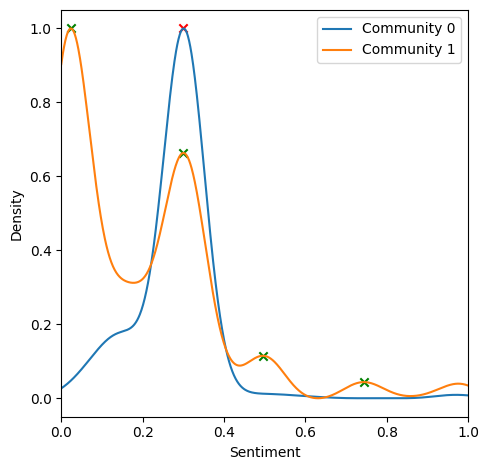

trump


<Figure size 1200x600 with 0 Axes>

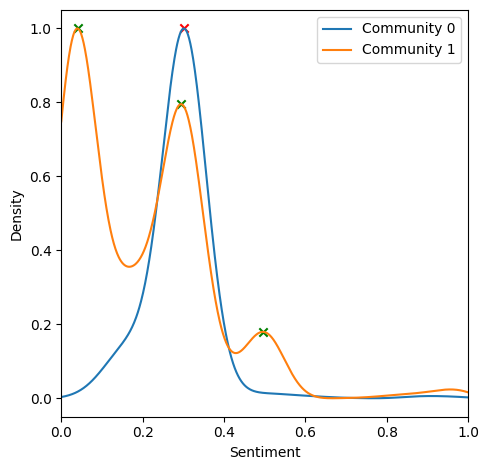

government


<Figure size 1200x600 with 0 Axes>

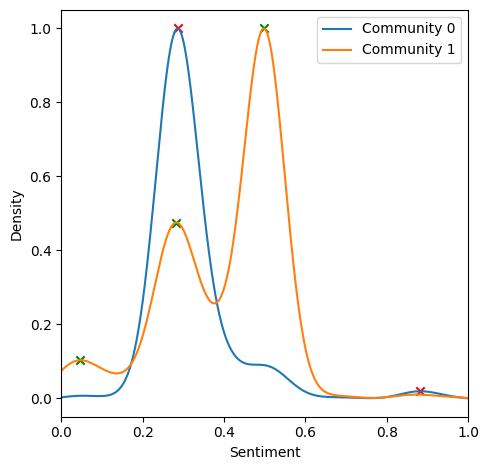

election


<Figure size 1200x600 with 0 Axes>

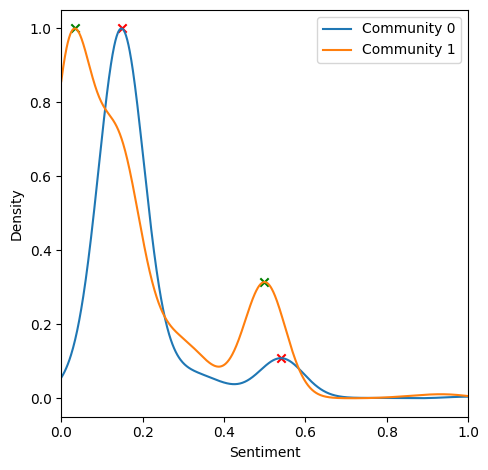

boris


<Figure size 1200x600 with 0 Axes>

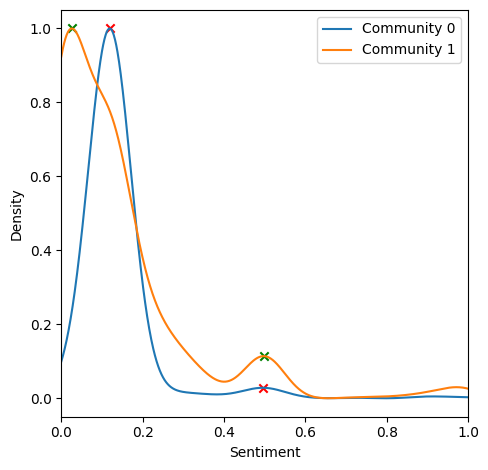

In [33]:
results = {}
#aspects = ["child", "health", "measles", "vaccination", "vaccine"]
for aspect in aspects:
    # Normalize both distributions
    x1, y1 = get_distribution_data(df_com0, aspect)
    x2, y2 = get_distribution_data(df_com1, aspect)
    
    x1_normalized, y1_normalized = normalize_distribution(x1, y1)
    x2_normalized, y2_normalized = normalize_distribution(x2, y2)

    # Calculate the mean of weighted differences between peaks of the two distributions
    print(aspect)
    mean_diff_between_distributions = mean_weighted_peak_difference_between_distributions_and_plot(
        x1_normalized, y1_normalized, x2_normalized, y2_normalized, prominence=0.01
    )
    plt.savefig(f"rot/{aspect}.png")
    plt.show()
    results[aspect] = 1 - mean_diff_between_distributions[0]

In [ ]:
results

In [ ]:
x, y = get_distribution_data(df_com1, aspect)


In [ ]:
x, y = normalize_distribution(x, y)

In [ ]:
# Plot the generated data
plt.figure(figsize=(10, 6))
plt.plot(x,y, label='Data')
plt.title('Distribution with Multiple Peaks')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()

In [ ]:
mean_diff, peak_x_coordinates, peak_y_coordinates = mean_weighted_peak_difference(x, y, prominence=0.01)
mean_diff



In [ ]:
mean_diff_all_pairs = mean_weighted_peak_difference_all_pairs(x, y, prominence=0.01)
print(1-mean_diff_all_pairs[0])

mean_diff_all_pairs



In [ ]:
# Plot the distribution with highest peaks marked
plot_distribution_with_highest_peaks(x, y, peak_x_coordinates, peak_y_coordinates)


In [ ]:
def mean_weighted_peak_difference_and_plot(x, y, prominence=0.5):
    # Normalize the x and y values
    x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))
    y_normalized = (y - np.min(y)) / (np.max(y) - np.min(y))

    # Find the highest peaks in the distribution
    peaks, _ = find_peaks(y_normalized, prominence=prominence)
    peak_x_coordinates = x_normalized[peaks]
    peak_y_values = y_normalized[peaks]

    # Calculate weighted differences between peaks
    weighted_differences = []
    for i in range(len(peak_x_coordinates)):
        for j in range(i + 1, len(peak_x_coordinates)):
            diff_x = np.abs(peak_x_coordinates[i] - peak_x_coordinates[j])
            weight = (peak_y_values[i] + peak_y_values[j]) / 2.0  # Use average y-value as weight
            weighted_diff = diff_x * weight
            weighted_differences.append(weighted_diff)

    # Calculate the mean of the weighted differences
    if weighted_differences:
        mean_weighted_diff = sum(weighted_differences) / len(weighted_differences)
    else:
        mean_weighted_diff = 0.0

    # Create a plot to display the distribution with highest peaks and differences
    plt.figure(figsize=(12, 6))
    plt.plot(x_normalized, y_normalized, label='Normalized Distribution')
    plt.scatter(peak_x_coordinates, peak_y_values, c='red', marker='x', label='Highest Peaks')

    # Annotate the differences between peaks
    for i, diff in enumerate(weighted_differences):
        plt.annotate(f'Diff={diff:.2f}', (peak_x_coordinates[i] + 0.01, peak_y_values[i]),
                     textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='blue')

    plt.title('Normalized Distribution with Highest Peaks and Differences')
    plt.xlabel('X-axis (Normalized)')
    plt.ylabel('Y-axis (Normalized)')
    plt.legend()
    plt.show()

    return mean_weighted_diff


# Calculate the mean of weighted differences between peaks and plot the distribution
mean_diff_and_plot = mean_weighted_peak_difference_and_plot(x, y, prominence=0.2)


# Average sentiment peak error for inter-community

In [ ]:
#CONFRONTARE L'OUTPUT DI QUESTA FUNZIONE (mean_weighted_diff) CON IL CONSENSO INTER COMMUNITY (COMMUNITY 0 - COMMUNITY 1)

def mean_weighted_peak_difference_between_distributions(x1, y1, x2, y2, prominence=0.5):
    # Find peaks in the first distribution
    peaks1, _ = find_peaks(y1, prominence=prominence)
    peak_x_coordinates1 = x1[peaks1]
    peak_y_values1 = y1[peaks1]

    # Find peaks in the second distribution
    peaks2, _ = find_peaks(y2, prominence=prominence)
    peak_x_coordinates2 = x2[peaks2]
    peak_y_values2 = y2[peaks2]

    # Calculate weighted differences between peaks of the two distributions
    weighted_differences = []
    for x1_peak, y1_peak in zip(peak_x_coordinates1, peak_y_values1):
        for x2_peak, y2_peak in zip(peak_x_coordinates2, peak_y_values2):
            diff_x = np.abs(x1_peak - x2_peak)
            weight = (y1_peak + y2_peak) / 2.0  # Use average y-value as weight
            weighted_diff = diff_x * weight
            weighted_differences.append(weighted_diff)

    # Calculate the mean of the weighted differences
    if weighted_differences:
        mean_weighted_diff = sum(weighted_differences) / len(weighted_differences)
    else:
        mean_weighted_diff = 0.0

    return mean_weighted_diff, peak_x_coordinates1, peak_y_values1, peak_x_coordinates2, peak_y_values2

In [ ]:
x1, y1 = get_distribution_data(df_com0, aspect)
x2, y2 = get_distribution_data(df_com1, aspect)
# Normalize both distributions
x1_normalized, y1_normalized = normalize_distribution(x1, y1)
x2_normalized, y2_normalized = normalize_distribution(x2, y2)

# Calculate the mean of weighted differences between peaks of the two distributions
mean_diff_between_distributions = mean_weighted_peak_difference_between_distributions(
    x1_normalized, y1_normalized, x2_normalized, y2_normalized, prominence=0.01
)
print(1-mean_diff_between_distributions[0])

mean_diff_between_distributions

In [22]:
def mean_weighted_peak_difference_between_distributions_and_plot(x1, y1, x2, y2, prominence=0.5):
    # Find peaks in the first distribution
    peaks1, _ = find_peaks(y1, prominence=prominence)
    peak_x_coordinates1 = x1[peaks1]
    peak_y_values1 = y1[peaks1]

    # Find peaks in the second distribution
    peaks2, _ = find_peaks(y2, prominence=prominence)
    peak_x_coordinates2 = x2[peaks2]
    peak_y_values2 = y2[peaks2]

    # Calculate weighted differences between peaks of the two distributions
    weighted_differences = []
    for x1_peak, y1_peak in zip(peak_x_coordinates1, peak_y_values1):
        for x2_peak, y2_peak in zip(peak_x_coordinates2, peak_y_values2):
            diff_x = np.abs(x1_peak - x2_peak)
            weight = (y1_peak + y2_peak) / 2.0  # Use average y-value as weight
            weighted_diff = diff_x * weight
            weighted_differences.append(weighted_diff)

    # Calculate the mean of the weighted differences
    if weighted_differences:
        mean_weighted_diff = sum(weighted_differences) / len(weighted_differences)
    else:
        mean_weighted_diff = 0.0

    # Create a plot to display both distributions with highest peaks and differences
    plt.figure(figsize=(12, 6))
    
    fig1, ax = plt.subplots()

    plt.plot(x1, y1, label='Community 0')
    plt.scatter(peak_x_coordinates1, peak_y_values1, c='red', marker='x')
    # plt.title('Distribution 1 with Highest Peaks and Differences')
    
    plt.plot(x2, y2, label='Community 1')
    plt.scatter(peak_x_coordinates2, peak_y_values2, c='green', marker='x')
    # plt.title('Distribution 2 with Highest Peaks and Differences')
    plt.xlabel('Sentiment')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    ax.set_box_aspect(1)
    plt.margins(x=0)
    #plt.show()

    return mean_weighted_diff, peak_x_coordinates1, peak_y_values1, peak_x_coordinates2, peak_y_values2

In [ ]:
# Normalize both distributions
x1_normalized, y1_normalized = normalize_distribution(x1, y1)
x2_normalized, y2_normalized = normalize_distribution(x2, y2)

# Calculate the mean of weighted differences between peaks of the two distributions
mean_diff_between_distributions = mean_weighted_peak_difference_between_distributions_and_plot(
    x1_normalized, y1_normalized, x2_normalized, y2_normalized, prominence=0.01
)
print(mean_diff_between_distributions)